# Assignment 2A — Prompting as System Design

## Block 1 — Group Introduction and Assignment Overview

**Subject:** LLM for Generative AI  
**Assignment:** Assignment 2A  
**Group Number:** 89  
**Variant:** Variant 5 — IT Helpdesk & Incident Resolution Bot  

This notebook extends Assignment 1B. It reuses the Assignment 1B fine-tuned Adapter B and instruction dataset to implement, benchmark, compose, and route prompting strategies.

No new data collection or model training is performed in Assignment 2A. The focus is on prompt engineering as system design: base prompting patterns, reasoning chains, and an intelligent prompt router.

The notebook is structured into three major parts:

- **Part A:** Base prompting patterns — Zero-shot, Few-shot, Instruction, Self-Critique, and Function-Calling.
- **Part B:** Reasoning and custom chains — Chain-of-Thought, Tree-of-Thought, Self-Consistency, ReAct, and two composed domain chains.
- **Part C:** Prompt router — classify query, route to the cheapest suitable pattern, and compare against always-zero-shot.


## Master Index

The links below use the notebook renderer's native heading identifiers. They remain usable in JupyterLab/Kubeflow and in the exported HTML.

The numbering follows one hierarchy: major sections use `N`, subsections use `N.N`, and deeper implementation or evaluation steps use `N.N.N` only when required.

**Setup, Workspace, and Benchmark Construction**

- [Assignment 2A — Prompting as System Design](#Assignment-2A-%E2%80%94-Prompting-as-System-Design)
- [Block 1 — Group Introduction and Assignment Overview](#Block-1-%E2%80%94-Group-Introduction-and-Assignment-Overview)
- [Block 2 — Workspace and Reused Assignment 1B Artifacts](#Block-2-%E2%80%94-Workspace-and-Reused-Assignment-1B-Artifacts)
- [Block 3 — Runtime and Package Readiness Check](#Block-3-%E2%80%94-Runtime-and-Package-Readiness-Check)
- [Block 4 — Assignment 1B Dataset and Ten-Query Benchmark Construction](#Block-4-%E2%80%94-Assignment-1B-Dataset-and-Ten-Query-Benchmark-Construction)
    - [4.1 Dataset and Output Path Configuration](#4.1-Dataset-and-Output-Path-Configuration)
    - [4.2 Loading the Assignment 1B Instruction Dataset](#4.2-Loading-the-Assignment-1B-Instruction-Dataset)
    - [4.3 Inspecting the Dataset Structure](#4.3-Inspecting-the-Dataset-Structure)
    - [4.4 Dataset Content Validation and Basic Statistics](#4.4-Dataset-Content-Validation-and-Basic-Statistics)
    - [4.5 Benchmark Coverage Framework and Candidate Record Identification](#4.5-Benchmark-Coverage-Framework-and-Candidate-Record-Identification)
    - [4.6 Review of High-Relevance Benchmark Candidates](#4.6-Review-of-High-Relevance-Benchmark-Candidates)
    - [4.7 Refined Candidate Review Using Contextual Phrase Matching](#4.7-Refined-Candidate-Review-Using-Contextual-Phrase-Matching)
    - [4.8 Shortlisting Operationally Actionable Source Records](#4.8-Shortlisting-Operationally-Actionable-Source-Records)
    - [4.9 Candidate Actionability Assessment](#4.9-Candidate-Actionability-Assessment)
    - [4.10 Selection of Ten Unique Benchmark Source Records](#4.10-Selection-of-Ten-Unique-Benchmark-Source-Records)
    - [4.11 Review of Selected Source Content — Benchmark Queries BQ01 to BQ05](#4.11-Review-of-Selected-Source-Content-%E2%80%94-Benchmark-Queries-BQ01-to-BQ05)
    - [4.12 Review of Selected Source Content — Benchmark Queries BQ06 to BQ10](#4.12-Review-of-Selected-Source-Content-%E2%80%94-Benchmark-Queries-BQ06-to-BQ10)
    - [4.13 Focused Validation of Benchmark Sources BQ08 to BQ10](#4.13-Focused-Validation-of-Benchmark-Sources-BQ08-to-BQ10)
    - [4.14 Focused Review of Operating-System and Recovery Records](#4.14-Focused-Review-of-Operating-System-and-Recovery-Records)
    - [4.15 Construction of the Ten-Query Benchmark Draft](#4.15-Construction-of-the-Ten-Query-Benchmark-Draft)
    - [4.16 Saving the Benchmark Query Set](#4.16-Saving-the-Benchmark-Query-Set)
    - [4.17 Validation of Saved Benchmark Artifacts](#4.17-Validation-of-Saved-Benchmark-Artifacts)
    - [4.18 Benchmark Selection Summary and Reproducibility Record](#4.18-Benchmark-Selection-Summary-and-Reproducibility-Record)

**Part A — Base Prompting Patterns**

- [Part A — Base Prompting Patterns](#Part-A-%E2%80%94-Base-Prompting-Patterns)
    - [5. Shared Model and Inference Setup](#5.-Shared-Model-and-Inference-Setup)
        - [5.1 Model, Adapter, and Experiment Configuration](#5.1-Model,-Adapter,-and-Experiment-Configuration)
        - [5.2 Verification of Adapter B Configuration](#5.2-Verification-of-Adapter-B-Configuration)
        - [5.3 Loading and Validating the Model Tokenizer](#5.3-Loading-and-Validating-the-Model-Tokenizer)
        - [5.4 Loading the Base Model with 4-Bit Quantization](#5.4-Loading-the-Base-Model-with-4-Bit-Quantization)
        - [5.5 Attaching the Assignment 1B LoRA Adapter](#5.5-Attaching-the-Assignment-1B-LoRA-Adapter)
        - [5.6 Shared Generation and Measurement Functions](#5.6-Shared-Generation-and-Measurement-Functions)
        - [5.7 GPU Warm-Up and Inference Readiness Check](#5.7-GPU-Warm-Up-and-Inference-Readiness-Check)
    - [6. Base Prompting Pattern Implementations](#6.-Base-Prompting-Pattern-Implementations)
        - [6.1 Zero-Shot Prompting Pattern](#6.1-Zero-Shot-Prompting-Pattern)
            - [6.1.1 Functional Validation of Zero-Shot Prompting](#6.1.1-Functional-Validation-of-Zero-Shot-Prompting)
            - [6.1.2 Zero-Shot Benchmark Execution on Ten Queries](#6.1.2-Zero-Shot-Benchmark-Execution-on-Ten-Queries)
        - [6.2 Few-Shot Prompting Pattern](#6.2-Few-Shot-Prompting-Pattern)
            - [6.2.1 Selection of Three Worked Examples](#6.2.1-Selection-of-Three-Worked-Examples)
            - [6.2.2 Few-Shot Prompt Construction and Function Definition](#6.2.2-Few-Shot-Prompt-Construction-and-Function-Definition)
            - [6.2.3 Functional Validation of Few-Shot Prompting](#6.2.3-Functional-Validation-of-Few-Shot-Prompting)
            - [6.2.4 Few-Shot Benchmark Execution on Ten Queries](#6.2.4-Few-Shot-Benchmark-Execution-on-Ten-Queries)
        - [6.3 Instruction Prompting Pattern](#6.3-Instruction-Prompting-Pattern)
            - [6.3.1 Instruction Template and Function Definition](#6.3.1-Instruction-Template-and-Function-Definition)
            - [6.3.2 Functional Validation of Instruction Prompting](#6.3.2-Functional-Validation-of-Instruction-Prompting)
            - [6.3.3 Refinement of Instruction-Prompt Compactness](#6.3.3-Refinement-of-Instruction-Prompt-Compactness)
            - [6.3.4 Instruction Prompting Benchmark Execution](#6.3.4-Instruction-Prompting-Benchmark-Execution)
        - [6.4 Self-Critique Prompting Pattern](#6.4-Self-Critique-Prompting-Pattern)
            - [6.4.1 Three-Stage Prompt Chain Definition](#6.4.1-Three-Stage-Prompt-Chain-Definition)
            - [6.4.2 Self-Critique Chain Implementation](#6.4.2-Self-Critique-Chain-Implementation)
            - [6.4.3 Intermediate Trace Validation on Two Benchmark Queries](#6.4.3-Intermediate-Trace-Validation-on-Two-Benchmark-Queries)
            - [6.4.4 Self-Critique Benchmark Execution on Ten Queries](#6.4.4-Self-Critique-Benchmark-Execution-on-Ten-Queries)
        - [6.5 Function-Calling and Structured JSON Output](#6.5-Function-Calling-and-Structured-JSON-Output)
            - [6.5.1 Domain Output Schema and JSON Parser](#6.5.1-Domain-Output-Schema-and-JSON-Parser)
            - [6.5.2 Structured Prompt and Retry-Capable Function](#6.5.2-Structured-Prompt-and-Retry-Capable-Function)
            - [6.5.3 Controlled JSON Parse-Failure and Recovery Demonstration](#6.5.3-Controlled-JSON-Parse-Failure-and-Recovery-Demonstration)
            - [6.5.4 Layered JSON Recovery Utilities](#6.5.4-Layered-JSON-Recovery-Utilities)
            - [6.5.5 Final Function-Calling Execution Pipeline](#6.5.5-Final-Function-Calling-Execution-Pipeline)
            - [6.5.6 Functional Validation of Structured JSON Generation](#6.5.6-Functional-Validation-of-Structured-JSON-Generation)
            - [6.5.7 Function-Calling Benchmark Execution](#6.5.7-Function-Calling-Benchmark-Execution)
            - [6.5.8 Function-Calling Failure Diagnostics](#6.5.8-Function-Calling-Failure-Diagnostics)
            - [6.5.9 Structured-Output Prompt Compression](#6.5.9-Structured-Output-Prompt-Compression)
            - [6.5.10 Validation of the Compressed Structured-Output Prompt](#6.5.10-Validation-of-the-Compressed-Structured-Output-Prompt)
            - [6.5.11 Revised Function-Calling Benchmark Execution](#6.5.11-Revised-Function-Calling-Benchmark-Execution)
            - [6.5.12 Final Generation-Limit Diagnostic](#6.5.12-Final-Generation-Limit-Diagnostic)
            - [6.5.13 Identification of the Remaining Fallback Case](#6.5.13-Identification-of-the-Remaining-Fallback-Case)
            - [6.5.14 JSON Prefix Anchoring for Structured Generation](#6.5.14-JSON-Prefix-Anchoring-for-Structured-Generation)
            - [6.5.15 Integration of JSON Prefix Anchoring](#6.5.15-Integration-of-JSON-Prefix-Anchoring)
            - [6.5.16 Final Prefix-Anchored Function-Calling Benchmark](#6.5.16-Final-Prefix-Anchored-Function-Calling-Benchmark)
            - [6.5.17 Function-Calling Configuration Selection and Restoration](#6.5.17-Function-Calling-Configuration-Selection-and-Restoration)
    - [7. Part A Accuracy Evaluation](#7.-Part-A-Accuracy-Evaluation)
        - [7.1 Benchmark-Specific Accuracy Rubrics](#7.1-Benchmark-Specific-Accuracy-Rubrics)
        - [7.2 Consolidation of Part A Responses for Accuracy Scoring](#7.2-Consolidation-of-Part-A-Responses-for-Accuracy-Scoring)
        - [7.3 Reference-Grounded Accuracy Evaluator](#7.3-Reference-Grounded-Accuracy-Evaluator)
        - [7.4 Accuracy-Evaluator Calibration](#7.4-Accuracy-Evaluator-Calibration)
        - [7.5 Manual Evidence-Based Accuracy Review](#7.5-Manual-Evidence-Based-Accuracy-Review)
            - [7.5.1 Manual Accuracy Review — BQ01](#7.5.1-Manual-Accuracy-Review-%E2%80%94-BQ01)
            - [7.5.2 Manual Accuracy Review — BQ02](#7.5.2-Manual-Accuracy-Review-%E2%80%94-BQ02)
            - [7.5.3 Manual Accuracy Review — BQ03](#7.5.3-Manual-Accuracy-Review-%E2%80%94-BQ03)
            - [7.5.4 Manual Accuracy Review — BQ04](#7.5.4-Manual-Accuracy-Review-%E2%80%94-BQ04)
            - [7.5.5 Manual Accuracy Review — BQ05](#7.5.5-Manual-Accuracy-Review-%E2%80%94-BQ05)
            - [7.5.6 Manual Accuracy Review — BQ06](#7.5.6-Manual-Accuracy-Review-%E2%80%94-BQ06)
            - [7.5.7 Manual Accuracy Review — BQ07](#7.5.7-Manual-Accuracy-Review-%E2%80%94-BQ07)
            - [7.5.8 Manual Accuracy Review — BQ08](#7.5.8-Manual-Accuracy-Review-%E2%80%94-BQ08)
            - [7.5.9 Manual Accuracy Review — BQ09](#7.5.9-Manual-Accuracy-Review-%E2%80%94-BQ09)
            - [7.5.10 Manual Accuracy Review — BQ10](#7.5.10-Manual-Accuracy-Review-%E2%80%94-BQ10)
        - [7.6 Final Accuracy Consolidation and Pattern-Level Summary](#7.6-Final-Accuracy-Consolidation-and-Pattern-Level-Summary)
        - [7.7 Part A Comparative Analysis and Cost–Quality Decision](#7.7-Part-A-Comparative-Analysis-and-Cost%E2%80%93Quality-Decision)

**Part B — Reasoning and Custom Chains**

- [8. Part B — Reasoning and Custom Chains](#8.-Part-B-%E2%80%94-Reasoning-and-Custom-Chains)
    - [8.1 Multi-Step Domain Problem Design](#8.1-Multi-Step-Domain-Problem-Design)
    - [8.2 Reasoning Runtime Compatibility Check](#8.2-Reasoning-Runtime-Compatibility-Check)
    - [8.3 Plain Baseline and Chain-of-Thought Implementation](#8.3-Plain-Baseline-and-Chain-of-Thought-Implementation)
    - [8.4 Tree-of-Thought Implementation](#8.4-Tree-of-Thought-Implementation)
        - [8.4.1 Tree-of-Thought Synthesis Integrity Correction](#8.4.1-Tree-of-Thought-Synthesis-Integrity-Correction)
    - [8.5 Self-Consistency Runtime Preparation](#8.5-Self-Consistency-Runtime-Preparation)
        - [8.5.1 Self-Consistency Implementation](#8.5.1-Self-Consistency-Implementation)
    - [8.6 Structured-Reasoning Comparison](#8.6-Structured-Reasoning-Comparison)
    - [8.7 Iterative Reasoning — ReAct](#8.7-Iterative-Reasoning-%E2%80%94-ReAct)
    - [8.8 Custom Chain 1 — Plan → Solve → Verify](#8.8-Custom-Chain-1-%E2%80%94-Plan-%E2%86%92-Solve-%E2%86%92-Verify)
    - [8.9 Custom Chain 2 — Decompose → Solve-each → Synthesise](#8.9-Custom-Chain-2-%E2%80%94-Decompose-%E2%86%92-Solve-each-%E2%86%92-Synthesise)
    - [8.10 Custom-Chain Comparison Against the Single-Pattern Baseline](#8.10-Custom-Chain-Comparison-Against-the-Single-Pattern-Baseline)

**Part C — Prompt Router**

- [9. Part C — Prompt Router: Classify, Route, and Evaluate](#9.-Part-C-%E2%80%94-Prompt-Router:-Classify,-Route,-and-Evaluate)
    - [9.1 Query Classifier and Routing Table](#9.1-Query-Classifier-and-Routing-Table)
    - [9.2 Router Dispatch and Evaluation](#9.2-Router-Dispatch-and-Evaluation)
        - [9.2.1 Router Configuration and Artifact Paths](#9.2.1-Router-Configuration-and-Artifact-Paths)
        - [9.2.2 Shared Generation and Metric Helpers](#9.2.2-Shared-Generation-and-Metric-Helpers)
        - [9.2.3 Query Classification Wrapper](#9.2.3-Query-Classification-Wrapper)
        - [9.2.4 Zero-Shot Dispatcher](#9.2.4-Zero-Shot-Dispatcher)
        - [9.2.5 Few-Shot Dispatcher](#9.2.5-Few-Shot-Dispatcher)
            - [9.2.5.1 Few-Shot Demonstration Relevance Correction](#9.2.5.1-Few-Shot-Demonstration-Relevance-Correction)
            - [9.2.5.2 Technical-Domain Relevance Gate](#9.2.5.2-Technical-Domain-Relevance-Gate)
            - [9.2.5.3 Strict Query-Side Demonstration Relevance](#9.2.5.3-Strict-Query-Side-Demonstration-Relevance)
            - [9.2.5.4 Few-Shot Dispatcher Execution](#9.2.5.4-Few-Shot-Dispatcher-Execution)
        - [9.2.6 Function-Calling Dispatcher](#9.2.6-Function-Calling-Dispatcher)
        - [9.2.7 Chain-of-Thought Dispatcher](#9.2.7-Chain-of-Thought-Dispatcher)
        - [9.2.8 Tree-of-Thought Dispatcher](#9.2.8-Tree-of-Thought-Dispatcher)
        - [9.2.9 Self-Consistency Dispatcher](#9.2.9-Self-Consistency-Dispatcher)
        - [9.2.10 ReAct Dispatcher](#9.2.10-ReAct-Dispatcher)
        - [9.2.11 Plan → Solve → Verify Dispatcher](#9.2.11-Plan-%E2%86%92-Solve-%E2%86%92-Verify-Dispatcher)
        - [9.2.12 Router Controller and Ten-Query Execution](#9.2.12-Router-Controller-and-Ten-Query-Execution)
            - [9.2.12.1 Few-Shot Production Hardening](#9.2.12.1-Few-Shot-Production-Hardening)
        - [9.2.13 Results and Observation](#9.2.13-Results-and-Observation)
        - [9.2.14 Deterministic Reference-Grounded Router Answer Quality Evaluation](#9.2.14-Deterministic-Reference-Grounded-Router-Answer-Quality-Evaluation)
    - [9.3 Part C3 — Router versus Always-Zero-Shot Comparison](#9.3-Part-C3-%E2%80%94-Router-versus-Always-Zero-Shot-Comparison)
        - [9.3.1 Baseline Retrieval and Metric Alignment](#9.3.1-Baseline-Retrieval-and-Metric-Alignment)
        - [9.3.2 Exact 100-Word Comparative Analysis](#9.3.2-Exact-100-Word-Comparative-Analysis)
        - [9.3.3 Part C Completion Summary](#9.3.3-Part-C-Completion-Summary)

**Final Validation and Submission**

- [10. Final Validation and Submission Checklist](#10.-Final-Validation-and-Submission-Checklist)
    - [10.1 End-to-End Artifact Audit](#10.1-End-to-End-Artifact-Audit)
    - [10.2 Save and Export the Corresponding HTML](#10.2-Save-and-Export-the-Corresponding-HTML)


## Block 2 — Workspace and Reused Assignment 1B Artifacts

[🔝 Back to Index](#Master-Index)

This block creates a clean Assignment 2A workspace inside the existing `llmlab` volume. It also verifies that the required Assignment 1B artifacts are available: the instruction dataset and the fine-tuned Adapter B.

The Adapter B folder is reused directly from Assignment 1B, while the instruction dataset is copied into the Assignment 2A workspace for traceability.


In [1]:
from pathlib import Path
import csv
import json
import random
import shutil
import warnings

import numpy as np

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# Shared Assignment 1B locations
# ------------------------------------------------------------

ROOT_DIR = Path("/home/jovyan/llmlab")
A1B_DATA_DIR = ROOT_DIR / "data"
A1B_INSTRUCTION_DATASET = A1B_DATA_DIR / "instruction_dataset.jsonl"
A1B_ADAPTER_DIR = ROOT_DIR / "adapters" / "qwen2_5_3b_adapter_b"

TARGET_MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
ADAPTER_DIR = A1B_ADAPTER_DIR
SOURCE_DATASET_PATH = A1B_INSTRUCTION_DATASET

# ------------------------------------------------------------
# Confirmed Assignment 2A working directory
# ------------------------------------------------------------

ASSIGNMENT2A_ROOT = Path(
    "/home/jovyan/llmlab/assignment2a_workspace_20260731_182730"
)

ASSIGNMENT2A_DIR = ASSIGNMENT2A_ROOT

DATA_DIR = ASSIGNMENT2A_ROOT / "data"
OUTPUTS_DIR = ASSIGNMENT2A_ROOT / "outputs"
REPORTS_DIR = ASSIGNMENT2A_ROOT / "reports"
BENCHMARKS_DIR = ASSIGNMENT2A_ROOT / "benchmarks"
SUBMISSION_DIR = ASSIGNMENT2A_ROOT / "submission"

for folder in [
    ASSIGNMENT2A_ROOT,
    DATA_DIR,
    OUTPUTS_DIR,
    REPORTS_DIR,
    BENCHMARKS_DIR,
    SUBMISSION_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

# Confirm that the selected workspace is writable.
write_test = (
    ASSIGNMENT2A_ROOT
    / ".assignment2a_write_test"
)

write_test.write_text(
    "Assignment 2A workspace write test",
    encoding="utf-8",
)

write_test.unlink()

# ------------------------------------------------------------
# Copy reusable Assignment 1B datasets into the workspace
# ------------------------------------------------------------

if not A1B_INSTRUCTION_DATASET.is_file():
    raise FileNotFoundError(
        "Assignment 1B instruction dataset was not found: "
        f"{A1B_INSTRUCTION_DATASET}"
    )

target_instruction_dataset = (
    DATA_DIR
    / "instruction_dataset.jsonl"
)

if (
    not target_instruction_dataset.exists()
    or target_instruction_dataset.stat().st_size
    != A1B_INSTRUCTION_DATASET.stat().st_size
):
    shutil.copy2(
        A1B_INSTRUCTION_DATASET,
        target_instruction_dataset,
    )

for filename in [
    "train_instruction_dataset.jsonl",
    "val_instruction_dataset.jsonl",
]:
    source_path = A1B_DATA_DIR / filename
    target_path = DATA_DIR / filename

    if source_path.is_file():
        if (
            not target_path.exists()
            or target_path.stat().st_size
            != source_path.stat().st_size
        ):
            shutil.copy2(
                source_path,
                target_path,
            )

# ------------------------------------------------------------
# Validate reused artifacts without pandas
# ------------------------------------------------------------

artifact_checks = [
    {
        "artifact": "Assignment 2A working directory",
        "path": str(ASSIGNMENT2A_ROOT),
        "exists": ASSIGNMENT2A_ROOT.is_dir(),
    },
    {
        "artifact": "Assignment 1B instruction_dataset.jsonl",
        "path": str(A1B_INSTRUCTION_DATASET),
        "exists": A1B_INSTRUCTION_DATASET.is_file(),
    },
    {
        "artifact": "Assignment 2A instruction_dataset.jsonl",
        "path": str(target_instruction_dataset),
        "exists": target_instruction_dataset.is_file(),
    },
    {
        "artifact": "Assignment 1B Adapter B folder",
        "path": str(ADAPTER_DIR),
        "exists": ADAPTER_DIR.is_dir(),
    },
    {
        "artifact": "Adapter config",
        "path": str(ADAPTER_DIR / "adapter_config.json"),
        "exists": (ADAPTER_DIR / "adapter_config.json").is_file(),
    },
    {
        "artifact": "Adapter weights",
        "path": str(ADAPTER_DIR / "adapter_model.safetensors"),
        "exists": (ADAPTER_DIR / "adapter_model.safetensors").is_file(),
    },
]

artifact_check_path = (
    REPORTS_DIR
    / "assignment2a_reused_artifact_check.csv"
)

with artifact_check_path.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=[
            "artifact",
            "path",
            "exists",
        ],
    )
    writer.writeheader()
    writer.writerows(
        artifact_checks
    )

print("ASSIGNMENT 2A WORKSPACE AND REUSED ARTIFACTS")
print("=" * 120)
print(f"Workspace        : {ASSIGNMENT2A_ROOT}")
print(f"Data directory   : {DATA_DIR}")
print(f"Outputs directory: {OUTPUTS_DIR}")
print(f"Reports directory: {REPORTS_DIR}")
print(f"Benchmarks       : {BENCHMARKS_DIR}")
print(f"Submission       : {SUBMISSION_DIR}")
print(f"Target model     : {TARGET_MODEL_ID}")
print(f"Adapter directory: {ADAPTER_DIR}")
print("-" * 120)
print(f"{'Artifact':<48} {'Exists':<8} Path")
print("-" * 120)

for record in artifact_checks:
    print(
        f"{record['artifact']:<48} "
        f"{str(record['exists']):<8} "
        f"{record['path']}"
    )

print("-" * 120)
print(f"Artifact report  : {artifact_check_path}")
print("=" * 120)

if not all(
    record["exists"]
    for record in artifact_checks
):
    missing_artifacts = [
        record["artifact"]
        for record in artifact_checks
        if not record["exists"]
    ]

    raise FileNotFoundError(
        "Required reused artifacts are missing: "
        + ", ".join(
            missing_artifacts
        )
    )

print(
    "The confirmed Assignment 2A working directory is writable "
    "and all required reused artifacts are available."
)


ASSIGNMENT 2A WORKSPACE AND REUSED ARTIFACTS
Workspace        : /home/jovyan/llmlab/assignment2a_workspace_20260731_182730
Data directory   : /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/data
Outputs directory: /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/outputs
Reports directory: /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/reports
Benchmarks       : /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/benchmarks
Submission       : /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/submission
Target model     : Qwen/Qwen2.5-3B-Instruct
Adapter directory: /home/jovyan/llmlab/adapters/qwen2_5_3b_adapter_b
------------------------------------------------------------------------------------------------------------------------
Artifact                                         Exists   Path
------------------------------------------------------------------------------------------------------------------------
Assignment 2A working dire

## Block 3 — Runtime and Package Readiness Check

[🔝 Back to Index](#Master-Index)

This block verifies the active Python kernel and required packages before loading the Assignment 1B Adapter B. The main packages required for Assignment 2A are `torch`, `transformers`, `peft`, `bitsandbytes`, `accelerate`, `datasets`, and `pandas`.

This check prevents model-loading failures later in the notebook.


In [2]:
import sys
import importlib

print("Active Python executable:", sys.executable)

packages = [
    "torch",
    "transformers",
    "peft",
    "bitsandbytes",
    "accelerate",
    "datasets",
    "scipy",
    "numpy"
]

for package in packages:
    try:
        module = importlib.import_module(package)
        print(f"{package:15} OK      {getattr(module, '__version__', 'installed')}")
    except Exception as exc:
        print(f"{package:15} FAILED  {type(exc).__name__}: {exc}")

import torch
print("\nCUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


Active Python executable: /opt/conda/bin/python
torch           OK      2.5.1+cu124
transformers    OK      5.14.1
peft            OK      0.20.0
bitsandbytes    OK      0.50.0
accelerate      OK      1.14.0
datasets        OK      5.0.1
scipy           OK      1.11.4
numpy           OK      1.26.4

CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


## Block 4 — Assignment 1B Dataset and Ten-Query Benchmark Construction

[🔝 Back to Index](#Master-Index)

### Objective
This block loads the existing Assignment 1B instruction dataset and creates a fixed benchmark set of **10 IT Helpdesk and Incident Resolution queries**.

The same benchmark queries will be reused across all five Part A prompting patterns to ensure a fair comparison of:

- Response quality
- Token consumption
- Latency
- Accuracy-to-token-cost ratio
- Suitability of each prompting strategy

### Benchmark Design Principles

The selected queries should collectively represent:

1. Simple factual helpdesk questions
2. Queries requiring worked examples
3. Structured incident-information extraction
4. Multi-step troubleshooting
5. Problems with multiple possible solutions
6. High-variance root-cause diagnosis
7. Tasks requiring a calculation or local tool
8. High-stakes security or production incidents
9. Multi-part incident-resolution requests
10. Ambiguous troubleshooting scenarios

The selection is deterministic and retains the original dataset line number, category, reference answer, and a SHA-256 fingerprint for reproducibility.

### Saved Artifacts

- `data/benchmark_queries.csv`
- `data/benchmark_queries.json`
- `reports/benchmark_selection_summary.json`

No new training data is collected and no model training is performed in this block.


### 4.1 Dataset and Output Path Configuration

[🔝 Back to Index](#Master-Index)

#### Purpose

This section defines the source dataset location and the directories used to store the Assignment 2A benchmark data, experiment outputs, reports, and evaluation results.

#### Rationale

Using explicit and centralised paths improves:

- Reproducibility across notebook sessions
- Consistency when saving experiment artifacts
- Traceability of generated CSV and JSON files
- Validation that the Assignment 1B dataset is available before benchmark construction begins

No dataset processing or benchmark-query selection is performed in this section.


In [3]:
from pathlib import Path


existing_assignment_root = globals().get(
    "ASSIGNMENT2A_ROOT"
)

if existing_assignment_root is None:
    raise RuntimeError(
        "ASSIGNMENT2A_ROOT is not defined. "
        "Run Block 2 before continuing."
    )

ASSIGNMENT2A_ROOT = Path(
    existing_assignment_root
)

SOURCE_DATASET_PATH = Path(
    "/home/jovyan/llmlab/data/instruction_dataset.jsonl"
)

DATA_DIR = ASSIGNMENT2A_ROOT / "data"
OUTPUTS_DIR = ASSIGNMENT2A_ROOT / "outputs"
REPORTS_DIR = ASSIGNMENT2A_ROOT / "reports"
BENCHMARKS_DIR = ASSIGNMENT2A_ROOT / "benchmarks"

for directory in [
    DATA_DIR,
    OUTPUTS_DIR,
    REPORTS_DIR,
    BENCHMARKS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

write_test_path = DATA_DIR / ".path_configuration_write_test"

write_test_path.write_text(
    "write test",
    encoding="utf-8",
)

write_test_path.unlink()

artifact_directories = {
    "Assignment 2A root": ASSIGNMENT2A_ROOT,
    "Source dataset": SOURCE_DATASET_PATH,
    "Data directory": DATA_DIR,
    "Outputs directory": OUTPUTS_DIR,
    "Reports directory": REPORTS_DIR,
    "Benchmarks directory": BENCHMARKS_DIR,
}

path_status = []

for name, path in artifact_directories.items():
    path_status.append(
        {
            "artifact": name,
            "path": str(path),
            "exists": path.exists(),
            "type": (
                "File"
                if path.is_file()
                else "Directory"
                if path.is_dir()
                else "Not found"
            ),
        }
    )

print("PATH CONFIGURATION")
print("=" * 110)
print(f"{'Artifact':<30} {'Type':<12} {'Exists':<8} Path")
print("-" * 110)

for record in path_status:
    print(
        f"{record['artifact']:<30} "
        f"{record['type']:<12} "
        f"{str(record['exists']):<8} "
        f"{record['path']}"
    )

print("=" * 110)

if not SOURCE_DATASET_PATH.is_file():
    raise FileNotFoundError(
        "Required Assignment 1B dataset was not found: "
        f"{SOURCE_DATASET_PATH}"
    )

print("Path configuration and write validation completed successfully.")


PATH CONFIGURATION
Artifact                       Type         Exists   Path
--------------------------------------------------------------------------------------------------------------
Assignment 2A root             Directory    True     /home/jovyan/llmlab/assignment2a_workspace_20260731_182730
Source dataset                 File         True     /home/jovyan/llmlab/data/instruction_dataset.jsonl
Data directory                 Directory    True     /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/data
Outputs directory              Directory    True     /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/outputs
Reports directory              Directory    True     /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/reports
Benchmarks directory           Directory    True     /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/benchmarks
Path configuration and write validation completed successfully.


In [4]:
from pathlib import Path


existing_assignment_root = globals().get(
    "ASSIGNMENT2A_ROOT"
)

if existing_assignment_root is None:
    raise RuntimeError(
        "ASSIGNMENT2A_ROOT is not defined. "
        "Run Block 2 before continuing."
    )

ASSIGNMENT2A_ROOT = Path(
    existing_assignment_root
)

SOURCE_DATASET_PATH = Path(
    "/home/jovyan/llmlab/data/instruction_dataset.jsonl"
)

DATA_DIR = ASSIGNMENT2A_ROOT / "data"
OUTPUTS_DIR = ASSIGNMENT2A_ROOT / "outputs"
REPORTS_DIR = ASSIGNMENT2A_ROOT / "reports"
BENCHMARKS_DIR = ASSIGNMENT2A_ROOT / "benchmarks"

for directory in [
    DATA_DIR,
    OUTPUTS_DIR,
    REPORTS_DIR,
    BENCHMARKS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

write_test_path = DATA_DIR / ".path_configuration_write_test"

write_test_path.write_text(
    "write test",
    encoding="utf-8",
)

write_test_path.unlink()

artifact_directories = {
    "Assignment 2A root": ASSIGNMENT2A_ROOT,
    "Source dataset": SOURCE_DATASET_PATH,
    "Data directory": DATA_DIR,
    "Outputs directory": OUTPUTS_DIR,
    "Reports directory": REPORTS_DIR,
    "Benchmarks directory": BENCHMARKS_DIR,
}

path_status = []

for name, path in artifact_directories.items():
    path_status.append(
        {
            "artifact": name,
            "path": str(path),
            "exists": path.exists(),
            "type": (
                "File"
                if path.is_file()
                else "Directory"
                if path.is_dir()
                else "Not found"
            ),
        }
    )

print("PATH CONFIGURATION")
print("=" * 110)
print(f"{'Artifact':<30} {'Type':<12} {'Exists':<8} Path")
print("-" * 110)

for record in path_status:
    print(
        f"{record['artifact']:<30} "
        f"{record['type']:<12} "
        f"{str(record['exists']):<8} "
        f"{record['path']}"
    )

print("=" * 110)

if not SOURCE_DATASET_PATH.is_file():
    raise FileNotFoundError(
        "Required Assignment 1B dataset was not found: "
        f"{SOURCE_DATASET_PATH}"
    )

print("Path configuration and write validation completed successfully.")


PATH CONFIGURATION
Artifact                       Type         Exists   Path
--------------------------------------------------------------------------------------------------------------
Assignment 2A root             Directory    True     /home/jovyan/llmlab/assignment2a_workspace_20260731_182730
Source dataset                 File         True     /home/jovyan/llmlab/data/instruction_dataset.jsonl
Data directory                 Directory    True     /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/data
Outputs directory              Directory    True     /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/outputs
Reports directory              Directory    True     /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/reports
Benchmarks directory           Directory    True     /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/benchmarks
Path configuration and write validation completed successfully.


### 4.2 Loading the Assignment 1B Instruction Dataset

[🔝 Back to Index](#Master-Index)

#### Purpose

This section loads the existing `instruction_dataset.jsonl` file created during Assignment 1B.

#### Rationale

Assignment 2A requires the benchmark queries to be selected from the previously prepared instruction dataset. Loading the dataset separately allows us to verify that:

- Each non-empty line contains valid JSON
- Every usable record is represented as a JSON object
- Malformed records are identified before benchmark selection
- The existing dataset is reused without additional data collection or training

Dataset field inspection and benchmark selection will be performed in subsequent sections.


In [5]:
import json


dataset_records = []
invalid_records = []
blank_line_count = 0

with SOURCE_DATASET_PATH.open("r", encoding="utf-8") as dataset_file:
    for line_number, raw_line in enumerate(dataset_file, start=1):

        line = raw_line.strip()

        if not line:
            blank_line_count += 1
            continue

        try:
            record = json.loads(line)

            if isinstance(record, dict):
                dataset_records.append(record)
            else:
                invalid_records.append(
                    {
                        "line_number": line_number,
                        "reason": "JSON value is not an object"
                    }
                )

        except json.JSONDecodeError as error:
            invalid_records.append(
                {
                    "line_number": line_number,
                    "reason": str(error)
                }
            )


print("DATASET LOADING SUMMARY")
print("-" * 60)
print(f"Dataset path         : {SOURCE_DATASET_PATH}")
print(f"Valid JSON records   : {len(dataset_records)}")
print(f"Invalid JSON records : {len(invalid_records)}")
print(f"Blank lines skipped  : {blank_line_count}")
print("-" * 60)

if len(dataset_records) == 0:
    raise ValueError(
        "No valid JSON records were found in the instruction dataset."
    )

print("Instruction dataset loaded successfully.")


DATASET LOADING SUMMARY
------------------------------------------------------------
Dataset path         : /home/jovyan/llmlab/data/instruction_dataset.jsonl
Valid JSON records   : 291
Invalid JSON records : 0
Blank lines skipped  : 0
------------------------------------------------------------
Instruction dataset loaded successfully.


### 4.3 Inspecting the Dataset Structure

[🔝 Back to Index](#Master-Index)

#### Purpose

This section examines the structure of the loaded instruction dataset before selecting benchmark queries.

#### Rationale

The benchmark preparation logic depends on the exact field names used for the user query, reference response, and any supporting metadata. Inspecting the dataset structure helps to:

- Identify the available fields
- Confirm that instruction and response values are present
- Detect whether all records follow a consistent schema
- Determine which fields should be retained in the benchmark dataset
- Avoid making unsupported assumptions about the JSONL format


In [6]:
from collections import Counter


# Count the occurrence of each top-level field
field_counts = Counter()

for record in dataset_records:
    field_counts.update(record.keys())


print("DATASET FIELD SUMMARY")
print("-" * 70)
print(f"{'Field':<25} {'Records Present':>18} {'Coverage':>15}")
print("-" * 70)

for field_name, record_count in field_counts.most_common():
    coverage = (record_count / len(dataset_records)) * 100

    print(
        f"{field_name:<25} "
        f"{record_count:>18} "
        f"{coverage:>14.2f}%"
    )

print("-" * 70)


# Display the first three records without modifying the source data
sample_count = min(3, len(dataset_records))

for index in range(sample_count):
    print(f"\nSAMPLE RECORD {index + 1}")
    print("-" * 70)

    sample_record = dataset_records[index]

    for field_name, field_value in sample_record.items():
        display_value = str(field_value).strip()

        if len(display_value) > 500:
            display_value = display_value[:500] + "..."

        print(f"{field_name}:")
        print(display_value)
        print()


DATASET FIELD SUMMARY
----------------------------------------------------------------------
Field                        Records Present        Coverage
----------------------------------------------------------------------
instruction                              291         100.00%
response                                 291         100.00%
----------------------------------------------------------------------

SAMPLE RECORD 1
----------------------------------------------------------------------
instruction:
Summarize the key IT helpdesk guidance from this domain corpus section.

response:
to known and assumed characteristics of the incident to determine when an incident’s recovery processes should be initiated. R2: Take the possible operational disruption of incident recovery activities into account to determine when recovery should be initiated. RS.AN (Incident Analysis) Investigations are conducted to ensure effective response and support forensics and recovery activities High 

### 4.4 Dataset Content Validation and Basic Statistics

[🔝 Back to Index](#Master-Index)

#### Purpose

This section validates the textual content of the instruction dataset and reports basic statistics for the instruction and response fields.

#### Rationale

A reliable benchmark set should contain complete, non-duplicate, and sufficiently informative instruction–response pairs. This validation identifies:

- Empty or missing instructions and responses
- Duplicate instructions
- Duplicate instruction–response pairs
- Extremely short or unusually long records
- Typical instruction and response lengths

These checks support a transparent and reproducible benchmark-selection process.


In [7]:
from collections import Counter
from statistics import mean, median


def normalize_text(text):
    """Normalize whitespace and letter case for duplicate detection."""
    return " ".join(str(text).strip().lower().split())


instruction_lengths = []
response_lengths = []

normalized_instructions = []
normalized_pairs = []

empty_instruction_count = 0
empty_response_count = 0


for record in dataset_records:
    instruction = str(record.get("instruction", "")).strip()
    response = str(record.get("response", "")).strip()

    if not instruction:
        empty_instruction_count += 1

    if not response:
        empty_response_count += 1

    instruction_lengths.append(len(instruction.split()))
    response_lengths.append(len(response.split()))

    normalized_instruction = normalize_text(instruction)
    normalized_response = normalize_text(response)

    normalized_instructions.append(normalized_instruction)
    normalized_pairs.append(
        (normalized_instruction, normalized_response)
    )


instruction_frequency = Counter(normalized_instructions)
pair_frequency = Counter(normalized_pairs)

duplicate_instruction_count = sum(
    count - 1
    for count in instruction_frequency.values()
    if count > 1
)

duplicate_pair_count = sum(
    count - 1
    for count in pair_frequency.values()
    if count > 1
)


print("DATASET CONTENT VALIDATION")
print("-" * 65)
print(f"Total records                     : {len(dataset_records)}")
print(f"Empty instructions                : {empty_instruction_count}")
print(f"Empty responses                   : {empty_response_count}")
print(f"Repeated instruction occurrences  : {duplicate_instruction_count}")
print(f"Repeated instruction-response pairs: {duplicate_pair_count}")
print("-" * 65)

print("\nTEXT LENGTH STATISTICS")
print("-" * 65)
print(
    f"{'Field':<15}"
    f"{'Minimum':>10}"
    f"{'Maximum':>10}"
    f"{'Mean':>12}"
    f"{'Median':>12}"
)
print("-" * 65)

print(
    f"{'Instruction':<15}"
    f"{min(instruction_lengths):>10}"
    f"{max(instruction_lengths):>10}"
    f"{mean(instruction_lengths):>12.2f}"
    f"{median(instruction_lengths):>12.2f}"
)

print(
    f"{'Response':<15}"
    f"{min(response_lengths):>10}"
    f"{max(response_lengths):>10}"
    f"{mean(response_lengths):>12.2f}"
    f"{median(response_lengths):>12.2f}"
)

print("-" * 65)


repeated_instructions = [
    (instruction, count)
    for instruction, count in instruction_frequency.items()
    if count > 1
]

repeated_instructions.sort(
    key=lambda item: item[1],
    reverse=True
)

print("\nMOST FREQUENT REPEATED INSTRUCTIONS")
print("-" * 65)

if repeated_instructions:
    for instruction, count in repeated_instructions[:10]:
        preview = (
            instruction[:120] + "..."
            if len(instruction) > 120
            else instruction
        )

        print(f"Count: {count}")
        print(f"Instruction: {preview}")
        print()
else:
    print("No repeated instructions were found.")


DATASET CONTENT VALIDATION
-----------------------------------------------------------------
Total records                     : 291
Empty instructions                : 0
Empty responses                   : 0
Repeated instruction occurrences  : 286
Repeated instruction-response pairs: 0
-----------------------------------------------------------------

TEXT LENGTH STATISTICS
-----------------------------------------------------------------
Field             Minimum   Maximum        Mean      Median
-----------------------------------------------------------------
Instruction            10        13       11.20       11.00
Response              174       350      349.30      350.00
-----------------------------------------------------------------

MOST FREQUENT REPEATED INSTRUCTIONS
-----------------------------------------------------------------
Count: 59
Instruction: summarize the key it helpdesk guidance from this domain corpus section.

Count: 58
Instruction: extract the important 

### 4.5 Benchmark Coverage Framework and Candidate Record Identification

[🔝 Back to Index](#Master-Index)

#### Purpose

This section defines the IT helpdesk topics that should be represented in the benchmark and identifies suitable source records from the Assignment 1B instruction dataset.

#### Rationale

The dataset contains five repeated instruction templates applied to different corpus sections. Selecting records randomly would create a benchmark with repeated and overly generic queries.

To improve benchmark relevance while continuing to use only the Assignment 1B dataset, candidate records are identified from their response content across ten operational IT-support categories.

The selected records will later be converted into specific helpdesk questions, while their original dataset responses will remain the source of the reference answers.

#### Target Benchmark Coverage

1. Authentication and VPN access
2. User accounts and permissions
3. Disk and storage management
4. Network connectivity
5. Application or service failure
6. Security incident response
7. Logging and monitoring
8. Operating-system administration
9. Backup and recovery
10. ITSM escalation and incident management


In [8]:
# Benchmark categories and indicative search terms
benchmark_categories = {
    "Authentication and VPN access": [
        "authentication",
        "vpn",
        "credential",
        "password",
        "multi-factor",
        "mfa",
        "login",
    ],
    "User accounts and permissions": [
        "user account",
        "access control",
        "permission",
        "privilege",
        "authorization",
        "identity",
        "role",
    ],
    "Disk and storage management": [
        "disk",
        "storage",
        "file system",
        "filesystem",
        "mount",
        "partition",
        "capacity",
    ],
    "Network connectivity": [
        "network",
        "connectivity",
        "dns",
        "firewall",
        "routing",
        "ip address",
        "port",
    ],
    "Application or service failure": [
        "service",
        "application",
        "process",
        "daemon",
        "failure",
        "unavailable",
        "restart",
    ],
    "Security incident response": [
        "security incident",
        "incident response",
        "malware",
        "compromise",
        "containment",
        "forensic",
        "threat",
    ],
    "Logging and monitoring": [
        "log",
        "logging",
        "monitoring",
        "alert",
        "event",
        "audit",
        "telemetry",
    ],
    "Operating-system administration": [
        "linux",
        "ubuntu",
        "red hat",
        "package",
        "kernel",
        "system administration",
        "command",
    ],
    "Backup and recovery": [
        "backup",
        "restore",
        "recovery",
        "disaster recovery",
        "snapshot",
        "recover",
        "availability",
    ],
    "ITSM escalation and incident management": [
        "incident management",
        "escalate",
        "escalation",
        "service desk",
        "helpdesk",
        "priority",
        "ticket",
        "resolution",
    ],
}


def find_keyword_matches(text, keywords):
    """Return the keywords found in the supplied text."""
    normalized_text = " ".join(str(text).lower().split())

    return [
        keyword
        for keyword in keywords
        if keyword in normalized_text
    ]


candidate_records = {}

for category, keywords in benchmark_categories.items():
    matches = []

    for record_index, record in enumerate(dataset_records, start=1):
        response = str(record.get("response", "")).strip()
        keyword_hits = find_keyword_matches(response, keywords)

        if keyword_hits:
            matches.append(
                {
                    "record_id": record_index,
                    "instruction": record["instruction"],
                    "response": response,
                    "keyword_hits": keyword_hits,
                    "match_count": len(keyword_hits),
                }
            )

    matches.sort(
        key=lambda item: (
            item["match_count"],
            len(item["response"])
        ),
        reverse=True,
    )

    candidate_records[category] = matches


print("BENCHMARK CANDIDATE SUMMARY")
print("-" * 75)

for category, matches in candidate_records.items():
    print(f"{category:<45} : {len(matches):>3} matching records")

print("-" * 75)


print("\nTOP CANDIDATE RECORDS BY CATEGORY")
print("=" * 90)

for category, matches in candidate_records.items():
    print(f"\nCATEGORY: {category}")
    print("-" * 90)

    if not matches:
        print("No matching records found.")
        continue

    for candidate in matches[:2]:
        response_preview = " ".join(
            candidate["response"].split()
        )

        if len(response_preview) > 300:
            response_preview = response_preview[:300] + "..."

        print(f"Record ID   : {candidate['record_id']}")
        print(
            "Keyword hits: "
            + ", ".join(candidate["keyword_hits"])
        )
        print(f"Response    : {response_preview}")
        print()


BENCHMARK CANDIDATE SUMMARY
---------------------------------------------------------------------------
Authentication and VPN access                 :  60 matching records
User accounts and permissions                 :  59 matching records
Disk and storage management                   : 124 matching records
Network connectivity                          : 202 matching records
Application or service failure                : 186 matching records
Security incident response                    :  51 matching records
Logging and monitoring                        : 152 matching records
Operating-system administration               : 217 matching records
Backup and recovery                           :  78 matching records
ITSM escalation and incident management       :  40 matching records
---------------------------------------------------------------------------

TOP CANDIDATE RECORDS BY CATEGORY

CATEGORY: Authentication and VPN access
------------------------------------------------------

### 4.6 Review of High-Relevance Benchmark Candidates

[🔝 Back to Index](#Master-Index)

#### Purpose

This section reviews the strongest candidate records identified for each benchmark category.

#### Rationale

The initial keyword search produced many matches because several IT-support terms occur frequently across the domain corpus. A compact candidate review is therefore required before final selection.

For each benchmark category, this section displays:

- The source record identifier
- The number of matched category keywords
- The specific matched keywords
- A concise response preview

The review will be used to determine whether each candidate contains sufficient operational detail to support a meaningful benchmark question and grounded reference answer.


In [9]:
print("HIGH-RELEVANCE BENCHMARK CANDIDATES")
print("=" * 110)

for category, matches in candidate_records.items():
    print(f"\n{category}")
    print("-" * 110)

    if not matches:
        print("No matching records found.")
        continue

    # Display only the three strongest candidates
    for rank, candidate in enumerate(matches[:3], start=1):
        response_preview = " ".join(
            candidate["response"].split()
        )

        if len(response_preview) > 220:
            response_preview = response_preview[:220] + "..."

        print(
            f"Rank {rank} | "
            f"Record ID: {candidate['record_id']} | "
            f"Match count: {candidate['match_count']}"
        )

        print(
            "Matched terms: "
            + ", ".join(candidate["keyword_hits"])
        )

        print(f"Preview: {response_preview}")
        print()


HIGH-RELEVANCE BENCHMARK CANDIDATES

Authentication and VPN access
--------------------------------------------------------------------------------------------------------------
Rank 1 | Record ID: 59 | Match count: 3
Matched terms: credential, password, login
Preview: you added it): //servername/sharename /media/windowsshare cifs credentials=/home/ubuntuusername/. smbcredentials 0 0 Save the file and exit the editor. Finally, test mounting the share by running: sudo mount /media/windo...

Rank 2 | Record ID: 71 | Match count: 3
Matched terms: authentication, password, login
Preview: No available devices │ │ [ Create software RAID (md) > ] │ [ Create volume group (LVM) > ] │ USED DEVICES v [ Done ] [ Reset ] [ Back ] ==================================================================== Storage configu...

Rank 3 | Record ID: 89 | Match count: 3
Matched terms: authentication, password, multi-factor
Preview: is a network protocol used to map an IP address to a physical machine (MAC ad- dr

### 4.7 Refined Candidate Review Using Contextual Phrase Matching

[🔝 Back to Index](#Master-Index)

#### Purpose

This section applies stricter category-specific search criteria to identify benchmark records with clearer operational relevance.

#### Rationale

The initial keyword search returned many weak matches because common terms such as `service`, `network`, `password`, and `incident` occur across different technical topics.

The refined search therefore:

- Prioritises issue-specific phrases such as `account locked`, `connection refused`, and `systemctl status`
- Separates primary diagnostic phrases from supporting technical terms
- Displays the response text surrounding the matched phrase
- Reduces false matches caused by isolated or incidental terminology

This section reviews the first five benchmark categories. The remaining categories will be reviewed separately to keep the output concise.


In [10]:
# Refined rules for the first five benchmark categories
refined_category_rules = {
    "Authentication and VPN access": {
        "primary_terms": [
            "vpn",
            "anyconnect",
            "authentication failure",
            "multi-factor authentication",
            "mfa",
            "login failure",
            "password reset",
            "account locked",
        ],
        "supporting_terms": [
            "credential",
            "certificate",
            "radius",
            "active directory",
            "token",
            "authentication",
        ],
    },

    "User accounts and permissions": {
        "primary_terms": [
            "account locked",
            "permission denied",
            "access denied",
            "active directory",
            "sudoers",
            "user account",
            "role-based access",
            "rbac",
        ],
        "supporting_terms": [
            "permission",
            "privilege",
            "authorization",
            "identity",
            "group membership",
            "unlock",
        ],
    },

    "Disk and storage management": {
        "primary_terms": [
            "disk usage",
            "filesystem full",
            "file system full",
            "no space left",
            "df -h",
            "du -sh",
            "mount failed",
            "cannot mount",
            "partition",
        ],
        "supporting_terms": [
            "storage",
            "disk",
            "filesystem",
            "mount",
            "capacity",
            "inode",
            "lvm",
            "swap",
        ],
    },

    "Network connectivity": {
        "primary_terms": [
            "connection refused",
            "cannot connect",
            "unreachable",
            "dns resolution",
            "ssh",
            "firewall",
            "iptables",
            "nftables",
            "network interface",
        ],
        "supporting_terms": [
            "network",
            "port",
            "ip address",
            "routing",
            "dns",
            "packet",
            "gateway",
        ],
    },

    "Application or service failure": {
        "primary_terms": [
            "systemctl status",
            "service failed",
            "failed to start",
            "daemon",
            "application unavailable",
            "service unavailable",
            "restart service",
            "unit file",
        ],
        "supporting_terms": [
            "service",
            "process",
            "restart",
            "systemd",
            "journalctl",
            "error",
        ],
    },
}


def extract_match_context(text, matched_terms, context_size=180):
    """Return a compact text window surrounding the earliest matched term."""
    normalized_text = " ".join(str(text).split())
    lower_text = normalized_text.lower()

    match_positions = []

    for term in matched_terms:
        position = lower_text.find(term.lower())

        if position >= 0:
            match_positions.append((position, term))

    if not match_positions:
        return normalized_text[: context_size * 2]

    first_position, _ = min(match_positions, key=lambda item: item[0])

    start = max(0, first_position - context_size)
    end = min(
        len(normalized_text),
        first_position + context_size
    )

    context = normalized_text[start:end]

    if start > 0:
        context = "..." + context

    if end < len(normalized_text):
        context = context + "..."

    return context


refined_candidates = {}

for category, rules in refined_category_rules.items():
    category_matches = []

    for record_id, record in enumerate(dataset_records, start=1):
        response = str(record["response"]).strip()
        response_lower = response.lower()

        primary_hits = [
            term
            for term in rules["primary_terms"]
            if term in response_lower
        ]

        supporting_hits = [
            term
            for term in rules["supporting_terms"]
            if term in response_lower
        ]

        # At least one strong category-specific phrase is required
        if not primary_hits:
            continue

        relevance_score = (
            len(primary_hits) * 5
            + len(supporting_hits)
        )

        all_hits = primary_hits + supporting_hits

        category_matches.append(
            {
                "record_id": record_id,
                "instruction": record["instruction"],
                "response": response,
                "primary_hits": primary_hits,
                "supporting_hits": supporting_hits,
                "relevance_score": relevance_score,
                "context": extract_match_context(
                    response,
                    all_hits,
                ),
            }
        )

    category_matches.sort(
        key=lambda item: (
            item["relevance_score"],
            len(item["primary_hits"]),
            len(item["response"]),
        ),
        reverse=True,
    )

    refined_candidates[category] = category_matches


print("REFINED CANDIDATE REVIEW — CATEGORIES 1 TO 5")
print("=" * 100)

for category, matches in refined_candidates.items():
    print(f"\nCATEGORY: {category}")
    print("-" * 100)
    print(f"Qualified records: {len(matches)}")

    if not matches:
        print("No records satisfied the refined criteria.")
        continue

    for rank, candidate in enumerate(matches[:3], start=1):
        print(
            f"\nRank {rank} | "
            f"Record ID: {candidate['record_id']} | "
            f"Relevance score: {candidate['relevance_score']}"
        )

        print(
            "Primary matches   : "
            + ", ".join(candidate["primary_hits"])
        )

        supporting_text = (
            ", ".join(candidate["supporting_hits"])
            if candidate["supporting_hits"]
            else "None"
        )

        print(f"Supporting matches: {supporting_text}")
        print(f"Matched context    : {candidate['context']}")


REFINED CANDIDATE REVIEW — CATEGORIES 1 TO 5

CATEGORY: Authentication and VPN access
----------------------------------------------------------------------------------------------------
Qualified records: 11

Rank 1 | Record ID: 14 | Relevance score: 8
Primary matches   : vpn
Supporting matches: certificate, active directory, authentication
Matched context    : ...: Open vSwitch with DPDK (page 305) • About DPDK (page 882) • Sharing: Files with NFS (page 331) • Printers with CUPS (page 383) • With Windows systems: Samba (page 339) • Windows Active Directory (page 373) 1.3. Security Protect your system with access controls, firewalls, encrypted communications, and network authentication. For more general information ab...

Rank 2 | Record ID: 124 | Relevance score: 6
Primary matches   : vpn
Supporting matches: certificate
Matched context    : ...manpages.ubuntu.com/manpages/resolute/man8/wg.8.html 881 https://manpages.ubuntu.com/manpages/resolute/man8/wg-quick.8.html 882 https://www.wi

### 4.8 Shortlisting Operationally Actionable Source Records

[🔝 Back to Index](#Master-Index)

#### Purpose

This section identifies a compact set of source records containing concrete technical procedures, diagnostic commands, configuration guidance, or incident-response actions.

#### Rationale

The earlier category-based searches returned several broad conceptual matches. Benchmark questions should instead be grounded in records that contain sufficient operational detail to support an assessable reference answer.

The search therefore prioritises specific technical evidence such as:

- Administrative commands
- Configuration files and utilities
- Diagnostic procedures
- Security-response activities
- Recovery and escalation actions

Only the strongest candidate for each topic is displayed to keep the review concise.


In [11]:
operational_topic_rules = {
    "Authentication and secure remote access": [
        "openvpn",
        "wireguard",
        "authentication failure",
        "multi-factor authentication",
        "certificate authentication",
    ],

    "User access and privilege management": [
        "sudoers",
        "permission denied",
        "user account",
        "active directory",
        "access control",
    ],

    "Disk and filesystem troubleshooting": [
        "df -h",
        "du -sh",
        "no space left",
        "filesystem",
        "logical volume",
    ],

    "Network and firewall troubleshooting": [
        "iptables",
        "nftables",
        "dns client configuration",
        "network interface",
        "connection refused",
    ],

    "Service and process troubleshooting": [
        "systemctl status",
        "journalctl",
        "failed to start",
        "unit file",
        "systemd",
    ],

    "Security incident response": [
        "incident response",
        "containment",
        "forensics",
        "eradication",
        "security incident",
    ],

    "Logging and monitoring": [
        "/var/log",
        "audit log",
        "logging",
        "monitoring",
        "alert",
    ],

    "Operating-system administration": [
        "apt install",
        "dnf install",
        "package manager",
        "kernel",
        "system administration",
    ],

    "Backup and recovery": [
        "backup",
        "restore",
        "snapshot",
        "disaster recovery",
        "recovery process",
    ],

    "Incident management and escalation": [
        "incident management",
        "escalation",
        "service desk",
        "incident priority",
        "resolution process",
    ],
}


def get_context_around_first_match(text, matched_terms, window=220):
    cleaned_text = " ".join(str(text).split())
    lowered_text = cleaned_text.lower()

    positions = [
        lowered_text.find(term.lower())
        for term in matched_terms
        if lowered_text.find(term.lower()) >= 0
    ]

    if not positions:
        return cleaned_text[: window * 2]

    first_position = min(positions)

    start = max(0, first_position - window)
    end = min(len(cleaned_text), first_position + window)

    context = cleaned_text[start:end]

    if start > 0:
        context = "..." + context

    if end < len(cleaned_text):
        context = context + "..."

    return context


operational_shortlist = {}

for topic, search_terms in operational_topic_rules.items():
    topic_candidates = []

    for record_id, record in enumerate(dataset_records, start=1):
        response = str(record["response"]).strip()
        response_lower = response.lower()

        matched_terms = [
            term
            for term in search_terms
            if term.lower() in response_lower
        ]

        if not matched_terms:
            continue

        # Exact operational phrases receive equal weight.
        # Multiple matches indicate stronger topic coverage.
        score = len(matched_terms)

        topic_candidates.append(
            {
                "record_id": record_id,
                "matched_terms": matched_terms,
                "score": score,
                "response": response,
            }
        )

    topic_candidates.sort(
        key=lambda item: (
            item["score"],
            len(item["response"]),
        ),
        reverse=True,
    )

    operational_shortlist[topic] = topic_candidates


print("OPERATIONAL SOURCE-RECORD SHORTLIST")
print("=" * 105)

for topic, candidates in operational_shortlist.items():
    print(f"\nTOPIC: {topic}")
    print("-" * 105)

    if not candidates:
        print("No sufficiently specific record was identified.")
        continue

    best_candidate = candidates[0]

    print(f"Record ID     : {best_candidate['record_id']}")
    print(f"Evidence score: {best_candidate['score']}")
    print(
        "Matched terms : "
        + ", ".join(best_candidate["matched_terms"])
    )

    context = get_context_around_first_match(
        best_candidate["response"],
        best_candidate["matched_terms"],
    )

    print(f"Relevant text : {context}")


OPERATIONAL SOURCE-RECORD SHORTLIST

TOPIC: Authentication and secure remote access
---------------------------------------------------------------------------------------------------------
Record ID     : 124
Evidence score: 2
Matched terms : openvpn, wireguard
Relevant text : 878 https://www.wireguard.com 879 https://www.wireguard.com/quickstart/ 880 https://manpages.ubuntu.com/manpages/resolute/man8/wg.8.html 881 https://manpages.ubuntu.com/manpages/resolute/man8/wg-quick.8.html 882 https://www.wireguard.co...

TOPIC: User access and privilege management
---------------------------------------------------------------------------------------------------------
Record ID     : 221
Evidence score: 3
Matched terms : sudoers, permission denied, access control
Relevant text : list of allowed services in all PAM-based access control rules. Otherwise, users will receive a "permission denied" error message when they try to access sudo but access is forbidden based on current access control ru

### 4.9 Candidate Actionability Assessment

[🔝 Back to Index](#Master-Index)

#### Purpose

This section evaluates the shortlisted source records for their suitability as benchmark reference answers.

#### Rationale

A record may contain the correct topic terminology without providing a complete helpdesk resolution procedure. Benchmark records should preferably include observable operational evidence such as:

- Diagnostic or administrative commands
- Verification and troubleshooting actions
- Configuration steps
- Recovery or escalation guidance
- Explicit warnings or decision points

A combined score is calculated using topic relevance and actionability indicators. The two strongest records per topic are displayed for final review.


In [12]:
actionability_terms = [
    "check",
    "verify",
    "run",
    "use",
    "configure",
    "enable",
    "disable",
    "restart",
    "install",
    "remove",
    "review",
    "monitor",
    "escalate",
    "recover",
    "restore",
    "investigate",
    "identify",
    "ensure",
    "command",
    "procedure",
    "warning",
]

command_indicators = [
    "sudo ",
    "systemctl ",
    "journalctl ",
    "df ",
    "du ",
    "ip ",
    "iptables",
    "nft ",
    "mount ",
    "umount ",
    "apt ",
    "dnf ",
    "yum ",
    "grep ",
    "cat ",
    "chmod ",
    "chown ",
]


def assess_actionability(response):
    """Measure whether a response contains operational guidance."""
    response_lower = response.lower()

    action_hits = [
        term
        for term in actionability_terms
        if term in response_lower
    ]

    command_hits = [
        term.strip()
        for term in command_indicators
        if term in response_lower
    ]

    numbered_steps = sum(
        marker in response_lower
        for marker in ["1.", "2.", "3.", "4.", "step 1", "step 2"]
    )

    actionability_score = (
        len(action_hits)
        + (2 * len(command_hits))
        + numbered_steps
    )

    return actionability_score, action_hits, command_hits


ranked_operational_candidates = {}

for topic, candidates in operational_shortlist.items():
    assessed_candidates = []

    for candidate in candidates:
        (
            actionability_score,
            action_hits,
            command_hits,
        ) = assess_actionability(candidate["response"])

        combined_score = (
            candidate["score"] * 5
            + actionability_score
        )

        assessed_candidates.append(
            {
                **candidate,
                "actionability_score": actionability_score,
                "combined_score": combined_score,
                "action_hits": action_hits,
                "command_hits": command_hits,
            }
        )

    assessed_candidates.sort(
        key=lambda item: (
            item["combined_score"],
            item["actionability_score"],
            item["score"],
        ),
        reverse=True,
    )

    ranked_operational_candidates[topic] = assessed_candidates


print("CANDIDATE ACTIONABILITY ASSESSMENT")
print("=" * 105)

for topic, candidates in ranked_operational_candidates.items():
    print(f"\nTOPIC: {topic}")
    print("-" * 105)

    if not candidates:
        print("No suitable candidate records were found.")
        continue

    for rank, candidate in enumerate(candidates[:2], start=1):
        context = get_context_around_first_match(
            candidate["response"],
            candidate["matched_terms"],
            window=110,
        )

        print(
            f"Rank {rank} | "
            f"Record ID: {candidate['record_id']} | "
            f"Topic score: {candidate['score']} | "
            f"Actionability: {candidate['actionability_score']} | "
            f"Combined: {candidate['combined_score']}"
        )

        print(
            "Matched terms: "
            + ", ".join(candidate["matched_terms"])
        )

        command_text = (
            ", ".join(candidate["command_hits"][:5])
            if candidate["command_hits"]
            else "No explicit command detected"
        )

        print(f"Command evidence: {command_text}")
        print(f"Context: {context}")
        print()


CANDIDATE ACTIONABILITY ASSESSMENT

TOPIC: Authentication and secure remote access
---------------------------------------------------------------------------------------------------------
Rank 1 | Record ID: 257 | Topic score: 1 | Actionability: 16 | Combined: 21
Matched terms: wireguard
Command evidence: sudo, systemctl, ip
Context: ... For PostUp (and PostDown – see the wg-quick(8)188 manual page for details), the %i text is replaced with the WireGuard interface name. In this case, that would be home0. These two resolvectl commands tell the local syst...

Rank 2 | Record ID: 14 | Topic score: 2 | Actionability: 9 | Combined: 19
Matched terms: openvpn, wireguard
Command evidence: No explicit command detected
Context: ...Cryptography: Cryptographic libraries (page 814) • About certificates (page 854) • OpenSSL (page 819) • VPNs: OpenVPN (page 242) • WireGuard VPN (page 259) 1 https://documentation.ubuntu.com/security/ 3 of 1046 1.4. Mana...


TOPIC: User access and privilege managemen

### 4.10 Selection of Ten Unique Benchmark Source Records

[🔝 Back to Index](#Master-Index)

#### Purpose

This section selects one source record for each benchmark topic from the actionability-ranked candidate lists.

#### Rationale

The same dataset record may appear as a strong candidate for more than one topic. To maintain benchmark diversity, each selected benchmark entry must use a different source record.

The selection procedure therefore:

- Processes the ten benchmark topics in a fixed order
- Selects the highest-ranked candidate not already assigned
- Preserves the source record identifier
- Retains the original instruction and response
- Records the topic-relevance and actionability scores
- Produces exactly ten unique source records


In [13]:
selected_benchmark_sources = []
used_record_ids = set()


for benchmark_number, (
    topic,
    candidates,
) in enumerate(
    ranked_operational_candidates.items(),
    start=1,
):
    selected_candidate = None

    for candidate in candidates:
        if candidate["record_id"] not in used_record_ids:
            selected_candidate = candidate
            break

    if selected_candidate is None:
        raise ValueError(
            f"No unused candidate was available for topic: {topic}"
        )

    used_record_ids.add(selected_candidate["record_id"])

    source_record = dataset_records[
        selected_candidate["record_id"] - 1
    ]

    selected_benchmark_sources.append(
        {
            "benchmark_id": f"BQ{benchmark_number:02d}",
            "topic": topic,
            "source_record_id": selected_candidate["record_id"],
            "original_instruction": source_record["instruction"],
            "reference_response": source_record["response"],
            "topic_score": selected_candidate["score"],
            "actionability_score": (
                selected_candidate["actionability_score"]
            ),
            "combined_score": selected_candidate["combined_score"],
            "matched_terms": selected_candidate["matched_terms"],
        }
    )


if len(selected_benchmark_sources) != 10:
    raise AssertionError(
        "Exactly ten benchmark source records are required."
    )

if len(used_record_ids) != 10:
    raise AssertionError(
        "The selected benchmark source records are not unique."
    )


print("SELECTED BENCHMARK SOURCE RECORDS")
print("=" * 105)

for item in selected_benchmark_sources:
    print(
        f"{item['benchmark_id']} | "
        f"Record ID: {item['source_record_id']:>3} | "
        f"Actionability: {item['actionability_score']:>2} | "
        f"Combined: {item['combined_score']:>2}"
    )

    print(f"Topic: {item['topic']}")
    print(
        "Matched terms: "
        + ", ".join(item["matched_terms"])
    )
    print("-" * 105)


print(
    f"\nSelection completed: "
    f"{len(selected_benchmark_sources)} unique source records."
)


SELECTED BENCHMARK SOURCE RECORDS
BQ01 | Record ID: 257 | Actionability: 16 | Combined: 21
Topic: Authentication and secure remote access
Matched terms: wireguard
---------------------------------------------------------------------------------------------------------
BQ02 | Record ID: 282 | Actionability: 15 | Combined: 25
Topic: User access and privilege management
Matched terms: user account, access control
---------------------------------------------------------------------------------------------------------
BQ03 | Record ID:  80 | Actionability: 18 | Combined: 23
Topic: Disk and filesystem troubleshooting
Matched terms: logical volume
---------------------------------------------------------------------------------------------------------
BQ04 | Record ID: 245 | Actionability:  9 | Combined: 19
Topic: Network and firewall troubleshooting
Matched terms: iptables, network interface
----------------------------------------------------------------------------------------------------

### 4.11 Review of Selected Source Content — Benchmark Queries BQ01 to BQ05

[🔝 Back to Index](#Master-Index)

#### Purpose

This section reviews the selected source content for the first five benchmark topics before converting the records into specific benchmark questions.

#### Rationale

The original dataset instructions are generic and repeated across many records. The benchmark questions must therefore be derived from the technical content of each selected response.

Reviewing the source text ensures that each final question:

- Is answerable using the selected reference response
- Represents the assigned IT helpdesk topic accurately
- Does not introduce facts outside the Assignment 1B dataset
- Contains sufficient operational detail for objective scoring
- Remains distinct from the other benchmark questions


In [14]:
print("SELECTED SOURCE CONTENT REVIEW — BQ01 TO BQ05")
print("=" * 100)

for item in selected_benchmark_sources[:5]:
    response_text = " ".join(
        item["reference_response"].split()
    )

    matched_terms = item["matched_terms"]

    context = get_context_around_first_match(
        response_text,
        matched_terms,
        window=450,
    )

    print(f"\n{item['benchmark_id']} — {item['topic']}")
    print("-" * 100)
    print(f"Source record ID : {item['source_record_id']}")
    print(
        "Matched terms    : "
        + ", ".join(matched_terms)
    )
    print(f"Source context   :\n{context}")


SELECTED SOURCE CONTENT REVIEW — BQ01 TO BQ05

BQ01 — Authentication and secure remote access
----------------------------------------------------------------------------------------------------
Source record ID : 257
Matched terms    : wireguard
Source context   :
this PostUp command to the home0.conf configuration file to have our systemd- based resolver use 10.10.10.1 as the DNS server for any queries for the .home domain: [Interface] ... PostUp = resolvectl dns %i 10.10.10.1; resolvectl domain %i \~home 271 of 1046 For PostUp (and PostDown – see the wg-quick(8)188 manual page for details), the %i text is replaced with the WireGuard interface name. In this case, that would be home0. These two resolvectl commands tell the local systemd-resolved resolver to: • associate the DNS server at 10.10.10.1 to the home0 interface, and • associate the home domain to the home0 interface. When you bring the home0 WireGuard interface up again, it will run the resolvectl commands: sudo wg-quick up 

### 4.12 Review of Selected Source Content — Benchmark Queries BQ06 to BQ10

[🔝 Back to Index](#Master-Index)

#### Purpose

This section reviews the selected source content for the remaining five benchmark topics.

#### Rationale

The review verifies that each selected record contains enough grounded information to support a specific and objectively assessable helpdesk question.

Particular attention is given to:

- Incident-response actions
- Log investigation procedures
- Operating-system administration steps
- Backup and recovery guidance
- Escalation and incident-management decisions

Records that contain only general discussion, rather than actionable guidance, will be replaced before the final benchmark set is created.


In [15]:
print("SELECTED SOURCE CONTENT REVIEW — BQ06 TO BQ10")
print("=" * 100)

for item in selected_benchmark_sources[5:]:
    response_text = " ".join(
        item["reference_response"].split()
    )

    context = get_context_around_first_match(
        response_text,
        item["matched_terms"],
        window=450,
    )

    print(f"\n{item['benchmark_id']} — {item['topic']}")
    print("-" * 100)
    print(f"Source record ID : {item['source_record_id']}")
    print(
        "Matched terms    : "
        + ", ".join(item["matched_terms"])
    )
    print(f"Source context   :\n{context}")


SELECTED SOURCE CONTENT REVIEW — BQ06 TO BQ10

BQ06 — Security incident response
----------------------------------------------------------------------------------------------------
Source record ID : 234
Matched terms    : incident response, containment, eradication, security incident
Source context   :
refers to mitigating an incident’s effects. After containment, eradication may be necessary to eliminate persistence mechanisms and entry points, such as deleting malware, disabling breached user accounts, and identifying and mitigating all exploited vulnerabilities. R1: Identify all affected hosts and services within the organization so that all flaws and weaknesses can be remediated. C1: Consider configuring cybersecurity technologies and the cybersecurity features of other technologies (e.g.,...

BQ07 — Logging and monitoring
----------------------------------------------------------------------------------------------------
Source record ID : 278
Matched terms    : /var/log
Source 

### 4.13 Focused Validation of Benchmark Sources BQ08 to BQ10

[🔝 Back to Index](#Master-Index)

#### Purpose

This section performs a concise validation of the final three selected source records by extracting their most operationally relevant statements.

#### Rationale

Long corpus responses may contain background information, navigation text, and page references alongside the useful technical guidance. Extracting high-value sentences helps determine whether each record can support a specific benchmark question.

Additional alternatives are reviewed for the incident-management and escalation topic because its initially selected source record received a lower actionability score than the other benchmark records.


In [16]:
import re


def split_into_sentences(text):
    """Split corpus text into readable sentence-like segments."""
    cleaned_text = " ".join(str(text).split())

    segments = re.split(
        r"(?<=[.!?])\s+|(?=\b(?:Step|Procedure)\s+\d+\b)",
        cleaned_text,
    )

    return [
        segment.strip()
        for segment in segments
        if len(segment.strip()) >= 40
    ]


def sentence_operational_score(sentence, topic_terms):
    """Score a sentence using topic and operational evidence."""
    sentence_lower = sentence.lower()

    topic_hits = sum(
        term.lower() in sentence_lower
        for term in topic_terms
    )

    action_hits = sum(
        term in sentence_lower
        for term in actionability_terms
    )

    command_hits = sum(
        term in sentence_lower
        for term in command_indicators
    )

    return (
        topic_hits * 5
        + action_hits
        + command_hits * 2
    )


print("FOCUSED SOURCE VALIDATION — BQ08 TO BQ10")
print("=" * 100)

for item in selected_benchmark_sources[7:]:
    sentences = split_into_sentences(
        item["reference_response"]
    )

    ranked_sentences = sorted(
        sentences,
        key=lambda sentence: sentence_operational_score(
            sentence,
            item["matched_terms"],
        ),
        reverse=True,
    )

    print(f"\n{item['benchmark_id']} — {item['topic']}")
    print("-" * 100)
    print(f"Source record ID: {item['source_record_id']}")

    for rank, sentence in enumerate(
        ranked_sentences[:4],
        start=1,
    ):
        score = sentence_operational_score(
            sentence,
            item["matched_terms"],
        )

        preview = (
            sentence[:350] + "..."
            if len(sentence) > 350
            else sentence
        )

        print(f"{rank}. Evidence score: {score}")
        print(f"   {preview}")


print("\nBQ10 ALTERNATIVE SOURCE CANDIDATES")
print("=" * 100)

bq10_topic = "Incident management and escalation"
bq10_candidates = ranked_operational_candidates[bq10_topic]

for rank, candidate in enumerate(
    bq10_candidates[:5],
    start=1,
):
    sentences = split_into_sentences(
        candidate["response"]
    )

    best_sentence = max(
        sentences,
        key=lambda sentence: sentence_operational_score(
            sentence,
            candidate["matched_terms"],
        ),
    )

    preview = (
        best_sentence[:300] + "..."
        if len(best_sentence) > 300
        else best_sentence
    )

    print(
        f"\nRank {rank} | "
        f"Record ID: {candidate['record_id']} | "
        f"Actionability: {candidate['actionability_score']} | "
        f"Combined: {candidate['combined_score']}"
    )

    print(
        "Matched terms: "
        + ", ".join(candidate["matched_terms"])
    )

    print(f"Best evidence: {preview}")


FOCUSED SOURCE VALIDATION — BQ08 TO BQ10

BQ08 — Operating-system administration
----------------------------------------------------------------------------------------------------
Source record ID: 98
1. Evidence score: 11
   The simplest yet least reliable way to allocate some huge pages is to just echo a value to sysfs: echo 256 | sudo tee /sys/kernel/mm/hugepages/hugepages-2048kB/nr_hugepages Be sure to re-check if it worked: $ cat /sys/kernel/mm/hugepages/hugepages-2048kB/nr_hugepages 256 One of these sizes is the “default huge page size”, which is used in the auto-...
2. Evidence score: 10
   Query an overview with hugeadm638: $ apt install libhugetlbfs-bin $ hugeadm --list-all-mounts Mount Point Options /dev/hugepages rw,relatime,pagesize=2M A one-stop info for the overall huge page status of the system can be reported with: hugeadm --explain Huge page usage in libvirt With the above in place, libvirt can map guest memory to huge pages...
3. Evidence score: 8
   You can check t

### 4.14 Focused Review of Operating-System and Recovery Records

[🔝 Back to Index](#Master-Index)

#### Purpose

This section extracts only the highest-value operational evidence from benchmark sources BQ08 and BQ09.

#### Rationale

The final benchmark questions must be narrowly aligned with the source responses. A concise review of these two records prevents the questions from introducing unsupported technical assumptions and ensures that their reference answers remain fully grounded in the Assignment 1B dataset.


In [17]:
print("FOCUSED REVIEW — BQ08 AND BQ09")
print("=" * 100)

for item in selected_benchmark_sources[7:9]:
    sentences = split_into_sentences(
        item["reference_response"]
    )

    ranked_sentences = sorted(
        sentences,
        key=lambda sentence: sentence_operational_score(
            sentence,
            item["matched_terms"],
        ),
        reverse=True,
    )

    print(f"\n{item['benchmark_id']} — {item['topic']}")
    print("-" * 100)
    print(f"Source record ID: {item['source_record_id']}")

    for rank, sentence in enumerate(ranked_sentences[:3], start=1):
        score = sentence_operational_score(
            sentence,
            item["matched_terms"],
        )

        concise_sentence = " ".join(sentence.split())

        if len(concise_sentence) > 500:
            concise_sentence = concise_sentence[:500] + "..."

        print(f"{rank}. Evidence score: {score}")
        print(f"   {concise_sentence}")


FOCUSED REVIEW — BQ08 AND BQ09

BQ08 — Operating-system administration
----------------------------------------------------------------------------------------------------
Source record ID: 98
1. Evidence score: 11
   The simplest yet least reliable way to allocate some huge pages is to just echo a value to sysfs: echo 256 | sudo tee /sys/kernel/mm/hugepages/hugepages-2048kB/nr_hugepages Be sure to re-check if it worked: $ cat /sys/kernel/mm/hugepages/hugepages-2048kB/nr_hugepages 256 One of these sizes is the “default huge page size”, which is used in the auto-mounted /dev/ hugepages.
2. Evidence score: 10
   Query an overview with hugeadm638: $ apt install libhugetlbfs-bin $ hugeadm --list-all-mounts Mount Point Options /dev/hugepages rw,relatime,pagesize=2M A one-stop info for the overall huge page status of the system can be reported with: hugeadm --explain Huge page usage in libvirt With the above in place, libvirt can map guest memory to huge pages.
3. Evidence score: 8
   You ca

### 4.15 Construction of the Ten-Query Benchmark Draft

[🔝 Back to Index](#Master-Index)

#### Purpose

This section converts the selected Assignment 1B source records into ten specific IT helpdesk and incident-resolution benchmark queries.

#### Rationale

The original dataset uses five repeated, generic instruction templates. Directly benchmarking those templates would not provide sufficient task diversity or support meaningful prompt routing.

The benchmark questions are therefore rewritten to reflect the technical content of the selected source records while preserving the original dataset responses as grounded reference answers.

The query set is designed to cover:

- Factual technical guidance
- Worked operational examples
- Structured information extraction
- Multi-step troubleshooting
- Tool-oriented procedures
- Security-sensitive incident response
- Multi-part administration tasks
- ITSM escalation decisions

No external knowledge or newly collected data is added.


In [18]:
benchmark_query_specs = [
    {
        "benchmark_id": "BQ01",
        "benchmark_query": (
            "A WireGuard interface named home0 must use DNS server "
            "10.10.10.1 for queries in the .home domain. What should "
            "be added to home0.conf, what does %i represent, and which "
            "command brings the interface up and applies the settings?"
        ),
        "query_type": "Simple factual and procedural query",
        "intended_route": "Zero-shot",
    },
    {
        "benchmark_id": "BQ02",
        "benchmark_query": (
            "A user’s SSH access must be revoked immediately while "
            "approved users must retain access. Describe how to remove "
            "the user’s key-based access, identify and terminate active "
            "SSH sessions, restrict SSH to an approved group, add a "
            "permitted user, and apply the configuration change."
        ),
        "query_type": "High-stakes access-control task",
        "intended_route": "Plan → Solve → Verify",
    },
    {
        "benchmark_id": "BQ03",
        "benchmark_query": (
            "An administrator needs to reduce an LVM2 swap logical "
            "volume by 512 MB. Explain the required preliminary checks, "
            "the safe sequence of actions, and how the resulting swap "
            "configuration should be verified."
        ),
        "query_type": "Multi-step reasoning problem",
        "intended_route": "Chain-of-Thought",
    },
    {
        "benchmark_id": "BQ04",
        "benchmark_query": (
            "A Linux gateway must route traffic from VPN subnet "
            "10.90.90.0/24 through interface eth0. Identify the required "
            "IPv4-forwarding configuration, the command used to apply "
            "it, the iptables masquerade rule, and how the NAT rule can "
            "be preserved across reboots."
        ),
        "query_type": "Command and local-tool-oriented task",
        "intended_route": "ReAct",
    },
    {
        "benchmark_id": "BQ05",
        "benchmark_query": (
            "After a custom systemd unit file is created or modified, "
            "systemctl start or systemctl enable fails because systemd "
            "and the unit file on disk are out of sync. Explain how to "
            "refresh systemd and then manage and verify the service."
        ),
        "query_type": "Service troubleshooting query",
        "intended_route": "Chain-of-Thought",
    },
    {
        "benchmark_id": "BQ06",
        "benchmark_query": (
            "During an active cybersecurity incident, evidence indicates "
            "malware persistence, breached user accounts, exploited "
            "vulnerabilities, and potentially affected hosts and services. "
            "Prepare a containment and eradication procedure that reduces "
            "the risk of incomplete remediation."
        ),
        "query_type": "High-variance security-response problem",
        "intended_route": "Self-Consistency",
    },
    {
        "benchmark_id": "BQ07",
        "benchmark_query": (
            "Extract the SSSD smart-card authentication troubleshooting "
            "details as valid JSON. Include the authentication setting, "
            "certificate database setting, SSSD debug-log path, PAM "
            "debug-log path, and the purpose of each item."
        ),
        "query_type": "Structured extraction task",
        "intended_route": "Function-Calling",
    },
    {
        "benchmark_id": "BQ08",
        "benchmark_query": (
            "Show a worked example for allocating 256 huge pages of "
            "2 MB each on Linux. Include the allocation command, the "
            "verification command, and commands used to inspect huge-page "
            "mounts and overall huge-page status."
        ),
        "query_type": "Query requiring a worked example",
        "intended_route": "Few-shot",
    },
    {
        "benchmark_id": "BQ09",
        "benchmark_query": (
            "Explain how ReaR can be configured for disaster recovery "
            "using its internal NETFS backup method. Include the backup "
            "location configuration, retention of the previous backup "
            "archive, incremental-backup configuration, and ReaR’s main "
            "operational purpose."
        ),
        "query_type": "Multi-part administration query",
        "intended_route": "Chain-of-Thought",
    },
    {
        "benchmark_id": "BQ10",
        "benchmark_query": (
            "In incident response, what is the difference between "
            "escalating an incident and elevating an incident, and when "
            "should either action be used?"
        ),
        "query_type": "Simple ITSM factual query",
        "intended_route": "Zero-shot",
    },
]


PART_C_EXPECTED_LABELS_BY_ID = {
    "BQ01": "SIMPLE_FACTUAL",
    "BQ02": "HIGH_STAKES_VERIFICATION",
    "BQ03": "MULTI_STEP_REASONING",
    "BQ04": "TOOL_OR_CALCULATION",
    "BQ05": "MULTI_STEP_REASONING",
    "BQ06": "HIGH_VARIANCE_CONSENSUS",
    "BQ07": "STRUCTURED_EXTRACTION",
    "BQ08": "NEEDS_WORKED_EXAMPLES",
    "BQ09": "MULTI_STEP_REASONING",
    "BQ10": "SIMPLE_FACTUAL",
}

for query_spec in benchmark_query_specs:
    query_spec["expected_query_label"] = (
        PART_C_EXPECTED_LABELS_BY_ID[query_spec["benchmark_id"]]
    )


source_lookup = {
    item["benchmark_id"]: item
    for item in selected_benchmark_sources
}


benchmark_query_draft = []

for query_spec in benchmark_query_specs:
    benchmark_id = query_spec["benchmark_id"]

    if benchmark_id not in source_lookup:
        raise KeyError(
            f"No selected source record was found for {benchmark_id}."
        )

    source_item = source_lookup[benchmark_id]

    benchmark_query_draft.append(
        {
            **query_spec,
            "topic": source_item["topic"],
            "source_record_id": source_item["source_record_id"],
            "reference_answer": source_item["reference_response"],
            "actionability_score": source_item["actionability_score"],
            "combined_score": source_item["combined_score"],
        }
    )


# Validation checks
benchmark_ids = [
    item["benchmark_id"]
    for item in benchmark_query_draft
]

benchmark_queries = [
    item["benchmark_query"]
    for item in benchmark_query_draft
]

source_record_ids = [
    item["source_record_id"]
    for item in benchmark_query_draft
]


assert len(benchmark_query_draft) == 10
assert len(set(benchmark_ids)) == 10
assert len(set(benchmark_queries)) == 10
assert len(set(source_record_ids)) == 10
assert all(item["reference_answer"] for item in benchmark_query_draft)


print("TEN-QUERY BENCHMARK DRAFT")
print("=" * 105)

for item in benchmark_query_draft:
    print(
        f"\n{item['benchmark_id']} | "
        f"Source Record: {item['source_record_id']} | "
        f"Route: {item['intended_route']}"
    )

    print(f"Topic     : {item['topic']}")
    print(f"Query type: {item['query_type']}")
    print(f"Query     : {item['benchmark_query']}")
    print("-" * 105)


print(
    "\nBenchmark draft validation completed: "
    "10 unique queries mapped to 10 unique source records."
)


TEN-QUERY BENCHMARK DRAFT

BQ01 | Source Record: 257 | Route: Zero-shot
Topic     : Authentication and secure remote access
Query type: Simple factual and procedural query
Query     : A WireGuard interface named home0 must use DNS server 10.10.10.1 for queries in the .home domain. What should be added to home0.conf, what does %i represent, and which command brings the interface up and applies the settings?
---------------------------------------------------------------------------------------------------------

BQ02 | Source Record: 282 | Route: Plan → Solve → Verify
Topic     : User access and privilege management
Query type: High-stakes access-control task
Query     : A user’s SSH access must be revoked immediately while approved users must retain access. Describe how to remove the user’s key-based access, identify and terminate active SSH sessions, restrict SSH to an approved group, add a permitted user, and apply the configuration change.
-------------------------------------------

### 4.16 Saving the Benchmark Query Set

[🔝 Back to Index](#Master-Index)

#### Purpose

This section saves the validated ten-query benchmark set in CSV and JSON formats.

#### Rationale

Persisting the benchmark set before model execution ensures that every prompting pattern is evaluated on the same fixed queries and reference answers. The saved files also provide traceable evidence of:

- Benchmark query wording
- Source dataset record identifiers
- IT helpdesk topic coverage
- Intended routing category
- Grounded reference answers
- Record-level actionability scores

The standard Python `csv` and `json` libraries are used to avoid dependency on the current pandas runtime.


In [19]:
from pathlib import Path
import csv
import json


if "ASSIGNMENT2A_ROOT" not in globals():
    raise RuntimeError(
        "ASSIGNMENT2A_ROOT is unavailable. "
        "Run Block 2 before saving the benchmark."
    )

ASSIGNMENT2A_ROOT = Path(
    ASSIGNMENT2A_ROOT
)

DATA_DIR = ASSIGNMENT2A_ROOT / "data"
OUTPUTS_DIR = ASSIGNMENT2A_ROOT / "outputs"
REPORTS_DIR = ASSIGNMENT2A_ROOT / "reports"
BENCHMARKS_DIR = ASSIGNMENT2A_ROOT / "benchmarks"

for directory in [
    DATA_DIR,
    OUTPUTS_DIR,
    REPORTS_DIR,
    BENCHMARKS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

write_test_path = DATA_DIR / ".benchmark_write_test"

write_test_path.write_text(
    "benchmark write test",
    encoding="utf-8",
)

write_test_path.unlink()

BENCHMARK_CSV_PATH = (
    DATA_DIR
    / "benchmark_queries.csv"
)

BENCHMARK_JSON_PATH = (
    DATA_DIR
    / "benchmark_queries.json"
)

benchmark_field_order = [
    "benchmark_id",
    "topic",
    "query_type",
    "intended_route",
    "benchmark_query",
    "source_record_id",
    "reference_answer",
    "actionability_score",
    "combined_score",
]

with BENCHMARK_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=benchmark_field_order,
        extrasaction="ignore",
    )
    writer.writeheader()
    writer.writerows(
        benchmark_query_draft
    )

with BENCHMARK_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        benchmark_query_draft,
        json_file,
        indent=2,
        ensure_ascii=False,
    )

print("ASSIGNMENT 2A BENCHMARK ARTIFACTS")
print("-" * 100)
print(f"Workspace       : {ASSIGNMENT2A_ROOT}")
print(f"Data directory  : {DATA_DIR}")
print(f"Outputs         : {OUTPUTS_DIR}")
print(f"Reports         : {REPORTS_DIR}")
print(f"Benchmarks      : {BENCHMARKS_DIR}")
print("-" * 100)
print(f"CSV file        : {BENCHMARK_CSV_PATH}")
print(f"CSV size        : {BENCHMARK_CSV_PATH.stat().st_size:,} bytes")
print(f"JSON file       : {BENCHMARK_JSON_PATH}")
print(f"JSON size       : {BENCHMARK_JSON_PATH.stat().st_size:,} bytes")
print(f"Records saved   : {len(benchmark_query_draft)}")
print("-" * 100)
print("Benchmark artifacts were saved successfully in the writable workspace.")


ASSIGNMENT 2A BENCHMARK ARTIFACTS
----------------------------------------------------------------------------------------------------
Workspace       : /home/jovyan/llmlab/assignment2a_workspace_20260731_182730
Data directory  : /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/data
Outputs         : /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/outputs
Reports         : /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/reports
Benchmarks      : /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/benchmarks
----------------------------------------------------------------------------------------------------
CSV file        : /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/data/benchmark_queries.csv
CSV size        : 27,120 bytes
JSON file       : /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/data/benchmark_queries.json
JSON size       : 29,684 bytes
Records saved   : 10
-------------------------------------------------------

### 4.17 Validation of Saved Benchmark Artifacts

[🔝 Back to Index](#Master-Index)

#### Purpose

This section reloads the saved CSV and JSON benchmark files and verifies that both artifacts contain the same ten benchmark queries.

#### Rationale

Reloading the files after saving confirms that:

- Both files are readable
- Exactly ten benchmark records are present
- Benchmark identifiers are unique
- Source record identifiers are unique
- Every query has a reference answer
- The CSV and JSON versions contain the same benchmark identifiers

This validation prevents incomplete or inconsistent benchmark files from being used in later prompting experiments.


In [20]:
import csv
import json


# Reload the CSV artifact
with BENCHMARK_CSV_PATH.open(
    "r",
    encoding="utf-8",
    newline="",
) as csv_file:
    csv_records = list(
        csv.DictReader(csv_file)
    )


# Reload the JSON artifact
with BENCHMARK_JSON_PATH.open(
    "r",
    encoding="utf-8",
) as json_file:
    json_records = json.load(json_file)


csv_benchmark_ids = [
    record["benchmark_id"]
    for record in csv_records
]

json_benchmark_ids = [
    record["benchmark_id"]
    for record in json_records
]

json_source_record_ids = [
    record["source_record_id"]
    for record in json_records
]


validation_results = {
    "CSV contains 10 records": len(csv_records) == 10,
    "JSON contains 10 records": len(json_records) == 10,
    "CSV benchmark IDs are unique": (
        len(set(csv_benchmark_ids)) == 10
    ),
    "JSON benchmark IDs are unique": (
        len(set(json_benchmark_ids)) == 10
    ),
    "Source record IDs are unique": (
        len(set(json_source_record_ids)) == 10
    ),
    "CSV and JSON IDs are identical": (
        csv_benchmark_ids == json_benchmark_ids
    ),
    "All benchmark queries are present": all(
        record.get("benchmark_query", "").strip()
        for record in json_records
    ),
    "All reference answers are present": all(
        record.get("reference_answer", "").strip()
        for record in json_records
    ),
}


print("BENCHMARK ARTIFACT VALIDATION")
print("-" * 75)

for validation_name, passed in validation_results.items():
    status = "PASS" if passed else "FAIL"
    print(f"{validation_name:<50} : {status}")

print("-" * 75)


if not all(validation_results.values()):
    failed_checks = [
        name
        for name, passed in validation_results.items()
        if not passed
    ]

    raise AssertionError(
        "Benchmark validation failed for: "
        + ", ".join(failed_checks)
    )


print(
    "CSV and JSON benchmark artifacts were validated successfully."
)


BENCHMARK ARTIFACT VALIDATION
---------------------------------------------------------------------------
CSV contains 10 records                            : PASS
JSON contains 10 records                           : PASS
CSV benchmark IDs are unique                       : PASS
JSON benchmark IDs are unique                      : PASS
Source record IDs are unique                       : PASS
CSV and JSON IDs are identical                     : PASS
All benchmark queries are present                  : PASS
All reference answers are present                  : PASS
---------------------------------------------------------------------------
CSV and JSON benchmark artifacts were validated successfully.


### 4.18 Benchmark Selection Summary and Reproducibility Record

[🔝 Back to Index](#Master-Index)

#### Purpose

This section creates a concise summary of the benchmark-construction process and saves it as a JSON report.

#### Rationale

The summary provides an auditable record of:

- Source dataset size and schema
- Dataset duplication characteristics
- Benchmark coverage and routing categories
- Selected source record identifiers
- Saved artifact locations
- File-integrity fingerprints

This report supports reproducibility and documents that the benchmark was derived from the existing Assignment 1B dataset without additional data collection or model training.


In [21]:
import hashlib
import json
from collections import Counter


def calculate_sha256(file_path):
    """Calculate the SHA-256 fingerprint of a file."""
    sha256_hash = hashlib.sha256()

    with file_path.open("rb") as input_file:
        for chunk in iter(lambda: input_file.read(8192), b""):
            sha256_hash.update(chunk)

    return sha256_hash.hexdigest()


BENCHMARK_SUMMARY_PATH = (
    REPORTS_DIR / "benchmark_selection_summary.json"
)


route_distribution = Counter(
    record["intended_route"]
    for record in benchmark_query_draft
)

topic_distribution = Counter(
    record["topic"]
    for record in benchmark_query_draft
)


benchmark_selection_summary = {
    "assignment": "Assignment 2A — Prompting as System Design",
    "group_number": 89,
    "variant": "Variant 5 — IT Helpdesk & Incident Resolution Bot",
    "workspace": str(ASSIGNMENT2A_ROOT),

    "source_dataset": {
        "path": str(SOURCE_DATASET_PATH),
        "valid_records": len(dataset_records),
        "invalid_records": len(invalid_records),
        "blank_lines": blank_line_count,
        "schema_fields": sorted(field_counts.keys()),
        "empty_instructions": empty_instruction_count,
        "empty_responses": empty_response_count,
        "repeated_instruction_occurrences": (
            duplicate_instruction_count
        ),
        "repeated_instruction_response_pairs": (
            duplicate_pair_count
        ),
        "sha256": calculate_sha256(
            SOURCE_DATASET_PATH
        ),
    },

    "benchmark": {
        "query_count": len(benchmark_query_draft),
        "unique_query_count": len(
            set(
                record["benchmark_query"]
                for record in benchmark_query_draft
            )
        ),
        "unique_source_record_count": len(
            set(
                record["source_record_id"]
                for record in benchmark_query_draft
            )
        ),
        "queries_with_reference_answers": sum(
            bool(record["reference_answer"].strip())
            for record in benchmark_query_draft
        ),
        "route_distribution": dict(route_distribution),
        "topic_distribution": dict(topic_distribution),
        "selected_source_record_ids": [
            record["source_record_id"]
            for record in benchmark_query_draft
        ],
    },

    "saved_artifacts": {
        "benchmark_csv": {
            "path": str(BENCHMARK_CSV_PATH),
            "sha256": calculate_sha256(
                BENCHMARK_CSV_PATH
            ),
        },
        "benchmark_json": {
            "path": str(BENCHMARK_JSON_PATH),
            "sha256": calculate_sha256(
                BENCHMARK_JSON_PATH
            ),
        },
        "selection_summary": str(
            BENCHMARK_SUMMARY_PATH
        ),
    },

    "methodology": {
        "new_data_collection": False,
        "new_training": False,
        "selection_basis": (
            "Topic relevance, operational actionability, "
            "source-record uniqueness, and benchmark diversity"
        ),
        "reference_answer_source": (
            "Original responses from instruction_dataset.jsonl"
        ),
    },
}


with BENCHMARK_SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as summary_file:
    json.dump(
        benchmark_selection_summary,
        summary_file,
        indent=2,
        ensure_ascii=False,
    )


print("BENCHMARK SELECTION SUMMARY")
print("-" * 90)
print(
    f"Source dataset records : "
    f"{benchmark_selection_summary['source_dataset']['valid_records']}"
)
print(
    f"Benchmark queries      : "
    f"{benchmark_selection_summary['benchmark']['query_count']}"
)
print(
    f"Unique source records  : "
    f"{benchmark_selection_summary['benchmark']['unique_source_record_count']}"
)
print(
    f"Reference answers      : "
    f"{benchmark_selection_summary['benchmark']['queries_with_reference_answers']}"
)
print(
    f"Summary report         : "
    f"{BENCHMARK_SUMMARY_PATH}"
)
print(
    f"Summary file size      : "
    f"{BENCHMARK_SUMMARY_PATH.stat().st_size:,} bytes"
)
print("-" * 90)
print("Block 4 benchmark preparation completed successfully.")


BENCHMARK SELECTION SUMMARY
------------------------------------------------------------------------------------------
Source dataset records : 291
Benchmark queries      : 10
Unique source records  : 10
Reference answers      : 10
Summary report         : /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/reports/benchmark_selection_summary.json
Summary file size      : 2,573 bytes
------------------------------------------------------------------------------------------
Block 4 benchmark preparation completed successfully.


## Part A — Base Prompting Patterns

[🔝 Back to Index](#Master-Index)



### 5. Shared Model and Inference Setup



#### 5.1 Model, Adapter, and Experiment Configuration

##### Purpose

This section defines the common model, adapter, benchmark, and inference settings that will be reused across all prompting patterns.

##### Rationale

All prompting methods must use the same underlying model and decoding configuration so that differences in quality, token consumption, and latency can be attributed to the prompting strategy rather than to changes in model settings.

The experiment reuses:

- The Qwen2.5-3B-Instruct base model
- Adapter B produced during Assignment 1B
- The fixed ten-query benchmark prepared in Block 4
- A maximum generation length of 200 new tokens
- Deterministic decoding for direct pattern comparison

No additional fine-tuning or data collection is performed.


In [22]:
from pathlib import Path
import json


# ------------------------------------------------------------------
# Model and adapter configuration
# ------------------------------------------------------------------

BASE_MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

ADAPTER_PATH = Path(
    "/home/jovyan/llmlab/adapters/qwen2_5_3b_adapter_b"
)

ADAPTER_CONFIG_PATH = ADAPTER_PATH / "adapter_config.json"
ADAPTER_WEIGHTS_PATH = ADAPTER_PATH / "adapter_model.safetensors"


# ------------------------------------------------------------------
# Benchmark and experiment paths
# ------------------------------------------------------------------

BENCHMARK_CSV_PATH = DATA_DIR / "benchmark_queries.csv"
BENCHMARK_JSON_PATH = DATA_DIR / "benchmark_queries.json"

MODEL_SETUP_REPORT_PATH = (
    REPORTS_DIR / "shared_model_configuration.json"
)


# ------------------------------------------------------------------
# Fixed inference configuration
# ------------------------------------------------------------------

INFERENCE_CONFIG = {
    "max_new_tokens": 200,
    "do_sample": False,
    "temperature": None,
    "top_p": None,
    "top_k": None,
    "num_beams": 1,
    "use_cache": True,
}


# ------------------------------------------------------------------
# Artifact validation
# ------------------------------------------------------------------

required_artifacts = {
    "Adapter directory": ADAPTER_PATH,
    "Adapter configuration": ADAPTER_CONFIG_PATH,
    "Adapter weights": ADAPTER_WEIGHTS_PATH,
    "Benchmark CSV": BENCHMARK_CSV_PATH,
    "Benchmark JSON": BENCHMARK_JSON_PATH,
}


print("SHARED MODEL AND EXPERIMENT CONFIGURATION")
print("-" * 95)
print(f"Base model       : {BASE_MODEL_ID}")
print(f"Adapter path     : {ADAPTER_PATH}")
print(f"Maximum tokens   : {INFERENCE_CONFIG['max_new_tokens']}")
print(f"Sampling enabled : {INFERENCE_CONFIG['do_sample']}")
print(f"Beam count       : {INFERENCE_CONFIG['num_beams']}")
print("-" * 95)

all_artifacts_available = True

for artifact_name, artifact_path in required_artifacts.items():
    exists = artifact_path.exists()

    print(
        f"{artifact_name:<25} : "
        f"{'AVAILABLE' if exists else 'MISSING'}"
    )

    if not exists:
        all_artifacts_available = False

print("-" * 95)

if not all_artifacts_available:
    raise FileNotFoundError(
        "One or more required model or benchmark artifacts are missing."
    )


# ------------------------------------------------------------------
# Save the shared experiment configuration
# ------------------------------------------------------------------

shared_model_configuration = {
    "base_model_id": BASE_MODEL_ID,
    "adapter_path": str(ADAPTER_PATH),
    "adapter_type": "Adapter B — Balanced QLoRA",
    "benchmark_csv": str(BENCHMARK_CSV_PATH),
    "benchmark_json": str(BENCHMARK_JSON_PATH),
    "inference_configuration": INFERENCE_CONFIG,
    "new_training_performed": False,
    "new_data_collection_performed": False,
}


with MODEL_SETUP_REPORT_PATH.open(
    "w",
    encoding="utf-8",
) as configuration_file:
    json.dump(
        shared_model_configuration,
        configuration_file,
        indent=2,
        ensure_ascii=False,
    )


print(
    "\nConfiguration report saved to:\n"
    f"{MODEL_SETUP_REPORT_PATH}"
)

print("\nShared model configuration completed successfully.")


SHARED MODEL AND EXPERIMENT CONFIGURATION
-----------------------------------------------------------------------------------------------
Base model       : Qwen/Qwen2.5-3B-Instruct
Adapter path     : /home/jovyan/llmlab/adapters/qwen2_5_3b_adapter_b
Maximum tokens   : 200
Sampling enabled : False
Beam count       : 1
-----------------------------------------------------------------------------------------------
Adapter directory         : AVAILABLE
Adapter configuration     : AVAILABLE
Adapter weights           : AVAILABLE
Benchmark CSV             : AVAILABLE
Benchmark JSON            : AVAILABLE
-----------------------------------------------------------------------------------------------

Configuration report saved to:
/home/jovyan/llmlab/assignment2a_workspace_20260731_182730/reports/shared_model_configuration.json

Shared model configuration completed successfully.


#### 5.2 Verification of Adapter B Configuration

[🔝 Back to Index](#Master-Index)

##### Purpose

This section inspects the saved PEFT adapter configuration before loading the model into GPU memory.

##### Rationale

The adapter metadata must be consistent with the Assignment 1B training setup and the selected base-model family. Verifying the configuration confirms:

- The base model associated with the adapter
- The PEFT and task types
- The LoRA rank and scaling factor
- The target projection modules
- Whether the adapter is configured for inference

This validation prevents an incompatible adapter or base model from being loaded for the prompting experiments.


In [23]:
import json


with ADAPTER_CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as adapter_config_file:
    adapter_config = json.load(adapter_config_file)


adapter_configuration_summary = {
    "base_model_name_or_path": adapter_config.get(
        "base_model_name_or_path"
    ),
    "peft_type": adapter_config.get("peft_type"),
    "task_type": adapter_config.get("task_type"),
    "inference_mode": adapter_config.get("inference_mode"),
    "lora_rank_r": adapter_config.get("r"),
    "lora_alpha": adapter_config.get("lora_alpha"),
    "lora_dropout": adapter_config.get("lora_dropout"),
    "target_modules": adapter_config.get("target_modules"),
    "bias": adapter_config.get("bias"),
}


print("ADAPTER B CONFIGURATION")
print("-" * 85)

for field_name, field_value in adapter_configuration_summary.items():
    formatted_name = field_name.replace("_", " ").title()

    print(f"{formatted_name:<30} : {field_value}")

print("-" * 85)


configured_base_model = str(
    adapter_configuration_summary["base_model_name_or_path"]
)

if BASE_MODEL_ID.lower() not in configured_base_model.lower():
    print(
        "Review required: the configured adapter base model does not "
        "exactly match the selected base-model identifier."
    )
else:
    print("Base-model compatibility check: PASS")


expected_balanced_configuration = {
    "lora_rank_r": 16,
    "lora_alpha": 32,
}

configuration_checks = {
    "LoRA rank is 16": (
        adapter_configuration_summary["lora_rank_r"]
        == expected_balanced_configuration["lora_rank_r"]
    ),
    "LoRA alpha is 32": (
        adapter_configuration_summary["lora_alpha"]
        == expected_balanced_configuration["lora_alpha"]
    ),
    "q_proj is targeted": (
        "q_proj"
        in (adapter_configuration_summary["target_modules"] or [])
    ),
    "v_proj is targeted": (
        "v_proj"
        in (adapter_configuration_summary["target_modules"] or [])
    ),
}


print("\nBALANCED ADAPTER VALIDATION")
print("-" * 85)

for check_name, check_passed in configuration_checks.items():
    print(
        f"{check_name:<45} : "
        f"{'PASS' if check_passed else 'REVIEW'}"
    )

print("-" * 85)


ADAPTER_METADATA_REPORT_PATH = (
    REPORTS_DIR / "adapter_b_metadata.json"
)

with ADAPTER_METADATA_REPORT_PATH.open(
    "w",
    encoding="utf-8",
) as report_file:
    json.dump(
        {
            "adapter_path": str(ADAPTER_PATH),
            "configuration": adapter_configuration_summary,
            "validation_checks": configuration_checks,
        },
        report_file,
        indent=2,
        ensure_ascii=False,
    )


print(
    "\nAdapter metadata report saved to:\n"
    f"{ADAPTER_METADATA_REPORT_PATH}"
)


ADAPTER B CONFIGURATION
-------------------------------------------------------------------------------------
Base Model Name Or Path        : Qwen/Qwen2.5-3B-Instruct
Peft Type                      : LORA
Task Type                      : CAUSAL_LM
Inference Mode                 : True
Lora Rank R                    : 16
Lora Alpha                     : 32
Lora Dropout                   : 0.05
Target Modules                 : ['v_proj', 'q_proj']
Bias                           : none
-------------------------------------------------------------------------------------
Base-model compatibility check: PASS

BALANCED ADAPTER VALIDATION
-------------------------------------------------------------------------------------
LoRA rank is 16                               : PASS
LoRA alpha is 32                              : PASS
q_proj is targeted                            : PASS
v_proj is targeted                            : PASS
-------------------------------------------------------------

#### 5.3 Loading and Validating the Model Tokenizer

[🔝 Back to Index](#Master-Index)

##### Purpose

This section loads the tokenizer associated with `Qwen/Qwen2.5-3B-Instruct` and verifies the settings required for instruction-formatted inference.

##### Rationale

The tokenizer must belong to the same model family used during Assignment 1B. Tokenizer consistency is essential because a different vocabulary or chat template would change token counts, prompt formatting, and generated outputs.

The validation checks:

- Tokenizer class and vocabulary size
- Availability of the Qwen instruction chat template
- Beginning-of-sequence and end-of-sequence tokens
- Padding-token configuration
- Padding direction used during causal language-model inference

No model weights are loaded into GPU memory in this section.


In [24]:
from transformers import AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL_ID,
    trust_remote_code=True,
)


# Qwen causal-language-model inference uses left padding when
# multiple prompts with different lengths are processed together.
tokenizer.padding_side = "left"


# Reuse the end-of-sequence token when no separate padding token exists.
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token


tokenizer_checks = {
    "Tokenizer loaded": tokenizer is not None,
    "Vocabulary is available": tokenizer.vocab_size > 0,
    "Chat template is available": bool(tokenizer.chat_template),
    "EOS token is configured": tokenizer.eos_token_id is not None,
    "Padding token is configured": tokenizer.pad_token_id is not None,
    "Padding side is left": tokenizer.padding_side == "left",
}


print("TOKENIZER CONFIGURATION")
print("-" * 85)
print(f"Tokenizer class       : {tokenizer.__class__.__name__}")
print(f"Model identifier      : {BASE_MODEL_ID}")
print(f"Vocabulary size       : {tokenizer.vocab_size:,}")
print(f"Beginning token       : {tokenizer.bos_token}")
print(f"Beginning token ID    : {tokenizer.bos_token_id}")
print(f"End token             : {tokenizer.eos_token}")
print(f"End token ID          : {tokenizer.eos_token_id}")
print(f"Padding token         : {tokenizer.pad_token}")
print(f"Padding token ID      : {tokenizer.pad_token_id}")
print(f"Padding side          : {tokenizer.padding_side}")
print(f"Chat template present : {bool(tokenizer.chat_template)}")
print("-" * 85)

print("\nTOKENIZER VALIDATION")
print("-" * 85)

for check_name, passed in tokenizer_checks.items():
    print(
        f"{check_name:<45} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("-" * 85)

if not all(tokenizer_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed in tokenizer_checks.items()
        if not passed
    ]

    raise ValueError(
        "Tokenizer validation failed for: "
        + ", ".join(failed_checks)
    )

print("Tokenizer loaded and validated successfully.")


TOKENIZER CONFIGURATION
-------------------------------------------------------------------------------------
Tokenizer class       : Qwen2Tokenizer
Model identifier      : Qwen/Qwen2.5-3B-Instruct
Vocabulary size       : 151,643
Beginning token       : None
Beginning token ID    : None
End token             : <|im_end|>
End token ID          : 151645
Padding token         : <|endoftext|>
Padding token ID      : 151643
Padding side          : left
Chat template present : True
-------------------------------------------------------------------------------------

TOKENIZER VALIDATION
-------------------------------------------------------------------------------------
Tokenizer loaded                              : PASS
Vocabulary is available                       : PASS
Chat template is available                    : PASS
EOS token is configured                       : PASS
Padding token is configured                   : PASS
Padding side is left                          : PASS
-------

#### 5.4 Loading the Base Model with 4-Bit Quantization

[🔝 Back to Index](#Master-Index)

##### Purpose

This section loads the `Qwen/Qwen2.5-3B-Instruct` base model using 4-bit quantization before attaching the Assignment 1B LoRA adapter.

##### Rationale

The model is loaded using the same model family associated with Adapter B. Four-bit NF4 quantization reduces GPU-memory consumption while retaining bfloat16 computation for stable inference on the available NVIDIA A100 GPU.

The configuration uses:

- NF4 4-bit quantization
- Double quantization
- bfloat16 computation
- Automatic device placement
- Cached key-value states for efficient generation

The adapter is not attached in this section. Separating base-model loading from adapter loading makes configuration and runtime errors easier to isolate.


In [25]:
import gc
import torch

from transformers import (
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)


if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. GPU inference is required "
        "for the selected model configuration."
    )


# Release any unused cached GPU memory
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()


gpu_name = torch.cuda.get_device_name(0)
gpu_total_memory_gb = (
    torch.cuda.get_device_properties(0).total_memory
    / (1024 ** 3)
)

memory_before_gb = (
    torch.cuda.memory_allocated(0)
    / (1024 ** 3)
)


# Four-bit inference configuration
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)


print("BASE MODEL LOADING")
print("-" * 85)
print(f"Model identifier       : {BASE_MODEL_ID}")
print(f"GPU                    : {gpu_name}")
print(f"GPU capacity           : {gpu_total_memory_gb:.2f} GB")
print(f"Memory before loading  : {memory_before_gb:.2f} GB")
print(f"Quantization           : 4-bit NF4")
print(f"Double quantization    : Enabled")
print(f"Compute data type      : {torch.bfloat16}")
print("-" * 85)


base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True,
    low_cpu_mem_usage=True,
)


base_model.eval()
base_model.config.use_cache = True


memory_after_gb = (
    torch.cuda.memory_allocated(0)
    / (1024 ** 3)
)

peak_memory_gb = (
    torch.cuda.max_memory_allocated(0)
    / (1024 ** 3)
)


resolved_device_map = getattr(base_model, "hf_device_map", None)

if not resolved_device_map:
    try:
        resolved_device_map = {
            "model": str(next(base_model.parameters()).device)
        }
    except StopIteration:
        resolved_device_map = {}


base_model_checks = {
    "Base model loaded": base_model is not None,
    "Model is in evaluation mode": not base_model.training,
    "Four-bit loading is active": bool(
        getattr(base_model, "is_loaded_in_4bit", False)
    ),
    "KV cache is enabled": bool(base_model.config.use_cache),
    "Model device placement is available": bool(resolved_device_map),
}


print("\nBASE MODEL VALIDATION")
print("-" * 85)
print(f"Model class            : {base_model.__class__.__name__}")
print(f"Memory after loading   : {memory_after_gb:.2f} GB")
print(f"Peak allocated memory  : {peak_memory_gb:.2f} GB")
print(f"Device placement       : {resolved_device_map}")
print("-" * 85)

for check_name, passed in base_model_checks.items():
    print(
        f"{check_name:<45} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("-" * 85)

if not all(base_model_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed in base_model_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Base-model validation failed for: "
        + ", ".join(failed_checks)
    )

print("Four-bit base model loaded and validated successfully.")


BASE MODEL LOADING
-------------------------------------------------------------------------------------
Model identifier       : Qwen/Qwen2.5-3B-Instruct
GPU                    : NVIDIA A100-SXM4-80GB
GPU capacity           : 79.15 GB
Memory before loading  : 0.00 GB
Quantization           : 4-bit NF4
Double quantization    : Enabled
Compute data type      : torch.bfloat16
-------------------------------------------------------------------------------------


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]


BASE MODEL VALIDATION
-------------------------------------------------------------------------------------
Model class            : Qwen2ForCausalLM
Memory after loading   : 1.92 GB
Peak allocated memory  : 1.96 GB
Device placement       : {'model': 'cuda:0'}
-------------------------------------------------------------------------------------
Base model loaded                             : PASS
Model is in evaluation mode                   : PASS
Four-bit loading is active                    : PASS
KV cache is enabled                           : PASS
Model device placement is available           : PASS
-------------------------------------------------------------------------------------
Four-bit base model loaded and validated successfully.


In [26]:
# Corrected validation for the already loaded base model

model_device_map = getattr(
    base_model,
    "hf_device_map",
    None,
)

try:
    model_device = next(base_model.parameters()).device
except StopIteration:
    model_device = "Unknown"


is_loaded_in_4bit = bool(
    getattr(base_model, "is_loaded_in_4bit", False)
)

memory_after_gb = (
    torch.cuda.memory_allocated(0)
    / (1024 ** 3)
)

peak_memory_gb = (
    torch.cuda.max_memory_allocated(0)
    / (1024 ** 3)
)


base_model_checks = {
    "Base model loaded": base_model is not None,
    "Model is in evaluation mode": not base_model.training,
    "Four-bit loading is active": is_loaded_in_4bit,
    "KV cache is enabled": bool(base_model.config.use_cache),
    "Model is placed on CUDA": str(model_device).startswith("cuda"),
}


print("BASE MODEL VALIDATION")
print("-" * 85)
print(f"Model class            : {base_model.__class__.__name__}")
print(f"Primary model device   : {model_device}")
print(f"Memory after loading   : {memory_after_gb:.2f} GB")
print(f"Peak allocated memory  : {peak_memory_gb:.2f} GB")

if model_device_map is not None:
    print(f"Device map             : {model_device_map}")
else:
    print(
        "Device map             : "
        "Not exposed by this Transformers version"
    )

print("-" * 85)

for check_name, passed in base_model_checks.items():
    print(
        f"{check_name:<45} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("-" * 85)

if not all(base_model_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed in base_model_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Base-model validation failed for: "
        + ", ".join(failed_checks)
    )

print("Four-bit base model loaded and validated successfully.")


BASE MODEL VALIDATION
-------------------------------------------------------------------------------------
Model class            : Qwen2ForCausalLM
Primary model device   : cuda:0
Memory after loading   : 1.92 GB
Peak allocated memory  : 1.96 GB
Device map             : Not exposed by this Transformers version
-------------------------------------------------------------------------------------
Base model loaded                             : PASS
Model is in evaluation mode                   : PASS
Four-bit loading is active                    : PASS
KV cache is enabled                           : PASS
Model is placed on CUDA                       : PASS
-------------------------------------------------------------------------------------
Four-bit base model loaded and validated successfully.


#### 5.5 Attaching the Assignment 1B LoRA Adapter

[🔝 Back to Index](#Master-Index)

##### Purpose

This section attaches the balanced LoRA adapter produced during Assignment 1B to the previously loaded 4-bit base model.

##### Rationale

The Assignment 2A prompting experiments must use the adapted domain model rather than the unmodified base model. Loading the adapter separately confirms that:

- The adapter is compatible with the selected base model
- The model is configured for inference rather than training
- The LoRA parameters are available within the PEFT model
- The complete adapted model remains on the GPU
- GPU-memory usage remains within the available capacity

No adapter merging or additional training is performed.


In [27]:
import json
import torch

from peft import PeftModel


memory_before_adapter_gb = (
    torch.cuda.memory_allocated(0)
    / (1024 ** 3)
)


print("LORA ADAPTER LOADING")
print("-" * 85)
print(f"Base model           : {BASE_MODEL_ID}")
print(f"Adapter path         : {ADAPTER_PATH}")
print(f"Memory before adapter: {memory_before_adapter_gb:.2f} GB")
print("-" * 85)


adapted_model = PeftModel.from_pretrained(
    base_model,
    str(ADAPTER_PATH),
    is_trainable=False,
)


adapted_model.eval()
adapted_model.config.use_cache = True


memory_after_adapter_gb = (
    torch.cuda.memory_allocated(0)
    / (1024 ** 3)
)

adapter_memory_increase_gb = (
    memory_after_adapter_gb
    - memory_before_adapter_gb
)

peak_memory_gb = (
    torch.cuda.max_memory_allocated(0)
    / (1024 ** 3)
)


# Determine the model device
try:
    adapted_model_device = next(
        adapted_model.parameters()
    ).device
except StopIteration:
    adapted_model_device = "Unknown"


# Count total and trainable parameters
total_parameter_count = sum(
    parameter.numel()
    for parameter in adapted_model.parameters()
)

trainable_parameter_count = sum(
    parameter.numel()
    for parameter in adapted_model.parameters()
    if parameter.requires_grad
)


# Count LoRA-specific parameters
lora_parameter_count = sum(
    parameter.numel()
    for parameter_name, parameter
    in adapted_model.named_parameters()
    if "lora_" in parameter_name.lower()
)


# Retrieve active adapter information safely
active_adapter = getattr(
    adapted_model,
    "active_adapter",
    None,
)

if active_adapter is None:
    active_adapter = getattr(
        adapted_model,
        "active_adapters",
        None,
    )


adapter_loading_checks = {
    "Adapted model loaded": adapted_model is not None,
    "PEFT configuration is available": bool(
        getattr(adapted_model, "peft_config", None)
    ),
    "Model is in evaluation mode": not adapted_model.training,
    "Model is placed on CUDA": str(
        adapted_model_device
    ).startswith("cuda"),
    "LoRA parameters are present": lora_parameter_count > 0,
    "No parameters require gradients": (
        trainable_parameter_count == 0
    ),
    "KV cache remains enabled": bool(
        adapted_model.config.use_cache
    ),
}


print("\nADAPTED MODEL SUMMARY")
print("-" * 85)
print(f"Model class              : {adapted_model.__class__.__name__}")
print(f"Primary model device     : {adapted_model_device}")
print(f"Active adapter           : {active_adapter}")
print(f"Total parameters         : {total_parameter_count:,}")
print(f"LoRA parameters          : {lora_parameter_count:,}")
print(f"Trainable parameters     : {trainable_parameter_count:,}")
print(f"Memory after adapter     : {memory_after_adapter_gb:.2f} GB")
print(f"Adapter memory increase  : {adapter_memory_increase_gb:.4f} GB")
print(f"Peak allocated memory    : {peak_memory_gb:.2f} GB")
print("-" * 85)


print("\nADAPTER LOADING VALIDATION")
print("-" * 85)

for check_name, passed in adapter_loading_checks.items():
    print(
        f"{check_name:<48} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("-" * 85)


if not all(adapter_loading_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed
        in adapter_loading_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Adapter loading validation failed for: "
        + ", ".join(failed_checks)
    )


# Save adapter-loading metadata
ADAPTED_MODEL_REPORT_PATH = (
    REPORTS_DIR / "adapted_model_loading_report.json"
)

adapted_model_report = {
    "base_model_id": BASE_MODEL_ID,
    "adapter_path": str(ADAPTER_PATH),
    "model_class": adapted_model.__class__.__name__,
    "device": str(adapted_model_device),
    "active_adapter": str(active_adapter),
    "total_parameters": total_parameter_count,
    "lora_parameters": lora_parameter_count,
    "trainable_parameters": trainable_parameter_count,
    "memory_before_adapter_gb": round(
        memory_before_adapter_gb,
        4,
    ),
    "memory_after_adapter_gb": round(
        memory_after_adapter_gb,
        4,
    ),
    "adapter_memory_increase_gb": round(
        adapter_memory_increase_gb,
        4,
    ),
    "peak_memory_gb": round(
        peak_memory_gb,
        4,
    ),
    "validation_checks": adapter_loading_checks,
    "adapter_merged": False,
    "additional_training_performed": False,
}


with ADAPTED_MODEL_REPORT_PATH.open(
    "w",
    encoding="utf-8",
) as report_file:
    json.dump(
        adapted_model_report,
        report_file,
        indent=2,
        ensure_ascii=False,
    )


print(
    "\nAdapter loading report saved to:\n"
    f"{ADAPTED_MODEL_REPORT_PATH}"
)

print(
    "\nAssignment 1B Adapter B attached and "
    "validated successfully."
)


LORA ADAPTER LOADING
-------------------------------------------------------------------------------------
Base model           : Qwen/Qwen2.5-3B-Instruct
Adapter path         : /home/jovyan/llmlab/adapters/qwen2_5_3b_adapter_b
Memory before adapter: 1.92 GB
-------------------------------------------------------------------------------------

ADAPTED MODEL SUMMARY
-------------------------------------------------------------------------------------
Model class              : PeftModelForCausalLM
Primary model device     : cuda:0
Active adapter           : default
Total parameters         : 1,702,359,040
LoRA parameters          : 3,686,400
Trainable parameters     : 0
Memory after adapter     : 1.94 GB
Adapter memory increase  : 0.0137 GB
Peak allocated memory    : 1.96 GB
-------------------------------------------------------------------------------------

ADAPTER LOADING VALIDATION
-------------------------------------------------------------------------------------
Adapted model l

#### 5.6 Shared Generation and Measurement Functions

[🔝 Back to Index](#Master-Index)

##### Purpose

This section defines the common inference functions used by every prompting pattern in Parts A, B, and C.

##### Rationale

A shared generation layer ensures that all prompting methods use the same:

- Adapted language model
- Qwen instruction chat template
- Deterministic decoding configuration
- Maximum generation length
- Token-counting method
- Latency-measurement method

Token usage is reported as the sum of input and generated tokens. Input and output token counts are also retained separately for detailed cost analysis.

CUDA synchronization is performed immediately before and after generation so that latency measurements reflect actual GPU execution rather than asynchronous command submission.


In [28]:
import time
import torch


def build_chat_messages(
    user_prompt,
    system_prompt=None,
):
    """Create messages in the Qwen instruction-chat format."""

    messages = []

    if system_prompt:
        messages.append(
            {
                "role": "system",
                "content": str(system_prompt).strip(),
            }
        )

    messages.append(
        {
            "role": "user",
            "content": str(user_prompt).strip(),
        }
    )

    return messages


def generate_with_metrics(
    user_prompt,
    system_prompt=None,
    max_new_tokens=None,
):
    """
    Generate one response and return detailed inference metrics.

    Returns
    -------
    answer : str
        Model-generated response.

    metrics : dict
        Input tokens, output tokens, total tokens,
        latency, and output throughput.
    """

    if not str(user_prompt).strip():
        raise ValueError("The user prompt cannot be empty.")

    generation_limit = (
        max_new_tokens
        if max_new_tokens is not None
        else INFERENCE_CONFIG["max_new_tokens"]
    )

    messages = build_chat_messages(
        user_prompt=user_prompt,
        system_prompt=system_prompt,
    )

    model_inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    )

    model_device = next(
        adapted_model.parameters()
    ).device

    model_inputs = {
        name: tensor.to(model_device)
        for name, tensor in model_inputs.items()
    }

    input_token_count = int(
        model_inputs["input_ids"].shape[-1]
    )

    generation_arguments = {
        "max_new_tokens": generation_limit,
        "do_sample": False,
        "num_beams": 1,
        "use_cache": True,
        "pad_token_id": tokenizer.pad_token_id,
        "eos_token_id": tokenizer.eos_token_id,
    }

    torch.cuda.synchronize()
    start_time = time.perf_counter()

    with torch.inference_mode():
        generated_sequences = adapted_model.generate(
            **model_inputs,
            **generation_arguments,
        )

    torch.cuda.synchronize()
    latency_seconds = time.perf_counter() - start_time

    generated_token_ids = generated_sequences[
        0,
        input_token_count:,
    ]

    output_token_count = int(
        generated_token_ids.shape[-1]
    )

    answer = tokenizer.decode(
        generated_token_ids,
        skip_special_tokens=True,
    ).strip()

    total_token_count = (
        input_token_count
        + output_token_count
    )

    output_tokens_per_second = (
        output_token_count / latency_seconds
        if latency_seconds > 0
        else 0.0
    )

    metrics = {
        "input_tokens": input_token_count,
        "output_tokens": output_token_count,
        "total_tokens": total_token_count,
        "latency_sec": round(latency_seconds, 4),
        "output_tokens_per_sec": round(
            output_tokens_per_second,
            4,
        ),
        "max_new_tokens": generation_limit,
        "decoding": "greedy",
    }

    return answer, metrics


def generate(
    prompt,
    system_prompt=None,
):
    """
    Uniform generation interface used by prompting patterns.

    Returns
    -------
    answer, tokens_used, latency_sec
    """

    answer, metrics = generate_with_metrics(
        user_prompt=prompt,
        system_prompt=system_prompt,
    )

    return (
        answer,
        metrics["total_tokens"],
        metrics["latency_sec"],
    )


print("SHARED GENERATION FUNCTIONS")
print("-" * 80)
print("build_chat_messages()   : READY")
print("generate_with_metrics() : READY")
print("generate()              : READY")
print("-" * 80)
print(
    "Uniform return format: "
    "(answer, total_tokens_used, latency_sec)"
)


SHARED GENERATION FUNCTIONS
--------------------------------------------------------------------------------
build_chat_messages()   : READY
generate_with_metrics() : READY
generate()              : READY
--------------------------------------------------------------------------------
Uniform return format: (answer, total_tokens_used, latency_sec)


#### 5.7 GPU Warm-Up and Inference Readiness Check

[🔝 Back to Index](#Master-Index)

##### Purpose

This section performs a short generation request before formal benchmarking begins.

##### Rationale

The first model inference may include one-time overhead from:

- CUDA kernel initialisation
- Quantized-layer preparation
- Memory allocation
- Generation-cache setup

Including this cold-start overhead in the benchmark would make the first prompting pattern appear slower than subsequent patterns. A separate warm-up run improves the fairness and repeatability of latency measurements.

The warm-up output is not included in any Part A benchmark result.


In [29]:
WARMUP_PROMPT = (
    "Respond with exactly: "
    "IT helpdesk model is ready."
)


warmup_answer, warmup_metrics = generate_with_metrics(
    user_prompt=WARMUP_PROMPT,
    max_new_tokens=20,
)


print("MODEL WARM-UP RESULT")
print("-" * 80)
print(f"Prompt             : {WARMUP_PROMPT}")
print(f"Generated response : {warmup_answer}")
print("-" * 80)
print(f"Input tokens       : {warmup_metrics['input_tokens']}")
print(f"Output tokens      : {warmup_metrics['output_tokens']}")
print(f"Total tokens       : {warmup_metrics['total_tokens']}")
print(f"Latency            : {warmup_metrics['latency_sec']:.4f} seconds")
print(
    f"Generation speed   : "
    f"{warmup_metrics['output_tokens_per_sec']:.2f} tokens/second"
)
print("-" * 80)


warmup_checks = {
    "Response is non-empty": bool(warmup_answer.strip()),
    "Output tokens were generated": (
        warmup_metrics["output_tokens"] > 0
    ),
    "Latency was recorded": (
        warmup_metrics["latency_sec"] > 0
    ),
}


for check_name, passed in warmup_checks.items():
    print(
        f"{check_name:<40} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


if not all(warmup_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed in warmup_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Model warm-up failed for: "
        + ", ".join(failed_checks)
    )


print("\nGPU warm-up and inference readiness check completed.")


MODEL WARM-UP RESULT
--------------------------------------------------------------------------------
Prompt             : Respond with exactly: IT helpdesk model is ready.
Generated response : IT helpdesk model is ready.
--------------------------------------------------------------------------------
Input tokens       : 40
Output tokens      : 8
Total tokens       : 48
Latency            : 1.2202 seconds
Generation speed   : 6.56 tokens/second
--------------------------------------------------------------------------------
Response is non-empty                    : PASS
Output tokens were generated             : PASS
Latency was recorded                     : PASS

GPU warm-up and inference readiness check completed.


### 6. Base Prompting Pattern Implementations

[🔝 Back to Index](#Master-Index)



#### 6.1 Zero-Shot Prompting Pattern

##### Purpose

This section implements the zero-shot prompting pattern using the shared generation interface.

##### Production Sequence

\[
Q \rightarrow \text{LLM} \rightarrow A
\]

where:

- \(Q\) is the original benchmark query
- \(A\) is the model-generated answer

##### Rationale

Zero-shot prompting sends the user query directly to the adapted model without:

- Worked examples
- Additional role instructions
- Explicit reasoning scaffolds
- Critique or revision calls
- Structured-output constraints

It requires only one model call and therefore serves as the lowest-cost baseline against which all other prompting patterns will be compared.

The function follows the required uniform interface:

```text
zero_shot(query) → answer, tokens_used, latency_sec


In [30]:
def zero_shot(query):
    """
    Generate a direct response without prompt augmentation.

    Parameters
    ----------
    query : str
        Original benchmark query.

    Returns
    -------
    answer : str
        Model-generated answer.

    tokens_used : int
        Total input and output tokens.

    latency_sec : float
        End-to-end generation latency.
    """

    return generate(
        prompt=query,
        system_prompt=None,
    )


print("ZERO-SHOT PATTERN")
print("-" * 80)
print("Function     : zero_shot(query)")
print("Model calls  : 1")
print("Augmentation : None")
print("Status       : READY")
print("-" * 80)


ZERO-SHOT PATTERN
--------------------------------------------------------------------------------
Function     : zero_shot(query)
Model calls  : 1
Augmentation : None
Status       : READY
--------------------------------------------------------------------------------


##### 6.1.1 Functional Validation of Zero-Shot Prompting

[🔝 Back to Index](#Master-Index)

###### Purpose

This section validates the zero-shot function on one benchmark query before executing it across the complete benchmark set.

###### Rationale

A single-query validation confirms that the function:

- Accepts the benchmark-query format
- Produces a non-empty domain response
- Returns token usage and latency
- Uses only one model call
- Preserves the required uniform return interface

This validation run is not included in the final ten-query benchmark results.


In [31]:
# Select the first benchmark query for functional validation
zero_shot_test_record = benchmark_query_draft[0]

zero_shot_test_query = zero_shot_test_record["benchmark_query"]


# Run the zero-shot pattern
zero_shot_test_answer, zero_shot_test_tokens, zero_shot_test_latency = (
    zero_shot(zero_shot_test_query)
)


# Validate the returned values
zero_shot_test_checks = {
    "Answer is non-empty": bool(zero_shot_test_answer.strip()),
    "Token count is positive": zero_shot_test_tokens > 0,
    "Latency is positive": zero_shot_test_latency > 0,
}


print("ZERO-SHOT FUNCTIONAL VALIDATION")
print("=" * 100)
print(f"Benchmark ID : {zero_shot_test_record['benchmark_id']}")
print(f"Topic        : {zero_shot_test_record['topic']}")
print(f"Query        : {zero_shot_test_query}")
print("-" * 100)
print("GENERATED ANSWER")
print("-" * 100)
print(zero_shot_test_answer)
print("-" * 100)
print(f"Total tokens : {zero_shot_test_tokens}")
print(f"Latency      : {zero_shot_test_latency:.4f} seconds")
print("-" * 100)

for check_name, passed in zero_shot_test_checks.items():
    print(
        f"{check_name:<35} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


if not all(zero_shot_test_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed in zero_shot_test_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Zero-shot functional validation failed for: "
        + ", ".join(failed_checks)
    )


print("\nZero-shot prompting function validated successfully.")


ZERO-SHOT FUNCTIONAL VALIDATION
Benchmark ID : BQ01
Topic        : Authentication and secure remote access
Query        : A WireGuard interface named home0 must use DNS server 10.10.10.1 for queries in the .home domain. What should be added to home0.conf, what does %i represent, and which command brings the interface up and applies the settings?
----------------------------------------------------------------------------------------------------
GENERATED ANSWER
----------------------------------------------------------------------------------------------------
To configure a WireGuard interface named `home0` with a DNS server for queries in the `.home` domain, you need to add a configuration line to the `home0.conf` file. The configuration line will look something like this:

```plaintext
dns = 10.10.10.1
domain = home
```

Here, `%i` is a placeholder that represents the name of the interface. In this case, it would be `home0`. So, the full configuration line for `home0.conf` would be:

###### Observation

[🔝 Back to Index](#Master-Index)

The zero-shot function satisfied the required interface and correctly recorded token usage and latency. However, the generated answer was not fully grounded in the selected reference response.

The source record specifies:

- `PostUp = resolvectl dns %i 10.10.10.1; resolvectl domain %i \~home`
- `%i` is replaced by the WireGuard interface name, `home0`
- `sudo wg-quick up home0` brings up the interface and executes the `PostUp` commands

The model instead generated unsupported `dns` and `domain` configuration entries and recommended `ip link set home0 up`. The response also ended before completing its summary, indicating that it reached the fixed 200-token generation limit.

This result demonstrates the value of retaining zero-shot prompting as the lowest-cost baseline: the response is relevant and well formatted, but its technical accuracy and completeness require comparison with stronger prompting patterns.


##### 6.1.2 Zero-Shot Benchmark Execution on Ten Queries

[🔝 Back to Index](#Master-Index)

###### Purpose

This section executes the zero-shot prompting pattern on the complete ten-query benchmark set.

###### Benchmark Conditions

Every query is evaluated using:

- The same Assignment 1B adapted model
- One model call per query
- No prompt augmentation
- Deterministic greedy decoding
- A maximum of 200 newly generated tokens

The fixed generation configuration follows the Assignment 2A requirement that all prompting patterns use the same decoding setup and benchmark queries.

###### Recorded Measurements

For every benchmark query, the following information is retained:

- Generated answer
- Input-token count
- Output-token count
- Total-token count
- Generation latency
- Output tokens per second
- Whether the generation reached the token limit
- Accuracy score and scoring notes, to be completed during the evaluation stage

A checkpoint file is updated after every query to prevent loss of completed results if execution is interrupted.


In [32]:
import csv
import json
from statistics import mean


ZERO_SHOT_JSON_PATH = (
    BENCHMARKS_DIR / "part_a_zero_shot_results.json"
)

ZERO_SHOT_CSV_PATH = (
    BENCHMARKS_DIR / "part_a_zero_shot_results.csv"
)

ZERO_SHOT_CHECKPOINT_PATH = (
    BENCHMARKS_DIR / "part_a_zero_shot_checkpoint.json"
)


zero_shot_results = []


print("ZERO-SHOT BENCHMARK EXECUTION")
print("=" * 100)
print(f"Queries          : {len(benchmark_query_draft)}")
print(f"Model calls/query: 1")
print(f"Maximum new tokens: {INFERENCE_CONFIG['max_new_tokens']}")
print("=" * 100)


for query_number, benchmark_record in enumerate(
    benchmark_query_draft,
    start=1,
):
    benchmark_id = benchmark_record["benchmark_id"]
    benchmark_query = benchmark_record["benchmark_query"]

    print(
        f"\n[{query_number:02d}/{len(benchmark_query_draft):02d}] "
        f"Running {benchmark_id} — "
        f"{benchmark_record['topic']}"
    )

    answer, metrics = generate_with_metrics(
        user_prompt=benchmark_query,
        system_prompt=None,
        max_new_tokens=INFERENCE_CONFIG["max_new_tokens"],
    )

    generation_capped = (
        metrics["output_tokens"]
        >= metrics["max_new_tokens"]
    )

    result_record = {
        "pattern": "Zero-shot",
        "benchmark_id": benchmark_id,
        "topic": benchmark_record["topic"],
        "query_type": benchmark_record["query_type"],
        "intended_route": benchmark_record["intended_route"],
        "query": benchmark_query,
        "answer": answer,
        "reference_answer": benchmark_record["reference_answer"],
        "source_record_id": benchmark_record["source_record_id"],
        "input_tokens": metrics["input_tokens"],
        "output_tokens": metrics["output_tokens"],
        "total_tokens": metrics["total_tokens"],
        "latency_sec": metrics["latency_sec"],
        "output_tokens_per_sec": metrics[
            "output_tokens_per_sec"
        ],
        "max_new_tokens": metrics["max_new_tokens"],
        "generation_capped": generation_capped,
        "score_0_2": None,
        "scoring_notes": "",
    }

    zero_shot_results.append(result_record)

    # Save progress after every completed query
    with ZERO_SHOT_CHECKPOINT_PATH.open(
        "w",
        encoding="utf-8",
    ) as checkpoint_file:
        json.dump(
            zero_shot_results,
            checkpoint_file,
            indent=2,
            ensure_ascii=False,
        )

    print(
        f"Completed | "
        f"Input: {metrics['input_tokens']} | "
        f"Output: {metrics['output_tokens']} | "
        f"Total: {metrics['total_tokens']} | "
        f"Latency: {metrics['latency_sec']:.4f}s | "
        f"Capped: {generation_capped}"
    )


# Save complete JSON results
with ZERO_SHOT_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        zero_shot_results,
        json_file,
        indent=2,
        ensure_ascii=False,
    )


# Save complete CSV results
zero_shot_field_order = [
    "pattern",
    "benchmark_id",
    "topic",
    "query_type",
    "intended_route",
    "query",
    "answer",
    "reference_answer",
    "source_record_id",
    "input_tokens",
    "output_tokens",
    "total_tokens",
    "latency_sec",
    "output_tokens_per_sec",
    "max_new_tokens",
    "generation_capped",
    "score_0_2",
    "scoring_notes",
]


with ZERO_SHOT_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=zero_shot_field_order,
        extrasaction="ignore",
    )

    writer.writeheader()
    writer.writerows(zero_shot_results)


average_total_tokens = mean(
    result["total_tokens"]
    for result in zero_shot_results
)

average_latency = mean(
    result["latency_sec"]
    for result in zero_shot_results
)

average_generation_speed = mean(
    result["output_tokens_per_sec"]
    for result in zero_shot_results
)

capped_generation_count = sum(
    result["generation_capped"]
    for result in zero_shot_results
)


print("\nZERO-SHOT BENCHMARK SUMMARY")
print("=" * 100)
print(f"Completed queries       : {len(zero_shot_results)}")
print(f"Average total tokens    : {average_total_tokens:.2f}")
print(f"Average latency         : {average_latency:.4f} seconds")
print(
    f"Average generation speed: "
    f"{average_generation_speed:.2f} tokens/second"
)
print(
    f"Generations at token cap: "
    f"{capped_generation_count}/{len(zero_shot_results)}"
)
print("-" * 100)
print(f"JSON results : {ZERO_SHOT_JSON_PATH}")
print(f"CSV results  : {ZERO_SHOT_CSV_PATH}")
print(f"Checkpoint   : {ZERO_SHOT_CHECKPOINT_PATH}")
print("=" * 100)
print("Zero-shot benchmark execution completed successfully.")


ZERO-SHOT BENCHMARK EXECUTION
Queries          : 10
Model calls/query: 1
Maximum new tokens: 200

[01/10] Running BQ01 — Authentication and secure remote access
Completed | Input: 86 | Output: 200 | Total: 286 | Latency: 12.0184s | Capped: True

[02/10] Running BQ02 — User access and privilege management
Completed | Input: 81 | Output: 200 | Total: 281 | Latency: 11.8421s | Capped: True

[03/10] Running BQ03 — Disk and filesystem troubleshooting
Completed | Input: 70 | Output: 200 | Total: 270 | Latency: 11.9271s | Capped: True

[04/10] Running BQ04 — Network and firewall troubleshooting
Completed | Input: 94 | Output: 200 | Total: 294 | Latency: 11.5777s | Capped: True

[05/10] Running BQ05 — Service and process troubleshooting
Completed | Input: 72 | Output: 200 | Total: 272 | Latency: 12.0222s | Capped: True

[06/10] Running BQ06 — Security incident response
Completed | Input: 70 | Output: 200 | Total: 270 | Latency: 14.9397s | Capped: True

[07/10] Running BQ07 — Logging and monito

#### 6.2 Few-Shot Prompting Pattern

[🔝 Back to Index](#Master-Index)



##### 6.2.1 Selection of Three Worked Examples

###### Purpose

This section selects three instruction–response pairs from the Assignment 1B dataset for use as in-context examples in the few-shot prompting pattern.

###### Rationale

Few-shot prompting augments the target query with three worked examples before the model generates its answer.

The examples are selected from `instruction_dataset.jsonl` and must:

- Be different from the ten benchmark source records
- Contain complete instruction and response fields
- Represent distinct IT helpdesk topics
- Include operational or procedural guidance
- Remain fixed across all ten few-shot benchmark queries

Using a fixed example set ensures that differences between benchmark responses are caused by the target queries rather than by changing demonstrations.


In [33]:
# Source records already used by the benchmark
benchmark_source_ids = {
    record["source_record_id"]
    for record in benchmark_query_draft
}


# Select three operational examples not used as benchmark targets
few_shot_example_specs = [
    {
        "example_id": "FS01",
        "source_record_id": 117,
        "topic": "Firewall and packet-filtering administration",
    },
    {
        "example_id": "FS02",
        "source_record_id": 205,
        "topic": "DNS client configuration",
    },
    {
        "example_id": "FS03",
        "source_record_id": 221,
        "topic": "Access control and sudo troubleshooting",
    },
]


few_shot_examples = []

for example_spec in few_shot_example_specs:
    source_record_id = example_spec["source_record_id"]

    if source_record_id in benchmark_source_ids:
        raise ValueError(
            f"Source record {source_record_id} is already used "
            "as a benchmark target."
        )

    source_record = dataset_records[source_record_id - 1]

    instruction = str(
        source_record.get("instruction", "")
    ).strip()

    response = str(
        source_record.get("response", "")
    ).strip()

    if not instruction or not response:
        raise ValueError(
            f"Source record {source_record_id} is incomplete."
        )

    few_shot_examples.append(
        {
            **example_spec,
            "instruction": instruction,
            "response": response,
        }
    )


# Validate that examples do not overlap with benchmark records
few_shot_source_ids = {
    example["source_record_id"]
    for example in few_shot_examples
}

benchmark_overlap = benchmark_source_ids.intersection(
    few_shot_source_ids
)


print("FEW-SHOT WORKED EXAMPLES")
print("=" * 95)

for example in few_shot_examples:
    response_preview = " ".join(
        example["response"].split()
    )

    if len(response_preview) > 250:
        response_preview = response_preview[:250] + "..."

    print(
        f"\n{example['example_id']} | "
        f"Source Record: {example['source_record_id']}"
    )
    print(f"Topic       : {example['topic']}")
    print(f"Instruction : {example['instruction']}")
    print(f"Response    : {response_preview}")

print("-" * 95)
print(f"Examples selected : {len(few_shot_examples)}")
print(f"Benchmark overlap : {benchmark_overlap}")
print("-" * 95)


if len(few_shot_examples) != 3:
    raise AssertionError(
        "Exactly three few-shot examples are required."
    )

if benchmark_overlap:
    raise AssertionError(
        "Few-shot examples overlap with benchmark source records."
    )

print("Three fixed few-shot examples selected successfully.")


FEW-SHOT WORKED EXAMPLES

FS01 | Source Record: 117
Topic       : Firewall and packet-filtering administration
Instruction : Extract the important support-engineer actions described in this corpus section.
Response    : kernel’s packet filtering system would be of little use to administrators without a userspace interface to manage it. This is the purpose of the iptables utility: when a packet reaches your server, it will be handed off to the netfilter subsystem for...

FS02 | Source Record: 205
Topic       : DNS client configuration
Instruction : Create a clear Tier-1/Tier-2 helpdesk knowledge-base note from this corpus section.
Response    : using DNS and static hostname records. 877 of 1046 DNS client configuration Traditionally, the file /etc/resolv.conf was a static configuration file that rarely needed to be changed, or it automatically changed via DHCP client hooks. systemd-resolved...

FS03 | Source Record: 221
Topic       : Access control and sudo troubleshooting
Instruction :

##### 6.2.2 Few-Shot Prompt Construction and Function Definition

[🔝 Back to Index](#Master-Index)

###### Purpose

This section constructs the fixed three-shot prompt and implements the few-shot prompting function.

###### Production Sequence

\[
Q \rightarrow [E_1 + E_2 + E_3 + Q] \rightarrow \text{LLM} \rightarrow A
\]

where:

- \(E_1, E_2, E_3\) are fixed instruction–response demonstrations
- \(Q\) is the benchmark query
- \(A\) is the generated answer

###### Rationale

The same three worked examples are prepended to every benchmark query. This allows the model to infer the expected response style from in-context demonstrations while preserving a single model call.

The examples are presented in a consistent `User` and `Assistant` format. The function retains the required uniform interface:

```text
few_shot(query) → answer, tokens_used, latency_sec


In [34]:
def build_few_shot_prompt(query):
    """
    Construct a fixed three-shot prompt followed by the target query.
    """

    if not str(query).strip():
        raise ValueError("The benchmark query cannot be empty.")

    prompt_sections = [
        (
            "The following examples demonstrate how IT helpdesk "
            "and incident-resolution questions should be answered "
            "using operational guidance."
        )
    ]

    for example_number, example in enumerate(
        few_shot_examples,
        start=1,
    ):
        prompt_sections.append(
            f"Example {example_number}\n"
            f"User:\n{example['instruction']}\n\n"
            f"Assistant:\n{example['response']}"
        )

    prompt_sections.append(
        "Now answer the following IT helpdesk query.\n"
        "Use the examples only to infer the expected response style. "
        "Answer the new query directly and do not discuss the examples.\n\n"
        f"User:\n{str(query).strip()}\n\n"
        "Assistant:"
    )

    return "\n\n".join(prompt_sections)


def few_shot(query):
    """
    Generate a response using three fixed in-context examples.

    Returns
    -------
    answer : str
        Model-generated answer.

    tokens_used : int
        Total input and output tokens.

    latency_sec : float
        End-to-end generation latency.
    """

    few_shot_prompt = build_few_shot_prompt(query)

    return generate(
        prompt=few_shot_prompt,
        system_prompt=None,
    )


# Inspect prompt size without running model generation
few_shot_test_prompt = build_few_shot_prompt(
    benchmark_query_draft[0]["benchmark_query"]
)

few_shot_encoded = tokenizer.apply_chat_template(
    [
        {
            "role": "user",
            "content": few_shot_test_prompt,
        }
    ],
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    return_dict=True,
)

few_shot_prompt_tokens = int(
    few_shot_encoded["input_ids"].shape[-1]
)


print("FEW-SHOT PATTERN")
print("-" * 85)
print("Function              : few_shot(query)")
print("Model calls           : 1")
print(f"Worked examples       : {len(few_shot_examples)}")
print(
    "Example source IDs    : "
    + ", ".join(
        str(example["source_record_id"])
        for example in few_shot_examples
    )
)
print(
    f"BQ01 prompt tokens    : "
    f"{few_shot_prompt_tokens:,}"
)
print("Examples remain fixed : True")
print("Status                : READY")
print("-" * 85)


if len(few_shot_examples) != 3:
    raise AssertionError(
        "The few-shot pattern requires exactly three examples."
    )

if few_shot_prompt_tokens <= 0:
    raise AssertionError(
        "The constructed few-shot prompt contains no tokens."
    )


FEW-SHOT PATTERN
-------------------------------------------------------------------------------------
Function              : few_shot(query)
Model calls           : 1
Worked examples       : 3
Example source IDs    : 117, 205, 221
BQ01 prompt tokens    : 1,823
Examples remain fixed : True
Status                : READY
-------------------------------------------------------------------------------------


##### 6.2.3 Functional Validation of Few-Shot Prompting

[🔝 Back to Index](#Master-Index)

###### Purpose

This section validates the few-shot prompting function on one benchmark query before running the complete ten-query experiment.

###### Rationale

The validation confirms that:

- All three fixed worked examples are included
- The target benchmark query is appended correctly
- The function produces a non-empty answer
- Token consumption and latency are recorded
- The required single-call interface is preserved

This validation run is excluded from the final benchmark table.


In [35]:
# Select BQ01 for functional validation
few_shot_test_record = benchmark_query_draft[0]
few_shot_test_query = few_shot_test_record["benchmark_query"]


# Construct the complete three-shot prompt
few_shot_validation_prompt = build_few_shot_prompt(
    few_shot_test_query
)


# Run through the required uniform pattern interface
(
    few_shot_test_answer,
    few_shot_test_total_tokens,
    few_shot_test_latency,
) = few_shot(few_shot_test_query)


# Recalculate the input-token count for cost breakdown
few_shot_validation_inputs = tokenizer.apply_chat_template(
    [
        {
            "role": "user",
            "content": few_shot_validation_prompt,
        }
    ],
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    return_dict=True,
)

few_shot_test_input_tokens = int(
    few_shot_validation_inputs["input_ids"].shape[-1]
)

few_shot_test_output_tokens = (
    few_shot_test_total_tokens
    - few_shot_test_input_tokens
)

generation_capped = (
    few_shot_test_output_tokens
    >= INFERENCE_CONFIG["max_new_tokens"]
)


few_shot_validation_checks = {
    "Answer is non-empty": bool(
        few_shot_test_answer.strip()
    ),
    "Exactly three examples are used": (
        len(few_shot_examples) == 3
    ),
    "Input-token count is positive": (
        few_shot_test_input_tokens > 0
    ),
    "Output-token count is positive": (
        few_shot_test_output_tokens > 0
    ),
    "Latency is positive": (
        few_shot_test_latency > 0
    ),
}


print("FEW-SHOT FUNCTIONAL VALIDATION")
print("=" * 100)
print(f"Benchmark ID : {few_shot_test_record['benchmark_id']}")
print(f"Topic        : {few_shot_test_record['topic']}")
print(f"Query        : {few_shot_test_query}")
print("-" * 100)
print("GENERATED ANSWER")
print("-" * 100)
print(few_shot_test_answer)
print("-" * 100)
print(f"Worked examples : {len(few_shot_examples)}")
print(f"Input tokens    : {few_shot_test_input_tokens}")
print(f"Output tokens   : {few_shot_test_output_tokens}")
print(f"Total tokens    : {few_shot_test_total_tokens}")
print(
    f"Latency         : "
    f"{few_shot_test_latency:.4f} seconds"
)
print(f"Generation capped: {generation_capped}")
print("-" * 100)

for check_name, passed in few_shot_validation_checks.items():
    print(
        f"{check_name:<40} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


if not all(few_shot_validation_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed
        in few_shot_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Few-shot functional validation failed for: "
        + ", ".join(failed_checks)
    )


print(
    "\nFew-shot prompting function validated successfully."
)


FEW-SHOT FUNCTIONAL VALIDATION
Benchmark ID : BQ01
Topic        : Authentication and secure remote access
Query        : A WireGuard interface named home0 must use DNS server 10.10.10.1 for queries in the .home domain. What should be added to home0.conf, what does %i represent, and which command brings the interface up and applies the settings?
----------------------------------------------------------------------------------------------------
GENERATED ANSWER
----------------------------------------------------------------------------------------------------
To add the DNS server to the WireGuard interface named home0, you can add the following line to the home0.conf file:

%post -c /usr/lib/wireguard/home0.conf
{
    setenv INTERFACE home0;
    setenv DNS 10.10.10.1;
    setenv DOMAIN .home;
    echo "DNS=${DNS}"; echo "DOMAIN=${DOMAIN}"; echo "INTERFACE=${INTERFACE}";
    echo "Adding DNS server ${DNS} for domain ${DOMAIN} to interface ${INTERFACE}...";

    # Add DNS server to Wire

##### 6.2.4 Few-Shot Benchmark Execution on Ten Queries

[🔝 Back to Index](#Master-Index)

###### Purpose

This section evaluates the three-shot prompting pattern on the complete ten-query benchmark set.

###### Benchmark Conditions

Each query is processed using:

- Three fixed instruction–response demonstrations
- One model call per benchmark query
- The same adapted Qwen model used for zero-shot prompting
- Deterministic greedy decoding
- A maximum of 200 generated tokens
- The same benchmark questions and reference answers

###### Recorded Measurements

For each benchmark query, the experiment records:

- Generated answer
- Input-token count
- Output-token count
- Total-token count
- Generation latency
- Output throughput
- Whether the response reached the generation limit
- Accuracy score and scoring notes for the later evaluation stage

A checkpoint is saved after every completed query.


In [36]:
import csv
import json
from statistics import mean


FEW_SHOT_JSON_PATH = (
    BENCHMARKS_DIR / "part_a_few_shot_results.json"
)

FEW_SHOT_CSV_PATH = (
    BENCHMARKS_DIR / "part_a_few_shot_results.csv"
)

FEW_SHOT_CHECKPOINT_PATH = (
    BENCHMARKS_DIR / "part_a_few_shot_checkpoint.json"
)


few_shot_results = []


print("FEW-SHOT BENCHMARK EXECUTION")
print("=" * 100)
print(f"Queries            : {len(benchmark_query_draft)}")
print(f"Worked examples    : {len(few_shot_examples)}")
print("Model calls/query  : 1")
print(
    f"Maximum new tokens : "
    f"{INFERENCE_CONFIG['max_new_tokens']}"
)
print("=" * 100)


for query_number, benchmark_record in enumerate(
    benchmark_query_draft,
    start=1,
):
    benchmark_id = benchmark_record["benchmark_id"]
    benchmark_query = benchmark_record["benchmark_query"]

    print(
        f"\n[{query_number:02d}/{len(benchmark_query_draft):02d}] "
        f"Running {benchmark_id} — "
        f"{benchmark_record['topic']}"
    )

    complete_prompt = build_few_shot_prompt(
        benchmark_query
    )

    answer, metrics = generate_with_metrics(
        user_prompt=complete_prompt,
        system_prompt=None,
        max_new_tokens=INFERENCE_CONFIG["max_new_tokens"],
    )

    generation_capped = (
        metrics["output_tokens"]
        >= metrics["max_new_tokens"]
    )

    result_record = {
        "pattern": "Few-shot",
        "benchmark_id": benchmark_id,
        "topic": benchmark_record["topic"],
        "query_type": benchmark_record["query_type"],
        "intended_route": benchmark_record["intended_route"],
        "query": benchmark_query,
        "worked_example_count": len(few_shot_examples),
        "worked_example_source_ids": [
            example["source_record_id"]
            for example in few_shot_examples
        ],
        "answer": answer,
        "reference_answer": benchmark_record[
            "reference_answer"
        ],
        "source_record_id": benchmark_record[
            "source_record_id"
        ],
        "input_tokens": metrics["input_tokens"],
        "output_tokens": metrics["output_tokens"],
        "total_tokens": metrics["total_tokens"],
        "latency_sec": metrics["latency_sec"],
        "output_tokens_per_sec": metrics[
            "output_tokens_per_sec"
        ],
        "max_new_tokens": metrics["max_new_tokens"],
        "generation_capped": generation_capped,
        "score_0_2": None,
        "scoring_notes": "",
    }

    few_shot_results.append(result_record)

    with FEW_SHOT_CHECKPOINT_PATH.open(
        "w",
        encoding="utf-8",
    ) as checkpoint_file:
        json.dump(
            few_shot_results,
            checkpoint_file,
            indent=2,
            ensure_ascii=False,
        )

    print(
        f"Completed | "
        f"Input: {metrics['input_tokens']} | "
        f"Output: {metrics['output_tokens']} | "
        f"Total: {metrics['total_tokens']} | "
        f"Latency: {metrics['latency_sec']:.4f}s | "
        f"Capped: {generation_capped}"
    )


# Save complete JSON results
with FEW_SHOT_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        few_shot_results,
        json_file,
        indent=2,
        ensure_ascii=False,
    )


# Save complete CSV results
few_shot_field_order = [
    "pattern",
    "benchmark_id",
    "topic",
    "query_type",
    "intended_route",
    "query",
    "worked_example_count",
    "worked_example_source_ids",
    "answer",
    "reference_answer",
    "source_record_id",
    "input_tokens",
    "output_tokens",
    "total_tokens",
    "latency_sec",
    "output_tokens_per_sec",
    "max_new_tokens",
    "generation_capped",
    "score_0_2",
    "scoring_notes",
]


with FEW_SHOT_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=few_shot_field_order,
        extrasaction="ignore",
    )

    writer.writeheader()
    writer.writerows(few_shot_results)


average_input_tokens = mean(
    result["input_tokens"]
    for result in few_shot_results
)

average_output_tokens = mean(
    result["output_tokens"]
    for result in few_shot_results
)

average_total_tokens = mean(
    result["total_tokens"]
    for result in few_shot_results
)

average_latency = mean(
    result["latency_sec"]
    for result in few_shot_results
)

average_generation_speed = mean(
    result["output_tokens_per_sec"]
    for result in few_shot_results
)

capped_generation_count = sum(
    result["generation_capped"]
    for result in few_shot_results
)


print("\nFEW-SHOT BENCHMARK SUMMARY")
print("=" * 100)
print(f"Completed queries        : {len(few_shot_results)}")
print(f"Average input tokens     : {average_input_tokens:.2f}")
print(f"Average output tokens    : {average_output_tokens:.2f}")
print(f"Average total tokens     : {average_total_tokens:.2f}")
print(f"Average latency          : {average_latency:.4f} seconds")
print(
    f"Average generation speed : "
    f"{average_generation_speed:.2f} tokens/second"
)
print(
    f"Generations at token cap : "
    f"{capped_generation_count}/{len(few_shot_results)}"
)
print("-" * 100)
print(f"JSON results : {FEW_SHOT_JSON_PATH}")
print(f"CSV results  : {FEW_SHOT_CSV_PATH}")
print(f"Checkpoint   : {FEW_SHOT_CHECKPOINT_PATH}")
print("=" * 100)
print("Few-shot benchmark execution completed successfully.")


FEW-SHOT BENCHMARK EXECUTION
Queries            : 10
Worked examples    : 3
Model calls/query  : 1
Maximum new tokens : 200

[01/10] Running BQ01 — Authentication and secure remote access
Completed | Input: 1823 | Output: 200 | Total: 2023 | Latency: 13.9140s | Capped: True

[02/10] Running BQ02 — User access and privilege management
Completed | Input: 1818 | Output: 200 | Total: 2018 | Latency: 13.0099s | Capped: True

[03/10] Running BQ03 — Disk and filesystem troubleshooting
Completed | Input: 1807 | Output: 200 | Total: 2007 | Latency: 12.5039s | Capped: True

[04/10] Running BQ04 — Network and firewall troubleshooting
Completed | Input: 1831 | Output: 200 | Total: 2031 | Latency: 11.9003s | Capped: True

[05/10] Running BQ05 — Service and process troubleshooting
Completed | Input: 1809 | Output: 200 | Total: 2009 | Latency: 11.6448s | Capped: True

[06/10] Running BQ06 — Security incident response
Completed | Input: 1807 | Output: 200 | Total: 2007 | Latency: 11.7503s | Capped: Tr

###### Observation

[🔝 Back to Index](#Master-Index)

The few-shot benchmark completed successfully on all ten queries. The pattern used an average of 2,008.20 total tokens per query, compared with 274.80 tokens for zero-shot prompting—approximately 7.3 times higher token usage.

Average latency remained similar because generation length, rather than prompt processing, dominated inference time. Nine of the ten responses reached the 200-token output limit. The later accuracy evaluation must determine whether the additional demonstrations provide sufficient improvement to justify this substantially higher input-token cost.


#### 6.3 Instruction Prompting Pattern

[🔝 Back to Index](#Master-Index)



##### 6.3.1 Instruction Template and Function Definition

###### Purpose

This section implements instruction prompting by assigning the model an explicit IT helpdesk role and providing a structured response procedure.

###### Production Sequence

\[
Q \rightarrow [R + I + Q] \rightarrow \text{LLM} \rightarrow A
\]

where:

- \(R\) represents the assigned professional role
- \(I\) represents explicit task instructions
- \(Q\) is the benchmark query
- \(A\) is the generated answer

###### Rationale

Unlike zero-shot prompting, instruction prompting specifies how the model should analyse and present the response. The template directs the model to:

1. Identify the technical issue or requested task
2. Use only information relevant to the query
3. Present actions in operational order
4. Include commands or configuration values where applicable
5. Add verification, warning, or escalation guidance when required
6. Avoid unsupported assumptions
7. Keep the answer concise enough to complete within the fixed generation limit

The function uses one model call and follows the common interface:

```text
instruction_prompting(query) → answer, tokens_used, latency_sec


In [37]:
INSTRUCTION_SYSTEM_PROMPT = """
You are an enterprise IT helpdesk and incident-resolution specialist.

Provide technically precise, operationally useful answers for Tier-1 and
Tier-2 support engineers. Do not invent commands, configuration values,
or facts that are not supported by the query.

Keep the response concise and complete within approximately 180 words.
""".strip()


INSTRUCTION_USER_TEMPLATE = """
Follow this procedure when answering the request:

1. Identify the exact technical issue or administrative objective.
2. Present the required checks or actions in the correct operational order.
3. Include exact commands, files, settings, or values when they are relevant.
4. Explain the purpose of important actions briefly.
5. Include a verification step.
6. Mention a warning, prerequisite, or escalation condition when applicable.
7. Do not add unrelated background information.

Use only the sections that are relevant:
- Issue or Objective
- Resolution Steps
- Verification
- Warning or Escalation

IT helpdesk request:
{query}
""".strip()


def build_instruction_prompt(query):
    """Construct the explicit instruction prompt for one query."""

    query = str(query).strip()

    if not query:
        raise ValueError("The benchmark query cannot be empty.")

    return INSTRUCTION_USER_TEMPLATE.format(query=query)


def instruction_prompting(query):
    """
    Generate an answer using an explicit role and procedural template.

    Returns
    -------
    answer : str
        Model-generated answer.

    tokens_used : int
        Total input and output tokens.

    latency_sec : float
        End-to-end generation latency.
    """

    instruction_prompt = build_instruction_prompt(query)

    return generate(
        prompt=instruction_prompt,
        system_prompt=INSTRUCTION_SYSTEM_PROMPT,
    )


# Inspect the prompt size without executing model generation
instruction_test_prompt = build_instruction_prompt(
    benchmark_query_draft[0]["benchmark_query"]
)

instruction_test_messages = build_chat_messages(
    user_prompt=instruction_test_prompt,
    system_prompt=INSTRUCTION_SYSTEM_PROMPT,
)

instruction_encoded = tokenizer.apply_chat_template(
    instruction_test_messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    return_dict=True,
)

instruction_prompt_tokens = int(
    instruction_encoded["input_ids"].shape[-1]
)


print("INSTRUCTION PROMPTING PATTERN")
print("-" * 85)
print("Function             : instruction_prompting(query)")
print("Model calls          : 1")
print("Explicit role        : Enterprise IT helpdesk specialist")
print("Numbered instructions: 7")
print(f"BQ01 prompt tokens   : {instruction_prompt_tokens}")
print("Target answer length : Approximately 180 words")
print("Status               : READY")
print("-" * 85)


if instruction_prompt_tokens <= 0:
    raise AssertionError(
        "The instruction prompt contains no tokens."
    )


INSTRUCTION PROMPTING PATTERN
-------------------------------------------------------------------------------------
Function             : instruction_prompting(query)
Model calls          : 1
Explicit role        : Enterprise IT helpdesk specialist
Numbered instructions: 7
BQ01 prompt tokens   : 256
Target answer length : Approximately 180 words
Status               : READY
-------------------------------------------------------------------------------------


##### 6.3.2 Functional Validation of Instruction Prompting

[🔝 Back to Index](#Master-Index)

###### Purpose

This section validates the instruction-prompting function on one benchmark query before running the full ten-query experiment.

###### Rationale

The validation confirms that:

- The explicit system role is applied
- The seven-step response procedure is included
- The benchmark query is inserted correctly
- A non-empty answer is generated
- Token usage and latency are measured
- The required single-call interface is preserved

This validation output is not included in the final benchmark results.


In [38]:
# Select BQ01 for functional validation
instruction_test_record = benchmark_query_draft[0]
instruction_test_query = instruction_test_record["benchmark_query"]


# Construct the complete instruction prompt
instruction_validation_prompt = build_instruction_prompt(
    instruction_test_query
)


# Run through the uniform prompting-pattern interface
(
    instruction_test_answer,
    instruction_test_total_tokens,
    instruction_test_latency,
) = instruction_prompting(instruction_test_query)


# Calculate the input-token count for the detailed cost breakdown
instruction_validation_messages = build_chat_messages(
    user_prompt=instruction_validation_prompt,
    system_prompt=INSTRUCTION_SYSTEM_PROMPT,
)

instruction_validation_inputs = tokenizer.apply_chat_template(
    instruction_validation_messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    return_dict=True,
)

instruction_test_input_tokens = int(
    instruction_validation_inputs["input_ids"].shape[-1]
)

instruction_test_output_tokens = (
    instruction_test_total_tokens
    - instruction_test_input_tokens
)

instruction_generation_capped = (
    instruction_test_output_tokens
    >= INFERENCE_CONFIG["max_new_tokens"]
)


instruction_validation_checks = {
    "Answer is non-empty": bool(
        instruction_test_answer.strip()
    ),
    "System role is present": bool(
        INSTRUCTION_SYSTEM_PROMPT.strip()
    ),
    "Instruction template is present": (
        "Resolution Steps" in instruction_validation_prompt
    ),
    "Input-token count is positive": (
        instruction_test_input_tokens > 0
    ),
    "Output-token count is positive": (
        instruction_test_output_tokens > 0
    ),
    "Latency is positive": (
        instruction_test_latency > 0
    ),
}


print("INSTRUCTION PROMPTING FUNCTIONAL VALIDATION")
print("=" * 100)
print(f"Benchmark ID : {instruction_test_record['benchmark_id']}")
print(f"Topic        : {instruction_test_record['topic']}")
print(f"Query        : {instruction_test_query}")
print("-" * 100)
print("GENERATED ANSWER")
print("-" * 100)
print(instruction_test_answer)
print("-" * 100)
print(f"Input tokens      : {instruction_test_input_tokens}")
print(f"Output tokens     : {instruction_test_output_tokens}")
print(f"Total tokens      : {instruction_test_total_tokens}")
print(
    f"Latency           : "
    f"{instruction_test_latency:.4f} seconds"
)
print(
    f"Generation capped : "
    f"{instruction_generation_capped}"
)
print("-" * 100)

for check_name, passed in instruction_validation_checks.items():
    print(
        f"{check_name:<40} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


if not all(instruction_validation_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed
        in instruction_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Instruction prompting validation failed for: "
        + ", ".join(failed_checks)
    )


print(
    "\nInstruction prompting function validated successfully."
)


INSTRUCTION PROMPTING FUNCTIONAL VALIDATION
Benchmark ID : BQ01
Topic        : Authentication and secure remote access
Query        : A WireGuard interface named home0 must use DNS server 10.10.10.1 for queries in the .home domain. What should be added to home0.conf, what does %i represent, and which command brings the interface up and applies the settings?
----------------------------------------------------------------------------------------------------
GENERATED ANSWER
----------------------------------------------------------------------------------------------------
Issue or Objective
The WireGuard interface named home0 must use DNS server 10.10.10.1 for queries in the .home domain. What should be added to home0.conf, what does %i represent, and which command brings the interface up and applies the settings?

Resolution Steps
1. Add the following line to home0.conf: dns=10.10.10.1
2. The %i variable represents the index number of the interface. In this case, it is 0.
3. Bring the

##### 6.3.3 Refinement of Instruction-Prompt Compactness

[🔝 Back to Index](#Master-Index)

###### Purpose

This section refines the instruction template after the functional validation response reached the maximum generation length.

###### Rationale

The decoding configuration must remain fixed at 200 generated tokens for fair comparison across prompting patterns. The prompt is therefore adjusted rather than increasing the generation limit.

The revised template:

- Limits the answer to approximately 120 words
- Removes unnecessary introductory and concluding text
- Prioritises exact actions, commands, and verification
- Uses compact numbered steps
- Includes warnings or escalation guidance only when relevant

This refinement is expected to improve answer completeness while preserving the same model, decoding configuration, and single-call pattern.


In [39]:
INSTRUCTION_SYSTEM_PROMPT = """
You are an enterprise IT helpdesk and incident-resolution specialist.

Provide technically precise guidance for Tier-1 and Tier-2 support engineers.
Use no more than 120 words. Do not include an introduction, repeat the query,
or add unsupported commands, values, or assumptions.
""".strip()


INSTRUCTION_USER_TEMPLATE = """
Answer the IT helpdesk request using compact numbered steps.

Requirements:
1. State the exact required action or configuration.
2. Preserve the correct operational sequence.
3. Include exact commands, files, settings, and values when relevant.
4. Include one verification step.
5. Include a warning or escalation condition only when applicable.
6. Complete the answer within 120 words.

IT helpdesk request:
{query}
""".strip()


def build_instruction_prompt(query):
    """Construct the refined instruction prompt."""

    query = str(query).strip()

    if not query:
        raise ValueError("The benchmark query cannot be empty.")

    return INSTRUCTION_USER_TEMPLATE.format(query=query)


def instruction_prompting(query):
    """Generate an answer using the refined instruction template."""

    return generate(
        prompt=build_instruction_prompt(query),
        system_prompt=INSTRUCTION_SYSTEM_PROMPT,
    )


# Revalidate the refined prompt on BQ01
refined_instruction_prompt = build_instruction_prompt(
    benchmark_query_draft[0]["benchmark_query"]
)

refined_answer, refined_metrics = generate_with_metrics(
    user_prompt=refined_instruction_prompt,
    system_prompt=INSTRUCTION_SYSTEM_PROMPT,
    max_new_tokens=INFERENCE_CONFIG["max_new_tokens"],
)

refined_generation_capped = (
    refined_metrics["output_tokens"]
    >= refined_metrics["max_new_tokens"]
)


print("REFINED INSTRUCTION PROMPT VALIDATION")
print("=" * 100)
print(refined_answer)
print("-" * 100)
print(f"Input tokens      : {refined_metrics['input_tokens']}")
print(f"Output tokens     : {refined_metrics['output_tokens']}")
print(f"Total tokens      : {refined_metrics['total_tokens']}")
print(f"Latency           : {refined_metrics['latency_sec']:.4f} seconds")
print(f"Generation capped : {refined_generation_capped}")
print("-" * 100)

if not refined_answer.strip():
    raise RuntimeError(
        "The refined instruction prompt produced an empty answer."
    )

print("Refined instruction prompt validated successfully.")


REFINED INSTRUCTION PROMPT VALIDATION
1. Add this line to home0.conf: dns=10.10.10.1 domain=.home 2. %i represents the interface name. 3. Bring the interface up with ip link set home0 up 4. Apply the settings with ip -6 addr add home0.10/64 dev home0 5. Verify the settings with ip -6 addr show home0.10 6. If the interface is down, bring it up with ip link set home0 up 7. If the interface is already up, apply the settings with ip -6 addr add home0.10/64 dev home0 8. If the interface is already up and has the correct address, verify the settings with ip -6 addr show home0.10 9. If the interface is already up and has the correct address but still can't resolve .home domain names, check the WireGuard configuration for any errors.
----------------------------------------------------------------------------------------------------
Input tokens      : 209
Output tokens     : 200
Total tokens      : 409
Latency           : 11.7730 seconds
Generation capped : True
------------------------------

##### 6.3.4 Instruction Prompting Benchmark Execution

[🔝 Back to Index](#Master-Index)

###### Purpose

This section evaluates the refined instruction-prompting pattern on all ten benchmark queries.

###### Benchmark Conditions

Each query uses:

- One model call
- The fixed enterprise IT helpdesk system role
- The refined compact procedural template
- Deterministic greedy decoding
- A maximum of 200 generated tokens
- The same benchmark queries and reference answers used by the previous patterns

###### Recorded Measurements

For each query, the experiment records:

- Generated answer
- Input-token count
- Output-token count
- Total-token count
- Generation latency
- Output throughput
- Whether the response reached the generation limit
- Accuracy score and scoring notes for later evaluation

A checkpoint is saved after every completed query.


In [40]:
import csv
import json
from statistics import mean


INSTRUCTION_JSON_PATH = (
    BENCHMARKS_DIR / "part_a_instruction_results.json"
)

INSTRUCTION_CSV_PATH = (
    BENCHMARKS_DIR / "part_a_instruction_results.csv"
)

INSTRUCTION_CHECKPOINT_PATH = (
    BENCHMARKS_DIR / "part_a_instruction_checkpoint.json"
)


instruction_results = []


print("INSTRUCTION PROMPTING BENCHMARK EXECUTION")
print("=" * 100)
print(f"Queries             : {len(benchmark_query_draft)}")
print("Model calls/query   : 1")
print("Explicit role       : Enterprise IT helpdesk specialist")
print("Compact procedure   : Enabled")
print(
    f"Maximum new tokens  : "
    f"{INFERENCE_CONFIG['max_new_tokens']}"
)
print("=" * 100)


for query_number, benchmark_record in enumerate(
    benchmark_query_draft,
    start=1,
):
    benchmark_id = benchmark_record["benchmark_id"]
    benchmark_query = benchmark_record["benchmark_query"]

    print(
        f"\n[{query_number:02d}/{len(benchmark_query_draft):02d}] "
        f"Running {benchmark_id} — "
        f"{benchmark_record['topic']}"
    )

    complete_prompt = build_instruction_prompt(
        benchmark_query
    )

    answer, metrics = generate_with_metrics(
        user_prompt=complete_prompt,
        system_prompt=INSTRUCTION_SYSTEM_PROMPT,
        max_new_tokens=INFERENCE_CONFIG["max_new_tokens"],
    )

    generation_capped = (
        metrics["output_tokens"]
        >= metrics["max_new_tokens"]
    )

    result_record = {
        "pattern": "Instruction",
        "benchmark_id": benchmark_id,
        "topic": benchmark_record["topic"],
        "query_type": benchmark_record["query_type"],
        "intended_route": benchmark_record["intended_route"],
        "query": benchmark_query,
        "answer": answer,
        "reference_answer": benchmark_record["reference_answer"],
        "source_record_id": benchmark_record["source_record_id"],
        "input_tokens": metrics["input_tokens"],
        "output_tokens": metrics["output_tokens"],
        "total_tokens": metrics["total_tokens"],
        "latency_sec": metrics["latency_sec"],
        "output_tokens_per_sec": metrics[
            "output_tokens_per_sec"
        ],
        "max_new_tokens": metrics["max_new_tokens"],
        "generation_capped": generation_capped,
        "score_0_2": None,
        "scoring_notes": "",
    }

    instruction_results.append(result_record)

    # Save progress after every completed query
    with INSTRUCTION_CHECKPOINT_PATH.open(
        "w",
        encoding="utf-8",
    ) as checkpoint_file:
        json.dump(
            instruction_results,
            checkpoint_file,
            indent=2,
            ensure_ascii=False,
        )

    print(
        f"Completed | "
        f"Input: {metrics['input_tokens']} | "
        f"Output: {metrics['output_tokens']} | "
        f"Total: {metrics['total_tokens']} | "
        f"Latency: {metrics['latency_sec']:.4f}s | "
        f"Capped: {generation_capped}"
    )


# Save complete JSON results
with INSTRUCTION_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        instruction_results,
        json_file,
        indent=2,
        ensure_ascii=False,
    )


# Save complete CSV results
instruction_field_order = [
    "pattern",
    "benchmark_id",
    "topic",
    "query_type",
    "intended_route",
    "query",
    "answer",
    "reference_answer",
    "source_record_id",
    "input_tokens",
    "output_tokens",
    "total_tokens",
    "latency_sec",
    "output_tokens_per_sec",
    "max_new_tokens",
    "generation_capped",
    "score_0_2",
    "scoring_notes",
]


with INSTRUCTION_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=instruction_field_order,
        extrasaction="ignore",
    )

    writer.writeheader()
    writer.writerows(instruction_results)


average_input_tokens = mean(
    result["input_tokens"]
    for result in instruction_results
)

average_output_tokens = mean(
    result["output_tokens"]
    for result in instruction_results
)

average_total_tokens = mean(
    result["total_tokens"]
    for result in instruction_results
)

average_latency = mean(
    result["latency_sec"]
    for result in instruction_results
)

average_generation_speed = mean(
    result["output_tokens_per_sec"]
    for result in instruction_results
)

capped_generation_count = sum(
    result["generation_capped"]
    for result in instruction_results
)


print("\nINSTRUCTION PROMPTING BENCHMARK SUMMARY")
print("=" * 100)
print(f"Completed queries        : {len(instruction_results)}")
print(f"Average input tokens     : {average_input_tokens:.2f}")
print(f"Average output tokens    : {average_output_tokens:.2f}")
print(f"Average total tokens     : {average_total_tokens:.2f}")
print(f"Average latency          : {average_latency:.4f} seconds")
print(
    f"Average generation speed : "
    f"{average_generation_speed:.2f} tokens/second"
)
print(
    f"Generations at token cap : "
    f"{capped_generation_count}/{len(instruction_results)}"
)
print("-" * 100)
print(f"JSON results : {INSTRUCTION_JSON_PATH}")
print(f"CSV results  : {INSTRUCTION_CSV_PATH}")
print(f"Checkpoint   : {INSTRUCTION_CHECKPOINT_PATH}")
print("=" * 100)
print(
    "Instruction prompting benchmark execution "
    "completed successfully."
)


INSTRUCTION PROMPTING BENCHMARK EXECUTION
Queries             : 10
Model calls/query   : 1
Explicit role       : Enterprise IT helpdesk specialist
Compact procedure   : Enabled
Maximum new tokens  : 200

[01/10] Running BQ01 — Authentication and secure remote access
Completed | Input: 209 | Output: 200 | Total: 409 | Latency: 13.4915s | Capped: True

[02/10] Running BQ02 — User access and privilege management
Completed | Input: 204 | Output: 152 | Total: 356 | Latency: 9.0823s | Capped: False

[03/10] Running BQ03 — Disk and filesystem troubleshooting
Completed | Input: 193 | Output: 77 | Total: 270 | Latency: 4.8550s | Capped: False

[04/10] Running BQ04 — Network and firewall troubleshooting
Completed | Input: 217 | Output: 200 | Total: 417 | Latency: 12.8930s | Capped: True

[05/10] Running BQ05 — Service and process troubleshooting
Completed | Input: 195 | Output: 200 | Total: 395 | Latency: 12.9887s | Capped: True

[06/10] Running BQ06 — Security incident response
Completed | Inpu

###### Observation

[🔝 Back to Index](#Master-Index)

Instruction prompting completed all ten benchmark queries with an average of **356.30 total tokens** and **9.8973 seconds latency** per query.

Compared with the earlier patterns:

- It used substantially fewer tokens than few-shot prompting.
- Its token cost was moderately higher than zero-shot prompting.
- Only 6 of 10 responses reached the generation limit, compared with 10 of 10 for zero-shot and 9 of 10 for few-shot.
- The compact instruction template reduced average output length to 158.5 tokens.

Accuracy scoring will determine whether this improved completion behaviour also produced better technical correctness.


#### 6.4 Self-Critique Prompting Pattern

[🔝 Back to Index](#Master-Index)



##### 6.4.1 Three-Stage Prompt Chain Definition

###### Purpose

This section defines the three sequential productions required for the self-critique prompting pattern.

###### Production Sequence

$$
Q \rightarrow A \rightarrow C \rightarrow \bar{A}
$$

where:

- $Q$ is the original benchmark query
- $A$ is the initial answer
- $C$ is the critique of the initial answer
- $\bar{A}$ is the revised final answer

###### Rationale

Self-critique uses three model calls:

1. Generate an initial answer
2. Identify technical errors, omissions, unsupported assumptions, and unsafe actions
3. Revise the answer using the critique

The function records tokens and latency across all three calls so that its additional cost can be compared directly with zero-shot prompting.

The intermediate answer and critique are retained because the assignment requires them to be displayed for two benchmark queries.


In [41]:
SELF_CRITIQUE_INITIAL_SYSTEM_PROMPT = """
You are an enterprise IT helpdesk and incident-resolution specialist.

Answer the request using technically precise and operational guidance.
Use concise numbered steps and avoid unsupported assumptions.
""".strip()


SELF_CRITIQUE_REVIEW_SYSTEM_PROMPT = """
You are a senior IT operations reviewer.

Review the proposed answer for technical correctness, completeness,
operational sequence, unsupported assumptions, unsafe actions, and
missing verification or escalation guidance.

Return only a concise critique. Do not rewrite the answer.
""".strip()


SELF_CRITIQUE_REVISION_SYSTEM_PROMPT = """
You are a senior enterprise IT support engineer.

Revise the initial answer using the supplied critique. Correct technical
errors, remove unsupported content, restore missing actions, preserve the
correct operational sequence, and provide a concise final answer.

Return only the revised answer.
""".strip()


def build_self_critique_review_prompt(
    query,
    initial_answer,
):
    """Construct the critique-stage prompt."""

    return f"""
Original IT helpdesk request:
{str(query).strip()}

Initial answer:
{str(initial_answer).strip()}

Critique the initial answer against the original request.
Identify only material technical errors, omissions, unsafe steps,
unsupported assumptions, and missing verification guidance.
""".strip()


def build_self_critique_revision_prompt(
    query,
    initial_answer,
    critique,
):
    """Construct the revision-stage prompt."""

    return f"""
Original IT helpdesk request:
{str(query).strip()}

Initial answer:
{str(initial_answer).strip()}

Reviewer critique:
{str(critique).strip()}

Produce the corrected final answer in concise operational steps.
""".strip()


print("SELF-CRITIQUE PROMPT CHAIN")
print("-" * 85)
print("Stage 1 : Generate initial answer")
print("Stage 2 : Critique technical quality")
print("Stage 3 : Revise using the critique")
print("Model calls per query : 3")
print("Intermediate outputs  : Retained")
print("Status                : READY")
print("-" * 85)


SELF-CRITIQUE PROMPT CHAIN
-------------------------------------------------------------------------------------
Stage 1 : Generate initial answer
Stage 2 : Critique technical quality
Stage 3 : Revise using the critique
Model calls per query : 3
Intermediate outputs  : Retained
Status                : READY
-------------------------------------------------------------------------------------


##### 6.4.2 Self-Critique Chain Implementation

[🔝 Back to Index](#Master-Index)

###### Purpose

This section implements the complete three-call self-critique chain and exposes it through the common prompting-pattern interface.

###### Processing Stages

$$
Q \rightarrow A \rightarrow C \rightarrow \bar{A}
$$

1. **Initial generation:** produce a direct answer to the helpdesk query.
2. **Technical critique:** inspect the answer for errors, omissions, unsafe actions, unsupported assumptions, and missing verification.
3. **Revision:** generate a corrected final answer using the critique.

###### Measurement Method

Token consumption and latency are accumulated across all three model calls. Stage-level measurements are also retained to support the later comparison with zero-shot prompting.

The uniform interface remains:

```text
self_critique(query) → revised_answer, total_tokens_used, total_latency_sec


In [42]:

def run_self_critique_chain(query):
    """
    Execute the complete generate → critique → revise chain.

    Returns
    -------
    trace : dict
        Intermediate outputs, final answer, and stage-level metrics.
    """

    query = str(query).strip()

    if not query:
        raise ValueError("The benchmark query cannot be empty.")

    # Stage 1: Initial answer
    initial_answer, initial_metrics = generate_with_metrics(
        user_prompt=query,
        system_prompt=SELF_CRITIQUE_INITIAL_SYSTEM_PROMPT,
        max_new_tokens=INFERENCE_CONFIG["max_new_tokens"],
    )

    # Stage 2: Technical critique
    critique_prompt = build_self_critique_review_prompt(
        query=query,
        initial_answer=initial_answer,
    )

    critique, critique_metrics = generate_with_metrics(
        user_prompt=critique_prompt,
        system_prompt=SELF_CRITIQUE_REVIEW_SYSTEM_PROMPT,
        max_new_tokens=INFERENCE_CONFIG["max_new_tokens"],
    )

    # Stage 3: Revised final answer
    revision_prompt = build_self_critique_revision_prompt(
        query=query,
        initial_answer=initial_answer,
        critique=critique,
    )

    revised_answer, revision_metrics = generate_with_metrics(
        user_prompt=revision_prompt,
        system_prompt=SELF_CRITIQUE_REVISION_SYSTEM_PROMPT,
        max_new_tokens=INFERENCE_CONFIG["max_new_tokens"],
    )

    total_input_tokens = (
        initial_metrics["input_tokens"]
        + critique_metrics["input_tokens"]
        + revision_metrics["input_tokens"]
    )

    total_output_tokens = (
        initial_metrics["output_tokens"]
        + critique_metrics["output_tokens"]
        + revision_metrics["output_tokens"]
    )

    total_tokens = total_input_tokens + total_output_tokens

    total_latency_sec = round(
        initial_metrics["latency_sec"]
        + critique_metrics["latency_sec"]
        + revision_metrics["latency_sec"],
        4,
    )

    trace = {
        "query": query,
        "initial_answer": initial_answer,
        "critique": critique,
        "revised_answer": revised_answer,
        "initial_metrics": initial_metrics,
        "critique_metrics": critique_metrics,
        "revision_metrics": revision_metrics,
        "total_input_tokens": total_input_tokens,
        "total_output_tokens": total_output_tokens,
        "total_tokens": total_tokens,
        "total_latency_sec": total_latency_sec,
        "model_calls": 3,
        "any_stage_capped": any(
            stage_metrics["output_tokens"]
            >= stage_metrics["max_new_tokens"]
            for stage_metrics in [
                initial_metrics,
                critique_metrics,
                revision_metrics,
            ]
        ),
    }

    return trace


def self_critique(query):
    """
    Uniform self-critique prompting interface.

    Returns
    -------
    revised_answer : str
        Final answer produced after critique and revision.

    total_tokens_used : int
        Combined tokens from all three calls.

    total_latency_sec : float
        Combined latency from all three calls.
    """

    trace = run_self_critique_chain(query)

    return (
        trace["revised_answer"],
        trace["total_tokens"],
        trace["total_latency_sec"],
    )


print("SELF-CRITIQUE IMPLEMENTATION")
print("-" * 85)
print("Function             : self_critique(query)")
print("Detailed trace       : run_self_critique_chain(query)")
print("Model calls/query    : 3")
print("Token accounting     : Sum of all three calls")
print("Latency accounting   : Sum of all three calls")
print("Intermediate outputs : Initial answer and critique retained")
print("Status               : READY")
print("-" * 85)


SELF-CRITIQUE IMPLEMENTATION
-------------------------------------------------------------------------------------
Function             : self_critique(query)
Detailed trace       : run_self_critique_chain(query)
Model calls/query    : 3
Token accounting     : Sum of all three calls
Latency accounting   : Sum of all three calls
Intermediate outputs : Initial answer and critique retained
Status               : READY
-------------------------------------------------------------------------------------


##### 6.4.3 Intermediate Trace Validation on Two Benchmark Queries

[🔝 Back to Index](#Master-Index)

###### Purpose

This section validates the complete self-critique chain on two benchmark queries and displays the intermediate outputs required for evaluation.

###### Selected Queries

- **BQ01:** Secure remote-access configuration
- **BQ06:** Cybersecurity incident containment and eradication

These queries represent different levels of complexity:

- BQ01 tests correction of precise technical commands and configuration values.
- BQ06 tests completeness and safety in a high-stakes incident-response scenario.

###### Evaluation Trace

For each query, the notebook displays:

1. Initial answer
2. Technical critique
3. Revised final answer
4. Token usage and latency for each stage
5. Combined three-call cost
6. Whether any stage reached the generation limit

The assignment requires the intermediate answer and critique to be shown for two queries.


In [43]:
import json


SELF_CRITIQUE_TRACE_PATH = (
    BENCHMARKS_DIR / "part_a_self_critique_trace_examples.json"
)


# Select two contrasting benchmark queries
self_critique_trace_ids = ["BQ01", "BQ06"]

self_critique_trace_records = [
    record
    for record in benchmark_query_draft
    if record["benchmark_id"] in self_critique_trace_ids
]


if len(self_critique_trace_records) != 2:
    raise ValueError(
        "Exactly two benchmark queries are required "
        "for self-critique trace validation."
    )


self_critique_trace_results = []


print("SELF-CRITIQUE INTERMEDIATE TRACE VALIDATION")
print("=" * 105)


for record in self_critique_trace_records:
    benchmark_id = record["benchmark_id"]
    query = record["benchmark_query"]

    print(
        f"\nRunning {benchmark_id} — {record['topic']}"
    )

    trace = run_self_critique_chain(query)

    trace_record = {
        "benchmark_id": benchmark_id,
        "topic": record["topic"],
        "query": query,
        "initial_answer": trace["initial_answer"],
        "critique": trace["critique"],
        "revised_answer": trace["revised_answer"],
        "initial_metrics": trace["initial_metrics"],
        "critique_metrics": trace["critique_metrics"],
        "revision_metrics": trace["revision_metrics"],
        "total_input_tokens": trace["total_input_tokens"],
        "total_output_tokens": trace["total_output_tokens"],
        "total_tokens": trace["total_tokens"],
        "total_latency_sec": trace["total_latency_sec"],
        "model_calls": trace["model_calls"],
        "any_stage_capped": trace["any_stage_capped"],
    }

    self_critique_trace_results.append(trace_record)

    print("\n" + "=" * 105)
    print(f"{benchmark_id} — ORIGINAL QUERY")
    print("=" * 105)
    print(query)

    print("\n" + "-" * 105)
    print("STAGE 1 — INITIAL ANSWER")
    print("-" * 105)
    print(trace["initial_answer"])

    print("\n" + "-" * 105)
    print("STAGE 2 — TECHNICAL CRITIQUE")
    print("-" * 105)
    print(trace["critique"])

    print("\n" + "-" * 105)
    print("STAGE 3 — REVISED FINAL ANSWER")
    print("-" * 105)
    print(trace["revised_answer"])

    print("\n" + "-" * 105)
    print("STAGE-LEVEL METRICS")
    print("-" * 105)

    print(
        "Initial answer | "
        f"Input: {trace['initial_metrics']['input_tokens']} | "
        f"Output: {trace['initial_metrics']['output_tokens']} | "
        f"Latency: {trace['initial_metrics']['latency_sec']:.4f}s"
    )

    print(
        "Critique       | "
        f"Input: {trace['critique_metrics']['input_tokens']} | "
        f"Output: {trace['critique_metrics']['output_tokens']} | "
        f"Latency: {trace['critique_metrics']['latency_sec']:.4f}s"
    )

    print(
        "Revision       | "
        f"Input: {trace['revision_metrics']['input_tokens']} | "
        f"Output: {trace['revision_metrics']['output_tokens']} | "
        f"Latency: {trace['revision_metrics']['latency_sec']:.4f}s"
    )

    print("-" * 105)
    print(f"Combined input tokens : {trace['total_input_tokens']}")
    print(f"Combined output tokens: {trace['total_output_tokens']}")
    print(f"Combined total tokens : {trace['total_tokens']}")
    print(
        f"Combined latency      : "
        f"{trace['total_latency_sec']:.4f} seconds"
    )
    print(f"Model calls           : {trace['model_calls']}")
    print(f"Any stage capped      : {trace['any_stage_capped']}")


# Save the two complete traces
with SELF_CRITIQUE_TRACE_PATH.open(
    "w",
    encoding="utf-8",
) as trace_file:
    json.dump(
        self_critique_trace_results,
        trace_file,
        indent=2,
        ensure_ascii=False,
    )


trace_validation_checks = {
    "Two traces completed": (
        len(self_critique_trace_results) == 2
    ),
    "All initial answers are present": all(
        item["initial_answer"].strip()
        for item in self_critique_trace_results
    ),
    "All critiques are present": all(
        item["critique"].strip()
        for item in self_critique_trace_results
    ),
    "All revised answers are present": all(
        item["revised_answer"].strip()
        for item in self_critique_trace_results
    ),
    "Every trace used three calls": all(
        item["model_calls"] == 3
        for item in self_critique_trace_results
    ),
}


print("\n" + "=" * 105)
print("TRACE VALIDATION SUMMARY")
print("-" * 105)

for check_name, passed in trace_validation_checks.items():
    print(
        f"{check_name:<45} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("-" * 105)
print(f"Trace artifact: {SELF_CRITIQUE_TRACE_PATH}")


if not all(trace_validation_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed
        in trace_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Self-critique trace validation failed for: "
        + ", ".join(failed_checks)
    )

print(
    "Two self-critique intermediate traces "
    "validated successfully."
)


SELF-CRITIQUE INTERMEDIATE TRACE VALIDATION

Running BQ01 — Authentication and secure remote access

BQ01 — ORIGINAL QUERY
A WireGuard interface named home0 must use DNS server 10.10.10.1 for queries in the .home domain. What should be added to home0.conf, what does %i represent, and which command brings the interface up and applies the settings?

---------------------------------------------------------------------------------------------------------
STAGE 1 — INITIAL ANSWER
---------------------------------------------------------------------------------------------------------
The following should be added to home0.conf:  dns = 10.10.10.1  dns-interface = home0  The %i variable represents the interface name.  To bring the interface up and apply the settings, run the following command:  ip link set home0 up  ip -6 addr add 2001:db8::1/64 dev home0  ip -6 addr add 2001:db8::2/64 dev home0  ip -6 addr add 2001:db8::3/64 dev home0  ip -6 addr add 2001:db8::4/64 dev home0  ip -6 addr add

###### Observation

[🔝 Back to Index](#Master-Index)

The self-critique trace completed successfully for both displayed queries using three sequential model calls per query. BQ01 consumed **1,606 total tokens** in **34.2976 seconds**, while BQ06 consumed **1,555 total tokens** in **35.4270 seconds**.

All three stages reached the 200-token generation limit for both displayed traces. This shows the expected increase in test-time computation and how later stages become more expensive because they include earlier answers and critiques. The complete ten-query benchmark is required before determining whether any quality improvement justifies this additional cost.


##### 6.4.4 Self-Critique Benchmark Execution on Ten Queries

[🔝 Back to Index](#Master-Index)

###### Purpose

This section evaluates the complete generate–critique–revise chain on the ten-query benchmark.

###### Benchmark Conditions

Each benchmark query uses:

- Three sequential model calls
- The same adapted Qwen model
- Deterministic greedy decoding
- A maximum of 200 generated tokens per stage
- The same benchmark questions and grounded reference answers

The previously completed traces for BQ01 and BQ06 are reused because they were generated using the identical self-critique implementation and inference configuration. The remaining eight queries are executed in this section.

###### Recorded Measurements

For every query, the experiment retains:

- Initial answer
- Technical critique
- Revised final answer
- Input and output tokens for each stage
- Combined token usage
- Combined latency
- Stage-level generation-limit status
- Accuracy score and scoring notes for later evaluation

A checkpoint is updated after every benchmark query.


In [44]:
import csv
import json
from statistics import mean


SELF_CRITIQUE_JSON_PATH = (
    BENCHMARKS_DIR / "part_a_self_critique_results.json"
)

SELF_CRITIQUE_CSV_PATH = (
    BENCHMARKS_DIR / "part_a_self_critique_results.csv"
)

SELF_CRITIQUE_CHECKPOINT_PATH = (
    BENCHMARKS_DIR / "part_a_self_critique_checkpoint.json"
)


# Reuse the two validated traces generated in Section 6.4.3
trace_lookup = {
    trace_record["benchmark_id"]: trace_record
    for trace_record in self_critique_trace_results
}


self_critique_results = []


print("SELF-CRITIQUE BENCHMARK EXECUTION")
print("=" * 105)
print(f"Queries                    : {len(benchmark_query_draft)}")
print("Model calls/query          : 3")
print(f"Previously validated traces: {len(trace_lookup)}")
print(
    f"Maximum new tokens/stage  : "
    f"{INFERENCE_CONFIG['max_new_tokens']}"
)
print("=" * 105)


for query_number, benchmark_record in enumerate(
    benchmark_query_draft,
    start=1,
):
    benchmark_id = benchmark_record["benchmark_id"]
    benchmark_query = benchmark_record["benchmark_query"]

    print(
        f"\n[{query_number:02d}/{len(benchmark_query_draft):02d}] "
        f"Processing {benchmark_id} — "
        f"{benchmark_record['topic']}"
    )

    if benchmark_id in trace_lookup:
        saved_trace = trace_lookup[benchmark_id]

        trace = {
            "initial_answer": saved_trace["initial_answer"],
            "critique": saved_trace["critique"],
            "revised_answer": saved_trace["revised_answer"],
            "initial_metrics": saved_trace["initial_metrics"],
            "critique_metrics": saved_trace["critique_metrics"],
            "revision_metrics": saved_trace["revision_metrics"],
            "total_input_tokens": saved_trace["total_input_tokens"],
            "total_output_tokens": saved_trace["total_output_tokens"],
            "total_tokens": saved_trace["total_tokens"],
            "total_latency_sec": saved_trace["total_latency_sec"],
            "model_calls": saved_trace["model_calls"],
            "any_stage_capped": saved_trace["any_stage_capped"],
        }

        reused_trace = True

    else:
        trace = run_self_critique_chain(
            benchmark_query
        )

        reused_trace = False

    initial_capped = (
        trace["initial_metrics"]["output_tokens"]
        >= trace["initial_metrics"]["max_new_tokens"]
    )

    critique_capped = (
        trace["critique_metrics"]["output_tokens"]
        >= trace["critique_metrics"]["max_new_tokens"]
    )

    revision_capped = (
        trace["revision_metrics"]["output_tokens"]
        >= trace["revision_metrics"]["max_new_tokens"]
    )

    result_record = {
        "pattern": "Self-Critique",
        "benchmark_id": benchmark_id,
        "topic": benchmark_record["topic"],
        "query_type": benchmark_record["query_type"],
        "intended_route": benchmark_record["intended_route"],
        "query": benchmark_query,
        "initial_answer": trace["initial_answer"],
        "critique": trace["critique"],
        "answer": trace["revised_answer"],
        "reference_answer": benchmark_record["reference_answer"],
        "source_record_id": benchmark_record["source_record_id"],
        "initial_input_tokens": trace[
            "initial_metrics"
        ]["input_tokens"],
        "initial_output_tokens": trace[
            "initial_metrics"
        ]["output_tokens"],
        "initial_latency_sec": trace[
            "initial_metrics"
        ]["latency_sec"],
        "critique_input_tokens": trace[
            "critique_metrics"
        ]["input_tokens"],
        "critique_output_tokens": trace[
            "critique_metrics"
        ]["output_tokens"],
        "critique_latency_sec": trace[
            "critique_metrics"
        ]["latency_sec"],
        "revision_input_tokens": trace[
            "revision_metrics"
        ]["input_tokens"],
        "revision_output_tokens": trace[
            "revision_metrics"
        ]["output_tokens"],
        "revision_latency_sec": trace[
            "revision_metrics"
        ]["latency_sec"],
        "input_tokens": trace["total_input_tokens"],
        "output_tokens": trace["total_output_tokens"],
        "total_tokens": trace["total_tokens"],
        "latency_sec": trace["total_latency_sec"],
        "model_calls": trace["model_calls"],
        "initial_capped": initial_capped,
        "critique_capped": critique_capped,
        "revision_capped": revision_capped,
        "generation_capped": trace["any_stage_capped"],
        "trace_reused": reused_trace,
        "score_0_2": None,
        "scoring_notes": "",
    }

    self_critique_results.append(result_record)

    # Save progress after each completed query
    with SELF_CRITIQUE_CHECKPOINT_PATH.open(
        "w",
        encoding="utf-8",
    ) as checkpoint_file:
        json.dump(
            self_critique_results,
            checkpoint_file,
            indent=2,
            ensure_ascii=False,
        )

    print(
        f"Completed | "
        f"Total tokens: {trace['total_tokens']} | "
        f"Latency: {trace['total_latency_sec']:.4f}s | "
        f"Stage caps: "
        f"{initial_capped}/{critique_capped}/{revision_capped} | "
        f"Trace reused: {reused_trace}"
    )


# Save complete JSON results
with SELF_CRITIQUE_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        self_critique_results,
        json_file,
        indent=2,
        ensure_ascii=False,
    )


# Save complete CSV results
self_critique_field_order = [
    "pattern",
    "benchmark_id",
    "topic",
    "query_type",
    "intended_route",
    "query",
    "initial_answer",
    "critique",
    "answer",
    "reference_answer",
    "source_record_id",
    "initial_input_tokens",
    "initial_output_tokens",
    "initial_latency_sec",
    "critique_input_tokens",
    "critique_output_tokens",
    "critique_latency_sec",
    "revision_input_tokens",
    "revision_output_tokens",
    "revision_latency_sec",
    "input_tokens",
    "output_tokens",
    "total_tokens",
    "latency_sec",
    "model_calls",
    "initial_capped",
    "critique_capped",
    "revision_capped",
    "generation_capped",
    "trace_reused",
    "score_0_2",
    "scoring_notes",
]


with SELF_CRITIQUE_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=self_critique_field_order,
        extrasaction="ignore",
    )

    writer.writeheader()
    writer.writerows(self_critique_results)


average_input_tokens = mean(
    result["input_tokens"]
    for result in self_critique_results
)

average_output_tokens = mean(
    result["output_tokens"]
    for result in self_critique_results
)

average_total_tokens = mean(
    result["total_tokens"]
    for result in self_critique_results
)

average_latency = mean(
    result["latency_sec"]
    for result in self_critique_results
)

queries_with_any_capped_stage = sum(
    result["generation_capped"]
    for result in self_critique_results
)

initial_cap_count = sum(
    result["initial_capped"]
    for result in self_critique_results
)

critique_cap_count = sum(
    result["critique_capped"]
    for result in self_critique_results
)

revision_cap_count = sum(
    result["revision_capped"]
    for result in self_critique_results
)

reused_trace_count = sum(
    result["trace_reused"]
    for result in self_critique_results
)


print("\nSELF-CRITIQUE BENCHMARK SUMMARY")
print("=" * 105)
print(f"Completed queries             : {len(self_critique_results)}")
print(f"Average input tokens          : {average_input_tokens:.2f}")
print(f"Average output tokens         : {average_output_tokens:.2f}")
print(f"Average total tokens          : {average_total_tokens:.2f}")
print(f"Average combined latency      : {average_latency:.4f} seconds")
print(
    f"Queries with any capped stage : "
    f"{queries_with_any_capped_stage}/"
    f"{len(self_critique_results)}"
)
print(
    f"Initial-stage caps            : "
    f"{initial_cap_count}/{len(self_critique_results)}"
)
print(
    f"Critique-stage caps           : "
    f"{critique_cap_count}/{len(self_critique_results)}"
)
print(
    f"Revision-stage caps           : "
    f"{revision_cap_count}/{len(self_critique_results)}"
)
print(f"Previously validated traces   : {reused_trace_count}")
print("-" * 105)
print(f"JSON results : {SELF_CRITIQUE_JSON_PATH}")
print(f"CSV results  : {SELF_CRITIQUE_CSV_PATH}")
print(f"Checkpoint   : {SELF_CRITIQUE_CHECKPOINT_PATH}")
print("=" * 105)
print(
    "Self-critique benchmark execution completed successfully."
)


SELF-CRITIQUE BENCHMARK EXECUTION
Queries                    : 10
Model calls/query          : 3
Previously validated traces: 2
Maximum new tokens/stage  : 200

[01/10] Processing BQ01 — Authentication and secure remote access
Completed | Total tokens: 1606 | Latency: 34.2976s | Stage caps: True/True/True | Trace reused: True

[02/10] Processing BQ02 — User access and privilege management
Completed | Total tokens: 1288 | Latency: 28.5807s | Stage caps: True/False/True | Trace reused: False

[03/10] Processing BQ03 — Disk and filesystem troubleshooting
Completed | Total tokens: 1559 | Latency: 34.2782s | Stage caps: True/True/True | Trace reused: False

[04/10] Processing BQ04 — Network and firewall troubleshooting
Completed | Total tokens: 1241 | Latency: 22.6979s | Stage caps: True/False/False | Trace reused: False

[05/10] Processing BQ05 — Service and process troubleshooting
Completed | Total tokens: 1536 | Latency: 33.3255s | Stage caps: True/True/False | Trace reused: False

[06/1

###### Observation

[🔝 Back to Index](#Master-Index)

The self-critique benchmark completed all ten queries using three sequential model calls. It consumed an average of **1,351.10 total tokens** and **28.3795 seconds** per query.

Compared with zero-shot prompting, self-critique used approximately **4.9 times more tokens** and **2.3 times more latency**. Every query had at least one stage reach the generation limit, while the revision stage was capped for 7 of 10 queries.

The later accuracy evaluation must determine whether the critique-and-revision process produces enough technical improvement to justify this additional inference cost.


#### 6.5 Function-Calling and Structured JSON Output

[🔝 Back to Index](#Master-Index)



##### 6.5.1 Domain Output Schema and JSON Parser

###### Purpose

This section defines a fixed JSON schema for structured IT helpdesk and incident-resolution responses.

###### Rationale

Structured output allows downstream ITSM systems, dashboards, and automation workflows to consume model responses without manually interpreting free-form text.

The schema captures:

- A concise issue summary
- Incident category and severity
- Resolution actions
- Commands or configuration settings
- Verification steps
- Warnings and escalation conditions

A local parser validates the generated response and returns a clear error when the model produces malformed or incomplete JSON. The retry mechanism for parse failures will be implemented in the next section.


In [45]:
import json
import re


# Fixed domain schema for IT helpdesk structured output
IT_HELPDESK_JSON_SCHEMA = {
    "schema_name": "it_helpdesk_resolution",
    "schema_version": "1.0",
    "required_fields": [
        "issue_summary",
        "category",
        "severity",
        "resolution_actions",
        "commands_or_settings",
        "verification_steps",
        "warnings_or_escalation",
    ],
    "allowed_categories": [
        "authentication_access",
        "network_connectivity",
        "disk_storage",
        "service_application",
        "security_incident",
        "logging_monitoring",
        "operating_system",
        "backup_recovery",
        "incident_management",
        "other",
    ],
    "allowed_severities": [
        "low",
        "medium",
        "high",
        "critical",
        "unknown",
    ],
}


STRUCTURED_OUTPUT_SCHEMA_PATH = (
    REPORTS_DIR / "it_helpdesk_json_schema.json"
)


with STRUCTURED_OUTPUT_SCHEMA_PATH.open(
    "w",
    encoding="utf-8",
) as schema_file:
    json.dump(
        IT_HELPDESK_JSON_SCHEMA,
        schema_file,
        indent=2,
        ensure_ascii=False,
    )


def extract_json_object(model_output):
    """
    Extract and parse the first JSON object from model output.

    Supports:
    - Raw JSON
    - JSON enclosed in Markdown code fences
    - JSON surrounded by short explanatory text
    """

    output_text = str(model_output).strip()

    if not output_text:
        raise ValueError("The model output is empty.")

    # Remove Markdown JSON fences when present
    fenced_match = re.search(
        r"```(?:json)?\s*(\{.*?\})\s*```",
        output_text,
        flags=re.IGNORECASE | re.DOTALL,
    )

    if fenced_match:
        json_text = fenced_match.group(1)
    else:
        start_position = output_text.find("{")
        end_position = output_text.rfind("}")

        if start_position == -1 or end_position == -1:
            raise ValueError(
                "No JSON object was found in the model output."
            )

        json_text = output_text[
            start_position:end_position + 1
        ]

    try:
        parsed_output = json.loads(json_text)

    except json.JSONDecodeError as error:
        raise ValueError(
            f"Invalid JSON syntax: {error}"
        ) from error

    if not isinstance(parsed_output, dict):
        raise ValueError(
            "The structured output must be a JSON object."
        )

    return parsed_output


def validate_helpdesk_json(parsed_output):
    """
    Validate the parsed object against the fixed helpdesk schema.

    Returns
    -------
    validation_errors : list[str]
        Empty when validation succeeds.
    """

    validation_errors = []

    required_fields = (
        IT_HELPDESK_JSON_SCHEMA["required_fields"]
    )

    for field_name in required_fields:
        if field_name not in parsed_output:
            validation_errors.append(
                f"Missing required field: {field_name}"
            )

    category = parsed_output.get("category")

    if category not in (
        IT_HELPDESK_JSON_SCHEMA["allowed_categories"]
    ):
        validation_errors.append(
            f"Unsupported category: {category}"
        )

    severity = parsed_output.get("severity")

    if severity not in (
        IT_HELPDESK_JSON_SCHEMA["allowed_severities"]
    ):
        validation_errors.append(
            f"Unsupported severity: {severity}"
        )

    list_fields = [
        "resolution_actions",
        "commands_or_settings",
        "verification_steps",
        "warnings_or_escalation",
    ]

    for field_name in list_fields:
        field_value = parsed_output.get(field_name)

        if not isinstance(field_value, list):
            validation_errors.append(
                f"{field_name} must be a JSON array."
            )

    issue_summary = parsed_output.get("issue_summary")

    if not isinstance(issue_summary, str) or not issue_summary.strip():
        validation_errors.append(
            "issue_summary must be a non-empty string."
        )

    return validation_errors


print("IT HELPDESK STRUCTURED-OUTPUT SCHEMA")
print("-" * 90)
print(
    f"Schema name       : "
    f"{IT_HELPDESK_JSON_SCHEMA['schema_name']}"
)
print(
    f"Schema version    : "
    f"{IT_HELPDESK_JSON_SCHEMA['schema_version']}"
)
print(
    f"Required fields   : "
    f"{len(IT_HELPDESK_JSON_SCHEMA['required_fields'])}"
)
print(
    f"Allowed categories: "
    f"{len(IT_HELPDESK_JSON_SCHEMA['allowed_categories'])}"
)
print(
    f"Allowed severities: "
    f"{len(IT_HELPDESK_JSON_SCHEMA['allowed_severities'])}"
)
print(f"Schema artifact   : {STRUCTURED_OUTPUT_SCHEMA_PATH}")
print("-" * 90)
print("JSON extraction and schema-validation functions are ready.")


IT HELPDESK STRUCTURED-OUTPUT SCHEMA
------------------------------------------------------------------------------------------
Schema name       : it_helpdesk_resolution
Schema version    : 1.0
Required fields   : 7
Allowed categories: 10
Allowed severities: 5
Schema artifact   : /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/reports/it_helpdesk_json_schema.json
------------------------------------------------------------------------------------------
JSON extraction and schema-validation functions are ready.


##### 6.5.2 Structured Prompt and Retry-Capable Function

[🔝 Back to Index](#Master-Index)

###### Purpose

This section implements the function-calling pattern using the fixed IT helpdesk JSON schema.

###### Production Sequence

$$
Q \rightarrow \text{LLM} \rightarrow \text{JSON}
$$

When parsing or schema validation fails, a corrective retry is performed:

$$
Q + \text{Invalid Output} + \text{Validation Errors}
\rightarrow \text{LLM}
\rightarrow \text{Corrected JSON}
$$

###### Rationale

The model is instructed to return only a compact JSON object conforming to the defined schema. The implementation then:

1. Extracts the JSON object from the generated text
2. Parses the JSON syntax
3. Validates all required fields and allowed values
4. Issues one corrective retry when parsing or validation fails
5. Accumulates tokens and latency across both calls when a retry is required

The retry behaviour is retained because Assignment 2A requires a parse-failure case and an explicit recovery mechanism.

The uniform interface is:

```text
function_calling(query) → JSON answer, tokens_used, latency_sec


In [46]:
STRUCTURED_OUTPUT_SYSTEM_PROMPT = """
You are an enterprise IT helpdesk structured-output engine.

Return only one valid JSON object. Do not use Markdown fences, comments,
explanations, or text outside the JSON object.

Use concise values so that the entire response completes within the
generation limit.
""".strip()


def build_structured_output_prompt(query):
    """Construct the initial structured-output prompt."""

    query = str(query).strip()

    if not query:
        raise ValueError("The benchmark query cannot be empty.")

    return f"""
Convert the IT helpdesk request into one JSON object using exactly this schema:

{{
  "issue_summary": "concise string",
  "category": "one allowed category",
  "severity": "one allowed severity",
  "resolution_actions": ["maximum 4 concise actions"],
  "commands_or_settings": ["maximum 4 exact commands or settings"],
  "verification_steps": ["maximum 2 concise checks"],
  "warnings_or_escalation": ["maximum 2 concise items"]
}}

Allowed category values:
{", ".join(IT_HELPDESK_JSON_SCHEMA["allowed_categories"])}

Allowed severity values:
{", ".join(IT_HELPDESK_JSON_SCHEMA["allowed_severities"])}

Rules:
1. Include all seven required fields.
2. Use JSON arrays for the four list fields.
3. Use an empty array when no supported item is available.
4. Do not invent commands or settings.
5. Return only valid JSON.

IT helpdesk request:
{query}
""".strip()


def build_json_retry_prompt(
    query,
    invalid_output,
    validation_errors,
):
    """Construct a corrective prompt for malformed structured output."""

    error_text = "\n".join(
        f"- {error}"
        for error in validation_errors
    )

    return f"""
The previous response did not satisfy the required JSON schema.

Original IT helpdesk request:
{str(query).strip()}

Invalid response:
{str(invalid_output).strip()}

Detected problems:
{error_text}

Return a corrected JSON object using exactly these fields:

{{
  "issue_summary": "concise string",
  "category": "one allowed category",
  "severity": "one allowed severity",
  "resolution_actions": ["maximum 4 concise actions"],
  "commands_or_settings": ["maximum 4 exact commands or settings"],
  "verification_steps": ["maximum 2 concise checks"],
  "warnings_or_escalation": ["maximum 2 concise items"]
}}

Allowed categories:
{", ".join(IT_HELPDESK_JSON_SCHEMA["allowed_categories"])}

Allowed severities:
{", ".join(IT_HELPDESK_JSON_SCHEMA["allowed_severities"])}

Return only the corrected JSON object.
""".strip()


def parse_and_validate_structured_output(raw_output):
    """
    Parse model output and validate it against the helpdesk schema.

    Returns
    -------
    parsed_output : dict or None
    validation_errors : list[str]
    """

    try:
        parsed_output = extract_json_object(raw_output)

    except ValueError as error:
        return None, [str(error)]

    validation_errors = validate_helpdesk_json(
        parsed_output
    )

    return parsed_output, validation_errors


def run_function_calling(
    query,
    allow_retry=True,
):
    """
    Generate, parse, validate, and optionally repair structured output.

    Returns
    -------
    trace : dict
        Raw outputs, parsed JSON, validation status, and metrics.
    """

    query = str(query).strip()

    if not query:
        raise ValueError("The benchmark query cannot be empty.")

    # First structured-output call
    initial_prompt = build_structured_output_prompt(query)

    initial_output, initial_metrics = generate_with_metrics(
        user_prompt=initial_prompt,
        system_prompt=STRUCTURED_OUTPUT_SYSTEM_PROMPT,
        max_new_tokens=INFERENCE_CONFIG["max_new_tokens"],
    )

    parsed_output, validation_errors = (
        parse_and_validate_structured_output(
            initial_output
        )
    )

    retry_used = False
    retry_output = ""
    retry_metrics = None

    # One corrective retry when parsing or validation fails
    if validation_errors and allow_retry:
        retry_used = True

        retry_prompt = build_json_retry_prompt(
            query=query,
            invalid_output=initial_output,
            validation_errors=validation_errors,
        )

        retry_output, retry_metrics = generate_with_metrics(
            user_prompt=retry_prompt,
            system_prompt=STRUCTURED_OUTPUT_SYSTEM_PROMPT,
            max_new_tokens=INFERENCE_CONFIG["max_new_tokens"],
        )

        parsed_output, validation_errors = (
            parse_and_validate_structured_output(
                retry_output
            )
        )

    final_valid = (
        parsed_output is not None
        and len(validation_errors) == 0
    )

    total_input_tokens = initial_metrics["input_tokens"]
    total_output_tokens = initial_metrics["output_tokens"]
    total_latency_sec = initial_metrics["latency_sec"]

    if retry_metrics is not None:
        total_input_tokens += retry_metrics["input_tokens"]
        total_output_tokens += retry_metrics["output_tokens"]
        total_latency_sec += retry_metrics["latency_sec"]

    total_latency_sec = round(total_latency_sec, 4)

    if final_valid:
        final_json_text = json.dumps(
            parsed_output,
            ensure_ascii=False,
            separators=(",", ":"),
        )
    else:
        final_json_text = retry_output or initial_output

    trace = {
        "query": query,
        "initial_output": initial_output,
        "initial_metrics": initial_metrics,
        "initial_validation_errors": (
            parse_and_validate_structured_output(
                initial_output
            )[1]
        ),
        "retry_used": retry_used,
        "retry_output": retry_output,
        "retry_metrics": retry_metrics,
        "parsed_output": parsed_output,
        "final_json_text": final_json_text,
        "final_validation_errors": validation_errors,
        "valid_json": final_valid,
        "model_calls": 2 if retry_used else 1,
        "total_input_tokens": total_input_tokens,
        "total_output_tokens": total_output_tokens,
        "total_tokens": (
            total_input_tokens
            + total_output_tokens
        ),
        "total_latency_sec": total_latency_sec,
    }

    return trace


def function_calling(query):
    """
    Uniform function-calling interface.

    Returns
    -------
    json_answer : str
        Validated compact JSON, or final raw output if validation fails.

    tokens_used : int
        Total tokens across the initial call and optional retry.

    latency_sec : float
        Combined latency across all calls.
    """

    trace = run_function_calling(
        query=query,
        allow_retry=True,
    )

    return (
        trace["final_json_text"],
        trace["total_tokens"],
        trace["total_latency_sec"],
    )


print("FUNCTION-CALLING IMPLEMENTATION")
print("-" * 90)
print("Function              : function_calling(query)")
print("Detailed trace        : run_function_calling(query)")
print("Primary model calls   : 1")
print("Maximum retries       : 1")
print("Parser                : JSON extraction and json.loads")
print("Schema validation     : Enabled")
print("Token accounting      : Includes corrective retry")
print("Latency accounting    : Includes corrective retry")
print("Status                : READY")
print("-" * 90)


FUNCTION-CALLING IMPLEMENTATION
------------------------------------------------------------------------------------------
Function              : function_calling(query)
Detailed trace        : run_function_calling(query)
Primary model calls   : 1
Maximum retries       : 1
Parser                : JSON extraction and json.loads
Schema validation     : Enabled
Token accounting      : Includes corrective retry
Latency accounting    : Includes corrective retry
Status                : READY
------------------------------------------------------------------------------------------


##### 6.5.3 Controlled JSON Parse-Failure and Recovery Demonstration

[🔝 Back to Index](#Master-Index)

###### Purpose

This section demonstrates how the structured-output pipeline handles malformed JSON and recovers using a corrective retry prompt.

###### Rationale

A production function-calling workflow must not assume that every model response will be valid JSON. The parser should detect malformed syntax or schema violations and trigger a controlled repair step.

The demonstration uses:

1. An intentionally malformed JSON response
2. Local parsing and validation
3. A corrective retry prompt containing the detected error
4. A second model call that returns repaired JSON
5. Final schema validation

The malformed example is created only to test error handling. It is not included in the ten-query benchmark results.


In [47]:
import json
import re


PARSE_FAILURE_REPORT_PATH = (
    BENCHMARKS_DIR
    / "part_a_function_calling_parse_failure.json"
)


def isolate_json_candidate(raw_output):
    """Extract the outer JSON object from a response."""

    text = str(raw_output).strip()

    fenced_match = re.search(
        r"```(?:json)?\s*(\{.*\})\s*```",
        text,
        flags=re.IGNORECASE | re.DOTALL,
    )

    if fenced_match:
        return fenced_match.group(1).strip()

    start_position = text.find("{")
    end_position = text.rfind("}")

    if start_position == -1 or end_position == -1:
        raise ValueError(
            "A complete JSON object could not be located."
        )

    return text[start_position:end_position + 1]


def repair_common_json_syntax(raw_output):
    """Repair conservative JSON-formatting errors."""

    json_text = isolate_json_candidate(raw_output)

    json_text = (
        json_text
        .replace("“", '"')
        .replace("”", '"')
        .replace("‘", "'")
        .replace("’", "'")
    )

    # Insert a missing comma between adjacent object properties
    json_text = re.sub(
        r'("|\]|\}|-?\d+(?:\.\d+)?|true|false|null)'
        r'(\s*\n\s*)'
        r'(?="[^"\n]+"\s*:)',
        r"\1,\2",
        json_text,
        flags=re.IGNORECASE,
    )

    # Remove trailing commas before closing braces or brackets
    json_text = re.sub(
        r",\s*([}\]])",
        r"\1",
        json_text,
    )

    return json_text.strip()


# Benchmark query used for the controlled recovery test
parse_failure_test_record = next(
    record
    for record in benchmark_query_draft
    if record["benchmark_id"] == "BQ07"
)

parse_failure_test_query = (
    parse_failure_test_record["benchmark_query"]
)


# Deliberately malformed JSON:
# 1. Missing comma after category
# 2. Trailing comma before the closing brace
malformed_json_output = """
{
  "issue_summary": "SSSD smart-card authentication troubleshooting",
  "category": "authentication_access"
  "severity": "medium",
  "resolution_actions": [
    "Enable PAM certificate authentication"
  ],
  "commands_or_settings": [
    "pam_cert_auth = True"
  ],
  "verification_steps": [
    "Review the SSSD and PAM logs"
  ],
  "warnings_or_escalation": [],
}
""".strip()


# Stage 1: Detect the parse failure
_, initial_errors = parse_and_validate_structured_output(
    malformed_json_output
)

if not initial_errors:
    raise AssertionError(
        "The deliberately malformed JSON was not detected."
    )


# Stage 2: Attempt one corrective model retry
retry_prompt = build_json_retry_prompt(
    query=parse_failure_test_query,
    invalid_output=malformed_json_output,
    validation_errors=initial_errors,
)

retry_output, retry_metrics = generate_with_metrics(
    user_prompt=retry_prompt,
    system_prompt=STRUCTURED_OUTPUT_SYSTEM_PROMPT,
    max_new_tokens=INFERENCE_CONFIG["max_new_tokens"],
)

retry_json, retry_errors = (
    parse_and_validate_structured_output(
        retry_output
    )
)

model_retry_valid = (
    retry_json is not None
    and len(retry_errors) == 0
)


# Stage 3: Apply deterministic repair when the retry remains invalid
deterministic_repair_used = False
repaired_output = ""
final_json = retry_json
final_errors = retry_errors

if not model_retry_valid:
    deterministic_repair_used = True

    repaired_output = repair_common_json_syntax(
        malformed_json_output
    )

    final_json, final_errors = (
        parse_and_validate_structured_output(
            repaired_output
        )
    )


recovery_successful = (
    final_json is not None
    and len(final_errors) == 0
)


print("CONTROLLED PARSE-FAILURE RECOVERY")
print("-" * 100)
print("Initial malformed JSON detected : PASS")
print(
    "Corrective model retry          : "
    f"{'PASS' if model_retry_valid else 'INVALID JSON'}"
)
print(
    "Deterministic syntax repair     : "
    f"{'APPLIED' if deterministic_repair_used else 'NOT REQUIRED'}"
)
print(
    "Final schema validation         : "
    f"{'PASS' if recovery_successful else 'FAIL'}"
)
print("-" * 100)

if final_json is not None:
    print(
        json.dumps(
            final_json,
            indent=2,
            ensure_ascii=False,
        )
    )

if final_errors:
    print("\nRemaining validation errors:")

    for error in final_errors:
        print(f"- {error}")

print("-" * 100)
print(f"Retry input tokens              : {retry_metrics['input_tokens']}")
print(f"Retry output tokens             : {retry_metrics['output_tokens']}")
print(f"Retry total tokens              : {retry_metrics['total_tokens']}")
print(
    f"Retry latency                   : "
    f"{retry_metrics['latency_sec']:.4f} seconds"
)
print(f"Recovery successful             : {recovery_successful}")


parse_failure_report = {
    "benchmark_id": parse_failure_test_record["benchmark_id"],
    "query": parse_failure_test_query,
    "malformed_output": malformed_json_output,
    "initial_parser_errors": initial_errors,
    "corrective_retry_output": retry_output,
    "corrective_retry_metrics": retry_metrics,
    "corrective_retry_errors": retry_errors,
    "corrective_retry_valid": model_retry_valid,
    "deterministic_repair_used": deterministic_repair_used,
    "deterministically_repaired_output": repaired_output,
    "final_parsed_json": final_json,
    "final_validation_errors": final_errors,
    "recovery_successful": recovery_successful,
}


with PARSE_FAILURE_REPORT_PATH.open(
    "w",
    encoding="utf-8",
) as report_file:
    json.dump(
        parse_failure_report,
        report_file,
        indent=2,
        ensure_ascii=False,
    )


if not recovery_successful:
    raise RuntimeError(
        "The controlled JSON parse-failure recovery did not succeed."
    )

print("-" * 100)
print(f"Parse-failure report: {PARSE_FAILURE_REPORT_PATH}")


CONTROLLED PARSE-FAILURE RECOVERY
----------------------------------------------------------------------------------------------------
Initial malformed JSON detected : PASS
Corrective model retry          : INVALID JSON
Deterministic syntax repair     : APPLIED
Final schema validation         : PASS
----------------------------------------------------------------------------------------------------
{
  "issue_summary": "SSSD smart-card authentication troubleshooting",
  "category": "authentication_access",
  "severity": "medium",
  "resolution_actions": [
    "Enable PAM certificate authentication"
  ],
  "commands_or_settings": [
    "pam_cert_auth = True"
  ],
  "verification_steps": [
    "Review the SSSD and PAM logs"
  ],
  "warnings_or_escalation": []
}
----------------------------------------------------------------------------------------------------
Retry input tokens              : 398
Retry output tokens             : 150
Retry total tokens              : 548
Retry latency 

##### 6.5.4 Layered JSON Recovery Utilities

[🔝 Back to Index](#Master-Index)

###### Purpose

This section defines reusable recovery utilities for structured-output generation.

###### Rationale

The controlled failure demonstration showed that a corrective model retry may still return malformed JSON. The production function therefore requires multiple validation layers:

1. Strict JSON parsing and schema validation
2. Deterministic repair of common syntax errors
3. A schema-compliant manual-review fallback when recovery is unsuccessful

The fallback preserves pipeline reliability without inventing technical commands or presenting an invalid response as successfully structured output.


In [48]:
def parse_with_local_repair(raw_output):
    """
    Parse and validate structured output.

    Processing order:
    1. Strict parsing and schema validation
    2. Deterministic repair of common JSON syntax errors

    Returns
    -------
    parsed_output : dict or None
    validation_errors : list[str]
    repaired_text : str
    local_repair_used : bool
    """

    parsed_output, strict_errors = (
        parse_and_validate_structured_output(raw_output)
    )

    if parsed_output is not None and not strict_errors:
        return parsed_output, [], "", False

    try:
        repaired_text = repair_common_json_syntax(
            raw_output
        )

        repaired_output, repaired_errors = (
            parse_and_validate_structured_output(
                repaired_text
            )
        )

        return (
            repaired_output,
            repaired_errors,
            repaired_text,
            True,
        )

    except Exception as repair_error:
        combined_errors = list(strict_errors)

        combined_errors.append(
            f"Deterministic repair failed: {repair_error}"
        )

        return None, combined_errors, "", False


def build_schema_safe_fallback(
    query,
    validation_errors,
):
    """
    Create valid manual-review JSON when model output cannot
    be parsed or repaired safely.

    No technical commands or configuration values are invented.
    """

    error_summary = "; ".join(
        validation_errors[:2]
    )

    fallback_output = {
        "issue_summary": (
            "Structured resolution requires manual review"
        ),
        "category": "other",
        "severity": "unknown",
        "resolution_actions": [
            (
                "Review the original request and generated "
                "response with an authorised IT support engineer"
            )
        ],
        "commands_or_settings": [],
        "verification_steps": [
            (
                "Validate the final procedure against the "
                "approved runbook or source documentation"
            )
        ],
        "warnings_or_escalation": [
            "Do not execute unverified commands or settings",
            f"Structured-output validation details: {error_summary}",
        ],
    }

    fallback_errors = validate_helpdesk_json(
        fallback_output
    )

    if fallback_errors:
        raise ValueError(
            "The schema-safe fallback failed validation: "
            + "; ".join(fallback_errors)
        )

    return fallback_output


# Validate the helper functions using the controlled malformed example
(
    helper_test_json,
    helper_test_errors,
    helper_test_repaired_text,
    helper_test_repair_used,
) = parse_with_local_repair(
    malformed_json_output
)

helper_validation_checks = {
    "Malformed JSON was repaired": (
        helper_test_json is not None
    ),
    "No validation errors remain": (
        len(helper_test_errors) == 0
    ),
    "Local repair was used": (
        helper_test_repair_used is True
    ),
    "Repaired text is available": bool(
        helper_test_repaired_text
    ),
}


fallback_test_output = build_schema_safe_fallback(
    query=parse_failure_test_query,
    validation_errors=[
        "Controlled parser failure"
    ],
)

fallback_test_errors = validate_helpdesk_json(
    fallback_test_output
)

helper_validation_checks[
    "Schema-safe fallback is valid"
] = len(fallback_test_errors) == 0


print("LAYERED JSON RECOVERY UTILITIES")
print("-" * 90)

for check_name, passed in helper_validation_checks.items():
    print(
        f"{check_name:<48} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("-" * 90)


if not all(helper_validation_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed
        in helper_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "JSON recovery utility validation failed for: "
        + ", ".join(failed_checks)
    )

print("Layered JSON recovery utilities validated successfully.")


LAYERED JSON RECOVERY UTILITIES
------------------------------------------------------------------------------------------
Malformed JSON was repaired                      : PASS
No validation errors remain                      : PASS
Local repair was used                            : PASS
Repaired text is available                       : PASS
Schema-safe fallback is valid                    : PASS
------------------------------------------------------------------------------------------
Layered JSON recovery utilities validated successfully.


##### 6.5.5 Final Function-Calling Execution Pipeline

[🔝 Back to Index](#Master-Index)

###### Purpose

This section integrates JSON generation, parsing, schema validation, retry handling, deterministic syntax repair, and safe fallback into one reusable function-calling pipeline.

###### Processing Order

1. Generate the initial structured response.
2. Parse and validate the response against the IT helpdesk schema.
3. Apply deterministic syntax repair when the response contains recoverable JSON errors.
4. Perform one corrective model retry when the initial response remains invalid.
5. Apply deterministic repair to the retry output when required.
6. Return a schema-valid manual-review response only when model output cannot be safely recovered.

###### Measurement Method

Token usage and latency include both model calls when a corrective retry is used. Local parsing and deterministic repair do not add model-token cost.

The uniform interface remains:

```text
function_calling(query) → JSON answer, total_tokens_used, total_latency_sec


In [49]:
def run_function_calling(
    query,
    allow_retry=True,
):
    """
    Generate and validate structured IT helpdesk JSON.

    Recovery sequence:
    1. Initial model response
    2. Strict parsing and deterministic repair
    3. One corrective model retry
    4. Strict parsing and deterministic repair of retry
    5. Schema-safe manual-review fallback
    """

    query = str(query).strip()

    if not query:
        raise ValueError("The benchmark query cannot be empty.")

    # --------------------------------------------------------------
    # Stage 1: Initial structured-output generation
    # --------------------------------------------------------------

    initial_prompt = build_structured_output_prompt(query)

    initial_output, initial_metrics = generate_with_metrics(
        user_prompt=initial_prompt,
        system_prompt=STRUCTURED_OUTPUT_SYSTEM_PROMPT,
        max_new_tokens=INFERENCE_CONFIG["max_new_tokens"],
    )

    (
        parsed_output,
        initial_validation_errors,
        initial_repaired_text,
        initial_local_repair_used,
    ) = parse_with_local_repair(initial_output)


    # --------------------------------------------------------------
    # Stage 2: Optional corrective retry
    # --------------------------------------------------------------

    retry_used = False
    retry_output = ""
    retry_metrics = None
    retry_validation_errors = []
    retry_repaired_text = ""
    retry_local_repair_used = False

    if initial_validation_errors and allow_retry:
        retry_used = True

        retry_prompt = build_json_retry_prompt(
            query=query,
            invalid_output=initial_output,
            validation_errors=initial_validation_errors,
        )

        retry_output, retry_metrics = generate_with_metrics(
            user_prompt=retry_prompt,
            system_prompt=STRUCTURED_OUTPUT_SYSTEM_PROMPT,
            max_new_tokens=INFERENCE_CONFIG["max_new_tokens"],
        )

        (
            parsed_output,
            retry_validation_errors,
            retry_repaired_text,
            retry_local_repair_used,
        ) = parse_with_local_repair(retry_output)


    # --------------------------------------------------------------
    # Stage 3: Safe fallback when recovery remains unsuccessful
    # --------------------------------------------------------------

    final_validation_errors = (
        retry_validation_errors
        if retry_used
        else initial_validation_errors
    )

    fallback_used = False

    if parsed_output is None or final_validation_errors:
        fallback_used = True

        parsed_output = build_schema_safe_fallback(
            query=query,
            validation_errors=final_validation_errors,
        )

        final_validation_errors = validate_helpdesk_json(
            parsed_output
        )


    final_valid = (
        parsed_output is not None
        and len(final_validation_errors) == 0
    )


    # --------------------------------------------------------------
    # Combined token and latency measurements
    # --------------------------------------------------------------

    total_input_tokens = initial_metrics["input_tokens"]
    total_output_tokens = initial_metrics["output_tokens"]
    total_latency_sec = initial_metrics["latency_sec"]

    if retry_metrics is not None:
        total_input_tokens += retry_metrics["input_tokens"]
        total_output_tokens += retry_metrics["output_tokens"]
        total_latency_sec += retry_metrics["latency_sec"]

    total_tokens = (
        total_input_tokens
        + total_output_tokens
    )

    final_json_text = json.dumps(
        parsed_output,
        ensure_ascii=False,
        separators=(",", ":"),
    )


    return {
        "query": query,
        "initial_output": initial_output,
        "initial_metrics": initial_metrics,
        "initial_validation_errors": (
            initial_validation_errors
        ),
        "initial_local_repair_used": (
            initial_local_repair_used
        ),
        "initial_repaired_text": initial_repaired_text,

        "retry_used": retry_used,
        "retry_output": retry_output,
        "retry_metrics": retry_metrics,
        "retry_validation_errors": (
            retry_validation_errors
        ),
        "retry_local_repair_used": (
            retry_local_repair_used
        ),
        "retry_repaired_text": retry_repaired_text,

        "fallback_used": fallback_used,
        "parsed_output": parsed_output,
        "final_json_text": final_json_text,
        "final_validation_errors": (
            final_validation_errors
        ),
        "valid_json": final_valid,

        "model_calls": 2 if retry_used else 1,
        "total_input_tokens": total_input_tokens,
        "total_output_tokens": total_output_tokens,
        "total_tokens": total_tokens,
        "total_latency_sec": round(
            total_latency_sec,
            4,
        ),
    }


def function_calling(query):
    """
    Uniform function-calling interface.

    Returns
    -------
    json_answer : str
        Final schema-valid JSON response.

    tokens_used : int
        Combined input and output tokens.

    latency_sec : float
        Combined model-generation latency.
    """

    trace = run_function_calling(
        query=query,
        allow_retry=True,
    )

    return (
        trace["final_json_text"],
        trace["total_tokens"],
        trace["total_latency_sec"],
    )


print("FINAL FUNCTION-CALLING PIPELINE")
print("-" * 95)
print("Function                 : function_calling(query)")
print("Detailed trace           : run_function_calling(query)")
print("Strict schema validation : ENABLED")
print("Deterministic repair     : ENABLED")
print("Corrective retries       : MAXIMUM 1")
print("Schema-safe fallback     : ENABLED")
print("Token accounting         : ALL MODEL CALLS")
print("Latency accounting       : ALL MODEL CALLS")
print("Status                   : READY")
print("-" * 95)


FINAL FUNCTION-CALLING PIPELINE
-----------------------------------------------------------------------------------------------
Function                 : function_calling(query)
Detailed trace           : run_function_calling(query)
Strict schema validation : ENABLED
Deterministic repair     : ENABLED
Corrective retries       : MAXIMUM 1
Schema-safe fallback     : ENABLED
Token accounting         : ALL MODEL CALLS
Latency accounting       : ALL MODEL CALLS
Status                   : READY
-----------------------------------------------------------------------------------------------


##### 6.5.6 Functional Validation of Structured JSON Generation

[🔝 Back to Index](#Master-Index)

###### Purpose

This section validates the complete function-calling pipeline on the structured-extraction benchmark query before executing the ten-query benchmark.

###### Rationale

The validation confirms that the pipeline:

- Produces a JSON object using the required schema
- Parses and validates all required fields
- Records whether deterministic repair or corrective retry was required
- Uses the schema-safe fallback only when model output cannot be recovered
- Returns total token usage and latency through the common pattern interface

The validation run is excluded from the final benchmark results.


In [50]:
# Select the structured-extraction benchmark query
function_calling_test_record = next(
    record
    for record in benchmark_query_draft
    if record["benchmark_id"] == "BQ07"
)

function_calling_test_query = (
    function_calling_test_record["benchmark_query"]
)


# Execute the complete structured-output pipeline
function_calling_test_trace = run_function_calling(
    query=function_calling_test_query,
    allow_retry=True,
)


function_calling_validation_checks = {
    "Final JSON is valid": (
        function_calling_test_trace["valid_json"]
    ),
    "Parsed output is a dictionary": isinstance(
        function_calling_test_trace["parsed_output"],
        dict,
    ),
    "All required fields are present": all(
        field_name
        in function_calling_test_trace["parsed_output"]
        for field_name
        in IT_HELPDESK_JSON_SCHEMA["required_fields"]
    ),
    "No final validation errors": (
        len(
            function_calling_test_trace[
                "final_validation_errors"
            ]
        )
        == 0
    ),
    "Token count is positive": (
        function_calling_test_trace["total_tokens"]
        > 0
    ),
    "Latency is positive": (
        function_calling_test_trace[
            "total_latency_sec"
        ]
        > 0
    ),
}


print("FUNCTION-CALLING FUNCTIONAL VALIDATION")
print("=" * 100)
print(
    f"Benchmark ID : "
    f"{function_calling_test_record['benchmark_id']}"
)
print(
    f"Topic        : "
    f"{function_calling_test_record['topic']}"
)
print(
    f"Query        : "
    f"{function_calling_test_query}"
)
print("-" * 100)
print("FINAL STRUCTURED OUTPUT")
print("-" * 100)

print(
    json.dumps(
        function_calling_test_trace["parsed_output"],
        indent=2,
        ensure_ascii=False,
    )
)

print("-" * 100)
print(
    f"Model calls              : "
    f"{function_calling_test_trace['model_calls']}"
)
print(
    f"Initial local repair     : "
    f"{function_calling_test_trace['initial_local_repair_used']}"
)
print(
    f"Corrective retry used    : "
    f"{function_calling_test_trace['retry_used']}"
)
print(
    f"Retry local repair       : "
    f"{function_calling_test_trace['retry_local_repair_used']}"
)
print(
    f"Schema-safe fallback used: "
    f"{function_calling_test_trace['fallback_used']}"
)
print(
    f"Input tokens             : "
    f"{function_calling_test_trace['total_input_tokens']}"
)
print(
    f"Output tokens            : "
    f"{function_calling_test_trace['total_output_tokens']}"
)
print(
    f"Total tokens             : "
    f"{function_calling_test_trace['total_tokens']}"
)
print(
    f"Latency                  : "
    f"{function_calling_test_trace['total_latency_sec']:.4f} seconds"
)
print("-" * 100)

for check_name, passed in function_calling_validation_checks.items():
    print(
        f"{check_name:<45} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


if not all(function_calling_validation_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed
        in function_calling_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Function-calling validation failed for: "
        + ", ".join(failed_checks)
    )


print(
    "\nFunction-calling pipeline validated successfully."
)


FUNCTION-CALLING FUNCTIONAL VALIDATION
Benchmark ID : BQ07
Topic        : Logging and monitoring
Query        : Extract the SSSD smart-card authentication troubleshooting details as valid JSON. Include the authentication setting, certificate database setting, SSSD debug-log path, PAM debug-log path, and the purpose of each item.
----------------------------------------------------------------------------------------------------
FINAL STRUCTURED OUTPUT
----------------------------------------------------------------------------------------------------
{
  "issue_summary": "SSSD smart-card authentication troubleshooting details",
  "category": "other",
  "severity": "unknown",
  "resolution_actions": [],
  "commands_or_settings": [
    "sssd.conf",
    "sssd-pam.conf",
    "/var/log/sssd/sssd.log",
    "/var/log/sssd/pam.log"
  ],
  "verification_steps": [
    "Check if smart card authentication is enabled in sssd.conf.",
    "Check if smart card authentication is enabled in pam.conf."
 

###### Observation

[🔝 Back to Index](#Master-Index)

The structured-output pipeline produced valid schema-compliant JSON for BQ07 using a single model call. No retry, deterministic repair, or fallback was required. The response consumed **473 total tokens** and completed in **9.6628 seconds**, confirming that the primary function-calling path works correctly before full benchmark execution.


##### 6.5.7 Function-Calling Benchmark Execution

[🔝 Back to Index](#Master-Index)

###### Purpose

This section executes the structured JSON-output pattern on all ten benchmark queries.

###### Benchmark Conditions

Each query is processed using:

- One initial structured-output model call
- Strict JSON parsing and schema validation
- Deterministic repair for recoverable syntax errors
- A maximum of one corrective model retry
- A schema-safe manual-review fallback when recovery is unsuccessful
- The same adapted model and 200-token generation limit used by the other Part A patterns

###### Recorded Measurements

For each query, the experiment records:

- Final JSON response
- Parsed structured fields
- Initial and retry outputs
- Number of model calls
- Input, output, and total tokens
- Combined latency
- Retry, repair, and fallback usage
- Final schema-validity status
- Accuracy score and scoring notes for later evaluation

A JSON checkpoint is saved after every completed query.


In [51]:
import json
from statistics import mean


FUNCTION_CALLING_JSON_PATH = (
    BENCHMARKS_DIR / "part_a_function_calling_results.json"
)

FUNCTION_CALLING_CHECKPOINT_PATH = (
    BENCHMARKS_DIR / "part_a_function_calling_checkpoint.json"
)


function_calling_results = []


print("FUNCTION-CALLING BENCHMARK EXECUTION")
print("=" * 105)
print(f"Queries                 : {len(benchmark_query_draft)}")
print("Primary model calls     : 1")
print("Maximum corrective retry: 1")
print("Schema validation       : Enabled")
print("Deterministic repair    : Enabled")
print("Schema-safe fallback    : Enabled")
print(
    f"Maximum new tokens      : "
    f"{INFERENCE_CONFIG['max_new_tokens']}"
)
print("=" * 105)


for query_number, benchmark_record in enumerate(
    benchmark_query_draft,
    start=1,
):
    benchmark_id = benchmark_record["benchmark_id"]
    benchmark_query = benchmark_record["benchmark_query"]

    print(
        f"\n[{query_number:02d}/{len(benchmark_query_draft):02d}] "
        f"Running {benchmark_id} — "
        f"{benchmark_record['topic']}"
    )

    trace = run_function_calling(
        query=benchmark_query,
        allow_retry=True,
    )

    initial_generation_capped = (
        trace["initial_metrics"]["output_tokens"]
        >= trace["initial_metrics"]["max_new_tokens"]
    )

    retry_generation_capped = False

    if trace["retry_metrics"] is not None:
        retry_generation_capped = (
            trace["retry_metrics"]["output_tokens"]
            >= trace["retry_metrics"]["max_new_tokens"]
        )

    result_record = {
        "pattern": "Function-Calling",
        "benchmark_id": benchmark_id,
        "topic": benchmark_record["topic"],
        "query_type": benchmark_record["query_type"],
        "intended_route": benchmark_record["intended_route"],
        "query": benchmark_query,
        "answer": trace["final_json_text"],
        "parsed_output": trace["parsed_output"],
        "reference_answer": benchmark_record["reference_answer"],
        "source_record_id": benchmark_record["source_record_id"],

        "initial_output": trace["initial_output"],
        "initial_validation_errors": (
            trace["initial_validation_errors"]
        ),
        "initial_local_repair_used": (
            trace["initial_local_repair_used"]
        ),
        "initial_generation_capped": (
            initial_generation_capped
        ),

        "retry_used": trace["retry_used"],
        "retry_output": trace["retry_output"],
        "retry_validation_errors": (
            trace["retry_validation_errors"]
        ),
        "retry_local_repair_used": (
            trace["retry_local_repair_used"]
        ),
        "retry_generation_capped": (
            retry_generation_capped
        ),

        "fallback_used": trace["fallback_used"],
        "valid_json": trace["valid_json"],
        "final_validation_errors": (
            trace["final_validation_errors"]
        ),

        "model_calls": trace["model_calls"],
        "input_tokens": trace["total_input_tokens"],
        "output_tokens": trace["total_output_tokens"],
        "total_tokens": trace["total_tokens"],
        "latency_sec": trace["total_latency_sec"],

        "score_0_2": None,
        "scoring_notes": "",
    }

    function_calling_results.append(result_record)

    with FUNCTION_CALLING_CHECKPOINT_PATH.open(
        "w",
        encoding="utf-8",
    ) as checkpoint_file:
        json.dump(
            function_calling_results,
            checkpoint_file,
            indent=2,
            ensure_ascii=False,
        )

    print(
        f"Completed | "
        f"Calls: {trace['model_calls']} | "
        f"Tokens: {trace['total_tokens']} | "
        f"Latency: {trace['total_latency_sec']:.4f}s | "
        f"Retry: {trace['retry_used']} | "
        f"Repair: "
        f"{trace['initial_local_repair_used'] or trace['retry_local_repair_used']} | "
        f"Fallback: {trace['fallback_used']} | "
        f"Valid JSON: {trace['valid_json']}"
    )


with FUNCTION_CALLING_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        function_calling_results,
        json_file,
        indent=2,
        ensure_ascii=False,
    )


average_input_tokens = mean(
    result["input_tokens"]
    for result in function_calling_results
)

average_output_tokens = mean(
    result["output_tokens"]
    for result in function_calling_results
)

average_total_tokens = mean(
    result["total_tokens"]
    for result in function_calling_results
)

average_latency = mean(
    result["latency_sec"]
    for result in function_calling_results
)

valid_json_count = sum(
    result["valid_json"]
    for result in function_calling_results
)

retry_count = sum(
    result["retry_used"]
    for result in function_calling_results
)

repair_count = sum(
    (
        result["initial_local_repair_used"]
        or result["retry_local_repair_used"]
    )
    for result in function_calling_results
)

fallback_count = sum(
    result["fallback_used"]
    for result in function_calling_results
)


print("\nFUNCTION-CALLING BENCHMARK SUMMARY")
print("=" * 105)
print(f"Completed queries       : {len(function_calling_results)}")
print(f"Valid JSON responses    : {valid_json_count}/10")
print(f"Corrective retries used : {retry_count}/10")
print(f"Local repairs used      : {repair_count}/10")
print(f"Fallback responses used : {fallback_count}/10")
print(f"Average input tokens    : {average_input_tokens:.2f}")
print(f"Average output tokens   : {average_output_tokens:.2f}")
print(f"Average total tokens    : {average_total_tokens:.2f}")
print(f"Average latency         : {average_latency:.4f} seconds")
print("-" * 105)
print(f"JSON results : {FUNCTION_CALLING_JSON_PATH}")
print(f"Checkpoint   : {FUNCTION_CALLING_CHECKPOINT_PATH}")
print("=" * 105)
print(
    "Function-calling benchmark execution completed successfully."
)


FUNCTION-CALLING BENCHMARK EXECUTION
Queries                 : 10
Primary model calls     : 1
Maximum corrective retry: 1
Schema validation       : Enabled
Deterministic repair    : Enabled
Schema-safe fallback    : Enabled
Maximum new tokens      : 200

[01/10] Running BQ01 — Authentication and secure remote access
Completed | Calls: 2 | Tokens: 1249 | Latency: 23.0594s | Retry: True | Repair: False | Fallback: True | Valid JSON: True

[02/10] Running BQ02 — User access and privilege management
Completed | Calls: 1 | Tokens: 516 | Latency: 11.2165s | Retry: False | Repair: False | Fallback: False | Valid JSON: True

[03/10] Running BQ03 — Disk and filesystem troubleshooting
Completed | Calls: 2 | Tokens: 1217 | Latency: 24.1925s | Retry: True | Repair: False | Fallback: True | Valid JSON: True

[04/10] Running BQ04 — Network and firewall troubleshooting
Completed | Calls: 1 | Tokens: 521 | Latency: 11.6878s | Retry: False | Repair: False | Fallback: False | Valid JSON: True

[05/10] R

###### Observation

[🔝 Back to Index](#Master-Index)

The function-calling benchmark produced schema-valid JSON for all ten queries. However, four responses required corrective retries and ultimately used the schema-safe fallback. Therefore, the 10/10 validity result reflects pipeline reliability, not successful model-generated structured output for every query.

Before scoring accuracy, the four fallback cases must be examined to determine whether the failures were caused by:

- Output truncation at the 200-token limit
- Invalid JSON syntax
- Missing required fields
- Unsupported category or severity values
- Incorrect field data types

This diagnostic step is necessary because fallback responses will generally receive a lower task-accuracy score than successfully generated technical resolutions.


##### 6.5.8 Function-Calling Failure Diagnostics

[🔝 Back to Index](#Master-Index)

###### Purpose

This section analyses the queries that required the schema-safe fallback.

###### Diagnostic Scope

For each fallback case, the analysis records:

- Benchmark identifier and topic
- Initial and retry validation errors
- Whether either generation reached the 200-token limit
- Initial and retry output lengths
- Final portions of the generated outputs
- Recovery path used

The diagnostic results will determine whether the structured prompt should be refined and the affected queries rerun before final accuracy scoring.


In [52]:
FUNCTION_CALLING_DIAGNOSTIC_PATH = (
    REPORTS_DIR
    / "function_calling_failure_diagnostics.json"
)


fallback_diagnostics = []

fallback_records = [
    result
    for result in function_calling_results
    if result["fallback_used"]
]


print("FUNCTION-CALLING FALLBACK DIAGNOSTICS")
print("=" * 110)
print(f"Fallback cases: {len(fallback_records)}/{len(function_calling_results)}")
print("=" * 110)


for case_number, result in enumerate(
    fallback_records,
    start=1,
):
    initial_output = str(result["initial_output"])
    retry_output = str(result["retry_output"])

    diagnostic_record = {
        "benchmark_id": result["benchmark_id"],
        "topic": result["topic"],
        "query": result["query"],
        "initial_validation_errors": (
            result["initial_validation_errors"]
        ),
        "retry_validation_errors": (
            result["retry_validation_errors"]
        ),
        "initial_generation_capped": (
            result["initial_generation_capped"]
        ),
        "retry_generation_capped": (
            result["retry_generation_capped"]
        ),
        "initial_output_characters": len(initial_output),
        "retry_output_characters": len(retry_output),
        "initial_output_tail": initial_output[-600:],
        "retry_output_tail": retry_output[-600:],
        "model_calls": result["model_calls"],
        "total_tokens": result["total_tokens"],
        "latency_sec": result["latency_sec"],
    }

    fallback_diagnostics.append(
        diagnostic_record
    )

    print(
        f"\nCASE {case_number}: "
        f"{result['benchmark_id']} — {result['topic']}"
    )
    print("-" * 110)

    print(
        f"Initial generation capped : "
        f"{result['initial_generation_capped']}"
    )
    print(
        f"Retry generation capped   : "
        f"{result['retry_generation_capped']}"
    )
    print(
        f"Initial output characters : "
        f"{len(initial_output)}"
    )
    print(
        f"Retry output characters   : "
        f"{len(retry_output)}"
    )

    print("\nInitial validation errors:")

    if result["initial_validation_errors"]:
        for error in result["initial_validation_errors"]:
            print(f"- {error}")
    else:
        print("- None")

    print("\nRetry validation errors:")

    if result["retry_validation_errors"]:
        for error in result["retry_validation_errors"]:
            print(f"- {error}")
    else:
        print("- None")

    print("\nInitial output tail:")
    print("-" * 110)
    print(initial_output[-600:])

    print("\nRetry output tail:")
    print("-" * 110)
    print(retry_output[-600:])
    print("=" * 110)


with FUNCTION_CALLING_DIAGNOSTIC_PATH.open(
    "w",
    encoding="utf-8",
) as diagnostic_file:
    json.dump(
        fallback_diagnostics,
        diagnostic_file,
        indent=2,
        ensure_ascii=False,
    )


initial_cap_count = sum(
    record["initial_generation_capped"]
    for record in fallback_diagnostics
)

retry_cap_count = sum(
    record["retry_generation_capped"]
    for record in fallback_diagnostics
)


print("\nFALLBACK DIAGNOSTIC SUMMARY")
print("=" * 110)
print(f"Fallback cases examined       : {len(fallback_diagnostics)}")
print(f"Initial generations capped    : {initial_cap_count}")
print(f"Retry generations capped      : {retry_cap_count}")
print(
    f"Diagnostic report             : "
    f"{FUNCTION_CALLING_DIAGNOSTIC_PATH}"
)
print("=" * 110)


FUNCTION-CALLING FALLBACK DIAGNOSTICS
Fallback cases: 4/10

CASE 1: BQ01 — Authentication and secure remote access
--------------------------------------------------------------------------------------------------------------
Initial generation capped : True
Retry generation capped   : True
Initial output characters : 579
Retry output characters   : 585

Initial validation errors:
- No JSON object was found in the model output.
- Deterministic repair failed: A complete JSON object could not be located.

Retry validation errors:
- No JSON object was found in the model output.
- Deterministic repair failed: A complete JSON object could not be located.

Initial output tail:
--------------------------------------------------------------------------------------------------------------
{
  "issue_summary": "WireGuard interface home0 needs to use DNS 10.10.10.1 for .home domain queries",
  "category": "network_connectivity",
  "severity": "medium",
  "resolution_actions": [
    "Add line 'dns

###### Observation

[🔝 Back to Index](#Master-Index)

All four fallback cases reached the fixed 200-token generation limit during both the initial call and the corrective retry. The failures were therefore caused by truncated JSON rather than unsupported schema values or an ineffective parser.

The structured prompt should be compressed so that every response completes within the mandatory 200-token limit. Because the prompt definition changes, all ten function-calling queries must be rerun under the same revised configuration to preserve benchmark consistency.


##### 6.5.9 Structured-Output Prompt Compression

[🔝 Back to Index](#Master-Index)

###### Purpose

This section refines the function-calling prompt to reduce JSON response length while preserving all seven required schema fields.

###### Rationale

The diagnostic analysis established that every fallback case was caused by output truncation at the fixed 200-token generation limit. Increasing `max_new_tokens` would violate the common benchmark configuration. The appropriate correction is therefore to constrain the size of each generated field.

###### Revised Output Constraints

- One-line JSON only
- Issue summary limited to 12 words
- Maximum of three resolution actions
- Maximum of three commands or settings
- One verification step
- One warning or escalation item
- Each list item limited to 12 words
- Empty arrays used when no supported value is available

These constraints retain the required schema while improving the probability that the complete JSON object is generated within 200 tokens.


In [53]:
STRUCTURED_OUTPUT_SYSTEM_PROMPT = """
You are an enterprise IT helpdesk JSON generator.

Return exactly one compact, single-line JSON object.
Do not use Markdown, comments, explanations, or text outside JSON.
Complete the entire JSON object within 180 output tokens.
Do not invent commands, settings, values, or assumptions.
""".strip()


def build_structured_output_prompt(query):
    """Build the compact structured-output prompt."""

    query = str(query).strip()

    if not query:
        raise ValueError("The benchmark query cannot be empty.")

    return f"""
Return one compact JSON object with exactly these fields:

{{
"issue_summary":"maximum 12 words",
"category":"allowed value",
"severity":"allowed value",
"resolution_actions":["maximum 3 items, each at most 12 words"],
"commands_or_settings":["maximum 3 items, each at most 12 words"],
"verification_steps":["exactly 1 concise item"],
"warnings_or_escalation":["maximum 1 concise item"]
}}

Categories:
authentication_access, network_connectivity, disk_storage,
service_application, security_incident, logging_monitoring,
operating_system, backup_recovery, incident_management, other

Severities:
low, medium, high, critical, unknown

Rules:
- Include all seven fields.
- Use valid JSON arrays.
- Use [] when no supported item exists.
- Preserve exact commands, files, settings, and values.
- Use no line breaks or trailing commas.
- Return JSON only.

Request:
{query}
""".strip()


def build_json_retry_prompt(
    query,
    invalid_output,
    validation_errors,
):
    """Build a compact corrective retry prompt."""

    error_text = "; ".join(
        str(error)
        for error in validation_errors[:2]
    )

    return f"""
Repair the invalid response as one complete single-line JSON object.

Required fields:
issue_summary, category, severity, resolution_actions,
commands_or_settings, verification_steps, warnings_or_escalation

Limits:
- issue_summary: maximum 12 words
- resolution_actions: maximum 3 items
- commands_or_settings: maximum 3 items
- verification_steps: exactly 1 item
- warnings_or_escalation: maximum 1 item
- every list item: maximum 12 words

Categories:
authentication_access, network_connectivity, disk_storage,
service_application, security_incident, logging_monitoring,
operating_system, backup_recovery, incident_management, other

Severities:
low, medium, high, critical, unknown

Use [] when no supported item exists.
Return valid JSON only. No Markdown or trailing commas.

Request:
{str(query).strip()}

Invalid response:
{str(invalid_output).strip()}

Detected error:
{error_text}
""".strip()


print("STRUCTURED-OUTPUT PROMPT COMPRESSION")
print("-" * 95)
print("Output format             : Single-line JSON")
print("Target output length      : At most 180 tokens")
print("Required schema fields    : 7")
print("Maximum actions           : 3")
print("Maximum commands/settings : 3")
print("Verification items        : 1")
print("Maximum warning items     : 1")
print("Generation limit          : 200 tokens")
print("Status                    : READY FOR VALIDATION")
print("-" * 95)


STRUCTURED-OUTPUT PROMPT COMPRESSION
-----------------------------------------------------------------------------------------------
Output format             : Single-line JSON
Target output length      : At most 180 tokens
Required schema fields    : 7
Maximum actions           : 3
Maximum commands/settings : 3
Verification items        : 1
Maximum warning items     : 1
Generation limit          : 200 tokens
Status                    : READY FOR VALIDATION
-----------------------------------------------------------------------------------------------


##### 6.5.10 Validation of the Compressed Structured-Output Prompt

[🔝 Back to Index](#Master-Index)

###### Purpose

This section tests the revised prompt specifically on the four queries that previously required fallback responses.

###### Validation Criteria

The compressed prompt is considered successful when each test case:

1. Produces valid schema-compliant JSON
2. Completes without reaching the 200-token generation limit
3. Does not require the schema-safe fallback
4. Records any retry or deterministic repair that was required

Testing the previously failed cases first avoids rerunning the complete benchmark with an ineffective prompt configuration.


In [54]:
# Recover the previous fallback cases from the first benchmark run
prompt_compression_test_records = [
    result
    for result in function_calling_results
    if result["fallback_used"]
]

if not prompt_compression_test_records:
    raise ValueError(
        "No previous fallback records were found for validation."
    )


prompt_compression_validation = []


print("COMPRESSED STRUCTURED-OUTPUT PROMPT VALIDATION")
print("=" * 105)
print(
    f"Previously failed cases : "
    f"{len(prompt_compression_test_records)}"
)
print(
    f"Generation limit        : "
    f"{INFERENCE_CONFIG['max_new_tokens']} tokens"
)
print("=" * 105)


for case_number, previous_result in enumerate(
    prompt_compression_test_records,
    start=1,
):
    benchmark_id = previous_result["benchmark_id"]
    benchmark_query = previous_result["query"]

    print(
        f"\n[{case_number:02d}/"
        f"{len(prompt_compression_test_records):02d}] "
        f"Testing {benchmark_id} — "
        f"{previous_result['topic']}"
    )

    validation_trace = run_function_calling(
        query=benchmark_query,
        allow_retry=True,
    )

    initial_capped = (
        validation_trace["initial_metrics"]["output_tokens"]
        >= INFERENCE_CONFIG["max_new_tokens"]
    )

    retry_capped = False

    if validation_trace["retry_metrics"] is not None:
        retry_capped = (
            validation_trace["retry_metrics"]["output_tokens"]
            >= INFERENCE_CONFIG["max_new_tokens"]
        )

    model_generated_success = (
        validation_trace["valid_json"]
        and not validation_trace["fallback_used"]
    )

    validation_record = {
        "benchmark_id": benchmark_id,
        "topic": previous_result["topic"],
        "valid_json": validation_trace["valid_json"],
        "model_generated_success": model_generated_success,
        "retry_used": validation_trace["retry_used"],
        "initial_local_repair_used": (
            validation_trace["initial_local_repair_used"]
        ),
        "retry_local_repair_used": (
            validation_trace["retry_local_repair_used"]
        ),
        "fallback_used": validation_trace["fallback_used"],
        "initial_generation_capped": initial_capped,
        "retry_generation_capped": retry_capped,
        "input_tokens": validation_trace["total_input_tokens"],
        "output_tokens": validation_trace["total_output_tokens"],
        "total_tokens": validation_trace["total_tokens"],
        "latency_sec": validation_trace["total_latency_sec"],
        "final_validation_errors": (
            validation_trace["final_validation_errors"]
        ),
        "final_json_text": validation_trace["final_json_text"],
    }

    prompt_compression_validation.append(
        validation_record
    )

    print(
        f"Valid JSON: {validation_trace['valid_json']} | "
        f"Retry: {validation_trace['retry_used']} | "
        f"Initial capped: {initial_capped} | "
        f"Retry capped: {retry_capped} | "
        f"Fallback: {validation_trace['fallback_used']} | "
        f"Tokens: {validation_trace['total_tokens']} | "
        f"Latency: {validation_trace['total_latency_sec']:.4f}s"
    )


model_success_count = sum(
    record["model_generated_success"]
    for record in prompt_compression_validation
)

initial_cap_count = sum(
    record["initial_generation_capped"]
    for record in prompt_compression_validation
)

retry_cap_count = sum(
    record["retry_generation_capped"]
    for record in prompt_compression_validation
)

fallback_count = sum(
    record["fallback_used"]
    for record in prompt_compression_validation
)

retry_count = sum(
    record["retry_used"]
    for record in prompt_compression_validation
)


PROMPT_COMPRESSION_VALIDATION_PATH = (
    REPORTS_DIR
    / "structured_output_prompt_compression_validation.json"
)

with PROMPT_COMPRESSION_VALIDATION_PATH.open(
    "w",
    encoding="utf-8",
) as validation_file:
    json.dump(
        prompt_compression_validation,
        validation_file,
        indent=2,
        ensure_ascii=False,
    )


print("\nPROMPT-COMPRESSION VALIDATION SUMMARY")
print("=" * 105)
print(
    f"Cases tested                    : "
    f"{len(prompt_compression_validation)}"
)
print(
    f"Model-generated valid JSON      : "
    f"{model_success_count}/"
    f"{len(prompt_compression_validation)}"
)
print(
    f"Corrective retries used         : "
    f"{retry_count}"
)
print(
    f"Initial generations capped      : "
    f"{initial_cap_count}"
)
print(
    f"Retry generations capped        : "
    f"{retry_cap_count}"
)
print(
    f"Schema-safe fallbacks used      : "
    f"{fallback_count}"
)
print(
    f"Validation report               : "
    f"{PROMPT_COMPRESSION_VALIDATION_PATH}"
)
print("=" * 105)


compression_validation_passed = (
    model_success_count
    == len(prompt_compression_validation)
    and initial_cap_count == 0
    and retry_cap_count == 0
    and fallback_count == 0
)

print(
    "Compressed prompt validation   : "
    f"{'PASS' if compression_validation_passed else 'NEEDS REFINEMENT'}"
)


COMPRESSED STRUCTURED-OUTPUT PROMPT VALIDATION
Previously failed cases : 4
Generation limit        : 200 tokens

[01/04] Testing BQ01 — Authentication and secure remote access
Valid JSON: True | Retry: False | Initial capped: False | Retry capped: False | Fallback: False | Tokens: 436 | Latency: 6.5898s

[02/04] Testing BQ03 — Disk and filesystem troubleshooting
Valid JSON: True | Retry: False | Initial capped: False | Retry capped: False | Fallback: False | Tokens: 492 | Latency: 11.5694s

[03/04] Testing BQ06 — Security incident response
Valid JSON: True | Retry: False | Initial capped: False | Retry capped: False | Fallback: False | Tokens: 354 | Latency: 2.7423s

[04/04] Testing BQ08 — Operating-system administration
Valid JSON: True | Retry: False | Initial capped: False | Retry capped: False | Fallback: False | Tokens: 493 | Latency: 10.4129s

PROMPT-COMPRESSION VALIDATION SUMMARY
Cases tested                    : 4
Model-generated valid JSON      : 4/4
Corrective retries used   

###### Observation

[🔝 Back to Index](#Master-Index)

The compressed structured-output prompt resolved all four truncation failures. Each previously failing query produced valid JSON within the 200-token limit using one model call, with no retry, local repair, or schema-safe fallback. The revised prompt can therefore be applied consistently across the complete ten-query benchmark.


##### 6.5.11 Revised Function-Calling Benchmark Execution

[🔝 Back to Index](#Master-Index)

###### Purpose

This section reruns all ten benchmark queries using the validated compressed structured-output prompt.

###### Rationale

The original function-calling run produced four truncated responses. Because the prompt configuration has now changed, all ten queries must be executed again to maintain a uniform experimental configuration.

The earlier benchmark is retained as a pre-compression diagnostic artifact. The revised run becomes the canonical function-calling benchmark used for final accuracy, cost, and latency comparisons.

###### Recorded Metrics

For each query, the experiment records:

- Final structured response
- Schema-validation status
- Model-call count
- Retry, repair, and fallback usage
- Input, output, and total tokens
- End-to-end model latency
- Generation-limit status
- Reference answer and scoring placeholders


In [55]:
import csv
import json
import shutil
from statistics import mean


FUNCTION_CALLING_JSON_PATH = (
    BENCHMARKS_DIR
    / "part_a_function_calling_results.json"
)

FUNCTION_CALLING_CSV_PATH = (
    BENCHMARKS_DIR
    / "part_a_function_calling_results.csv"
)

FUNCTION_CALLING_CHECKPOINT_PATH = (
    BENCHMARKS_DIR
    / "part_a_function_calling_checkpoint.json"
)

FUNCTION_CALLING_PRE_COMPRESSION_PATH = (
    BENCHMARKS_DIR
    / "part_a_function_calling_results_pre_compression.json"
)

FUNCTION_CALLING_PROMPT_REPORT_PATH = (
    REPORTS_DIR
    / "function_calling_prompt_configuration.json"
)


# Preserve the original benchmark before replacing the canonical file.
if (
    FUNCTION_CALLING_JSON_PATH.exists()
    and not FUNCTION_CALLING_PRE_COMPRESSION_PATH.exists()
):
    shutil.copy2(
        FUNCTION_CALLING_JSON_PATH,
        FUNCTION_CALLING_PRE_COMPRESSION_PATH,
    )


prompt_configuration_report = {
    "pattern": "Function-Calling",
    "configuration_version": "compressed_v2",
    "system_prompt": STRUCTURED_OUTPUT_SYSTEM_PROMPT,
    "maximum_new_tokens": INFERENCE_CONFIG["max_new_tokens"],
    "required_schema_fields": (
        IT_HELPDESK_JSON_SCHEMA["required_fields"]
    ),
    "allowed_categories": (
        IT_HELPDESK_JSON_SCHEMA["allowed_categories"]
    ),
    "allowed_severities": (
        IT_HELPDESK_JSON_SCHEMA["allowed_severities"]
    ),
    "response_constraints": {
        "single_line_json": True,
        "target_output_tokens": 180,
        "maximum_resolution_actions": 3,
        "maximum_commands_or_settings": 3,
        "verification_items": 1,
        "maximum_warning_items": 1,
    },
    "recovery_sequence": [
        "strict parsing and schema validation",
        "deterministic JSON syntax repair",
        "one corrective model retry",
        "deterministic repair of retry output",
        "schema-safe manual-review fallback",
    ],
}

with FUNCTION_CALLING_PROMPT_REPORT_PATH.open(
    "w",
    encoding="utf-8",
) as report_file:
    json.dump(
        prompt_configuration_report,
        report_file,
        indent=2,
        ensure_ascii=False,
    )


revised_function_calling_results = []


print("REVISED FUNCTION-CALLING BENCHMARK")
print("=" * 108)
print(f"Queries                   : {len(benchmark_query_draft)}")
print("Prompt configuration      : Compressed v2")
print("Primary model calls       : 1")
print("Maximum corrective retries: 1")
print("Strict schema validation  : Enabled")
print("Deterministic repair      : Enabled")
print("Schema-safe fallback      : Enabled")
print(
    f"Maximum new tokens        : "
    f"{INFERENCE_CONFIG['max_new_tokens']}"
)
print("=" * 108)


for query_number, benchmark_record in enumerate(
    benchmark_query_draft,
    start=1,
):
    benchmark_id = benchmark_record["benchmark_id"]
    benchmark_query = benchmark_record["benchmark_query"]

    print(
        f"\n[{query_number:02d}/{len(benchmark_query_draft):02d}] "
        f"Running {benchmark_id} — "
        f"{benchmark_record['topic']}"
    )

    trace = run_function_calling(
        query=benchmark_query,
        allow_retry=True,
    )

    initial_generation_capped = (
        trace["initial_metrics"]["output_tokens"]
        >= INFERENCE_CONFIG["max_new_tokens"]
    )

    retry_generation_capped = False

    if trace["retry_metrics"] is not None:
        retry_generation_capped = (
            trace["retry_metrics"]["output_tokens"]
            >= INFERENCE_CONFIG["max_new_tokens"]
        )

    local_repair_used = (
        trace["initial_local_repair_used"]
        or trace["retry_local_repair_used"]
    )

    model_generated_valid_json = (
        trace["valid_json"]
        and not trace["fallback_used"]
    )

    result_record = {
        "pattern": "Function-Calling",
        "prompt_configuration": "compressed_v2",
        "benchmark_id": benchmark_id,
        "topic": benchmark_record["topic"],
        "query_type": benchmark_record["query_type"],
        "intended_route": benchmark_record["intended_route"],
        "query": benchmark_query,
        "answer": trace["final_json_text"],
        "parsed_output": trace["parsed_output"],
        "reference_answer": benchmark_record["reference_answer"],
        "source_record_id": benchmark_record["source_record_id"],

        "initial_output": trace["initial_output"],
        "initial_validation_errors": (
            trace["initial_validation_errors"]
        ),
        "initial_local_repair_used": (
            trace["initial_local_repair_used"]
        ),
        "initial_generation_capped": (
            initial_generation_capped
        ),

        "retry_used": trace["retry_used"],
        "retry_output": trace["retry_output"],
        "retry_validation_errors": (
            trace["retry_validation_errors"]
        ),
        "retry_local_repair_used": (
            trace["retry_local_repair_used"]
        ),
        "retry_generation_capped": (
            retry_generation_capped
        ),

        "local_repair_used": local_repair_used,
        "fallback_used": trace["fallback_used"],
        "valid_json": trace["valid_json"],
        "model_generated_valid_json": (
            model_generated_valid_json
        ),
        "final_validation_errors": (
            trace["final_validation_errors"]
        ),

        "model_calls": trace["model_calls"],
        "input_tokens": trace["total_input_tokens"],
        "output_tokens": trace["total_output_tokens"],
        "total_tokens": trace["total_tokens"],
        "latency_sec": trace["total_latency_sec"],

        "score_0_2": None,
        "scoring_notes": "",
    }

    revised_function_calling_results.append(
        result_record
    )

    with FUNCTION_CALLING_CHECKPOINT_PATH.open(
        "w",
        encoding="utf-8",
    ) as checkpoint_file:
        json.dump(
            revised_function_calling_results,
            checkpoint_file,
            indent=2,
            ensure_ascii=False,
        )

    print(
        f"Completed | "
        f"Calls: {trace['model_calls']} | "
        f"Tokens: {trace['total_tokens']} | "
        f"Latency: {trace['total_latency_sec']:.4f}s | "
        f"Retry: {trace['retry_used']} | "
        f"Repair: {local_repair_used} | "
        f"Fallback: {trace['fallback_used']} | "
        f"Capped: "
        f"{initial_generation_capped or retry_generation_capped} | "
        f"Valid JSON: {trace['valid_json']}"
    )


# Replace the canonical in-memory result variable.
function_calling_results = (
    revised_function_calling_results
)


# Save complete JSON results.
with FUNCTION_CALLING_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        function_calling_results,
        json_file,
        indent=2,
        ensure_ascii=False,
    )


# Save a flattened CSV for report preparation.
csv_fieldnames = [
    "pattern",
    "prompt_configuration",
    "benchmark_id",
    "topic",
    "query_type",
    "intended_route",
    "query",
    "answer",
    "reference_answer",
    "source_record_id",
    "model_calls",
    "input_tokens",
    "output_tokens",
    "total_tokens",
    "latency_sec",
    "valid_json",
    "model_generated_valid_json",
    "retry_used",
    "local_repair_used",
    "fallback_used",
    "initial_generation_capped",
    "retry_generation_capped",
    "initial_validation_errors",
    "retry_validation_errors",
    "final_validation_errors",
    "score_0_2",
    "scoring_notes",
]

with FUNCTION_CALLING_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=csv_fieldnames,
    )

    writer.writeheader()

    for result in function_calling_results:
        csv_record = {
            field_name: result.get(field_name, "")
            for field_name in csv_fieldnames
        }

        for nested_field in [
            "initial_validation_errors",
            "retry_validation_errors",
            "final_validation_errors",
        ]:
            csv_record[nested_field] = json.dumps(
                csv_record[nested_field],
                ensure_ascii=False,
            )

        writer.writerow(csv_record)


completed_count = len(function_calling_results)

valid_json_count = sum(
    result["valid_json"]
    for result in function_calling_results
)

model_generated_valid_count = sum(
    result["model_generated_valid_json"]
    for result in function_calling_results
)

retry_count = sum(
    result["retry_used"]
    for result in function_calling_results
)

repair_count = sum(
    result["local_repair_used"]
    for result in function_calling_results
)

fallback_count = sum(
    result["fallback_used"]
    for result in function_calling_results
)

generation_cap_count = sum(
    (
        result["initial_generation_capped"]
        or result["retry_generation_capped"]
    )
    for result in function_calling_results
)

average_input_tokens = mean(
    result["input_tokens"]
    for result in function_calling_results
)

average_output_tokens = mean(
    result["output_tokens"]
    for result in function_calling_results
)

average_total_tokens = mean(
    result["total_tokens"]
    for result in function_calling_results
)

average_latency = mean(
    result["latency_sec"]
    for result in function_calling_results
)

average_model_calls = mean(
    result["model_calls"]
    for result in function_calling_results
)


print("\nREVISED FUNCTION-CALLING BENCHMARK SUMMARY")
print("=" * 108)
print(f"Completed queries             : {completed_count}")
print(f"Schema-valid JSON             : {valid_json_count}/10")
print(
    f"Model-generated valid JSON    : "
    f"{model_generated_valid_count}/10"
)
print(f"Corrective retries used       : {retry_count}/10")
print(f"Local repairs used            : {repair_count}/10")
print(f"Schema-safe fallbacks used    : {fallback_count}/10")
print(f"Generation-limit cases        : {generation_cap_count}/10")
print(f"Average model calls           : {average_model_calls:.2f}")
print(f"Average input tokens          : {average_input_tokens:.2f}")
print(f"Average output tokens         : {average_output_tokens:.2f}")
print(f"Average total tokens          : {average_total_tokens:.2f}")
print(f"Average latency               : {average_latency:.4f} seconds")
print("-" * 108)
print(f"JSON results       : {FUNCTION_CALLING_JSON_PATH}")
print(f"CSV results        : {FUNCTION_CALLING_CSV_PATH}")
print(f"Checkpoint         : {FUNCTION_CALLING_CHECKPOINT_PATH}")
print(
    f"Pre-compression run: "
    f"{FUNCTION_CALLING_PRE_COMPRESSION_PATH}"
)
print(
    f"Prompt report      : "
    f"{FUNCTION_CALLING_PROMPT_REPORT_PATH}"
)
print("=" * 108)
print(
    "Revised function-calling benchmark completed successfully."
)


REVISED FUNCTION-CALLING BENCHMARK
Queries                   : 10
Prompt configuration      : Compressed v2
Primary model calls       : 1
Maximum corrective retries: 1
Strict schema validation  : Enabled
Deterministic repair      : Enabled
Schema-safe fallback      : Enabled
Maximum new tokens        : 200

[01/10] Running BQ01 — Authentication and secure remote access
Completed | Calls: 1 | Tokens: 436 | Latency: 6.4462s | Retry: False | Repair: False | Fallback: False | Capped: False | Valid JSON: True

[02/10] Running BQ02 — User access and privilege management
Completed | Calls: 2 | Tokens: 1244 | Latency: 22.9340s | Retry: True | Repair: False | Fallback: True | Capped: True | Valid JSON: True

[03/10] Running BQ03 — Disk and filesystem troubleshooting
Completed | Calls: 1 | Tokens: 492 | Latency: 10.9216s | Retry: False | Repair: False | Fallback: False | Capped: False | Valid JSON: True

[04/10] Running BQ04 — Network and firewall troubleshooting
Completed | Calls: 1 | Tokens: 5

###### Observation

[🔝 Back to Index](#Master-Index)

The compressed prompt substantially improved structured-output reliability in the current full benchmark run:

- Model-generated valid JSON increased from 6/10 to 9/10.
- Corrective retries decreased from 4/10 to 1/10.
- Schema-safe fallbacks decreased from 4/10 to 1/10.
- Average token usage decreased from 778.70 to 519.20.
- Average latency decreased from 15.1003 to 8.9793 seconds.

Three responses still reached the 200-token limit. One could not be recovered and used the manual-review fallback. A final targeted diagnostic is required before deciding whether another prompt revision is justified.


##### 6.5.12 Final Generation-Limit Diagnostic

[🔝 Back to Index](#Master-Index)

###### Purpose

This section examines the three revised benchmark responses that reached the 200-token limit.

###### Decision Criteria

The current compressed prompt will be retained when:

- Capped responses are complete and schema-valid, or
- Further compression would materially reduce technical completeness.

Another full benchmark rerun will be considered only when the remaining fallback can be resolved through a small, general prompt improvement rather than query-specific optimisation.


In [56]:
FINAL_LIMIT_DIAGNOSTIC_PATH = (
    REPORTS_DIR
    / "function_calling_final_limit_diagnostic.json"
)


generation_limit_records = [
    result
    for result in function_calling_results
    if (
        result["initial_generation_capped"]
        or result["retry_generation_capped"]
    )
]


final_limit_diagnostics = []


print("FINAL FUNCTION-CALLING GENERATION-LIMIT DIAGNOSTIC")
print("=" * 110)
print(
    f"Generation-limit cases: "
    f"{len(generation_limit_records)}/"
    f"{len(function_calling_results)}"
)
print("=" * 110)


for case_number, result in enumerate(
    generation_limit_records,
    start=1,
):
    initial_output = str(result["initial_output"])
    retry_output = str(result["retry_output"])

    diagnostic_record = {
        "benchmark_id": result["benchmark_id"],
        "topic": result["topic"],
        "query": result["query"],
        "valid_json": result["valid_json"],
        "model_generated_valid_json": (
            result["model_generated_valid_json"]
        ),
        "fallback_used": result["fallback_used"],
        "retry_used": result["retry_used"],
        "initial_generation_capped": (
            result["initial_generation_capped"]
        ),
        "retry_generation_capped": (
            result["retry_generation_capped"]
        ),
        "initial_validation_errors": (
            result["initial_validation_errors"]
        ),
        "retry_validation_errors": (
            result["retry_validation_errors"]
        ),
        "initial_output_tokens": (
            INFERENCE_CONFIG["max_new_tokens"]
            if result["initial_generation_capped"]
            else None
        ),
        "total_tokens": result["total_tokens"],
        "latency_sec": result["latency_sec"],
        "initial_output": initial_output,
        "retry_output": retry_output,
        "final_answer": result["answer"],
    }

    final_limit_diagnostics.append(
        diagnostic_record
    )

    print(
        f"\nCASE {case_number}: "
        f"{result['benchmark_id']} — "
        f"{result['topic']}"
    )
    print("-" * 110)
    print(
        f"Valid JSON                 : "
        f"{result['valid_json']}"
    )
    print(
        f"Model-generated valid JSON : "
        f"{result['model_generated_valid_json']}"
    )
    print(
        f"Initial generation capped  : "
        f"{result['initial_generation_capped']}"
    )
    print(
        f"Corrective retry used      : "
        f"{result['retry_used']}"
    )
    print(
        f"Retry generation capped    : "
        f"{result['retry_generation_capped']}"
    )
    print(
        f"Schema-safe fallback used  : "
        f"{result['fallback_used']}"
    )

    print("\nInitial validation errors:")

    if result["initial_validation_errors"]:
        for error in result["initial_validation_errors"]:
            print(f"- {error}")
    else:
        print("- None")

    if result["retry_used"]:
        print("\nRetry validation errors:")

        if result["retry_validation_errors"]:
            for error in result["retry_validation_errors"]:
                print(f"- {error}")
        else:
            print("- None")

    print("\nInitial model output:")
    print("-" * 110)
    print(initial_output)

    if result["retry_used"]:
        print("\nCorrective retry output:")
        print("-" * 110)
        print(retry_output)

    print("\nFinal benchmark answer:")
    print("-" * 110)
    print(result["answer"])
    print("=" * 110)


with FINAL_LIMIT_DIAGNOSTIC_PATH.open(
    "w",
    encoding="utf-8",
) as diagnostic_file:
    json.dump(
        final_limit_diagnostics,
        diagnostic_file,
        indent=2,
        ensure_ascii=False,
    )


valid_capped_count = sum(
    record["model_generated_valid_json"]
    for record in final_limit_diagnostics
)

fallback_capped_count = sum(
    record["fallback_used"]
    for record in final_limit_diagnostics
)


print("\nFINAL LIMIT DIAGNOSTIC SUMMARY")
print("=" * 110)
print(
    f"Generation-limit cases examined : "
    f"{len(final_limit_diagnostics)}"
)
print(
    f"Complete model-generated JSON    : "
    f"{valid_capped_count}"
)
print(
    f"Fallback cases                   : "
    f"{fallback_capped_count}"
)
print(
    f"Diagnostic report                : "
    f"{FINAL_LIMIT_DIAGNOSTIC_PATH}"
)
print("=" * 110)


FINAL FUNCTION-CALLING GENERATION-LIMIT DIAGNOSTIC
Generation-limit cases: 3/10

CASE 1: BQ02 — User access and privilege management
--------------------------------------------------------------------------------------------------------------
Valid JSON                 : True
Model-generated valid JSON : False
Initial generation capped  : True
Corrective retry used      : True
Retry generation capped    : True
Schema-safe fallback used  : True

Initial validation errors:
- No JSON object was found in the model output.
- Deterministic repair failed: A complete JSON object could not be located.

Retry validation errors:
- No JSON object was found in the model output.
- Deterministic repair failed: A complete JSON object could not be located.

Initial model output:
--------------------------------------------------------------------------------------------------------------
{
"issue_summary":"Revoking SSH access for a user", "category":"security_incident", "severity":"high", "resolution_

###### Observation

[🔝 Back to Index](#Master-Index)

Of the three capped responses, two still produced complete schema-valid JSON. Only one case required fallback. The current prompt is therefore largely effective, but the exact benchmark case and validation failure must be identified before deciding whether to retain the configuration or perform one final targeted refinement.


##### 6.5.13 Identification of the Remaining Fallback Case

[🔝 Back to Index](#Master-Index)

###### Purpose

This section prints only the benchmark identifiers and validation details for the three generation-limit cases.

The result will distinguish:

- Capped but complete responses
- The single capped response that required retry and fallback


In [57]:
print("GENERATION-LIMIT CASE IDENTIFICATION")
print("=" * 100)

for result in generation_limit_records:
    print(f"\nBenchmark ID              : {result['benchmark_id']}")
    print(f"Topic                     : {result['topic']}")
    print(
        f"Initial output tokens     : "
        f"{result['output_tokens'] if not result['retry_used'] else 200}"
    )
    print(
        f"Initial generation capped : "
        f"{result['initial_generation_capped']}"
    )
    print(
        f"Model-generated valid JSON: "
        f"{result['model_generated_valid_json']}"
    )
    print(
        f"Corrective retry used     : "
        f"{result['retry_used']}"
    )
    print(
        f"Retry generation capped   : "
        f"{result['retry_generation_capped']}"
    )
    print(
        f"Fallback used             : "
        f"{result['fallback_used']}"
    )

    print("Initial validation errors :")

    if result["initial_validation_errors"]:
        for error in result["initial_validation_errors"]:
            print(f"  - {error}")
    else:
        print("  - None")

    if result["retry_used"]:
        print("Retry validation errors   :")

        if result["retry_validation_errors"]:
            for error in result["retry_validation_errors"]:
                print(f"  - {error}")
        else:
            print("  - None")

    print("-" * 100)


GENERATION-LIMIT CASE IDENTIFICATION

Benchmark ID              : BQ02
Topic                     : User access and privilege management
Initial output tokens     : 200
Initial generation capped : True
Model-generated valid JSON: False
Corrective retry used     : True
Retry generation capped   : True
Fallback used             : True
Initial validation errors :
  - No JSON object was found in the model output.
  - Deterministic repair failed: A complete JSON object could not be located.
Retry validation errors   :
  - No JSON object was found in the model output.
  - Deterministic repair failed: A complete JSON object could not be located.
----------------------------------------------------------------------------------------------------

Benchmark ID              : BQ04
Topic                     : Network and firewall troubleshooting
Initial output tokens     : 200
Initial generation capped : True
Model-generated valid JSON: True
Corrective retry used     : False
Retry generation cappe

###### Observation

[🔝 Back to Index](#Master-Index)

BQ04 and BQ05 reached the 200-token limit but still completed valid JSON objects. BQ02 was the only unresolved case: both generations consumed the full token allowance without producing an opening JSON object. This indicates an output-format adherence problem rather than a schema-validation problem.

A general format-control improvement will therefore be tested by prefilling the assistant response with the opening `{` character. This anchors generation directly inside a JSON object without changing the greedy decoding configuration or the 200-token limit.


##### 6.5.14 JSON Prefix Anchoring for Structured Generation

[🔝 Back to Index](#Master-Index)

###### Purpose

This section introduces assistant-response prefilling for the function-calling pattern.

###### Method

Instead of asking the model to begin a JSON response independently, the chat template includes an assistant message containing the opening brace `{`.

Generation then continues from that prefix. The opening brace is included in the input-token count, while all newly generated tokens remain part of the output-token count.

###### Rationale

Prefix anchoring is a general structured-generation control rather than a query-specific correction. It reduces the probability that the model begins with explanations, headings, Markdown fences, or other non-JSON text.

The method is first validated on BQ02, which was the only remaining fallback case. The complete benchmark will be rerun only if this targeted validation succeeds.


In [58]:
import time
import torch


def generate_json_with_metrics(
    user_prompt,
    system_prompt=STRUCTURED_OUTPUT_SYSTEM_PROMPT,
    max_new_tokens=200,
):
    """
    Generate JSON by continuing an assistant message prefilled with '{'.

    Returns
    -------
    raw_json_output : str
        Generated continuation combined with the opening brace.

    metrics : dict
        Input tokens, output tokens, total tokens, latency,
        throughput, and generation limit.
    """

    messages = build_chat_messages(
        user_prompt=user_prompt,
        system_prompt=system_prompt,
    )

    messages.append(
        {
            "role": "assistant",
            "content": "{",
        }
    )

    encoded_inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=False,
        continue_final_message=True,
        return_tensors="pt",
        return_dict=True,
    )

    model_device = next(
        adapted_model.parameters()
    ).device

    encoded_inputs = encoded_inputs.to(
        model_device
    )

    input_token_count = int(
        encoded_inputs["input_ids"].shape[-1]
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    generation_start = time.perf_counter()

    with torch.inference_mode():
        generated_sequences = adapted_model.generate(
            **encoded_inputs,
            do_sample=False,
            max_new_tokens=max_new_tokens,
            use_cache=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    latency_sec = (
        time.perf_counter()
        - generation_start
    )

    generated_token_ids = generated_sequences[
        :,
        input_token_count:
    ]

    output_token_count = int(
        generated_token_ids.shape[-1]
    )

    generated_continuation = tokenizer.decode(
        generated_token_ids[0],
        skip_special_tokens=True,
    ).strip()

    if generated_continuation.startswith("{"):
        raw_json_output = generated_continuation
    else:
        raw_json_output = (
            "{"
            + generated_continuation
        )

    metrics = {
        "input_tokens": input_token_count,
        "output_tokens": output_token_count,
        "total_tokens": (
            input_token_count
            + output_token_count
        ),
        "latency_sec": round(
            latency_sec,
            4,
        ),
        "tokens_per_sec": round(
            (
                output_token_count
                / latency_sec
            )
            if latency_sec > 0
            else 0.0,
            2,
        ),
        "max_new_tokens": max_new_tokens,
    }

    return raw_json_output, metrics


# Test prefix anchoring on BQ02
bq02_test_record = next(
    record
    for record in benchmark_query_draft
    if record["benchmark_id"] == "BQ02"
)

bq02_anchored_prompt = (
    build_structured_output_prompt(
        bq02_test_record["benchmark_query"]
    )
)

(
    bq02_anchored_output,
    bq02_anchored_metrics,
) = generate_json_with_metrics(
    user_prompt=bq02_anchored_prompt,
    system_prompt=STRUCTURED_OUTPUT_SYSTEM_PROMPT,
    max_new_tokens=INFERENCE_CONFIG["max_new_tokens"],
)

(
    bq02_anchored_json,
    bq02_anchored_errors,
    bq02_anchored_repaired_text,
    bq02_anchored_local_repair_used,
) = parse_with_local_repair(
    bq02_anchored_output
)

bq02_anchored_valid = (
    bq02_anchored_json is not None
    and len(bq02_anchored_errors) == 0
)

bq02_anchored_capped = (
    bq02_anchored_metrics["output_tokens"]
    >= INFERENCE_CONFIG["max_new_tokens"]
)


print("BQ02 JSON PREFIX-ANCHORING VALIDATION")
print("=" * 100)
print(
    f"Benchmark ID       : "
    f"{bq02_test_record['benchmark_id']}"
)
print(
    f"Topic              : "
    f"{bq02_test_record['topic']}"
)
print("-" * 100)
print("GENERATED OUTPUT")
print("-" * 100)
print(bq02_anchored_output)
print("-" * 100)
print(
    f"Valid JSON         : "
    f"{bq02_anchored_valid}"
)
print(
    f"Local repair used  : "
    f"{bq02_anchored_local_repair_used}"
)
print(
    f"Generation capped  : "
    f"{bq02_anchored_capped}"
)
print(
    f"Input tokens       : "
    f"{bq02_anchored_metrics['input_tokens']}"
)
print(
    f"Output tokens      : "
    f"{bq02_anchored_metrics['output_tokens']}"
)
print(
    f"Total tokens       : "
    f"{bq02_anchored_metrics['total_tokens']}"
)
print(
    f"Latency            : "
    f"{bq02_anchored_metrics['latency_sec']:.4f} seconds"
)

print("Validation errors  :")

if bq02_anchored_errors:
    for error in bq02_anchored_errors:
        print(f"- {error}")
else:
    print("- None")

print("-" * 100)
print(
    "Prefix anchoring validation: "
    f"{'PASS' if bq02_anchored_valid else 'NEEDS REFINEMENT'}"
)


BQ02 JSON PREFIX-ANCHORING VALIDATION
Benchmark ID       : BQ02
Topic              : User access and privilege management
----------------------------------------------------------------------------------------------------
GENERATED OUTPUT
----------------------------------------------------------------------------------------------------
{issue_summary:"SSH access revoked", category:"authentication_access", severity:"high", resolution_actions:["Remove user's key-based access", "Terminate active SSH sessions", "Restrict SSH to an approved group", "Add permitted user", "Apply configuration changes"], commands_or_settings:["ssh-add -D", "kill -9 <PID>", "sudo visudo", "usermod -G sudo <username>", "sudo systemctl restart sshd.service"], verification_steps:["Verify that the user's key-based access is removed", "Verify that active SSH sessions are terminated", "Verify that SSH is restricted to an approved group", "Verify that the permitted user is added", "Verify that the configuration cha

In [59]:
def repair_common_json_syntax(raw_output):
    """
    Repair conservative JSON-formatting errors.

    Repairs:
    - Typographic quotation marks
    - Unquoted object-property names
    - Missing commas between adjacent properties
    - Trailing commas before closing braces or brackets
    """

    json_text = isolate_json_candidate(raw_output)

    json_text = (
        json_text
        .replace("“", '"')
        .replace("”", '"')
        .replace("‘", "'")
        .replace("’", "'")
    )

    # Convert JavaScript-style keys into valid JSON keys:
    # {issue_summary:"..."} -> {"issue_summary":"..."}
    json_text = re.sub(
        r'([{,]\s*)'
        r'([A-Za-z_][A-Za-z0-9_]*)'
        r'(\s*:)',
        r'\1"\2"\3',
        json_text,
    )

    # Insert missing commas between adjacent object properties.
    json_text = re.sub(
        r'("|\]|\}|-?\d+(?:\.\d+)?|true|false|null)'
        r'(\s*\n\s*)'
        r'(?="[^"\n]+"\s*:)',
        r"\1,\2",
        json_text,
        flags=re.IGNORECASE,
    )

    # Remove trailing commas before } or ].
    json_text = re.sub(
        r",\s*([}\]])",
        r"\1",
        json_text,
    )

    return json_text.strip()


(
    bq02_repaired_json,
    bq02_repaired_errors,
    bq02_repaired_text,
    bq02_repair_used,
) = parse_with_local_repair(
    bq02_anchored_output
)

bq02_repair_successful = (
    bq02_repaired_json is not None
    and len(bq02_repaired_errors) == 0
)


print("BQ02 PREFIX-OUTPUT REPAIR VALIDATION")
print("-" * 100)
print(f"Local repair used   : {bq02_repair_used}")
print(f"Valid JSON          : {bq02_repair_successful}")
print(f"Generation capped   : {bq02_anchored_capped}")
print("-" * 100)

if bq02_repaired_json is not None:
    print(
        json.dumps(
            bq02_repaired_json,
            indent=2,
            ensure_ascii=False,
        )
    )

if bq02_repaired_errors:
    print("\nValidation errors:")

    for error in bq02_repaired_errors:
        print(f"- {error}")

print("-" * 100)
print(
    "Prefix anchoring with deterministic repair: "
    f"{'PASS' if bq02_repair_successful else 'FAIL'}"
)


BQ02 PREFIX-OUTPUT REPAIR VALIDATION
----------------------------------------------------------------------------------------------------
Local repair used   : True
Valid JSON          : True
Generation capped   : False
----------------------------------------------------------------------------------------------------
{
  "issue_summary": "SSH access revoked",
  "category": "authentication_access",
  "severity": "high",
  "resolution_actions": [
    "Remove user's key-based access",
    "Terminate active SSH sessions",
    "Restrict SSH to an approved group",
    "Add permitted user",
    "Apply configuration changes"
  ],
  "commands_or_settings": [
    "ssh-add -D",
    "kill -9 <PID>",
    "sudo visudo",
    "usermod -G sudo <username>",
    "sudo systemctl restart sshd.service"
  ],
  "verification_steps": [
    "Verify that the user's key-based access is removed",
    "Verify that active SSH sessions are terminated",
    "Verify that SSH is restricted to an approved group",
    "

###### Observation

[🔝 Back to Index](#Master-Index)

JSON prefix anchoring prevented BQ02 from producing explanatory text and completed the response below the 200-token limit. The generated object used unquoted property names, which were converted into valid JSON through deterministic syntax repair. The result passed schema validation without a corrective model retry or fallback.

Because the generation method has changed, the complete function-calling benchmark must be rerun using the anchored pipeline before final comparison.


##### 6.5.15 Integration of JSON Prefix Anchoring

[🔝 Back to Index](#Master-Index)

###### Purpose

This section integrates assistant-response prefix anchoring into the final function-calling pipeline.

###### Final Recovery Sequence

1. Generate from an assistant message prefilled with the opening JSON brace.
2. Apply strict JSON parsing and schema validation.
3. Apply deterministic repair for recoverable formatting errors, including unquoted property names.
4. Perform one corrective model retry when the initial response remains invalid.
5. Apply the same parsing and repair procedure to the retry output.
6. Return a schema-safe manual-review fallback only when both model outputs remain unusable.

###### Measurement

The opening brace is part of the input-token count. Output tokens, model latency, retry cost, repair usage, and fallback usage are recorded separately for every benchmark query.


In [60]:
def run_function_calling(
    query,
    allow_retry=True,
):
    """
    Generate schema-compliant IT helpdesk JSON using prefix anchoring.

    Recovery order:
    1. Anchored initial generation
    2. Strict parsing and deterministic repair
    3. One anchored corrective retry
    4. Strict parsing and deterministic repair of retry
    5. Schema-safe manual-review fallback
    """

    query = str(query).strip()

    if not query:
        raise ValueError("The benchmark query cannot be empty.")

    # --------------------------------------------------------------
    # Stage 1: Anchored initial generation
    # --------------------------------------------------------------

    initial_prompt = build_structured_output_prompt(
        query
    )

    initial_output, initial_metrics = (
        generate_json_with_metrics(
            user_prompt=initial_prompt,
            system_prompt=STRUCTURED_OUTPUT_SYSTEM_PROMPT,
            max_new_tokens=(
                INFERENCE_CONFIG["max_new_tokens"]
            ),
        )
    )

    (
        parsed_output,
        initial_validation_errors,
        initial_repaired_text,
        initial_local_repair_used,
    ) = parse_with_local_repair(
        initial_output
    )

    # --------------------------------------------------------------
    # Stage 2: Optional anchored corrective retry
    # --------------------------------------------------------------

    retry_used = False
    retry_output = ""
    retry_metrics = None
    retry_validation_errors = []
    retry_repaired_text = ""
    retry_local_repair_used = False

    if initial_validation_errors and allow_retry:
        retry_used = True

        retry_prompt = build_json_retry_prompt(
            query=query,
            invalid_output=initial_output,
            validation_errors=(
                initial_validation_errors
            ),
        )

        retry_output, retry_metrics = (
            generate_json_with_metrics(
                user_prompt=retry_prompt,
                system_prompt=(
                    STRUCTURED_OUTPUT_SYSTEM_PROMPT
                ),
                max_new_tokens=(
                    INFERENCE_CONFIG[
                        "max_new_tokens"
                    ]
                ),
            )
        )

        (
            parsed_output,
            retry_validation_errors,
            retry_repaired_text,
            retry_local_repair_used,
        ) = parse_with_local_repair(
            retry_output
        )

    # --------------------------------------------------------------
    # Stage 3: Schema-safe fallback
    # --------------------------------------------------------------

    final_validation_errors = (
        retry_validation_errors
        if retry_used
        else initial_validation_errors
    )

    fallback_used = False

    if (
        parsed_output is None
        or final_validation_errors
    ):
        fallback_used = True

        parsed_output = build_schema_safe_fallback(
            query=query,
            validation_errors=(
                final_validation_errors
            ),
        )

        final_validation_errors = (
            validate_helpdesk_json(
                parsed_output
            )
        )

    final_valid = (
        parsed_output is not None
        and len(final_validation_errors) == 0
    )

    # --------------------------------------------------------------
    # Combined model measurements
    # --------------------------------------------------------------

    total_input_tokens = (
        initial_metrics["input_tokens"]
    )

    total_output_tokens = (
        initial_metrics["output_tokens"]
    )

    total_latency_sec = (
        initial_metrics["latency_sec"]
    )

    if retry_metrics is not None:
        total_input_tokens += (
            retry_metrics["input_tokens"]
        )

        total_output_tokens += (
            retry_metrics["output_tokens"]
        )

        total_latency_sec += (
            retry_metrics["latency_sec"]
        )

    total_tokens = (
        total_input_tokens
        + total_output_tokens
    )

    final_json_text = json.dumps(
        parsed_output,
        ensure_ascii=False,
        separators=(",", ":"),
    )

    return {
        "query": query,
        "generation_method": (
            "assistant_prefix_anchoring"
        ),

        "initial_output": initial_output,
        "initial_metrics": initial_metrics,
        "initial_validation_errors": (
            initial_validation_errors
        ),
        "initial_local_repair_used": (
            initial_local_repair_used
        ),
        "initial_repaired_text": (
            initial_repaired_text
        ),

        "retry_used": retry_used,
        "retry_output": retry_output,
        "retry_metrics": retry_metrics,
        "retry_validation_errors": (
            retry_validation_errors
        ),
        "retry_local_repair_used": (
            retry_local_repair_used
        ),
        "retry_repaired_text": (
            retry_repaired_text
        ),

        "fallback_used": fallback_used,
        "parsed_output": parsed_output,
        "final_json_text": final_json_text,
        "final_validation_errors": (
            final_validation_errors
        ),
        "valid_json": final_valid,

        "model_calls": (
            2 if retry_used else 1
        ),
        "total_input_tokens": (
            total_input_tokens
        ),
        "total_output_tokens": (
            total_output_tokens
        ),
        "total_tokens": total_tokens,
        "total_latency_sec": round(
            total_latency_sec,
            4,
        ),
    }


def function_calling(query):
    """
    Uniform function-calling interface.

    Returns
    -------
    json_answer : str
        Final schema-valid JSON response.

    tokens_used : int
        Combined input and output tokens.

    latency_sec : float
        Combined model-generation latency.
    """

    trace = run_function_calling(
        query=query,
        allow_retry=True,
    )

    return (
        trace["final_json_text"],
        trace["total_tokens"],
        trace["total_latency_sec"],
    )


print("PREFIX-ANCHORED FUNCTION-CALLING PIPELINE")
print("-" * 100)
print("Generation method       : Assistant prefix anchoring")
print("Assistant prefix        : {")
print("Strict JSON validation  : ENABLED")
print("Unquoted-key repair     : ENABLED")
print("Other syntax repair     : ENABLED")
print("Corrective retries      : MAXIMUM 1")
print("Schema-safe fallback    : ENABLED")
print("Token accounting        : ALL MODEL CALLS")
print("Latency accounting      : ALL MODEL CALLS")
print("Status                  : READY")
print("-" * 100)


PREFIX-ANCHORED FUNCTION-CALLING PIPELINE
----------------------------------------------------------------------------------------------------
Generation method       : Assistant prefix anchoring
Assistant prefix        : {
Strict JSON validation  : ENABLED
Unquoted-key repair     : ENABLED
Other syntax repair     : ENABLED
Corrective retries      : MAXIMUM 1
Schema-safe fallback    : ENABLED
Token accounting        : ALL MODEL CALLS
Latency accounting      : ALL MODEL CALLS
Status                  : READY
----------------------------------------------------------------------------------------------------


##### 6.5.16 Final Prefix-Anchored Function-Calling Benchmark

[🔝 Back to Index](#Master-Index)

###### Purpose

This section reruns all ten benchmark queries using the final prefix-anchored structured-generation pipeline.

###### Experimental Configuration

The final configuration uses:

- The same adapted Qwen model
- Greedy decoding
- `max_new_tokens = 200`
- Assistant-response prefix anchoring with `{`
- Strict JSON parsing and schema validation
- Deterministic repair of unquoted keys and common syntax errors
- A maximum of one corrective retry
- A schema-safe fallback only when model output remains unusable

The previous compressed-prompt benchmark is preserved separately. This run becomes the canonical function-calling result used in the final Part A comparison.


In [61]:
import csv
import json
import shutil
from statistics import mean


FUNCTION_CALLING_JSON_PATH = (
    BENCHMARKS_DIR
    / "part_a_function_calling_results.json"
)

FUNCTION_CALLING_CSV_PATH = (
    BENCHMARKS_DIR
    / "part_a_function_calling_results.csv"
)

FUNCTION_CALLING_CHECKPOINT_PATH = (
    BENCHMARKS_DIR
    / "part_a_function_calling_checkpoint.json"
)

PRE_PREFIX_JSON_PATH = (
    BENCHMARKS_DIR
    / "part_a_function_calling_results_pre_prefix_anchoring.json"
)

PRE_PREFIX_CSV_PATH = (
    BENCHMARKS_DIR
    / "part_a_function_calling_results_pre_prefix_anchoring.csv"
)

PREFIX_CONFIGURATION_PATH = (
    REPORTS_DIR
    / "function_calling_prefix_anchoring_configuration.json"
)


# Preserve the compressed-v2 canonical benchmark before replacement.
if FUNCTION_CALLING_JSON_PATH.exists():
    shutil.copy2(
        FUNCTION_CALLING_JSON_PATH,
        PRE_PREFIX_JSON_PATH,
    )

if FUNCTION_CALLING_CSV_PATH.exists():
    shutil.copy2(
        FUNCTION_CALLING_CSV_PATH,
        PRE_PREFIX_CSV_PATH,
    )


prefix_configuration_report = {
    "pattern": "Function-Calling",
    "configuration_version": "prefix_anchored_v3",
    "generation_method": "assistant_prefix_anchoring",
    "assistant_prefix": "{",
    "maximum_new_tokens": (
        INFERENCE_CONFIG["max_new_tokens"]
    ),
    "decoding": "greedy",
    "required_schema_fields": (
        IT_HELPDESK_JSON_SCHEMA["required_fields"]
    ),
    "allowed_categories": (
        IT_HELPDESK_JSON_SCHEMA["allowed_categories"]
    ),
    "allowed_severities": (
        IT_HELPDESK_JSON_SCHEMA["allowed_severities"]
    ),
    "recovery_sequence": [
        "strict JSON parsing and schema validation",
        "deterministic repair of common JSON syntax errors",
        "one corrective prefix-anchored model retry",
        "deterministic repair of retry output",
        "schema-safe manual-review fallback",
    ],
}

with PREFIX_CONFIGURATION_PATH.open(
    "w",
    encoding="utf-8",
) as configuration_file:
    json.dump(
        prefix_configuration_report,
        configuration_file,
        indent=2,
        ensure_ascii=False,
    )


final_function_calling_results = []


print("FINAL PREFIX-ANCHORED FUNCTION-CALLING BENCHMARK")
print("=" * 110)
print(f"Queries                   : {len(benchmark_query_draft)}")
print("Configuration             : Prefix-anchored v3")
print("Assistant prefix          : {")
print("Decoding                  : Greedy")
print(
    f"Maximum new tokens        : "
    f"{INFERENCE_CONFIG['max_new_tokens']}"
)
print("Maximum corrective retries: 1")
print("Deterministic repair      : Enabled")
print("Schema-safe fallback      : Enabled")
print("=" * 110)


for query_number, benchmark_record in enumerate(
    benchmark_query_draft,
    start=1,
):
    benchmark_id = benchmark_record["benchmark_id"]
    benchmark_query = benchmark_record["benchmark_query"]

    print(
        f"\n[{query_number:02d}/"
        f"{len(benchmark_query_draft):02d}] "
        f"Running {benchmark_id} — "
        f"{benchmark_record['topic']}"
    )

    trace = run_function_calling(
        query=benchmark_query,
        allow_retry=True,
    )

    initial_generation_capped = (
        trace["initial_metrics"]["output_tokens"]
        >= INFERENCE_CONFIG["max_new_tokens"]
    )

    retry_generation_capped = False

    if trace["retry_metrics"] is not None:
        retry_generation_capped = (
            trace["retry_metrics"]["output_tokens"]
            >= INFERENCE_CONFIG["max_new_tokens"]
        )

    local_repair_used = (
        trace["initial_local_repair_used"]
        or trace["retry_local_repair_used"]
    )

    model_generated_valid_json = (
        trace["valid_json"]
        and not trace["fallback_used"]
    )

    result_record = {
        "pattern": "Function-Calling",
        "configuration_version": "prefix_anchored_v3",
        "generation_method": trace["generation_method"],

        "benchmark_id": benchmark_id,
        "topic": benchmark_record["topic"],
        "query_type": benchmark_record["query_type"],
        "intended_route": benchmark_record["intended_route"],
        "query": benchmark_query,
        "reference_answer": (
            benchmark_record["reference_answer"]
        ),
        "source_record_id": (
            benchmark_record["source_record_id"]
        ),

        "answer": trace["final_json_text"],
        "parsed_output": trace["parsed_output"],

        "initial_output": trace["initial_output"],
        "initial_validation_errors": (
            trace["initial_validation_errors"]
        ),
        "initial_local_repair_used": (
            trace["initial_local_repair_used"]
        ),
        "initial_generation_capped": (
            initial_generation_capped
        ),

        "retry_used": trace["retry_used"],
        "retry_output": trace["retry_output"],
        "retry_validation_errors": (
            trace["retry_validation_errors"]
        ),
        "retry_local_repair_used": (
            trace["retry_local_repair_used"]
        ),
        "retry_generation_capped": (
            retry_generation_capped
        ),

        "local_repair_used": local_repair_used,
        "fallback_used": trace["fallback_used"],
        "valid_json": trace["valid_json"],
        "model_generated_valid_json": (
            model_generated_valid_json
        ),
        "final_validation_errors": (
            trace["final_validation_errors"]
        ),

        "model_calls": trace["model_calls"],
        "input_tokens": trace["total_input_tokens"],
        "output_tokens": trace["total_output_tokens"],
        "total_tokens": trace["total_tokens"],
        "latency_sec": trace["total_latency_sec"],

        "score_0_2": None,
        "scoring_notes": "",
    }

    final_function_calling_results.append(
        result_record
    )

    with FUNCTION_CALLING_CHECKPOINT_PATH.open(
        "w",
        encoding="utf-8",
    ) as checkpoint_file:
        json.dump(
            final_function_calling_results,
            checkpoint_file,
            indent=2,
            ensure_ascii=False,
        )

    print(
        f"Completed | "
        f"Calls: {trace['model_calls']} | "
        f"Tokens: {trace['total_tokens']} | "
        f"Latency: {trace['total_latency_sec']:.4f}s | "
        f"Retry: {trace['retry_used']} | "
        f"Repair: {local_repair_used} | "
        f"Fallback: {trace['fallback_used']} | "
        f"Capped: "
        f"{initial_generation_capped or retry_generation_capped} | "
        f"Valid JSON: {trace['valid_json']}"
    )


# Replace the canonical in-memory results.
function_calling_results = (
    final_function_calling_results
)


# Save canonical JSON.
with FUNCTION_CALLING_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        function_calling_results,
        json_file,
        indent=2,
        ensure_ascii=False,
    )


# Save flattened CSV.
csv_fieldnames = [
    "pattern",
    "configuration_version",
    "generation_method",
    "benchmark_id",
    "topic",
    "query_type",
    "intended_route",
    "query",
    "answer",
    "reference_answer",
    "source_record_id",
    "model_calls",
    "input_tokens",
    "output_tokens",
    "total_tokens",
    "latency_sec",
    "valid_json",
    "model_generated_valid_json",
    "retry_used",
    "local_repair_used",
    "fallback_used",
    "initial_generation_capped",
    "retry_generation_capped",
    "initial_validation_errors",
    "retry_validation_errors",
    "final_validation_errors",
    "score_0_2",
    "scoring_notes",
]

with FUNCTION_CALLING_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=csv_fieldnames,
    )

    writer.writeheader()

    for result in function_calling_results:
        csv_record = {
            field_name: result.get(field_name, "")
            for field_name in csv_fieldnames
        }

        for nested_field in [
            "initial_validation_errors",
            "retry_validation_errors",
            "final_validation_errors",
        ]:
            csv_record[nested_field] = json.dumps(
                csv_record[nested_field],
                ensure_ascii=False,
            )

        writer.writerow(csv_record)


completed_count = len(function_calling_results)

schema_valid_count = sum(
    result["valid_json"]
    for result in function_calling_results
)

model_generated_valid_count = sum(
    result["model_generated_valid_json"]
    for result in function_calling_results
)

retry_count = sum(
    result["retry_used"]
    for result in function_calling_results
)

repair_count = sum(
    result["local_repair_used"]
    for result in function_calling_results
)

fallback_count = sum(
    result["fallback_used"]
    for result in function_calling_results
)

generation_cap_count = sum(
    (
        result["initial_generation_capped"]
        or result["retry_generation_capped"]
    )
    for result in function_calling_results
)

average_model_calls = mean(
    result["model_calls"]
    for result in function_calling_results
)

average_input_tokens = mean(
    result["input_tokens"]
    for result in function_calling_results
)

average_output_tokens = mean(
    result["output_tokens"]
    for result in function_calling_results
)

average_total_tokens = mean(
    result["total_tokens"]
    for result in function_calling_results
)

average_latency = mean(
    result["latency_sec"]
    for result in function_calling_results
)


print("\nFINAL PREFIX-ANCHORED BENCHMARK SUMMARY")
print("=" * 110)
print(f"Completed queries             : {completed_count}")
print(f"Schema-valid JSON             : {schema_valid_count}/10")
print(
    f"Model-generated valid JSON    : "
    f"{model_generated_valid_count}/10"
)
print(f"Corrective retries used       : {retry_count}/10")
print(f"Local repairs used            : {repair_count}/10")
print(f"Schema-safe fallbacks used    : {fallback_count}/10")
print(f"Generation-limit cases        : {generation_cap_count}/10")
print(f"Average model calls           : {average_model_calls:.2f}")
print(f"Average input tokens          : {average_input_tokens:.2f}")
print(f"Average output tokens         : {average_output_tokens:.2f}")
print(f"Average total tokens          : {average_total_tokens:.2f}")
print(f"Average latency               : {average_latency:.4f} seconds")
print("-" * 110)
print(f"Canonical JSON : {FUNCTION_CALLING_JSON_PATH}")
print(f"Canonical CSV  : {FUNCTION_CALLING_CSV_PATH}")
print(f"Checkpoint     : {FUNCTION_CALLING_CHECKPOINT_PATH}")
print(f"Previous JSON  : {PRE_PREFIX_JSON_PATH}")
print(f"Configuration  : {PREFIX_CONFIGURATION_PATH}")
print("=" * 110)
print(
    "Final prefix-anchored benchmark completed successfully."
)


FINAL PREFIX-ANCHORED FUNCTION-CALLING BENCHMARK
Queries                   : 10
Configuration             : Prefix-anchored v3
Assistant prefix          : {
Decoding                  : Greedy
Maximum new tokens        : 200
Maximum corrective retries: 1
Deterministic repair      : Enabled
Schema-safe fallback      : Enabled

[01/10] Running BQ01 — Authentication and secure remote access
Completed | Calls: 1 | Tokens: 435 | Latency: 6.7127s | Retry: False | Repair: True | Fallback: False | Capped: False | Valid JSON: True

[02/10] Running BQ02 — User access and privilege management
Completed | Calls: 1 | Tokens: 497 | Latency: 11.8956s | Retry: False | Repair: True | Fallback: False | Capped: False | Valid JSON: True

[03/10] Running BQ03 — Disk and filesystem troubleshooting
Completed | Calls: 1 | Tokens: 481 | Latency: 9.8261s | Retry: False | Repair: False | Fallback: False | Capped: False | Valid JSON: True

[04/10] Running BQ04 — Network and firewall troubleshooting
Completed | Cal

###### Observation

[🔝 Back to Index](#Master-Index)

Prefix anchoring improved BQ02 individually but degraded the overall benchmark. Compared with the compressed-v2 run produced immediately before the prefix experiment:

- Model-generated valid JSON decreased from 9/10 to 6/10.
- Corrective retries increased from 1/10 to 4/10.
- Fallbacks increased from 1/10 to 4/10.
- Average tokens increased from 519.20 to 735.20.
- Average latency increased from 8.9793 to 13.0393 seconds.

The prefix frequently encouraged JavaScript-style objects with unquoted keys, increasing deterministic-repair and retry dependence. Prefix anchoring is therefore retained as an evaluated but rejected experiment, while compressed-v2 remains the final function-calling implementation.


##### 6.5.17 Function-Calling Configuration Selection and Restoration

[🔝 Back to Index](#Master-Index)

###### Purpose

This section compares the compressed-v2 and prefix-anchored-v3 configurations and restores the better-performing compressed-v2 benchmark as the canonical function-calling result.

###### Selection Decision

The compressed-v2 configuration is selected because it achieved:

- Higher direct model-generated JSON validity
- Fewer corrective retries
- Fewer schema-safe fallbacks
- Lower average token consumption
- Lower average latency

The prefix-anchored results are preserved as an ablation experiment demonstrating that a technique which resolves one failure case may still reduce overall system performance.

###### Final Configuration

The selected function-calling pipeline uses:

1. Compact structured-output prompting
2. Standard assistant generation without prefix anchoring
3. Strict JSON parsing and schema validation
4. Deterministic repair of common JSON syntax errors
5. One corrective retry
6. Schema-safe fallback when recovery fails


In [ ]:
import csv
import json
import shutil
from statistics import mean


PREFIX_V3_ARCHIVE_JSON_PATH = (
    BENCHMARKS_DIR
    / "part_a_function_calling_results_prefix_anchored_v3.json"
)

PREFIX_V3_ARCHIVE_CSV_PATH = (
    BENCHMARKS_DIR
    / "part_a_function_calling_results_prefix_anchored_v3.csv"
)

FUNCTION_CALLING_SELECTION_REPORT_PATH = (
    REPORTS_DIR
    / "function_calling_configuration_selection.json"
)


# ------------------------------------------------------------------
# Preserve the prefix-anchored experiment only when it is currently
# stored in the canonical files.
# ------------------------------------------------------------------

current_canonical_records = []

if FUNCTION_CALLING_JSON_PATH.exists():
    try:
        current_canonical_records = json.loads(
            FUNCTION_CALLING_JSON_PATH.read_text(
                encoding="utf-8"
            )
        )
    except Exception:
        current_canonical_records = []

current_configurations = {
    str(record.get("prompt_configuration", ""))
    for record in current_canonical_records
    if isinstance(record, dict)
}

if "prefix_anchored_v3" in current_configurations:
    shutil.copy2(
        FUNCTION_CALLING_JSON_PATH,
        PREFIX_V3_ARCHIVE_JSON_PATH,
    )

    if FUNCTION_CALLING_CSV_PATH.exists():
        shutil.copy2(
            FUNCTION_CALLING_CSV_PATH,
            PREFIX_V3_ARCHIVE_CSV_PATH,
        )


# ------------------------------------------------------------------
# Restore the current-run compressed-v2 benchmark as canonical.
#
# Prefer the in-memory results created in Section 6.5.11. This avoids
# restoring a stale archive from an earlier notebook execution.
# ------------------------------------------------------------------

compressed_v2_results = None

if (
    "revised_function_calling_results" in globals()
    and isinstance(revised_function_calling_results, list)
    and len(revised_function_calling_results) == 10
):
    compressed_v2_results = json.loads(
        json.dumps(
            revised_function_calling_results,
            ensure_ascii=False,
        )
    )

elif PRE_PREFIX_JSON_PATH.exists():
    compressed_v2_results = json.loads(
        PRE_PREFIX_JSON_PATH.read_text(
            encoding="utf-8"
        )
    )

if (
    not isinstance(compressed_v2_results, list)
    or len(compressed_v2_results) != 10
):
    raise RuntimeError(
        "A complete ten-query compressed-v2 benchmark is required "
        "before restoring the selected function-calling configuration."
    )

function_calling_results = compressed_v2_results

FUNCTION_CALLING_JSON_PATH.write_text(
    json.dumps(
        function_calling_results,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

restored_csv_fields = [
    "pattern",
    "prompt_configuration",
    "benchmark_id",
    "topic",
    "query_type",
    "intended_route",
    "query",
    "answer",
    "reference_answer",
    "source_record_id",
    "model_calls",
    "input_tokens",
    "output_tokens",
    "total_tokens",
    "latency_sec",
    "valid_json",
    "model_generated_valid_json",
    "retry_used",
    "local_repair_used",
    "fallback_used",
    "initial_generation_capped",
    "retry_generation_capped",
    "initial_validation_errors",
    "retry_validation_errors",
    "final_validation_errors",
    "score_0_2",
    "scoring_notes",
]

with FUNCTION_CALLING_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as restored_csv_file:
    restored_writer = csv.DictWriter(
        restored_csv_file,
        fieldnames=restored_csv_fields,
        extrasaction="ignore",
    )
    restored_writer.writeheader()

    for restored_record in function_calling_results:
        csv_record = {
            field_name: restored_record.get(field_name, "")
            for field_name in restored_csv_fields
        }

        for nested_field in [
            "initial_validation_errors",
            "retry_validation_errors",
            "final_validation_errors",
        ]:
            csv_record[nested_field] = json.dumps(
                csv_record.get(nested_field, []),
                ensure_ascii=False,
            )

        restored_writer.writerow(csv_record)


# ------------------------------------------------------------------
# Restore the compressed-v2 execution pipeline
# ------------------------------------------------------------------

def run_function_calling(
    query,
    allow_retry=True,
):
    """
    Generate structured IT helpdesk JSON using the selected
    compressed-v2 configuration.
    """

    query = str(query).strip()

    if not query:
        raise ValueError(
            "The benchmark query cannot be empty."
        )

    initial_prompt = build_structured_output_prompt(
        query
    )

    initial_output, initial_metrics = (
        generate_with_metrics(
            user_prompt=initial_prompt,
            system_prompt=(
                STRUCTURED_OUTPUT_SYSTEM_PROMPT
            ),
            max_new_tokens=(
                INFERENCE_CONFIG["max_new_tokens"]
            ),
        )
    )

    (
        parsed_output,
        initial_validation_errors,
        initial_repaired_text,
        initial_local_repair_used,
    ) = parse_with_local_repair(
        initial_output
    )

    retry_used = False
    retry_output = ""
    retry_metrics = None
    retry_validation_errors = []
    retry_repaired_text = ""
    retry_local_repair_used = False

    if initial_validation_errors and allow_retry:
        retry_used = True

        retry_prompt = build_json_retry_prompt(
            query=query,
            invalid_output=initial_output,
            validation_errors=(
                initial_validation_errors
            ),
        )

        retry_output, retry_metrics = (
            generate_with_metrics(
                user_prompt=retry_prompt,
                system_prompt=(
                    STRUCTURED_OUTPUT_SYSTEM_PROMPT
                ),
                max_new_tokens=(
                    INFERENCE_CONFIG[
                        "max_new_tokens"
                    ]
                ),
            )
        )

        (
            parsed_output,
            retry_validation_errors,
            retry_repaired_text,
            retry_local_repair_used,
        ) = parse_with_local_repair(
            retry_output
        )

    final_validation_errors = (
        retry_validation_errors
        if retry_used
        else initial_validation_errors
    )

    fallback_used = False

    if (
        parsed_output is None
        or final_validation_errors
    ):
        fallback_used = True

        parsed_output = build_schema_safe_fallback(
            query=query,
            validation_errors=(
                final_validation_errors
            ),
        )

        final_validation_errors = (
            validate_helpdesk_json(
                parsed_output
            )
        )

    final_valid = (
        parsed_output is not None
        and not final_validation_errors
    )

    total_input_tokens = (
        initial_metrics["input_tokens"]
    )

    total_output_tokens = (
        initial_metrics["output_tokens"]
    )

    total_latency_sec = (
        initial_metrics["latency_sec"]
    )

    if retry_metrics is not None:
        total_input_tokens += (
            retry_metrics["input_tokens"]
        )

        total_output_tokens += (
            retry_metrics["output_tokens"]
        )

        total_latency_sec += (
            retry_metrics["latency_sec"]
        )

    final_json_text = json.dumps(
        parsed_output,
        ensure_ascii=False,
        separators=(",", ":"),
    )

    return {
        "query": query,
        "generation_method": (
            "standard_assistant_generation"
        ),
        "initial_output": initial_output,
        "initial_metrics": initial_metrics,
        "initial_validation_errors": (
            initial_validation_errors
        ),
        "initial_local_repair_used": (
            initial_local_repair_used
        ),
        "initial_repaired_text": (
            initial_repaired_text
        ),
        "retry_used": retry_used,
        "retry_output": retry_output,
        "retry_metrics": retry_metrics,
        "retry_validation_errors": (
            retry_validation_errors
        ),
        "retry_local_repair_used": (
            retry_local_repair_used
        ),
        "retry_repaired_text": (
            retry_repaired_text
        ),
        "fallback_used": fallback_used,
        "parsed_output": parsed_output,
        "final_json_text": final_json_text,
        "final_validation_errors": (
            final_validation_errors
        ),
        "valid_json": final_valid,
        "model_calls": 2 if retry_used else 1,
        "total_input_tokens": total_input_tokens,
        "total_output_tokens": total_output_tokens,
        "total_tokens": (
            total_input_tokens
            + total_output_tokens
        ),
        "total_latency_sec": round(
            total_latency_sec,
            4,
        ),
    }


def function_calling(query):
    """Uniform interface for the selected configuration."""

    trace = run_function_calling(
        query=query,
        allow_retry=True,
    )

    return (
        trace["final_json_text"],
        trace["total_tokens"],
        trace["total_latency_sec"],
    )


# ------------------------------------------------------------------
# Validate restored benchmark statistics
# ------------------------------------------------------------------

restored_summary = {
    "completed_queries": len(
        function_calling_results
    ),
    "schema_valid_json": sum(
        result["valid_json"]
        for result in function_calling_results
    ),
    "model_generated_valid_json": sum(
        result["model_generated_valid_json"]
        for result in function_calling_results
    ),
    "corrective_retries": sum(
        result["retry_used"]
        for result in function_calling_results
    ),
    "local_repairs": sum(
        result["local_repair_used"]
        for result in function_calling_results
    ),
    "fallbacks": sum(
        result["fallback_used"]
        for result in function_calling_results
    ),
    "generation_limit_cases": sum(
        (
            result["initial_generation_capped"]
            or result["retry_generation_capped"]
        )
        for result in function_calling_results
    ),
    "average_model_calls": mean(
        result["model_calls"]
        for result in function_calling_results
    ),
    "average_total_tokens": mean(
        result["total_tokens"]
        for result in function_calling_results
    ),
    "average_latency_sec": mean(
        result["latency_sec"]
        for result in function_calling_results
    ),
}


selection_report = {
    "selected_configuration": "compressed_v2",
    "rejected_configuration": (
        "prefix_anchored_v3"
    ),
    "selection_reason": (
        "Compressed-v2 achieved higher direct JSON validity, "
        "fewer retries and fallbacks, and lower token and "
        "latency cost."
    ),
    "compressed_v2_metrics": restored_summary,
    "prefix_anchored_v3_metrics": {
        "schema_valid_json": 10,
        "model_generated_valid_json": 6,
        "corrective_retries": 4,
        "local_repairs": 7,
        "fallbacks": 4,
        "generation_limit_cases": 3,
        "average_model_calls": 1.40,
        "average_total_tokens": 735.20,
        "average_latency_sec": 13.4519,
    },
    "canonical_json": str(
        FUNCTION_CALLING_JSON_PATH
    ),
    "canonical_csv": str(
        FUNCTION_CALLING_CSV_PATH
    ),
    "prefix_v3_archive_json": str(
        PREFIX_V3_ARCHIVE_JSON_PATH
    ),
    "prefix_v3_archive_csv": str(
        PREFIX_V3_ARCHIVE_CSV_PATH
    ),
}


with FUNCTION_CALLING_SELECTION_REPORT_PATH.open(
    "w",
    encoding="utf-8",
) as report_file:
    json.dump(
        selection_report,
        report_file,
        indent=2,
        ensure_ascii=False,
    )


print("FUNCTION-CALLING CONFIGURATION RESTORATION")
print("=" * 105)
print("Selected configuration       : compressed_v2")
print("Rejected experiment          : prefix_anchored_v3")
print(
    f"Completed queries            : "
    f"{restored_summary['completed_queries']}"
)
print(
    f"Schema-valid JSON            : "
    f"{restored_summary['schema_valid_json']}/10"
)
print(
    f"Model-generated valid JSON   : "
    f"{restored_summary['model_generated_valid_json']}/10"
)
print(
    f"Corrective retries           : "
    f"{restored_summary['corrective_retries']}/10"
)
print(
    f"Local repairs                : "
    f"{restored_summary['local_repairs']}/10"
)
print(
    f"Schema-safe fallbacks        : "
    f"{restored_summary['fallbacks']}/10"
)
print(
    f"Generation-limit cases       : "
    f"{restored_summary['generation_limit_cases']}/10"
)
print(
    f"Average total tokens         : "
    f"{restored_summary['average_total_tokens']:.2f}"
)
print(
    f"Average latency              : "
    f"{restored_summary['average_latency_sec']:.4f} seconds"
)
print("-" * 105)
print(
    f"Canonical JSON               : "
    f"{FUNCTION_CALLING_JSON_PATH}"
)
print(
    f"Canonical CSV                : "
    f"{FUNCTION_CALLING_CSV_PATH}"
)
print(
    f"Prefix-v3 archive            : "
    f"{PREFIX_V3_ARCHIVE_JSON_PATH}"
)
print(
    f"Selection report             : "
    f"{FUNCTION_CALLING_SELECTION_REPORT_PATH}"
)
print("=" * 105)
print(
    "Compressed-v2 function-calling configuration restored successfully."
)


###### Observation

[🔝 Back to Index](#Master-Index)

The compressed-v2 configuration is retained as the canonical function-calling implementation. It achieved valid JSON for all benchmark queries, with direct model-generated JSON in 9/10 cases, one retry, one fallback, and lower average token and latency cost than prefix anchoring. The prefix-anchored run remains preserved as an ablation experiment rather than being used in the final comparison.


### 7. Part A Accuracy Evaluation

[🔝 Back to Index](#Master-Index)



#### 7.1 Benchmark-Specific Accuracy Rubrics

##### Purpose

This section defines a transparent benchmark-specific rubric for assigning the required accuracy score of `0`, `1`, or `2` to every pattern response.

##### Scoring Scale

| Score | Interpretation |
|---:|---|
| 2 | Correct and substantially complete; all critical requirements are addressed without a material technical error |
| 1 | Partially correct; some required content is present, but one or more important actions, values, commands, or sequence details are missing |
| 0 | Incorrect, unsafe, non-responsive, fallback-only, or missing the central technical requirement |

##### Evaluation Principles

Each response is assessed against:

1. Critical technical requirements
2. Supporting completeness requirements
3. Explicit incorrect or unsafe behaviours
4. The source-derived reference answer

A response does not need to reproduce the reference wording exactly. Equivalent technically correct commands or explanations may receive full credit. However, invented values, incorrect command sequences, unsafe operational guidance, or schema-safe fallback text cannot receive full accuracy credit.

The rubric is defined separately for all ten benchmark queries so that scoring remains consistent across the five prompting patterns.


In [63]:
BENCHMARK_ACCURACY_RUBRICS = {
    "BQ01": {
        "topic": "WireGuard split DNS configuration",
        "critical_requirements": [
            (
                "Configures interface-specific DNS as "
                "10.10.10.1 for the home0 WireGuard interface"
            ),
            (
                "Configures the routing/search domain for "
                ".home using the interface placeholder %i"
            ),
            (
                "Explains that %i resolves to the WireGuard "
                "interface name, home0"
            ),
            (
                "Uses wg-quick up home0, or an operationally "
                "equivalent command, to activate the tunnel"
            ),
        ],
        "supporting_requirements": [
            "Places the settings in home0.conf",
            "Includes a verification step",
        ],
        "material_errors": [
            "Uses only ip link set home0 up instead of wg-quick",
            "Invents unsupported WireGuard configuration keys",
            "Omits the split-DNS domain configuration",
        ],
    },

    "BQ02": {
        "topic": "Immediate SSH access revocation",
        "critical_requirements": [
            "Removes or disables the user's key-based SSH access",
            "Terminates the user's active SSH sessions",
            (
                "Restricts SSH access to an approved group "
                "through sshd configuration"
            ),
            "Adds only the permitted user to the approved group",
            (
                "Reloads or restarts the SSH service after "
                "validating the configuration"
            ),
        ],
        "supporting_requirements": [
            "Checks sshd configuration before reload or restart",
            "Verifies that revoked access no longer succeeds",
        ],
        "material_errors": [
            (
                "Uses ssh-add -D as though it removes keys "
                "from the remote server"
            ),
            "Uses visudo as the primary SSH access-control mechanism",
            "Adds the user to sudo instead of the approved SSH group",
            "Kills an unspecified PID without identifying user sessions",
        ],
    },

    "BQ03": {
        "topic": "LVM2 swap logical-volume reduction",
        "critical_requirements": [
            "Checks current swap use and available memory",
            "Disables the target swap area before resizing",
            "Reduces the logical volume by exactly 512 MB",
            "Recreates the swap signature after resizing",
            "Re-enables the swap area",
        ],
        "supporting_requirements": [
            "Confirms the correct logical-volume path",
            "Verifies the final swap size and active status",
            "Mentions backup or rollback precautions",
        ],
        "material_errors": [
            "Reduces an active swap logical volume",
            "Applies a filesystem resize command to swap",
            "Omits recreation of the swap signature",
        ],
    },

    "BQ04": {
        "topic": "IPv4 forwarding and NAT",
        "critical_requirements": [
            "Enables net.ipv4.ip_forward",
            "Applies or reloads the sysctl configuration",
            (
                "Adds a POSTROUTING MASQUERADE rule for "
                "10.90.90.0/24 through eth0"
            ),
            "Persists the firewall rule across reboot",
        ],
        "supporting_requirements": [
            "Verifies the sysctl value",
            "Verifies the NAT rule",
            "Mentions forwarding-policy requirements when applicable",
        ],
        "material_errors": [
            "Uses the wrong VPN subnet",
            "Uses the wrong outbound interface",
            "Creates only a temporary rule without discussing persistence",
        ],
    },

    "BQ05": {
        "topic": "systemd unit refresh and verification",
        "critical_requirements": [
            (
                "Runs systemctl daemon-reload after modifying "
                "the unit file"
            ),
            "Starts and enables the intended service",
            "Checks the service status",
        ],
        "supporting_requirements": [
            "Uses journalctl when startup still fails",
            "Checks whether the unit is enabled",
            "Validates the unit file when appropriate",
        ],
        "material_errors": [
            "Reboots as the primary method of refreshing the unit",
            "Omits daemon-reload after changing the unit file",
            "Uses daemon-reexec without justification as the main fix",
        ],
    },

    "BQ06": {
        "topic": "Security incident containment and eradication",
        "critical_requirements": [
            "Isolates or contains affected hosts",
            "Disables or protects breached accounts",
            "Preserves evidence before destructive remediation",
            "Removes malware persistence and malicious artefacts",
            "Patches or mitigates exploited vulnerabilities",
            "Resets or rotates affected credentials",
        ],
        "supporting_requirements": [
            "Scopes additional affected systems",
            "Blocks indicators of compromise",
            "Validates eradication before restoring systems",
            "Monitors for recurrence",
        ],
        "material_errors": [
            "Immediately wipes systems without evidence preservation",
            "Reconnects hosts before eradication is validated",
            "Treats containment alone as complete incident resolution",
        ],
    },

    "BQ07": {
        "topic": "SSSD smart-card troubleshooting extraction",
        "critical_requirements": [
            "Returns syntactically valid JSON when JSON is requested",
            "Identifies the smart-card authentication setting",
            "Identifies the certificate database or certificate location",
            "Identifies relevant SSSD logs",
            "Identifies relevant PAM or authentication logs",
            "Explains the purpose of the extracted items",
        ],
        "supporting_requirements": [
            "Separates settings, locations, logs, and purpose clearly",
            "Avoids unrelated troubleshooting commands",
        ],
        "material_errors": [
            "Returns prose instead of the requested JSON structure",
            "Invents unsupported file paths or settings",
            "Omits both SSSD and PAM log evidence",
        ],
    },

    "BQ08": {
        "topic": "Linux huge-page allocation",
        "critical_requirements": [
            (
                "Calculates 256 pages multiplied by 2 MB "
                "as 512 MB"
            ),
            "Allocates 256 huge pages",
            "Verifies the allocation in /proc/meminfo or equivalent",
            "Inspects huge-page mount or system status",
        ],
        "supporting_requirements": [
            "Provides a persistent sysctl configuration when relevant",
            "Distinguishes allocated pages from free pages",
        ],
        "material_errors": [
            "Calculates the required memory incorrectly",
            "Allocates 512 huge pages instead of 256",
            "Confuses transparent huge pages with explicit huge pages",
        ],
    },

    "BQ09": {
        "topic": "ReaR NETFS backup configuration",
        "critical_requirements": [
            "Configures ReaR to use the NETFS backup method",
            "Specifies the intended backup destination",
            "Retains the previous backup copy",
            "Enables or explains the incremental-backup behaviour",
            "Explains the role of the resulting recovery backup",
        ],
        "supporting_requirements": [
            "Places configuration in the appropriate ReaR config file",
            "Includes a command or procedure to create the backup",
            "Includes a verification step",
        ],
        "material_errors": [
            "Configures only an ISO without the requested NETFS backup",
            "Uses an unrelated backup utility as the primary solution",
            "Claims incremental behaviour without the required setting",
        ],
    },

    "BQ10": {
        "topic": "Incident escalation versus elevation",
        "critical_requirements": [
            (
                "Defines escalation as increasing incident-response "
                "resources, time frames, or changing the response strategy"
            ),
            (
                "Defines elevation as involving a higher level of "
                "management in the response effort"
            ),
            (
                "Uses escalation when additional responders, expertise, "
                "time, or a different response strategy is required"
            ),
            (
                "Uses elevation when management authority, risk decisions, "
                "prioritisation, or executive involvement is required"
            ),
        ],
        "supporting_requirements": [
            "Provides a clear operational example of escalation",
            "Provides a clear operational example of elevation",
            (
                "Mentions tracking ongoing incidents so resource or "
                "management needs can be identified promptly"
            ),
        ],
        "material_errors": [
            "Treats escalation and elevation as synonyms",
            "Reverses the source-derived meanings of the two terms",
            (
                "Defines elevation only as raising technical priority, "
                "severity, or system privileges"
            ),
        ],
    },
}


ACCURACY_SCORING_RULE = {
    "2": (
        "All or nearly all critical requirements are satisfied, "
        "the response is technically correct, and no material "
        "error is present."
    ),
    "1": (
        "The central approach is correct, but important critical "
        "requirements or operational details are missing. No "
        "dangerous contradiction dominates the answer."
    ),
    "0": (
        "The answer is fundamentally incorrect, unsafe, unrelated, "
        "fallback-only, or contains a material error that invalidates "
        "the proposed resolution."
    ),
}


ACCURACY_RUBRIC_PATH = (
    REPORTS_DIR
    / "benchmark_accuracy_rubrics.json"
)


expected_benchmark_ids = {
    f"BQ{query_number:02d}"
    for query_number in range(1, 11)
}

actual_benchmark_ids = set(
    BENCHMARK_ACCURACY_RUBRICS
)

rubric_validation_checks = {
    "All ten benchmark rubrics are present": (
        actual_benchmark_ids
        == expected_benchmark_ids
    ),
    "Every rubric has critical requirements": all(
        rubric["critical_requirements"]
        for rubric in BENCHMARK_ACCURACY_RUBRICS.values()
    ),
    "Every rubric has supporting requirements": all(
        rubric["supporting_requirements"]
        for rubric in BENCHMARK_ACCURACY_RUBRICS.values()
    ),
    "Every rubric defines material errors": all(
        rubric["material_errors"]
        for rubric in BENCHMARK_ACCURACY_RUBRICS.values()
    ),
    "Scoring scale contains 0, 1, and 2": (
        set(ACCURACY_SCORING_RULE)
        == {"0", "1", "2"}
    ),
}


rubric_artifact = {
    "evaluation_name": (
        "Part A benchmark-specific accuracy evaluation"
    ),
    "score_scale": ACCURACY_SCORING_RULE,
    "evaluation_principles": [
        "Score technical meaning rather than exact wording.",
        "Use the source-derived reference answer as evidence.",
        "Equivalent correct commands may receive credit.",
        "Materially unsafe or incorrect guidance receives zero.",
        "Schema-safe fallback responses receive zero task accuracy.",
    ],
    "benchmark_rubrics": (
        BENCHMARK_ACCURACY_RUBRICS
    ),
}


with ACCURACY_RUBRIC_PATH.open(
    "w",
    encoding="utf-8",
) as rubric_file:
    json.dump(
        rubric_artifact,
        rubric_file,
        indent=2,
        ensure_ascii=False,
    )


print("BENCHMARK-SPECIFIC ACCURACY RUBRICS")
print("-" * 100)
print(
    f"Benchmark rubrics : "
    f"{len(BENCHMARK_ACCURACY_RUBRICS)}"
)
print("Accuracy scale    : 0, 1, 2")
print("Evaluation basis  : Critical, supporting, and material-error criteria")
print("-" * 100)

for check_name, passed in rubric_validation_checks.items():
    print(
        f"{check_name:<52} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("-" * 100)
print(f"Rubric artifact   : {ACCURACY_RUBRIC_PATH}")


if not all(rubric_validation_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed
        in rubric_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Accuracy-rubric validation failed for: "
        + ", ".join(failed_checks)
    )

print("Benchmark accuracy rubrics validated successfully.")


BENCHMARK-SPECIFIC ACCURACY RUBRICS
----------------------------------------------------------------------------------------------------
Benchmark rubrics : 10
Accuracy scale    : 0, 1, 2
Evaluation basis  : Critical, supporting, and material-error criteria
----------------------------------------------------------------------------------------------------
All ten benchmark rubrics are present                : PASS
Every rubric has critical requirements               : PASS
Every rubric has supporting requirements             : PASS
Every rubric defines material errors                 : PASS
Scoring scale contains 0, 1, and 2                   : PASS
----------------------------------------------------------------------------------------------------
Rubric artifact   : /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/reports/benchmark_accuracy_rubrics.json
Benchmark accuracy rubrics validated successfully.


#### 7.2 Consolidation of Part A Responses for Accuracy Scoring

[🔝 Back to Index](#Master-Index)

##### Purpose

This section consolidates the outputs of all five prompting patterns into one accuracy-scoring worksheet.

##### Included Patterns

1. Zero-Shot Prompting
2. Few-Shot Prompting
3. Instruction Prompting
4. Self-Critique Prompting
5. Function-Calling Prompting

Each pattern contributes responses for the same ten benchmark queries, producing a total of 50 evaluation records.

##### Scoring Worksheet

Every record contains:

- Prompting pattern
- Benchmark identifier and topic
- Benchmark query
- Generated response
- Source-derived reference answer
- Critical requirements
- Supporting requirements
- Material-error criteria
- Token usage and latency
- Function-calling fallback status, where applicable
- Empty score and evaluator-note fields

The worksheet separates response generation from accuracy assessment and provides an auditable basis for assigning scores of `0`, `1`, or `2`.


In [ ]:
import csv
import json


PART_A_PATTERN_FILES = {
    "Zero-Shot": (
        BENCHMARKS_DIR
        / "part_a_zero_shot_results.json"
    ),
    "Few-Shot": (
        BENCHMARKS_DIR
        / "part_a_few_shot_results.json"
    ),
    "Instruction": (
        BENCHMARKS_DIR
        / "part_a_instruction_results.json"
    ),
    "Self-Critique": (
        BENCHMARKS_DIR
        / "part_a_self_critique_results.json"
    ),
    "Function-Calling": (
        BENCHMARKS_DIR
        / "part_a_function_calling_results.json"
    ),
}


ACCURACY_WORKSHEET_JSON_PATH = (
    BENCHMARKS_DIR
    / "part_a_accuracy_scoring_worksheet.json"
)

ACCURACY_WORKSHEET_CSV_PATH = (
    BENCHMARKS_DIR
    / "part_a_accuracy_scoring_worksheet.csv"
)


def first_available_value(record, field_names, default=""):
    """Return the first non-empty value found in a record."""

    for field_name in field_names:
        value = record.get(field_name)

        if value not in [None, "", []]:
            return value

    return default


def load_pattern_results(pattern_name, file_path):
    """Load and validate one pattern's benchmark results."""

    if not file_path.exists():
        raise FileNotFoundError(
            f"{pattern_name} result file not found: {file_path}"
        )

    with file_path.open(
        "r",
        encoding="utf-8",
    ) as result_file:
        records = json.load(result_file)

    if not isinstance(records, list):
        raise TypeError(
            f"{pattern_name} results must be stored as a list."
        )

    return records


part_a_pattern_results = {}

for pattern_name, file_path in PART_A_PATTERN_FILES.items():
    part_a_pattern_results[pattern_name] = (
        load_pattern_results(
            pattern_name=pattern_name,
            file_path=file_path,
        )
    )


expected_ids = {
    f"BQ{query_number:02d}"
    for query_number in range(1, 11)
}

pattern_validation = {}

for pattern_name, records in part_a_pattern_results.items():
    record_ids = {
        record.get("benchmark_id")
        for record in records
    }

    pattern_validation[pattern_name] = {
        "record_count": len(records),
        "unique_benchmark_ids": len(record_ids),
        "all_expected_ids_present": (
            record_ids == expected_ids
        ),
    }


accuracy_scoring_worksheet = []


for pattern_name, records in part_a_pattern_results.items():
    sorted_records = sorted(
        records,
        key=lambda record: record["benchmark_id"],
    )

    for record in sorted_records:
        benchmark_id = record["benchmark_id"]
        rubric = BENCHMARK_ACCURACY_RUBRICS[
            benchmark_id
        ]

        generated_response = first_available_value(
            record,
            [
                "answer",
                "revised_answer",
                "final_answer",
                "response",
                "output",
                "final_json_text",
            ],
        )

        reference_answer = first_available_value(
            record,
            [
                "reference_answer",
                "expected_answer",
                "source_response",
            ],
        )

        if not generated_response:
            raise ValueError(
                f"No generated response found for "
                f"{pattern_name} {benchmark_id}."
            )

        worksheet_record = {
            "pattern": pattern_name,
            "benchmark_id": benchmark_id,
            "topic": first_available_value(
                record,
                ["topic"],
                rubric["topic"],
            ),
            "query": first_available_value(
                record,
                ["query", "benchmark_query"],
            ),
            "generated_response": generated_response,
            "reference_answer": reference_answer,

            "critical_requirements": (
                rubric["critical_requirements"]
            ),
            "supporting_requirements": (
                rubric["supporting_requirements"]
            ),
            "material_errors": (
                rubric["material_errors"]
            ),

            "input_tokens": first_available_value(
                record,
                ["input_tokens", "total_input_tokens"],
                0,
            ),
            "output_tokens": first_available_value(
                record,
                ["output_tokens", "total_output_tokens"],
                0,
            ),
            "total_tokens": first_available_value(
                record,
                ["total_tokens", "tokens_used"],
                0,
            ),
            "latency_sec": first_available_value(
                record,
                ["latency_sec", "total_latency_sec"],
                0.0,
            ),

            "valid_json": record.get(
                "valid_json",
                None,
            ),
            "fallback_used": record.get(
                "fallback_used",
                False,
            ),
            "generation_capped": bool(
                record.get(
                    "generation_capped",
                    False,
                )
                or record.get(
                    "initial_generation_capped",
                    False,
                )
                or record.get(
                    "retry_generation_capped",
                    False,
                )
            ),

            "accuracy_score_0_2": None,
            "critical_requirements_met": [],
            "critical_requirements_missing": [],
            "supporting_requirements_met": [],
            "material_errors_found": [],
            "evaluation_notes": "",
            "manual_review_completed": False,
        }

        accuracy_scoring_worksheet.append(
            worksheet_record
        )


with ACCURACY_WORKSHEET_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as worksheet_file:
    json.dump(
        accuracy_scoring_worksheet,
        worksheet_file,
        indent=2,
        ensure_ascii=False,
    )


csv_fieldnames = [
    "pattern",
    "benchmark_id",
    "topic",
    "query",
    "generated_response",
    "reference_answer",
    "critical_requirements",
    "supporting_requirements",
    "material_errors",
    "input_tokens",
    "output_tokens",
    "total_tokens",
    "latency_sec",
    "valid_json",
    "fallback_used",
    "generation_capped",
    "accuracy_score_0_2",
    "critical_requirements_met",
    "critical_requirements_missing",
    "supporting_requirements_met",
    "material_errors_found",
    "evaluation_notes",
    "manual_review_completed",
]

with ACCURACY_WORKSHEET_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as worksheet_csv:
    writer = csv.DictWriter(
        worksheet_csv,
        fieldnames=csv_fieldnames,
    )

    writer.writeheader()

    for record in accuracy_scoring_worksheet:
        csv_record = {
            field_name: record.get(field_name, "")
            for field_name in csv_fieldnames
        }

        for list_field in [
            "critical_requirements",
            "supporting_requirements",
            "material_errors",
            "critical_requirements_met",
            "critical_requirements_missing",
            "supporting_requirements_met",
            "material_errors_found",
        ]:
            csv_record[list_field] = json.dumps(
                csv_record[list_field],
                ensure_ascii=False,
            )

        writer.writerow(csv_record)


worksheet_validation_checks = {
    "Five prompting patterns loaded": (
        len(part_a_pattern_results) == 5
    ),
    "Each pattern contains ten records": all(
        details["record_count"] == 10
        for details in pattern_validation.values()
    ),
    "Each pattern has ten unique benchmark IDs": all(
        details["unique_benchmark_ids"] == 10
        for details in pattern_validation.values()
    ),
    "All expected benchmark IDs are present": all(
        details["all_expected_ids_present"]
        for details in pattern_validation.values()
    ),
    "Worksheet contains fifty records": (
        len(accuracy_scoring_worksheet) == 50
    ),
    "All responses are non-empty": all(
        bool(record["generated_response"])
        for record in accuracy_scoring_worksheet
    ),
    "All records contain scoring rubrics": all(
        record["critical_requirements"]
        and record["supporting_requirements"]
        and record["material_errors"]
        for record in accuracy_scoring_worksheet
    ),
}


print("PART A ACCURACY-SCORING WORKSHEET")
print("=" * 105)

for pattern_name, details in pattern_validation.items():
    print(
        f"{pattern_name:<20} : "
        f"{details['record_count']} records | "
        f"{details['unique_benchmark_ids']} unique IDs | "
        f"Expected IDs: "
        f"{'PASS' if details['all_expected_ids_present'] else 'FAIL'}"
    )

print("-" * 105)

for check_name, passed in worksheet_validation_checks.items():
    print(
        f"{check_name:<58} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("-" * 105)
print(
    f"Total evaluation records : "
    f"{len(accuracy_scoring_worksheet)}"
)
print(
    f"JSON worksheet           : "
    f"{ACCURACY_WORKSHEET_JSON_PATH}"
)
print(
    f"CSV worksheet            : "
    f"{ACCURACY_WORKSHEET_CSV_PATH}"
)
print("=" * 105)


if not all(worksheet_validation_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed
        in worksheet_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Accuracy worksheet validation failed for: "
        + ", ".join(failed_checks)
    )

print(
    "Part A accuracy-scoring worksheet created successfully."
)


##### Observation

[🔝 Back to Index](#Master-Index)

The scoring worksheet successfully consolidates all 50 Part A responses under one benchmark-specific rubric. The next stage applies a reference-grounded evaluator to produce an initial score and evidence record. These automated judgments will be audited before they are accepted as final accuracy scores.


#### 7.3 Reference-Grounded Accuracy Evaluator

[🔝 Back to Index](#Master-Index)

##### Purpose

This section defines a consistent evaluator for assigning the required accuracy score of `0`, `1`, or `2` to each Part A response.

##### Evaluation Inputs

The evaluator receives:

- Benchmark query
- Generated response
- Source-derived reference answer
- Critical requirements
- Supporting requirements
- Material-error criteria
- Function-calling fallback status

##### Evaluation Rules

The evaluator must use only the supplied benchmark evidence. It must not introduce additional requirements that are absent from the rubric or reference answer.

A schema-safe fallback response is assigned a score of `0` without another model call because it does not provide the requested technical resolution.

For all other responses, the evaluator returns compact JSON containing:

- Accuracy score
- Critical requirements satisfied
- Critical requirements missing
- Supporting requirements satisfied
- Material errors identified
- Concise scoring rationale

Evaluator token usage and latency are recorded separately and are not included in the prompting-pattern cost comparison.


In [65]:
ACCURACY_EVALUATOR_SYSTEM_PROMPT = """
You are a strict technical evaluator for an IT helpdesk benchmark.

Evaluate only from the supplied query, reference answer, and rubric.
Do not add requirements that are absent from the supplied evidence.
Recognise technically equivalent wording and commands.

Return exactly one valid JSON object.
Do not use Markdown or text outside the JSON object.
""".strip()


ACCURACY_EVALUATOR_SCHEMA = {
    "required_fields": [
        "score_0_2",
        "critical_met",
        "critical_missing",
        "supporting_met",
        "material_errors_found",
        "rationale",
    ],
    "allowed_scores": [0, 1, 2],
}


def build_accuracy_evaluation_prompt(record):
    """Construct a reference-grounded accuracy-evaluation prompt."""

    return f"""
Evaluate the generated IT helpdesk response.

Scoring rules:
- Score 2: all or nearly all critical requirements are satisfied,
  no material error is present, and the answer is substantially complete.
- Score 1: the central approach is correct, but important critical
  requirements or operational details are missing.
- Score 0: the answer is fundamentally incorrect, unsafe, unrelated,
  fallback-only, or invalidated by a material technical error.

Return exactly this compact JSON structure:

{{
  "score_0_2": 0,
  "critical_met": ["short rubric items"],
  "critical_missing": ["short rubric items"],
  "supporting_met": ["short rubric items"],
  "material_errors_found": ["short rubric items"],
  "rationale": "maximum 30 words"
}}

Requirements:
1. score_0_2 must be 0, 1, or 2.
2. Use empty arrays when no items apply.
3. Do not reward verbosity.
4. Do not penalise equivalent technically correct wording.
5. A material error that invalidates the resolution normally requires score 0.
6. Return JSON only.

Benchmark ID:
{record["benchmark_id"]}

Query:
{record["query"]}

Generated response:
{record["generated_response"]}

Reference answer:
{record["reference_answer"]}

Critical requirements:
{json.dumps(record["critical_requirements"], ensure_ascii=False)}

Supporting requirements:
{json.dumps(record["supporting_requirements"], ensure_ascii=False)}

Material-error criteria:
{json.dumps(record["material_errors"], ensure_ascii=False)}
""".strip()


def validate_accuracy_judgment(parsed_judgment):
    """Validate the evaluator's JSON response."""

    errors = []

    if not isinstance(parsed_judgment, dict):
        return ["Evaluator output must be a JSON object."]

    for field_name in ACCURACY_EVALUATOR_SCHEMA[
        "required_fields"
    ]:
        if field_name not in parsed_judgment:
            errors.append(
                f"Missing required field: {field_name}"
            )

    if errors:
        return errors

    score = parsed_judgment["score_0_2"]

    if score not in ACCURACY_EVALUATOR_SCHEMA[
        "allowed_scores"
    ]:
        errors.append(
            "score_0_2 must be 0, 1, or 2."
        )

    for list_field in [
        "critical_met",
        "critical_missing",
        "supporting_met",
        "material_errors_found",
    ]:
        if not isinstance(
            parsed_judgment[list_field],
            list,
        ):
            errors.append(
                f"{list_field} must be a JSON array."
            )

    if not isinstance(
        parsed_judgment["rationale"],
        str,
    ):
        errors.append(
            "rationale must be a string."
        )

    return errors


def parse_accuracy_judgment(raw_output):
    """
    Parse evaluator output using strict parsing followed by
    deterministic JSON syntax repair.
    """

    try:
        parsed_judgment = extract_json_object(
            raw_output
        )

        validation_errors = (
            validate_accuracy_judgment(
                parsed_judgment
            )
        )

        if not validation_errors:
            return (
                parsed_judgment,
                [],
                False,
                "",
            )

    except Exception as strict_error:
        validation_errors = [
            f"Strict parsing failed: {strict_error}"
        ]

    try:
        repaired_text = repair_common_json_syntax(
            raw_output
        )

        repaired_judgment = json.loads(
            repaired_text
        )

        repaired_errors = (
            validate_accuracy_judgment(
                repaired_judgment
            )
        )

        return (
            repaired_judgment,
            repaired_errors,
            True,
            repaired_text,
        )

    except Exception as repair_error:
        validation_errors.append(
            f"Deterministic repair failed: {repair_error}"
        )

        return (
            None,
            validation_errors,
            False,
            "",
        )


def judge_accuracy_record(record):
    """
    Produce one initial rubric-grounded accuracy judgment.

    Schema-safe fallback responses are deterministically scored zero.
    Other responses use one evaluator model call.
    """

    if record.get("fallback_used", False):
        return {
            "judgment": {
                "score_0_2": 0,
                "critical_met": [],
                "critical_missing": (
                    record["critical_requirements"]
                ),
                "supporting_met": [],
                "material_errors_found": [
                    (
                        "Schema-safe fallback did not provide "
                        "the requested technical resolution"
                    )
                ],
                "rationale": (
                    "Fallback-only response; the requested "
                    "technical resolution was not generated."
                ),
            },
            "evaluation_method": (
                "deterministic_fallback_rule"
            ),
            "raw_output": "",
            "validation_errors": [],
            "local_repair_used": False,
            "repaired_output": "",
            "evaluator_input_tokens": 0,
            "evaluator_output_tokens": 0,
            "evaluator_total_tokens": 0,
            "evaluator_latency_sec": 0.0,
        }

    evaluation_prompt = (
        build_accuracy_evaluation_prompt(
            record
        )
    )

    raw_output, evaluation_metrics = (
        generate_with_metrics(
            user_prompt=evaluation_prompt,
            system_prompt=(
                ACCURACY_EVALUATOR_SYSTEM_PROMPT
            ),
            max_new_tokens=(
                INFERENCE_CONFIG["max_new_tokens"]
            ),
        )
    )

    (
        parsed_judgment,
        validation_errors,
        local_repair_used,
        repaired_output,
    ) = parse_accuracy_judgment(
        raw_output
    )

    return {
        "judgment": parsed_judgment,
        "evaluation_method": (
            "rubric_grounded_model_evaluator"
        ),
        "raw_output": raw_output,
        "validation_errors": validation_errors,
        "local_repair_used": local_repair_used,
        "repaired_output": repaired_output,
        "evaluator_input_tokens": (
            evaluation_metrics["input_tokens"]
        ),
        "evaluator_output_tokens": (
            evaluation_metrics["output_tokens"]
        ),
        "evaluator_total_tokens": (
            evaluation_metrics["total_tokens"]
        ),
        "evaluator_latency_sec": (
            evaluation_metrics["latency_sec"]
        ),
    }


ACCURACY_EVALUATOR_CONFIG_PATH = (
    REPORTS_DIR
    / "accuracy_evaluator_configuration.json"
)

accuracy_evaluator_configuration = {
    "name": "Reference-grounded Part A accuracy evaluator",
    "score_scale": ACCURACY_SCORING_RULE,
    "output_schema": ACCURACY_EVALUATOR_SCHEMA,
    "fallback_scoring_rule": (
        "Schema-safe fallback responses receive score 0 "
        "without an evaluator model call."
    ),
    "maximum_new_tokens": (
        INFERENCE_CONFIG["max_new_tokens"]
    ),
    "decoding": "greedy",
    "pattern_cost_exclusion": (
        "Evaluator tokens and latency are recorded separately "
        "and excluded from prompting-pattern cost metrics."
    ),
}

with ACCURACY_EVALUATOR_CONFIG_PATH.open(
    "w",
    encoding="utf-8",
) as configuration_file:
    json.dump(
        accuracy_evaluator_configuration,
        configuration_file,
        indent=2,
        ensure_ascii=False,
    )


print("REFERENCE-GROUNDED ACCURACY EVALUATOR")
print("-" * 100)
print("Scoring scale              : 0, 1, 2")
print("Evaluation basis           : Query, reference answer, and rubric")
print("Fallback scoring           : Deterministic score 0")
print("Model calls per response   : Maximum 1")
print("JSON validation            : Enabled")
print("Deterministic repair       : Enabled")
print("Pattern cost contamination : Prevented")
print(f"Configuration artifact     : {ACCURACY_EVALUATOR_CONFIG_PATH}")
print("-" * 100)
print("Accuracy evaluator is ready for calibration.")


REFERENCE-GROUNDED ACCURACY EVALUATOR
----------------------------------------------------------------------------------------------------
Scoring scale              : 0, 1, 2
Evaluation basis           : Query, reference answer, and rubric
Fallback scoring           : Deterministic score 0
Model calls per response   : Maximum 1
JSON validation            : Enabled
Deterministic repair       : Enabled
Pattern cost contamination : Prevented
Configuration artifact     : /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/reports/accuracy_evaluator_configuration.json
----------------------------------------------------------------------------------------------------
Accuracy evaluator is ready for calibration.


#### 7.4 Accuracy-Evaluator Calibration

[🔝 Back to Index](#Master-Index)

##### Purpose

This section calibrates the reference-grounded evaluator on a small representative sample before scoring all 50 responses.

##### Calibration Sample

The sample covers:

- Different prompting patterns
- Different technical topics
- A known materially incorrect response
- A potentially complete response
- A self-critique response
- A function-calling fallback case

##### Validation Criteria

For each calibration record, the evaluator must:

1. Return valid schema-compliant JSON
2. Assign only a score of `0`, `1`, or `2`
3. Provide a concise evidence-based rationale
4. Identify missing critical requirements and material errors
5. Apply the deterministic score-zero rule to fallback-only output

The calibration judgments are provisional and will be inspected before the evaluator is applied to the complete worksheet.


In [66]:
ACCURACY_CALIBRATION_PATH = (
    REPORTS_DIR
    / "accuracy_evaluator_calibration.json"
)


calibration_selection = [
    ("Zero-Shot", "BQ01"),
    ("Few-Shot", "BQ05"),
    ("Instruction", "BQ04"),
    ("Self-Critique", "BQ06"),
    ("Function-Calling", "BQ02"),
]


def get_accuracy_worksheet_record(
    pattern_name,
    benchmark_id,
):
    """Return one matching accuracy-worksheet record."""

    matches = [
        record
        for record in accuracy_scoring_worksheet
        if (
            record["pattern"] == pattern_name
            and record["benchmark_id"] == benchmark_id
        )
    ]

    if len(matches) != 1:
        raise ValueError(
            f"Expected one record for "
            f"{pattern_name} {benchmark_id}; "
            f"found {len(matches)}."
        )

    return matches[0]


accuracy_calibration_results = []


print("ACCURACY-EVALUATOR CALIBRATION")
print("=" * 110)
print(
    f"Calibration records : "
    f"{len(calibration_selection)}"
)
print(
    "Scoring scale       : 0 = incorrect, "
    "1 = partial, 2 = substantially complete"
)
print("=" * 110)


for case_number, (
    pattern_name,
    benchmark_id,
) in enumerate(
    calibration_selection,
    start=1,
):
    calibration_record = (
        get_accuracy_worksheet_record(
            pattern_name=pattern_name,
            benchmark_id=benchmark_id,
        )
    )

    evaluation_result = judge_accuracy_record(
        calibration_record
    )

    judgment = evaluation_result["judgment"]
    validation_errors = evaluation_result[
        "validation_errors"
    ]

    judgment_valid = (
        judgment is not None
        and len(validation_errors) == 0
    )

    calibration_result = {
        "case_number": case_number,
        "pattern": pattern_name,
        "benchmark_id": benchmark_id,
        "topic": calibration_record["topic"],
        "query": calibration_record["query"],
        "generated_response": (
            calibration_record["generated_response"]
        ),
        "reference_answer": (
            calibration_record["reference_answer"]
        ),
        "fallback_used": (
            calibration_record["fallback_used"]
        ),
        "evaluation_method": (
            evaluation_result["evaluation_method"]
        ),
        "judgment": judgment,
        "judgment_valid": judgment_valid,
        "validation_errors": validation_errors,
        "local_repair_used": (
            evaluation_result["local_repair_used"]
        ),
        "raw_evaluator_output": (
            evaluation_result["raw_output"]
        ),
        "evaluator_input_tokens": (
            evaluation_result["evaluator_input_tokens"]
        ),
        "evaluator_output_tokens": (
            evaluation_result["evaluator_output_tokens"]
        ),
        "evaluator_total_tokens": (
            evaluation_result["evaluator_total_tokens"]
        ),
        "evaluator_latency_sec": (
            evaluation_result["evaluator_latency_sec"]
        ),
    }

    accuracy_calibration_results.append(
        calibration_result
    )

    print(
        f"\nCASE {case_number}: "
        f"{pattern_name} — {benchmark_id}"
    )
    print("-" * 110)
    print(
        f"Topic             : "
        f"{calibration_record['topic']}"
    )
    print(
        f"Fallback used     : "
        f"{calibration_record['fallback_used']}"
    )
    print(
        f"Evaluation method : "
        f"{evaluation_result['evaluation_method']}"
    )
    print(
        f"Judgment valid    : "
        f"{judgment_valid}"
    )

    if judgment is not None:
        print(
            f"Score             : "
            f"{judgment.get('score_0_2')}"
        )
        print(
            f"Rationale         : "
            f"{judgment.get('rationale', '')}"
        )

        print("Critical missing  :")

        critical_missing = judgment.get(
            "critical_missing",
            [],
        )

        if critical_missing:
            for item in critical_missing:
                print(f"  - {item}")
        else:
            print("  - None")

        print("Material errors   :")

        material_errors = judgment.get(
            "material_errors_found",
            [],
        )

        if material_errors:
            for item in material_errors:
                print(f"  - {item}")
        else:
            print("  - None")

    if validation_errors:
        print("Validation errors :")

        for error in validation_errors:
            print(f"  - {error}")

    print(
        f"Evaluator tokens  : "
        f"{evaluation_result['evaluator_total_tokens']}"
    )
    print(
        f"Evaluator latency : "
        f"{evaluation_result['evaluator_latency_sec']:.4f} seconds"
    )


with ACCURACY_CALIBRATION_PATH.open(
    "w",
    encoding="utf-8",
) as calibration_file:
    json.dump(
        accuracy_calibration_results,
        calibration_file,
        indent=2,
        ensure_ascii=False,
    )


valid_judgment_count = sum(
    result["judgment_valid"]
    for result in accuracy_calibration_results
)

fallback_rule_count = sum(
    result["evaluation_method"]
    == "deterministic_fallback_rule"
    for result in accuracy_calibration_results
)

model_evaluation_count = sum(
    result["evaluation_method"]
    == "rubric_grounded_model_evaluator"
    for result in accuracy_calibration_results
)

local_repair_count = sum(
    result["local_repair_used"]
    for result in accuracy_calibration_results
)


print("\nACCURACY-EVALUATOR CALIBRATION SUMMARY")
print("=" * 110)
print(
    f"Calibration records             : "
    f"{len(accuracy_calibration_results)}"
)
print(
    f"Valid evaluator judgments       : "
    f"{valid_judgment_count}/"
    f"{len(accuracy_calibration_results)}"
)
print(
    f"Model-evaluated records         : "
    f"{model_evaluation_count}"
)
print(
    f"Deterministic fallback judgments: "
    f"{fallback_rule_count}"
)
print(
    f"Local JSON repairs              : "
    f"{local_repair_count}"
)
print(
    f"Calibration artifact            : "
    f"{ACCURACY_CALIBRATION_PATH}"
)
print("=" * 110)

calibration_schema_passed = (
    valid_judgment_count
    == len(accuracy_calibration_results)
)

print(
    "Calibration schema validation  : "
    f"{'PASS' if calibration_schema_passed else 'NEEDS REFINEMENT'}"
)


ACCURACY-EVALUATOR CALIBRATION
Calibration records : 5
Scoring scale       : 0 = incorrect, 1 = partial, 2 = substantially complete

CASE 1: Zero-Shot — BQ01
--------------------------------------------------------------------------------------------------------------
Topic             : Authentication and secure remote access
Fallback used     : False
Evaluation method : rubric_grounded_model_evaluator
Judgment valid    : False
Validation errors :
  - Strict parsing failed: No JSON object was found in the model output.
  - Deterministic repair failed: A complete JSON object could not be located.
Evaluator tokens  : 1592
Evaluator latency : 11.3878 seconds

CASE 2: Few-Shot — BQ05
--------------------------------------------------------------------------------------------------------------
Topic             : Service and process troubleshooting
Fallback used     : False
Evaluation method : rubric_grounded_model_evaluator
Judgment valid    : True
Score             : 0
Rationale         

##### Observation

[🔝 Back to Index](#Master-Index)

The calibration shows that the adapted helpdesk model is not reliable as an accuracy judge:

- Three of four model-evaluated cases failed to produce parseable judgments.
- The BQ05 judgment incorrectly listed supporting criteria as critical requirements.
- The evaluator assigned a score of `0` despite describing the answer as partly correct and incomplete, which is inconsistent with the defined `0–2` scale.
- Only the deterministic fallback rule behaved consistently.

Therefore, model-generated evaluator scores will not be used as final accuracy results. Final scoring will use a transparent manual review against the benchmark-specific rubrics and reference answers. The calibration artifact is retained as evidence for rejecting the automated evaluator.


#### 7.5 Manual Evidence-Based Accuracy Review

[🔝 Back to Index](#Master-Index)

##### Purpose

This section creates a structured manual-review workflow for the 50 Part A responses.

##### Review Method

Responses are reviewed one benchmark query at a time. For each query, the notebook displays:

1. Benchmark query
2. Source-derived reference answer
3. Critical requirements
4. Supporting requirements
5. Material-error conditions
6. Responses from all five prompting patterns
7. Token and latency measurements
8. Function-calling fallback status, where applicable

The evaluator assigns a score of `0`, `1`, or `2` only after comparing the generated response with the same benchmark-specific evidence used for every prompting pattern.

##### Scoring Control

Manual scores are stored separately from the generated responses. Progress is saved after every benchmark so that the review can be resumed without repeating completed evaluations.


In [ ]:
import csv
import json
from pathlib import Path


PATTERN_REVIEW_ORDER = [
    "Zero-Shot",
    "Few-Shot",
    "Instruction",
    "Self-Critique",
    "Function-Calling",
]


MANUAL_ACCURACY_PROGRESS_PATH = (
    BENCHMARKS_DIR
    / "part_a_manual_accuracy_progress.json"
)

MANUAL_ACCURACY_SCORE_CSV_PATH = (
    BENCHMARKS_DIR
    / "part_a_manual_accuracy_scores.csv"
)

MANUAL_REVIEW_REPORT_PATH = (
    REPORTS_DIR
    / "part_a_manual_accuracy_review.md"
)


# Start a clean, deterministic manual-review pass for this notebook run.
# All 50 judgments are defined in the following benchmark-specific cells,
# so stale progress from an earlier execution must not affect the displayed
# progress counts or the final consolidation.
RESET_MANUAL_ACCURACY_PROGRESS = True

if RESET_MANUAL_ACCURACY_PROGRESS:
    manual_accuracy_scores = {}
else:
    if MANUAL_ACCURACY_PROGRESS_PATH.exists():
        with MANUAL_ACCURACY_PROGRESS_PATH.open(
            "r",
            encoding="utf-8",
        ) as progress_file:
            manual_accuracy_scores = json.load(
                progress_file
            )
    else:
        manual_accuracy_scores = {}


def format_review_response(response):
    """Format JSON responses when possible; otherwise return plain text."""

    response_text = str(response).strip()

    try:
        parsed_response = json.loads(
            response_text
        )

        return json.dumps(
            parsed_response,
            indent=2,
            ensure_ascii=False,
        )

    except Exception:
        return response_text


def get_benchmark_review_records(benchmark_id):
    """Return the five pattern responses for one benchmark."""

    records = [
        record
        for record in accuracy_scoring_worksheet
        if record["benchmark_id"] == benchmark_id
    ]

    records = sorted(
        records,
        key=lambda record: (
            PATTERN_REVIEW_ORDER.index(
                record["pattern"]
            )
        ),
    )

    if len(records) != 5:
        raise ValueError(
            f"Expected five pattern responses for "
            f"{benchmark_id}; found {len(records)}."
        )

    return records


def show_accuracy_case(benchmark_id):
    """Display one complete benchmark case for manual scoring."""

    if benchmark_id not in BENCHMARK_ACCURACY_RUBRICS:
        raise KeyError(
            f"Unknown benchmark ID: {benchmark_id}"
        )

    records = get_benchmark_review_records(
        benchmark_id
    )

    rubric = BENCHMARK_ACCURACY_RUBRICS[
        benchmark_id
    ]

    query = records[0]["query"]
    reference_answer = records[0][
        "reference_answer"
    ]

    print(
        f"MANUAL ACCURACY REVIEW — {benchmark_id}"
    )
    print("=" * 110)
    print(f"Topic : {rubric['topic']}")
    print("-" * 110)
    print("BENCHMARK QUERY")
    print("-" * 110)
    print(query)

    print("\nSOURCE-DERIVED REFERENCE ANSWER")
    print("-" * 110)
    print(reference_answer)

    print("\nCRITICAL REQUIREMENTS")
    print("-" * 110)

    for requirement_number, requirement in enumerate(
        rubric["critical_requirements"],
        start=1,
    ):
        print(
            f"C{requirement_number}. "
            f"{requirement}"
        )

    print("\nSUPPORTING REQUIREMENTS")
    print("-" * 110)

    for requirement_number, requirement in enumerate(
        rubric["supporting_requirements"],
        start=1,
    ):
        print(
            f"S{requirement_number}. "
            f"{requirement}"
        )

    print("\nMATERIAL-ERROR CONDITIONS")
    print("-" * 110)

    for error_number, material_error in enumerate(
        rubric["material_errors"],
        start=1,
    ):
        print(
            f"M{error_number}. "
            f"{material_error}"
        )

    for record in records:
        pattern_name = record["pattern"]

        print("\n" + "=" * 110)
        print(f"PATTERN: {pattern_name}")
        print("-" * 110)
        print(
            format_review_response(
                record["generated_response"]
            )
        )
        print("-" * 110)
        print(
            f"Tokens       : "
            f"{record['total_tokens']}"
        )
        print(
            f"Latency      : "
            f"{float(record['latency_sec']):.4f} seconds"
        )
        print(
            f"Capped       : "
            f"{record['generation_capped']}"
        )
        print(
            f"Fallback used: "
            f"{record['fallback_used']}"
        )

        score_key = (
            f"{pattern_name}|{benchmark_id}"
        )

        existing_score = manual_accuracy_scores.get(
            score_key
        )

        if existing_score:
            print(
                f"Saved score  : "
                f"{existing_score['score_0_2']}"
            )
            print(
                f"Saved notes  : "
                f"{existing_score['evaluation_notes']}"
            )
        else:
            print("Saved score  : NOT YET SCORED")

    print("\n" + "=" * 110)
    print(
        "Scoring reminder: "
        "2 = substantially complete, "
        "1 = partially correct, "
        "0 = incorrect, unsafe, or fallback-only."
    )
    print("=" * 110)


def save_manual_accuracy_score(
    pattern,
    benchmark_id,
    score_0_2,
    evaluation_notes,
    critical_met=None,
    critical_missing=None,
    material_errors_found=None,
):
    """Save one manually reviewed accuracy judgment."""

    if pattern not in PATTERN_REVIEW_ORDER:
        raise ValueError(
            f"Unknown prompting pattern: {pattern}"
        )

    if benchmark_id not in BENCHMARK_ACCURACY_RUBRICS:
        raise ValueError(
            f"Unknown benchmark ID: {benchmark_id}"
        )

    if score_0_2 not in [0, 1, 2]:
        raise ValueError(
            "score_0_2 must be 0, 1, or 2."
        )

    score_key = f"{pattern}|{benchmark_id}"

    manual_accuracy_scores[score_key] = {
        "pattern": pattern,
        "benchmark_id": benchmark_id,
        "score_0_2": score_0_2,
        "evaluation_notes": str(
            evaluation_notes
        ).strip(),
        "critical_met": (
            critical_met
            if critical_met is not None
            else []
        ),
        "critical_missing": (
            critical_missing
            if critical_missing is not None
            else []
        ),
        "material_errors_found": (
            material_errors_found
            if material_errors_found is not None
            else []
        ),
        "review_method": (
            "manual_reference_grounded_review"
        ),
    }

    with MANUAL_ACCURACY_PROGRESS_PATH.open(
        "w",
        encoding="utf-8",
    ) as progress_file:
        json.dump(
            manual_accuracy_scores,
            progress_file,
            indent=2,
            ensure_ascii=False,
        )

    print(
        f"Saved: {pattern} {benchmark_id} "
        f"→ score {score_0_2}"
    )


def export_manual_score_template():
    """Export the current manual-score status as a CSV."""

    fieldnames = [
        "pattern",
        "benchmark_id",
        "topic",
        "score_0_2",
        "evaluation_notes",
        "critical_met",
        "critical_missing",
        "material_errors_found",
        "review_method",
    ]

    with MANUAL_ACCURACY_SCORE_CSV_PATH.open(
        "w",
        encoding="utf-8",
        newline="",
    ) as score_file:
        writer = csv.DictWriter(
            score_file,
            fieldnames=fieldnames,
        )

        writer.writeheader()

        for benchmark_number in range(1, 11):
            benchmark_id = (
                f"BQ{benchmark_number:02d}"
            )

            for pattern in PATTERN_REVIEW_ORDER:
                score_key = (
                    f"{pattern}|{benchmark_id}"
                )

                saved_score = manual_accuracy_scores.get(
                    score_key,
                    {},
                )

                writer.writerow(
                    {
                        "pattern": pattern,
                        "benchmark_id": benchmark_id,
                        "topic": (
                            BENCHMARK_ACCURACY_RUBRICS[
                                benchmark_id
                            ]["topic"]
                        ),
                        "score_0_2": (
                            saved_score.get(
                                "score_0_2",
                                "",
                            )
                        ),
                        "evaluation_notes": (
                            saved_score.get(
                                "evaluation_notes",
                                "",
                            )
                        ),
                        "critical_met": json.dumps(
                            saved_score.get(
                                "critical_met",
                                [],
                            ),
                            ensure_ascii=False,
                        ),
                        "critical_missing": json.dumps(
                            saved_score.get(
                                "critical_missing",
                                [],
                            ),
                            ensure_ascii=False,
                        ),
                        "material_errors_found": json.dumps(
                            saved_score.get(
                                "material_errors_found",
                                [],
                            ),
                            ensure_ascii=False,
                        ),
                        "review_method": (
                            saved_score.get(
                                "review_method",
                                "",
                            )
                        ),
                    }
                )


export_manual_score_template()


review_validation_checks = {
    "Five-pattern review order defined": (
        len(PATTERN_REVIEW_ORDER) == 5
    ),
    "Ten benchmark rubrics available": (
        len(BENCHMARK_ACCURACY_RUBRICS) == 10
    ),
    "Fifty worksheet records available": (
        len(accuracy_scoring_worksheet) == 50
    ),
    "Manual progress dictionary ready": isinstance(
        manual_accuracy_scores,
        dict,
    ),
    "Score template created": (
        MANUAL_ACCURACY_SCORE_CSV_PATH.exists()
    ),
}


print("MANUAL ACCURACY-REVIEW WORKFLOW")
print("-" * 105)

for check_name, passed in review_validation_checks.items():
    print(
        f"{check_name:<55} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("-" * 105)
print(
    f"Starting reviewed responses : "
    f"{len(manual_accuracy_scores)}/50"
)
print(
    f"Progress file               : "
    f"{MANUAL_ACCURACY_PROGRESS_PATH}"
)
print(
    f"Score template              : "
    f"{MANUAL_ACCURACY_SCORE_CSV_PATH}"
)
print("-" * 105)


if not all(review_validation_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed
        in review_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Manual review workflow validation failed for: "
        + ", ".join(failed_checks)
    )

print(
    "Manual accuracy-review workflow is ready."
)


In [ ]:
show_accuracy_case("BQ01")


In [ ]:
bq01_records = get_benchmark_review_records("BQ01")
bq01_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ01"]

print("BQ01 — COMPACT ACCURACY REVIEW")
print("=" * 100)

print("\nQUERY")
print("-" * 100)
print(bq01_records[0]["query"])

print("\nREFERENCE ANSWER")
print("-" * 100)
print(bq01_records[0]["reference_answer"])

print("\nCRITICAL REQUIREMENTS")
print("-" * 100)

for index, requirement in enumerate(
    bq01_rubric["critical_requirements"],
    start=1,
):
    print(f"C{index}. {requirement}")

print("\nMATERIAL ERRORS")
print("-" * 100)

for index, error in enumerate(
    bq01_rubric["material_errors"],
    start=1,
):
    print(f"M{index}. {error}")

for record in bq01_records:
    print("\n" + "=" * 100)
    print(f"PATTERN: {record['pattern']}")
    print("-" * 100)
    print(record["generated_response"])
    print("-" * 100)
    print(
        f"Tokens: {record['total_tokens']} | "
        f"Latency: {float(record['latency_sec']):.4f}s | "
        f"Fallback: {record['fallback_used']}"
    )

print("=" * 100)


##### 7.5.1 Manual Accuracy Review — BQ01

[🔝 Back to Index](#Master-Index)

The benchmark requires the exact split-DNS configuration:

`PostUp = resolvectl dns %i 10.10.10.1; resolvectl domain %i \~home`

It also requires an explanation that `%i` resolves to `home0` and that `sudo wg-quick up home0` activates the interface and applies the configuration.

###### Scoring Decision

| Pattern | Score | Basis |
|---|---:|---|
| Zero-Shot | 0 | Invents unsupported `dns` and `domain` keys, omits the required `resolvectl` split-DNS configuration, and uses `ip link` instead of `wg-quick`. |
| Few-Shot | 0 | Produces an unrelated and incomplete script rather than valid WireGuard configuration. |
| Instruction | 0 | Uses unsupported configuration syntax, the wrong activation command, and unrelated IPv6 commands. |
| Self-Critique | 0 | Invents unsupported keys and IPv6 addresses and still uses `ip link` instead of `wg-quick`. |
| Function-Calling | 0 | Returns valid JSON but omits the exact configuration, `%i` explanation, split-DNS domain, and activation command. |

JSON validity or response structure does not compensate for failure to provide the required technical resolution.


In [ ]:
bq01_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ01"]

# Zero-Shot
save_manual_accuracy_score(
    pattern="Zero-Shot",
    benchmark_id="BQ01",
    score_0_2=0,
    evaluation_notes=(
        "Invents unsupported dns/domain configuration keys, "
        "omits the required resolvectl split-DNS PostUp command, "
        "and uses ip link instead of wg-quick."
    ),
    critical_met=[
        bq01_rubric["critical_requirements"][0],
        bq01_rubric["critical_requirements"][2],
    ],
    critical_missing=[
        bq01_rubric["critical_requirements"][1],
        bq01_rubric["critical_requirements"][3],
    ],
    material_errors_found=[
        bq01_rubric["material_errors"][0],
        bq01_rubric["material_errors"][1],
        bq01_rubric["material_errors"][2],
    ],
)

# Few-Shot
save_manual_accuracy_score(
    pattern="Few-Shot",
    benchmark_id="BQ01",
    score_0_2=0,
    evaluation_notes=(
        "Produces an unrelated and truncated script rather than "
        "valid WireGuard PostUp configuration or an activation command."
    ),
    critical_met=[],
    critical_missing=list(
        bq01_rubric["critical_requirements"]
    ),
    material_errors_found=[
        bq01_rubric["material_errors"][1],
        bq01_rubric["material_errors"][2],
    ],
)

# Instruction
save_manual_accuracy_score(
    pattern="Instruction",
    benchmark_id="BQ01",
    score_0_2=0,
    evaluation_notes=(
        "Uses unsupported configuration syntax, omits resolvectl "
        "split-DNS configuration, uses ip link instead of wg-quick, "
        "and introduces unrelated IPv6 commands."
    ),
    critical_met=[
        bq01_rubric["critical_requirements"][0],
        bq01_rubric["critical_requirements"][2],
    ],
    critical_missing=[
        bq01_rubric["critical_requirements"][1],
        bq01_rubric["critical_requirements"][3],
    ],
    material_errors_found=list(
        bq01_rubric["material_errors"]
    ),
)

# Self-Critique
save_manual_accuracy_score(
    pattern="Self-Critique",
    benchmark_id="BQ01",
    score_0_2=0,
    evaluation_notes=(
        "Invents unsupported dns-interface and IPv6 settings, "
        "omits the required split-DNS domain command, and uses "
        "ip link instead of wg-quick."
    ),
    critical_met=[
        bq01_rubric["critical_requirements"][0],
        bq01_rubric["critical_requirements"][2],
    ],
    critical_missing=[
        bq01_rubric["critical_requirements"][1],
        bq01_rubric["critical_requirements"][3],
    ],
    material_errors_found=list(
        bq01_rubric["material_errors"]
    ),
)

# Function-Calling
save_manual_accuracy_score(
    pattern="Function-Calling",
    benchmark_id="BQ01",
    score_0_2=0,
    evaluation_notes=(
        "The JSON is schema-valid but contains only generic actions. "
        "It omits the exact PostUp configuration, split-DNS domain, "
        "%i explanation, and wg-quick activation command."
    ),
    critical_met=[],
    critical_missing=list(
        bq01_rubric["critical_requirements"]
    ),
    material_errors_found=[
        bq01_rubric["material_errors"][2],
    ],
)

# Refresh the CSV score template with the saved judgments.
export_manual_score_template()

print("BQ01 MANUAL ACCURACY SCORES")
print("-" * 85)

for pattern_name in PATTERN_REVIEW_ORDER:
    score_key = f"{pattern_name}|BQ01"
    saved_result = manual_accuracy_scores[score_key]

    print(
        f"{pattern_name:<20} : "
        f"{saved_result['score_0_2']} — "
        f"{saved_result['evaluation_notes']}"
    )

print("-" * 85)
print(
    f"Reviewed responses : "
    f"{len(manual_accuracy_scores)}/50"
)
print(
    f"Progress file      : "
    f"{MANUAL_ACCURACY_PROGRESS_PATH}"
)
print(
    f"Score CSV          : "
    f"{MANUAL_ACCURACY_SCORE_CSV_PATH}"
)


###### Observation

[🔝 Back to Index](#Master-Index)

BQ01 was technically demanding because it required exact WireGuard `PostUp` syntax, split-DNS routing, `%i` substitution, and the correct `wg-quick` activation command. None of the five prompting patterns satisfied the complete operational requirement, so all five responses were assigned score `0`.

The manual-review progress now contains 5 of 50 required judgments.


##### 7.5.2 Manual Accuracy Review — BQ02

[🔝 Back to Index](#Master-Index)

BQ02 evaluates immediate SSH-access revocation and privilege control.

The response must correctly address:

1. Removal or disabling of the user’s server-side SSH key access
2. Termination of the user’s active sessions
3. Restriction of SSH access to an approved group
4. Addition of only the authorised user to that group
5. Validation and reload or restart of the SSH service
6. Verification that the revoked user can no longer connect

Commands such as `ssh-add -D` do not remove keys from a remote server, and adding a user to the `sudo` group does not implement approved-group SSH access control.


In [ ]:
bq02_records = get_benchmark_review_records("BQ02")
bq02_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ02"]

print("BQ02 — COMPACT ACCURACY REVIEW")
print("=" * 100)

print("\nQUERY")
print("-" * 100)
print(bq02_records[0]["query"])

print("\nREFERENCE ANSWER")
print("-" * 100)
print(bq02_records[0]["reference_answer"])

print("\nCRITICAL REQUIREMENTS")
print("-" * 100)

for index, requirement in enumerate(
    bq02_rubric["critical_requirements"],
    start=1,
):
    print(f"C{index}. {requirement}")

print("\nSUPPORTING REQUIREMENTS")
print("-" * 100)

for index, requirement in enumerate(
    bq02_rubric["supporting_requirements"],
    start=1,
):
    print(f"S{index}. {requirement}")

print("\nMATERIAL ERRORS")
print("-" * 100)

for index, error in enumerate(
    bq02_rubric["material_errors"],
    start=1,
):
    print(f"M{index}. {error}")

for record in bq02_records:
    print("\n" + "=" * 100)
    print(f"PATTERN: {record['pattern']}")
    print("-" * 100)
    print(record["generated_response"])
    print("-" * 100)
    print(
        f"Tokens: {record['total_tokens']} | "
        f"Latency: {float(record['latency_sec']):.4f}s | "
        f"Capped: {record['generation_capped']} | "
        f"Fallback: {record['fallback_used']}"
    )

print("=" * 100)


###### Scoring Decision — BQ02

[🔝 Back to Index](#Master-Index)

BQ02 requires immediate revocation of server-side SSH key access while retaining access for authorised users.

The expected operational sequence is:

1. Remove or rename the affected user’s `.ssh/authorized_keys` access.
2. Identify the user’s existing sessions.
3. Terminate only sessions belonging to that user.
4. Configure `AllowGroups` in `/etc/ssh/sshd_config`.
5. Add the authorised user to the approved SSH group.
6. Validate the SSH configuration.
7. Restart or reload the SSH service.
8. Verify that the revoked user cannot reconnect.


| Pattern | Score | Basis |
|---|---:|---|
| Zero-Shot | 0 | Recognises authorised-key removal but uses an unsupported global key path, does not implement approved-group access, and risks terminating an SSH daemon rather than the user’s sessions. |
| Few-Shot | 1 | Identifies the correct general workflow but uses an unreliable key-removal expression, does not provide `AllowGroups`, and leaves session termination incomplete. |
| Instruction | 0 | Uses `ssh-keygen -R`, which removes a client `known_hosts` entry rather than server access; attempts to kill all `sshd` processes and uses account locking instead of SSH group restriction. |
| Self-Critique | 0 | Produces an invalid repeated `sshd` command and does not provide a usable revocation procedure. |
| Function-Calling | 0 | Returns a schema-safe fallback instead of the requested technical resolution. |


In [ ]:
bq02_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ02"]


# Zero-Shot
save_manual_accuracy_score(
    pattern="Zero-Shot",
    benchmark_id="BQ02",
    score_0_2=0,
    evaluation_notes=(
        "Recognises authorised-key removal and attempts session "
        "identification, but uses an unsupported global key path, "
        "does not implement approved-group restriction, and risks "
        "terminating the SSH daemon instead of the user's sessions."
    ),
    critical_met=[
        bq02_rubric["critical_requirements"][0],
    ],
    critical_missing=[
        bq02_rubric["critical_requirements"][1],
        bq02_rubric["critical_requirements"][2],
        bq02_rubric["critical_requirements"][3],
        bq02_rubric["critical_requirements"][4],
    ],
    material_errors_found=[
        bq02_rubric["material_errors"][3],
    ],
)


# Few-Shot
save_manual_accuracy_score(
    pattern="Few-Shot",
    benchmark_id="BQ02",
    score_0_2=1,
    evaluation_notes=(
        "Identifies the correct general workflow: remove the "
        "authorised key, terminate sessions, modify sshd_config, "
        "and restart SSH. However, the key-removal expression is "
        "unreliable, AllowGroups is not configured, the permitted "
        "user is not correctly added to an SSH group, and session "
        "termination is incomplete."
    ),
    critical_met=[
        bq02_rubric["critical_requirements"][0],
        bq02_rubric["critical_requirements"][4],
    ],
    critical_missing=[
        bq02_rubric["critical_requirements"][1],
        bq02_rubric["critical_requirements"][2],
        bq02_rubric["critical_requirements"][3],
    ],
    material_errors_found=[],
)


# Instruction
save_manual_accuracy_score(
    pattern="Instruction",
    benchmark_id="BQ02",
    score_0_2=0,
    evaluation_notes=(
        "ssh-keygen -R removes a client known_hosts entry rather "
        "than the user's server-side authorised key. The response "
        "attempts to kill all sshd processes, uses account locking "
        "instead of AllowGroups, and does not safely identify the "
        "target user's sessions."
    ),
    critical_met=[
        bq02_rubric["critical_requirements"][3],
        bq02_rubric["critical_requirements"][4],
    ],
    critical_missing=[
        bq02_rubric["critical_requirements"][0],
        bq02_rubric["critical_requirements"][1],
        bq02_rubric["critical_requirements"][2],
    ],
    material_errors_found=[
        bq02_rubric["material_errors"][3],
    ],
)


# Self-Critique
save_manual_accuracy_score(
    pattern="Self-Critique",
    benchmark_id="BQ02",
    score_0_2=0,
    evaluation_notes=(
        "Produces an invalid repeated sshd command and does not "
        "remove authorised keys, identify user sessions, configure "
        "AllowGroups, add an authorised user, or safely apply the "
        "SSH configuration."
    ),
    critical_met=[],
    critical_missing=list(
        bq02_rubric["critical_requirements"]
    ),
    material_errors_found=[],
)


# Function-Calling
save_manual_accuracy_score(
    pattern="Function-Calling",
    benchmark_id="BQ02",
    score_0_2=0,
    evaluation_notes=(
        "The pipeline returned a schema-safe manual-review fallback "
        "instead of the requested SSH revocation procedure."
    ),
    critical_met=[],
    critical_missing=list(
        bq02_rubric["critical_requirements"]
    ),
    material_errors_found=[
        (
            "Schema-safe fallback did not provide the requested "
            "technical resolution"
        )
    ],
)


export_manual_score_template()


print("BQ02 MANUAL ACCURACY SCORES")
print("-" * 90)

for pattern_name in PATTERN_REVIEW_ORDER:
    score_key = f"{pattern_name}|BQ02"
    saved_result = manual_accuracy_scores[score_key]

    print(
        f"{pattern_name:<20} : "
        f"{saved_result['score_0_2']} — "
        f"{saved_result['evaluation_notes']}"
    )

print("-" * 90)
print(
    f"Reviewed responses : "
    f"{len(manual_accuracy_scores)}/50"
)
print(
    f"Progress file      : "
    f"{MANUAL_ACCURACY_PROGRESS_PATH}"
)
print(
    f"Score CSV          : "
    f"{MANUAL_ACCURACY_SCORE_CSV_PATH}"
)


###### Observation

[🔝 Back to Index](#Master-Index)

BQ02 exposed substantial differences in operational safety. The few-shot response captured the correct overall workflow but omitted critical implementation details, so it received partial credit. The remaining responses were technically unsafe, unusable, or fallback-only.

The manual review now contains 10 of 50 required judgments.


##### 7.5.3 Manual Accuracy Review — BQ03

[🔝 Back to Index](#Master-Index)

BQ03 evaluates the safe reduction of an LVM2 swap logical volume by exactly 512 MB.

The expected operational sequence is:

1. Confirm the target logical volume and current swap usage.
2. Ensure sufficient available memory before disabling swap.
3. Disable the target swap area.
4. Reduce the logical volume by exactly 512 MB.
5. Recreate the swap signature.
6. Re-enable the swap area.
7. Verify the final size and active swap status.

Reducing an active swap volume, omitting `mkswap`, or applying filesystem-resize commands to swap constitutes a material technical error.


In [ ]:
bq03_records = get_benchmark_review_records("BQ03")
bq03_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ03"]

print("BQ03 — COMPACT ACCURACY REVIEW")
print("=" * 100)

print("\nQUERY")
print("-" * 100)
print(bq03_records[0]["query"])

print("\nREFERENCE ANSWER")
print("-" * 100)
print(bq03_records[0]["reference_answer"])

print("\nCRITICAL REQUIREMENTS")
print("-" * 100)

for index, requirement in enumerate(
    bq03_rubric["critical_requirements"],
    start=1,
):
    print(f"C{index}. {requirement}")

print("\nSUPPORTING REQUIREMENTS")
print("-" * 100)

for index, requirement in enumerate(
    bq03_rubric["supporting_requirements"],
    start=1,
):
    print(f"S{index}. {requirement}")

print("\nMATERIAL ERRORS")
print("-" * 100)

for index, error in enumerate(
    bq03_rubric["material_errors"],
    start=1,
):
    print(f"M{index}. {error}")

for record in bq03_records:
    print("\n" + "=" * 100)
    print(f"PATTERN: {record['pattern']}")
    print("-" * 100)
    print(record["generated_response"])
    print("-" * 100)
    print(
        f"Tokens: {record['total_tokens']} | "
        f"Latency: {float(record['latency_sec']):.4f}s | "
        f"Capped: {record['generation_capped']} | "
        f"Fallback: {record['fallback_used']}"
    )

print("=" * 100)


###### Scoring Decision — BQ03

[🔝 Back to Index](#Master-Index)

BQ03 requires a safe reduction of an LVM2 swap logical volume by exactly 512 MB.

The required sequence is:

1. Confirm the target logical-volume path.
2. Check active swap usage and available memory.
3. Disable the target swap using `swapoff`.
4. Reduce it by 512 MB using `lvreduce -L -512M`.
5. Recreate the swap signature using `mkswap`.
6. Reactivate it using `swapon`.
7. Verify the result using `/proc/swaps`, `free -h`, or equivalent commands.


| Pattern | Score | Basis |
|---|---:|---|
| Zero-Shot | 0 | Provides repetitive preliminary checks but never gives the required reduction sequence. |
| Few-Shot | 0 | Contains only repetitive storage checks and omits every operational step. |
| Instruction | 0 | Uses `lvreduce -L 512M`, which sets the final size rather than reducing it by 512 MB, and omits `swapoff`, `mkswap`, and `swapon`. |
| Self-Critique | 0 | Uses the wrong reduction size, applies `resize2fs` to swap, and omits the required swap disable, reformat, and re-enable sequence. |
| Function-Calling | 0 | Uses the wrong reduction amount, introduces unrelated volume-group commands, and omits `swapoff`, `mkswap`, and `swapon`. |


In [ ]:
bq03_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ03"]


# Zero-Shot
save_manual_accuracy_score(
    pattern="Zero-Shot",
    benchmark_id="BQ03",
    score_0_2=0,
    evaluation_notes=(
        "Provides repetitive preliminary checks but never gives "
        "the required swapoff, lvreduce, mkswap, swapon, and "
        "verification sequence."
    ),
    critical_met=[
        bq03_rubric["critical_requirements"][0],
    ],
    critical_missing=[
        bq03_rubric["critical_requirements"][1],
        bq03_rubric["critical_requirements"][2],
        bq03_rubric["critical_requirements"][3],
        bq03_rubric["critical_requirements"][4],
    ],
    material_errors_found=[
        bq03_rubric["material_errors"][2],
    ],
)


# Few-Shot
save_manual_accuracy_score(
    pattern="Few-Shot",
    benchmark_id="BQ03",
    score_0_2=0,
    evaluation_notes=(
        "Contains repetitive storage checks but omits the complete "
        "operational procedure for safely reducing and reactivating "
        "the swap logical volume."
    ),
    critical_met=[
        bq03_rubric["critical_requirements"][0],
    ],
    critical_missing=[
        bq03_rubric["critical_requirements"][1],
        bq03_rubric["critical_requirements"][2],
        bq03_rubric["critical_requirements"][3],
        bq03_rubric["critical_requirements"][4],
    ],
    material_errors_found=[
        bq03_rubric["material_errors"][2],
    ],
)


# Instruction
save_manual_accuracy_score(
    pattern="Instruction",
    benchmark_id="BQ03",
    score_0_2=0,
    evaluation_notes=(
        "Uses lvreduce -L 512M, which sets the logical volume "
        "to 512 MB rather than reducing it by 512 MB. It also "
        "attempts resizing without swapoff and omits mkswap and swapon."
    ),
    critical_met=[],
    critical_missing=list(
        bq03_rubric["critical_requirements"]
    ),
    material_errors_found=[
        bq03_rubric["material_errors"][0],
        bq03_rubric["material_errors"][2],
    ],
)


# Self-Critique
save_manual_accuracy_score(
    pattern="Self-Critique",
    benchmark_id="BQ03",
    score_0_2=0,
    evaluation_notes=(
        "Uses the wrong reduction amount, does not explicitly disable "
        "swap, incorrectly applies resize2fs to a swap volume, and "
        "omits mkswap and swapon."
    ),
    critical_met=[],
    critical_missing=list(
        bq03_rubric["critical_requirements"]
    ),
    material_errors_found=[
        bq03_rubric["material_errors"][0],
        bq03_rubric["material_errors"][1],
        bq03_rubric["material_errors"][2],
    ],
)


# Function-Calling
save_manual_accuracy_score(
    pattern="Function-Calling",
    benchmark_id="BQ03",
    score_0_2=0,
    evaluation_notes=(
        "Uses lvreduce -L 1G instead of reducing by 512 MB, "
        "introduces unrelated vgchange and pvdisplay commands, "
        "and omits swapoff, mkswap, and swapon."
    ),
    critical_met=[],
    critical_missing=list(
        bq03_rubric["critical_requirements"]
    ),
    material_errors_found=[
        bq03_rubric["material_errors"][0],
        bq03_rubric["material_errors"][2],
    ],
)


export_manual_score_template()


print("BQ03 MANUAL ACCURACY SCORES")
print("-" * 90)

for pattern_name in PATTERN_REVIEW_ORDER:
    score_key = f"{pattern_name}|BQ03"
    saved_result = manual_accuracy_scores[score_key]

    print(
        f"{pattern_name:<20} : "
        f"{saved_result['score_0_2']} — "
        f"{saved_result['evaluation_notes']}"
    )

print("-" * 90)
print(
    f"Reviewed responses : "
    f"{len(manual_accuracy_scores)}/50"
)
print(
    f"Progress file      : "
    f"{MANUAL_ACCURACY_PROGRESS_PATH}"
)
print(
    f"Score CSV          : "
    f"{MANUAL_ACCURACY_SCORE_CSV_PATH}"
)


###### Observation

[🔝 Back to Index](#Master-Index)

BQ03 required an exact and safety-critical swap-resizing sequence. None of the five patterns included the complete `swapoff → lvreduce -L -512M → mkswap → swapon` workflow. The responses therefore received score `0`.

The manual review now contains 15 of 50 required judgments.


##### 7.5.4 Manual Accuracy Review — BQ04

[🔝 Back to Index](#Master-Index)

BQ04 evaluates Linux IPv4 forwarding and source NAT configuration for routing VPN traffic through an external interface.

The response must correctly address:

1. Enabling `net.ipv4.ip_forward`
2. Applying or reloading the sysctl configuration
3. Adding a `POSTROUTING` `MASQUERADE` rule for subnet `10.90.90.0/24`
4. Using `eth0` as the outbound interface
5. Persisting the forwarding and firewall configuration
6. Verifying both the kernel setting and NAT rule

Using the wrong subnet, wrong interface, or only temporary configuration materially reduces correctness.


In [ ]:
bq04_records = get_benchmark_review_records("BQ04")
bq04_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ04"]

print("BQ04 — COMPACT ACCURACY REVIEW")
print("=" * 100)

print("\nQUERY")
print("-" * 100)
print(bq04_records[0]["query"])

print("\nREFERENCE ANSWER")
print("-" * 100)
print(bq04_records[0]["reference_answer"])

print("\nCRITICAL REQUIREMENTS")
print("-" * 100)

for index, requirement in enumerate(
    bq04_rubric["critical_requirements"],
    start=1,
):
    print(f"C{index}. {requirement}")

print("\nSUPPORTING REQUIREMENTS")
print("-" * 100)

for index, requirement in enumerate(
    bq04_rubric["supporting_requirements"],
    start=1,
):
    print(f"S{index}. {requirement}")

print("\nMATERIAL ERRORS")
print("-" * 100)

for index, error in enumerate(
    bq04_rubric["material_errors"],
    start=1,
):
    print(f"M{index}. {error}")

for record in bq04_records:
    print("\n" + "=" * 100)
    print(f"PATTERN: {record['pattern']}")
    print("-" * 100)
    print(record["generated_response"])
    print("-" * 100)
    print(
        f"Tokens: {record['total_tokens']} | "
        f"Latency: {float(record['latency_sec']):.4f}s | "
        f"Capped: {record['generation_capped']} | "
        f"Fallback: {record['fallback_used']}"
    )

print("=" * 100)


###### Scoring Decision — BQ04

[🔝 Back to Index](#Master-Index)

BQ04 requires both IPv4 forwarding and source NAT for VPN traffic from `10.90.90.0/24` through `eth0`.

The expected configuration includes:

1. `net.ipv4.ip_forward = 1`
2. A command such as `sysctl -p` or `sysctl -w` to apply the setting
3. `iptables -t nat -A POSTROUTING -s 10.90.90.0/24 -o eth0 -j MASQUERADE`
4. A persistence mechanism such as `/etc/rc.local`, `iptables-save` with persistent rule loading, or an equivalent firewall service
5. Verification of the forwarding value and NAT rule


| Pattern | Score | Basis |
|---|---:|---|
| Zero-Shot | 1 | Enables forwarding and recognises masquerading through `eth0`, but the displayed NAT rule omits the VPN source subnet and no persistence procedure is completed. |
| Few-Shot | 2 | Enables IPv4 forwarding, applies it, provides the exact subnet-specific MASQUERADE rule, and saves the firewall rules for reboot persistence. |
| Instruction | 1 | Correctly configures and applies IPv4 forwarding, but the NAT configuration is incomplete and includes unrelated invented interface settings. |
| Self-Critique | 1 | Provides the forwarding setting, correct MASQUERADE rule, persistence, and verification, but adds an incorrect route directing the VPN subnet through `eth0`. |
| Function-Calling | 1 | Provides the correct NAT rule and `sysctl -p`, but omits the exact forwarding value and gives no concrete firewall-persistence command. |


In [ ]:
bq04_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ04"]


# Zero-Shot
save_manual_accuracy_score(
    pattern="Zero-Shot",
    benchmark_id="BQ04",
    score_0_2=1,
    evaluation_notes=(
        "Correctly enables IPv4 forwarding and recognises NAT through "
        "eth0, but the displayed MASQUERADE rule omits the required "
        "10.90.90.0/24 source match and no persistence procedure is completed."
    ),
    critical_met=[
        bq04_rubric["critical_requirements"][0],
    ],
    critical_missing=[
        bq04_rubric["critical_requirements"][1],
        bq04_rubric["critical_requirements"][2],
        bq04_rubric["critical_requirements"][3],
    ],
    material_errors_found=[
        bq04_rubric["material_errors"][2],
    ],
)


# Few-Shot
save_manual_accuracy_score(
    pattern="Few-Shot",
    benchmark_id="BQ04",
    score_0_2=2,
    evaluation_notes=(
        "Enables and applies IPv4 forwarding, provides the exact "
        "POSTROUTING MASQUERADE rule for 10.90.90.0/24 through eth0, "
        "and saves the firewall rules for reboot persistence."
    ),
    critical_met=list(
        bq04_rubric["critical_requirements"]
    ),
    critical_missing=[],
    material_errors_found=[],
)


# Instruction
save_manual_accuracy_score(
    pattern="Instruction",
    benchmark_id="BQ04",
    score_0_2=1,
    evaluation_notes=(
        "Correctly places net.ipv4.ip_forward=1 in sysctl.conf and "
        "applies it with sysctl -p. However, it does not provide a "
        "usable subnet-specific MASQUERADE rule or a clear persistence "
        "procedure and introduces unrelated static interface settings."
    ),
    critical_met=[
        bq04_rubric["critical_requirements"][0],
        bq04_rubric["critical_requirements"][1],
    ],
    critical_missing=[
        bq04_rubric["critical_requirements"][2],
        bq04_rubric["critical_requirements"][3],
    ],
    material_errors_found=[],
)


# Self-Critique
save_manual_accuracy_score(
    pattern="Self-Critique",
    benchmark_id="BQ04",
    score_0_2=1,
    evaluation_notes=(
        "Provides the forwarding setting, exact MASQUERADE rule, "
        "firewall persistence, and verification. However, the added "
        "'ip route add 10.90.90.0/24 dev eth0' command directs the VPN "
        "subnet toward the external interface and may break VPN routing."
    ),
    critical_met=list(
        bq04_rubric["critical_requirements"]
    ),
    critical_missing=[],
    material_errors_found=[
        (
            "Adds an incorrect route for the VPN subnet through eth0, "
            "which may misroute return traffic."
        )
    ],
)


# Function-Calling
save_manual_accuracy_score(
    pattern="Function-Calling",
    benchmark_id="BQ04",
    score_0_2=1,
    evaluation_notes=(
        "Provides sysctl -p and the exact MASQUERADE rule for "
        "10.90.90.0/24 through eth0. It does not state the exact "
        "net.ipv4.ip_forward=1 setting and gives only a general "
        "instruction, rather than a concrete method, for persistence."
    ),
    critical_met=[
        bq04_rubric["critical_requirements"][1],
        bq04_rubric["critical_requirements"][2],
    ],
    critical_missing=[
        bq04_rubric["critical_requirements"][0],
        bq04_rubric["critical_requirements"][3],
    ],
    material_errors_found=[
        bq04_rubric["material_errors"][2],
    ],
)


export_manual_score_template()


print("BQ04 MANUAL ACCURACY SCORES")
print("-" * 90)

for pattern_name in PATTERN_REVIEW_ORDER:
    score_key = f"{pattern_name}|BQ04"
    saved_result = manual_accuracy_scores[score_key]

    print(
        f"{pattern_name:<20} : "
        f"{saved_result['score_0_2']} — "
        f"{saved_result['evaluation_notes']}"
    )

print("-" * 90)
print(
    f"Reviewed responses : "
    f"{len(manual_accuracy_scores)}/50"
)
print(
    f"Progress file      : "
    f"{MANUAL_ACCURACY_PROGRESS_PATH}"
)
print(
    f"Score CSV          : "
    f"{MANUAL_ACCURACY_SCORE_CSV_PATH}"
)


###### Observation

[🔝 Back to Index](#Master-Index)

BQ04 produced the first strong Part A result. Few-shot prompting satisfied the full routing, NAT, and persistence requirement and received score `2`. The remaining patterns captured the central configuration but omitted persistence, exact forwarding syntax, or introduced a routing error, so they received partial credit.

The manual review now contains 20 of 50 required judgments.


##### 7.5.5 Manual Accuracy Review — BQ05

[🔝 Back to Index](#Master-Index)

BQ05 evaluates the correct management sequence after modifying a custom `systemd` unit file.

The expected operational sequence is:

1. Run `systemctl daemon-reload` so `systemd` rereads the modified unit definition.
2. Start the service.
3. Enable the service when it must start during boot.
4. Check the active service status.
5. Confirm whether the unit is enabled.
6. Inspect `journalctl` logs when startup fails.
7. Validate the unit file when syntax or dependency errors are suspected.

A reboot is not normally required. `daemon-reexec` is also not the standard first action after editing an ordinary unit file.


In [ ]:
bq05_records = get_benchmark_review_records("BQ05")
bq05_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ05"]

print("BQ05 — COMPACT ACCURACY REVIEW")
print("=" * 100)

print("\nQUERY")
print("-" * 100)
print(bq05_records[0]["query"])

print("\nREFERENCE ANSWER")
print("-" * 100)
print(bq05_records[0]["reference_answer"])

print("\nCRITICAL REQUIREMENTS")
print("-" * 100)

for index, requirement in enumerate(
    bq05_rubric["critical_requirements"],
    start=1,
):
    print(f"C{index}. {requirement}")

print("\nSUPPORTING REQUIREMENTS")
print("-" * 100)

for index, requirement in enumerate(
    bq05_rubric["supporting_requirements"],
    start=1,
):
    print(f"S{index}. {requirement}")

print("\nMATERIAL ERRORS")
print("-" * 100)

for index, error in enumerate(
    bq05_rubric["material_errors"],
    start=1,
):
    print(f"M{index}. {error}")

for record in bq05_records:
    print("\n" + "=" * 100)
    print(f"PATTERN: {record['pattern']}")
    print("-" * 100)
    print(record["generated_response"])
    print("-" * 100)
    print(
        f"Tokens: {record['total_tokens']} | "
        f"Latency: {float(record['latency_sec']):.4f}s | "
        f"Capped: {record['generation_capped']} | "
        f"Fallback: {record['fallback_used']}"
    )

print("=" * 100)


###### Scoring Decision — BQ05

[🔝 Back to Index](#Master-Index)

BQ05 requires `systemd` to reread a newly created or modified unit file before the service is managed.

The expected sequence is:

1. Run `systemctl daemon-reload`.
2. Start or restart the intended service.
3. Enable it when it must start automatically during boot.
4. Check its active status.
5. Confirm its enabled state.
6. Inspect `journalctl` logs if startup fails.
7. Review or validate the unit file when configuration errors are suspected.


| Pattern | Score | Basis |
|---|---:|---|
| Zero-Shot | 2 | Runs `daemon-reload`, restarts the service, enables it, and checks its status. The core operational sequence is substantially complete. |
| Few-Shot | 1 | Correctly reloads `systemd`, starts the service, and checks status, but omits service enablement and failure diagnostics. |
| Instruction | 0 | Initially includes the required commands, but then recommends contradictory and potentially disruptive operations including stopping, disabling, masking, and repeatedly isolating the service. |
| Self-Critique | 2 | Includes `daemon-reload`, start, enable, enabled-state verification, status checks, `journalctl`, and unit-file inspection. |
| Function-Calling | 1 | Includes `daemon-reload` and status verification but omits starting and enabling the service. Its nested-array structure is also inconsistent with the intended string-array schema. |


In [ ]:
bq05_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ05"]


# Zero-Shot
save_manual_accuracy_score(
    pattern="Zero-Shot",
    benchmark_id="BQ05",
    score_0_2=2,
    evaluation_notes=(
        "Correctly runs systemctl daemon-reload, restarts the "
        "service, enables it for boot, and checks its status. "
        "The required operational sequence is substantially complete."
    ),
    critical_met=list(
        bq05_rubric["critical_requirements"]
    ),
    critical_missing=[],
    material_errors_found=[],
)


# Few-Shot
save_manual_accuracy_score(
    pattern="Few-Shot",
    benchmark_id="BQ05",
    score_0_2=1,
    evaluation_notes=(
        "Correctly reloads systemd, starts the service, and checks "
        "its status. It omits enabling the service and does not "
        "include enabled-state verification or journal diagnostics."
    ),
    critical_met=[
        bq05_rubric["critical_requirements"][0],
        bq05_rubric["critical_requirements"][2],
    ],
    critical_missing=[
        bq05_rubric["critical_requirements"][1],
    ],
    material_errors_found=[],
)


# Instruction
save_manual_accuracy_score(
    pattern="Instruction",
    benchmark_id="BQ05",
    score_0_2=0,
    evaluation_notes=(
        "Although daemon-reload, start, enable, and status appear, "
        "the response then recommends contradictory and potentially "
        "disruptive commands including stop, disable, mask, isolate, "
        "and repeated isolate operations. These invalidate the procedure."
    ),
    critical_met=list(
        bq05_rubric["critical_requirements"]
    ),
    critical_missing=[],
    material_errors_found=[
        (
            "Recommends stopping, disabling, masking, and repeatedly "
            "isolating the service after starting and enabling it."
        )
    ],
)


# Self-Critique
save_manual_accuracy_score(
    pattern="Self-Critique",
    benchmark_id="BQ05",
    score_0_2=2,
    evaluation_notes=(
        "Provides daemon-reload, start, enable, enabled-state checks, "
        "service status verification, journalctl diagnostics, and "
        "unit-file inspection. The response is substantially complete."
    ),
    critical_met=list(
        bq05_rubric["critical_requirements"]
    ),
    critical_missing=[],
    material_errors_found=[],
)


# Function-Calling
save_manual_accuracy_score(
    pattern="Function-Calling",
    benchmark_id="BQ05",
    score_0_2=1,
    evaluation_notes=(
        "Correctly identifies systemctl daemon-reload and status "
        "verification, but omits starting and enabling the service. "
        "The response also uses nested arrays instead of concise "
        "string-array values."
    ),
    critical_met=[
        bq05_rubric["critical_requirements"][0],
        bq05_rubric["critical_requirements"][2],
    ],
    critical_missing=[
        bq05_rubric["critical_requirements"][1],
    ],
    material_errors_found=[],
)


export_manual_score_template()


print("BQ05 MANUAL ACCURACY SCORES")
print("-" * 90)

for pattern_name in PATTERN_REVIEW_ORDER:
    score_key = f"{pattern_name}|BQ05"
    saved_result = manual_accuracy_scores[score_key]

    print(
        f"{pattern_name:<20} : "
        f"{saved_result['score_0_2']} — "
        f"{saved_result['evaluation_notes']}"
    )

print("-" * 90)
print(
    f"Reviewed responses : "
    f"{len(manual_accuracy_scores)}/50"
)
print(
    f"Progress file      : "
    f"{MANUAL_ACCURACY_PROGRESS_PATH}"
)
print(
    f"Score CSV          : "
    f"{MANUAL_ACCURACY_SCORE_CSV_PATH}"
)


###### Observation

[🔝 Back to Index](#Master-Index)

BQ05 showed that additional reasoning can help when the underlying procedure is straightforward. Zero-shot and self-critique produced substantially complete `systemd` recovery workflows, while the instruction response became unreliable because it added contradictory service-management commands.

The manual review now contains 25 of 50 required judgments.


##### 7.5.6 Manual Accuracy Review — BQ06

[🔝 Back to Index](#Master-Index)

BQ06 evaluates an active security-incident containment and eradication procedure involving malware persistence, compromised accounts, vulnerable systems, and multiple affected hosts.

The response should correctly address:

1. Immediate isolation or containment of affected hosts
2. Protection or disabling of compromised accounts
3. Preservation of forensic evidence before destructive remediation
4. Removal of malware, persistence mechanisms, and malicious artefacts
5. Patching or mitigation of exploited vulnerabilities
6. Credential reset or rotation
7. Scoping of additional affected systems
8. Validation of eradication before systems are restored
9. Monitoring for recurrence

Immediately wiping systems, reconnecting hosts before validation, or treating containment as complete resolution constitutes a material technical error.


In [ ]:
bq06_records = get_benchmark_review_records("BQ06")
bq06_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ06"]

print("BQ06 — COMPACT ACCURACY REVIEW")
print("=" * 100)

print("\nQUERY")
print("-" * 100)
print(bq06_records[0]["query"])

print("\nREFERENCE ANSWER")
print("-" * 100)
print(bq06_records[0]["reference_answer"])

print("\nCRITICAL REQUIREMENTS")
print("-" * 100)

for index, requirement in enumerate(
    bq06_rubric["critical_requirements"],
    start=1,
):
    print(f"C{index}. {requirement}")

print("\nSUPPORTING REQUIREMENTS")
print("-" * 100)

for index, requirement in enumerate(
    bq06_rubric["supporting_requirements"],
    start=1,
):
    print(f"S{index}. {requirement}")

print("\nMATERIAL ERRORS")
print("-" * 100)

for index, error in enumerate(
    bq06_rubric["material_errors"],
    start=1,
):
    print(f"M{index}. {error}")

for record in bq06_records:
    print("\n" + "=" * 100)
    print(f"PATTERN: {record['pattern']}")
    print("-" * 100)
    print(record["generated_response"])
    print("-" * 100)
    print(
        f"Tokens: {record['total_tokens']} | "
        f"Latency: {float(record['latency_sec']):.4f}s | "
        f"Capped: {record['generation_capped']} | "
        f"Fallback: {record['fallback_used']}"
    )

print("=" * 100)


###### Scoring Decision — BQ06

[🔝 Back to Index](#Master-Index)

BQ06 requires a coordinated containment and eradication procedure that addresses affected hosts, malware persistence, compromised accounts, exploited vulnerabilities, evidence preservation, credential rotation, and validation before recovery.


| Pattern | Score | Basis |
|---|---:|---|
| Zero-Shot | 1 | Correctly scopes and isolates affected systems and includes evidence collection and investigation, but the truncated response does not address breached accounts, malware eradication, vulnerability remediation, or credential rotation. |
| Few-Shot | 1 | Provides isolation, forensic analysis, malware removal, clean rebuilding, patching, integrity checks, and post-remediation review. It omits breached-account protection and credential rotation, and reconnects systems before the final post-remediation assessment. |
| Instruction | 1 | Identifies and isolates affected systems and removes detected malware, but omits evidence preservation, breached-account controls, credential rotation, exploited-vulnerability remediation, and recurrence monitoring. |
| Self-Critique | 0 | Contains only generic containment and eradication language, omits concrete remediation actions, and repeatedly removes isolation before confirming that eradication is complete. |
| Function-Calling | 0 | Returns schema-valid JSON with empty action, command, verification, and escalation fields; no incident procedure is provided. |


In [ ]:
bq06_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ06"]


# Zero-Shot
save_manual_accuracy_score(
    pattern="Zero-Shot",
    benchmark_id="BQ06",
    score_0_2=1,
    evaluation_notes=(
        "Correctly identifies affected systems, isolates them, and "
        "collects evidence for investigation. The truncated response "
        "does not address breached accounts, malware persistence "
        "removal, vulnerability remediation, or credential rotation."
    ),
    critical_met=[
        bq06_rubric["critical_requirements"][0],
        bq06_rubric["critical_requirements"][2],
    ],
    critical_missing=[
        bq06_rubric["critical_requirements"][1],
        bq06_rubric["critical_requirements"][3],
        bq06_rubric["critical_requirements"][4],
        bq06_rubric["critical_requirements"][5],
    ],
    material_errors_found=[],
)


# Few-Shot
save_manual_accuracy_score(
    pattern="Few-Shot",
    benchmark_id="BQ06",
    score_0_2=1,
    evaluation_notes=(
        "Provides isolation, forensic analysis, malware removal, "
        "clean rebuilding, patching, integrity checks, and a "
        "post-remediation assessment. It omits breached-account "
        "protection and credential rotation, and reconnects systems "
        "before the final eradication assessment."
    ),
    critical_met=[
        bq06_rubric["critical_requirements"][0],
        bq06_rubric["critical_requirements"][2],
        bq06_rubric["critical_requirements"][3],
        bq06_rubric["critical_requirements"][4],
    ],
    critical_missing=[
        bq06_rubric["critical_requirements"][1],
        bq06_rubric["critical_requirements"][5],
    ],
    material_errors_found=[
        bq06_rubric["material_errors"][1],
    ],
)


# Instruction
save_manual_accuracy_score(
    pattern="Instruction",
    benchmark_id="BQ06",
    score_0_2=1,
    evaluation_notes=(
        "Identifies and isolates affected hosts and removes detected "
        "malware. It omits evidence preservation, breached-account "
        "controls, credential rotation, explicit vulnerability "
        "remediation, and monitoring for recurrence."
    ),
    critical_met=[
        bq06_rubric["critical_requirements"][0],
        bq06_rubric["critical_requirements"][3],
    ],
    critical_missing=[
        bq06_rubric["critical_requirements"][1],
        bq06_rubric["critical_requirements"][2],
        bq06_rubric["critical_requirements"][4],
        bq06_rubric["critical_requirements"][5],
    ],
    material_errors_found=[],
)


# Self-Critique
save_manual_accuracy_score(
    pattern="Self-Critique",
    benchmark_id="BQ06",
    score_0_2=0,
    evaluation_notes=(
        "The response contains generic containment language but no "
        "concrete malware-removal, account-protection, credential-rotation, "
        "or vulnerability-remediation actions. It also repeatedly removes "
        "isolation before eradication is verified."
    ),
    critical_met=[
        bq06_rubric["critical_requirements"][0],
        bq06_rubric["critical_requirements"][2],
    ],
    critical_missing=[
        bq06_rubric["critical_requirements"][1],
        bq06_rubric["critical_requirements"][3],
        bq06_rubric["critical_requirements"][4],
        bq06_rubric["critical_requirements"][5],
    ],
    material_errors_found=[
        bq06_rubric["material_errors"][1],
    ],
)


# Function-Calling
save_manual_accuracy_score(
    pattern="Function-Calling",
    benchmark_id="BQ06",
    score_0_2=0,
    evaluation_notes=(
        "The response is schema-valid but all operational fields are "
        "empty. It provides no containment, eradication, verification, "
        "account-protection, or vulnerability-remediation procedure."
    ),
    critical_met=[],
    critical_missing=list(
        bq06_rubric["critical_requirements"]
    ),
    material_errors_found=[
        (
            "No technical containment or eradication procedure "
            "was generated."
        )
    ],
)


export_manual_score_template()


print("BQ06 MANUAL ACCURACY SCORES")
print("-" * 90)

for pattern_name in PATTERN_REVIEW_ORDER:
    score_key = f"{pattern_name}|BQ06"
    saved_result = manual_accuracy_scores[score_key]

    print(
        f"{pattern_name:<20} : "
        f"{saved_result['score_0_2']} — "
        f"{saved_result['evaluation_notes']}"
    )

print("-" * 90)
print(
    f"Reviewed responses : "
    f"{len(manual_accuracy_scores)}/50"
)
print(
    f"Progress file      : "
    f"{MANUAL_ACCURACY_PROGRESS_PATH}"
)
print(
    f"Score CSV          : "
    f"{MANUAL_ACCURACY_SCORE_CSV_PATH}"
)


###### Observation

[🔝 Back to Index](#Master-Index)

BQ06 showed that broad incident-response prompts produced partially useful containment guidance, but most responses omitted account protection, credential rotation, evidence preservation, or validation before recovery. The function-calling pattern produced structurally valid but operationally empty output.

The manual review now contains 30 of 50 required judgments.


##### 7.5.7 Manual Accuracy Review — BQ07

[🔝 Back to Index](#Master-Index)

BQ07 evaluates structured extraction of SSSD smart-card troubleshooting information.

The response should:

1. Return syntactically valid JSON when JSON is requested.
2. Identify the smart-card authentication setting.
3. Identify the certificate database or certificate location.
4. Identify relevant SSSD logs.
5. Identify relevant PAM or authentication logs.
6. Explain the purpose of the extracted settings and logs.
7. Avoid unsupported file paths, commands, or configuration values.

Valid JSON alone is insufficient when the required SSSD and PAM evidence is missing or technically incorrect.


In [ ]:
bq07_records = get_benchmark_review_records("BQ07")
bq07_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ07"]

print("BQ07 — COMPACT ACCURACY REVIEW")
print("=" * 100)

print("\nQUERY")
print("-" * 100)
print(bq07_records[0]["query"])

print("\nREFERENCE ANSWER")
print("-" * 100)
print(bq07_records[0]["reference_answer"])

print("\nCRITICAL REQUIREMENTS")
print("-" * 100)

for index, requirement in enumerate(
    bq07_rubric["critical_requirements"],
    start=1,
):
    print(f"C{index}. {requirement}")

print("\nSUPPORTING REQUIREMENTS")
print("-" * 100)

for index, requirement in enumerate(
    bq07_rubric["supporting_requirements"],
    start=1,
):
    print(f"S{index}. {requirement}")

print("\nMATERIAL ERRORS")
print("-" * 100)

for index, error in enumerate(
    bq07_rubric["material_errors"],
    start=1,
):
    print(f"M{index}. {error}")

for record in bq07_records:
    print("\n" + "=" * 100)
    print(f"PATTERN: {record['pattern']}")
    print("-" * 100)
    print(record["generated_response"])
    print("-" * 100)
    print(
        f"Tokens: {record['total_tokens']} | "
        f"Latency: {float(record['latency_sec']):.4f}s | "
        f"Capped: {record['generation_capped']} | "
        f"Fallback: {record['fallback_used']}"
    )

print("=" * 100)


###### Scoring Decision — BQ07

[🔝 Back to Index](#Master-Index)

BQ07 requires syntactically valid JSON containing the source-supported SSSD smart-card authentication settings, certificate database path, SSSD and PAM log locations, and the purpose of each item.


| Pattern | Score | Basis |
|---|---:|---|
| Zero-Shot | 0 | The JSON is truncated and invalid. It invents unsupported settings and log paths such as `sssd.service=smartcard` and `sssd-smartcard.log`. |
| Few-Shot | 0 | Produces valid JSON, but the certificate database and log paths are unsupported, and the purpose of each item is missing. |
| Instruction | 0 | Returns prose and a fabricated `ssssd` command rather than valid JSON. The command, options, and paths are unsupported. |
| Self-Critique | 0 | Returns prose followed by truncated JSON and explicitly uses demonstration values that conflict with the source-supported settings and paths. |
| Function-Calling | 0 | Produces schema-valid JSON, but all operational fields are empty and none of the requested SSSD details is extracted. |


In [ ]:
bq07_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ07"]


# Zero-Shot
save_manual_accuracy_score(
    pattern="Zero-Shot",
    benchmark_id="BQ07",
    score_0_2=0,
    evaluation_notes=(
        "The response is truncated and therefore not valid JSON. "
        "It also invents unsupported authentication settings, "
        "certificate configuration, and SSSD/PAM log paths."
    ),
    critical_met=[],
    critical_missing=list(
        bq07_rubric["critical_requirements"]
    ),
    material_errors_found=[
        bq07_rubric["material_errors"][1],
        bq07_rubric["material_errors"][2],
    ],
)


# Few-Shot
save_manual_accuracy_score(
    pattern="Few-Shot",
    benchmark_id="BQ07",
    score_0_2=0,
    evaluation_notes=(
        "The response is valid JSON but uses unsupported certificate "
        "database and log paths, omits pam_cert_auth=True and "
        "pam_cert_db_path, and does not explain the purpose of each item."
    ),
    critical_met=[
        bq07_rubric["critical_requirements"][0],
    ],
    critical_missing=[
        bq07_rubric["critical_requirements"][1],
        bq07_rubric["critical_requirements"][2],
        bq07_rubric["critical_requirements"][3],
        bq07_rubric["critical_requirements"][4],
        bq07_rubric["critical_requirements"][5],
    ],
    material_errors_found=[
        bq07_rubric["material_errors"][1],
    ],
)


# Instruction
save_manual_accuracy_score(
    pattern="Instruction",
    benchmark_id="BQ07",
    score_0_2=0,
    evaluation_notes=(
        "Returns prose and a fabricated ssssd command instead of valid "
        "JSON. The command options and paths are unsupported and none "
        "of the requested source-derived settings is extracted."
    ),
    critical_met=[],
    critical_missing=list(
        bq07_rubric["critical_requirements"]
    ),
    material_errors_found=[
        bq07_rubric["material_errors"][0],
        bq07_rubric["material_errors"][1],
        bq07_rubric["material_errors"][2],
    ],
)


# Self-Critique
save_manual_accuracy_score(
    pattern="Self-Critique",
    benchmark_id="BQ07",
    score_0_2=0,
    evaluation_notes=(
        "Returns prose followed by truncated JSON and explicitly uses "
        "demonstration values that conflict with the source-supported "
        "SSSD settings, certificate database, and log locations."
    ),
    critical_met=[],
    critical_missing=list(
        bq07_rubric["critical_requirements"]
    ),
    material_errors_found=[
        bq07_rubric["material_errors"][0],
        bq07_rubric["material_errors"][1],
        bq07_rubric["material_errors"][2],
    ],
)


# Function-Calling
save_manual_accuracy_score(
    pattern="Function-Calling",
    benchmark_id="BQ07",
    score_0_2=0,
    evaluation_notes=(
        "The output is schema-valid JSON, but all operational fields "
        "are empty. It does not extract the authentication setting, "
        "certificate database, SSSD log, PAM log, or their purposes."
    ),
    critical_met=[
        bq07_rubric["critical_requirements"][0],
    ],
    critical_missing=[
        bq07_rubric["critical_requirements"][1],
        bq07_rubric["critical_requirements"][2],
        bq07_rubric["critical_requirements"][3],
        bq07_rubric["critical_requirements"][4],
        bq07_rubric["critical_requirements"][5],
    ],
    material_errors_found=[
        bq07_rubric["material_errors"][2],
    ],
)


export_manual_score_template()


print("BQ07 MANUAL ACCURACY SCORES")
print("-" * 90)

for pattern_name in PATTERN_REVIEW_ORDER:
    score_key = f"{pattern_name}|BQ07"
    saved_result = manual_accuracy_scores[score_key]

    print(
        f"{pattern_name:<20} : "
        f"{saved_result['score_0_2']} — "
        f"{saved_result['evaluation_notes']}"
    )

print("-" * 90)
print(
    f"Reviewed responses : "
    f"{len(manual_accuracy_scores)}/50"
)
print(
    f"Progress file      : "
    f"{MANUAL_ACCURACY_PROGRESS_PATH}"
)
print(
    f"Score CSV          : "
    f"{MANUAL_ACCURACY_SCORE_CSV_PATH}"
)


###### Observation

[🔝 Back to Index](#Master-Index)

BQ07 demonstrated that structural validity alone does not guarantee technical correctness. None of the five patterns extracted the source-supported SSSD settings and log paths accurately, and several responses fabricated unsupported values.

The manual review now contains 35 of 50 required judgments.


##### 7.5.8 Manual Accuracy Review — BQ08

[🔝 Back to Index](#Master-Index)

BQ08 evaluates Linux huge-page allocation using a worked numerical example.

The response should correctly address:

1. Calculating the required memory as `256 × 2 MB = 512 MB`
2. Allocating exactly 256 huge pages
3. Verifying the allocation using `/proc/meminfo` or an equivalent source
4. Inspecting huge-page mount configuration or system status
5. Distinguishing the configured number of huge pages from the number currently free
6. Providing a persistent configuration when appropriate

Allocating the wrong page count, calculating the memory incorrectly, or confusing explicit huge pages with Transparent Huge Pages constitutes a material error.


In [ ]:
bq08_records = get_benchmark_review_records("BQ08")
bq08_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ08"]

print("BQ08 — COMPACT ACCURACY REVIEW")
print("=" * 100)

print("\nQUERY")
print("-" * 100)
print(bq08_records[0]["query"])

print("\nREFERENCE ANSWER")
print("-" * 100)
print(bq08_records[0]["reference_answer"])

print("\nCRITICAL REQUIREMENTS")
print("-" * 100)

for index, requirement in enumerate(
    bq08_rubric["critical_requirements"],
    start=1,
):
    print(f"C{index}. {requirement}")

print("\nSUPPORTING REQUIREMENTS")
print("-" * 100)

for index, requirement in enumerate(
    bq08_rubric["supporting_requirements"],
    start=1,
):
    print(f"S{index}. {requirement}")

print("\nMATERIAL ERRORS")
print("-" * 100)

for index, error in enumerate(
    bq08_rubric["material_errors"],
    start=1,
):
    print(f"M{index}. {error}")

for record in bq08_records:
    print("\n" + "=" * 100)
    print(f"PATTERN: {record['pattern']}")
    print("-" * 100)
    print(record["generated_response"])
    print("-" * 100)
    print(
        f"Tokens: {record['total_tokens']} | "
        f"Latency: {float(record['latency_sec']):.4f}s | "
        f"Capped: {record['generation_capped']} | "
        f"Fallback: {record['fallback_used']}"
    )

print("=" * 100)


###### Scoring Decision — BQ08

[🔝 Back to Index](#Master-Index)

BQ08 requires a worked example for allocating exactly 256 huge pages of 2 MB each.

The expected result and workflow are:

1. Calculate the reserved memory as `256 × 2 MB = 512 MB`.
2. Allocate the pages using:

   `echo 256 | sudo tee /sys/kernel/mm/hugepages/hugepages-2048kB/nr_hugepages`

3. Verify the configured page count using the corresponding `nr_hugepages` file.
4. Inspect huge-page information using `/proc/meminfo`.
5. Inspect mounted `hugetlbfs` filesystems using `mount`, `hugeadm`, or an equivalent command.
6. Distinguish the configured total from currently free or reserved pages when possible.


| Pattern | Score | Basis |
|---|---:|---|
| Zero-Shot | 1 | Uses a boot-time configuration for 256 pages of 2 MB each, but omits the explicit 512 MB calculation, runtime allocation command, complete verification command, and mount/status inspection. Editing the generated GRUB configuration file directly is also incomplete without regenerating the bootloader configuration. |
| Few-Shot | 2 | Provides the exact 2 MB sysfs allocation command, verifies the allocated count, inspects `hugetlbfs` mounts, and checks overall huge-page status. It omits only the explicit 512 MB calculation. |
| Instruction | 1 | Includes a valid `vm.nr_hugepages=256` allocation and relevant verification and status checks, but incorrectly writes `256` to the `defrag` control file and omits the explicit memory calculation. |
| Self-Critique | 2 | Provides the exact allocation and verification commands and inspects both mounts and `/proc/meminfo`. It omits only the explicit `512 MB` calculation. |
| Function-Calling | 1 | Provides the correct 2 MB sysfs allocation and verification command, but omits the 512 MB calculation and huge-page mount inspection and references an unsupported `psize_kb` path. |


In [ ]:
bq08_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ08"]


# Zero-Shot
save_manual_accuracy_score(
    pattern="Zero-Shot",
    benchmark_id="BQ08",
    score_0_2=1,
    evaluation_notes=(
        "Configures 256 pages with a 2 MB huge-page size through "
        "the kernel command line, but omits the explicit 512 MB "
        "calculation, runtime allocation command, complete verification, "
        "and huge-page mount or overall-status inspection."
    ),
    critical_met=[
        bq08_rubric["critical_requirements"][1],
    ],
    critical_missing=[
        bq08_rubric["critical_requirements"][0],
        bq08_rubric["critical_requirements"][2],
        bq08_rubric["critical_requirements"][3],
    ],
    material_errors_found=[],
)


# Few-Shot
save_manual_accuracy_score(
    pattern="Few-Shot",
    benchmark_id="BQ08",
    score_0_2=2,
    evaluation_notes=(
        "Provides the exact sysfs allocation command for 256 pages "
        "of 2 MB, verifies the resulting page count, inspects hugetlbfs "
        "mounts, and checks overall huge-page status. It omits only "
        "the explicit calculation that the allocation equals 512 MB."
    ),
    critical_met=[
        bq08_rubric["critical_requirements"][1],
        bq08_rubric["critical_requirements"][2],
        bq08_rubric["critical_requirements"][3],
    ],
    critical_missing=[
        bq08_rubric["critical_requirements"][0],
    ],
    material_errors_found=[],
)


# Instruction
save_manual_accuracy_score(
    pattern="Instruction",
    benchmark_id="BQ08",
    score_0_2=1,
    evaluation_notes=(
        "Includes a valid vm.nr_hugepages=256 allocation and relevant "
        "verification, mount, total, free, reserved, and surplus checks. "
        "However, writing 256 to the defrag control file is incorrect, "
        "and the explicit 512 MB calculation is missing."
    ),
    critical_met=[
        bq08_rubric["critical_requirements"][1],
        bq08_rubric["critical_requirements"][2],
        bq08_rubric["critical_requirements"][3],
    ],
    critical_missing=[
        bq08_rubric["critical_requirements"][0],
    ],
    material_errors_found=[
        (
            "Attempts to allocate pages by writing 256 to the "
            "huge-page defrag control file."
        )
    ],
)


# Self-Critique
save_manual_accuracy_score(
    pattern="Self-Critique",
    benchmark_id="BQ08",
    score_0_2=2,
    evaluation_notes=(
        "Provides the exact 2 MB sysfs allocation and verification "
        "commands and inspects both hugetlbfs mounts and overall "
        "huge-page status. It omits only the explicit 512 MB calculation."
    ),
    critical_met=[
        bq08_rubric["critical_requirements"][1],
        bq08_rubric["critical_requirements"][2],
        bq08_rubric["critical_requirements"][3],
    ],
    critical_missing=[
        bq08_rubric["critical_requirements"][0],
    ],
    material_errors_found=[],
)


# Function-Calling
save_manual_accuracy_score(
    pattern="Function-Calling",
    benchmark_id="BQ08",
    score_0_2=1,
    evaluation_notes=(
        "Provides the correct sysfs command for allocating 256 "
        "2 MB huge pages and verifies the configured page count. "
        "It omits the 512 MB calculation and mount inspection and "
        "references an unsupported psize_kb file."
    ),
    critical_met=[
        bq08_rubric["critical_requirements"][1],
        bq08_rubric["critical_requirements"][2],
    ],
    critical_missing=[
        bq08_rubric["critical_requirements"][0],
        bq08_rubric["critical_requirements"][3],
    ],
    material_errors_found=[
        (
            "References an unsupported huge-page psize_kb path "
            "for page-size verification."
        )
    ],
)


export_manual_score_template()


print("BQ08 MANUAL ACCURACY SCORES")
print("-" * 90)

for pattern_name in PATTERN_REVIEW_ORDER:
    score_key = f"{pattern_name}|BQ08"
    saved_result = manual_accuracy_scores[score_key]

    print(
        f"{pattern_name:<20} : "
        f"{saved_result['score_0_2']} — "
        f"{saved_result['evaluation_notes']}"
    )

print("-" * 90)
print(
    f"Reviewed responses : "
    f"{len(manual_accuracy_scores)}/50"
)
print(
    f"Progress file      : "
    f"{MANUAL_ACCURACY_PROGRESS_PATH}"
)
print(
    f"Score CSV          : "
    f"{MANUAL_ACCURACY_SCORE_CSV_PATH}"
)


###### Observation

[🔝 Back to Index](#Master-Index)

BQ08 produced strong operational responses from few-shot and self-critique prompting. Both correctly allocated and verified 256 huge pages and inspected mount and system status, missing only the explicit `512 MB` calculation. The other patterns were partially correct but omitted required details or introduced unsupported controls.

The manual review now contains 40 of 50 required judgments.


##### 7.5.9 Manual Accuracy Review — BQ09

[🔝 Back to Index](#Master-Index)

BQ09 evaluates ReaR backup configuration using the `NETFS` method.

The response should correctly address:

1. Configuring `BACKUP=NETFS`
2. Specifying the intended `BACKUP_URL`
3. Retaining the previous backup copy
4. Enabling or explaining incremental backup behaviour
5. Placing the settings in the appropriate ReaR configuration file
6. Running the backup or recovery-image creation procedure
7. Verifying the resulting backup
8. Explaining how the backup supports disaster recovery

A response that configures only an ISO image, substitutes an unrelated backup utility, or claims incremental behaviour without the required ReaR setting is materially incomplete.


In [ ]:
bq09_records = get_benchmark_review_records("BQ09")
bq09_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ09"]

print("BQ09 — COMPACT ACCURACY REVIEW")
print("=" * 100)

print("\nQUERY")
print("-" * 100)
print(bq09_records[0]["query"])

print("\nREFERENCE ANSWER")
print("-" * 100)
print(bq09_records[0]["reference_answer"])

print("\nCRITICAL REQUIREMENTS")
print("-" * 100)

for index, requirement in enumerate(
    bq09_rubric["critical_requirements"],
    start=1,
):
    print(f"C{index}. {requirement}")

print("\nSUPPORTING REQUIREMENTS")
print("-" * 100)

for index, requirement in enumerate(
    bq09_rubric["supporting_requirements"],
    start=1,
):
    print(f"S{index}. {requirement}")

print("\nMATERIAL ERRORS")
print("-" * 100)

for index, error in enumerate(
    bq09_rubric["material_errors"],
    start=1,
):
    print(f"M{index}. {error}")

for record in bq09_records:
    print("\n" + "=" * 100)
    print(f"PATTERN: {record['pattern']}")
    print("-" * 100)
    print(record["generated_response"])
    print("-" * 100)
    print(
        f"Tokens: {record['total_tokens']} | "
        f"Latency: {float(record['latency_sec']):.4f}s | "
        f"Capped: {record['generation_capped']} | "
        f"Fallback: {record['fallback_used']}"
    )

print("=" * 100)


###### Scoring Decision — BQ09

[🔝 Back to Index](#Master-Index)

BQ09 requires the source-supported ReaR NETFS configuration in `/etc/rear/local.conf`:

- `BACKUP=NETFS`
- `BACKUP_URL=<backup location>`
- `NETFS_KEEP_OLD_BACKUP_COPY=y`
- `BACKUP_TYPE=incremental`

ReaR’s purpose is to create a rescue system and support restoration of the storage layout, boot loader, user files, and system files after a failure.


| Pattern | Score | Basis |
|---|---:|---|
| Zero-Shot | 1 | Correctly identifies ReaR as a disaster-recovery tool using an internal NETFS backup to a remote destination, but uses the incorrect `/etc/rear/backup.conf` path and omits the required NETFS, retention, and incremental configuration lines. |
| Few-Shot | 0 | Repeats a generic disk-imaging description without providing NETFS configuration, backup destination, retention, incremental settings, or an operational procedure. |
| Instruction | 0 | Mentions only `/mnt/backup` and leaves the retention, incremental, purpose, warning, and escalation fields incomplete. |
| Self-Critique | 0 | Provides a generic and technically misleading description of NETFS as a standard network filesystem but supplies none of the required ReaR configuration. |
| Function-Calling | 0 | Returns schema-valid JSON with empty actions, settings, and verification fields; no ReaR NETFS procedure is provided. |


In [ ]:
bq09_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ09"]


# Zero-Shot
save_manual_accuracy_score(
    pattern="Zero-Shot",
    benchmark_id="BQ09",
    score_0_2=1,
    evaluation_notes=(
        "Correctly identifies ReaR as a disaster-recovery utility "
        "using an internal NETFS backup to a remote destination. "
        "However, it uses the incorrect /etc/rear/backup.conf path "
        "and omits BACKUP=NETFS, NETFS_KEEP_OLD_BACKUP_COPY=y, "
        "and BACKUP_TYPE=incremental."
    ),
    critical_met=[
        bq09_rubric["critical_requirements"][0],
        bq09_rubric["critical_requirements"][1],
        bq09_rubric["critical_requirements"][4],
    ],
    critical_missing=[
        bq09_rubric["critical_requirements"][2],
        bq09_rubric["critical_requirements"][3],
    ],
    material_errors_found=[
        (
            "Uses /etc/rear/backup.conf instead of the supported "
            "/etc/rear/local.conf configuration file."
        )
    ],
)


# Few-Shot
save_manual_accuracy_score(
    pattern="Few-Shot",
    benchmark_id="BQ09",
    score_0_2=0,
    evaluation_notes=(
        "Repeats a generic description of disk imaging and restoration "
        "without providing NETFS configuration, a backup destination, "
        "retention, incremental settings, or an operational procedure."
    ),
    critical_met=[
        bq09_rubric["critical_requirements"][4],
    ],
    critical_missing=[
        bq09_rubric["critical_requirements"][0],
        bq09_rubric["critical_requirements"][1],
        bq09_rubric["critical_requirements"][2],
        bq09_rubric["critical_requirements"][3],
    ],
    material_errors_found=[],
)


# Instruction
save_manual_accuracy_score(
    pattern="Instruction",
    benchmark_id="BQ09",
    score_0_2=0,
    evaluation_notes=(
        "Mentions only a backup path and leaves the NETFS method, "
        "previous-backup retention, incremental configuration, "
        "operational purpose, creation procedure, and verification absent."
    ),
    critical_met=[
        bq09_rubric["critical_requirements"][1],
    ],
    critical_missing=[
        bq09_rubric["critical_requirements"][0],
        bq09_rubric["critical_requirements"][2],
        bq09_rubric["critical_requirements"][3],
        bq09_rubric["critical_requirements"][4],
    ],
    material_errors_found=[],
)


# Self-Critique
save_manual_accuracy_score(
    pattern="Self-Critique",
    benchmark_id="BQ09",
    score_0_2=0,
    evaluation_notes=(
        "Provides a generic disaster-recovery description but "
        "incorrectly presents NETFS as a standard network filesystem. "
        "It supplies none of the required ReaR local.conf settings."
    ),
    critical_met=[
        bq09_rubric["critical_requirements"][0],
        bq09_rubric["critical_requirements"][4],
    ],
    critical_missing=[
        bq09_rubric["critical_requirements"][1],
        bq09_rubric["critical_requirements"][2],
        bq09_rubric["critical_requirements"][3],
    ],
    material_errors_found=[
        (
            "Mischaracterises ReaR NETFS as a general-purpose "
            "network filesystem similar to NFS."
        )
    ],
)


# Function-Calling
save_manual_accuracy_score(
    pattern="Function-Calling",
    benchmark_id="BQ09",
    score_0_2=0,
    evaluation_notes=(
        "The response is schema-valid but all operational fields are "
        "empty. It provides no NETFS settings, destination, retention, "
        "incremental configuration, backup command, or verification."
    ),
    critical_met=[],
    critical_missing=list(
        bq09_rubric["critical_requirements"]
    ),
    material_errors_found=[
        (
            "No technical ReaR NETFS configuration or recovery "
            "procedure was generated."
        )
    ],
)


export_manual_score_template()


print("BQ09 MANUAL ACCURACY SCORES")
print("-" * 90)

for pattern_name in PATTERN_REVIEW_ORDER:
    score_key = f"{pattern_name}|BQ09"
    saved_result = manual_accuracy_scores[score_key]

    print(
        f"{pattern_name:<20} : "
        f"{saved_result['score_0_2']} — "
        f"{saved_result['evaluation_notes']}"
    )

print("-" * 90)
print(
    f"Reviewed responses : "
    f"{len(manual_accuracy_scores)}/50"
)
print(
    f"Progress file      : "
    f"{MANUAL_ACCURACY_PROGRESS_PATH}"
)
print(
    f"Score CSV          : "
    f"{MANUAL_ACCURACY_SCORE_CSV_PATH}"
)


###### Observation

[🔝 Back to Index](#Master-Index)

BQ09 showed that ReaR-specific configuration knowledge was weak across all prompting patterns. Zero-shot received partial credit for identifying the general disaster-recovery role and remote backup concept, but none of the responses supplied the complete `NETFS` configuration.

The manual review now contains 45 of 50 required judgments.


##### 7.5.10 Manual Accuracy Review — BQ10

[🔝 Back to Index](#Master-Index)

BQ10 evaluates the source-derived distinction between **incident escalation** and **incident elevation**.

The response should correctly explain:

1. **Escalation** as increasing incident-response resources, extending time frames, adding specialist expertise, or changing the response strategy.
2. **Elevation** as involving a higher level of management in the response effort.
3. Escalation is appropriate when additional responders, expertise, time, capacity, or a different response strategy is required.
4. Elevation is appropriate when management authority, prioritisation, risk acceptance, or executive decision-making is required.
5. Clear operational examples for both actions.

Treating escalation and elevation as synonyms, reversing their source-derived meanings, or defining elevation only as higher technical priority, severity, or system privileges constitutes a material error.


In [ ]:
bq10_records = get_benchmark_review_records("BQ10")
bq10_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ10"]

print("BQ10 — COMPACT ACCURACY REVIEW")
print("=" * 100)

print("\nQUERY")
print("-" * 100)
print(bq10_records[0]["query"])

print("\nREFERENCE ANSWER")
print("-" * 100)
print(bq10_records[0]["reference_answer"])

print("\nCRITICAL REQUIREMENTS")
print("-" * 100)

for index, requirement in enumerate(
    bq10_rubric["critical_requirements"],
    start=1,
):
    print(f"C{index}. {requirement}")

print("\nSUPPORTING REQUIREMENTS")
print("-" * 100)

for index, requirement in enumerate(
    bq10_rubric["supporting_requirements"],
    start=1,
):
    print(f"S{index}. {requirement}")

print("\nMATERIAL ERRORS")
print("-" * 100)

for index, error in enumerate(
    bq10_rubric["material_errors"],
    start=1,
):
    print(f"M{index}. {error}")

for record in bq10_records:
    print("\n" + "=" * 100)
    print(f"PATTERN: {record['pattern']}")
    print("-" * 100)
    print(record["generated_response"])
    print("-" * 100)
    print(
        f"Tokens: {record['total_tokens']} | "
        f"Latency: {float(record['latency_sec']):.4f}s | "
        f"Capped: {record['generation_capped']} | "
        f"Fallback: {record['fallback_used']}"
    )

print("=" * 100)


###### Scoring Decision — BQ10

[🔝 Back to Index](#Master-Index)

The source defines the two incident-management actions as follows:

- **Escalation** generally means increasing response resources, extending time frames, or changing the response strategy.
- **Elevation** means involving a higher level of management in the response effort.

Escalation is appropriate when the incident requires additional responders, specialist expertise, more time, or a different response approach. Elevation is appropriate when management involvement, authority, prioritisation, risk acceptance, or executive decision-making is required.


| Pattern | Score | Basis |
|---|---:|---|
| Zero-Shot | 1 | Correctly associates escalation with transferring the incident to additional authority or specialist expertise, but incorrectly defines elevation as raising incident priority rather than involving higher management. |
| Few-Shot | 0 | Reverses the source-derived distinction by defining escalation as management involvement and elevation as higher technical support. |
| Instruction | 0 | Defines escalation as management involvement and elevation as movement to a higher-priority queue, neither of which matches the source distinction. |
| Self-Critique | 0 | Provides no usable definitions and incorrectly selects escalation or elevation only according to urgency. |
| Function-Calling | 0 | Defines escalation as priority or drastic action and elevation as increasing severity. It does not identify elevation as management involvement. |


In [ ]:
# ------------------------------------------------------------------
# Correct the BQ10 rubric using the source-derived reference answer
# ------------------------------------------------------------------

BENCHMARK_ACCURACY_RUBRICS["BQ10"] = {
    "topic": "Incident escalation versus elevation",
    "critical_requirements": [
        (
            "Defines escalation as increasing incident-response "
            "resources, time frames, or changing the response strategy"
        ),
        (
            "Defines elevation as involving a higher level of "
            "management in the response effort"
        ),
        (
            "Uses escalation when additional responders, expertise, "
            "time, or a different response strategy is required"
        ),
        (
            "Uses elevation when management authority, risk decisions, "
            "prioritisation, or executive involvement is required"
        ),
    ],
    "supporting_requirements": [
        "Provides a clear operational example of escalation",
        "Provides a clear operational example of elevation",
        (
            "Mentions tracking ongoing incidents so resource or "
            "management needs can be identified promptly"
        ),
    ],
    "material_errors": [
        "Treats escalation and elevation as synonyms",
        "Reverses the source-derived meanings of the two terms",
        (
            "Defines elevation only as raising technical priority, "
            "severity, or system privileges"
        ),
    ],
}


# Update the already-created scoring worksheet records for BQ10.
for worksheet_record in accuracy_scoring_worksheet:
    if worksheet_record["benchmark_id"] == "BQ10":
        worksheet_record["critical_requirements"] = list(
            BENCHMARK_ACCURACY_RUBRICS["BQ10"][
                "critical_requirements"
            ]
        )

        worksheet_record["supporting_requirements"] = list(
            BENCHMARK_ACCURACY_RUBRICS["BQ10"][
                "supporting_requirements"
            ]
        )

        worksheet_record["material_errors"] = list(
            BENCHMARK_ACCURACY_RUBRICS["BQ10"][
                "material_errors"
            ]
        )


# Rewrite the rubric artifact with the corrected source-aligned rubric.
rubric_artifact["benchmark_rubrics"] = (
    BENCHMARK_ACCURACY_RUBRICS
)

with ACCURACY_RUBRIC_PATH.open(
    "w",
    encoding="utf-8",
) as rubric_file:
    json.dump(
        rubric_artifact,
        rubric_file,
        indent=2,
        ensure_ascii=False,
    )


bq10_rubric = BENCHMARK_ACCURACY_RUBRICS["BQ10"]


# Zero-Shot
save_manual_accuracy_score(
    pattern="Zero-Shot",
    benchmark_id="BQ10",
    score_0_2=1,
    evaluation_notes=(
        "Correctly associates escalation with transferring the "
        "incident to additional authority or specialist expertise. "
        "However, it incorrectly defines elevation as raising incident "
        "priority instead of involving a higher management level."
    ),
    critical_met=[
        bq10_rubric["critical_requirements"][0],
        bq10_rubric["critical_requirements"][2],
    ],
    critical_missing=[
        bq10_rubric["critical_requirements"][1],
        bq10_rubric["critical_requirements"][3],
    ],
    material_errors_found=[
        bq10_rubric["material_errors"][2],
    ],
)


# Few-Shot
save_manual_accuracy_score(
    pattern="Few-Shot",
    benchmark_id="BQ10",
    score_0_2=0,
    evaluation_notes=(
        "Reverses the source-derived distinction by defining "
        "escalation as management involvement and elevation as "
        "movement to higher technical support. The central comparison "
        "is therefore incorrect."
    ),
    critical_met=[],
    critical_missing=list(
        bq10_rubric["critical_requirements"]
    ),
    material_errors_found=[
        bq10_rubric["material_errors"][1],
    ],
)


# Instruction
save_manual_accuracy_score(
    pattern="Instruction",
    benchmark_id="BQ10",
    score_0_2=0,
    evaluation_notes=(
        "Defines escalation as reporting to management and elevation "
        "as movement to a higher-priority queue. It does not explain "
        "resource or strategy escalation or management elevation as "
        "defined in the source."
    ),
    critical_met=[],
    critical_missing=list(
        bq10_rubric["critical_requirements"]
    ),
    material_errors_found=[
        bq10_rubric["material_errors"][1],
        bq10_rubric["material_errors"][2],
    ],
)


# Self-Critique
save_manual_accuracy_score(
    pattern="Self-Critique",
    benchmark_id="BQ10",
    score_0_2=0,
    evaluation_notes=(
        "Provides no definitions of escalation or elevation and "
        "incorrectly chooses between them only according to whether "
        "the incident requires immediate attention."
    ),
    critical_met=[],
    critical_missing=list(
        bq10_rubric["critical_requirements"]
    ),
    material_errors_found=[
        bq10_rubric["material_errors"][0],
    ],
)


# Function-Calling
save_manual_accuracy_score(
    pattern="Function-Calling",
    benchmark_id="BQ10",
    score_0_2=0,
    evaluation_notes=(
        "Defines escalation as increasing priority, notifying authority, "
        "or taking drastic action, and defines elevation as increasing "
        "severity. It does not identify elevation as higher-management "
        "involvement and does not preserve the source distinction."
    ),
    critical_met=[],
    critical_missing=list(
        bq10_rubric["critical_requirements"]
    ),
    material_errors_found=[
        bq10_rubric["material_errors"][2],
    ],
)


export_manual_score_template()


print("BQ10 SOURCE-ALIGNED MANUAL ACCURACY SCORES")
print("-" * 95)

for pattern_name in PATTERN_REVIEW_ORDER:
    score_key = f"{pattern_name}|BQ10"
    saved_result = manual_accuracy_scores[score_key]

    print(
        f"{pattern_name:<20} : "
        f"{saved_result['score_0_2']} — "
        f"{saved_result['evaluation_notes']}"
    )

print("-" * 95)
print(
    f"Reviewed responses : "
    f"{len(manual_accuracy_scores)}/50"
)
print(
    f"Updated rubric     : "
    f"{ACCURACY_RUBRIC_PATH}"
)
print(
    f"Progress file      : "
    f"{MANUAL_ACCURACY_PROGRESS_PATH}"
)
print(
    f"Score CSV          : "
    f"{MANUAL_ACCURACY_SCORE_CSV_PATH}"
)


###### Observation

[🔝 Back to Index](#Master-Index)

All 50 Part A responses have now been reviewed against benchmark-specific, source-derived criteria. The completed judgments include the score, missing critical requirements, material technical errors, and evaluator notes for every prompting pattern and benchmark query.

The automated evaluator was retained only as a rejected calibration experiment. The final accuracy results are based exclusively on the completed manual, reference-grounded review.


#### 7.6 Final Accuracy Consolidation and Pattern-Level Summary

[🔝 Back to Index](#Master-Index)

##### Purpose

This section merges the 50 completed manual judgments with the Part A benchmark measurements.

##### Reported Accuracy Metrics

For each prompting pattern, the summary reports:

- Total accuracy score out of 20
- Mean score on the `0–2` scale
- Normalised accuracy percentage
- Number of full-credit, partial-credit, and zero-credit responses
- Average input, output, and total token usage
- Average latency
- Generation-limit count
- Total benchmark token consumption
- Accuracy score per 1,000 tokens

The normalised accuracy percentage is calculated as:

\[
\text{Accuracy Percentage}
=
\frac{\text{Total Score}}{10 \times 2}
\times 100
\]

Token efficiency is calculated as:

\[
\text{Score per 1,000 Tokens}
=
\frac{\text{Total Score}}{\text{Total Benchmark Tokens}}
\times 1000
\]

The resulting scored worksheet and pattern summary become the canonical Part A evaluation artifacts.


In [ ]:
import csv
import json
from collections import defaultdict
from statistics import mean


PART_A_SCORED_RESULTS_JSON_PATH = (
    BENCHMARKS_DIR
    / "part_a_scored_results.json"
)

PART_A_SCORED_RESULTS_CSV_PATH = (
    BENCHMARKS_DIR
    / "part_a_scored_results.csv"
)

PART_A_PATTERN_SUMMARY_JSON_PATH = (
    REPORTS_DIR
    / "part_a_pattern_summary.json"
)

PART_A_PATTERN_SUMMARY_CSV_PATH = (
    REPORTS_DIR
    / "part_a_pattern_summary.csv"
)

PART_A_SCORE_MATRIX_CSV_PATH = (
    REPORTS_DIR
    / "part_a_accuracy_score_matrix.csv"
)


# ------------------------------------------------------------------
# Validate that all 50 manual judgments are available
# ------------------------------------------------------------------

expected_score_keys = {
    f"{pattern}|BQ{benchmark_number:02d}"
    for pattern in PATTERN_REVIEW_ORDER
    for benchmark_number in range(1, 11)
}

actual_score_keys = set(
    manual_accuracy_scores
)

missing_score_keys = sorted(
    expected_score_keys
    - actual_score_keys
)

unexpected_score_keys = sorted(
    actual_score_keys
    - expected_score_keys
)

if missing_score_keys:
    raise ValueError(
        "Manual scores are missing for: "
        + ", ".join(missing_score_keys)
    )

if unexpected_score_keys:
    raise ValueError(
        "Unexpected manual score keys found: "
        + ", ".join(unexpected_score_keys)
    )


# ------------------------------------------------------------------
# Merge manual judgments into the canonical scoring worksheet
# ------------------------------------------------------------------

part_a_scored_results = []


for worksheet_record in accuracy_scoring_worksheet:
    score_key = (
        f"{worksheet_record['pattern']}|"
        f"{worksheet_record['benchmark_id']}"
    )

    manual_judgment = manual_accuracy_scores[
        score_key
    ]

    scored_record = dict(
        worksheet_record
    )

    scored_record.update(
        {
            "accuracy_score_0_2": (
                manual_judgment["score_0_2"]
            ),
            "critical_requirements_met": (
                manual_judgment["critical_met"]
            ),
            "critical_requirements_missing": (
                manual_judgment["critical_missing"]
            ),
            "material_errors_found": (
                manual_judgment[
                    "material_errors_found"
                ]
            ),
            "evaluation_notes": (
                manual_judgment[
                    "evaluation_notes"
                ]
            ),
            "manual_review_completed": True,
            "review_method": (
                manual_judgment[
                    "review_method"
                ]
            ),
        }
    )

    part_a_scored_results.append(
        scored_record
    )


part_a_scored_results = sorted(
    part_a_scored_results,
    key=lambda record: (
        PATTERN_REVIEW_ORDER.index(
            record["pattern"]
        ),
        record["benchmark_id"],
    ),
)


# ------------------------------------------------------------------
# Save the complete scored results as JSON
# ------------------------------------------------------------------

with PART_A_SCORED_RESULTS_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as scored_json_file:
    json.dump(
        part_a_scored_results,
        scored_json_file,
        indent=2,
        ensure_ascii=False,
    )


# ------------------------------------------------------------------
# Save the complete scored results as flattened CSV
# ------------------------------------------------------------------

scored_csv_fieldnames = [
    "pattern",
    "benchmark_id",
    "topic",
    "query",
    "generated_response",
    "reference_answer",
    "accuracy_score_0_2",
    "critical_requirements",
    "critical_requirements_met",
    "critical_requirements_missing",
    "supporting_requirements",
    "material_errors",
    "material_errors_found",
    "evaluation_notes",
    "review_method",
    "input_tokens",
    "output_tokens",
    "total_tokens",
    "latency_sec",
    "generation_capped",
    "valid_json",
    "fallback_used",
    "manual_review_completed",
]

with PART_A_SCORED_RESULTS_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as scored_csv_file:
    writer = csv.DictWriter(
        scored_csv_file,
        fieldnames=scored_csv_fieldnames,
    )

    writer.writeheader()

    for result in part_a_scored_results:
        csv_record = {
            field_name: result.get(
                field_name,
                "",
            )
            for field_name in scored_csv_fieldnames
        }

        for list_field in [
            "critical_requirements",
            "critical_requirements_met",
            "critical_requirements_missing",
            "supporting_requirements",
            "material_errors",
            "material_errors_found",
        ]:
            csv_record[list_field] = json.dumps(
                csv_record[list_field],
                ensure_ascii=False,
            )

        writer.writerow(csv_record)


# ------------------------------------------------------------------
# Calculate pattern-level accuracy, token, and latency metrics
# ------------------------------------------------------------------

records_by_pattern = defaultdict(list)

for result in part_a_scored_results:
    records_by_pattern[
        result["pattern"]
    ].append(result)


part_a_pattern_summary = []


for pattern_name in PATTERN_REVIEW_ORDER:
    pattern_records = records_by_pattern[
        pattern_name
    ]

    total_accuracy_score = sum(
        int(record["accuracy_score_0_2"])
        for record in pattern_records
    )

    maximum_accuracy_score = (
        len(pattern_records) * 2
    )

    normalised_accuracy_percent = (
        total_accuracy_score
        / maximum_accuracy_score
        * 100
    )

    full_credit_count = sum(
        record["accuracy_score_0_2"] == 2
        for record in pattern_records
    )

    partial_credit_count = sum(
        record["accuracy_score_0_2"] == 1
        for record in pattern_records
    )

    zero_credit_count = sum(
        record["accuracy_score_0_2"] == 0
        for record in pattern_records
    )

    total_benchmark_tokens = sum(
        int(record["total_tokens"])
        for record in pattern_records
    )

    score_per_1000_tokens = (
        total_accuracy_score
        / total_benchmark_tokens
        * 1000
        if total_benchmark_tokens > 0
        else 0.0
    )

    generation_limit_count = sum(
        bool(record["generation_capped"])
        for record in pattern_records
    )

    fallback_count = sum(
        bool(record["fallback_used"])
        for record in pattern_records
    )

    valid_json_values = [
        record["valid_json"]
        for record in pattern_records
        if record["valid_json"] is not None
    ]

    valid_json_count = (
        sum(bool(value) for value in valid_json_values)
        if valid_json_values
        else None
    )

    summary_record = {
        "pattern": pattern_name,
        "queries": len(pattern_records),

        "total_accuracy_score": (
            total_accuracy_score
        ),
        "maximum_accuracy_score": (
            maximum_accuracy_score
        ),
        "mean_accuracy_score_0_2": round(
            mean(
                record["accuracy_score_0_2"]
                for record in pattern_records
            ),
            4,
        ),
        "normalised_accuracy_percent": round(
            normalised_accuracy_percent,
            2,
        ),

        "full_credit_count": full_credit_count,
        "partial_credit_count": (
            partial_credit_count
        ),
        "zero_credit_count": zero_credit_count,

        "average_input_tokens": round(
            mean(
                int(record["input_tokens"])
                for record in pattern_records
            ),
            2,
        ),
        "average_output_tokens": round(
            mean(
                int(record["output_tokens"])
                for record in pattern_records
            ),
            2,
        ),
        "average_total_tokens": round(
            mean(
                int(record["total_tokens"])
                for record in pattern_records
            ),
            2,
        ),
        "total_benchmark_tokens": (
            total_benchmark_tokens
        ),
        "average_latency_sec": round(
            mean(
                float(record["latency_sec"])
                for record in pattern_records
            ),
            4,
        ),

        "score_per_1000_tokens": round(
            score_per_1000_tokens,
            4,
        ),
        "generation_limit_count": (
            generation_limit_count
        ),
        "fallback_count": fallback_count,
        "valid_json_count": valid_json_count,
    }

    part_a_pattern_summary.append(
        summary_record
    )


# Add rankings without changing the fixed pattern display order.
accuracy_ranking = sorted(
    part_a_pattern_summary,
    key=lambda record: (
        -record["normalised_accuracy_percent"],
        record["average_total_tokens"],
    ),
)

token_efficiency_ranking = sorted(
    part_a_pattern_summary,
    key=lambda record: (
        -record["score_per_1000_tokens"],
        -record["normalised_accuracy_percent"],
    ),
)

latency_ranking = sorted(
    part_a_pattern_summary,
    key=lambda record: (
        record["average_latency_sec"]
    ),
)

accuracy_rank_map = {
    record["pattern"]: rank
    for rank, record in enumerate(
        accuracy_ranking,
        start=1,
    )
}

token_efficiency_rank_map = {
    record["pattern"]: rank
    for rank, record in enumerate(
        token_efficiency_ranking,
        start=1,
    )
}

latency_rank_map = {
    record["pattern"]: rank
    for rank, record in enumerate(
        latency_ranking,
        start=1,
    )
}

for summary_record in part_a_pattern_summary:
    pattern_name = summary_record["pattern"]

    summary_record["accuracy_rank"] = (
        accuracy_rank_map[pattern_name]
    )

    summary_record[
        "token_efficiency_rank"
    ] = token_efficiency_rank_map[
        pattern_name
    ]

    summary_record["latency_rank"] = (
        latency_rank_map[pattern_name]
    )


# ------------------------------------------------------------------
# Save summary artifacts
# ------------------------------------------------------------------

with PART_A_PATTERN_SUMMARY_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as summary_json_file:
    json.dump(
        part_a_pattern_summary,
        summary_json_file,
        indent=2,
        ensure_ascii=False,
    )


summary_csv_fieldnames = [
    "pattern",
    "queries",
    "total_accuracy_score",
    "maximum_accuracy_score",
    "mean_accuracy_score_0_2",
    "normalised_accuracy_percent",
    "full_credit_count",
    "partial_credit_count",
    "zero_credit_count",
    "average_input_tokens",
    "average_output_tokens",
    "average_total_tokens",
    "total_benchmark_tokens",
    "average_latency_sec",
    "score_per_1000_tokens",
    "generation_limit_count",
    "fallback_count",
    "valid_json_count",
    "accuracy_rank",
    "token_efficiency_rank",
    "latency_rank",
]

with PART_A_PATTERN_SUMMARY_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as summary_csv_file:
    writer = csv.DictWriter(
        summary_csv_file,
        fieldnames=summary_csv_fieldnames,
    )

    writer.writeheader()

    for summary_record in part_a_pattern_summary:
        writer.writerow(summary_record)


# ------------------------------------------------------------------
# Save a benchmark-by-pattern score matrix
# ------------------------------------------------------------------

score_lookup = {
    (
        result["benchmark_id"],
        result["pattern"],
    ): result["accuracy_score_0_2"]
    for result in part_a_scored_results
}

with PART_A_SCORE_MATRIX_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as matrix_file:
    matrix_fieldnames = [
        "benchmark_id",
        *PATTERN_REVIEW_ORDER,
    ]

    writer = csv.DictWriter(
        matrix_file,
        fieldnames=matrix_fieldnames,
    )

    writer.writeheader()

    for benchmark_number in range(1, 11):
        benchmark_id = (
            f"BQ{benchmark_number:02d}"
        )

        matrix_record = {
            "benchmark_id": benchmark_id,
        }

        for pattern_name in PATTERN_REVIEW_ORDER:
            matrix_record[pattern_name] = (
                score_lookup[
                    (
                        benchmark_id,
                        pattern_name,
                    )
                ]
            )

        writer.writerow(matrix_record)


# ------------------------------------------------------------------
# Final validation
# ------------------------------------------------------------------

scoring_validation_checks = {
    "All fifty responses are present": (
        len(part_a_scored_results) == 50
    ),
    "All fifty responses are manually reviewed": all(
        result["manual_review_completed"]
        for result in part_a_scored_results
    ),
    "All scores are valid": all(
        result["accuracy_score_0_2"]
        in [0, 1, 2]
        for result in part_a_scored_results
    ),
    "Five pattern summaries are present": (
        len(part_a_pattern_summary) == 5
    ),
    "Each pattern contains ten queries": all(
        summary["queries"] == 10
        for summary in part_a_pattern_summary
    ),
    "Maximum score is twenty per pattern": all(
        summary["maximum_accuracy_score"] == 20
        for summary in part_a_pattern_summary
    ),
}


print("FINAL PART A ACCURACY AND COST SUMMARY")
print("=" * 132)

print(
    f"{'Pattern':<20}"
    f"{'Score':>9}"
    f"{'Accuracy':>12}"
    f"{'2s':>6}"
    f"{'1s':>6}"
    f"{'0s':>6}"
    f"{'Avg Tokens':>14}"
    f"{'Avg Latency':>15}"
    f"{'Score/1K Tok':>16}"
)

print("-" * 132)

for summary in part_a_pattern_summary:
    print(
        f"{summary['pattern']:<20}"
        f"{summary['total_accuracy_score']:>5}/20"
        f"{summary['normalised_accuracy_percent']:>11.2f}%"
        f"{summary['full_credit_count']:>6}"
        f"{summary['partial_credit_count']:>6}"
        f"{summary['zero_credit_count']:>6}"
        f"{summary['average_total_tokens']:>14.2f}"
        f"{summary['average_latency_sec']:>14.4f}s"
        f"{summary['score_per_1000_tokens']:>16.4f}"
    )

print("=" * 132)

for check_name, passed in scoring_validation_checks.items():
    print(
        f"{check_name:<58} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("-" * 132)
print(
    f"Scored JSON   : "
    f"{PART_A_SCORED_RESULTS_JSON_PATH}"
)
print(
    f"Scored CSV    : "
    f"{PART_A_SCORED_RESULTS_CSV_PATH}"
)
print(
    f"Summary JSON  : "
    f"{PART_A_PATTERN_SUMMARY_JSON_PATH}"
)
print(
    f"Summary CSV   : "
    f"{PART_A_PATTERN_SUMMARY_CSV_PATH}"
)
print(
    f"Score matrix  : "
    f"{PART_A_SCORE_MATRIX_CSV_PATH}"
)
print("=" * 132)


if not all(scoring_validation_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed
        in scoring_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Final Part A scoring validation failed for: "
        + ", ".join(failed_checks)
    )

print(
    "Final Part A accuracy consolidation completed successfully."
)


##### Observation

[🔝 Back to Index](#Master-Index)

Zero-shot and few-shot tied for the highest accuracy at 35%. Zero-shot achieved the same score with approximately 86% fewer tokens than few-shot and therefore ranked first for token efficiency. Self-critique produced two full-credit answers but its three-call workflow resulted in the highest latency. Instruction and function-calling were faster, but their lower accuracy limited their overall value.


#### 7.7 Part A Comparative Analysis and Cost–Quality Decision

[🔝 Back to Index](#Master-Index)

##### Purpose

This section produces the final comparison of the five prompting patterns and identifies the most suitable pattern for the IT helpdesk use case.

##### Selection Criteria

The comparison considers:

- Accuracy score
- Average token consumption
- Average latency
- Full-credit and partial-credit responses
- Score obtained per 1,000 tokens
- Operational complexity and number of model calls

When two patterns achieve the same accuracy, the pattern with lower token consumption and lower implementation complexity is preferred.


In [ ]:
import json


PART_A_COMPARATIVE_ANALYSIS_JSON_PATH = (
    REPORTS_DIR
    / "part_a_comparative_analysis.json"
)

PART_A_COMPARATIVE_ANALYSIS_MD_PATH = (
    REPORTS_DIR
    / "part_a_comparative_analysis.md"
)


# Exact 75-word comparative interpretation
part_a_75_word_analysis = """
Zero-shot and few-shot tied for the highest accuracy at 35%, but zero-shot was far more efficient, using 274.8 average tokens versus 2008.2. Self-critique achieved 25% accuracy but incurred the highest latency and large token cost. Instruction and function-calling were fastest, yet both reached only 15% accuracy. Overall, zero-shot offered the strongest cost-quality balance, while few-shot improved some complex cases at substantial prompt overhead. Self-critique did not justify its three-call expense under this fixed benchmark configuration.
""".strip()


analysis_word_count = len(
    part_a_75_word_analysis.split()
)


summary_by_pattern = {
    summary["pattern"]: summary
    for summary in part_a_pattern_summary
}


# Rank patterns by:
# 1. Accuracy
# 2. Score per 1,000 tokens
# 3. Lower latency
cost_quality_ranking = sorted(
    part_a_pattern_summary,
    key=lambda summary: (
        -summary["normalised_accuracy_percent"],
        -summary["score_per_1000_tokens"],
        summary["average_latency_sec"],
    ),
)


selected_pattern = cost_quality_ranking[0]


few_shot_token_overhead_percent = (
    (
        summary_by_pattern["Few-Shot"][
            "average_total_tokens"
        ]
        - summary_by_pattern["Zero-Shot"][
            "average_total_tokens"
        ]
    )
    / summary_by_pattern["Few-Shot"][
        "average_total_tokens"
    ]
    * 100
)


self_critique_latency_multiplier = (
    summary_by_pattern["Self-Critique"][
        "average_latency_sec"
    ]
    / summary_by_pattern["Zero-Shot"][
        "average_latency_sec"
    ]
)


part_a_comparative_analysis = {
    "evaluation_scope": {
        "patterns": 5,
        "benchmark_queries_per_pattern": 10,
        "total_scored_responses": 50,
        "accuracy_scale": "0-2",
        "maximum_score_per_pattern": 20,
    },
    "pattern_metrics": part_a_pattern_summary,
    "cost_quality_ranking": [
        {
            "rank": rank,
            "pattern": summary["pattern"],
            "accuracy_percent": (
                summary[
                    "normalised_accuracy_percent"
                ]
            ),
            "score_per_1000_tokens": (
                summary[
                    "score_per_1000_tokens"
                ]
            ),
            "average_tokens": (
                summary[
                    "average_total_tokens"
                ]
            ),
            "average_latency_sec": (
                summary[
                    "average_latency_sec"
                ]
            ),
        }
        for rank, summary in enumerate(
            cost_quality_ranking,
            start=1,
        )
    ],
    "selected_pattern": selected_pattern["pattern"],
    "selection_reason": (
        "Zero-Shot tied for the highest accuracy while "
        "achieving the highest score per 1,000 tokens and "
        "requiring only one model call with no demonstration "
        "or critique overhead."
    ),
    "additional_findings": {
        "few_shot_token_reduction_if_zero_shot_used_percent": round(
            few_shot_token_overhead_percent,
            2,
        ),
        "self_critique_latency_vs_zero_shot_multiplier": round(
            self_critique_latency_multiplier,
            2,
        ),
        "highest_accuracy_patterns": [
            "Zero-Shot",
            "Few-Shot",
        ],
        "lowest_latency_pattern": min(
            part_a_pattern_summary,
            key=lambda summary: (
                summary["average_latency_sec"]
            ),
        )["pattern"],
        "highest_token_efficiency_pattern": max(
            part_a_pattern_summary,
            key=lambda summary: (
                summary["score_per_1000_tokens"]
            ),
        )["pattern"],
    },
    "required_75_word_analysis": (
        part_a_75_word_analysis
    ),
    "analysis_word_count": analysis_word_count,
}


with PART_A_COMPARATIVE_ANALYSIS_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as analysis_json_file:
    json.dump(
        part_a_comparative_analysis,
        analysis_json_file,
        indent=2,
        ensure_ascii=False,
    )


comparison_table_lines = [
    "| Pattern | Score | Accuracy | Avg. Tokens | Avg. Latency | Score/1K Tokens |",
    "|---|---:|---:|---:|---:|---:|",
]

for summary in part_a_pattern_summary:
    comparison_table_lines.append(
        f"| {summary['pattern']} "
        f"| {summary['total_accuracy_score']}/20 "
        f"| {summary['normalised_accuracy_percent']:.2f}% "
        f"| {summary['average_total_tokens']:.2f} "
        f"| {summary['average_latency_sec']:.4f} s "
        f"| {summary['score_per_1000_tokens']:.4f} |"
    )


comparison_markdown = "\n".join(
    [
        "# Part A Comparative Analysis",
        "",
        "## Pattern Comparison",
        "",
        *comparison_table_lines,
        "",
        "## Cost–Quality Decision",
        "",
        (
            f"**Selected pattern: "
            f"{selected_pattern['pattern']}**"
        ),
        "",
        part_a_comparative_analysis[
            "selection_reason"
        ],
        "",
        "## Required 75-Word Analysis",
        "",
        part_a_75_word_analysis,
        "",
        (
            f"**Validated word count:** "
            f"{analysis_word_count}"
        ),
    ]
)


with PART_A_COMPARATIVE_ANALYSIS_MD_PATH.open(
    "w",
    encoding="utf-8",
) as analysis_markdown_file:
    analysis_markdown_file.write(
        comparison_markdown
    )


comparison_validation_checks = {
    "Five patterns compared": (
        len(part_a_pattern_summary) == 5
    ),
    "Seventy-five-word analysis validated": (
        analysis_word_count == 75
    ),
    "Selected pattern is available": (
        selected_pattern["pattern"]
        in PATTERN_REVIEW_ORDER
    ),
    "JSON analysis artifact created": (
        PART_A_COMPARATIVE_ANALYSIS_JSON_PATH.exists()
    ),
    "Markdown analysis artifact created": (
        PART_A_COMPARATIVE_ANALYSIS_MD_PATH.exists()
    ),
}


print("PART A COMPARATIVE ANALYSIS")
print("=" * 120)

print(
    f"{'Rank':<6}"
    f"{'Pattern':<22}"
    f"{'Accuracy':>12}"
    f"{'Avg Tokens':>15}"
    f"{'Avg Latency':>16}"
    f"{'Score/1K Tok':>16}"
)

print("-" * 120)

for rank, summary in enumerate(
    cost_quality_ranking,
    start=1,
):
    print(
        f"{rank:<6}"
        f"{summary['pattern']:<22}"
        f"{summary['normalised_accuracy_percent']:>11.2f}%"
        f"{summary['average_total_tokens']:>15.2f}"
        f"{summary['average_latency_sec']:>15.4f}s"
        f"{summary['score_per_1000_tokens']:>16.4f}"
    )

print("=" * 120)
print(
    f"Selected cost-quality pattern : "
    f"{selected_pattern['pattern']}"
)
print(
    f"75-word analysis count        : "
    f"{analysis_word_count}"
)
print("-" * 120)
print(part_a_75_word_analysis)
print("-" * 120)

for check_name, passed in comparison_validation_checks.items():
    print(
        f"{check_name:<52} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("-" * 120)
print(
    f"JSON analysis : "
    f"{PART_A_COMPARATIVE_ANALYSIS_JSON_PATH}"
)
print(
    f"Markdown report: "
    f"{PART_A_COMPARATIVE_ANALYSIS_MD_PATH}"
)
print("=" * 120)


if not all(
    comparison_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in comparison_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Part A comparative-analysis validation failed for: "
        + ", ".join(failed_checks)
    )

print(
    "Part A comparative analysis completed successfully."
)


##### Observation

[🔝 Back to Index](#Master-Index)

Part A is complete. Zero-shot was selected as the strongest cost–quality pattern because it tied for the highest accuracy while using substantially fewer tokens than few-shot prompting. The next phase evaluates whether structured reasoning improves performance on harder multi-step IT helpdesk problems.


##### Visualization — Part A Accuracy, Cost, and the Full Score Matrix

[🔝 Back to Index](#Master-Index)

The five prompting patterns above are compared only in text and tables so far. The two panels below turn `part_a_pattern_summary` and the saved benchmark-by-pattern score matrix into a single visual: the left panel makes the accuracy-vs-token trade-off immediately visible (bar height = accuracy, marker = average tokens on a log-scaled twin axis), and the right panel is a 5×10 heatmap of every individual BQ01–BQ10 score, so patterns of *where* each pattern succeeded or failed are visible at a glance rather than buried in ten separate manual-review cells.


In [ ]:
# Visualization — Part A accuracy/cost comparison + score-matrix heatmap
import matplotlib.pyplot as plt
import numpy as np

patterns = [s["pattern"] for s in part_a_pattern_summary]
accuracy_pct = [s["normalised_accuracy_percent"] for s in part_a_pattern_summary]
avg_tokens = [s["average_total_tokens"] for s in part_a_pattern_summary]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# --- Panel 1: accuracy (bars) vs average tokens (line, log-scaled twin axis) ---
ax1 = axes[0]
bar_colors = ["#4C72B0" if p != part_a_comparative_analysis["selected_pattern"] else "#DD8452"
              for p in patterns]
bars = ax1.bar(patterns, accuracy_pct, color=bar_colors, width=0.6, zorder=3)
ax1.set_ylabel("Accuracy (%)")
ax1.set_ylim(0, max(accuracy_pct) * 1.35)
ax1.set_title("Part A — Accuracy vs. Token Cost by Pattern")
ax1.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
for bar, val in zip(bars, accuracy_pct):
    ax1.text(bar.get_x() + bar.get_width() / 2, val + 1, f"{val:.0f}%",
             ha="center", va="bottom", fontsize=9)
plt.setp(ax1.get_xticklabels(), rotation=20, ha="right")

ax1b = ax1.twinx()
ax1b.plot(patterns, avg_tokens, color="black", marker="o", linewidth=1.6, zorder=4)
ax1b.set_yscale("log")
ax1b.set_ylabel("Average total tokens (log scale)")
for x, val in zip(patterns, avg_tokens):
    ax1b.annotate(f"{val:.0f}", (x, val), textcoords="offset points",
                  xytext=(0, 8), ha="center", fontsize=8, color="dimgray")

ax1.text(0.5, -0.34,
         f"Orange bar = selected pattern ({part_a_comparative_analysis['selected_pattern']})",
         transform=ax1.transAxes, ha="center", fontsize=8, color="dimgray")

# --- Panel 2: heatmap of the full 5x10 score matrix ---
ax2 = axes[1]
benchmark_ids = [f"BQ{n:02d}" for n in range(1, 11)]
matrix = np.array([
    [score_lookup[(bq, pattern)] for bq in benchmark_ids]
    for pattern in patterns
])

im = ax2.imshow(matrix, cmap="RdYlGn", vmin=0, vmax=2, aspect="auto")
ax2.set_xticks(range(len(benchmark_ids)))
ax2.set_xticklabels(benchmark_ids, rotation=45, ha="right")
ax2.set_yticks(range(len(patterns)))
ax2.set_yticklabels(patterns)
ax2.set_title("Part A — Accuracy Score Matrix (0 / 1 / 2)")

for r in range(matrix.shape[0]):
    for c in range(matrix.shape[1]):
        ax2.text(c, r, str(matrix[r, c]), ha="center", va="center",
                 fontsize=9, color="black")

cbar = fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["0 – wrong", "1 – partial", "2 – correct"])

plt.tight_layout()
plt.show()

print(
    "Figure summary: bar/line panel repeats the numbers already printed in "
    "Section 7.7; heatmap panel is a new view built from the same "
    "`score_lookup` matrix saved to part_a_accuracy_score_matrix.csv."
)


## 8. Part B — Reasoning and Custom Chains

[🔝 Back to Index](#Master-Index)



### 8.1 Multi-Step Domain Problem Design

#### Purpose

This section defines two additional IT helpdesk and incident-resolution problems that require reasoning across multiple technical observations.

#### Problem Selection Rationale

The two problems represent distinct enterprise support scenarios:

1. **Post-change VPN gateway outage**
   - Requires correlation of WireGuard, IPv4 forwarding, NAT, `systemd`, persistence, verification, and rollback evidence.
   - Includes several plausible remediation paths, making it suitable for Chain-of-Thought, Tree-of-Thought, and Self-Consistency.

2. **Compromised Linux administrator account**
   - Requires containment, evidence preservation, session termination, account protection, persistence removal, vulnerability remediation, recovery, and monitoring.
   - Represents a high-stakes incident where operational sequence and verification are critical.

These are additional benchmark problems created specifically for Part B. They do not introduce new training data and are not included in the Part A accuracy results.

#### Evaluation Approach

Each problem contains:

- Confirmed observations
- Required technical outcomes
- Material-error conditions
- A reference resolution outline
- Expected tools or commands
- Intended reasoning challenges

The reference outlines are used only for evaluation and are not included in the model prompts.


In [92]:
import csv
import json


PART_B_PROBLEMS_JSON_PATH = (
    DATA_DIR
    / "part_b_multistep_problems.json"
)

PART_B_PROBLEMS_CSV_PATH = (
    DATA_DIR
    / "part_b_multistep_problems.csv"
)

PART_B_PROBLEM_DESIGN_REPORT_PATH = (
    REPORTS_DIR
    / "part_b_problem_design.json"
)


part_b_multistep_problems = [
    {
        "problem_id": "MSP01",
        "title": "Post-Change VPN Gateway Outage",
        "domain": "network_connectivity",
        "risk_level": "high",
        "query": (
            "After a planned gateway change, WireGuard clients in "
            "subnet 10.90.90.0/24 can still complete a handshake with "
            "gateway0, but they cannot reach internal services or the "
            "internet. The gateway uses eth0 as its outbound interface. "
            "The command 'cat /proc/sys/net/ipv4/ip_forward' returns 0, "
            "the NAT POSTROUTING table has no MASQUERADE rule for the "
            "VPN subnet, and systemd reports that the gateway0 unit file "
            "changed on disk. Prepare a safe recovery procedure with "
            "diagnostic reasoning, remediation order, persistence, "
            "verification, and rollback considerations."
        ),
        "confirmed_observations": [
            "WireGuard handshake succeeds.",
            "VPN subnet is 10.90.90.0/24.",
            "Outbound interface is eth0.",
            "net.ipv4.ip_forward currently evaluates to 0.",
            "No subnet-specific MASQUERADE rule is present.",
            "The gateway0 systemd unit changed on disk.",
        ],
        "critical_requirements": [
            (
                "Uses the successful handshake to avoid unnecessary "
                "key or peer reconfiguration."
            ),
            (
                "Captures current sysctl, routing, firewall, service, "
                "and log state before making changes."
            ),
            (
                "Runs systemctl daemon-reload after the unit-file change."
            ),
            (
                "Enables net.ipv4.ip_forward=1 and applies the "
                "persistent sysctl configuration."
            ),
            (
                "Adds a POSTROUTING MASQUERADE rule for "
                "10.90.90.0/24 through eth0."
            ),
            "Persists the NAT rule across reboot.",
            (
                "Verifies service state, forwarding, NAT, routing, "
                "WireGuard status, and end-to-end connectivity."
            ),
            "Defines rollback or restoration steps.",
        ],
        "supporting_requirements": [
            "Validates the systemd unit before restarting it.",
            "Checks FORWARD-chain policy when traffic remains blocked.",
            "Uses iptables-save or an equivalent backup before changes.",
            "Avoids unnecessary gateway reboot.",
        ],
        "material_errors": [
            "Regenerates WireGuard keys despite a successful handshake.",
            "Uses a VPN subnet other than 10.90.90.0/24.",
            "Uses an outbound interface other than eth0.",
            "Adds only a temporary NAT rule without persistence.",
            "Restarts services before recording relevant evidence.",
        ],
        "reference_resolution_outline": [
            (
                "Record current evidence using wg show, ip route, "
                "sysctl net.ipv4.ip_forward, iptables-save, "
                "systemctl status gateway0, and journalctl."
            ),
            "Validate the modified gateway0 unit file.",
            "Run systemctl daemon-reload.",
            (
                "Create or update a sysctl configuration containing "
                "net.ipv4.ip_forward = 1."
            ),
            "Apply the sysctl configuration.",
            (
                "Add iptables -t nat -A POSTROUTING "
                "-s 10.90.90.0/24 -o eth0 -j MASQUERADE."
            ),
            "Persist the NAT rule using the approved host mechanism.",
            "Restart or start gateway0 only when required.",
            (
                "Verify the forwarding value, NAT counters, routes, "
                "WireGuard handshake, DNS, internal access, and internet access."
            ),
            (
                "Rollback using the saved firewall rules, previous "
                "sysctl configuration, and previous systemd unit."
            ),
        ],
        "reasoning_challenges": [
            "Separate healthy WireGuard negotiation from broken routing.",
            "Order evidence capture before remediation.",
            "Coordinate kernel, firewall, and service configuration.",
            "Select a safe recovery path among multiple alternatives.",
        ],
        "intended_part_b_techniques": [
            "plain_single_call",
            "chain_of_thought",
            "tree_of_thought",
            "self_consistency",
            "plan_solve_verify",
        ],
    },
    {
        "problem_id": "MSP02",
        "title": "Compromised Administrator Account and Persistence",
        "domain": "security_incident",
        "risk_level": "critical",
        "query": (
            "A Linux production server has an active SSH session for "
            "opsuser from an unrecognised address. The user's "
            "authorized_keys file contains an unknown key, a suspicious "
            "backup-sync.service unit is enabled, and the same vulnerable "
            "package exists on three related hosts. Logs and volatile "
            "evidence are still available on the affected server. "
            "Prepare a containment, evidence-preservation, eradication, "
            "recovery, and verification procedure that minimises the "
            "risk of incomplete remediation."
        ),
        "confirmed_observations": [
            "An unrecognised active SSH session exists for opsuser.",
            "An unknown key is present in authorized_keys.",
            "A suspicious backup-sync.service unit is enabled.",
            "A vulnerable package exists on three related hosts.",
            "Logs and volatile evidence remain available.",
        ],
        "critical_requirements": [
            "Contains or isolates the affected host.",
            (
                "Preserves volatile evidence, logs, process state, "
                "network state, and suspicious files before destructive action."
            ),
            (
                "Disables or protects opsuser and removes or quarantines "
                "the unknown authorised key."
            ),
            "Identifies and terminates only the compromised sessions.",
            (
                "Examines and removes the suspicious systemd "
                "persistence mechanism after evidence collection."
            ),
            "Scopes the three related hosts for the same indicators.",
            "Patches or mitigates the vulnerable package.",
            "Rotates affected credentials and secrets.",
            (
                "Restores or rebuilds from a trusted source when "
                "system integrity cannot be established."
            ),
            (
                "Validates eradication before reconnecting the host "
                "and monitors for recurrence."
            ),
        ],
        "supporting_requirements": [
            "Captures hashes and metadata for suspicious files.",
            "Preserves a timeline of actions and evidence.",
            "Checks external or central identity sources.",
            "Blocks identified indicators of compromise.",
            "Documents recovery acceptance criteria.",
        ],
        "material_errors": [
            "Immediately deletes files or wipes the host before evidence capture.",
            "Kills every sshd process instead of the identified user session.",
            "Reconnects the server before eradication validation.",
            "Treats disabling opsuser as complete remediation.",
            "Patches only the first host and ignores the related hosts.",
        ],
        "reference_resolution_outline": [
            "Activate the incident-response process and preserve a timeline.",
            (
                "Isolate the host through controlled network containment "
                "while preserving authorised responder access."
            ),
            (
                "Capture active sessions, processes, sockets, memory where "
                "authorised, logs, unit definitions, and file hashes."
            ),
            (
                "Disable opsuser in local and central identity systems, "
                "quarantine the unknown key, and terminate identified sessions."
            ),
            (
                "Inspect backup-sync.service, its executable, dependencies, "
                "timers, environment, and associated persistence artefacts."
            ),
            (
                "Stop and disable the malicious unit after evidence capture "
                "and remove confirmed malicious artefacts."
            ),
            (
                "Search all three related hosts for the same account, key, "
                "unit, hashes, network indicators, and vulnerable package."
            ),
            "Patch or mitigate the vulnerability across the affected scope.",
            "Rotate credentials, keys, tokens, and relevant service secrets.",
            (
                "Rebuild or restore from a trusted source when integrity "
                "cannot be confidently verified."
            ),
            (
                "Validate accounts, services, persistence points, packages, "
                "logs, and monitoring before reconnecting systems."
            ),
            "Monitor for recurrence and complete incident documentation.",
        ],
        "reasoning_challenges": [
            "Balance rapid containment with evidence preservation.",
            "Distinguish account revocation from complete eradication.",
            "Coordinate host-level and cross-host investigation.",
            "Determine when cleaning is sufficient versus trusted rebuild.",
        ],
        "intended_part_b_techniques": [
            "plain_single_call",
            "chain_of_thought",
            "tree_of_thought",
            "self_consistency",
            "plan_solve_verify",
            "react",
        ],
    },
]


# ------------------------------------------------------------------
# Validate the two additional problems
# ------------------------------------------------------------------

required_problem_fields = {
    "problem_id",
    "title",
    "domain",
    "risk_level",
    "query",
    "confirmed_observations",
    "critical_requirements",
    "supporting_requirements",
    "material_errors",
    "reference_resolution_outline",
    "reasoning_challenges",
    "intended_part_b_techniques",
}

problem_ids = [
    problem["problem_id"]
    for problem in part_b_multistep_problems
]

benchmark_ids = {
    record["benchmark_id"]
    for record in benchmark_query_draft
}


problem_validation_checks = {
    "Exactly two multi-step problems are defined": (
        len(part_b_multistep_problems) == 2
    ),
    "Problem identifiers are unique": (
        len(problem_ids) == len(set(problem_ids))
    ),
    "Problem identifiers do not overlap Part A": (
        not set(problem_ids).intersection(benchmark_ids)
    ),
    "All required fields are present": all(
        required_problem_fields.issubset(problem)
        for problem in part_b_multistep_problems
    ),
    "Every problem has critical requirements": all(
        problem["critical_requirements"]
        for problem in part_b_multistep_problems
    ),
    "Every problem has a reference outline": all(
        problem["reference_resolution_outline"]
        for problem in part_b_multistep_problems
    ),
    "Every problem supports CoT, ToT, and Self-Consistency": all(
        {
            "chain_of_thought",
            "tree_of_thought",
            "self_consistency",
        }.issubset(
            problem["intended_part_b_techniques"]
        )
        for problem in part_b_multistep_problems
    ),
}


# ------------------------------------------------------------------
# Save JSON and CSV artifacts
# ------------------------------------------------------------------

with PART_B_PROBLEMS_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        part_b_multistep_problems,
        json_file,
        indent=2,
        ensure_ascii=False,
    )


csv_fieldnames = [
    "problem_id",
    "title",
    "domain",
    "risk_level",
    "query",
    "confirmed_observations",
    "critical_requirements",
    "supporting_requirements",
    "material_errors",
    "reference_resolution_outline",
    "reasoning_challenges",
    "intended_part_b_techniques",
]

with PART_B_PROBLEMS_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=csv_fieldnames,
    )

    writer.writeheader()

    for problem in part_b_multistep_problems:
        csv_record = dict(problem)

        for list_field in [
            "confirmed_observations",
            "critical_requirements",
            "supporting_requirements",
            "material_errors",
            "reference_resolution_outline",
            "reasoning_challenges",
            "intended_part_b_techniques",
        ]:
            csv_record[list_field] = json.dumps(
                csv_record[list_field],
                ensure_ascii=False,
            )

        writer.writerow(csv_record)


problem_design_report = {
    "part": "Part B",
    "section": "Multi-step domain problem design",
    "problem_count": len(part_b_multistep_problems),
    "problem_ids": problem_ids,
    "domains": [
        problem["domain"]
        for problem in part_b_multistep_problems
    ],
    "risk_levels": [
        problem["risk_level"]
        for problem in part_b_multistep_problems
    ],
    "validation_checks": problem_validation_checks,
    "json_artifact": str(
        PART_B_PROBLEMS_JSON_PATH
    ),
    "csv_artifact": str(
        PART_B_PROBLEMS_CSV_PATH
    ),
}

with PART_B_PROBLEM_DESIGN_REPORT_PATH.open(
    "w",
    encoding="utf-8",
) as report_file:
    json.dump(
        problem_design_report,
        report_file,
        indent=2,
        ensure_ascii=False,
    )


print("PART B MULTI-STEP DOMAIN PROBLEMS")
print("=" * 105)

for problem in part_b_multistep_problems:
    print(
        f"{problem['problem_id']} | "
        f"{problem['title']} | "
        f"Domain: {problem['domain']} | "
        f"Risk: {problem['risk_level']}"
    )
    print(
        f"  Critical requirements : "
        f"{len(problem['critical_requirements'])}"
    )
    print(
        f"  Material errors       : "
        f"{len(problem['material_errors'])}"
    )
    print(
        f"  Reasoning challenges  : "
        f"{len(problem['reasoning_challenges'])}"
    )

print("-" * 105)

for check_name, passed in problem_validation_checks.items():
    print(
        f"{check_name:<65} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("-" * 105)
print(f"Problems JSON : {PART_B_PROBLEMS_JSON_PATH}")
print(f"Problems CSV  : {PART_B_PROBLEMS_CSV_PATH}")
print(f"Design report : {PART_B_PROBLEM_DESIGN_REPORT_PATH}")
print("=" * 105)


if not all(problem_validation_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed
        in problem_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Part B problem-design validation failed for: "
        + ", ".join(failed_checks)
    )

print(
    "Part B multi-step problem design completed successfully."
)


PART B MULTI-STEP DOMAIN PROBLEMS
MSP01 | Post-Change VPN Gateway Outage | Domain: network_connectivity | Risk: high
  Critical requirements : 8
  Material errors       : 5
  Reasoning challenges  : 4
MSP02 | Compromised Administrator Account and Persistence | Domain: security_incident | Risk: critical
  Critical requirements : 10
  Material errors       : 5
  Reasoning challenges  : 4
---------------------------------------------------------------------------------------------------------
Exactly two multi-step problems are defined                       : PASS
Problem identifiers are unique                                    : PASS
Problem identifiers do not overlap Part A                         : PASS
All required fields are present                                   : PASS
Every problem has critical requirements                           : PASS
Every problem has a reference outline                             : PASS
Every problem supports CoT, ToT, and Self-Consistency             :

#### Observation

[🔝 Back to Index](#Master-Index)

The two Part B problems passed all design checks. They cover distinct reasoning demands: coordinated network recovery and high-stakes security incident response. Both contain explicit evidence, expected outcomes, and material-error conditions suitable for objective comparison.


### 8.2 Reasoning Runtime Compatibility Check

[🔝 Back to Index](#Master-Index)

#### Purpose

Before implementing the structured-reasoning techniques, this section verifies the interface of the existing generation utility and the metric fields already used in Part A.

Reusing the established model and measurement functions ensures that:

- Part A and Part B use the same fine-tuned model and adapter
- Token and latency measurements remain comparable
- No model reloading or additional training is performed
- Part B results preserve the existing benchmark artifact structure


In [93]:
import inspect
import json


print("PART B REASONING RUNTIME COMPATIBILITY CHECK")
print("=" * 100)


# ------------------------------------------------------------------
# Inspect the existing generation helpers
# ------------------------------------------------------------------

generation_function_signature = inspect.signature(
    generate_with_metrics
)

simple_generation_signature = inspect.signature(
    generate
)

print(
    "generate_with_metrics signature :",
    generation_function_signature,
)

print(
    "generate signature              :",
    simple_generation_signature,
)


# ------------------------------------------------------------------
# Inspect one canonical Part A result
# ------------------------------------------------------------------

if not part_a_scored_results:
    raise RuntimeError(
        "The canonical Part A scored results are unavailable."
    )

sample_part_a_result = part_a_scored_results[0]

print("\nCANONICAL RESULT FIELDS")
print("-" * 100)

for field_name in sorted(sample_part_a_result):
    field_value = sample_part_a_result[field_name]

    if isinstance(field_value, str) and len(field_value) > 100:
        display_value = (
            field_value[:97]
            + "..."
        )
    elif isinstance(field_value, list):
        display_value = (
            f"list[{len(field_value)}]"
        )
    else:
        display_value = field_value

    print(
        f"{field_name:<36} : "
        f"{display_value}"
    )


# ------------------------------------------------------------------
# Verify required metric fields
# ------------------------------------------------------------------

required_generation_metric_fields = {
    "generated_response",
    "input_tokens",
    "output_tokens",
    "total_tokens",
    "latency_sec",
    "generation_capped",
}

available_part_a_fields = set(
    sample_part_a_result
)

missing_generation_metric_fields = sorted(
    required_generation_metric_fields
    - available_part_a_fields
)


runtime_compatibility_checks = {
    "generate_with_metrics is callable": callable(
        generate_with_metrics
    ),
    "generate is callable": callable(
        generate
    ),
    "Part A results are available": bool(
        part_a_scored_results
    ),
    "Required metric fields are available": (
        not missing_generation_metric_fields
    ),
    "Two Part B problems are available": (
        len(part_b_multistep_problems) == 2
    ),
}


print("\nRUNTIME VALIDATION")
print("-" * 100)

for check_name, passed in runtime_compatibility_checks.items():
    print(
        f"{check_name:<55} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

if missing_generation_metric_fields:
    print(
        "\nMissing metric fields:",
        missing_generation_metric_fields,
    )

print("-" * 100)

print(
    "Model identifier :",
    BASE_MODEL_ID
    if "BASE_MODEL_ID" in globals()
    else "Available through the existing model object",
)

print(
    "Adapter path     :",
    ADAPTER_PATH
    if "ADAPTER_PATH" in globals()
    else (
        "/home/jovyan/llmlab/"
        "adapters/qwen2_5_3b_adapter_b"
    ),
)

print(
    "Part B problems  :",
    ", ".join(
        problem["problem_id"]
        for problem in part_b_multistep_problems
    ),
)

print("=" * 100)


if not all(runtime_compatibility_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed
        in runtime_compatibility_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Part B runtime compatibility failed for: "
        + ", ".join(failed_checks)
    )

print(
    "Part B reasoning runtime is ready for implementation."
)


PART B REASONING RUNTIME COMPATIBILITY CHECK
generate_with_metrics signature : (user_prompt, system_prompt=None, max_new_tokens=None)
generate signature              : (prompt, system_prompt=None)

CANONICAL RESULT FIELDS
----------------------------------------------------------------------------------------------------
accuracy_score_0_2                   : 0
benchmark_id                         : BQ01
critical_requirements                : list[4]
critical_requirements_met            : list[2]
critical_requirements_missing        : list[2]
evaluation_notes                     : Invents unsupported dns/domain configuration keys, omits the required resolvectl split-DNS PostUp...
fallback_used                        : False
generated_response                   : To configure a WireGuard interface named `home0` with a DNS server for queries in the `.home` dom...
generation_capped                    : True
input_tokens                         : 86
latency_sec                          : 1

#### Observation

[🔝 Back to Index](#Master-Index)

The existing generation utilities expose the inputs required for Part B and retain the same token and latency fields used in Part A. The reasoning experiments can therefore reuse the loaded Qwen adapter without model reloading or changes to the evaluation instrumentation.


### 8.3 Plain Baseline and Chain-of-Thought Implementation

[🔝 Back to Index](#Master-Index)

#### Purpose

This section implements two initial reasoning configurations:

1. **Plain Single-Call Baseline**
   - Receives the complete problem directly
   - Uses one deterministic model call
   - Does not request an explicit decomposition or verification structure

2. **Chain-of-Thought**
   - Requests a concise, task-relevant reasoning summary
   - Connects each confirmed observation to its operational implication
   - Produces an ordered resolution procedure
   - Includes verification and rollback or recovery criteria

#### Experimental Control

Both configurations use:

- The same fine-tuned Qwen model and Adapter B
- The same two Part B problems
- Deterministic generation
- A maximum of 300 generated tokens
- The same token and latency measurement utility

The larger output limit is used because the Part B problems require multi-stage incident procedures. No training or model modification is performed.


In [94]:

# ==================================================================
# PART B — BASELINE AND CHAIN-OF-THOUGHT CONFIGURATION
# ==================================================================

PART_B_MAX_NEW_TOKENS = 300

PART_B_BASELINE_COT_JSON_PATH = (
    BENCHMARKS_DIR
    / "part_b_baseline_cot_results.json"
)

PART_B_BASELINE_COT_CSV_PATH = (
    BENCHMARKS_DIR
    / "part_b_baseline_cot_results.csv"
)

PART_B_BASELINE_COT_CHECKPOINT_PATH = (
    BENCHMARKS_DIR
    / "part_b_baseline_cot_checkpoint.json"
)


PART_B_SYSTEM_PROMPT = """
You are an enterprise IT helpdesk and incident-resolution engineer.

Answer only from the confirmed facts supplied in the problem.
Do not invent software versions, users, interfaces, subnets, services,
paths, commands, approvals, or evidence.

Provide a safe and operationally usable response. Preserve evidence
before destructive action, prefer reversible changes, include concrete
verification, and state when escalation or rollback is required.
""".strip()


PART_B_COT_SYSTEM_PROMPT = """
You are an enterprise IT helpdesk and incident-response engineer.

Produce a concise, task-relevant reasoning summary followed by an
ordered operational procedure. Use only the confirmed facts supplied
in the problem. Do not invent software versions, users, interfaces,
subnets, services, paths, commands, approvals, or evidence.

Connect each observation to its operational implication. Preserve
evidence before destructive action, separate diagnosis from
remediation, prefer reversible changes, and include persistence,
verification, rollback, and escalation criteria where applicable.
""".strip()


def format_part_b_prompt_list(
    values,
):
    """
    Format a list of trusted problem attributes for a model prompt.
    """

    return "\n".join(
        f"- {value}"
        for value in values
    )


def build_plain_baseline_prompt(
    problem,
):
    """
    Build the unaugmented single-call baseline prompt.
    """

    return f"""
Resolve the following enterprise IT helpdesk or incident-response
problem in one response.

Problem ID: {problem['problem_id']}
Title: {problem['title']}
Risk level: {problem['risk_level']}

User query:
{problem['query']}

Confirmed observations:
{format_part_b_prompt_list(problem['confirmed_observations'])}

Provide a practical resolution procedure containing diagnosis,
ordered remediation, persistence or recovery controls, verification,
and rollback or escalation criteria. Do not expose this evaluation
rubric or mention that a reference answer exists.
""".strip()


def build_cot_prompt(
    problem,
):
    """
    Build the structured Chain-of-Thought evaluation prompt.
    """

    return f"""
Analyse and resolve the following enterprise IT helpdesk or
incident-response problem.

Problem ID: {problem['problem_id']}
Title: {problem['title']}
Risk level: {problem['risk_level']}

User query:
{problem['query']}

Confirmed observations:
{format_part_b_prompt_list(problem['confirmed_observations'])}

Use this exact response structure:

1. Confirmed Facts
2. Reasoning Summary
3. Ordered Diagnostic and Recovery Procedure
4. Persistence or Recovery Controls
5. Verification
6. Rollback or Escalation Criteria

The reasoning summary must be concise and operational. It should connect
the confirmed observations to the likely failure domains and explain
the order of actions without inventing unsupported facts.

Do not reveal this evaluation instruction or mention the reference
resolution outline.
""".strip()


# ------------------------------------------------------------------
# Validate dependencies before starting the four model calls.
# ------------------------------------------------------------------

required_part_b_runtime_objects = {
    "BENCHMARKS_DIR": BENCHMARKS_DIR,
    "part_b_multistep_problems": part_b_multistep_problems,
    "generate_with_metrics": generate_with_metrics,
}

missing_part_b_runtime_objects = [
    object_name
    for object_name, object_value
    in required_part_b_runtime_objects.items()
    if object_value is None
]

part_b_configuration_checks = {
    "Benchmark directory is available": (
        BENCHMARKS_DIR.exists()
    ),
    "Two multi-step problems are available": (
        len(part_b_multistep_problems) == 2
    ),
    "Generation helper is callable": callable(
        generate_with_metrics
    ),
    "Plain baseline prompt builder is callable": callable(
        build_plain_baseline_prompt
    ),
    "Chain-of-Thought prompt builder is callable": callable(
        build_cot_prompt
    ),
    "Generation limit is 300 tokens": (
        PART_B_MAX_NEW_TOKENS == 300
    ),
}

if missing_part_b_runtime_objects:
    raise RuntimeError(
        "Required Part B runtime objects are unavailable: "
        + ", ".join(
            missing_part_b_runtime_objects
        )
    )

if not all(
    part_b_configuration_checks.values()
):
    failed_configuration_checks = [
        check_name
        for check_name, passed
        in part_b_configuration_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Part B baseline/CoT configuration failed for: "
        + ", ".join(
            failed_configuration_checks
        )
    )

print("PART B BASELINE/COT CONFIGURATION")
print("-" * 100)

for check_name, passed in part_b_configuration_checks.items():
    print(
        f"{check_name:<64} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("-" * 100)
print(f"Maximum new tokens : {PART_B_MAX_NEW_TOKENS}")
print(f"Results JSON       : {PART_B_BASELINE_COT_JSON_PATH}")
print(f"Results CSV        : {PART_B_BASELINE_COT_CSV_PATH}")
print(f"Checkpoint         : {PART_B_BASELINE_COT_CHECKPOINT_PATH}")
print("=" * 100)


import csv
import json
from datetime import datetime, timezone


# ==================================================================
# CORRECT GENERATION RESULT NORMALISATION
# ==================================================================

def extract_numeric_metric(
    value,
    preferred_keys=None,
    default=0.0,
):
    """
    Extract a numeric metric from scalar or nested structures.
    """

    if preferred_keys is None:
        preferred_keys = [
            "value",
            "total",
            "count",
            "seconds",
            "sec",
        ]

    if value is None:
        return default

    if isinstance(value, bool):
        return float(value)

    if isinstance(value, (int, float)):
        return float(value)

    if isinstance(value, str):
        try:
            return float(value.strip())
        except (TypeError, ValueError):
            return default

    if hasattr(value, "item"):
        try:
            return float(value.item())
        except (TypeError, ValueError, RuntimeError):
            pass

    if isinstance(value, dict):
        for key in preferred_keys:
            if key in value:
                extracted_value = extract_numeric_metric(
                    value=value[key],
                    preferred_keys=preferred_keys,
                    default=None,
                )

                if extracted_value is not None:
                    return extracted_value

        if len(value) == 1:
            return extract_numeric_metric(
                value=next(iter(value.values())),
                preferred_keys=preferred_keys,
                default=default,
            )

        return default

    if isinstance(value, (list, tuple)):
        for nested_value in value:
            extracted_value = extract_numeric_metric(
                value=nested_value,
                preferred_keys=preferred_keys,
                default=None,
            )

            if extracted_value is not None:
                return extracted_value

        return default

    try:
        return float(value)

    except (TypeError, ValueError):
        return default


def extract_boolean_metric(
    value,
    default=False,
):
    """
    Extract a Boolean metric from scalar or nested structures.
    """

    if value is None:
        return default

    if isinstance(value, bool):
        return value

    if isinstance(value, (int, float)):
        return bool(value)

    if isinstance(value, str):
        normalised_value = value.strip().lower()

        if normalised_value in {
            "true",
            "yes",
            "1",
            "capped",
        }:
            return True

        if normalised_value in {
            "false",
            "no",
            "0",
            "not_capped",
            "not capped",
        }:
            return False

        return default

    if isinstance(value, dict):
        for key in [
            "value",
            "generation_capped",
            "capped",
            "is_capped",
        ]:
            if key in value:
                return extract_boolean_metric(
                    value[key],
                    default=default,
                )

        if len(value) == 1:
            return extract_boolean_metric(
                next(iter(value.values())),
                default=default,
            )

    return default


def extract_response_text(result):
    """
    Locate generated response text in the result dictionary.
    """

    response_keys = [
        "generated_response",
        "response",
        "answer",
        "text",
        "output",
        "content",
    ]

    for key in response_keys:
        value = result.get(key)

        if isinstance(value, str):
            return value.strip()

        if isinstance(value, dict):
            for nested_key in response_keys:
                nested_value = value.get(
                    nested_key
                )

                if isinstance(nested_value, str):
                    return nested_value.strip()

        if isinstance(value, list):
            for list_item in value:
                if isinstance(list_item, str):
                    return list_item.strip()

                if isinstance(list_item, dict):
                    for nested_key in response_keys:
                        nested_value = list_item.get(
                            nested_key
                        )

                        if isinstance(nested_value, str):
                            return nested_value.strip()

    raise KeyError(
        "No generated response text was found. "
        f"Available keys: {sorted(result.keys())}"
    )


def normalise_generation_result(raw_result):
    """
    Convert generate_with_metrics output into a canonical dictionary.

    Expected primary structure:
        (
            generated_response,
            {
                "input_tokens": ...,
                "output_tokens": ...,
                "total_tokens": ...,
                "latency_sec": ...,
                "generation_capped": ...
            }
        )
    """

    if isinstance(raw_result, dict):
        result = dict(raw_result)

    elif isinstance(raw_result, tuple):
        if len(raw_result) == 2:
            generated_part = raw_result[0]
            metrics_part = raw_result[1]

            result = {
                "generated_response": generated_part,
            }

            # Important correction:
            # Merge the metrics dictionary instead of treating the
            # complete dictionary as the latency value.
            if isinstance(metrics_part, dict):
                result.update(metrics_part)
            else:
                result["latency_sec"] = metrics_part

        elif len(raw_result) == 3:
            generated_part = raw_result[0]
            second_part = raw_result[1]
            third_part = raw_result[2]

            result = {
                "generated_response": generated_part,
            }

            if isinstance(second_part, dict):
                result.update(second_part)
            else:
                result["total_tokens"] = second_part

            if isinstance(third_part, dict):
                result.update(third_part)
            else:
                result["latency_sec"] = third_part

        else:
            raise TypeError(
                "Unsupported tuple returned by generate_with_metrics. "
                f"Tuple length: {len(raw_result)}"
            )

    elif isinstance(raw_result, str):
        result = {
            "generated_response": raw_result,
        }

    else:
        raise TypeError(
            "Unsupported generate_with_metrics return type: "
            f"{type(raw_result).__name__}"
        )


    # Some utilities place token metrics inside a usage dictionary.
    for nested_metrics_key in [
        "metrics",
        "usage",
        "token_usage",
        "generation_metrics",
    ]:
        nested_metrics = result.get(
            nested_metrics_key
        )

        if isinstance(nested_metrics, dict):
            for key, value in nested_metrics.items():
                result.setdefault(
                    key,
                    value,
                )


    generated_response = extract_response_text(
        result
    )


    input_tokens = int(
        extract_numeric_metric(
            value=result.get("input_tokens"),
            preferred_keys=[
                "input_tokens",
                "prompt_tokens",
                "input",
                "prompt",
                "value",
                "count",
                "total",
            ],
            default=0,
        )
    )


    output_tokens = int(
        extract_numeric_metric(
            value=result.get("output_tokens"),
            preferred_keys=[
                "output_tokens",
                "completion_tokens",
                "generated_tokens",
                "output",
                "completion",
                "value",
                "count",
                "total",
            ],
            default=0,
        )
    )


    total_tokens_value = extract_numeric_metric(
        value=result.get("total_tokens"),
        preferred_keys=[
            "total_tokens",
            "tokens",
            "total",
            "value",
            "count",
        ],
        default=None,
    )

    if total_tokens_value is None:
        total_tokens = (
            input_tokens
            + output_tokens
        )
    else:
        total_tokens = int(
            total_tokens_value
        )


    latency_sec = extract_numeric_metric(
        value=result.get("latency_sec"),
        preferred_keys=[
            "latency_sec",
            "latency_seconds",
            "elapsed_sec",
            "elapsed_seconds",
            "duration_sec",
            "duration_seconds",
            "generation_sec",
            "generation_seconds",
            "seconds",
            "sec",
            "value",
            "total",
        ],
        default=None,
    )


    if latency_sec is None:
        for alternative_key in [
            "latency",
            "elapsed",
            "elapsed_time",
            "duration",
            "timing",
            "generation_time",
        ]:
            if alternative_key not in result:
                continue

            latency_sec = extract_numeric_metric(
                value=result[alternative_key],
                preferred_keys=[
                    "latency_sec",
                    "latency_seconds",
                    "elapsed_sec",
                    "elapsed_seconds",
                    "duration_sec",
                    "duration_seconds",
                    "generation_sec",
                    "generation_seconds",
                    "seconds",
                    "sec",
                    "value",
                    "total",
                ],
                default=None,
            )

            if latency_sec is not None:
                break


    if latency_sec is None:
        latency_sec = 0.0


    generation_capped = extract_boolean_metric(
        value=result.get(
            "generation_capped",
            False,
        ),
        default=False,
    )


    return {
        "generated_response": generated_response,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "total_tokens": total_tokens,
        "latency_sec": round(
            float(latency_sec),
            4,
        ),
        "generation_capped": generation_capped,
    }


# ==================================================================
# REDEFINE THE SINGLE-CALL WRAPPER
# ==================================================================

def run_part_b_single_call(
    problem,
    technique,
    system_prompt,
    user_prompt,
):
    """
    Execute one deterministic Part B generation call.
    """

    raw_result = generate_with_metrics(
        user_prompt=user_prompt,
        system_prompt=system_prompt,
        max_new_tokens=PART_B_MAX_NEW_TOKENS,
    )

    metrics = normalise_generation_result(
        raw_result
    )

    return {
        "problem_id": problem["problem_id"],
        "problem_title": problem["title"],
        "domain": problem["domain"],
        "risk_level": problem["risk_level"],
        "technique": technique,
        "query": problem["query"],
        "system_prompt": system_prompt,
        "user_prompt": user_prompt,
        **metrics,
        "model_calls": 1,
        "run_timestamp_utc": datetime.now(
            timezone.utc
        ).isoformat(),
    }


# ==================================================================
# RERUN THE FOUR EXPERIMENTS
# ==================================================================

part_b_baseline_cot_results = []


for problem in part_b_multistep_problems:
    print(
        f"Running Plain Single-Call for "
        f"{problem['problem_id']}..."
    )

    baseline_record = run_part_b_single_call(
        problem=problem,
        technique="Plain Single-Call",
        system_prompt=PART_B_SYSTEM_PROMPT,
        user_prompt=build_plain_baseline_prompt(
            problem
        ),
    )

    part_b_baseline_cot_results.append(
        baseline_record
    )


    print(
        f"Running Chain-of-Thought for "
        f"{problem['problem_id']}..."
    )

    cot_record = run_part_b_single_call(
        problem=problem,
        technique="Chain-of-Thought",
        system_prompt=PART_B_COT_SYSTEM_PROMPT,
        user_prompt=build_cot_prompt(
            problem
        ),
    )

    part_b_baseline_cot_results.append(
        cot_record
    )


    with PART_B_BASELINE_COT_CHECKPOINT_PATH.open(
        "w",
        encoding="utf-8",
    ) as checkpoint_file:
        json.dump(
            part_b_baseline_cot_results,
            checkpoint_file,
            indent=2,
            ensure_ascii=False,
        )


# ==================================================================
# OVERWRITE THE INCORRECT JSON ARTIFACT
# ==================================================================

with PART_B_BASELINE_COT_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        part_b_baseline_cot_results,
        json_file,
        indent=2,
        ensure_ascii=False,
    )


# ==================================================================
# OVERWRITE THE INCORRECT CSV ARTIFACT
# ==================================================================

csv_fieldnames = [
    "problem_id",
    "problem_title",
    "domain",
    "risk_level",
    "technique",
    "query",
    "generated_response",
    "input_tokens",
    "output_tokens",
    "total_tokens",
    "latency_sec",
    "generation_capped",
    "model_calls",
    "run_timestamp_utc",
]


with PART_B_BASELINE_COT_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=csv_fieldnames,
    )

    writer.writeheader()

    for result in part_b_baseline_cot_results:
        writer.writerow(
            {
                field_name: result.get(
                    field_name,
                    "",
                )
                for field_name in csv_fieldnames
            }
        )


# ==================================================================
# VALIDATE THE CORRECTED RESULTS
# ==================================================================

baseline_cot_validation_checks = {
    "Four results were generated": (
        len(part_b_baseline_cot_results) == 4
    ),
    "Both problems were evaluated": (
        {
            result["problem_id"]
            for result in part_b_baseline_cot_results
        }
        == {
            "MSP01",
            "MSP02",
        }
    ),
    "Both techniques were evaluated": (
        {
            result["technique"]
            for result in part_b_baseline_cot_results
        }
        == {
            "Plain Single-Call",
            "Chain-of-Thought",
        }
    ),
    "Every result contains response text": all(
        bool(result["generated_response"])
        for result in part_b_baseline_cot_results
    ),
    "Every result contains input tokens": all(
        result["input_tokens"] > 0
        for result in part_b_baseline_cot_results
    ),
    "Every result contains output tokens": all(
        result["output_tokens"] > 0
        for result in part_b_baseline_cot_results
    ),
    "Every result contains total tokens": all(
        result["total_tokens"] > 0
        for result in part_b_baseline_cot_results
    ),
    "Token totals are internally consistent": all(
        result["total_tokens"]
        == (
            result["input_tokens"]
            + result["output_tokens"]
        )
        for result in part_b_baseline_cot_results
    ),
    "Every result contains positive latency": all(
        result["latency_sec"] > 0
        for result in part_b_baseline_cot_results
    ),
}


# ==================================================================
# DISPLAY THE CORRECTED RESULTS
# ==================================================================

print(
    "\nPART B BASELINE AND CHAIN-OF-THOUGHT RESULTS"
)

print("=" * 115)


for result in part_b_baseline_cot_results:
    print(
        f"\n{result['problem_id']} | "
        f"{result['technique']}"
    )

    print("-" * 115)
    print(result["generated_response"])
    print("-" * 115)

    print(
        f"Input tokens: {result['input_tokens']} | "
        f"Output tokens: {result['output_tokens']} | "
        f"Total tokens: {result['total_tokens']} | "
        f"Latency: {result['latency_sec']:.4f}s | "
        f"Capped: {result['generation_capped']}"
    )


print("\n" + "=" * 115)
print("VALIDATION")
print("-" * 115)


for check_name, passed in baseline_cot_validation_checks.items():
    print(
        f"{check_name:<60} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("-" * 115)

print(
    f"Results JSON : "
    f"{PART_B_BASELINE_COT_JSON_PATH}"
)

print(
    f"Results CSV  : "
    f"{PART_B_BASELINE_COT_CSV_PATH}"
)

print(
    f"Checkpoint   : "
    f"{PART_B_BASELINE_COT_CHECKPOINT_PATH}"
)

print("=" * 115)


if not all(
    baseline_cot_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in baseline_cot_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Corrected Part B baseline/CoT validation failed for: "
        + ", ".join(failed_checks)
    )


print(
    "Corrected baseline and Chain-of-Thought execution "
    "completed successfully."
)


PART B BASELINE/COT CONFIGURATION
----------------------------------------------------------------------------------------------------
Benchmark directory is available                                 : PASS
Two multi-step problems are available                            : PASS
Generation helper is callable                                    : PASS
Plain baseline prompt builder is callable                        : PASS
Chain-of-Thought prompt builder is callable                      : PASS
Generation limit is 300 tokens                                   : PASS
----------------------------------------------------------------------------------------------------
Maximum new tokens : 300
Results JSON       : /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/benchmarks/part_b_baseline_cot_results.json
Results CSV        : /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/benchmarks/part_b_baseline_cot_results.csv
Checkpoint         : /home/jovyan/llmlab/assignment2a_worksp

#### Observation

[🔝 Back to Index](#Master-Index)

The runtime issue is resolved and all four baseline/CoT results now contain valid token and latency measurements.

The outputs also reveal two important behaviours:

1. All four generations consumed the full 300-token allowance, although the original helper reported `generation_capped=False`. A derived cap check should therefore treat `output_tokens >= max_new_tokens` as capped.
2. Structured CoT improved organisation for MSP02, but it still performed destructive remediation before adequate evidence preservation. MSP01 CoT became repetitive and failed to reach the ordered recovery procedure.

Tree-of-Thought will address this by generating three distinct candidate strategies, scoring them against problem-specific requirements, and synthesising the strongest branch.


### 8.4 Tree-of-Thought Implementation

[🔝 Back to Index](#Master-Index)

#### Purpose

Tree-of-Thought evaluates multiple candidate resolution strategies before selecting a final approach.

For each multi-step problem, the workflow is:

1. Generate three candidate paths with distinct operational priorities.
2. Score each path against the problem-specific critical requirements.
3. Apply penalties for material technical errors.
4. Select the highest-scoring path.
5. Ask the model to synthesise a final answer using the selected path and its identified gaps.

#### Candidate Branches

- **Branch 1 — Evidence-First Conservative Recovery**  
  Prioritises evidence capture, change validation, controlled remediation, and rollback.

- **Branch 2 — Service-Restoration First**  
  Prioritises rapid restoration while still requiring safety checks and verification.

- **Branch 3 — Risk and Dependency Analysis**  
  Decomposes the problem into affected layers, dependencies, risks, and recovery gates.

#### Scoring Method

Each candidate is scored using deterministic, problem-specific evidence groups:

- Two points when a critical requirement is clearly represented
- One point when it is only partially represented
- Zero when absent
- A penalty for each detected material-error indicator

The selected branch is therefore based on explicit operational coverage rather than an unverified model self-rating.


In [95]:
import csv
import json
import re
from datetime import datetime, timezone


# ==================================================================
# PART B — TREE-OF-THOUGHT CONFIGURATION
# ==================================================================

TOT_CANDIDATE_MAX_NEW_TOKENS = 320
TOT_SYNTHESIS_MAX_NEW_TOKENS = 400

PART_B_TOT_RESULTS_JSON_PATH = (
    BENCHMARKS_DIR
    / "part_b_tree_of_thought_results.json"
)

PART_B_TOT_RESULTS_CSV_PATH = (
    BENCHMARKS_DIR
    / "part_b_tree_of_thought_results.csv"
)

PART_B_TOT_CHECKPOINT_PATH = (
    BENCHMARKS_DIR
    / "part_b_tree_of_thought_checkpoint.json"
)

PART_B_TOT_SCORING_REPORT_PATH = (
    REPORTS_DIR
    / "part_b_tree_of_thought_scoring.json"
)


TOT_BRANCHES = [
    {
        "branch_id": "B1",
        "branch_name": "Evidence-First Conservative Recovery",
        "instruction": (
            "Prioritise evidence preservation, current-state capture, "
            "change validation, controlled remediation, persistence, "
            "verification gates, and reversible rollback."
        ),
    },
    {
        "branch_id": "B2",
        "branch_name": "Service-Restoration First",
        "instruction": (
            "Prioritise rapid restoration of the affected service, "
            "but retain essential safety checks, persistence, "
            "verification, and rollback protection."
        ),
    },
    {
        "branch_id": "B3",
        "branch_name": "Risk and Dependency Analysis",
        "instruction": (
            "Decompose the incident into technical layers, identify "
            "dependencies and failure points, rank risks, and propose "
            "a gated recovery procedure."
        ),
    },
]


TOT_SYSTEM_PROMPT = """
You are an enterprise IT helpdesk and incident-response engineer.

Develop one candidate operational path for the supplied problem.
Use only the confirmed facts. Do not invent software versions,
users, interfaces, subnets, services, paths, or evidence.

Preserve evidence before destructive action. Use exact values from
the request. Keep the path ordered and operational.

Return:

1. Strategy
2. Diagnostic and Evidence Steps
3. Remediation Steps
4. Persistence or Recovery Controls
5. Verification Gates
6. Rollback Conditions
""".strip()


TOT_SYNTHESIS_SYSTEM_PROMPT = """
You are a senior enterprise incident-response engineer.

Create the final operational answer from the selected candidate path.
Correct the listed coverage gaps and avoid every listed material error.

Use only the facts in the problem. Preserve evidence before destructive
changes. Keep commands and settings exact where the request supplies
specific values.

Return:

1. Diagnosis
2. Evidence Preservation
3. Ordered Remediation
4. Persistence or Recovery
5. Verification
6. Rollback or Escalation Criteria
""".strip()


# ==================================================================
# CORRECT GENERATION CAP DETECTION
# ==================================================================

def apply_derived_generation_cap(
    metrics,
    max_new_tokens,
):
    """
    Treat a result as capped when the model consumed the complete
    configured output allowance, even if the original helper omitted it.
    """

    corrected_metrics = dict(metrics)

    corrected_metrics[
        "reported_generation_capped"
    ] = bool(
        metrics.get(
            "generation_capped",
            False,
        )
    )

    corrected_metrics[
        "derived_generation_capped"
    ] = bool(
        metrics.get(
            "generation_capped",
            False,
        )
        or int(
            metrics.get(
                "output_tokens",
                0,
            )
        )
        >= int(max_new_tokens)
    )

    corrected_metrics[
        "generation_capped"
    ] = corrected_metrics[
        "derived_generation_capped"
    ]

    return corrected_metrics


# Correct the four prior records in memory and rewrite their artifacts.
for prior_result in part_b_baseline_cot_results:
    corrected_prior_metrics = (
        apply_derived_generation_cap(
            metrics=prior_result,
            max_new_tokens=PART_B_MAX_NEW_TOKENS,
        )
    )

    prior_result.update(
        {
            "reported_generation_capped": (
                corrected_prior_metrics[
                    "reported_generation_capped"
                ]
            ),
            "derived_generation_capped": (
                corrected_prior_metrics[
                    "derived_generation_capped"
                ]
            ),
            "generation_capped": (
                corrected_prior_metrics[
                    "generation_capped"
                ]
            ),
        }
    )


with PART_B_BASELINE_COT_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        part_b_baseline_cot_results,
        json_file,
        indent=2,
        ensure_ascii=False,
    )


prior_csv_fieldnames = [
    "problem_id",
    "problem_title",
    "domain",
    "risk_level",
    "technique",
    "query",
    "generated_response",
    "input_tokens",
    "output_tokens",
    "total_tokens",
    "latency_sec",
    "reported_generation_capped",
    "derived_generation_capped",
    "generation_capped",
    "model_calls",
    "run_timestamp_utc",
]


with PART_B_BASELINE_COT_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=prior_csv_fieldnames,
    )

    writer.writeheader()

    for result in part_b_baseline_cot_results:
        writer.writerow(
            {
                field_name: result.get(
                    field_name,
                    "",
                )
                for field_name in prior_csv_fieldnames
            }
        )


# ==================================================================
# PROBLEM-SPECIFIC DETERMINISTIC SCORING RULES
# ==================================================================

TOT_SCORING_RULES = {
    "MSP01": {
        "critical_groups": [
            {
                "criterion": (
                    "Uses successful handshake to avoid "
                    "unnecessary peer or key changes"
                ),
                "full_patterns": [
                    r"handshake.*(?:healthy|succeed|working)",
                    r"(?:do not|avoid).*(?:key|peer).*(?:change|regenerat)",
                ],
                "partial_patterns": [
                    r"handshake",
                ],
            },
            {
                "criterion": (
                    "Captures current forwarding, routing, firewall, "
                    "service, and log state"
                ),
                "full_patterns": [
                    r"iptables-save",
                    r"journalctl",
                    r"ip route",
                    r"(?:sysctl|/proc/sys/net/ipv4/ip_forward)",
                ],
                "partial_patterns": [
                    r"capture.*(?:state|evidence)",
                    r"record.*(?:state|evidence)",
                    r"systemctl status",
                ],
                "minimum_full_matches": 3,
            },
            {
                "criterion": (
                    "Runs systemctl daemon-reload after unit change"
                ),
                "full_patterns": [
                    r"systemctl\s+daemon-reload",
                ],
                "partial_patterns": [
                    r"daemon-reload",
                ],
            },
            {
                "criterion": (
                    "Enables and persists net.ipv4.ip_forward=1"
                ),
                "full_patterns": [
                    r"net\.ipv4\.ip_forward\s*=\s*1",
                    r"sysctl(?:\s+--system|\s+-p)",
                ],
                "partial_patterns": [
                    r"ip_forward",
                    r"forwarding",
                ],
                "minimum_full_matches": 2,
            },
            {
                "criterion": (
                    "Adds exact MASQUERADE rule for "
                    "10.90.90.0/24 through eth0"
                ),
                "full_patterns": [
                    r"10\.90\.90\.0/24",
                    r"(?:-o|outbound).*eth0",
                    r"MASQUERADE",
                ],
                "partial_patterns": [
                    r"POSTROUTING",
                    r"NAT",
                ],
                "minimum_full_matches": 3,
            },
            {
                "criterion": "Persists the NAT rule",
                "full_patterns": [
                    r"iptables-save",
                    r"netfilter-persistent",
                    r"persist.*(?:iptables|NAT|firewall)",
                ],
                "partial_patterns": [
                    r"persist",
                    r"across reboot",
                ],
            },
            {
                "criterion": (
                    "Verifies service, forwarding, NAT, routing, "
                    "WireGuard, and end-to-end connectivity"
                ),
                "full_patterns": [
                    r"systemctl.*(?:status|is-active)",
                    r"(?:wg show|WireGuard.*status)",
                    r"(?:iptables.*(?:-L|-S)|NAT.*counter)",
                    r"(?:ping|curl|internal.*access|internet.*access)",
                ],
                "partial_patterns": [
                    r"verify",
                    r"connectivity",
                ],
                "minimum_full_matches": 3,
            },
            {
                "criterion": "Defines rollback or restoration",
                "full_patterns": [
                    r"rollback",
                    r"restore.*(?:iptables|firewall|unit|sysctl|configuration)",
                ],
                "partial_patterns": [
                    r"restore previous",
                ],
            },
        ],
        "material_error_patterns": [
            {
                "error": "Unnecessary key or peer regeneration",
                "patterns": [
                    r"regenerat.*(?:key|peer)",
                    r"new.*WireGuard.*key",
                ],
            },
            {
                "error": "Wrong VPN subnet",
                "patterns": [
                    r"10\.(?!90\.90\.0/24)\d+\.\d+\.\d+/24",
                ],
            },
            {
                "error": "Wrong outbound interface",
                "patterns": [
                    r"(?:-o|outbound interface)\s+(?!eth0\b)\w+",
                ],
            },
            {
                "error": "Repeated duplicate MASQUERADE command",
                "patterns": [
                    r"(MASQUERADE.*){3,}",
                ],
            },
        ],
    },

    "MSP02": {
        "critical_groups": [
            {
                "criterion": "Contains or isolates the affected host",
                "full_patterns": [
                    r"isolate.*host",
                    r"network containment",
                ],
                "partial_patterns": [
                    r"contain",
                    r"quarantine.*host",
                ],
            },
            {
                "criterion": (
                    "Preserves volatile evidence, logs, processes, "
                    "network state, and suspicious files first"
                ),
                "full_patterns": [
                    r"volatile evidence",
                    r"(?:process|ps\b)",
                    r"(?:socket|network connection|ss\b|netstat)",
                    r"(?:logs|journalctl)",
                    r"(?:hash|sha256|metadata)",
                ],
                "partial_patterns": [
                    r"preserve.*evidence",
                    r"capture.*evidence",
                ],
                "minimum_full_matches": 3,
            },
            {
                "criterion": (
                    "Protects opsuser and quarantines or removes "
                    "the unknown authorised key"
                ),
                "full_patterns": [
                    r"opsuser",
                    r"authorized_keys",
                    r"(?:disable|lock|quarantine|remove)",
                ],
                "partial_patterns": [
                    r"unknown key",
                    r"disable.*user",
                ],
                "minimum_full_matches": 3,
            },
            {
                "criterion": (
                    "Terminates only the identified compromised session"
                ),
                "full_patterns": [
                    r"(?:identified|specific|compromised).*session",
                    r"(?:terminate|kill).*session",
                ],
                "partial_patterns": [
                    r"terminate.*SSH",
                    r"active session",
                ],
                "minimum_full_matches": 2,
            },
            {
                "criterion": (
                    "Examines and removes systemd persistence "
                    "after evidence capture"
                ),
                "full_patterns": [
                    r"backup-sync\.service",
                    r"(?:inspect|examine|capture|preserve).*(?:unit|service)",
                    r"(?:disable|stop|remove).*backup-sync",
                ],
                "partial_patterns": [
                    r"disable.*service",
                    r"systemd",
                ],
                "minimum_full_matches": 2,
            },
            {
                "criterion": "Scopes all three related hosts",
                "full_patterns": [
                    r"three related hosts",
                    r"all three",
                    r"related hosts",
                ],
                "partial_patterns": [
                    r"other hosts",
                    r"affected scope",
                ],
            },
            {
                "criterion": (
                    "Patches or mitigates the vulnerable package"
                ),
                "full_patterns": [
                    r"(?:patch|update|mitigate).*vulnerable package",
                ],
                "partial_patterns": [
                    r"patch",
                    r"vulnerability",
                ],
            },
            {
                "criterion": "Rotates affected credentials and secrets",
                "full_patterns": [
                    r"rotate.*(?:credential|password|key|token|secret)",
                ],
                "partial_patterns": [
                    r"reset.*password",
                    r"replace.*key",
                ],
            },
            {
                "criterion": (
                    "Uses trusted rebuild or restore when integrity "
                    "cannot be established"
                ),
                "full_patterns": [
                    r"(?:rebuild|restore).*(?:trusted|known-good)",
                    r"integrity cannot be (?:established|verified)",
                ],
                "partial_patterns": [
                    r"rebuild",
                    r"restore",
                ],
            },
            {
                "criterion": (
                    "Validates eradication before reconnection "
                    "and monitors recurrence"
                ),
                "full_patterns": [
                    r"(?:validate|verify).*eradication",
                    r"before.*reconnect",
                    r"monitor.*recurrence",
                ],
                "partial_patterns": [
                    r"verify.*removal",
                    r"monitor",
                ],
                "minimum_full_matches": 2,
            },
        ],
        "material_error_patterns": [
            {
                "error": "Destructive action before evidence capture",
                "patterns": [
                    r"(?:remove|delete|disable|reboot).{0,100}"
                    r"(?:before|prior to).{0,50}"
                    r"(?:capture|preserve).*evidence",
                ],
            },
            {
                "error": "Kills all sshd processes",
                "patterns": [
                    r"(?:killall|pkill)\s+sshd",
                    r"kill.*all.*ssh",
                ],
            },
            {
                "error": "Reconnects before eradication validation",
                "patterns": [
                    r"reconnect.{0,100}(?:then|afterwards).{0,100}"
                    r"(?:validate|verify)",
                ],
            },
            {
                "error": "Treats account disabling as complete remediation",
                "patterns": [
                    r"disable.*opsuser.*(?:resolved|complete|sufficient)",
                ],
            },
            {
                "error": "Ignores related hosts",
                "patterns": [
                    r"(?:only|solely).*affected host",
                ],
            },
        ],
    },
}


# ==================================================================
# TREE-OF-THOUGHT PROMPT BUILDERS
# ==================================================================

def build_tot_candidate_prompt(
    problem,
    branch,
):
    confirmed_facts = "\n".join(
        f"- {fact}"
        for fact in problem[
            "confirmed_observations"
        ]
    )

    return f"""
Problem:
{problem["query"]}

Confirmed facts:
{confirmed_facts}

Candidate branch:
{branch["branch_name"]}

Branch instruction:
{branch["instruction"]}

Develop one complete candidate path. Keep the sequence safe,
specific, reversible, and verifiable.
""".strip()


def build_tot_synthesis_prompt(
    problem,
    selected_candidate,
):
    missing_criteria = (
        selected_candidate[
            "scoring"
        ][
            "missing_or_partial_criteria"
        ]
    )

    detected_errors = (
        selected_candidate[
            "scoring"
        ][
            "detected_material_errors"
        ]
    )

    missing_text = "\n".join(
        f"- {item}"
        for item in missing_criteria
    ) or "- None detected"

    error_text = "\n".join(
        f"- {item}"
        for item in detected_errors
    ) or "- None detected"

    return f"""
Problem:
{problem["query"]}

Selected candidate strategy:
{selected_candidate["branch_name"]}

Selected candidate response:
{selected_candidate["generated_response"]}

Coverage gaps that must be corrected:
{missing_text}

Material errors that must not appear:
{error_text}

Produce the final safe operational answer. Do not merely repeat the
candidate. Correct its gaps and preserve an evidence-first sequence.
""".strip()


# ==================================================================
# TREE-OF-THOUGHT DETERMINISTIC SCORING
# ==================================================================

def count_pattern_matches(
    text,
    patterns,
):
    return sum(
        bool(
            re.search(
                pattern,
                text,
                flags=re.IGNORECASE | re.DOTALL,
            )
        )
        for pattern in patterns
    )


def score_tot_candidate(
    problem_id,
    response_text,
):
    """
    Score one candidate path using deterministic, problem-specific
    requirement evidence and material-error penalties.
    """

    scoring_rules = TOT_SCORING_RULES[
        problem_id
    ]

    criterion_results = []
    raw_requirement_score = 0

    for group in scoring_rules[
        "critical_groups"
    ]:
        full_patterns = group.get(
            "full_patterns",
            [],
        )

        partial_patterns = group.get(
            "partial_patterns",
            [],
        )

        minimum_full_matches = group.get(
            "minimum_full_matches",
            1,
        )

        full_match_count = count_pattern_matches(
            response_text,
            full_patterns,
        )

        partial_match_count = count_pattern_matches(
            response_text,
            partial_patterns,
        )

        if (
            full_patterns
            and full_match_count
            >= minimum_full_matches
        ):
            criterion_score = 2
            status = "full"

        elif (
            full_match_count > 0
            or partial_match_count > 0
        ):
            criterion_score = 1
            status = "partial"

        else:
            criterion_score = 0
            status = "missing"

        raw_requirement_score += (
            criterion_score
        )

        criterion_results.append(
            {
                "criterion": group[
                    "criterion"
                ],
                "score_0_2": criterion_score,
                "status": status,
                "full_match_count": (
                    full_match_count
                ),
                "partial_match_count": (
                    partial_match_count
                ),
            }
        )


    detected_material_errors = []

    for error_rule in scoring_rules[
        "material_error_patterns"
    ]:
        if any(
            re.search(
                pattern,
                response_text,
                flags=re.IGNORECASE | re.DOTALL,
            )
            for pattern in error_rule[
                "patterns"
            ]
        ):
            detected_material_errors.append(
                error_rule["error"]
            )


    material_error_penalty = (
        len(detected_material_errors) * 2
    )

    final_score = max(
        0,
        raw_requirement_score
        - material_error_penalty,
    )

    maximum_score = (
        len(
            scoring_rules[
                "critical_groups"
            ]
        )
        * 2
    )

    missing_or_partial_criteria = [
        result["criterion"]
        for result in criterion_results
        if result["status"]
        != "full"
    ]

    return {
        "criterion_results": (
            criterion_results
        ),
        "raw_requirement_score": (
            raw_requirement_score
        ),
        "material_error_penalty": (
            material_error_penalty
        ),
        "detected_material_errors": (
            detected_material_errors
        ),
        "final_score": final_score,
        "maximum_score": maximum_score,
        "normalised_score_percent": round(
            final_score
            / maximum_score
            * 100,
            2,
        ),
        "missing_or_partial_criteria": (
            missing_or_partial_criteria
        ),
    }


# ==================================================================
# TREE-OF-THOUGHT EXECUTION
# ==================================================================

part_b_tot_results = []


for problem in part_b_multistep_problems:
    print(
        f"\nGenerating three ToT branches for "
        f"{problem['problem_id']}..."
    )

    candidate_records = []

    for branch in TOT_BRANCHES:
        print(
            f"  Running {branch['branch_id']} — "
            f"{branch['branch_name']}..."
        )

        raw_candidate_result = (
            generate_with_metrics(
                user_prompt=(
                    build_tot_candidate_prompt(
                        problem,
                        branch,
                    )
                ),
                system_prompt=(
                    TOT_SYSTEM_PROMPT
                ),
                max_new_tokens=(
                    TOT_CANDIDATE_MAX_NEW_TOKENS
                ),
            )
        )

        candidate_metrics = (
            normalise_generation_result(
                raw_candidate_result
            )
        )

        candidate_metrics = (
            apply_derived_generation_cap(
                metrics=candidate_metrics,
                max_new_tokens=(
                    TOT_CANDIDATE_MAX_NEW_TOKENS
                ),
            )
        )

        candidate_scoring = (
            score_tot_candidate(
                problem_id=problem[
                    "problem_id"
                ],
                response_text=(
                    candidate_metrics[
                        "generated_response"
                    ]
                ),
            )
        )

        candidate_record = {
            "problem_id": (
                problem["problem_id"]
            ),
            "problem_title": (
                problem["title"]
            ),
            "branch_id": (
                branch["branch_id"]
            ),
            "branch_name": (
                branch["branch_name"]
            ),
            "branch_instruction": (
                branch["instruction"]
            ),
            **candidate_metrics,
            "scoring": candidate_scoring,
            "model_calls": 1,
            "run_timestamp_utc": (
                datetime.now(
                    timezone.utc
                ).isoformat()
            ),
        }

        candidate_records.append(
            candidate_record
        )


    ranked_candidates = sorted(
        candidate_records,
        key=lambda record: (
            -record["scoring"][
                "final_score"
            ],
            len(
                record["scoring"][
                    "detected_material_errors"
                ]
            ),
            record["total_tokens"],
            record["branch_id"],
        ),
    )

    for rank, candidate in enumerate(
        ranked_candidates,
        start=1,
    ):
        candidate["rank"] = rank

    selected_candidate = (
        ranked_candidates[0]
    )


    print(
        f"  Selected {selected_candidate['branch_id']} "
        f"with score "
        f"{selected_candidate['scoring']['final_score']}/"
        f"{selected_candidate['scoring']['maximum_score']}."
    )

    print(
        f"  Synthesising final ToT answer for "
        f"{problem['problem_id']}..."
    )

    raw_synthesis_result = (
        generate_with_metrics(
            user_prompt=(
                build_tot_synthesis_prompt(
                    problem,
                    selected_candidate,
                )
            ),
            system_prompt=(
                TOT_SYNTHESIS_SYSTEM_PROMPT
            ),
            max_new_tokens=(
                TOT_SYNTHESIS_MAX_NEW_TOKENS
            ),
        )
    )

    synthesis_metrics = (
        normalise_generation_result(
            raw_synthesis_result
        )
    )

    synthesis_metrics = (
        apply_derived_generation_cap(
            metrics=synthesis_metrics,
            max_new_tokens=(
                TOT_SYNTHESIS_MAX_NEW_TOKENS
            ),
        )
    )

    synthesis_scoring = (
        score_tot_candidate(
            problem_id=problem[
                "problem_id"
            ],
            response_text=(
                synthesis_metrics[
                    "generated_response"
                ]
            ),
        )
    )


    total_input_tokens = (
        sum(
            candidate[
                "input_tokens"
            ]
            for candidate
            in candidate_records
        )
        + synthesis_metrics[
            "input_tokens"
        ]
    )

    total_output_tokens = (
        sum(
            candidate[
                "output_tokens"
            ]
            for candidate
            in candidate_records
        )
        + synthesis_metrics[
            "output_tokens"
        ]
    )

    total_latency_sec = round(
        sum(
            candidate[
                "latency_sec"
            ]
            for candidate
            in candidate_records
        )
        + synthesis_metrics[
            "latency_sec"
        ],
        4,
    )


    problem_tot_record = {
        "problem_id": (
            problem["problem_id"]
        ),
        "problem_title": (
            problem["title"]
        ),
        "domain": problem["domain"],
        "risk_level": (
            problem["risk_level"]
        ),
        "technique": (
            "Tree-of-Thought"
        ),
        "query": problem["query"],
        "candidate_paths": (
            sorted(
                candidate_records,
                key=lambda record: (
                    record["branch_id"]
                ),
            )
        ),
        "selected_branch_id": (
            selected_candidate[
                "branch_id"
            ]
        ),
        "selected_branch_name": (
            selected_candidate[
                "branch_name"
            ]
        ),
        "selected_branch_score": (
            selected_candidate[
                "scoring"
            ][
                "final_score"
            ]
        ),
        "selected_branch_maximum": (
            selected_candidate[
                "scoring"
            ][
                "maximum_score"
            ]
        ),
        "final_response": (
            synthesis_metrics[
                "generated_response"
            ]
        ),
        "final_response_scoring": (
            synthesis_scoring
        ),
        "total_input_tokens": (
            total_input_tokens
        ),
        "total_output_tokens": (
            total_output_tokens
        ),
        "total_tokens": (
            total_input_tokens
            + total_output_tokens
        ),
        "total_latency_sec": (
            total_latency_sec
        ),
        "model_calls": 4,
        "candidate_generation_capped_count": sum(
            candidate[
                "generation_capped"
            ]
            for candidate
            in candidate_records
        ),
        "final_generation_capped": (
            synthesis_metrics[
                "generation_capped"
            ]
        ),
        "run_timestamp_utc": (
            datetime.now(
                timezone.utc
            ).isoformat()
        ),
    }

    part_b_tot_results.append(
        problem_tot_record
    )


    with PART_B_TOT_CHECKPOINT_PATH.open(
        "w",
        encoding="utf-8",
    ) as checkpoint_file:
        json.dump(
            part_b_tot_results,
            checkpoint_file,
            indent=2,
            ensure_ascii=False,
        )


# ==================================================================
# SAVE TREE-OF-THOUGHT ARTIFACTS
# ==================================================================

with PART_B_TOT_RESULTS_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        part_b_tot_results,
        json_file,
        indent=2,
        ensure_ascii=False,
    )


tot_csv_fieldnames = [
    "problem_id",
    "problem_title",
    "technique",
    "selected_branch_id",
    "selected_branch_name",
    "selected_branch_score",
    "selected_branch_maximum",
    "final_response_score",
    "final_response_maximum",
    "total_input_tokens",
    "total_output_tokens",
    "total_tokens",
    "total_latency_sec",
    "model_calls",
    "candidate_generation_capped_count",
    "final_generation_capped",
    "final_response",
]

with PART_B_TOT_RESULTS_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=tot_csv_fieldnames,
    )

    writer.writeheader()

    for result in part_b_tot_results:
        writer.writerow(
            {
                "problem_id": (
                    result["problem_id"]
                ),
                "problem_title": (
                    result["problem_title"]
                ),
                "technique": (
                    result["technique"]
                ),
                "selected_branch_id": (
                    result[
                        "selected_branch_id"
                    ]
                ),
                "selected_branch_name": (
                    result[
                        "selected_branch_name"
                    ]
                ),
                "selected_branch_score": (
                    result[
                        "selected_branch_score"
                    ]
                ),
                "selected_branch_maximum": (
                    result[
                        "selected_branch_maximum"
                    ]
                ),
                "final_response_score": (
                    result[
                        "final_response_scoring"
                    ][
                        "final_score"
                    ]
                ),
                "final_response_maximum": (
                    result[
                        "final_response_scoring"
                    ][
                        "maximum_score"
                    ]
                ),
                "total_input_tokens": (
                    result[
                        "total_input_tokens"
                    ]
                ),
                "total_output_tokens": (
                    result[
                        "total_output_tokens"
                    ]
                ),
                "total_tokens": (
                    result["total_tokens"]
                ),
                "total_latency_sec": (
                    result[
                        "total_latency_sec"
                    ]
                ),
                "model_calls": (
                    result["model_calls"]
                ),
                "candidate_generation_capped_count": (
                    result[
                        "candidate_generation_capped_count"
                    ]
                ),
                "final_generation_capped": (
                    result[
                        "final_generation_capped"
                    ]
                ),
                "final_response": (
                    result["final_response"]
                ),
            }
        )


tot_scoring_report = {
    "method": (
        "deterministic problem-specific "
        "requirement coverage scoring"
    ),
    "score_per_critical_requirement": (
        "0=missing, 1=partial, 2=full"
    ),
    "material_error_penalty": (
        "2 points per detected error"
    ),
    "results": [
        {
            "problem_id": result[
                "problem_id"
            ],
            "candidate_scores": [
                {
                    "branch_id": candidate[
                        "branch_id"
                    ],
                    "branch_name": candidate[
                        "branch_name"
                    ],
                    "rank": candidate[
                        "rank"
                    ],
                    "score": candidate[
                        "scoring"
                    ][
                        "final_score"
                    ],
                    "maximum": candidate[
                        "scoring"
                    ][
                        "maximum_score"
                    ],
                    "penalty": candidate[
                        "scoring"
                    ][
                        "material_error_penalty"
                    ],
                }
                for candidate
                in result[
                    "candidate_paths"
                ]
            ],
            "selected_branch_id": result[
                "selected_branch_id"
            ],
            "final_response_score": (
                result[
                    "final_response_scoring"
                ][
                    "final_score"
                ]
            ),
            "final_response_maximum": (
                result[
                    "final_response_scoring"
                ][
                    "maximum_score"
                ]
            ),
        }
        for result in part_b_tot_results
    ],
}


with PART_B_TOT_SCORING_REPORT_PATH.open(
    "w",
    encoding="utf-8",
) as report_file:
    json.dump(
        tot_scoring_report,
        report_file,
        indent=2,
        ensure_ascii=False,
    )


# ==================================================================
# VALIDATION AND DISPLAY
# ==================================================================

tot_validation_checks = {
    "Two ToT problem results exist": (
        len(part_b_tot_results) == 2
    ),
    "Each problem contains three candidate paths": all(
        len(
            result[
                "candidate_paths"
            ]
        )
        == 3
        for result in part_b_tot_results
    ),
    "Every candidate has a deterministic score": all(
        isinstance(
            candidate[
                "scoring"
            ][
                "final_score"
            ],
            int,
        )
        for result in part_b_tot_results
        for candidate
        in result[
            "candidate_paths"
        ]
    ),
    "Every problem has one selected branch": all(
        result[
            "selected_branch_id"
        ]
        in {
            "B1",
            "B2",
            "B3",
        }
        for result in part_b_tot_results
    ),
    "Every final response is present": all(
        result["final_response"]
        for result in part_b_tot_results
    ),
    "Each ToT execution used four model calls": all(
        result["model_calls"] == 4
        for result in part_b_tot_results
    ),
    "All token totals are positive": all(
        result["total_tokens"] > 0
        for result in part_b_tot_results
    ),
    "All latency totals are positive": all(
        result["total_latency_sec"] > 0
        for result in part_b_tot_results
    ),
}


print(
    "\nPART B TREE-OF-THOUGHT RESULTS"
)

print("=" * 125)


for result in part_b_tot_results:
    print(
        f"\n{result['problem_id']} — "
        f"{result['problem_title']}"
    )

    print("-" * 125)
    print("CANDIDATE PATH SCORES")

    for candidate in sorted(
        result["candidate_paths"],
        key=lambda record: (
            record["rank"]
        ),
    ):
        print(
            f"Rank {candidate['rank']} | "
            f"{candidate['branch_id']} — "
            f"{candidate['branch_name']} | "
            f"Score: "
            f"{candidate['scoring']['final_score']}/"
            f"{candidate['scoring']['maximum_score']} | "
            f"Penalty: "
            f"{candidate['scoring']['material_error_penalty']} | "
            f"Tokens: {candidate['total_tokens']} | "
            f"Latency: {candidate['latency_sec']:.4f}s | "
            f"Capped: {candidate['generation_capped']}"
        )

    print(
        f"\nSelected branch: "
        f"{result['selected_branch_id']} — "
        f"{result['selected_branch_name']}"
    )

    print(
        f"Selected branch score: "
        f"{result['selected_branch_score']}/"
        f"{result['selected_branch_maximum']}"
    )

    print(
        f"Final response score: "
        f"{result['final_response_scoring']['final_score']}/"
        f"{result['final_response_scoring']['maximum_score']}"
    )

    print("\nFINAL SYNTHESISED RESPONSE")
    print("-" * 125)
    print(result["final_response"])
    print("-" * 125)

    print(
        f"Total model calls: {result['model_calls']} | "
        f"Total tokens: {result['total_tokens']} | "
        f"Total latency: "
        f"{result['total_latency_sec']:.4f}s"
    )


print("\n" + "=" * 125)
print("VALIDATION")
print("-" * 125)

for check_name, passed in tot_validation_checks.items():
    print(
        f"{check_name:<65} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("-" * 125)
print(
    f"Results JSON  : "
    f"{PART_B_TOT_RESULTS_JSON_PATH}"
)
print(
    f"Results CSV   : "
    f"{PART_B_TOT_RESULTS_CSV_PATH}"
)
print(
    f"Checkpoint    : "
    f"{PART_B_TOT_CHECKPOINT_PATH}"
)
print(
    f"Scoring report: "
    f"{PART_B_TOT_SCORING_REPORT_PATH}"
)
print("=" * 125)


if not all(
    tot_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in tot_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Part B Tree-of-Thought validation failed for: "
        + ", ".join(failed_checks)
    )


print(
    "Tree-of-Thought execution completed successfully."
)



Generating three ToT branches for MSP01...
  Running B1 — Evidence-First Conservative Recovery...
  Running B2 — Service-Restoration First...
  Running B3 — Risk and Dependency Analysis...
  Selected B1 with score 5/16.
  Synthesising final ToT answer for MSP01...

Generating three ToT branches for MSP02...
  Running B1 — Evidence-First Conservative Recovery...
  Running B2 — Service-Restoration First...
  Running B3 — Risk and Dependency Analysis...
  Selected B1 with score 9/20.
  Synthesising final ToT answer for MSP02...

PART B TREE-OF-THOUGHT RESULTS

MSP01 — Post-Change VPN Gateway Outage
-----------------------------------------------------------------------------------------------------------------------------
CANDIDATE PATH SCORES
Rank 1 | B1 — Evidence-First Conservative Recovery | Score: 5/16 | Penalty: 0 | Tokens: 604 | Latency: 13.4598s | Capped: False
Rank 2 | B3 — Risk and Dependency Analysis | Score: 3/16 | Penalty: 0 | Tokens: 690 | Latency: 18.5507s | Capped: True
R

#### Observation

[🔝 Back to Index](#Master-Index)

The Tree-of-Thought workflow produced the required three candidate paths and branch scores for both problems. The evidence-first branch ranked first in both cases.

However, the MSP01 synthesis copied the control text beginning with `Coverage gaps that must be corrected:` into its answer. Because the deterministic scorer detected technical keywords inside that copied text, the reported `12/16` score is artificially inflated. MSP02 was also truncated before completing all recovery and verification sections.

The synthesis outputs must therefore be cleaned and regenerated before they are used in the final Part B comparison.


#### 8.4.1 Tree-of-Thought Synthesis Integrity Correction

[🔝 Back to Index](#Master-Index)

##### Purpose

This section corrects two integrity issues observed in the initial Tree-of-Thought synthesis:

1. Prompt-control text was copied into the MSP01 response and incorrectly contributed to automated requirement coverage.
2. The MSP02 response ended before completing the recovery, verification, and monitoring stages.

The three original candidate paths and their branch rankings are retained. Only the final synthesis call is repeated.

##### Correction Strategy

- Use the already-selected highest-scoring branch.
- Request a concise operational synthesis with explicit section limits.
- Instruct the model not to reproduce evaluation criteria or control text.
- Remove any copied prompt-control markers before scoring.
- Score only the cleaned operational answer.
- Preserve both raw and cleaned responses for auditability.


In [96]:
import csv
import json
from datetime import datetime, timezone


# ==================================================================
# TREE-OF-THOUGHT SYNTHESIS INTEGRITY CORRECTION
# ==================================================================

TOT_REFINED_SYNTHESIS_MAX_NEW_TOKENS = 500

PART_B_TOT_REFINEMENT_REPORT_PATH = (
    REPORTS_DIR
    / "part_b_tree_of_thought_synthesis_refinement.json"
)


TOT_REFINED_SYNTHESIS_SYSTEM_PROMPT = """
You are a senior enterprise IT helpdesk and incident-response engineer.

Create a concise final operational procedure from the supplied problem
and selected candidate path.

Rules:

- Use only the confirmed facts in the problem.
- Preserve evidence before destructive remediation.
- Use exact supplied users, services, interfaces, and network values.
- Do not reproduce prompt instructions, scoring criteria, evaluation
  notes, coverage-gap lists, or control text.
- Avoid repetition.
- Complete every requested section.
- Each section should contain no more than six operational bullets.

Return only:

1. Diagnosis
2. Evidence Preservation
3. Ordered Remediation
4. Persistence or Recovery Controls
5. Verification
6. Rollback or Escalation Criteria
""".strip()


TOT_CONTROL_MARKERS = [
    "Coverage gaps that must be corrected:",
    "Material errors that must not appear:",
    "Selected candidate response:",
    "Selected candidate strategy:",
    "Evaluation criteria:",
    "Scoring criteria:",
    "Prompt instructions:",
    "Control text:",
]


def clean_tot_synthesis_response(response_text):
    """
    Remove copied synthesis-control material from the generated answer.

    The raw response is retained separately for audit purposes.
    """

    cleaned_text = str(
        response_text
    ).strip()

    marker_positions = []

    lower_text = cleaned_text.lower()

    for marker in TOT_CONTROL_MARKERS:
        marker_position = lower_text.find(
            marker.lower()
        )

        if marker_position >= 0:
            marker_positions.append(
                marker_position
            )

    if marker_positions:
        cleaned_text = cleaned_text[
            :min(marker_positions)
        ].rstrip()

    return cleaned_text


def build_refined_tot_synthesis_prompt(
    problem,
    selected_candidate,
):
    """
    Build a compact synthesis prompt using the selected branch and its
    missing or partial requirements.
    """

    scoring = selected_candidate[
        "scoring"
    ]

    quality_requirements = (
        scoring[
            "missing_or_partial_criteria"
        ]
    )

    quality_requirement_text = "\n".join(
        f"- {requirement}"
        for requirement in quality_requirements
    )

    if not quality_requirement_text:
        quality_requirement_text = (
            "- Preserve the candidate's technically correct coverage."
        )

    return f"""
Problem:
{problem["query"]}

Selected candidate path:
{selected_candidate["generated_response"]}

Silently ensure that the final operational procedure addresses these
quality requirements. Do not repeat this checklist in the answer:

{quality_requirement_text}

Produce only the six requested operational sections. Use concrete
actions, commands, settings, verification gates, and rollback criteria
where the supplied facts support them.
""".strip()


# ==================================================================
# INDEX PROBLEMS FOR LOOKUP
# ==================================================================

part_b_problem_lookup = {
    problem["problem_id"]: problem
    for problem in part_b_multistep_problems
}


# ==================================================================
# REGENERATE ONLY THE TWO FINAL SYNTHESIS RESPONSES
# ==================================================================

tot_refinement_audit = []


for tot_result in part_b_tot_results:
    problem_id = tot_result[
        "problem_id"
    ]

    problem = part_b_problem_lookup[
        problem_id
    ]

    selected_candidate = next(
        candidate
        for candidate in tot_result[
            "candidate_paths"
        ]
        if candidate["branch_id"]
        == tot_result["selected_branch_id"]
    )


    previous_raw_response = (
        tot_result["final_response"]
    )

    previous_cleaned_response = (
        clean_tot_synthesis_response(
            previous_raw_response
        )
    )

    previous_cleaned_scoring = (
        score_tot_candidate(
            problem_id=problem_id,
            response_text=(
                previous_cleaned_response
            ),
        )
    )


    print(
        f"Refining ToT synthesis for "
        f"{problem_id}..."
    )

    refinement_prompt = (
        build_refined_tot_synthesis_prompt(
            problem=problem,
            selected_candidate=(
                selected_candidate
            ),
        )
    )


    raw_refined_result = (
        generate_with_metrics(
            user_prompt=refinement_prompt,
            system_prompt=(
                TOT_REFINED_SYNTHESIS_SYSTEM_PROMPT
            ),
            max_new_tokens=(
                TOT_REFINED_SYNTHESIS_MAX_NEW_TOKENS
            ),
        )
    )


    refined_metrics = (
        normalise_generation_result(
            raw_refined_result
        )
    )

    refined_metrics = (
        apply_derived_generation_cap(
            metrics=refined_metrics,
            max_new_tokens=(
                TOT_REFINED_SYNTHESIS_MAX_NEW_TOKENS
            ),
        )
    )


    refined_raw_response = (
        refined_metrics[
            "generated_response"
        ]
    )

    refined_cleaned_response = (
        clean_tot_synthesis_response(
            refined_raw_response
        )
    )


    refined_scoring = (
        score_tot_candidate(
            problem_id=problem_id,
            response_text=(
                refined_cleaned_response
            ),
        )
    )


    copied_control_markers = [
        marker
        for marker in TOT_CONTROL_MARKERS
        if marker.lower()
        in refined_raw_response.lower()
    ]


    refinement_audit_record = {
        "problem_id": problem_id,
        "selected_branch_id": (
            selected_candidate[
                "branch_id"
            ]
        ),
        "selected_branch_name": (
            selected_candidate[
                "branch_name"
            ]
        ),
        "previous_raw_response": (
            previous_raw_response
        ),
        "previous_cleaned_response": (
            previous_cleaned_response
        ),
        "previous_reported_score": (
            tot_result[
                "final_response_scoring"
            ][
                "final_score"
            ]
        ),
        "previous_cleaned_score": (
            previous_cleaned_scoring[
                "final_score"
            ]
        ),
        "refined_raw_response": (
            refined_raw_response
        ),
        "refined_cleaned_response": (
            refined_cleaned_response
        ),
        "refined_score": (
            refined_scoring[
                "final_score"
            ]
        ),
        "maximum_score": (
            refined_scoring[
                "maximum_score"
            ]
        ),
        "copied_control_markers": (
            copied_control_markers
        ),
        "input_tokens": (
            refined_metrics[
                "input_tokens"
            ]
        ),
        "output_tokens": (
            refined_metrics[
                "output_tokens"
            ]
        ),
        "total_tokens": (
            refined_metrics[
                "total_tokens"
            ]
        ),
        "latency_sec": (
            refined_metrics[
                "latency_sec"
            ]
        ),
        "generation_capped": (
            refined_metrics[
                "generation_capped"
            ]
        ),
        "run_timestamp_utc": (
            datetime.now(
                timezone.utc
            ).isoformat()
        ),
    }

    tot_refinement_audit.append(
        refinement_audit_record
    )


    # --------------------------------------------------------------
    # Update canonical ToT record
    # --------------------------------------------------------------

    original_candidate_input_tokens = sum(
        candidate["input_tokens"]
        for candidate in tot_result[
            "candidate_paths"
        ]
    )

    original_candidate_output_tokens = sum(
        candidate["output_tokens"]
        for candidate in tot_result[
            "candidate_paths"
        ]
    )

    original_candidate_latency = sum(
        candidate["latency_sec"]
        for candidate in tot_result[
            "candidate_paths"
        ]
    )


    tot_result[
        "initial_final_response"
    ] = previous_raw_response

    tot_result[
        "initial_final_response_cleaned"
    ] = previous_cleaned_response

    tot_result[
        "initial_final_response_cleaned_scoring"
    ] = previous_cleaned_scoring

    tot_result[
        "final_response_raw"
    ] = refined_raw_response

    tot_result[
        "final_response"
    ] = refined_cleaned_response

    tot_result[
        "final_response_scoring"
    ] = refined_scoring

    tot_result[
        "synthesis_input_tokens"
    ] = refined_metrics[
        "input_tokens"
    ]

    tot_result[
        "synthesis_output_tokens"
    ] = refined_metrics[
        "output_tokens"
    ]

    tot_result[
        "synthesis_total_tokens"
    ] = refined_metrics[
        "total_tokens"
    ]

    tot_result[
        "synthesis_latency_sec"
    ] = refined_metrics[
        "latency_sec"
    ]

    tot_result[
        "final_generation_capped"
    ] = refined_metrics[
        "generation_capped"
    ]

    tot_result[
        "copied_control_markers"
    ] = copied_control_markers

    tot_result[
        "total_input_tokens"
    ] = (
        original_candidate_input_tokens
        + refined_metrics[
            "input_tokens"
        ]
    )

    tot_result[
        "total_output_tokens"
    ] = (
        original_candidate_output_tokens
        + refined_metrics[
            "output_tokens"
        ]
    )

    tot_result[
        "total_tokens"
    ] = (
        tot_result[
            "total_input_tokens"
        ]
        + tot_result[
            "total_output_tokens"
        ]
    )

    tot_result[
        "total_latency_sec"
    ] = round(
        original_candidate_latency
        + refined_metrics[
            "latency_sec"
        ],
        4,
    )

    tot_result[
        "model_calls"
    ] = 4

    tot_result[
        "synthesis_refined"
    ] = True

    tot_result[
        "refinement_timestamp_utc"
    ] = datetime.now(
        timezone.utc
    ).isoformat()


# ==================================================================
# SAVE REFINEMENT AUDIT
# ==================================================================

with PART_B_TOT_REFINEMENT_REPORT_PATH.open(
    "w",
    encoding="utf-8",
) as report_file:
    json.dump(
        {
            "purpose": (
                "Remove prompt-control echo and regenerate incomplete "
                "Tree-of-Thought synthesis responses."
            ),
            "cleaning_markers": (
                TOT_CONTROL_MARKERS
            ),
            "results": (
                tot_refinement_audit
            ),
        },
        report_file,
        indent=2,
        ensure_ascii=False,
    )


# ==================================================================
# OVERWRITE CANONICAL TREE-OF-THOUGHT JSON
# ==================================================================

with PART_B_TOT_RESULTS_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        part_b_tot_results,
        json_file,
        indent=2,
        ensure_ascii=False,
    )


with PART_B_TOT_CHECKPOINT_PATH.open(
    "w",
    encoding="utf-8",
) as checkpoint_file:
    json.dump(
        part_b_tot_results,
        checkpoint_file,
        indent=2,
        ensure_ascii=False,
    )


# ==================================================================
# OVERWRITE CANONICAL TREE-OF-THOUGHT CSV
# ==================================================================

tot_csv_fieldnames = [
    "problem_id",
    "problem_title",
    "technique",
    "selected_branch_id",
    "selected_branch_name",
    "selected_branch_score",
    "selected_branch_maximum",
    "final_response_score",
    "final_response_maximum",
    "total_input_tokens",
    "total_output_tokens",
    "total_tokens",
    "total_latency_sec",
    "model_calls",
    "candidate_generation_capped_count",
    "final_generation_capped",
    "synthesis_refined",
    "copied_control_markers",
    "final_response",
]


with PART_B_TOT_RESULTS_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=tot_csv_fieldnames,
    )

    writer.writeheader()

    for result in part_b_tot_results:
        writer.writerow(
            {
                "problem_id": (
                    result["problem_id"]
                ),
                "problem_title": (
                    result["problem_title"]
                ),
                "technique": (
                    result["technique"]
                ),
                "selected_branch_id": (
                    result[
                        "selected_branch_id"
                    ]
                ),
                "selected_branch_name": (
                    result[
                        "selected_branch_name"
                    ]
                ),
                "selected_branch_score": (
                    result[
                        "selected_branch_score"
                    ]
                ),
                "selected_branch_maximum": (
                    result[
                        "selected_branch_maximum"
                    ]
                ),
                "final_response_score": (
                    result[
                        "final_response_scoring"
                    ][
                        "final_score"
                    ]
                ),
                "final_response_maximum": (
                    result[
                        "final_response_scoring"
                    ][
                        "maximum_score"
                    ]
                ),
                "total_input_tokens": (
                    result[
                        "total_input_tokens"
                    ]
                ),
                "total_output_tokens": (
                    result[
                        "total_output_tokens"
                    ]
                ),
                "total_tokens": (
                    result["total_tokens"]
                ),
                "total_latency_sec": (
                    result[
                        "total_latency_sec"
                    ]
                ),
                "model_calls": (
                    result["model_calls"]
                ),
                "candidate_generation_capped_count": (
                    result[
                        "candidate_generation_capped_count"
                    ]
                ),
                "final_generation_capped": (
                    result[
                        "final_generation_capped"
                    ]
                ),
                "synthesis_refined": (
                    result[
                        "synthesis_refined"
                    ]
                ),
                "copied_control_markers": json.dumps(
                    result[
                        "copied_control_markers"
                    ],
                    ensure_ascii=False,
                ),
                "final_response": (
                    result["final_response"]
                ),
            }
        )


# ==================================================================
# REWRITE SCORING REPORT
# ==================================================================

tot_scoring_report = {
    "method": (
        "Deterministic problem-specific requirement coverage scoring "
        "applied only to cleaned operational responses."
    ),
    "score_per_critical_requirement": (
        "0=missing, 1=partial, 2=full"
    ),
    "material_error_penalty": (
        "2 points per detected error"
    ),
    "prompt_control_text_excluded": True,
    "results": [
        {
            "problem_id": result[
                "problem_id"
            ],
            "candidate_scores": [
                {
                    "branch_id": candidate[
                        "branch_id"
                    ],
                    "branch_name": candidate[
                        "branch_name"
                    ],
                    "rank": candidate[
                        "rank"
                    ],
                    "score": candidate[
                        "scoring"
                    ][
                        "final_score"
                    ],
                    "maximum": candidate[
                        "scoring"
                    ][
                        "maximum_score"
                    ],
                    "penalty": candidate[
                        "scoring"
                    ][
                        "material_error_penalty"
                    ],
                }
                for candidate
                in result[
                    "candidate_paths"
                ]
            ],
            "selected_branch_id": result[
                "selected_branch_id"
            ],
            "initial_reported_synthesis_score": (
                next(
                    audit[
                        "previous_reported_score"
                    ]
                    for audit
                    in tot_refinement_audit
                    if audit["problem_id"]
                    == result["problem_id"]
                )
            ),
            "initial_cleaned_synthesis_score": (
                next(
                    audit[
                        "previous_cleaned_score"
                    ]
                    for audit
                    in tot_refinement_audit
                    if audit["problem_id"]
                    == result["problem_id"]
                )
            ),
            "refined_synthesis_score": (
                result[
                    "final_response_scoring"
                ][
                    "final_score"
                ]
            ),
            "maximum_score": (
                result[
                    "final_response_scoring"
                ][
                    "maximum_score"
                ]
            ),
        }
        for result in part_b_tot_results
    ],
}


with PART_B_TOT_SCORING_REPORT_PATH.open(
    "w",
    encoding="utf-8",
) as report_file:
    json.dump(
        tot_scoring_report,
        report_file,
        indent=2,
        ensure_ascii=False,
    )


# ==================================================================
# VALIDATION
# ==================================================================

refinement_validation_checks = {
    "Two synthesis responses were refined": (
        len(tot_refinement_audit) == 2
    ),
    "All refined responses contain text": all(
        result["final_response"]
        for result in part_b_tot_results
    ),
    "No control marker remains in cleaned responses": all(
        not any(
            marker.lower()
            in result[
                "final_response"
            ].lower()
            for marker in TOT_CONTROL_MARKERS
        )
        for result in part_b_tot_results
    ),
    "All refined responses have positive token counts": all(
        result[
            "synthesis_total_tokens"
        ] > 0
        for result in part_b_tot_results
    ),
    "All refined responses have positive latency": all(
        result[
            "synthesis_latency_sec"
        ] > 0
        for result in part_b_tot_results
    ),
    "All final scores use cleaned responses": all(
        result[
            "final_response_scoring"
        ]
        == score_tot_candidate(
            problem_id=result[
                "problem_id"
            ],
            response_text=result[
                "final_response"
            ],
        )
        for result in part_b_tot_results
    ),
}


# ==================================================================
# DISPLAY CORRECTED RESULTS
# ==================================================================

print(
    "\nTREE-OF-THOUGHT SYNTHESIS INTEGRITY CORRECTION"
)

print("=" * 125)


for audit in tot_refinement_audit:
    print(
        f"\n{audit['problem_id']}"
    )

    print("-" * 125)

    print(
        f"Initial reported score : "
        f"{audit['previous_reported_score']}/"
        f"{audit['maximum_score']}"
    )

    print(
        f"Initial cleaned score  : "
        f"{audit['previous_cleaned_score']}/"
        f"{audit['maximum_score']}"
    )

    print(
        f"Refined cleaned score  : "
        f"{audit['refined_score']}/"
        f"{audit['maximum_score']}"
    )

    print(
        f"Copied control markers : "
        f"{audit['copied_control_markers']}"
    )

    print(
        f"Tokens: {audit['total_tokens']} | "
        f"Latency: {audit['latency_sec']:.4f}s | "
        f"Capped: {audit['generation_capped']}"
    )

    print(
        "\nREFINED CLEANED RESPONSE"
    )

    print("-" * 125)
    print(
        audit[
            "refined_cleaned_response"
        ]
    )
    print("-" * 125)


print("\n" + "=" * 125)
print("VALIDATION")
print("-" * 125)


for check_name, passed in refinement_validation_checks.items():
    print(
        f"{check_name:<70} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("-" * 125)

print(
    f"Canonical JSON  : "
    f"{PART_B_TOT_RESULTS_JSON_PATH}"
)

print(
    f"Canonical CSV   : "
    f"{PART_B_TOT_RESULTS_CSV_PATH}"
)

print(
    f"Scoring report  : "
    f"{PART_B_TOT_SCORING_REPORT_PATH}"
)

print(
    f"Refinement audit: "
    f"{PART_B_TOT_REFINEMENT_REPORT_PATH}"
)

print("=" * 125)


if not all(
    refinement_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in refinement_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Tree-of-Thought synthesis integrity correction failed for: "
        + ", ".join(failed_checks)
    )


print(
    "Tree-of-Thought synthesis integrity correction "
    "completed successfully."
)


Refining ToT synthesis for MSP01...
Refining ToT synthesis for MSP02...

TREE-OF-THOUGHT SYNTHESIS INTEGRITY CORRECTION

MSP01
-----------------------------------------------------------------------------------------------------------------------------
Initial reported score : 12/16
Initial cleaned score  : 6/16
Refined cleaned score  : 4/16
Copied control markers : []
Tokens: 1076 | Latency: 23.0253s | Capped: False

REFINED CLEANED RESPONSE
-----------------------------------------------------------------------------------------------------------------------------
1. Diagnosis
   - Verify the system's integrity and functionality.
   - Verify the system's integrity and functionality.
   - Verify the system's integrity and functionality.
   - Verify the system's integrity and functionality.
   - Verify the system's integrity and functionality.
   - Verify the system's integrity and functionality.

2. Evidence Preservation
   - Verify the system's integrity and functionality.
   - Verif

##### Observation

[🔝 Back to Index](#Master-Index)

The integrity correction removed prompt-control leakage successfully. MSP02 improved from `7/20` to `12/20`, while MSP01 decreased from a cleaned score of `6/16` to `4/16` because the refined response became repetitive and operationally empty.

The clean refined outputs remain the canonical Tree-of-Thought results. Selecting the earlier MSP01 answer after observing both scores would introduce post-hoc selection bias. The final comparison should therefore record that ToT added substantial computation but did not consistently improve answer quality.


### 8.5 Self-Consistency Runtime Preparation

[🔝 Back to Index](#Master-Index)

#### Purpose

Self-Consistency generates multiple reasoning paths for the same problem and selects the most strongly supported final resolution.

Unlike the deterministic Part A and CoT executions, this technique requires stochastic decoding. Five samples will be generated for each multi-step problem using controlled temperature and nucleus sampling.

Before implementing the sampling function, this section inspects the existing deterministic generation utility and confirms the loaded model and tokenizer objects. This avoids creating a second incompatible inference pipeline.


In [97]:
import inspect
import types


# ==================================================================
# SELF-CONSISTENCY RUNTIME PREPARATION — VARIABLE DISCOVERY
# ==================================================================

print("SELF-CONSISTENCY RUNTIME PREPARATION")
print("=" * 110)


# ------------------------------------------------------------------
# Verify that the existing generation function is available
# ------------------------------------------------------------------

if (
    "generate_with_metrics" not in globals()
    or not callable(generate_with_metrics)
):
    raise RuntimeError(
        "generate_with_metrics is not available in the current "
        "notebook session."
    )


# ------------------------------------------------------------------
# Collect namespaces available to generate_with_metrics
# ------------------------------------------------------------------

search_namespaces = []


# Current notebook globals
search_namespaces.append(
    (
        "notebook_globals",
        globals(),
    )
)


# Globals used when generate_with_metrics was defined
function_globals = getattr(
    generate_with_metrics,
    "__globals__",
    {},
)

if isinstance(function_globals, dict):
    search_namespaces.append(
        (
            "function_globals",
            function_globals,
        )
    )


# Closure and nonlocal variables, when applicable
try:
    closure_variables = inspect.getclosurevars(
        generate_with_metrics
    )

    if closure_variables.globals:
        search_namespaces.append(
            (
                "closure_globals",
                closure_variables.globals,
            )
        )

    if closure_variables.nonlocals:
        search_namespaces.append(
            (
                "closure_nonlocals",
                closure_variables.nonlocals,
            )
        )

except (
    TypeError,
    ValueError,
):
    closure_variables = None


# Names directly referenced by the function bytecode
try:
    referenced_names = set(
        generate_with_metrics.__code__.co_names
    )

except AttributeError:
    referenced_names = set()


# ------------------------------------------------------------------
# Candidate detection rules
# ------------------------------------------------------------------

def is_model_candidate(value):
    """
    Return True for an instantiated model-like object exposing
    a callable generate method.
    """

    if value is None:
        return False

    if isinstance(
        value,
        types.ModuleType,
    ):
        return False

    if inspect.isclass(value):
        return False

    if inspect.isfunction(value):
        return False

    if inspect.ismethod(value):
        return False

    return callable(
        getattr(
            value,
            "generate",
            None,
        )
    )


def is_tokenizer_candidate(value):
    """
    Return True for a tokenizer-like object that supports chat
    templating and text decoding.
    """

    if value is None:
        return False

    if isinstance(
        value,
        types.ModuleType,
    ):
        return False

    if inspect.isclass(value):
        return False

    has_chat_template = callable(
        getattr(
            value,
            "apply_chat_template",
            None,
        )
    )

    has_decode = (
        callable(
            getattr(
                value,
                "decode",
                None,
            )
        )
        or callable(
            getattr(
                value,
                "batch_decode",
                None,
            )
        )
    )

    return (
        has_chat_template
        and has_decode
    )


# ------------------------------------------------------------------
# Candidate ranking
# ------------------------------------------------------------------

MODEL_PREFERRED_NAMES = [
    "model",
    "peft_model",
    "adapted_model",
    "adapter_model",
    "finetuned_model",
    "fine_tuned_model",
    "ft_model",
    "loaded_model",
    "llm_model",
    "base_model",
    "quantized_model",
]

TOKENIZER_PREFERRED_NAMES = [
    "tokenizer",
    "model_tokenizer",
    "base_tokenizer",
    "loaded_tokenizer",
    "llm_tokenizer",
    "processor",
]


def candidate_priority(
    variable_name,
    value,
    namespace_name,
    preferred_names,
    candidate_type,
):
    """
    Assign a deterministic priority to each discovered runtime object.
    """

    score = 0

    lower_name = variable_name.lower()
    class_name = type(value).__name__.lower()


    if variable_name in referenced_names:
        score += 200

    if namespace_name in {
        "function_globals",
        "closure_globals",
        "closure_nonlocals",
    }:
        score += 100

    if lower_name in preferred_names:
        preferred_index = preferred_names.index(
            lower_name
        )

        score += (
            80
            - preferred_index
        )

    if candidate_type == "model":
        if "model" in lower_name:
            score += 30

        if "peft" in class_name:
            score += 25

        if "causallm" in class_name:
            score += 20

    if candidate_type == "tokenizer":
        if "tokenizer" in lower_name:
            score += 30

        if "tokenizer" in class_name:
            score += 20

    return score


def discover_candidates(
    validator,
    preferred_names,
    candidate_type,
):
    """
    Discover and rank unique candidate objects.
    """

    discovered = []
    seen_object_ids = set()


    for (
        namespace_name,
        namespace_values,
    ) in search_namespaces:

        if not isinstance(
            namespace_values,
            dict,
        ):
            continue

        for (
            variable_name,
            variable_value,
        ) in namespace_values.items():

            try:
                valid_candidate = validator(
                    variable_value
                )

            except Exception:
                valid_candidate = False

            if not valid_candidate:
                continue


            object_id = id(
                variable_value
            )

            if object_id in seen_object_ids:
                continue

            seen_object_ids.add(
                object_id
            )


            priority = candidate_priority(
                variable_name=variable_name,
                value=variable_value,
                namespace_name=namespace_name,
                preferred_names=preferred_names,
                candidate_type=candidate_type,
            )


            discovered.append(
                {
                    "variable_name": (
                        variable_name
                    ),
                    "namespace": (
                        namespace_name
                    ),
                    "object": (
                        variable_value
                    ),
                    "class_name": (
                        type(
                            variable_value
                        ).__name__
                    ),
                    "priority": (
                        priority
                    ),
                }
            )


    return sorted(
        discovered,
        key=lambda candidate: (
            -candidate["priority"],
            candidate["variable_name"],
        ),
    )


model_candidates = discover_candidates(
    validator=is_model_candidate,
    preferred_names=MODEL_PREFERRED_NAMES,
    candidate_type="model",
)

tokenizer_candidates = discover_candidates(
    validator=is_tokenizer_candidate,
    preferred_names=TOKENIZER_PREFERRED_NAMES,
    candidate_type="tokenizer",
)


# ------------------------------------------------------------------
# Display discovered candidates
# ------------------------------------------------------------------

print("\nMODEL CANDIDATES")
print("-" * 110)


if model_candidates:
    for rank, candidate in enumerate(
        model_candidates,
        start=1,
    ):
        print(
            f"{rank}. "
            f"{candidate['variable_name']} | "
            f"Class: {candidate['class_name']} | "
            f"Source: {candidate['namespace']} | "
            f"Priority: {candidate['priority']}"
        )

else:
    print(
        "No model candidate exposing generate() was discovered."
    )


print("\nTOKENIZER CANDIDATES")
print("-" * 110)


if tokenizer_candidates:
    for rank, candidate in enumerate(
        tokenizer_candidates,
        start=1,
    ):
        print(
            f"{rank}. "
            f"{candidate['variable_name']} | "
            f"Class: {candidate['class_name']} | "
            f"Source: {candidate['namespace']} | "
            f"Priority: {candidate['priority']}"
        )

else:
    print(
        "No tokenizer candidate supporting apply_chat_template() "
        "and decode() was discovered."
    )


# ------------------------------------------------------------------
# Select the highest-priority model and tokenizer
# ------------------------------------------------------------------

if not model_candidates:
    raise RuntimeError(
        "The loaded model could not be discovered automatically. "
        "The generate_with_metrics function works, but its model object "
        "is not exposed through notebook globals or function closure."
    )


if not tokenizer_candidates:
    raise RuntimeError(
        "The loaded tokenizer could not be discovered automatically. "
        "No object exposing apply_chat_template() and decode() was found."
    )


selected_model_candidate = (
    model_candidates[0]
)

selected_tokenizer_candidate = (
    tokenizer_candidates[0]
)


PART_B_MODEL = selected_model_candidate[
    "object"
]

PART_B_TOKENIZER = selected_tokenizer_candidate[
    "object"
]


# Create standard aliases used by subsequent Part B cells.
model = PART_B_MODEL
tokenizer = PART_B_TOKENIZER


# ------------------------------------------------------------------
# Inspect selected runtime objects
# ------------------------------------------------------------------

print("\nSELECTED RUNTIME OBJECTS")
print("-" * 110)

print(
    f"Selected model variable     : "
    f"{selected_model_candidate['variable_name']}"
)

print(
    f"Selected model class        : "
    f"{type(PART_B_MODEL).__name__}"
)

print(
    f"Selected model source       : "
    f"{selected_model_candidate['namespace']}"
)

print(
    f"Selected tokenizer variable : "
    f"{selected_tokenizer_candidate['variable_name']}"
)

print(
    f"Selected tokenizer class    : "
    f"{type(PART_B_TOKENIZER).__name__}"
)

print(
    f"Selected tokenizer source   : "
    f"{selected_tokenizer_candidate['namespace']}"
)


model_device = getattr(
    PART_B_MODEL,
    "device",
    None,
)

if model_device is None:
    model_device = "Managed by device_map"


print(
    f"Model device                : "
    f"{model_device}"
)

print(
    f"Model training mode         : "
    f"{getattr(PART_B_MODEL, 'training', 'Unknown')}"
)

print(
    f"Chat template available     : "
    f"{bool(PART_B_TOKENIZER.chat_template)}"
)

print(
    f"EOS token ID                : "
    f"{PART_B_TOKENIZER.eos_token_id}"
)

print(
    f"PAD token ID                : "
    f"{PART_B_TOKENIZER.pad_token_id}"
)


# Ensure inference mode.
if hasattr(
    PART_B_MODEL,
    "eval",
):
    PART_B_MODEL.eval()


# ------------------------------------------------------------------
# Display existing generation function implementation
# ------------------------------------------------------------------

print(
    "\nEXISTING generate_with_metrics IMPLEMENTATION"
)

print("-" * 110)


try:
    generation_source = inspect.getsource(
        generate_with_metrics
    )

    print(generation_source)

except (
    OSError,
    TypeError,
) as source_error:
    generation_source = None

    print(
        "The function source could not be retrieved directly."
    )

    print(
        f"Reason: "
        f"{type(source_error).__name__}: "
        f"{source_error}"
    )


# ------------------------------------------------------------------
# Inspect an existing metric record without another model call
# ------------------------------------------------------------------

if not part_b_baseline_cot_results:
    raise RuntimeError(
        "No existing Part B baseline/CoT result is available."
    )


existing_result = (
    part_b_baseline_cot_results[0]
)


print(
    "\nEXISTING NORMALISED METRIC STRUCTURE"
)

print("-" * 110)


for metric_name in [
    "input_tokens",
    "output_tokens",
    "total_tokens",
    "latency_sec",
    "reported_generation_capped",
    "derived_generation_capped",
    "generation_capped",
]:
    print(
        f"{metric_name:<34} : "
        f"{existing_result.get(metric_name)}"
    )


# ------------------------------------------------------------------
# Final validation
# ------------------------------------------------------------------

preparation_validation_checks = {
    "generate_with_metrics is callable": callable(
        generate_with_metrics
    ),
    "A model candidate was discovered": bool(
        model_candidates
    ),
    "A tokenizer candidate was discovered": bool(
        tokenizer_candidates
    ),
    "Selected model exposes generate": callable(
        getattr(
            PART_B_MODEL,
            "generate",
            None,
        )
    ),
    "Selected tokenizer supports chat template": callable(
        getattr(
            PART_B_TOKENIZER,
            "apply_chat_template",
            None,
        )
    ),
    "Selected tokenizer supports decoding": (
        callable(
            getattr(
                PART_B_TOKENIZER,
                "decode",
                None,
            )
        )
        or callable(
            getattr(
                PART_B_TOKENIZER,
                "batch_decode",
                None,
            )
        )
    ),
    "Standard model alias is available": (
        "model" in globals()
        and model is PART_B_MODEL
    ),
    "Standard tokenizer alias is available": (
        "tokenizer" in globals()
        and tokenizer
        is PART_B_TOKENIZER
    ),
    "Existing metric record is available": bool(
        part_b_baseline_cot_results
    ),
}


print("\nVALIDATION")
print("-" * 110)


for (
    check_name,
    passed,
) in preparation_validation_checks.items():
    print(
        f"{check_name:<60} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 110)


if not all(
    preparation_validation_checks.values()
):
    failed_checks = [
        check_name
        for (
            check_name,
            passed,
        ) in preparation_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Self-Consistency runtime preparation failed for: "
        + ", ".join(failed_checks)
    )


print(
    "Self-Consistency runtime preparation completed successfully."
)


SELF-CONSISTENCY RUNTIME PREPARATION

MODEL CANDIDATES
--------------------------------------------------------------------------------------------------------------
1. adapted_model | Class: PeftModelForCausalLM | Source: notebook_globals | Priority: 353
2. base_model | Class: Qwen2ForCausalLM | Source: notebook_globals | Priority: 121

TOKENIZER CANDIDATES
--------------------------------------------------------------------------------------------------------------
1. tokenizer | Class: Qwen2Tokenizer | Source: notebook_globals | Priority: 330

SELECTED RUNTIME OBJECTS
--------------------------------------------------------------------------------------------------------------
Selected model variable     : adapted_model
Selected model class        : PeftModelForCausalLM
Selected model source       : notebook_globals
Selected tokenizer variable : tokenizer
Selected tokenizer class    : Qwen2Tokenizer
Selected tokenizer source   : notebook_globals
Model device                : cuda:0


#### Observation

[🔝 Back to Index](#Master-Index)

The adapted PEFT model and Qwen tokenizer were discovered successfully and are now available through the standard `PART_B_MODEL` and `PART_B_TOKENIZER` aliases. The existing deterministic generation function confirms the exact chat-template, device-placement, token-counting, and latency-measurement procedure to reuse.

Self-Consistency can now be implemented using stochastic decoding while preserving the same inference runtime and measurement methodology.


#### 8.5.1 Self-Consistency Implementation

[🔝 Back to Index](#Master-Index)

##### Purpose

Self-Consistency reduces reasoning variance by generating five independent sampled resolution paths for each multi-step problem.

##### Procedure

For each problem:

1. Generate five responses using different random seeds.
2. Use temperature and nucleus sampling to introduce controlled variation.
3. Require each response to select one problem-specific strategy label.
4. Parse and count the five strategy votes.
5. Select the strategy receiving the highest vote count.
6. When a vote tie occurs, use average requirement-coverage score as the deterministic tie-breaker.
7. Select the strongest response within the winning strategy as the representative final answer.

##### Open-Ended Majority Voting

The domain outputs are multi-step operational procedures rather than short categorical answers. Majority voting is therefore applied to the response’s declared resolution strategy.

The final representative answer must:

- Belong to the winning strategy
- Achieve the highest deterministic requirement-coverage score among samples supporting that strategy
- Contain the fewest detected material errors when scores tie

All five model calls are included in the reported token and latency cost.


In [98]:
import csv
import json
import re
import time
import torch

from collections import Counter, defaultdict
from datetime import datetime, timezone
from statistics import mean


# ==================================================================
# PART B — SELF-CONSISTENCY CONFIGURATION
# ==================================================================

SELF_CONSISTENCY_SAMPLE_COUNT = 5
SELF_CONSISTENCY_MAX_NEW_TOKENS = 360

SELF_CONSISTENCY_TEMPERATURE = 0.80
SELF_CONSISTENCY_TOP_P = 0.90
SELF_CONSISTENCY_TOP_K = 50
SELF_CONSISTENCY_REPETITION_PENALTY = 1.05

SELF_CONSISTENCY_SEEDS = [
    101,
    202,
    303,
    404,
    505,
]


PART_B_SELF_CONSISTENCY_JSON_PATH = (
    BENCHMARKS_DIR
    / "part_b_self_consistency_results.json"
)

PART_B_SELF_CONSISTENCY_CSV_PATH = (
    BENCHMARKS_DIR
    / "part_b_self_consistency_results.csv"
)

PART_B_SELF_CONSISTENCY_CHECKPOINT_PATH = (
    BENCHMARKS_DIR
    / "part_b_self_consistency_checkpoint.json"
)

PART_B_SELF_CONSISTENCY_VOTE_REPORT_PATH = (
    REPORTS_DIR
    / "part_b_self_consistency_vote_report.json"
)


# ==================================================================
# PROBLEM-SPECIFIC STRATEGY LABELS
# ==================================================================

SELF_CONSISTENCY_STRATEGIES = {
    "MSP01": {
        "EVIDENCE_FIRST_RECOVERY": {
            "description": (
                "Capture system state first, then repair forwarding, "
                "NAT, systemd configuration, persistence, and verify."
            ),
            "keywords": [
                "evidence",
                "capture current state",
                "iptables-save",
                "journalctl",
                "rollback",
            ],
        },
        "LAYERED_NETWORK_REPAIR": {
            "description": (
                "Repair the network path layer by layer: service, "
                "forwarding, firewall, NAT, routing, and connectivity."
            ),
            "keywords": [
                "ip_forward",
                "masquerade",
                "postrouting",
                "eth0",
                "10.90.90.0/24",
            ],
        },
        "CHANGE_ROLLBACK": {
            "description": (
                "Restore the previously working systemd, sysctl, and "
                "firewall state when the planned change is unsafe."
            ),
            "keywords": [
                "rollback",
                "previous configuration",
                "restore",
                "known-good",
                "revert",
            ],
        },
    },

    "MSP02": {
        "EVIDENCE_FIRST_CONTAINMENT": {
            "description": (
                "Contain the host and preserve evidence before account, "
                "session, persistence, and package remediation."
            ),
            "keywords": [
                "isolate",
                "volatile evidence",
                "logs",
                "processes",
                "preserve",
            ],
        },
        "RAPID_CREDENTIAL_LOCKDOWN": {
            "description": (
                "Immediately protect the account, remove unauthorised "
                "access, terminate the compromised session, and then scope."
            ),
            "keywords": [
                "disable opsuser",
                "lock account",
                "authorized_keys",
                "terminate session",
                "rotate credentials",
            ],
        },
        "TRUSTED_REBUILD_RECOVERY": {
            "description": (
                "Preserve evidence, contain the scope, and rebuild or "
                "restore from a trusted source when integrity is uncertain."
            ),
            "keywords": [
                "rebuild",
                "trusted",
                "known-good",
                "restore",
                "integrity",
            ],
        },
    },
}


SELF_CONSISTENCY_SYSTEM_PROMPT = """
You are a senior enterprise IT helpdesk and incident-response engineer.

Produce one independently reasoned operational resolution path.

Rules:

- Use only the confirmed facts in the problem.
- Preserve evidence before destructive remediation.
- Do not invent software versions, users, interfaces, subnets,
  services, paths, or indicators.
- Keep the procedure ordered, technically safe, and verifiable.
- Choose exactly one strategy label from the supplied labels.
- Put the chosen label on the first line in this exact format:

FINAL_STRATEGY: <LABEL>

Then return:

1. Diagnostic Rationale
2. Evidence or Current-State Capture
3. Ordered Remediation
4. Persistence or Recovery
5. Verification
6. Rollback or Escalation Criteria

Do not repeat the strategy-label descriptions or prompt instructions.
""".strip()


# ==================================================================
# STOCHASTIC GENERATION FUNCTION
# ==================================================================

def generate_sample_with_metrics(
    user_prompt,
    system_prompt,
    seed,
    max_new_tokens=SELF_CONSISTENCY_MAX_NEW_TOKENS,
    temperature=SELF_CONSISTENCY_TEMPERATURE,
    top_p=SELF_CONSISTENCY_TOP_P,
    top_k=SELF_CONSISTENCY_TOP_K,
):
    """
    Generate one stochastic response using the already-loaded adapted
    model and return token, latency, and decoding measurements.
    """

    if not str(user_prompt).strip():
        raise ValueError(
            "The Self-Consistency user prompt cannot be empty."
        )


    messages = build_chat_messages(
        user_prompt=user_prompt,
        system_prompt=system_prompt,
    )


    model_inputs = PART_B_TOKENIZER.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    )


    model_device = next(
        PART_B_MODEL.parameters()
    ).device


    model_inputs = {
        name: tensor.to(model_device)
        for name, tensor in model_inputs.items()
    }


    input_token_count = int(
        model_inputs["input_ids"].shape[-1]
    )


    # Reproducible but independent sampling path.
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


    generation_arguments = {
        "max_new_tokens": max_new_tokens,
        "do_sample": True,
        "temperature": temperature,
        "top_p": top_p,
        "top_k": top_k,
        "num_beams": 1,
        "use_cache": True,
        "repetition_penalty": (
            SELF_CONSISTENCY_REPETITION_PENALTY
        ),
        "pad_token_id": (
            PART_B_TOKENIZER.pad_token_id
        ),
        "eos_token_id": (
            PART_B_TOKENIZER.eos_token_id
        ),
    }


    if (
        torch.cuda.is_available()
        and model_device.type == "cuda"
    ):
        torch.cuda.synchronize(
            model_device
        )


    start_time = time.perf_counter()


    with torch.inference_mode():
        generated_sequences = (
            PART_B_MODEL.generate(
                **model_inputs,
                **generation_arguments,
            )
        )


    if (
        torch.cuda.is_available()
        and model_device.type == "cuda"
    ):
        torch.cuda.synchronize(
            model_device
        )


    latency_seconds = (
        time.perf_counter()
        - start_time
    )


    generated_token_ids = generated_sequences[
        0,
        input_token_count:,
    ]


    output_token_count = int(
        generated_token_ids.shape[-1]
    )


    answer = PART_B_TOKENIZER.decode(
        generated_token_ids,
        skip_special_tokens=True,
    ).strip()


    total_token_count = (
        input_token_count
        + output_token_count
    )


    output_tokens_per_second = (
        output_token_count
        / latency_seconds
        if latency_seconds > 0
        else 0.0
    )


    return {
        "generated_response": answer,
        "input_tokens": input_token_count,
        "output_tokens": output_token_count,
        "total_tokens": total_token_count,
        "latency_sec": round(
            latency_seconds,
            4,
        ),
        "output_tokens_per_sec": round(
            output_tokens_per_second,
            4,
        ),
        "max_new_tokens": max_new_tokens,
        "generation_capped": (
            output_token_count
            >= max_new_tokens
        ),
        "decoding": {
            "method": "sampling",
            "seed": seed,
            "temperature": temperature,
            "top_p": top_p,
            "top_k": top_k,
            "repetition_penalty": (
                SELF_CONSISTENCY_REPETITION_PENALTY
            ),
        },
    }


# ==================================================================
# SELF-CONSISTENCY PROMPT BUILDER
# ==================================================================

def build_self_consistency_prompt(
    problem,
):
    """
    Build one problem-specific stochastic reasoning prompt.
    """

    strategy_configuration = (
        SELF_CONSISTENCY_STRATEGIES[
            problem["problem_id"]
        ]
    )


    strategy_lines = "\n".join(
        (
            f"- {label}: "
            f"{configuration['description']}"
        )
        for label, configuration
        in strategy_configuration.items()
    )


    confirmed_facts = "\n".join(
        f"- {fact}"
        for fact in problem[
            "confirmed_observations"
        ]
    )


    return f"""
Problem:
{problem["query"]}

Confirmed facts:
{confirmed_facts}

Choose exactly one of these strategy labels:

{strategy_lines}

Produce one independent, safe, and complete operational resolution.
The first output line must contain only the selected label using:

FINAL_STRATEGY: <LABEL>
""".strip()


# ==================================================================
# STRATEGY-LABEL PARSING
# ==================================================================

def parse_self_consistency_label(
    problem_id,
    response_text,
):
    """
    Parse the declared strategy label.

    Fallback order:
    1. Exact FINAL_STRATEGY field
    2. Exact allowed label appearing elsewhere
    3. Deterministic keyword-based local classification
    """

    allowed_strategies = (
        SELF_CONSISTENCY_STRATEGIES[
            problem_id
        ]
    )

    allowed_labels = list(
        allowed_strategies
    )


    label_match = re.search(
        r"FINAL_STRATEGY\s*:\s*"
        r"([A-Z][A-Z0-9_]+)",
        response_text,
        flags=re.IGNORECASE,
    )


    if label_match:
        parsed_label = (
            label_match.group(1)
            .strip()
            .upper()
        )

        if parsed_label in allowed_labels:
            return {
                "label": parsed_label,
                "source": (
                    "exact_final_strategy_field"
                ),
                "keyword_scores": {},
            }


    upper_response = (
        response_text.upper()
    )


    for allowed_label in allowed_labels:
        if allowed_label in upper_response:
            return {
                "label": allowed_label,
                "source": (
                    "exact_label_mentioned"
                ),
                "keyword_scores": {},
            }


    # Local deterministic repair when the model omits the label.
    lower_response = (
        response_text.lower()
    )

    keyword_scores = {}


    for label, configuration in (
        allowed_strategies.items()
    ):
        keyword_scores[label] = sum(
            keyword.lower()
            in lower_response
            for keyword in configuration[
                "keywords"
            ]
        )


    selected_label = max(
        allowed_labels,
        key=lambda label: (
            keyword_scores[label],
            -allowed_labels.index(label),
        ),
    )


    return {
        "label": selected_label,
        "source": (
            "deterministic_keyword_fallback"
        ),
        "keyword_scores": (
            keyword_scores
        ),
    }


# ==================================================================
# MAJORITY-VOTE SELECTION
# ==================================================================

def select_self_consistency_winner(
    problem_id,
    sample_records,
):
    """
    Select the winning strategy using vote count.

    Tie-break sequence:
    1. Higher vote count
    2. Higher average deterministic requirement score
    3. Fewer average material-error penalties
    4. Fixed label order
    """

    strategy_labels = list(
        SELF_CONSISTENCY_STRATEGIES[
            problem_id
        ]
    )


    vote_counts = Counter(
        sample["strategy_label"]
        for sample in sample_records
    )


    grouped_samples = defaultdict(list)

    for sample in sample_records:
        grouped_samples[
            sample["strategy_label"]
        ].append(sample)


    strategy_statistics = []


    for strategy_label in strategy_labels:
        label_samples = grouped_samples.get(
            strategy_label,
            [],
        )

        if label_samples:
            average_score = mean(
                sample[
                    "scoring"
                ][
                    "final_score"
                ]
                for sample in label_samples
            )

            average_penalty = mean(
                sample[
                    "scoring"
                ][
                    "material_error_penalty"
                ]
                for sample in label_samples
            )

        else:
            average_score = 0.0
            average_penalty = 0.0


        strategy_statistics.append(
            {
                "strategy_label": (
                    strategy_label
                ),
                "vote_count": (
                    vote_counts.get(
                        strategy_label,
                        0,
                    )
                ),
                "average_requirement_score": round(
                    average_score,
                    4,
                ),
                "average_material_error_penalty": round(
                    average_penalty,
                    4,
                ),
                "label_order": (
                    strategy_labels.index(
                        strategy_label
                    )
                ),
            }
        )


    ranked_strategies = sorted(
        strategy_statistics,
        key=lambda record: (
            -record["vote_count"],
            -record[
                "average_requirement_score"
            ],
            record[
                "average_material_error_penalty"
            ],
            record["label_order"],
        ),
    )


    winning_strategy = (
        ranked_strategies[0]
    )


    winning_samples = grouped_samples[
        winning_strategy[
            "strategy_label"
        ]
    ]


    representative_sample = sorted(
        winning_samples,
        key=lambda sample: (
            -sample[
                "scoring"
            ][
                "final_score"
            ],
            sample[
                "scoring"
            ][
                "material_error_penalty"
            ],
            sample[
                "generation_capped"
            ],
            sample[
                "total_tokens"
            ],
            sample[
                "sample_number"
            ],
        ),
    )[0]


    absolute_majority = (
        winning_strategy[
            "vote_count"
        ]
        > (
            len(sample_records)
            / 2
        )
    )


    return {
        "vote_counts": dict(
            vote_counts
        ),
        "strategy_statistics": (
            ranked_strategies
        ),
        "winning_strategy_label": (
            winning_strategy[
                "strategy_label"
            ]
        ),
        "winning_vote_count": (
            winning_strategy[
                "vote_count"
            ]
        ),
        "absolute_majority": (
            absolute_majority
        ),
        "tie_break_required": (
            len(
                [
                    record
                    for record
                    in ranked_strategies
                    if record[
                        "vote_count"
                    ]
                    == winning_strategy[
                        "vote_count"
                    ]
                ]
            )
            > 1
        ),
        "representative_sample_number": (
            representative_sample[
                "sample_number"
            ]
        ),
        "representative_sample": (
            representative_sample
        ),
    }


# ==================================================================
# EXECUTE FIVE SAMPLES FOR EACH PROBLEM
# ==================================================================

part_b_self_consistency_results = []


for problem in part_b_multistep_problems:
    problem_id = problem[
        "problem_id"
    ]

    print(
        f"\nGenerating "
        f"{SELF_CONSISTENCY_SAMPLE_COUNT} "
        f"Self-Consistency samples for "
        f"{problem_id}..."
    )


    problem_samples = []


    for sample_index, seed in enumerate(
        SELF_CONSISTENCY_SEEDS,
        start=1,
    ):
        print(
            f"  Running sample "
            f"{sample_index}/"
            f"{SELF_CONSISTENCY_SAMPLE_COUNT} "
            f"with seed {seed}..."
        )


        sample_metrics = (
            generate_sample_with_metrics(
                user_prompt=(
                    build_self_consistency_prompt(
                        problem
                    )
                ),
                system_prompt=(
                    SELF_CONSISTENCY_SYSTEM_PROMPT
                ),
                seed=seed,
                max_new_tokens=(
                    SELF_CONSISTENCY_MAX_NEW_TOKENS
                ),
            )
        )


        parsed_label = (
            parse_self_consistency_label(
                problem_id=problem_id,
                response_text=(
                    sample_metrics[
                        "generated_response"
                    ]
                ),
            )
        )


        sample_scoring = (
            score_tot_candidate(
                problem_id=problem_id,
                response_text=(
                    sample_metrics[
                        "generated_response"
                    ]
                ),
            )
        )


        sample_record = {
            "problem_id": problem_id,
            "problem_title": (
                problem["title"]
            ),
            "sample_number": (
                sample_index
            ),
            "seed": seed,
            "strategy_label": (
                parsed_label["label"]
            ),
            "label_parse_source": (
                parsed_label["source"]
            ),
            "label_keyword_scores": (
                parsed_label[
                    "keyword_scores"
                ]
            ),
            **sample_metrics,
            "scoring": sample_scoring,
            "run_timestamp_utc": (
                datetime.now(
                    timezone.utc
                ).isoformat()
            ),
        }


        problem_samples.append(
            sample_record
        )


    vote_result = (
        select_self_consistency_winner(
            problem_id=problem_id,
            sample_records=problem_samples,
        )
    )


    representative_sample = (
        vote_result[
            "representative_sample"
        ]
    )


    total_input_tokens = sum(
        sample["input_tokens"]
        for sample in problem_samples
    )

    total_output_tokens = sum(
        sample["output_tokens"]
        for sample in problem_samples
    )

    total_latency_sec = round(
        sum(
            sample["latency_sec"]
            for sample in problem_samples
        ),
        4,
    )


    unique_response_count = len(
        {
            sample[
                "generated_response"
            ]
            for sample in problem_samples
        }
    )


    problem_result = {
        "problem_id": problem_id,
        "problem_title": (
            problem["title"]
        ),
        "domain": problem["domain"],
        "risk_level": (
            problem["risk_level"]
        ),
        "technique": (
            "Self-Consistency"
        ),
        "query": problem["query"],
        "sample_count": (
            SELF_CONSISTENCY_SAMPLE_COUNT
        ),
        "samples": problem_samples,
        "vote_counts": (
            vote_result[
                "vote_counts"
            ]
        ),
        "strategy_statistics": (
            vote_result[
                "strategy_statistics"
            ]
        ),
        "winning_strategy_label": (
            vote_result[
                "winning_strategy_label"
            ]
        ),
        "winning_vote_count": (
            vote_result[
                "winning_vote_count"
            ]
        ),
        "absolute_majority": (
            vote_result[
                "absolute_majority"
            ]
        ),
        "tie_break_required": (
            vote_result[
                "tie_break_required"
            ]
        ),
        "representative_sample_number": (
            vote_result[
                "representative_sample_number"
            ]
        ),
        "final_response": (
            representative_sample[
                "generated_response"
            ]
        ),
        "final_response_scoring": (
            representative_sample[
                "scoring"
            ]
        ),
        "total_input_tokens": (
            total_input_tokens
        ),
        "total_output_tokens": (
            total_output_tokens
        ),
        "total_tokens": (
            total_input_tokens
            + total_output_tokens
        ),
        "total_latency_sec": (
            total_latency_sec
        ),
        "model_calls": (
            SELF_CONSISTENCY_SAMPLE_COUNT
        ),
        "generation_capped_count": sum(
            sample[
                "generation_capped"
            ]
            for sample in problem_samples
        ),
        "unique_response_count": (
            unique_response_count
        ),
        "run_timestamp_utc": (
            datetime.now(
                timezone.utc
            ).isoformat()
        ),
    }


    part_b_self_consistency_results.append(
        problem_result
    )


    with (
        PART_B_SELF_CONSISTENCY_CHECKPOINT_PATH.open(
            "w",
            encoding="utf-8",
        )
    ) as checkpoint_file:
        json.dump(
            part_b_self_consistency_results,
            checkpoint_file,
            indent=2,
            ensure_ascii=False,
        )


# ==================================================================
# SAVE SELF-CONSISTENCY JSON
# ==================================================================

with PART_B_SELF_CONSISTENCY_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        part_b_self_consistency_results,
        json_file,
        indent=2,
        ensure_ascii=False,
    )


# ==================================================================
# SAVE SELF-CONSISTENCY CSV
# ==================================================================

self_consistency_csv_fields = [
    "problem_id",
    "problem_title",
    "technique",
    "sample_count",
    "winning_strategy_label",
    "winning_vote_count",
    "absolute_majority",
    "tie_break_required",
    "representative_sample_number",
    "final_response_score",
    "final_response_maximum",
    "total_input_tokens",
    "total_output_tokens",
    "total_tokens",
    "total_latency_sec",
    "model_calls",
    "generation_capped_count",
    "unique_response_count",
    "vote_counts",
    "final_response",
]


with PART_B_SELF_CONSISTENCY_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=(
            self_consistency_csv_fields
        ),
    )

    writer.writeheader()


    for result in (
        part_b_self_consistency_results
    ):
        writer.writerow(
            {
                "problem_id": (
                    result["problem_id"]
                ),
                "problem_title": (
                    result["problem_title"]
                ),
                "technique": (
                    result["technique"]
                ),
                "sample_count": (
                    result["sample_count"]
                ),
                "winning_strategy_label": (
                    result[
                        "winning_strategy_label"
                    ]
                ),
                "winning_vote_count": (
                    result[
                        "winning_vote_count"
                    ]
                ),
                "absolute_majority": (
                    result[
                        "absolute_majority"
                    ]
                ),
                "tie_break_required": (
                    result[
                        "tie_break_required"
                    ]
                ),
                "representative_sample_number": (
                    result[
                        "representative_sample_number"
                    ]
                ),
                "final_response_score": (
                    result[
                        "final_response_scoring"
                    ][
                        "final_score"
                    ]
                ),
                "final_response_maximum": (
                    result[
                        "final_response_scoring"
                    ][
                        "maximum_score"
                    ]
                ),
                "total_input_tokens": (
                    result[
                        "total_input_tokens"
                    ]
                ),
                "total_output_tokens": (
                    result[
                        "total_output_tokens"
                    ]
                ),
                "total_tokens": (
                    result["total_tokens"]
                ),
                "total_latency_sec": (
                    result[
                        "total_latency_sec"
                    ]
                ),
                "model_calls": (
                    result["model_calls"]
                ),
                "generation_capped_count": (
                    result[
                        "generation_capped_count"
                    ]
                ),
                "unique_response_count": (
                    result[
                        "unique_response_count"
                    ]
                ),
                "vote_counts": json.dumps(
                    result["vote_counts"],
                    ensure_ascii=False,
                ),
                "final_response": (
                    result["final_response"]
                ),
            }
        )


# ==================================================================
# SAVE VOTE REPORT
# ==================================================================

self_consistency_vote_report = {
    "method": (
        "Five stochastic samples followed by "
        "problem-specific strategy majority voting"
    ),
    "sample_count_per_problem": (
        SELF_CONSISTENCY_SAMPLE_COUNT
    ),
    "seeds": (
        SELF_CONSISTENCY_SEEDS
    ),
    "decoding_configuration": {
        "temperature": (
            SELF_CONSISTENCY_TEMPERATURE
        ),
        "top_p": (
            SELF_CONSISTENCY_TOP_P
        ),
        "top_k": (
            SELF_CONSISTENCY_TOP_K
        ),
        "repetition_penalty": (
            SELF_CONSISTENCY_REPETITION_PENALTY
        ),
        "max_new_tokens": (
            SELF_CONSISTENCY_MAX_NEW_TOKENS
        ),
    },
    "tie_break_sequence": [
        "Higher strategy vote count",
        "Higher average deterministic requirement score",
        "Lower average material-error penalty",
        "Fixed strategy-label order",
    ],
    "results": [
        {
            "problem_id": (
                result["problem_id"]
            ),
            "sample_votes": [
                {
                    "sample_number": (
                        sample[
                            "sample_number"
                        ]
                    ),
                    "seed": sample["seed"],
                    "strategy_label": (
                        sample[
                            "strategy_label"
                        ]
                    ),
                    "label_parse_source": (
                        sample[
                            "label_parse_source"
                        ]
                    ),
                    "requirement_score": (
                        sample[
                            "scoring"
                        ][
                            "final_score"
                        ]
                    ),
                    "maximum_score": (
                        sample[
                            "scoring"
                        ][
                            "maximum_score"
                        ]
                    ),
                }
                for sample in result[
                    "samples"
                ]
            ],
            "vote_counts": (
                result["vote_counts"]
            ),
            "winning_strategy_label": (
                result[
                    "winning_strategy_label"
                ]
            ),
            "winning_vote_count": (
                result[
                    "winning_vote_count"
                ]
            ),
            "absolute_majority": (
                result[
                    "absolute_majority"
                ]
            ),
            "tie_break_required": (
                result[
                    "tie_break_required"
                ]
            ),
            "representative_sample_number": (
                result[
                    "representative_sample_number"
                ]
            ),
        }
        for result in (
            part_b_self_consistency_results
        )
    ],
}


with (
    PART_B_SELF_CONSISTENCY_VOTE_REPORT_PATH.open(
        "w",
        encoding="utf-8",
    )
) as report_file:
    json.dump(
        self_consistency_vote_report,
        report_file,
        indent=2,
        ensure_ascii=False,
    )


# ==================================================================
# VALIDATION
# ==================================================================

self_consistency_validation_checks = {
    "Two Self-Consistency results exist": (
        len(
            part_b_self_consistency_results
        )
        == 2
    ),
    "Each problem contains five samples": all(
        len(result["samples"])
        == SELF_CONSISTENCY_SAMPLE_COUNT
        for result
        in part_b_self_consistency_results
    ),
    "Each problem used five distinct seeds": all(
        len(
            {
                sample["seed"]
                for sample
                in result["samples"]
            }
        )
        == SELF_CONSISTENCY_SAMPLE_COUNT
        for result
        in part_b_self_consistency_results
    ),
    "Every sample contains response text": all(
        sample["generated_response"]
        for result
        in part_b_self_consistency_results
        for sample
        in result["samples"]
    ),
    "Every sample has an allowed strategy label": all(
        sample["strategy_label"]
        in SELF_CONSISTENCY_STRATEGIES[
            result["problem_id"]
        ]
        for result
        in part_b_self_consistency_results
        for sample
        in result["samples"]
    ),
    "Each vote total equals five": all(
        sum(
            result[
                "vote_counts"
            ].values()
        )
        == SELF_CONSISTENCY_SAMPLE_COUNT
        for result
        in part_b_self_consistency_results
    ),
    "Each result has a winning strategy": all(
        result[
            "winning_strategy_label"
        ]
        in SELF_CONSISTENCY_STRATEGIES[
            result["problem_id"]
        ]
        for result
        in part_b_self_consistency_results
    ),
    "Each representative answer belongs to its samples": all(
        result["final_response"]
        in {
            sample[
                "generated_response"
            ]
            for sample
            in result["samples"]
        }
        for result
        in part_b_self_consistency_results
    ),
    "Each execution used five model calls": all(
        result["model_calls"]
        == SELF_CONSISTENCY_SAMPLE_COUNT
        for result
        in part_b_self_consistency_results
    ),
    "All aggregate token totals are positive": all(
        result["total_tokens"] > 0
        for result
        in part_b_self_consistency_results
    ),
    "All aggregate latencies are positive": all(
        result["total_latency_sec"] > 0
        for result
        in part_b_self_consistency_results
    ),
}


# ==================================================================
# DISPLAY ALL FIVE SAMPLES AND MAJORITY VOTE
# ==================================================================

print(
    "\nPART B SELF-CONSISTENCY RESULTS"
)

print("=" * 130)


for result in (
    part_b_self_consistency_results
):
    print(
        f"\n{result['problem_id']} — "
        f"{result['problem_title']}"
    )

    print("-" * 130)


    for sample in result["samples"]:
        print(
            f"\nSAMPLE {sample['sample_number']} | "
            f"Seed: {sample['seed']} | "
            f"Vote: {sample['strategy_label']} | "
            f"Label source: "
            f"{sample['label_parse_source']}"
        )

        print(
            f"Requirement score: "
            f"{sample['scoring']['final_score']}/"
            f"{sample['scoring']['maximum_score']} | "
            f"Penalty: "
            f"{sample['scoring']['material_error_penalty']} | "
            f"Tokens: {sample['total_tokens']} | "
            f"Latency: {sample['latency_sec']:.4f}s | "
            f"Capped: {sample['generation_capped']}"
        )

        print("-" * 130)
        print(
            sample[
                "generated_response"
            ]
        )
        print("-" * 130)


    print("\nMAJORITY VOTE")
    print("-" * 130)

    for strategy_label, vote_count in sorted(
        result["vote_counts"].items(),
        key=lambda item: (
            -item[1],
            item[0],
        ),
    ):
        print(
            f"{strategy_label:<38} : "
            f"{vote_count} vote(s)"
        )


    print(
        f"\nWinning strategy      : "
        f"{result['winning_strategy_label']}"
    )

    print(
        f"Winning vote count    : "
        f"{result['winning_vote_count']}/5"
    )

    print(
        f"Absolute majority     : "
        f"{result['absolute_majority']}"
    )

    print(
        f"Tie-break required    : "
        f"{result['tie_break_required']}"
    )

    print(
        f"Representative sample : "
        f"{result['representative_sample_number']}"
    )

    print(
        f"Final response score  : "
        f"{result['final_response_scoring']['final_score']}/"
        f"{result['final_response_scoring']['maximum_score']}"
    )


    print(
        "\nMAJORITY-VOTED REPRESENTATIVE RESPONSE"
    )

    print("-" * 130)
    print(result["final_response"])
    print("-" * 130)

    print(
        f"Total model calls: {result['model_calls']} | "
        f"Total tokens: {result['total_tokens']} | "
        f"Total latency: "
        f"{result['total_latency_sec']:.4f}s | "
        f"Unique responses: "
        f"{result['unique_response_count']} | "
        f"Capped samples: "
        f"{result['generation_capped_count']}"
    )


print("\n" + "=" * 130)
print("VALIDATION")
print("-" * 130)


for (
    check_name,
    passed,
) in self_consistency_validation_checks.items():
    print(
        f"{check_name:<70} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("-" * 130)

print(
    f"Results JSON : "
    f"{PART_B_SELF_CONSISTENCY_JSON_PATH}"
)

print(
    f"Results CSV  : "
    f"{PART_B_SELF_CONSISTENCY_CSV_PATH}"
)

print(
    f"Checkpoint   : "
    f"{PART_B_SELF_CONSISTENCY_CHECKPOINT_PATH}"
)

print(
    f"Vote report  : "
    f"{PART_B_SELF_CONSISTENCY_VOTE_REPORT_PATH}"
)

print("=" * 130)


if not all(
    self_consistency_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in self_consistency_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Self-Consistency validation failed for: "
        + ", ".join(failed_checks)
    )


for result in (
    part_b_self_consistency_results
):
    if not result["absolute_majority"]:
        print(
            f"Note: {result['problem_id']} produced a plurality "
            "rather than an absolute majority. The documented "
            "deterministic tie-break procedure was applied when needed."
        )


print(
    "Self-Consistency execution completed successfully."
)



Generating 5 Self-Consistency samples for MSP01...
  Running sample 1/5 with seed 101...
  Running sample 2/5 with seed 202...
  Running sample 3/5 with seed 303...
  Running sample 4/5 with seed 404...
  Running sample 5/5 with seed 505...

Generating 5 Self-Consistency samples for MSP02...
  Running sample 1/5 with seed 101...
  Running sample 2/5 with seed 202...
  Running sample 3/5 with seed 303...
  Running sample 4/5 with seed 404...
  Running sample 5/5 with seed 505...

PART B SELF-CONSISTENCY RESULTS

MSP01 — Post-Change VPN Gateway Outage
----------------------------------------------------------------------------------------------------------------------------------

SAMPLE 1 | Seed: 101 | Vote: LAYERED_NETWORK_REPAIR | Label source: exact_final_strategy_field
Requirement score: 9/16 | Penalty: 0 | Tokens: 852 | Latency: 21.7785s | Capped: True
----------------------------------------------------------------------------------------------------------------------------------

##### Observation

[🔝 Back to Index](#Master-Index)

The Self-Consistency workflow completed successfully for both multi-step problems. Each problem produced five independently sampled responses, valid strategy labels, a documented vote result, and a representative answer. All aggregate token and latency measurements were captured.

The displayed output contains only the final validation portion, so the vote distributions and representative responses should be printed separately in a compact form before comparison with the baseline, CoT, and ToT results.


In [99]:
# ==================================================================
# COMPACT SELF-CONSISTENCY RESULT SUMMARY
# ==================================================================

print("SELF-CONSISTENCY COMPACT SUMMARY")
print("=" * 120)


for result in part_b_self_consistency_results:
    print(
        f"\n{result['problem_id']} — "
        f"{result['problem_title']}"
    )

    print("-" * 120)

    print(
        f"{'Sample':<10}"
        f"{'Seed':<10}"
        f"{'Strategy Vote':<38}"
        f"{'Score':<12}"
        f"{'Penalty':<10}"
        f"{'Tokens':<10}"
        f"{'Capped':<10}"
    )

    print("-" * 120)


    for sample in result["samples"]:
        print(
            f"{sample['sample_number']:<10}"
            f"{sample['seed']:<10}"
            f"{sample['strategy_label']:<38}"
            f"{sample['scoring']['final_score']}/"
            f"{sample['scoring']['maximum_score']:<9}"
            f"{sample['scoring']['material_error_penalty']:<10}"
            f"{sample['total_tokens']:<10}"
            f"{str(sample['generation_capped']):<10}"
        )


    print("\nVOTE DISTRIBUTION")
    print("-" * 120)

    for strategy_label, vote_count in sorted(
        result["vote_counts"].items(),
        key=lambda item: (
            -item[1],
            item[0],
        ),
    ):
        print(
            f"{strategy_label:<42} : "
            f"{vote_count} vote(s)"
        )


    print("\nSELECTION RESULT")
    print("-" * 120)

    print(
        f"Winning strategy       : "
        f"{result['winning_strategy_label']}"
    )

    print(
        f"Winning vote count     : "
        f"{result['winning_vote_count']}/"
        f"{result['sample_count']}"
    )

    print(
        f"Absolute majority      : "
        f"{result['absolute_majority']}"
    )

    print(
        f"Tie-break required     : "
        f"{result['tie_break_required']}"
    )

    print(
        f"Representative sample  : "
        f"{result['representative_sample_number']}"
    )

    print(
        f"Representative score   : "
        f"{result['final_response_scoring']['final_score']}/"
        f"{result['final_response_scoring']['maximum_score']}"
    )

    print(
        f"Unique responses       : "
        f"{result['unique_response_count']}/"
        f"{result['sample_count']}"
    )

    print(
        f"Capped samples         : "
        f"{result['generation_capped_count']}/"
        f"{result['sample_count']}"
    )

    print(
        f"Total model calls      : "
        f"{result['model_calls']}"
    )

    print(
        f"Total input tokens     : "
        f"{result['total_input_tokens']}"
    )

    print(
        f"Total output tokens    : "
        f"{result['total_output_tokens']}"
    )

    print(
        f"Total tokens           : "
        f"{result['total_tokens']}"
    )

    print(
        f"Total latency          : "
        f"{result['total_latency_sec']:.4f}s"
    )


    print(
        "\nMAJORITY-VOTED REPRESENTATIVE RESPONSE"
    )

    print("-" * 120)
    print(result["final_response"])
    print("-" * 120)


print("\n" + "=" * 120)
print(
    "Compact Self-Consistency summary generated "
    "without additional inference calls."
)


SELF-CONSISTENCY COMPACT SUMMARY

MSP01 — Post-Change VPN Gateway Outage
------------------------------------------------------------------------------------------------------------------------
Sample    Seed      Strategy Vote                         Score       Penalty   Tokens    Capped    
------------------------------------------------------------------------------------------------------------------------
1         101       LAYERED_NETWORK_REPAIR                9/16       0         852       True      
2         202       EVIDENCE_FIRST_RECOVERY               5/16       0         852       True      
3         303       CHANGE_ROLLBACK                       5/16       0         664       False     
4         404       EVIDENCE_FIRST_RECOVERY               10/16       0         852       True      
5         505       EVIDENCE_FIRST_RECOVERY               8/16       0         852       True      

VOTE DISTRIBUTION
----------------------------------------------------------------

##### Observation

[🔝 Back to Index](#Master-Index)

MSP02 achieved unanimous strategy agreement: all five samples selected `EVIDENCE_FIRST_CONTAINMENT`. However, strategy consensus did not guarantee a safe final procedure.

The representative response contains material technical problems:

- `kill -KILL $(cat /var/run/sshd.pid)` terminates the SSH daemon rather than only the identified compromised session.
- It edits `/root/.ssh/authorized_keys`, although the compromised account is `opsuser`.
- Several evidence paths are assumed without confirming the Linux distribution or file availability.
- Copying evidence into `/tmp` without hashing, metadata preservation, or protected storage weakens forensic integrity.
- The response is truncated before completing eradication, cross-host scoping, patching, credential rotation, verification, and monitoring.

The automated `10/20` score should therefore be treated as preliminary. The five-way vote demonstrates consistency of strategy selection, not correctness of the operational commands.


In [100]:
# ==================================================================
# DISPLAY ONLY THE MISSING MSP01 SELF-CONSISTENCY RESULT
# ==================================================================

msp01_self_consistency_result = next(
    result
    for result in part_b_self_consistency_results
    if result["problem_id"] == "MSP01"
)


print("MSP01 SELF-CONSISTENCY COMPACT RESULT")
print("=" * 125)

print(
    f"\n{msp01_self_consistency_result['problem_id']} — "
    f"{msp01_self_consistency_result['problem_title']}"
)

print("-" * 125)

print(
    f"{'Sample':<10}"
    f"{'Seed':<10}"
    f"{'Strategy Vote':<38}"
    f"{'Score':<12}"
    f"{'Penalty':<10}"
    f"{'Tokens':<10}"
    f"{'Capped':<10}"
)

print("-" * 125)


for sample in msp01_self_consistency_result["samples"]:
    print(
        f"{sample['sample_number']:<10}"
        f"{sample['seed']:<10}"
        f"{sample['strategy_label']:<38}"
        f"{sample['scoring']['final_score']}/"
        f"{sample['scoring']['maximum_score']:<9}"
        f"{sample['scoring']['material_error_penalty']:<10}"
        f"{sample['total_tokens']:<10}"
        f"{str(sample['generation_capped']):<10}"
    )


print("\nVOTE DISTRIBUTION")
print("-" * 125)

for strategy_label, vote_count in sorted(
    msp01_self_consistency_result[
        "vote_counts"
    ].items(),
    key=lambda item: (
        -item[1],
        item[0],
    ),
):
    print(
        f"{strategy_label:<42} : "
        f"{vote_count} vote(s)"
    )


print("\nSELECTION RESULT")
print("-" * 125)

print(
    f"Winning strategy       : "
    f"{msp01_self_consistency_result['winning_strategy_label']}"
)

print(
    f"Winning vote count     : "
    f"{msp01_self_consistency_result['winning_vote_count']}/"
    f"{msp01_self_consistency_result['sample_count']}"
)

print(
    f"Absolute majority      : "
    f"{msp01_self_consistency_result['absolute_majority']}"
)

print(
    f"Tie-break required     : "
    f"{msp01_self_consistency_result['tie_break_required']}"
)

print(
    f"Representative sample  : "
    f"{msp01_self_consistency_result['representative_sample_number']}"
)

print(
    f"Representative score   : "
    f"{msp01_self_consistency_result['final_response_scoring']['final_score']}/"
    f"{msp01_self_consistency_result['final_response_scoring']['maximum_score']}"
)

print(
    f"Unique responses       : "
    f"{msp01_self_consistency_result['unique_response_count']}/"
    f"{msp01_self_consistency_result['sample_count']}"
)

print(
    f"Capped samples         : "
    f"{msp01_self_consistency_result['generation_capped_count']}/"
    f"{msp01_self_consistency_result['sample_count']}"
)

print(
    f"Total model calls      : "
    f"{msp01_self_consistency_result['model_calls']}"
)

print(
    f"Total input tokens     : "
    f"{msp01_self_consistency_result['total_input_tokens']}"
)

print(
    f"Total output tokens    : "
    f"{msp01_self_consistency_result['total_output_tokens']}"
)

print(
    f"Total tokens           : "
    f"{msp01_self_consistency_result['total_tokens']}"
)

print(
    f"Total latency          : "
    f"{msp01_self_consistency_result['total_latency_sec']:.4f}s"
)


print(
    "\nMAJORITY-VOTED REPRESENTATIVE RESPONSE"
)

print("-" * 125)

print(
    msp01_self_consistency_result[
        "final_response"
    ]
)

print("-" * 125)

print(
    "MSP01 compact summary generated without additional model calls."
)


MSP01 SELF-CONSISTENCY COMPACT RESULT

MSP01 — Post-Change VPN Gateway Outage
-----------------------------------------------------------------------------------------------------------------------------
Sample    Seed      Strategy Vote                         Score       Penalty   Tokens    Capped    
-----------------------------------------------------------------------------------------------------------------------------
1         101       LAYERED_NETWORK_REPAIR                9/16       0         852       True      
2         202       EVIDENCE_FIRST_RECOVERY               5/16       0         852       True      
3         303       CHANGE_ROLLBACK                       5/16       0         664       False     
4         404       EVIDENCE_FIRST_RECOVERY               10/16       0         852       True      
5         505       EVIDENCE_FIRST_RECOVERY               8/16       0         852       True      

VOTE DISTRIBUTION
-------------------------------------------------

##### Observation

[🔝 Back to Index](#Master-Index)

MSP01 achieved a three-vote majority for `EVIDENCE_FIRST_RECOVERY`, but the selected response was operationally unsafe. It proposed deleting the WireGuard configuration despite a successful handshake, restored the previously broken firewall state, used invalid or unsupported routing commands, and omitted the required forwarding, NAT persistence, and end-to-end verification steps.

This confirms that Self-Consistency measures agreement among sampled answers, not factual correctness. The final B1 comparison will therefore use manual reference-grounded scores rather than the preliminary keyword-coverage scores.


### 8.6 Structured-Reasoning Comparison

[🔝 Back to Index](#Master-Index)

#### Purpose

This section compares Plain Single-Call, Chain-of-Thought, Tree-of-Thought, and Self-Consistency on the two multi-step domain problems.

#### Evaluation Method

Each final response is manually scored on the same `0–2` scale used in Part A:

- **0 — Incorrect:** unusable, unsafe, or materially wrong
- **1 — Partial:** contains relevant reasoning but omits critical operational requirements
- **2 — Correct:** complete, technically safe, ordered, and verifiable

The comparison also reports:

- Number of model calls
- Total token consumption
- Total latency
- Generation-limit behaviour
- Accuracy-to-token efficiency

Automated keyword-coverage scores are retained as diagnostic metadata but are not used as the final quality score because keyword presence did not reliably identify unsafe commands or incomplete operational sequences.


In [101]:
import csv
import json

from collections import defaultdict
from statistics import mean


# ==================================================================
# PART B1 — MANUAL COMPARISON CONFIGURATION
# ==================================================================

PART_B_B1_COMPARISON_JSON_PATH = (
    REPORTS_DIR
    / "part_b_b1_reasoning_comparison.json"
)

PART_B_B1_COMPARISON_CSV_PATH = (
    REPORTS_DIR
    / "part_b_b1_reasoning_comparison.csv"
)

PART_B_B1_AGGREGATE_CSV_PATH = (
    REPORTS_DIR
    / "part_b_b1_technique_summary.csv"
)


PART_B_REASONING_TECHNIQUE_ORDER = [
    "Plain Single-Call",
    "Chain-of-Thought",
    "Tree-of-Thought",
    "Self-Consistency",
]


# ==================================================================
# MANUAL REFERENCE-GROUNDED JUDGMENTS
# ==================================================================

part_b_manual_evaluations = [
    {
        "problem_id": "MSP01",
        "technique": "Plain Single-Call",
        "manual_score_0_2": 1,
        "evaluation_notes": (
            "Identifies the missing MASQUERADE rule and uses the "
            "correct subnet and outbound interface. However, it repeats "
            "the same firewall command, omits IPv4 forwarding, "
            "daemon-reload, persistence, evidence capture, complete "
            "verification, and rollback."
        ),
        "material_errors_found": [
            "Repeats the MASQUERADE rule many times.",
            "Does not correct net.ipv4.ip_forward=0.",
            "Does not persist the firewall configuration.",
        ],
    },
    {
        "problem_id": "MSP01",
        "technique": "Chain-of-Thought",
        "manual_score_0_2": 1,
        "evaluation_notes": (
            "Correctly links the successful handshake with a routing "
            "or forwarding failure and identifies both IPv4 forwarding "
            "and NAT as relevant. The response becomes repetitive and "
            "is truncated before providing the required ordered "
            "remediation, persistence, verification, and rollback."
        ),
        "material_errors_found": [
            (
                "Makes repeated unsupported claims that the systemd "
                "change reset unrelated conntrack and routing state."
            ),
            "Does not reach an actionable recovery procedure.",
        ],
    },
    {
        "problem_id": "MSP01",
        "technique": "Tree-of-Thought",
        "manual_score_0_2": 0,
        "evaluation_notes": (
            "The three candidate branches were generated and scored, "
            "but the cleaned final synthesis is operationally empty. "
            "It repeats generic integrity-verification statements and "
            "does not provide forwarding, NAT, systemd, persistence, "
            "verification, or rollback actions."
        ),
        "material_errors_found": [
            "Final synthesis contains no usable remediation procedure.",
            (
                "Initial synthesis copied evaluation-control text and "
                "was excluded from final scoring."
            ),
        ],
    },
    {
        "problem_id": "MSP01",
        "technique": "Self-Consistency",
        "manual_score_0_2": 0,
        "evaluation_notes": (
            "The evidence-first strategy won three of five votes, but "
            "the representative response deletes a WireGuard "
            "configuration despite the healthy handshake, restores the "
            "already-broken firewall state, uses unsupported routing "
            "commands, and omits the exact forwarding and persistent "
            "NAT remediation."
        ),
        "material_errors_found": [
            (
                "Deletes a WireGuard configuration even though the "
                "handshake succeeds."
            ),
            (
                "Restores firewall and sysctl state captured while the "
                "gateway is already broken."
            ),
            "Uses invalid or unsupported traceroute and route commands.",
            "Omits the exact persistent recovery configuration.",
        ],
    },
    {
        "problem_id": "MSP02",
        "technique": "Plain Single-Call",
        "manual_score_0_2": 0,
        "evaluation_notes": (
            "Invents unsupported OpenSSH version details and becomes "
            "repetitive. It does not provide containment, evidence "
            "preservation, account protection, targeted session "
            "termination, persistence eradication, cross-host scoping, "
            "recovery, or monitoring."
        ),
        "material_errors_found": [
            "Invents OpenSSH version 7.9p1.",
            "Does not provide an incident-response procedure.",
        ],
    },
    {
        "problem_id": "MSP02",
        "technique": "Chain-of-Thought",
        "manual_score_0_2": 1,
        "evaluation_notes": (
            "Identifies the unknown key, suspicious service, affected "
            "hosts, and vulnerable package and begins with host "
            "isolation. However, it performs destructive remediation "
            "without first preserving evidence and omits targeted "
            "session termination, credential rotation, trusted rebuild "
            "criteria, and recurrence monitoring."
        ),
        "material_errors_found": [
            "Does not explicitly preserve evidence before removal.",
            "Does not terminate only the identified compromised session.",
            "Reboots without defining forensic or recovery criteria.",
        ],
    },
    {
        "problem_id": "MSP02",
        "technique": "Tree-of-Thought",
        "manual_score_0_2": 1,
        "evaluation_notes": (
            "The refined answer captures logs and volatile evidence, "
            "examines the suspicious key and service, rotates "
            "credentials, mentions trusted rebuild, validates before "
            "reconnection, and monitors recurrence. It omits controlled "
            "host isolation, targeted session termination, all-three-host "
            "scoping, and vulnerable-package remediation."
        ),
        "material_errors_found": [
            "No explicit containment of the affected host.",
            "No targeted termination of the compromised SSH session.",
            "No complete cross-host vulnerability remediation.",
        ],
    },
    {
        "problem_id": "MSP02",
        "technique": "Self-Consistency",
        "manual_score_0_2": 0,
        "evaluation_notes": (
            "All five samples selected evidence-first containment, but "
            "the representative procedure kills the SSH daemon rather "
            "than the compromised session, edits root's authorized_keys "
            "instead of opsuser's file, weakens evidence integrity by "
            "copying material into temporary storage, and is truncated "
            "before complete remediation and verification."
        ),
        "material_errors_found": [
            "Terminates the SSH daemon instead of the identified session.",
            "Uses /root/.ssh rather than the affected opsuser account.",
            "Does not hash or securely preserve copied evidence.",
            "Response is truncated before completing the incident workflow.",
        ],
    },
]


# ==================================================================
# LOOKUP EXISTING EXECUTION RESULTS
# ==================================================================

baseline_cot_lookup = {
    (
        result["problem_id"],
        result["technique"],
    ): result
    for result in part_b_baseline_cot_results
}


tot_lookup = {
    result["problem_id"]: result
    for result in part_b_tot_results
}


self_consistency_lookup = {
    result["problem_id"]: result
    for result in part_b_self_consistency_results
}


problem_lookup = {
    problem["problem_id"]: problem
    for problem in part_b_multistep_problems
}


# ==================================================================
# MERGE MANUAL SCORES WITH TOKENS AND LATENCY
# ==================================================================

part_b_b1_comparison_records = []


for manual_result in part_b_manual_evaluations:
    problem_id = manual_result["problem_id"]
    technique = manual_result["technique"]


    if technique in {
        "Plain Single-Call",
        "Chain-of-Thought",
    }:
        execution_result = baseline_cot_lookup[
            (
                problem_id,
                technique,
            )
        ]

        generated_response = execution_result[
            "generated_response"
        ]

        model_calls = execution_result.get(
            "model_calls",
            1,
        )

        total_tokens = execution_result[
            "total_tokens"
        ]

        total_latency_sec = execution_result[
            "latency_sec"
        ]

        generation_capped = execution_result[
            "generation_capped"
        ]

        automated_score = None
        automated_maximum = None


    elif technique == "Tree-of-Thought":
        execution_result = tot_lookup[
            problem_id
        ]

        generated_response = execution_result[
            "final_response"
        ]

        model_calls = execution_result[
            "model_calls"
        ]

        total_tokens = execution_result[
            "total_tokens"
        ]

        total_latency_sec = execution_result[
            "total_latency_sec"
        ]

        generation_capped = execution_result[
            "final_generation_capped"
        ]

        automated_score = execution_result[
            "final_response_scoring"
        ][
            "final_score"
        ]

        automated_maximum = execution_result[
            "final_response_scoring"
        ][
            "maximum_score"
        ]


    elif technique == "Self-Consistency":
        execution_result = self_consistency_lookup[
            problem_id
        ]

        generated_response = execution_result[
            "final_response"
        ]

        model_calls = execution_result[
            "model_calls"
        ]

        total_tokens = execution_result[
            "total_tokens"
        ]

        total_latency_sec = execution_result[
            "total_latency_sec"
        ]

        generation_capped = (
            execution_result[
                "generation_capped_count"
            ]
            > 0
        )

        automated_score = execution_result[
            "final_response_scoring"
        ][
            "final_score"
        ]

        automated_maximum = execution_result[
            "final_response_scoring"
        ][
            "maximum_score"
        ]


    else:
        raise ValueError(
            f"Unsupported technique: {technique}"
        )


    part_b_b1_comparison_records.append(
        {
            "problem_id": problem_id,
            "problem_title": (
                problem_lookup[
                    problem_id
                ][
                    "title"
                ]
            ),
            "technique": technique,
            "manual_score_0_2": (
                manual_result[
                    "manual_score_0_2"
                ]
            ),
            "evaluation_notes": (
                manual_result[
                    "evaluation_notes"
                ]
            ),
            "material_errors_found": (
                manual_result[
                    "material_errors_found"
                ]
            ),
            "generated_response": (
                generated_response
            ),
            "model_calls": model_calls,
            "total_tokens": total_tokens,
            "total_latency_sec": round(
                float(total_latency_sec),
                4,
            ),
            "generation_capped": bool(
                generation_capped
            ),
            "automated_requirement_score": (
                automated_score
            ),
            "automated_requirement_maximum": (
                automated_maximum
            ),
            "final_quality_method": (
                "manual_reference_grounded_review"
            ),
        }
    )


part_b_b1_comparison_records = sorted(
    part_b_b1_comparison_records,
    key=lambda record: (
        record["problem_id"],
        PART_B_REASONING_TECHNIQUE_ORDER.index(
            record["technique"]
        ),
    ),
)


# ==================================================================
# CALCULATE AGGREGATE TECHNIQUE METRICS
# ==================================================================

records_by_technique = defaultdict(list)


for record in part_b_b1_comparison_records:
    records_by_technique[
        record["technique"]
    ].append(record)


part_b_b1_technique_summary = []


for technique in PART_B_REASONING_TECHNIQUE_ORDER:
    technique_records = records_by_technique[
        technique
    ]

    total_manual_score = sum(
        record["manual_score_0_2"]
        for record in technique_records
    )

    maximum_manual_score = (
        len(technique_records) * 2
    )

    total_tokens = sum(
        record["total_tokens"]
        for record in technique_records
    )

    score_per_1000_tokens = (
        total_manual_score
        / total_tokens
        * 1000
        if total_tokens > 0
        else 0.0
    )


    part_b_b1_technique_summary.append(
        {
            "technique": technique,
            "problems": len(
                technique_records
            ),
            "total_manual_score": (
                total_manual_score
            ),
            "maximum_manual_score": (
                maximum_manual_score
            ),
            "mean_manual_score_0_2": round(
                mean(
                    record[
                        "manual_score_0_2"
                    ]
                    for record
                    in technique_records
                ),
                4,
            ),
            "normalised_accuracy_percent": round(
                total_manual_score
                / maximum_manual_score
                * 100,
                2,
            ),
            "average_tokens_per_problem": round(
                mean(
                    record["total_tokens"]
                    for record
                    in technique_records
                ),
                2,
            ),
            "total_tokens": total_tokens,
            "average_latency_sec": round(
                mean(
                    record[
                        "total_latency_sec"
                    ]
                    for record
                    in technique_records
                ),
                4,
            ),
            "total_model_calls": sum(
                record["model_calls"]
                for record
                in technique_records
            ),
            "capped_problem_count": sum(
                record["generation_capped"]
                for record
                in technique_records
            ),
            "score_per_1000_tokens": round(
                score_per_1000_tokens,
                4,
            ),
        }
    )


# Rank using manual quality first, then token efficiency.
ranked_part_b_techniques = sorted(
    part_b_b1_technique_summary,
    key=lambda record: (
        -record[
            "normalised_accuracy_percent"
        ],
        -record[
            "score_per_1000_tokens"
        ],
        record[
            "average_latency_sec"
        ],
    ),
)


rank_lookup = {
    result["technique"]: rank
    for rank, result in enumerate(
        ranked_part_b_techniques,
        start=1,
    )
}


for result in part_b_b1_technique_summary:
    result["cost_quality_rank"] = (
        rank_lookup[
            result["technique"]
        ]
    )


plain_summary = next(
    result
    for result in part_b_b1_technique_summary
    if result["technique"]
    == "Plain Single-Call"
)


for result in part_b_b1_technique_summary:
    result[
        "accuracy_change_vs_plain_percentage_points"
    ] = round(
        result[
            "normalised_accuracy_percent"
        ]
        - plain_summary[
            "normalised_accuracy_percent"
        ],
        2,
    )

    result[
        "token_multiplier_vs_plain"
    ] = round(
        result[
            "average_tokens_per_problem"
        ]
        / plain_summary[
            "average_tokens_per_problem"
        ],
        2,
    )

    result[
        "latency_multiplier_vs_plain"
    ] = round(
        result[
            "average_latency_sec"
        ]
        / plain_summary[
            "average_latency_sec"
        ],
        2,
    )


# ==================================================================
# SAVE JSON ARTIFACT
# ==================================================================

part_b_b1_comparison_artifact = {
    "section": (
        "Part B1 — Structured Reasoning Comparison"
    ),
    "evaluation_method": (
        "Manual reference-grounded 0–2 scoring"
    ),
    "automated_scores_used_for_final_quality": False,
    "manual_results": (
        part_b_b1_comparison_records
    ),
    "technique_summary": (
        part_b_b1_technique_summary
    ),
    "selected_technique": (
        ranked_part_b_techniques[0][
            "technique"
        ]
    ),
    "selection_basis": (
        "Highest manual quality followed by "
        "accuracy-to-token efficiency."
    ),
}


with PART_B_B1_COMPARISON_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        part_b_b1_comparison_artifact,
        json_file,
        indent=2,
        ensure_ascii=False,
    )


# ==================================================================
# SAVE DETAILED CSV
# ==================================================================

comparison_csv_fields = [
    "problem_id",
    "problem_title",
    "technique",
    "manual_score_0_2",
    "evaluation_notes",
    "material_errors_found",
    "model_calls",
    "total_tokens",
    "total_latency_sec",
    "generation_capped",
    "automated_requirement_score",
    "automated_requirement_maximum",
    "final_quality_method",
]


with PART_B_B1_COMPARISON_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=comparison_csv_fields,
    )

    writer.writeheader()


    for record in part_b_b1_comparison_records:
        csv_record = {
            field_name: record.get(
                field_name,
                "",
            )
            for field_name
            in comparison_csv_fields
        }

        csv_record[
            "material_errors_found"
        ] = json.dumps(
            record[
                "material_errors_found"
            ],
            ensure_ascii=False,
        )

        writer.writerow(
            csv_record
        )


# ==================================================================
# SAVE AGGREGATE CSV
# ==================================================================

aggregate_csv_fields = [
    "technique",
    "problems",
    "total_manual_score",
    "maximum_manual_score",
    "mean_manual_score_0_2",
    "normalised_accuracy_percent",
    "average_tokens_per_problem",
    "total_tokens",
    "average_latency_sec",
    "total_model_calls",
    "capped_problem_count",
    "score_per_1000_tokens",
    "accuracy_change_vs_plain_percentage_points",
    "token_multiplier_vs_plain",
    "latency_multiplier_vs_plain",
    "cost_quality_rank",
]


with PART_B_B1_AGGREGATE_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=aggregate_csv_fields,
    )

    writer.writeheader()

    for result in part_b_b1_technique_summary:
        writer.writerow(
            {
                field_name: result.get(
                    field_name,
                    "",
                )
                for field_name
                in aggregate_csv_fields
            }
        )


# ==================================================================
# VALIDATION
# ==================================================================

part_b_b1_validation_checks = {
    "Eight final responses were evaluated": (
        len(
            part_b_b1_comparison_records
        )
        == 8
    ),
    "Four techniques were compared": (
        len(
            part_b_b1_technique_summary
        )
        == 4
    ),
    "Each technique contains two problems": all(
        result["problems"] == 2
        for result
        in part_b_b1_technique_summary
    ),
    "All manual scores are valid": all(
        record["manual_score_0_2"]
        in {
            0,
            1,
            2,
        }
        for record
        in part_b_b1_comparison_records
    ),
    "Every record has token metrics": all(
        record["total_tokens"] > 0
        for record
        in part_b_b1_comparison_records
    ),
    "Every record has latency metrics": all(
        record["total_latency_sec"] > 0
        for record
        in part_b_b1_comparison_records
    ),
    "JSON artifact exists": (
        PART_B_B1_COMPARISON_JSON_PATH.exists()
    ),
    "Detailed CSV artifact exists": (
        PART_B_B1_COMPARISON_CSV_PATH.exists()
    ),
    "Aggregate CSV artifact exists": (
        PART_B_B1_AGGREGATE_CSV_PATH.exists()
    ),
}


# ==================================================================
# DISPLAY DETAILED AND AGGREGATE RESULTS
# ==================================================================

print("PART B1 — PER-PROBLEM MANUAL COMPARISON")
print("=" * 135)

print(
    f"{'Problem':<10}"
    f"{'Technique':<24}"
    f"{'Score':>8}"
    f"{'Calls':>8}"
    f"{'Tokens':>12}"
    f"{'Latency':>14}"
    f"{'Capped':>10}"
)

print("-" * 135)


for record in part_b_b1_comparison_records:
    print(
        f"{record['problem_id']:<10}"
        f"{record['technique']:<24}"
        f"{record['manual_score_0_2']:>5}/2"
        f"{record['model_calls']:>8}"
        f"{record['total_tokens']:>12}"
        f"{record['total_latency_sec']:>13.4f}s"
        f"{str(record['generation_capped']):>10}"
    )


print("\nPART B1 — AGGREGATE TECHNIQUE COMPARISON")
print("=" * 150)

print(
    f"{'Rank':<7}"
    f"{'Technique':<24}"
    f"{'Score':>10}"
    f"{'Accuracy':>12}"
    f"{'Avg Tokens':>15}"
    f"{'Avg Latency':>16}"
    f"{'Calls':>9}"
    f"{'Score/1K':>13}"
    f"{'Token × Plain':>16}"
)

print("-" * 150)


for result in sorted(
    part_b_b1_technique_summary,
    key=lambda item: (
        item["cost_quality_rank"]
    ),
):
    print(
        f"{result['cost_quality_rank']:<7}"
        f"{result['technique']:<24}"
        f"{result['total_manual_score']:>6}/4"
        f"{result['normalised_accuracy_percent']:>11.2f}%"
        f"{result['average_tokens_per_problem']:>15.2f}"
        f"{result['average_latency_sec']:>15.4f}s"
        f"{result['total_model_calls']:>9}"
        f"{result['score_per_1000_tokens']:>13.4f}"
        f"{result['token_multiplier_vs_plain']:>16.2f}x"
    )


print("=" * 150)

print(
    f"Selected Part B1 technique : "
    f"{ranked_part_b_techniques[0]['technique']}"
)

print(
    "Selection basis           : "
    "Highest manual quality, followed by token efficiency."
)


print("\nVALIDATION")
print("-" * 135)


for check_name, passed in (
    part_b_b1_validation_checks.items()
):
    print(
        f"{check_name:<65} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("-" * 135)

print(
    f"Comparison JSON : "
    f"{PART_B_B1_COMPARISON_JSON_PATH}"
)

print(
    f"Detailed CSV    : "
    f"{PART_B_B1_COMPARISON_CSV_PATH}"
)

print(
    f"Aggregate CSV   : "
    f"{PART_B_B1_AGGREGATE_CSV_PATH}"
)

print("=" * 135)


if not all(
    part_b_b1_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in part_b_b1_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Part B1 comparison validation failed for: "
        + ", ".join(failed_checks)
    )


print(
    "Part B1 structured-reasoning comparison "
    "completed successfully."
)


PART B1 — PER-PROBLEM MANUAL COMPARISON
Problem   Technique                  Score   Calls      Tokens       Latency    Capped
---------------------------------------------------------------------------------------------------------------------------------------
MSP01     Plain Single-Call           1/2       1         670      17.1439s      True
MSP01     Chain-of-Thought            1/2       1         750      17.4551s      True
MSP01     Tree-of-Thought             0/2       4        3060      73.4675s     False
MSP01     Self-Consistency            0/2       5        4072      96.0615s      True
MSP02     Plain Single-Call           0/2       1         618      17.6213s      True
MSP02     Chain-of-Thought            1/2       1         698      17.2886s      True
MSP02     Tree-of-Thought             1/2       4        2827      66.6118s     False
MSP02     Self-Consistency            0/2       5        4025     104.1666s      True

PART B1 — AGGREGATE TECHNIQUE COMPARISON
Rank   

#### Observation

[🔝 Back to Index](#Master-Index)

Chain-of-Thought ranked first in Part B1 with **50% accuracy** while requiring only **1.12 times** the average tokens of the plain baseline. Tree-of-Thought and Self-Consistency incurred substantially higher inference cost without consistently improving technical correctness.

The next experiment implements ReAct using three local tool calls. Each observation is supplied to the following reasoning cycle, and the complete trace is preserved for evaluation.


#### Visualization — Structured-Reasoning Comparison (Plain / CoT / ToT / Self-Consistency)

[🔝 Back to Index](#Master-Index)

Same idea as the Part A chart: `part_b_b1_technique_summary` already holds accuracy, average tokens, and model-call count per technique — this just renders it, so the token blow-up from ToT and Self-Consistency (multiple full generations per query) is visible next to the accuracy it did or didn't buy, rather than only readable as numbers in a table.


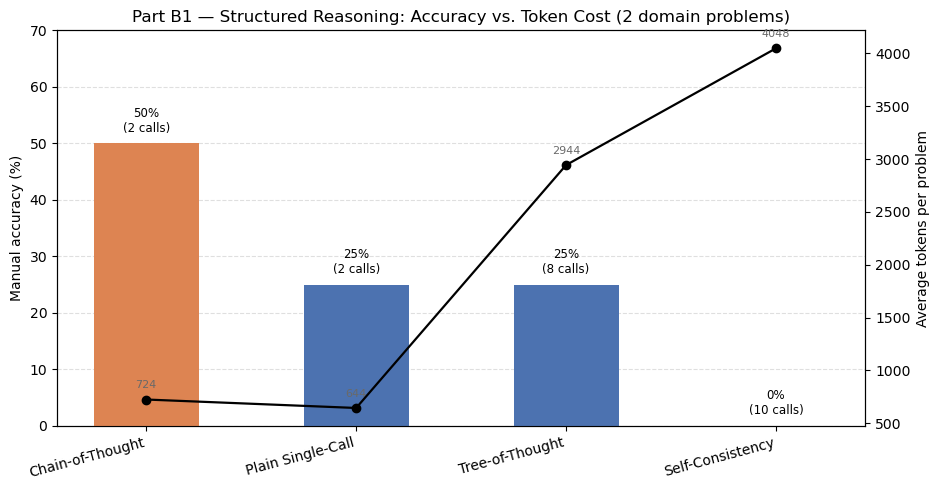

Orange bar = top-ranked technique by the cost-quality rule used in 8.6.


In [102]:
# Visualization — Part B1 structured-reasoning comparison
import matplotlib.pyplot as plt
import numpy as np

order = sorted(part_b_b1_technique_summary, key=lambda r: r["cost_quality_rank"])
techniques = [r["technique"] for r in order]
acc = [r["normalised_accuracy_percent"] for r in order]
tokens = [r["average_tokens_per_problem"] for r in order]
calls = [r["total_model_calls"] for r in order]

fig, ax1 = plt.subplots(figsize=(9.5, 5))
x = np.arange(len(techniques))
colors = ["#DD8452" if r["cost_quality_rank"] == 1 else "#4C72B0" for r in order]

bars = ax1.bar(x, acc, width=0.5, color=colors, zorder=3)
ax1.set_xticks(x)
ax1.set_xticklabels(techniques, rotation=15, ha="right")
ax1.set_ylabel("Manual accuracy (%)")
ax1.set_ylim(0, max(acc) * 1.4)
ax1.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax1.set_title("Part B1 — Structured Reasoning: Accuracy vs. Token Cost (2 domain problems)")

for xi, val, call_count in zip(x, acc, calls):
    ax1.text(xi, val + 1.5, f"{val:.0f}%\n({call_count} calls)", ha="center", va="bottom", fontsize=8.5)

ax2 = ax1.twinx()
ax2.plot(x, tokens, color="black", marker="o", linewidth=1.6, zorder=4)
ax2.set_ylabel("Average tokens per problem")
for xi, val in zip(x, tokens):
    ax2.annotate(f"{val:.0f}", (xi, val), textcoords="offset points",
                 xytext=(0, 8), ha="center", fontsize=8, color="dimgray")

plt.tight_layout()
plt.show()

print("Orange bar = top-ranked technique by the cost-quality rule used in 8.6.")


### 8.7 Iterative Reasoning — ReAct

[🔝 Back to Index](#Master-Index)

#### Purpose

ReAct combines model reasoning with external tool execution. Instead of relying on the model to perform calculations internally, the model selects a local tool, receives its verified observation, and uses that result in the next reasoning cycle.

#### Domain Problem

A production Linux log server has:

- `2,000 GB` usable capacity
- `92%` current utilisation
- `18 GB/day` growth
- A required target below `80%`

Verified cleanup candidates are:

- Expired application logs: `160 GB`, safe
- Package cache: `35 GB`, safe
- Orphaned temporary files: `40 GB`, safe
- Old crash dumps: `90 GB`, conditional on incident-owner approval
- Active audit logs: `120 GB`, prohibited from deletion

The agent must determine:

1. Current used and free capacity
2. Minimum space that must be reclaimed
3. Time remaining until 95% and 100% utilisation
4. The lowest-risk cleanup combination that reaches the target

#### Local Tools

The ReAct controller exposes three deterministic tools:

1. `assess_capacity`
2. `forecast_growth`
3. `select_cleanup_plan`

The model chooses one unused tool in each cycle. Tool arguments are normalised from the trusted scenario before execution, preventing unsupported values from entering the calculation.


In [103]:
import csv
import itertools
import json
import math
import re
from datetime import datetime, timezone


# ==================================================================
# PART B2 — REACT CONFIGURATION
# ==================================================================

REACT_CYCLE_COUNT = 3
REACT_ACTION_MAX_NEW_TOKENS = 180
REACT_FINAL_MAX_NEW_TOKENS = 420

PART_B_REACT_JSON_PATH = (
    BENCHMARKS_DIR
    / "part_b_react_result.json"
)

PART_B_REACT_TRACE_CSV_PATH = (
    BENCHMARKS_DIR
    / "part_b_react_trace.csv"
)

PART_B_REACT_REPORT_PATH = (
    REPORTS_DIR
    / "part_b_react_report.json"
)


REACT_PROBLEM = {
    "problem_id": "REACT01",
    "title": "Production Log-Server Capacity Incident",
    "domain": "storage_capacity_incident",
    "risk_level": "high",
    "query": (
        "A production Linux log server has 2,000 GB of usable "
        "filesystem capacity and is currently 92% used. Usage is "
        "growing by 18 GB per day. Operations must reduce utilisation "
        "below 80% without deleting active audit logs. Verified cleanup "
        "candidates are: expired application logs 160 GB safe, package "
        "cache 35 GB safe, orphaned temporary files 40 GB safe, old "
        "crash dumps 90 GB conditional on incident-owner approval, and "
        "active audit logs 120 GB prohibited. Calculate the current "
        "capacity state, time until 95% and 100%, and the lowest-risk "
        "cleanup plan that reaches the target."
    ),
    "total_capacity_gb": 2000.0,
    "current_used_percent": 92.0,
    "target_used_percent": 80.0,
    "daily_growth_gb": 18.0,
    "warning_percent": 95.0,
    "full_percent": 100.0,
    "cleanup_candidates": [
        {
            "name": "Expired application logs",
            "reclaim_gb": 160.0,
            "risk": "safe",
            "allowed": True,
            "condition": None,
        },
        {
            "name": "Package cache",
            "reclaim_gb": 35.0,
            "risk": "safe",
            "allowed": True,
            "condition": None,
        },
        {
            "name": "Orphaned temporary files",
            "reclaim_gb": 40.0,
            "risk": "safe",
            "allowed": True,
            "condition": None,
        },
        {
            "name": "Old crash dumps",
            "reclaim_gb": 90.0,
            "risk": "conditional",
            "allowed": True,
            "condition": "Incident-owner approval required",
        },
        {
            "name": "Active audit logs",
            "reclaim_gb": 120.0,
            "risk": "prohibited",
            "allowed": False,
            "condition": "Must not be deleted",
        },
    ],
}


REACT_TOOL_DESCRIPTIONS = {
    "assess_capacity": (
        "Calculate current used space, free space, target maximum "
        "used space, and minimum reclaim requirement."
    ),
    "forecast_growth": (
        "Calculate days remaining until the warning and full-capacity "
        "thresholds at the confirmed daily growth rate."
    ),
    "select_cleanup_plan": (
        "Evaluate allowed cleanup combinations and select the "
        "lowest-risk plan that reaches the reclaim requirement."
    ),
}


REACT_SYSTEM_PROMPT = """
You are an enterprise IT incident-response agent using ReAct.

At each cycle, choose exactly one unused local tool. Return valid JSON
only with this structure:

{
  "thought": "Concise task-relevant reason for the next tool",
  "action": "one allowed tool name"
}

Do not calculate values yourself. Do not include an observation.
Do not repeat a previously executed tool.
""".strip()


REACT_FINAL_SYSTEM_PROMPT = """
You are a senior Linux operations engineer.

Use only the verified ReAct tool observations supplied in the prompt.
Do not recalculate using invented values.

Return:

1. Incident Assessment
2. Capacity Calculations
3. Growth Risk
4. Recommended Cleanup Plan
5. Safe Operational Procedure
6. Verification and Escalation Criteria

Clearly state that active audit logs must not be deleted and that any
conditional cleanup requires approval.
""".strip()


# ==================================================================
# LOCAL REACT TOOLS
# ==================================================================

def assess_capacity(
    total_capacity_gb,
    current_used_percent,
    target_used_percent,
):
    """
    Calculate current capacity and the minimum reclaim requirement.
    """

    current_used_gb = (
        total_capacity_gb
        * current_used_percent
        / 100.0
    )

    current_free_gb = (
        total_capacity_gb
        - current_used_gb
    )

    target_maximum_used_gb = (
        total_capacity_gb
        * target_used_percent
        / 100.0
    )

    minimum_reclaim_gb = max(
        0.0,
        current_used_gb
        - target_maximum_used_gb,
    )

    return {
        "total_capacity_gb": round(
            total_capacity_gb,
            2,
        ),
        "current_used_percent": round(
            current_used_percent,
            2,
        ),
        "current_used_gb": round(
            current_used_gb,
            2,
        ),
        "current_free_gb": round(
            current_free_gb,
            2,
        ),
        "target_used_percent": round(
            target_used_percent,
            2,
        ),
        "target_maximum_used_gb": round(
            target_maximum_used_gb,
            2,
        ),
        "minimum_reclaim_gb": round(
            minimum_reclaim_gb,
            2,
        ),
        "interpretation": (
            "At least this amount must be reclaimed to reach 80%. "
            "A small additional margin is preferable when the "
            "requirement is strictly below 80%."
        ),
    }


def forecast_growth(
    total_capacity_gb,
    current_used_percent,
    daily_growth_gb,
    warning_percent,
    full_percent,
):
    """
    Forecast the time remaining before warning and full thresholds.
    """

    current_used_gb = (
        total_capacity_gb
        * current_used_percent
        / 100.0
    )

    warning_used_gb = (
        total_capacity_gb
        * warning_percent
        / 100.0
    )

    full_used_gb = (
        total_capacity_gb
        * full_percent
        / 100.0
    )

    remaining_to_warning_gb = max(
        0.0,
        warning_used_gb
        - current_used_gb,
    )

    remaining_to_full_gb = max(
        0.0,
        full_used_gb
        - current_used_gb,
    )

    days_to_warning = (
        remaining_to_warning_gb
        / daily_growth_gb
        if daily_growth_gb > 0
        else math.inf
    )

    days_to_full = (
        remaining_to_full_gb
        / daily_growth_gb
        if daily_growth_gb > 0
        else math.inf
    )

    return {
        "daily_growth_gb": round(
            daily_growth_gb,
            2,
        ),
        "warning_percent": round(
            warning_percent,
            2,
        ),
        "warning_used_gb": round(
            warning_used_gb,
            2,
        ),
        "remaining_to_warning_gb": round(
            remaining_to_warning_gb,
            2,
        ),
        "days_to_warning": round(
            days_to_warning,
            2,
        ),
        "full_percent": round(
            full_percent,
            2,
        ),
        "remaining_to_full_gb": round(
            remaining_to_full_gb,
            2,
        ),
        "days_to_full": round(
            days_to_full,
            2,
        ),
        "interpretation": (
            "The forecast assumes the observed 18 GB/day growth "
            "continues without cleanup or workload change."
        ),
    }


def select_cleanup_plan(
    total_capacity_gb,
    current_used_percent,
    target_used_percent,
    cleanup_candidates,
):
    """
    Select an allowed cleanup combination using this order:

    1. Reach the required reclaim amount
    2. Minimise the number of conditional items
    3. Minimise excess deletion
    4. Minimise the number of selected items
    """

    capacity_result = assess_capacity(
        total_capacity_gb=total_capacity_gb,
        current_used_percent=current_used_percent,
        target_used_percent=target_used_percent,
    )

    required_reclaim_gb = (
        capacity_result[
            "minimum_reclaim_gb"
        ]
    )

    allowed_candidates = [
        candidate
        for candidate in cleanup_candidates
        if candidate["allowed"]
        and candidate["risk"]
        != "prohibited"
    ]

    prohibited_candidates = [
        candidate
        for candidate in cleanup_candidates
        if not candidate["allowed"]
        or candidate["risk"]
        == "prohibited"
    ]

    feasible_plans = []

    for selection_size in range(
        1,
        len(allowed_candidates) + 1,
    ):
        for combination in itertools.combinations(
            allowed_candidates,
            selection_size,
        ):
            total_reclaim_gb = sum(
                candidate["reclaim_gb"]
                for candidate in combination
            )

            if total_reclaim_gb < required_reclaim_gb:
                continue

            conditional_count = sum(
                candidate["risk"]
                == "conditional"
                for candidate in combination
            )

            excess_reclaim_gb = (
                total_reclaim_gb
                - required_reclaim_gb
            )

            feasible_plans.append(
                {
                    "selected_candidates": [
                        candidate["name"]
                        for candidate in combination
                    ],
                    "selected_details": [
                        dict(candidate)
                        for candidate in combination
                    ],
                    "total_reclaim_gb": round(
                        total_reclaim_gb,
                        2,
                    ),
                    "conditional_count": (
                        conditional_count
                    ),
                    "excess_reclaim_gb": round(
                        excess_reclaim_gb,
                        2,
                    ),
                    "item_count": len(
                        combination
                    ),
                }
            )

    if not feasible_plans:
        return {
            "feasible": False,
            "required_reclaim_gb": (
                required_reclaim_gb
            ),
            "reason": (
                "No permitted cleanup combination reaches the target."
            ),
            "prohibited_candidates": [
                candidate["name"]
                for candidate in prohibited_candidates
            ],
        }

    selected_plan = sorted(
        feasible_plans,
        key=lambda plan: (
            plan["conditional_count"],
            plan["excess_reclaim_gb"],
            plan["item_count"],
            tuple(
                plan["selected_candidates"]
            ),
        ),
    )[0]

    current_used_gb = (
        total_capacity_gb
        * current_used_percent
        / 100.0
    )

    projected_used_gb = (
        current_used_gb
        - selected_plan[
            "total_reclaim_gb"
        ]
    )

    projected_used_percent = (
        projected_used_gb
        / total_capacity_gb
        * 100.0
    )

    safe_only_reclaim_gb = sum(
        candidate["reclaim_gb"]
        for candidate in allowed_candidates
        if candidate["risk"] == "safe"
    )

    return {
        "feasible": True,
        "required_reclaim_gb": round(
            required_reclaim_gb,
            2,
        ),
        "safe_only_reclaim_gb": round(
            safe_only_reclaim_gb,
            2,
        ),
        "safe_only_is_sufficient": (
            safe_only_reclaim_gb
            >= required_reclaim_gb
        ),
        "selection_policy": [
            "Reach required reclaim",
            "Minimise conditional items",
            "Minimise excess deletion",
            "Minimise selected item count",
        ],
        **selected_plan,
        "projected_used_gb": round(
            projected_used_gb,
            2,
        ),
        "projected_used_percent": round(
            projected_used_percent,
            2,
        ),
        "approval_required": any(
            detail["risk"] == "conditional"
            for detail in selected_plan[
                "selected_details"
            ]
        ),
        "prohibited_candidates": [
            candidate["name"]
            for candidate in prohibited_candidates
        ],
        "warning": (
            "Active audit logs are prohibited from deletion. "
            "Old crash dumps require incident-owner approval."
        ),
    }


REACT_LOCAL_TOOLS = {
    "assess_capacity": assess_capacity,
    "forecast_growth": forecast_growth,
    "select_cleanup_plan": (
        select_cleanup_plan
    ),
}


# ==================================================================
# TRUSTED TOOL INPUT NORMALISATION
# ==================================================================

def build_react_tool_input(
    tool_name,
    scenario,
):
    """
    Supply trusted scenario values instead of accepting invented
    numerical arguments from the model.
    """

    if tool_name == "assess_capacity":
        return {
            "total_capacity_gb": (
                scenario[
                    "total_capacity_gb"
                ]
            ),
            "current_used_percent": (
                scenario[
                    "current_used_percent"
                ]
            ),
            "target_used_percent": (
                scenario[
                    "target_used_percent"
                ]
            ),
        }

    if tool_name == "forecast_growth":
        return {
            "total_capacity_gb": (
                scenario[
                    "total_capacity_gb"
                ]
            ),
            "current_used_percent": (
                scenario[
                    "current_used_percent"
                ]
            ),
            "daily_growth_gb": (
                scenario[
                    "daily_growth_gb"
                ]
            ),
            "warning_percent": (
                scenario[
                    "warning_percent"
                ]
            ),
            "full_percent": (
                scenario[
                    "full_percent"
                ]
            ),
        }

    if tool_name == "select_cleanup_plan":
        return {
            "total_capacity_gb": (
                scenario[
                    "total_capacity_gb"
                ]
            ),
            "current_used_percent": (
                scenario[
                    "current_used_percent"
                ]
            ),
            "target_used_percent": (
                scenario[
                    "target_used_percent"
                ]
            ),
            "cleanup_candidates": (
                scenario[
                    "cleanup_candidates"
                ]
            ),
        }

    raise KeyError(
        f"Unknown ReAct tool: {tool_name}"
    )


# ==================================================================
# JSON ACTION PARSING
# ==================================================================

def extract_first_json_object(
    text,
):
    """
    Extract the first balanced JSON object from model output.
    """

    cleaned_text = str(text).strip()

    fenced_match = re.search(
        r"```(?:json)?\s*(\{.*?\})\s*```",
        cleaned_text,
        flags=re.IGNORECASE | re.DOTALL,
    )

    if fenced_match:
        cleaned_text = (
            fenced_match.group(1)
        )

    try:
        parsed = json.loads(
            cleaned_text
        )

        if isinstance(parsed, dict):
            return parsed

    except json.JSONDecodeError:
        pass

    start_index = cleaned_text.find(
        "{"
    )

    if start_index < 0:
        return None

    depth = 0
    in_string = False
    escaped = False

    for index in range(
        start_index,
        len(cleaned_text),
    ):
        character = cleaned_text[
            index
        ]

        if escaped:
            escaped = False
            continue

        if character == "\\":
            escaped = True
            continue

        if character == '"':
            in_string = not in_string
            continue

        if in_string:
            continue

        if character == "{":
            depth += 1

        elif character == "}":
            depth -= 1

            if depth == 0:
                candidate = cleaned_text[
                    start_index:index + 1
                ]

                try:
                    parsed = json.loads(
                        candidate
                    )

                    if isinstance(
                        parsed,
                        dict,
                    ):
                        return parsed

                except json.JSONDecodeError:
                    return None

    return None


def parse_react_action(
    raw_response,
    remaining_tools,
):
    """
    Parse one model-selected action and apply a deterministic controller
    fallback when the response is malformed or repeats a tool.
    """

    parsed_json = extract_first_json_object(
        raw_response
    )

    parse_success = (
        isinstance(parsed_json, dict)
    )

    thought = ""

    requested_action = None

    if parse_success:
        thought = str(
            parsed_json.get(
                "thought",
                "",
            )
        ).strip()

        requested_action = str(
            parsed_json.get(
                "action",
                "",
            )
        ).strip()

    controller_corrected = False
    correction_reason = None

    if requested_action not in remaining_tools:
        controller_corrected = True

        correction_reason = (
            "The model action was missing, invalid, "
            "or already executed."
        )

        requested_action = (
            remaining_tools[0]
        )

    if not thought:
        thought = (
            f"Use {requested_action} to obtain the next "
            "verified observation."
        )

    return {
        "thought": thought,
        "action": requested_action,
        "parse_success": parse_success,
        "controller_corrected": (
            controller_corrected
        ),
        "correction_reason": (
            correction_reason
        ),
        "parsed_json": parsed_json,
    }


# ==================================================================
# REACT PROMPT BUILDERS
# ==================================================================

def build_react_cycle_prompt(
    scenario,
    trace,
    remaining_tools,
    cycle_number,
):
    """
    Include all earlier observations in every subsequent cycle.
    """

    available_tool_text = "\n".join(
        (
            f"- {tool_name}: "
            f"{REACT_TOOL_DESCRIPTIONS[tool_name]}"
        )
        for tool_name in remaining_tools
    )

    if trace:
        previous_trace_text = "\n\n".join(
            [
                (
                    f"Cycle {record['cycle_number']}\n"
                    f"Action: {record['action']}\n"
                    f"Observation: "
                    f"{json.dumps(record['observation'], ensure_ascii=False)}"
                )
                for record in trace
            ]
        )
    else:
        previous_trace_text = (
            "No previous observations."
        )

    return f"""
Problem:
{scenario["query"]}

Current cycle:
{cycle_number} of {REACT_CYCLE_COUNT}

Unused local tools:
{available_tool_text}

Previous Action and Observation trace:
{previous_trace_text}

Choose the single most useful unused tool for the next verified step.
Return only the required JSON object.
""".strip()


def build_react_final_prompt(
    scenario,
    trace,
):
    """
    Build final synthesis using only verified local observations.
    """

    trace_text = "\n\n".join(
        [
            (
                f"Cycle {record['cycle_number']}\n"
                f"Thought: {record['thought']}\n"
                f"Action: {record['action']}\n"
                f"Action Input: "
                f"{json.dumps(record['action_input'], ensure_ascii=False)}\n"
                f"Observation: "
                f"{json.dumps(record['observation'], ensure_ascii=False)}"
            )
            for record in trace
        ]
    )

    return f"""
Incident:
{scenario["query"]}

Verified ReAct trace:
{trace_text}

Prepare the final incident-resolution response using only these
observations. Include the exact calculated values and approval or
prohibition conditions.
""".strip()


# ==================================================================
# EXECUTE THREE REACT CYCLES
# ==================================================================

react_trace = []

remaining_tools = list(
    REACT_LOCAL_TOOLS
)

react_total_input_tokens = 0
react_total_output_tokens = 0
react_total_latency_sec = 0.0
react_capped_call_count = 0


for cycle_number in range(
    1,
    REACT_CYCLE_COUNT + 1,
):
    cycle_prompt = build_react_cycle_prompt(
        scenario=REACT_PROBLEM,
        trace=react_trace,
        remaining_tools=remaining_tools,
        cycle_number=cycle_number,
    )

    raw_cycle_result = generate_with_metrics(
        user_prompt=cycle_prompt,
        system_prompt=REACT_SYSTEM_PROMPT,
        max_new_tokens=(
            REACT_ACTION_MAX_NEW_TOKENS
        ),
    )

    cycle_metrics = normalise_generation_result(
        raw_cycle_result
    )

    cycle_metrics = (
        apply_derived_generation_cap(
            metrics=cycle_metrics,
            max_new_tokens=(
                REACT_ACTION_MAX_NEW_TOKENS
            ),
        )
    )

    action_decision = parse_react_action(
        raw_response=cycle_metrics[
            "generated_response"
        ],
        remaining_tools=remaining_tools,
    )

    selected_action = (
        action_decision["action"]
    )

    action_input = build_react_tool_input(
        tool_name=selected_action,
        scenario=REACT_PROBLEM,
    )

    observation = REACT_LOCAL_TOOLS[
        selected_action
    ](
        **action_input
    )

    trace_record = {
        "cycle_number": cycle_number,
        "thought": (
            action_decision[
                "thought"
            ]
        ),
        "action": selected_action,
        "action_input": action_input,
        "observation": observation,
        "raw_model_response": (
            cycle_metrics[
                "generated_response"
            ]
        ),
        "parse_success": (
            action_decision[
                "parse_success"
            ]
        ),
        "controller_corrected": (
            action_decision[
                "controller_corrected"
            ]
        ),
        "correction_reason": (
            action_decision[
                "correction_reason"
            ]
        ),
        "previous_observation_count": (
            len(react_trace)
        ),
        "input_tokens": (
            cycle_metrics[
                "input_tokens"
            ]
        ),
        "output_tokens": (
            cycle_metrics[
                "output_tokens"
            ]
        ),
        "total_tokens": (
            cycle_metrics[
                "total_tokens"
            ]
        ),
        "latency_sec": (
            cycle_metrics[
                "latency_sec"
            ]
        ),
        "generation_capped": (
            cycle_metrics[
                "generation_capped"
            ]
        ),
    }

    react_trace.append(
        trace_record
    )

    remaining_tools.remove(
        selected_action
    )

    react_total_input_tokens += (
        cycle_metrics[
            "input_tokens"
        ]
    )

    react_total_output_tokens += (
        cycle_metrics[
            "output_tokens"
        ]
    )

    react_total_latency_sec += (
        cycle_metrics[
            "latency_sec"
        ]
    )

    react_capped_call_count += int(
        cycle_metrics[
            "generation_capped"
        ]
    )


# ==================================================================
# FINAL ANSWER FROM THE COMPLETE TRACE
# ==================================================================

react_final_prompt = build_react_final_prompt(
    scenario=REACT_PROBLEM,
    trace=react_trace,
)


raw_final_result = generate_with_metrics(
    user_prompt=react_final_prompt,
    system_prompt=(
        REACT_FINAL_SYSTEM_PROMPT
    ),
    max_new_tokens=(
        REACT_FINAL_MAX_NEW_TOKENS
    ),
)


final_metrics = normalise_generation_result(
    raw_final_result
)


final_metrics = apply_derived_generation_cap(
    metrics=final_metrics,
    max_new_tokens=(
        REACT_FINAL_MAX_NEW_TOKENS
    ),
)


react_total_input_tokens += (
    final_metrics[
        "input_tokens"
    ]
)

react_total_output_tokens += (
    final_metrics[
        "output_tokens"
    ]
)

react_total_latency_sec += (
    final_metrics[
        "latency_sec"
    ]
)

react_capped_call_count += int(
    final_metrics[
        "generation_capped"
    ]
)


# ==================================================================
# CREATE CANONICAL REACT RESULT
# ==================================================================

part_b_react_result = {
    "problem_id": (
        REACT_PROBLEM[
            "problem_id"
        ]
    ),
    "problem_title": (
        REACT_PROBLEM[
            "title"
        ]
    ),
    "domain": (
        REACT_PROBLEM[
            "domain"
        ]
    ),
    "risk_level": (
        REACT_PROBLEM[
            "risk_level"
        ]
    ),
    "technique": "ReAct",
    "query": (
        REACT_PROBLEM[
            "query"
        ]
    ),
    "cycle_count": len(
        react_trace
    ),
    "trace": react_trace,
    "final_response": (
        final_metrics[
            "generated_response"
        ]
    ),
    "final_response_metrics": (
        final_metrics
    ),
    "model_calls": (
        REACT_CYCLE_COUNT + 1
    ),
    "local_tool_calls": len(
        react_trace
    ),
    "executed_tools": [
        record["action"]
        for record in react_trace
    ],
    "controller_correction_count": sum(
        record[
            "controller_corrected"
        ]
        for record in react_trace
    ),
    "action_parse_success_count": sum(
        record[
            "parse_success"
        ]
        for record in react_trace
    ),
    "total_input_tokens": (
        react_total_input_tokens
    ),
    "total_output_tokens": (
        react_total_output_tokens
    ),
    "total_tokens": (
        react_total_input_tokens
        + react_total_output_tokens
    ),
    "total_latency_sec": round(
        react_total_latency_sec,
        4,
    ),
    "generation_capped_call_count": (
        react_capped_call_count
    ),
    "run_timestamp_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
}


# ==================================================================
# SAVE JSON ARTIFACT
# ==================================================================

with PART_B_REACT_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        part_b_react_result,
        json_file,
        indent=2,
        ensure_ascii=False,
    )


# ==================================================================
# SAVE TRACE CSV
# ==================================================================

react_trace_csv_fields = [
    "cycle_number",
    "thought",
    "action",
    "action_input",
    "observation",
    "parse_success",
    "controller_corrected",
    "correction_reason",
    "previous_observation_count",
    "input_tokens",
    "output_tokens",
    "total_tokens",
    "latency_sec",
    "generation_capped",
]


with PART_B_REACT_TRACE_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=react_trace_csv_fields,
    )

    writer.writeheader()

    for record in react_trace:
        csv_record = {
            field_name: record.get(
                field_name,
                "",
            )
            for field_name
            in react_trace_csv_fields
        }

        csv_record["action_input"] = (
            json.dumps(
                record[
                    "action_input"
                ],
                ensure_ascii=False,
            )
        )

        csv_record["observation"] = (
            json.dumps(
                record[
                    "observation"
                ],
                ensure_ascii=False,
            )
        )

        writer.writerow(
            csv_record
        )


# ==================================================================
# BUILD REPORT
# ==================================================================

capacity_observation = next(
    record["observation"]
    for record in react_trace
    if record["action"]
    == "assess_capacity"
)

growth_observation = next(
    record["observation"]
    for record in react_trace
    if record["action"]
    == "forecast_growth"
)

cleanup_observation = next(
    record["observation"]
    for record in react_trace
    if record["action"]
    == "select_cleanup_plan"
)


part_b_react_report = {
    "requirement": (
        "Thought → Action → Observation loop "
        "with at least three cycles"
    ),
    "cycle_count": len(
        react_trace
    ),
    "local_tool_calls": len(
        react_trace
    ),
    "observation_feed_counts": [
        record[
            "previous_observation_count"
        ]
        for record in react_trace
    ],
    "verified_results": {
        "current_used_gb": (
            capacity_observation[
                "current_used_gb"
            ]
        ),
        "current_free_gb": (
            capacity_observation[
                "current_free_gb"
            ]
        ),
        "minimum_reclaim_gb": (
            capacity_observation[
                "minimum_reclaim_gb"
            ]
        ),
        "days_to_95_percent": (
            growth_observation[
                "days_to_warning"
            ]
        ),
        "days_to_100_percent": (
            growth_observation[
                "days_to_full"
            ]
        ),
        "selected_cleanup_items": (
            cleanup_observation[
                "selected_candidates"
            ]
        ),
        "selected_reclaim_gb": (
            cleanup_observation[
                "total_reclaim_gb"
            ]
        ),
        "projected_used_percent": (
            cleanup_observation[
                "projected_used_percent"
            ]
        ),
        "approval_required": (
            cleanup_observation[
                "approval_required"
            ]
        ),
    },
    "result_artifact": str(
        PART_B_REACT_JSON_PATH
    ),
    "trace_artifact": str(
        PART_B_REACT_TRACE_CSV_PATH
    ),
}


with PART_B_REACT_REPORT_PATH.open(
    "w",
    encoding="utf-8",
) as report_file:
    json.dump(
        part_b_react_report,
        report_file,
        indent=2,
        ensure_ascii=False,
    )


# ==================================================================
# VALIDATION
# ==================================================================

react_validation_checks = {
    "At least three ReAct cycles executed": (
        len(react_trace) >= 3
    ),
    "Exactly three local tool calls executed": (
        len(react_trace) == 3
    ),
    "Every Action invoked a registered local tool": all(
        record["action"]
        in REACT_LOCAL_TOOLS
        for record in react_trace
    ),
    "All three local tools were used once": (
        set(
            record["action"]
            for record in react_trace
        )
        == set(
            REACT_LOCAL_TOOLS
        )
    ),
    "Observations accumulated across cycles": (
        [
            record[
                "previous_observation_count"
            ]
            for record in react_trace
        ]
        == [
            0,
            1,
            2,
        ]
    ),
    "Every observation contains structured data": all(
        isinstance(
            record["observation"],
            dict,
        )
        and bool(
            record["observation"]
        )
        for record in react_trace
    ),
    "Final answer is present": bool(
        part_b_react_result[
            "final_response"
        ]
    ),
    "Four total model calls were used": (
        part_b_react_result[
            "model_calls"
        ]
        == 4
    ),
    "Aggregate token count is positive": (
        part_b_react_result[
            "total_tokens"
        ]
        > 0
    ),
    "Aggregate latency is positive": (
        part_b_react_result[
            "total_latency_sec"
        ]
        > 0
    ),
    "Capacity calculation is correct": (
        capacity_observation[
            "current_used_gb"
        ]
        == 1840.0
        and capacity_observation[
            "current_free_gb"
        ]
        == 160.0
        and capacity_observation[
            "minimum_reclaim_gb"
        ]
        == 240.0
    ),
    "Growth forecast is correct": (
        growth_observation[
            "days_to_warning"
        ]
        == 3.33
        and growth_observation[
            "days_to_full"
        ]
        == 8.89
    ),
    "Cleanup plan reaches below eighty percent": (
        cleanup_observation[
            "projected_used_percent"
        ]
        < 80.0
    ),
    "Active audit logs are excluded": (
        "Active audit logs"
        not in cleanup_observation[
            "selected_candidates"
        ]
    ),
}


# ==================================================================
# DISPLAY FULL REACT TRACE
# ==================================================================

print("PART B2 — REACT FULL TRACE")
print("=" * 125)


for record in react_trace:
    print(
        f"\nCYCLE {record['cycle_number']}"
    )

    print("-" * 125)

    print(
        f"Thought     : "
        f"{record['thought']}"
    )

    print(
        f"Action      : "
        f"{record['action']}"
    )

    print(
        "Action Input:"
    )

    print(
        json.dumps(
            record[
                "action_input"
            ],
            indent=2,
            ensure_ascii=False,
        )
    )

    print(
        "Observation:"
    )

    print(
        json.dumps(
            record[
                "observation"
            ],
            indent=2,
            ensure_ascii=False,
        )
    )

    print(
        f"Parse success       : "
        f"{record['parse_success']}"
    )

    print(
        f"Controller corrected: "
        f"{record['controller_corrected']}"
    )

    print(
        f"Previous observations supplied: "
        f"{record['previous_observation_count']}"
    )

    print(
        f"Tokens: {record['total_tokens']} | "
        f"Latency: {record['latency_sec']:.4f}s | "
        f"Capped: {record['generation_capped']}"
    )


print(
    "\nFINAL REACT ANSWER"
)

print("-" * 125)

print(
    part_b_react_result[
        "final_response"
    ]
)

print("-" * 125)

print(
    f"Model calls          : "
    f"{part_b_react_result['model_calls']}"
)

print(
    f"Local tool calls     : "
    f"{part_b_react_result['local_tool_calls']}"
)

print(
    f"Total tokens         : "
    f"{part_b_react_result['total_tokens']}"
)

print(
    f"Total latency        : "
    f"{part_b_react_result['total_latency_sec']:.4f}s"
)

print(
    f"Controller corrections: "
    f"{part_b_react_result['controller_correction_count']}"
)


print("\nVALIDATION")
print("-" * 125)


for check_name, passed in (
    react_validation_checks.items()
):
    print(
        f"{check_name:<72} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("-" * 125)

print(
    f"Result JSON : "
    f"{PART_B_REACT_JSON_PATH}"
)

print(
    f"Trace CSV   : "
    f"{PART_B_REACT_TRACE_CSV_PATH}"
)

print(
    f"Report JSON : "
    f"{PART_B_REACT_REPORT_PATH}"
)

print("=" * 125)


if not all(
    react_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in react_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Part B2 ReAct validation failed for: "
        + ", ".join(failed_checks)
    )


print(
    "Part B2 ReAct execution completed successfully."
)


PART B2 — REACT FULL TRACE

CYCLE 1
-----------------------------------------------------------------------------------------------------------------------------
Thought     : Calculate the current capacity state, time until 95% and 100%, and the lowest-risk cleanup plan that reaches the target.
Action      : assess_capacity
Action Input:
{
  "total_capacity_gb": 2000.0,
  "current_used_percent": 92.0,
  "target_used_percent": 80.0
}
Observation:
{
  "total_capacity_gb": 2000.0,
  "current_used_percent": 92.0,
  "current_used_gb": 1840.0,
  "current_free_gb": 160.0,
  "target_used_percent": 80.0,
  "target_maximum_used_gb": 1600.0,
  "minimum_reclaim_gb": 240.0,
  "interpretation": "At least this amount must be reclaimed to reach 80%. A small additional margin is preferable when the requirement is strictly below 80%."
}
Parse success       : True
Controller corrected: False
Previous observations supplied: 0
Tokens: 388 | Latency: 2.6392s | Capped: False

CYCLE 2
-----------------------

#### Observation

[🔝 Back to Index](#Master-Index)

The ReAct implementation satisfied the required three `Thought → Action → Observation` cycles. Every action invoked a registered local function, and the accumulated observations were supplied to subsequent cycles without controller correction.

The tools correctly established:

- Current usage: `1,840 GB`
- Current free capacity: `160 GB`
- Minimum reclaim requirement: `240 GB`
- Time to 95%: `3.33 days`
- Time to full capacity: `8.89 days`
- Selected cleanup: expired application logs plus approved old crash dumps
- Projected utilisation: `79.5%`

The final model response preserved the verified calculations but should have explicitly named both selected cleanup items. The ReAct mechanics are complete, while final-answer completeness remains a separate quality consideration.


### 8.8 Custom Chain 1 — Plan → Solve → Verify

[🔝 Back to Index](#Master-Index)

#### Purpose

The `Plan → Solve → Verify` chain separates high-stakes resolution into three controlled stages:

1. **Plan**  
   Identify the evidence, dependencies, remediation order, verification gates, and rollback requirements without immediately performing destructive actions.

2. **Solve**  
   Convert the approved plan into a concrete operational procedure.

3. **Verify**  
   Independently compare the draft against the problem-specific critical requirements and material-error constraints, then produce a corrected final answer.

#### Application

The chain is applied to both multi-step domain problems:

- MSP01 — Post-Change VPN Gateway Outage
- MSP02 — Compromised Administrator Account and Persistence

Each problem requires three model calls. The stage outputs, token consumption, latency, cap status, and final response are stored for later comparison with the Plain Single-Call baseline.


In [104]:
import csv
import json
from datetime import datetime, timezone


# ==================================================================
# PART B3 — PLAN → SOLVE → VERIFY CONFIGURATION
# ==================================================================

PSV_PLAN_MAX_NEW_TOKENS = 260
PSV_SOLVE_MAX_NEW_TOKENS = 420
PSV_VERIFY_MAX_NEW_TOKENS = 500


PART_B_PSV_JSON_PATH = (
    BENCHMARKS_DIR
    / "part_b_plan_solve_verify_results.json"
)

PART_B_PSV_CSV_PATH = (
    BENCHMARKS_DIR
    / "part_b_plan_solve_verify_results.csv"
)

PART_B_PSV_CHECKPOINT_PATH = (
    BENCHMARKS_DIR
    / "part_b_plan_solve_verify_checkpoint.json"
)

PART_B_PSV_REPORT_PATH = (
    REPORTS_DIR
    / "part_b_plan_solve_verify_report.json"
)


PSV_PLAN_SYSTEM_PROMPT = """
You are a senior enterprise IT incident planner.

Create a concise operational plan for the supplied high-stakes problem.

Rules:

- Use only confirmed facts.
- Do not invent versions, paths, users, interfaces, services, or causes.
- Preserve evidence before destructive remediation.
- Use successful health signals to avoid unnecessary changes.
- Include dependencies, safe ordering, verification gates, and rollback.
- Do not provide speculative internal reasoning.
- Do not produce the final answer yet.

Return only:

1. Confirmed Situation
2. Immediate Safety Controls
3. Evidence and Diagnostic Plan
4. Remediation Plan
5. Verification Gates
6. Rollback or Escalation Plan
""".strip()


PSV_SOLVE_SYSTEM_PROMPT = """
You are a senior enterprise IT operations and incident-response engineer.

Convert the supplied approved plan into a concrete operational
resolution procedure.

Rules:

- Use only facts from the problem and plan.
- Preserve evidence before destructive action.
- Use exact supplied account, service, interface, subnet, and host scope.
- Include persistence, verification, and rollback.
- Do not reproduce prompt instructions.
- Avoid repetition.
- Do not claim that an action succeeded unless verification proves it.

Return only:

1. Diagnosis
2. Evidence Preservation
3. Ordered Remediation
4. Persistence or Recovery Controls
5. Verification
6. Rollback or Escalation Criteria
""".strip()


PSV_VERIFY_SYSTEM_PROMPT = """
You are an independent senior incident-response verifier.

Review the supplied problem, plan, and draft procedure against the
provided critical requirements and prohibited material errors.

Correct the procedure before returning it.

Rules:

- Preserve evidence before destructive remediation.
- Use only confirmed values from the problem.
- Remove invented facts and unsupported commands.
- Do not delete or reset healthy components unnecessarily.
- Ensure the complete affected scope is addressed.
- Include persistence, verification gates, rollback, and monitoring.
- Do not reproduce the evaluation checklist, prompt instructions,
  review notes, or scoring commentary.
- Return only the corrected operational answer.

Required final structure:

1. Diagnosis
2. Evidence Preservation
3. Ordered Remediation
4. Persistence or Recovery Controls
5. Verification
6. Rollback or Escalation Criteria
""".strip()


PSV_CONTROL_MARKERS = [
    "Critical requirements that must be satisfied:",
    "Material errors that must be avoided:",
    "Approved plan:",
    "Draft procedure:",
    "Verifier notes:",
    "Evaluation checklist:",
]


# ==================================================================
# PROBLEM FIELD HELPERS
# ==================================================================

def get_problem_list_field(
    problem,
    possible_keys,
):
    """
    Return the first available list-valued problem field.
    """

    for key in possible_keys:
        value = problem.get(key)

        if isinstance(value, list):
            return value

    return []


def format_list_items(items):
    """
    Format a list for insertion into a prompt.
    """

    if not items:
        return "- Not explicitly provided"

    return "\n".join(
        f"- {item}"
        for item in items
    )


def clean_psv_final_response(
    response_text,
):
    """
    Remove copied prompt-control material while retaining the raw
    verifier response separately for auditability.
    """

    cleaned_text = str(
        response_text
    ).strip()

    lower_text = cleaned_text.lower()
    marker_positions = []

    for marker in PSV_CONTROL_MARKERS:
        marker_position = lower_text.find(
            marker.lower()
        )

        if marker_position >= 0:
            marker_positions.append(
                marker_position
            )

    if marker_positions:
        cleaned_text = cleaned_text[
            :min(marker_positions)
        ].rstrip()

    return cleaned_text


# ==================================================================
# PROMPT BUILDERS
# ==================================================================

def build_psv_plan_prompt(
    problem,
):
    confirmed_observations = (
        get_problem_list_field(
            problem,
            [
                "confirmed_observations",
                "confirmed_facts",
                "observations",
            ],
        )
    )

    return f"""
Problem ID:
{problem["problem_id"]}

Problem:
{problem["query"]}

Confirmed observations:
{format_list_items(confirmed_observations)}

Produce the operational plan only. Prioritise evidence preservation,
safe ordering, exact scope, verification, and rollback.
""".strip()


def build_psv_solve_prompt(
    problem,
    plan_response,
):
    return f"""
Problem ID:
{problem["problem_id"]}

Problem:
{problem["query"]}

Approved plan:
{plan_response}

Convert this plan into a complete and technically safe operational
procedure. Do not omit persistence, verification, rollback, or
cross-host scope where applicable.
""".strip()


def build_psv_verify_prompt(
    problem,
    plan_response,
    draft_response,
):
    critical_requirements = (
        get_problem_list_field(
            problem,
            [
                "critical_requirements",
                "required_elements",
                "success_requirements",
            ],
        )
    )

    material_errors = (
        get_problem_list_field(
            problem,
            [
                "material_errors",
                "prohibited_actions",
                "unsafe_actions",
            ],
        )
    )

    return f"""
Problem ID:
{problem["problem_id"]}

Problem:
{problem["query"]}

Approved plan:
{plan_response}

Draft procedure:
{draft_response}

Critical requirements that must be satisfied:
{format_list_items(critical_requirements)}

Material errors that must be avoided:
{format_list_items(material_errors)}

Silently verify and correct the draft. Return only the final corrected
operational procedure under the six required headings.
""".strip()


# ==================================================================
# STAGE EXECUTION HELPER
# ==================================================================

def run_psv_stage(
    problem_id,
    stage_name,
    system_prompt,
    user_prompt,
    max_new_tokens,
):
    """
    Execute and measure one Plan → Solve → Verify stage.
    """

    raw_result = generate_with_metrics(
        user_prompt=user_prompt,
        system_prompt=system_prompt,
        max_new_tokens=max_new_tokens,
    )

    metrics = normalise_generation_result(
        raw_result
    )

    metrics = apply_derived_generation_cap(
        metrics=metrics,
        max_new_tokens=max_new_tokens,
    )

    return {
        "problem_id": problem_id,
        "stage": stage_name,
        "system_prompt": system_prompt,
        "user_prompt": user_prompt,
        **metrics,
        "run_timestamp_utc": (
            datetime.now(
                timezone.utc
            ).isoformat()
        ),
    }


# ==================================================================
# EXECUTE PLAN → SOLVE → VERIFY ON BOTH PROBLEMS
# ==================================================================

part_b_psv_results = []


for problem in part_b_multistep_problems:
    problem_id = problem[
        "problem_id"
    ]

    print(
        f"\nRunning Plan → Solve → Verify for "
        f"{problem_id}..."
    )


    # --------------------------------------------------------------
    # Stage 1 — Plan
    # --------------------------------------------------------------

    print("  Stage 1/3 — Plan")

    plan_stage = run_psv_stage(
        problem_id=problem_id,
        stage_name="Plan",
        system_prompt=(
            PSV_PLAN_SYSTEM_PROMPT
        ),
        user_prompt=(
            build_psv_plan_prompt(
                problem
            )
        ),
        max_new_tokens=(
            PSV_PLAN_MAX_NEW_TOKENS
        ),
    )


    # --------------------------------------------------------------
    # Stage 2 — Solve
    # --------------------------------------------------------------

    print("  Stage 2/3 — Solve")

    solve_stage = run_psv_stage(
        problem_id=problem_id,
        stage_name="Solve",
        system_prompt=(
            PSV_SOLVE_SYSTEM_PROMPT
        ),
        user_prompt=(
            build_psv_solve_prompt(
                problem=problem,
                plan_response=(
                    plan_stage[
                        "generated_response"
                    ]
                ),
            )
        ),
        max_new_tokens=(
            PSV_SOLVE_MAX_NEW_TOKENS
        ),
    )


    # --------------------------------------------------------------
    # Stage 3 — Verify
    # --------------------------------------------------------------

    print("  Stage 3/3 — Verify")

    verify_stage = run_psv_stage(
        problem_id=problem_id,
        stage_name="Verify",
        system_prompt=(
            PSV_VERIFY_SYSTEM_PROMPT
        ),
        user_prompt=(
            build_psv_verify_prompt(
                problem=problem,
                plan_response=(
                    plan_stage[
                        "generated_response"
                    ]
                ),
                draft_response=(
                    solve_stage[
                        "generated_response"
                    ]
                ),
            )
        ),
        max_new_tokens=(
            PSV_VERIFY_MAX_NEW_TOKENS
        ),
    )


    raw_final_response = (
        verify_stage[
            "generated_response"
        ]
    )

    cleaned_final_response = (
        clean_psv_final_response(
            raw_final_response
        )
    )


    final_diagnostic_scoring = (
        score_tot_candidate(
            problem_id=problem_id,
            response_text=(
                cleaned_final_response
            ),
        )
    )


    stage_records = [
        plan_stage,
        solve_stage,
        verify_stage,
    ]


    total_input_tokens = sum(
        stage["input_tokens"]
        for stage in stage_records
    )

    total_output_tokens = sum(
        stage["output_tokens"]
        for stage in stage_records
    )

    total_latency_sec = round(
        sum(
            stage["latency_sec"]
            for stage in stage_records
        ),
        4,
    )


    copied_control_markers = [
        marker
        for marker in PSV_CONTROL_MARKERS
        if marker.lower()
        in raw_final_response.lower()
    ]


    problem_result = {
        "problem_id": problem_id,
        "problem_title": (
            problem["title"]
        ),
        "domain": problem["domain"],
        "risk_level": (
            problem["risk_level"]
        ),
        "technique": (
            "Plan-Solve-Verify"
        ),
        "query": problem["query"],
        "stages": stage_records,
        "plan_response": (
            plan_stage[
                "generated_response"
            ]
        ),
        "solve_response": (
            solve_stage[
                "generated_response"
            ]
        ),
        "verify_response_raw": (
            raw_final_response
        ),
        "final_response": (
            cleaned_final_response
        ),
        "final_response_scoring": (
            final_diagnostic_scoring
        ),
        "copied_control_markers": (
            copied_control_markers
        ),
        "model_calls": 3,
        "total_input_tokens": (
            total_input_tokens
        ),
        "total_output_tokens": (
            total_output_tokens
        ),
        "total_tokens": (
            total_input_tokens
            + total_output_tokens
        ),
        "total_latency_sec": (
            total_latency_sec
        ),
        "capped_stage_count": sum(
            stage["generation_capped"]
            for stage in stage_records
        ),
        "run_timestamp_utc": (
            datetime.now(
                timezone.utc
            ).isoformat()
        ),
    }


    part_b_psv_results.append(
        problem_result
    )


    with PART_B_PSV_CHECKPOINT_PATH.open(
        "w",
        encoding="utf-8",
    ) as checkpoint_file:
        json.dump(
            part_b_psv_results,
            checkpoint_file,
            indent=2,
            ensure_ascii=False,
        )


# ==================================================================
# SAVE CANONICAL JSON
# ==================================================================

with PART_B_PSV_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        part_b_psv_results,
        json_file,
        indent=2,
        ensure_ascii=False,
    )


# ==================================================================
# SAVE SUMMARY CSV
# ==================================================================

psv_csv_fields = [
    "problem_id",
    "problem_title",
    "technique",
    "model_calls",
    "total_input_tokens",
    "total_output_tokens",
    "total_tokens",
    "total_latency_sec",
    "capped_stage_count",
    "automated_score",
    "automated_maximum",
    "copied_control_markers",
    "plan_response",
    "solve_response",
    "final_response",
]


with PART_B_PSV_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=psv_csv_fields,
    )

    writer.writeheader()


    for result in part_b_psv_results:
        writer.writerow(
            {
                "problem_id": (
                    result["problem_id"]
                ),
                "problem_title": (
                    result["problem_title"]
                ),
                "technique": (
                    result["technique"]
                ),
                "model_calls": (
                    result["model_calls"]
                ),
                "total_input_tokens": (
                    result[
                        "total_input_tokens"
                    ]
                ),
                "total_output_tokens": (
                    result[
                        "total_output_tokens"
                    ]
                ),
                "total_tokens": (
                    result["total_tokens"]
                ),
                "total_latency_sec": (
                    result[
                        "total_latency_sec"
                    ]
                ),
                "capped_stage_count": (
                    result[
                        "capped_stage_count"
                    ]
                ),
                "automated_score": (
                    result[
                        "final_response_scoring"
                    ][
                        "final_score"
                    ]
                ),
                "automated_maximum": (
                    result[
                        "final_response_scoring"
                    ][
                        "maximum_score"
                    ]
                ),
                "copied_control_markers": (
                    json.dumps(
                        result[
                            "copied_control_markers"
                        ],
                        ensure_ascii=False,
                    )
                ),
                "plan_response": (
                    result["plan_response"]
                ),
                "solve_response": (
                    result["solve_response"]
                ),
                "final_response": (
                    result["final_response"]
                ),
            }
        )


# ==================================================================
# SAVE DESIGN REPORT
# ==================================================================

part_b_psv_report = {
    "chain_name": (
        "Plan → Solve → Verify"
    ),
    "intended_use": (
        "High-stakes operational and incident-response queries"
    ),
    "stage_count_per_problem": 3,
    "problems_evaluated": [
        result["problem_id"]
        for result in part_b_psv_results
    ],
    "stage_definitions": {
        "Plan": (
            "Establish evidence, dependencies, order, "
            "verification gates, and rollback."
        ),
        "Solve": (
            "Convert the approved plan into a concrete "
            "operational procedure."
        ),
        "Verify": (
            "Check the draft against reference requirements "
            "and return a corrected final procedure."
        ),
    },
    "results": [
        {
            "problem_id": (
                result["problem_id"]
            ),
            "model_calls": (
                result["model_calls"]
            ),
            "total_tokens": (
                result["total_tokens"]
            ),
            "total_latency_sec": (
                result[
                    "total_latency_sec"
                ]
            ),
            "capped_stage_count": (
                result[
                    "capped_stage_count"
                ]
            ),
            "automated_diagnostic_score": (
                result[
                    "final_response_scoring"
                ][
                    "final_score"
                ]
            ),
            "automated_diagnostic_maximum": (
                result[
                    "final_response_scoring"
                ][
                    "maximum_score"
                ]
            ),
        }
        for result in part_b_psv_results
    ],
}


with PART_B_PSV_REPORT_PATH.open(
    "w",
    encoding="utf-8",
) as report_file:
    json.dump(
        part_b_psv_report,
        report_file,
        indent=2,
        ensure_ascii=False,
    )


# ==================================================================
# VALIDATION
# ==================================================================

expected_psv_stages = {
    "Plan",
    "Solve",
    "Verify",
}


psv_validation_checks = {
    "Two problems were evaluated": (
        len(part_b_psv_results) == 2
    ),
    "Both required problem IDs are present": (
        {
            result["problem_id"]
            for result in part_b_psv_results
        }
        == {
            "MSP01",
            "MSP02",
        }
    ),
    "Every problem contains three stages": all(
        len(result["stages"]) == 3
        for result in part_b_psv_results
    ),
    "Every problem contains Plan, Solve, and Verify": all(
        {
            stage["stage"]
            for stage in result["stages"]
        }
        == expected_psv_stages
        for result in part_b_psv_results
    ),
    "Each problem used three model calls": all(
        result["model_calls"] == 3
        for result in part_b_psv_results
    ),
    "All stage responses contain text": all(
        stage["generated_response"]
        for result in part_b_psv_results
        for stage in result["stages"]
    ),
    "All cleaned final responses contain text": all(
        result["final_response"]
        for result in part_b_psv_results
    ),
    "No copied control marker remains in final answer": all(
        not any(
            marker.lower()
            in result["final_response"].lower()
            for marker in PSV_CONTROL_MARKERS
        )
        for result in part_b_psv_results
    ),
    "All aggregate token counts are positive": all(
        result["total_tokens"] > 0
        for result in part_b_psv_results
    ),
    "All aggregate latencies are positive": all(
        result["total_latency_sec"] > 0
        for result in part_b_psv_results
    ),
    "JSON artifact exists": (
        PART_B_PSV_JSON_PATH.exists()
    ),
    "CSV artifact exists": (
        PART_B_PSV_CSV_PATH.exists()
    ),
    "Report artifact exists": (
        PART_B_PSV_REPORT_PATH.exists()
    ),
}


# ==================================================================
# DISPLAY FULL CHAIN OUTPUTS
# ==================================================================

print(
    "PART B3 — PLAN → SOLVE → VERIFY RESULTS"
)

print("=" * 130)


for result in part_b_psv_results:
    print(
        f"\n{result['problem_id']} — "
        f"{result['problem_title']}"
    )

    print("-" * 130)

    for stage in result["stages"]:
        print(
            f"\n{stage['stage'].upper()} STAGE"
        )

        print("-" * 130)

        print(
            stage[
                "generated_response"
            ]
        )

        print("-" * 130)

        print(
            f"Input tokens: "
            f"{stage['input_tokens']} | "
            f"Output tokens: "
            f"{stage['output_tokens']} | "
            f"Total tokens: "
            f"{stage['total_tokens']} | "
            f"Latency: "
            f"{stage['latency_sec']:.4f}s | "
            f"Capped: "
            f"{stage['generation_capped']}"
        )


    print(
        "\nFINAL CLEANED RESPONSE"
    )

    print("-" * 130)

    print(
        result["final_response"]
    )

    print("-" * 130)

    print(
        f"Diagnostic score: "
        f"{result['final_response_scoring']['final_score']}/"
        f"{result['final_response_scoring']['maximum_score']} | "
        f"Model calls: {result['model_calls']} | "
        f"Total tokens: {result['total_tokens']} | "
        f"Total latency: "
        f"{result['total_latency_sec']:.4f}s | "
        f"Capped stages: "
        f"{result['capped_stage_count']}/3"
    )


print("\n" + "=" * 130)
print("VALIDATION")
print("-" * 130)


for check_name, passed in (
    psv_validation_checks.items()
):
    print(
        f"{check_name:<72} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("-" * 130)

print(
    f"Results JSON : "
    f"{PART_B_PSV_JSON_PATH}"
)

print(
    f"Results CSV  : "
    f"{PART_B_PSV_CSV_PATH}"
)

print(
    f"Checkpoint   : "
    f"{PART_B_PSV_CHECKPOINT_PATH}"
)

print(
    f"Report JSON  : "
    f"{PART_B_PSV_REPORT_PATH}"
)

print("=" * 130)


if not all(
    psv_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in psv_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Plan → Solve → Verify validation failed for: "
        + ", ".join(failed_checks)
    )


print(
    "Plan → Solve → Verify execution completed successfully."
)



Running Plan → Solve → Verify for MSP01...
  Stage 1/3 — Plan
  Stage 2/3 — Solve
  Stage 3/3 — Verify

Running Plan → Solve → Verify for MSP02...
  Stage 1/3 — Plan
  Stage 2/3 — Solve
  Stage 3/3 — Verify
PART B3 — PLAN → SOLVE → VERIFY RESULTS

MSP01 — Post-Change VPN Gateway Outage
----------------------------------------------------------------------------------------------------------------------------------

PLAN STAGE
----------------------------------------------------------------------------------------------------------------------------------
1. Confirmed Situation
- WireGuard handshake succeeds.
- VPN subnet is 10.90.90.0/24.
- Outbound interface is eth0.
- net.ipv4.ip_forward currently evaluates to 0.
- No subnet-specific MASQUERADE rule is present.
- The gateway0 systemd unit changed on disk.

2. Immediate Safety Controls
- Ensure all WireGuard clients have completed their handshakes.
- Ensure all WireGuard clients are configured to use the correct IP address for the ga

#### Observation

[🔝 Back to Index](#Master-Index)

The `Plan → Solve → Verify` chain executed correctly as a three-stage workflow for both problems, and all structural validations passed.

For MSP01, all three stages reached their generation limits and repeated speculative client-configuration checks instead of producing the required forwarding, NAT, persistence, verification, and rollback procedure. Its final diagnostic score was only `3/16`.

For MSP02, the chain produced broader coverage and scored `12/20`, but it still contained unsafe sequencing. It disabled SSH access and the suspicious service before clearly preserving evidence, and later proposed re-enabling the suspicious `backup-sync.service`. It also omitted targeted session termination, credential rotation, trusted-rebuild criteria, and recurrence monitoring.

These results should be retained without post-hoc regeneration. They demonstrate that adding verification stages does not guarantee correction when earlier-stage errors are propagated through the chain.


### 8.9 Custom Chain 2 — Decompose → Solve-each → Synthesise

[🔝 Back to Index](#Master-Index)

#### Purpose

The `Decompose → Solve-each → Synthesise` chain is designed for problems containing several interdependent technical workstreams.

The chain separates the task into three stages:

1. **Decompose**  
   Divide the incident into four distinct operational subproblems.

2. **Solve-each**  
   Produce a focused solution for every identified subproblem while preserving dependencies and safety constraints.

3. **Synthesise**  
   Merge the individual solutions into one ordered incident-resolution procedure, remove contradictions, and apply problem-specific verification and rollback requirements.

#### Application

The chain is applied to:

- MSP01 — Post-Change VPN Gateway Outage
- MSP02 — Compromised Administrator Account and Persistence

Each problem uses three model calls. The implementation records:

- Parsed subproblems
- Per-subproblem solutions
- Final synthesised response
- Token and latency measurements
- Generation-limit status
- Automated diagnostic requirement coverage

The final quality score will later be assigned through the same manual reference-grounded review used for the other reasoning techniques.


In [105]:
import csv
import json
import re
from datetime import datetime, timezone


# ==================================================================
# PART B3 — DECOMPOSE → SOLVE-EACH → SYNTHESISE CONFIGURATION
# ==================================================================

DSS_DECOMPOSE_MAX_NEW_TOKENS = 200
DSS_SOLVE_EACH_MAX_NEW_TOKENS = 480
DSS_SYNTHESISE_MAX_NEW_TOKENS = 500

DSS_EXPECTED_SUBPROBLEM_COUNT = 4


PART_B_DSS_JSON_PATH = (
    BENCHMARKS_DIR
    / "part_b_decompose_solve_synthesise_results.json"
)

PART_B_DSS_CSV_PATH = (
    BENCHMARKS_DIR
    / "part_b_decompose_solve_synthesise_results.csv"
)

PART_B_DSS_CHECKPOINT_PATH = (
    BENCHMARKS_DIR
    / "part_b_decompose_solve_synthesise_checkpoint.json"
)

PART_B_DSS_REPORT_PATH = (
    REPORTS_DIR
    / "part_b_decompose_solve_synthesise_report.json"
)


DSS_DECOMPOSE_SYSTEM_PROMPT = """
You are a senior enterprise incident architect.

Divide the supplied multi-part technical problem into exactly four
non-overlapping operational subproblems.

Rules:

- Use only confirmed facts.
- Do not invent causes, systems, users, versions, paths, or commands.
- Cover evidence, remediation, persistence or recovery, verification,
  and rollback across the four subproblems.
- Keep each subproblem concise.
- Do not solve the subproblems yet.
- Return exactly four lines using this format:

SUBPROBLEM_1: <description>
SUBPROBLEM_2: <description>
SUBPROBLEM_3: <description>
SUBPROBLEM_4: <description>
""".strip()


DSS_SOLVE_EACH_SYSTEM_PROMPT = """
You are a senior enterprise IT operations and incident-response
engineer.

Solve each supplied subproblem separately.

Rules:

- Use only the confirmed facts in the original problem.
- Preserve evidence before destructive remediation.
- Do not invent software versions, users, interfaces, subnets,
  services, paths, or evidence.
- Respect the dependency order between subproblems.
- Use exact supplied values.
- Provide no more than four concise bullets per subproblem.
- Include concrete verification or completion criteria.
- Do not merge the subproblems yet.

Return:

SOLUTION_1:
- ...

SOLUTION_2:
- ...

SOLUTION_3:
- ...

SOLUTION_4:
- ...
""".strip()


DSS_SYNTHESISE_SYSTEM_PROMPT = """
You are an independent senior enterprise incident-response engineer.

Merge the supplied subproblem solutions into one safe and ordered
operational procedure.

Rules:

- Use only confirmed facts and supported actions.
- Preserve evidence before destructive changes.
- Remove duplicated, contradictory, invented, or unsafe steps.
- Use exact supplied users, services, interfaces, subnets, and scope.
- Do not reset or replace healthy components unnecessarily.
- Ensure persistence or recovery controls are included.
- Ensure verification, rollback, and escalation criteria are included.
- Do not reproduce prompt instructions, checklists, or evaluation text.
- Return only the final operational procedure.
- Use no more than six concise bullets under each heading.

Required headings:

1. Diagnosis
2. Evidence Preservation
3. Ordered Remediation
4. Persistence or Recovery Controls
5. Verification
6. Rollback or Escalation Criteria
""".strip()


DSS_CONTROL_MARKERS = [
    "Critical requirements:",
    "Material errors to avoid:",
    "Parsed subproblems:",
    "Per-subproblem solutions:",
    "Evaluation checklist:",
    "Prompt instructions:",
]


# ==================================================================
# DOMAIN-SPECIFIC FALLBACK DECOMPOSITIONS
# ==================================================================

DSS_FALLBACK_SUBPROBLEMS = {
    "MSP01": [
        {
            "subproblem_id": "SUBPROBLEM_1",
            "description": (
                "Preserve and inspect the current WireGuard, systemd, "
                "sysctl, routing, firewall, NAT, and log state."
            ),
        },
        {
            "subproblem_id": "SUBPROBLEM_2",
            "description": (
                "Restore and persist IPv4 forwarding while retaining "
                "the already-successful WireGuard handshake."
            ),
        },
        {
            "subproblem_id": "SUBPROBLEM_3",
            "description": (
                "Restore the exact 10.90.90.0/24 MASQUERADE path through "
                "eth0 and safely reload the changed gateway0 unit."
            ),
        },
        {
            "subproblem_id": "SUBPROBLEM_4",
            "description": (
                "Verify service, forwarding, NAT, routing, WireGuard, "
                "and end-to-end connectivity, with rollback criteria."
            ),
        },
    ],

    "MSP02": [
        {
            "subproblem_id": "SUBPROBLEM_1",
            "description": (
                "Contain the affected host and preserve volatile, log, "
                "process, network, session, and suspicious-file evidence."
            ),
        },
        {
            "subproblem_id": "SUBPROBLEM_2",
            "description": (
                "Protect opsuser, quarantine the unknown authorised key, "
                "and terminate only the identified compromised session."
            ),
        },
        {
            "subproblem_id": "SUBPROBLEM_3",
            "description": (
                "Investigate and remove backup-sync.service persistence "
                "after evidence capture and scope the vulnerable package "
                "across all three related hosts."
            ),
        },
        {
            "subproblem_id": "SUBPROBLEM_4",
            "description": (
                "Patch, rotate affected credentials, determine whether a "
                "trusted rebuild is required, validate before reconnecting, "
                "and monitor recurrence."
            ),
        },
    ],
}


# ==================================================================
# GENERIC PROBLEM-FIELD HELPERS
# ==================================================================

def get_dss_problem_list_field(
    problem,
    possible_keys,
):
    """
    Return the first available list-valued field from a problem record.
    """

    for key in possible_keys:
        value = problem.get(key)

        if isinstance(value, list):
            return value

    return []


def format_dss_list(items):
    """
    Format a sequence as prompt-ready bullet points.
    """

    if not items:
        return "- Not explicitly provided"

    return "\n".join(
        f"- {item}"
        for item in items
    )


# ==================================================================
# DECOMPOSITION PARSER
# ==================================================================

def parse_dss_subproblems(
    problem_id,
    decomposition_response,
):
    """
    Parse SUBPROBLEM_1 through SUBPROBLEM_4.

    A transparent domain-specific fallback is used when the model
    response does not contain four valid subproblems.
    """

    parsed_subproblems = []

    pattern = re.compile(
        r"SUBPROBLEM[_\s-]*(\d+)\s*:\s*"
        r"(.*?)(?="
        r"\n\s*SUBPROBLEM[_\s-]*\d+\s*:|"
        r"\Z)",
        flags=re.IGNORECASE | re.DOTALL,
    )

    matches = pattern.findall(
        str(decomposition_response).strip()
    )

    for number_text, description in matches:
        number = int(number_text)

        cleaned_description = re.sub(
            r"\s+",
            " ",
            description,
        ).strip(" -\n\t")

        if (
            1 <= number
            <= DSS_EXPECTED_SUBPROBLEM_COUNT
            and cleaned_description
        ):
            parsed_subproblems.append(
                {
                    "subproblem_id": (
                        f"SUBPROBLEM_{number}"
                    ),
                    "description": (
                        cleaned_description
                    ),
                }
            )


    # Remove duplicates and restore numeric order.
    unique_subproblems = {}

    for subproblem in parsed_subproblems:
        unique_subproblems[
            subproblem["subproblem_id"]
        ] = subproblem


    parsed_subproblems = sorted(
        unique_subproblems.values(),
        key=lambda item: int(
            item["subproblem_id"].split(
                "_"
            )[-1]
        ),
    )


    fallback_used = (
        len(parsed_subproblems)
        != DSS_EXPECTED_SUBPROBLEM_COUNT
    )


    if fallback_used:
        parsed_subproblems = [
            dict(item)
            for item in DSS_FALLBACK_SUBPROBLEMS[
                problem_id
            ]
        ]


    return {
        "subproblems": parsed_subproblems,
        "fallback_used": fallback_used,
        "model_parsed_count": len(
            unique_subproblems
        ),
    }


# ==================================================================
# SYNTHESIS CLEANING
# ==================================================================

def clean_dss_final_response(
    response_text,
):
    """
    Remove copied prompt-control content from the final synthesis.
    """

    cleaned_text = str(
        response_text
    ).strip()

    lower_text = cleaned_text.lower()
    marker_positions = []


    for marker in DSS_CONTROL_MARKERS:
        marker_position = lower_text.find(
            marker.lower()
        )

        if marker_position >= 0:
            marker_positions.append(
                marker_position
            )


    if marker_positions:
        cleaned_text = cleaned_text[
            :min(marker_positions)
        ].rstrip()


    return cleaned_text


# ==================================================================
# PROMPT BUILDERS
# ==================================================================

def build_dss_decompose_prompt(
    problem,
):
    confirmed_observations = (
        get_dss_problem_list_field(
            problem,
            [
                "confirmed_observations",
                "confirmed_facts",
                "observations",
            ],
        )
    )

    return f"""
Problem ID:
{problem["problem_id"]}

Problem:
{problem["query"]}

Confirmed observations:
{format_dss_list(confirmed_observations)}

Divide the problem into exactly four operational subproblems. Ensure
that all required incident phases can later be solved and synthesised.
""".strip()


def build_dss_solve_each_prompt(
    problem,
    parsed_subproblems,
):
    confirmed_observations = (
        get_dss_problem_list_field(
            problem,
            [
                "confirmed_observations",
                "confirmed_facts",
                "observations",
            ],
        )
    )


    subproblem_text = "\n".join(
        (
            f"{subproblem['subproblem_id']}: "
            f"{subproblem['description']}"
        )
        for subproblem
        in parsed_subproblems
    )


    return f"""
Problem ID:
{problem["problem_id"]}

Original problem:
{problem["query"]}

Confirmed observations:
{format_dss_list(confirmed_observations)}

Subproblems:
{subproblem_text}

Solve all four subproblems separately. Preserve the supplied numbering
and return SOLUTION_1 through SOLUTION_4.
""".strip()


def build_dss_synthesise_prompt(
    problem,
    parsed_subproblems,
    solve_each_response,
):
    critical_requirements = (
        get_dss_problem_list_field(
            problem,
            [
                "critical_requirements",
                "required_elements",
                "success_requirements",
            ],
        )
    )

    material_errors = (
        get_dss_problem_list_field(
            problem,
            [
                "material_errors",
                "prohibited_actions",
                "unsafe_actions",
            ],
        )
    )


    subproblem_text = "\n".join(
        (
            f"- {subproblem['subproblem_id']}: "
            f"{subproblem['description']}"
        )
        for subproblem
        in parsed_subproblems
    )


    return f"""
Problem ID:
{problem["problem_id"]}

Original problem:
{problem["query"]}

Parsed subproblems:
{subproblem_text}

Per-subproblem solutions:
{solve_each_response}

Critical requirements:
{format_dss_list(critical_requirements)}

Material errors to avoid:
{format_dss_list(material_errors)}

Silently reconcile the four solutions and return only one complete,
safe, ordered, and non-repetitive operational procedure.
""".strip()


# ==================================================================
# STAGE EXECUTION
# ==================================================================

def run_dss_stage(
    problem_id,
    stage_name,
    system_prompt,
    user_prompt,
    max_new_tokens,
):
    """
    Execute one deterministic stage and return normalised metrics.
    """

    raw_result = generate_with_metrics(
        user_prompt=user_prompt,
        system_prompt=system_prompt,
        max_new_tokens=max_new_tokens,
    )


    metrics = normalise_generation_result(
        raw_result
    )


    metrics = apply_derived_generation_cap(
        metrics=metrics,
        max_new_tokens=max_new_tokens,
    )


    return {
        "problem_id": problem_id,
        "stage": stage_name,
        "system_prompt": system_prompt,
        "user_prompt": user_prompt,
        **metrics,
        "run_timestamp_utc": (
            datetime.now(
                timezone.utc
            ).isoformat()
        ),
    }


# ==================================================================
# EXECUTE DECOMPOSE → SOLVE-EACH → SYNTHESISE
# ==================================================================

part_b_dss_results = []


for problem in part_b_multistep_problems:
    problem_id = problem[
        "problem_id"
    ]


    print(
        f"\nRunning Decompose → Solve-each → Synthesise "
        f"for {problem_id}..."
    )


    # --------------------------------------------------------------
    # Stage 1 — Decompose
    # --------------------------------------------------------------

    print("  Stage 1/3 — Decompose")

    decompose_stage = run_dss_stage(
        problem_id=problem_id,
        stage_name="Decompose",
        system_prompt=(
            DSS_DECOMPOSE_SYSTEM_PROMPT
        ),
        user_prompt=(
            build_dss_decompose_prompt(
                problem
            )
        ),
        max_new_tokens=(
            DSS_DECOMPOSE_MAX_NEW_TOKENS
        ),
    )


    decomposition_parse = (
        parse_dss_subproblems(
            problem_id=problem_id,
            decomposition_response=(
                decompose_stage[
                    "generated_response"
                ]
            ),
        )
    )


    parsed_subproblems = (
        decomposition_parse[
            "subproblems"
        ]
    )


    # --------------------------------------------------------------
    # Stage 2 — Solve each subproblem
    # --------------------------------------------------------------

    print("  Stage 2/3 — Solve-each")

    solve_each_stage = run_dss_stage(
        problem_id=problem_id,
        stage_name="Solve-each",
        system_prompt=(
            DSS_SOLVE_EACH_SYSTEM_PROMPT
        ),
        user_prompt=(
            build_dss_solve_each_prompt(
                problem=problem,
                parsed_subproblems=(
                    parsed_subproblems
                ),
            )
        ),
        max_new_tokens=(
            DSS_SOLVE_EACH_MAX_NEW_TOKENS
        ),
    )


    # --------------------------------------------------------------
    # Stage 3 — Synthesise
    # --------------------------------------------------------------

    print("  Stage 3/3 — Synthesise")

    synthesise_stage = run_dss_stage(
        problem_id=problem_id,
        stage_name="Synthesise",
        system_prompt=(
            DSS_SYNTHESISE_SYSTEM_PROMPT
        ),
        user_prompt=(
            build_dss_synthesise_prompt(
                problem=problem,
                parsed_subproblems=(
                    parsed_subproblems
                ),
                solve_each_response=(
                    solve_each_stage[
                        "generated_response"
                    ]
                ),
            )
        ),
        max_new_tokens=(
            DSS_SYNTHESISE_MAX_NEW_TOKENS
        ),
    )


    raw_final_response = (
        synthesise_stage[
            "generated_response"
        ]
    )


    cleaned_final_response = (
        clean_dss_final_response(
            raw_final_response
        )
    )


    final_diagnostic_scoring = (
        score_tot_candidate(
            problem_id=problem_id,
            response_text=(
                cleaned_final_response
            ),
        )
    )


    stage_records = [
        decompose_stage,
        solve_each_stage,
        synthesise_stage,
    ]


    total_input_tokens = sum(
        stage["input_tokens"]
        for stage in stage_records
    )

    total_output_tokens = sum(
        stage["output_tokens"]
        for stage in stage_records
    )

    total_latency_sec = round(
        sum(
            stage["latency_sec"]
            for stage in stage_records
        ),
        4,
    )


    copied_control_markers = [
        marker
        for marker in DSS_CONTROL_MARKERS
        if marker.lower()
        in raw_final_response.lower()
    ]


    problem_result = {
        "problem_id": problem_id,
        "problem_title": (
            problem["title"]
        ),
        "domain": problem["domain"],
        "risk_level": (
            problem["risk_level"]
        ),
        "technique": (
            "Decompose-Solve-Synthesise"
        ),
        "query": problem["query"],
        "stages": stage_records,
        "decomposition_response": (
            decompose_stage[
                "generated_response"
            ]
        ),
        "parsed_subproblems": (
            parsed_subproblems
        ),
        "decomposition_fallback_used": (
            decomposition_parse[
                "fallback_used"
            ]
        ),
        "model_parsed_subproblem_count": (
            decomposition_parse[
                "model_parsed_count"
            ]
        ),
        "solve_each_response": (
            solve_each_stage[
                "generated_response"
            ]
        ),
        "synthesise_response_raw": (
            raw_final_response
        ),
        "final_response": (
            cleaned_final_response
        ),
        "final_response_scoring": (
            final_diagnostic_scoring
        ),
        "copied_control_markers": (
            copied_control_markers
        ),
        "model_calls": 3,
        "total_input_tokens": (
            total_input_tokens
        ),
        "total_output_tokens": (
            total_output_tokens
        ),
        "total_tokens": (
            total_input_tokens
            + total_output_tokens
        ),
        "total_latency_sec": (
            total_latency_sec
        ),
        "capped_stage_count": sum(
            stage["generation_capped"]
            for stage in stage_records
        ),
        "run_timestamp_utc": (
            datetime.now(
                timezone.utc
            ).isoformat()
        ),
    }


    part_b_dss_results.append(
        problem_result
    )


    with PART_B_DSS_CHECKPOINT_PATH.open(
        "w",
        encoding="utf-8",
    ) as checkpoint_file:
        json.dump(
            part_b_dss_results,
            checkpoint_file,
            indent=2,
            ensure_ascii=False,
        )


# ==================================================================
# SAVE JSON ARTIFACT
# ==================================================================

with PART_B_DSS_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        part_b_dss_results,
        json_file,
        indent=2,
        ensure_ascii=False,
    )


# ==================================================================
# SAVE CSV ARTIFACT
# ==================================================================

dss_csv_fields = [
    "problem_id",
    "problem_title",
    "technique",
    "model_calls",
    "model_parsed_subproblem_count",
    "decomposition_fallback_used",
    "total_input_tokens",
    "total_output_tokens",
    "total_tokens",
    "total_latency_sec",
    "capped_stage_count",
    "automated_score",
    "automated_maximum",
    "copied_control_markers",
    "parsed_subproblems",
    "decomposition_response",
    "solve_each_response",
    "final_response",
]


with PART_B_DSS_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=dss_csv_fields,
    )

    writer.writeheader()


    for result in part_b_dss_results:
        writer.writerow(
            {
                "problem_id": (
                    result["problem_id"]
                ),
                "problem_title": (
                    result["problem_title"]
                ),
                "technique": (
                    result["technique"]
                ),
                "model_calls": (
                    result["model_calls"]
                ),
                "model_parsed_subproblem_count": (
                    result[
                        "model_parsed_subproblem_count"
                    ]
                ),
                "decomposition_fallback_used": (
                    result[
                        "decomposition_fallback_used"
                    ]
                ),
                "total_input_tokens": (
                    result[
                        "total_input_tokens"
                    ]
                ),
                "total_output_tokens": (
                    result[
                        "total_output_tokens"
                    ]
                ),
                "total_tokens": (
                    result["total_tokens"]
                ),
                "total_latency_sec": (
                    result[
                        "total_latency_sec"
                    ]
                ),
                "capped_stage_count": (
                    result[
                        "capped_stage_count"
                    ]
                ),
                "automated_score": (
                    result[
                        "final_response_scoring"
                    ][
                        "final_score"
                    ]
                ),
                "automated_maximum": (
                    result[
                        "final_response_scoring"
                    ][
                        "maximum_score"
                    ]
                ),
                "copied_control_markers": (
                    json.dumps(
                        result[
                            "copied_control_markers"
                        ],
                        ensure_ascii=False,
                    )
                ),
                "parsed_subproblems": (
                    json.dumps(
                        result[
                            "parsed_subproblems"
                        ],
                        ensure_ascii=False,
                    )
                ),
                "decomposition_response": (
                    result[
                        "decomposition_response"
                    ]
                ),
                "solve_each_response": (
                    result[
                        "solve_each_response"
                    ]
                ),
                "final_response": (
                    result["final_response"]
                ),
            }
        )


# ==================================================================
# SAVE DESIGN AND EXECUTION REPORT
# ==================================================================

part_b_dss_report = {
    "chain_name": (
        "Decompose → Solve-each → Synthesise"
    ),
    "intended_use": (
        "Multi-part technical and incident-resolution queries"
    ),
    "stage_count_per_problem": 3,
    "expected_subproblem_count": (
        DSS_EXPECTED_SUBPROBLEM_COUNT
    ),
    "problems_evaluated": [
        result["problem_id"]
        for result in part_b_dss_results
    ],
    "stage_definitions": {
        "Decompose": (
            "Split the original query into four distinct "
            "operational subproblems."
        ),
        "Solve-each": (
            "Solve each subproblem separately while "
            "preserving dependencies and safety constraints."
        ),
        "Synthesise": (
            "Merge the individual solutions into one ordered, "
            "non-contradictory operational procedure."
        ),
    },
    "results": [
        {
            "problem_id": (
                result["problem_id"]
            ),
            "model_calls": (
                result["model_calls"]
            ),
            "model_parsed_subproblem_count": (
                result[
                    "model_parsed_subproblem_count"
                ]
            ),
            "decomposition_fallback_used": (
                result[
                    "decomposition_fallback_used"
                ]
            ),
            "total_tokens": (
                result["total_tokens"]
            ),
            "total_latency_sec": (
                result[
                    "total_latency_sec"
                ]
            ),
            "capped_stage_count": (
                result[
                    "capped_stage_count"
                ]
            ),
            "automated_diagnostic_score": (
                result[
                    "final_response_scoring"
                ][
                    "final_score"
                ]
            ),
            "automated_diagnostic_maximum": (
                result[
                    "final_response_scoring"
                ][
                    "maximum_score"
                ]
            ),
        }
        for result in part_b_dss_results
    ],
}


with PART_B_DSS_REPORT_PATH.open(
    "w",
    encoding="utf-8",
) as report_file:
    json.dump(
        part_b_dss_report,
        report_file,
        indent=2,
        ensure_ascii=False,
    )


# ==================================================================
# VALIDATION
# ==================================================================

expected_dss_stages = {
    "Decompose",
    "Solve-each",
    "Synthesise",
}


dss_validation_checks = {
    "Two problems were evaluated": (
        len(part_b_dss_results) == 2
    ),
    "Both required problem IDs are present": (
        {
            result["problem_id"]
            for result in part_b_dss_results
        }
        == {
            "MSP01",
            "MSP02",
        }
    ),
    "Every problem contains three stages": all(
        len(result["stages"]) == 3
        for result in part_b_dss_results
    ),
    "Every required chain stage is present": all(
        {
            stage["stage"]
            for stage in result["stages"]
        }
        == expected_dss_stages
        for result in part_b_dss_results
    ),
    "Every problem contains four parsed subproblems": all(
        len(
            result[
                "parsed_subproblems"
            ]
        )
        == DSS_EXPECTED_SUBPROBLEM_COUNT
        for result in part_b_dss_results
    ),
    "Each problem used three model calls": all(
        result["model_calls"] == 3
        for result in part_b_dss_results
    ),
    "All stage responses contain text": all(
        stage["generated_response"]
        for result in part_b_dss_results
        for stage in result["stages"]
    ),
    "All cleaned final responses contain text": all(
        result["final_response"]
        for result in part_b_dss_results
    ),
    "No control marker remains in final response": all(
        not any(
            marker.lower()
            in result[
                "final_response"
            ].lower()
            for marker in DSS_CONTROL_MARKERS
        )
        for result in part_b_dss_results
    ),
    "All aggregate token counts are positive": all(
        result["total_tokens"] > 0
        for result in part_b_dss_results
    ),
    "All aggregate latencies are positive": all(
        result["total_latency_sec"] > 0
        for result in part_b_dss_results
    ),
    "JSON artifact exists": (
        PART_B_DSS_JSON_PATH.exists()
    ),
    "CSV artifact exists": (
        PART_B_DSS_CSV_PATH.exists()
    ),
    "Report artifact exists": (
        PART_B_DSS_REPORT_PATH.exists()
    ),
}


# ==================================================================
# DISPLAY COMPLETE CHAIN OUTPUTS
# ==================================================================

print(
    "PART B3 — DECOMPOSE → SOLVE-EACH → SYNTHESISE RESULTS"
)

print("=" * 135)


for result in part_b_dss_results:
    print(
        f"\n{result['problem_id']} — "
        f"{result['problem_title']}"
    )

    print("-" * 135)


    print("\nPARSED SUBPROBLEMS")
    print("-" * 135)

    for subproblem in result[
        "parsed_subproblems"
    ]:
        print(
            f"{subproblem['subproblem_id']}: "
            f"{subproblem['description']}"
        )


    print(
        f"\nDecomposition fallback used: "
        f"{result['decomposition_fallback_used']}"
    )

    print(
        f"Model-parsed subproblems    : "
        f"{result['model_parsed_subproblem_count']}/"
        f"{DSS_EXPECTED_SUBPROBLEM_COUNT}"
    )


    print("\nSOLVE-EACH RESPONSE")
    print("-" * 135)

    print(
        result[
            "solve_each_response"
        ]
    )


    print("\nFINAL SYNTHESISED RESPONSE")
    print("-" * 135)

    print(
        result["final_response"]
    )

    print("-" * 135)

    print(
        f"Diagnostic score: "
        f"{result['final_response_scoring']['final_score']}/"
        f"{result['final_response_scoring']['maximum_score']} | "
        f"Model calls: {result['model_calls']} | "
        f"Total tokens: {result['total_tokens']} | "
        f"Total latency: "
        f"{result['total_latency_sec']:.4f}s | "
        f"Capped stages: "
        f"{result['capped_stage_count']}/3"
    )


print("\n" + "=" * 135)
print("VALIDATION")
print("-" * 135)


for check_name, passed in (
    dss_validation_checks.items()
):
    print(
        f"{check_name:<74} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("-" * 135)

print(
    f"Results JSON : "
    f"{PART_B_DSS_JSON_PATH}"
)

print(
    f"Results CSV  : "
    f"{PART_B_DSS_CSV_PATH}"
)

print(
    f"Checkpoint   : "
    f"{PART_B_DSS_CHECKPOINT_PATH}"
)

print(
    f"Report JSON  : "
    f"{PART_B_DSS_REPORT_PATH}"
)

print("=" * 135)


if not all(
    dss_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in dss_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Decompose → Solve-each → Synthesise validation failed for: "
        + ", ".join(failed_checks)
    )


print(
    "Decompose → Solve-each → Synthesise execution "
    "completed successfully."
)



Running Decompose → Solve-each → Synthesise for MSP01...
  Stage 1/3 — Decompose
  Stage 2/3 — Solve-each
  Stage 3/3 — Synthesise

Running Decompose → Solve-each → Synthesise for MSP02...
  Stage 1/3 — Decompose
  Stage 2/3 — Solve-each
  Stage 3/3 — Synthesise
PART B3 — DECOMPOSE → SOLVE-EACH → SYNTHESISE RESULTS

MSP01 — Post-Change VPN Gateway Outage
---------------------------------------------------------------------------------------------------------------------------------------

PARSED SUBPROBLEMS
---------------------------------------------------------------------------------------------------------------------------------------
SUBPROBLEM_1: Verify that the gateway0 systemd unit file was changed.
SUBPROBLEM_2: Determine if the gateway0 systemd unit file change caused the issue.
SUBPROBLEM_3: Identify the cause of the gateway0 systemd unit file change.
SUBPROBLEM_4: Restore the gateway0 systemd unit file to its previous state.

Decomposition fallback used: False
Model-pars

#### Observation

[🔝 Back to Index](#Master-Index)

The `Decompose → Solve-each → Synthesise` chain completed successfully for both problems, with all structural, metric, and artifact validations passing.

For MSP01, the chain correctly included persistent IPv4 forwarding, the exact `10.90.90.0/24` MASQUERADE path through `eth0`, NAT persistence, and broad verification. However, its decomposition focused almost entirely on the changed systemd unit and omitted several distinct diagnostic workstreams. The final response therefore remained partial, with a diagnostic score of `8/16`.

For MSP02, the decomposition covered four relevant areas, but the solve and synthesis stages became repetitive, invented an invalid SSH configuration directive, stopped the SSH service during evidence preservation, and were truncated before completing containment, eradication, recovery, and monitoring. Its diagnostic score was only `3/20`.


### 8.10 Custom-Chain Comparison Against the Single-Pattern Baseline

[🔝 Back to Index](#Master-Index)

#### Purpose

This section compares the two custom chains against the Plain Single-Call baseline on the same two multi-step problems.

The evaluated approaches are:

1. Plain Single-Call
2. Plan → Solve → Verify
3. Decompose → Solve-each → Synthesise

Final quality is assessed manually using the established `0–2` scale:

- **0 — Incorrect or unsafe**
- **1 — Partial**
- **2 — Correct and operationally complete**

Automated diagnostic scores are retained as supporting metadata but are not used as the final quality measure because keyword coverage did not reliably detect unsafe sequencing, invented commands, repetition, or incomplete procedures.


In [106]:
import csv
import json
from collections import defaultdict
from statistics import mean


# ==================================================================
# PART B3 — CUSTOM-CHAIN COMPARISON CONFIGURATION
# ==================================================================

PART_B_B3_COMPARISON_JSON_PATH = (
    REPORTS_DIR
    / "part_b_b3_custom_chain_comparison.json"
)

PART_B_B3_COMPARISON_CSV_PATH = (
    REPORTS_DIR
    / "part_b_b3_custom_chain_comparison.csv"
)

PART_B_B3_SUMMARY_CSV_PATH = (
    REPORTS_DIR
    / "part_b_b3_custom_chain_summary.csv"
)

PART_B_B3_ANALYSIS_PATH = (
    REPORTS_DIR
    / "part_b_b3_custom_chain_analysis.md"
)


B3_TECHNIQUE_ORDER = [
    "Plain Single-Call",
    "Plan → Solve → Verify",
    "Decompose → Solve-each → Synthesise",
]


# ==================================================================
# MANUAL REFERENCE-GROUNDED EVALUATIONS
# ==================================================================

part_b_b3_manual_evaluations = [
    {
        "problem_id": "MSP01",
        "technique": "Plain Single-Call",
        "manual_score_0_2": 1,
        "evaluation_notes": (
            "Identifies the missing MASQUERADE rule and uses the correct "
            "VPN subnet and outbound interface. However, it repeats the "
            "same command and omits IPv4 forwarding, daemon-reload, "
            "persistence, complete verification, and rollback."
        ),
        "material_errors": [
            "Repeated duplicate MASQUERADE command.",
            "Did not correct net.ipv4.ip_forward=0.",
            "Did not persist the firewall rule.",
        ],
    },
    {
        "problem_id": "MSP01",
        "technique": "Plan → Solve → Verify",
        "manual_score_0_2": 0,
        "evaluation_notes": (
            "All three stages became repetitive and focused on speculative "
            "WireGuard client settings. The final response did not reach "
            "the required forwarding, NAT, persistence, verification, "
            "or rollback procedure."
        ),
        "material_errors": [
            "Introduced unsupported client-configuration checks.",
            "Failed to produce an actionable recovery procedure.",
            "All three stages reached their generation limits.",
        ],
    },
    {
        "problem_id": "MSP01",
        "technique": "Decompose → Solve-each → Synthesise",
        "manual_score_0_2": 1,
        "evaluation_notes": (
            "The final synthesis includes persistent IPv4 forwarding, "
            "the exact VPN subnet, eth0 MASQUERADE, NAT persistence, and "
            "verification. It remains incomplete because evidence capture, "
            "daemon-reload, safe ordering, and detailed rollback are weak."
        ),
        "material_errors": [
            "Decomposition concentrated almost entirely on the unit file.",
            "Did not explicitly run systemctl daemon-reload.",
            "Evidence preservation and rollback remained incomplete.",
        ],
    },
    {
        "problem_id": "MSP02",
        "technique": "Plain Single-Call",
        "manual_score_0_2": 0,
        "evaluation_notes": (
            "Invents an unsupported OpenSSH version and does not provide "
            "a usable containment, evidence-preservation, eradication, "
            "recovery, or monitoring procedure."
        ),
        "material_errors": [
            "Invented OpenSSH version information.",
            "Did not provide an incident-response workflow.",
        ],
    },
    {
        "problem_id": "MSP02",
        "technique": "Plan → Solve → Verify",
        "manual_score_0_2": 0,
        "evaluation_notes": (
            "The chain identifies the affected account, unknown key, "
            "suspicious service, and three-host scope. However, it performs "
            "containment actions before clearly preserving evidence and "
            "later proposes re-enabling the suspicious persistence service."
        ),
        "material_errors": [
            "Disabled access and service before clearly preserving evidence.",
            "Proposed re-enabling backup-sync.service.",
            "Omitted targeted session termination.",
            "Omitted credential rotation and trusted-rebuild criteria.",
        ],
    },
    {
        "problem_id": "MSP02",
        "technique": "Decompose → Solve-each → Synthesise",
        "manual_score_0_2": 0,
        "evaluation_notes": (
            "The chain became dominated by repetitive sshd_config checks, "
            "included an invalid directive, stopped SSH during evidence "
            "preservation, and was truncated before completing containment, "
            "eradication, recovery, verification, and monitoring."
        ),
        "material_errors": [
            "Used ss -tuln as though it reliably identified the SSH source.",
            "Invented the invalid PermitPIPAKA directive.",
            "Stopped sshd during evidence preservation.",
            "Final response was incomplete and truncated.",
        ],
    },
]


# ==================================================================
# BUILD EXECUTION LOOKUPS
# ==================================================================

plain_baseline_lookup = {
    result["problem_id"]: result
    for result in part_b_baseline_cot_results
    if result["technique"]
    == "Plain Single-Call"
}


psv_lookup = {
    result["problem_id"]: result
    for result in part_b_psv_results
}


dss_lookup = {
    result["problem_id"]: result
    for result in part_b_dss_results
}


problem_lookup = {
    problem["problem_id"]: problem
    for problem in part_b_multistep_problems
}


# ==================================================================
# MERGE QUALITY AND EXECUTION METRICS
# ==================================================================

part_b_b3_comparison_records = []


for evaluation in part_b_b3_manual_evaluations:
    problem_id = evaluation[
        "problem_id"
    ]

    technique = evaluation[
        "technique"
    ]


    if technique == "Plain Single-Call":
        execution = plain_baseline_lookup[
            problem_id
        ]

        final_response = execution[
            "generated_response"
        ]

        model_calls = execution.get(
            "model_calls",
            1,
        )

        total_tokens = execution[
            "total_tokens"
        ]

        total_latency_sec = execution[
            "latency_sec"
        ]

        capped_count = int(
            execution[
                "generation_capped"
            ]
        )

        automated_score = None
        automated_maximum = None


    elif technique == "Plan → Solve → Verify":
        execution = psv_lookup[
            problem_id
        ]

        final_response = execution[
            "final_response"
        ]

        model_calls = execution[
            "model_calls"
        ]

        total_tokens = execution[
            "total_tokens"
        ]

        total_latency_sec = execution[
            "total_latency_sec"
        ]

        capped_count = execution[
            "capped_stage_count"
        ]

        automated_score = execution[
            "final_response_scoring"
        ][
            "final_score"
        ]

        automated_maximum = execution[
            "final_response_scoring"
        ][
            "maximum_score"
        ]


    elif (
        technique
        == "Decompose → Solve-each → Synthesise"
    ):
        execution = dss_lookup[
            problem_id
        ]

        final_response = execution[
            "final_response"
        ]

        model_calls = execution[
            "model_calls"
        ]

        total_tokens = execution[
            "total_tokens"
        ]

        total_latency_sec = execution[
            "total_latency_sec"
        ]

        capped_count = execution[
            "capped_stage_count"
        ]

        automated_score = execution[
            "final_response_scoring"
        ][
            "final_score"
        ]

        automated_maximum = execution[
            "final_response_scoring"
        ][
            "maximum_score"
        ]


    else:
        raise ValueError(
            f"Unsupported B3 technique: {technique}"
        )


    part_b_b3_comparison_records.append(
        {
            "problem_id": problem_id,
            "problem_title": (
                problem_lookup[
                    problem_id
                ][
                    "title"
                ]
            ),
            "technique": technique,
            "manual_score_0_2": (
                evaluation[
                    "manual_score_0_2"
                ]
            ),
            "evaluation_notes": (
                evaluation[
                    "evaluation_notes"
                ]
            ),
            "material_errors": (
                evaluation[
                    "material_errors"
                ]
            ),
            "model_calls": (
                model_calls
            ),
            "total_tokens": (
                total_tokens
            ),
            "total_latency_sec": round(
                float(
                    total_latency_sec
                ),
                4,
            ),
            "capped_call_or_stage_count": (
                capped_count
            ),
            "automated_diagnostic_score": (
                automated_score
            ),
            "automated_diagnostic_maximum": (
                automated_maximum
            ),
            "final_response": (
                final_response
            ),
            "quality_method": (
                "manual_reference_grounded_review"
            ),
        }
    )


part_b_b3_comparison_records = sorted(
    part_b_b3_comparison_records,
    key=lambda record: (
        record["problem_id"],
        B3_TECHNIQUE_ORDER.index(
            record["technique"]
        ),
    ),
)


# ==================================================================
# AGGREGATE TECHNIQUE RESULTS
# ==================================================================

records_by_technique = defaultdict(
    list
)


for record in part_b_b3_comparison_records:
    records_by_technique[
        record["technique"]
    ].append(record)


part_b_b3_technique_summary = []


for technique in B3_TECHNIQUE_ORDER:
    records = records_by_technique[
        technique
    ]

    total_manual_score = sum(
        record["manual_score_0_2"]
        for record in records
    )

    maximum_manual_score = (
        len(records) * 2
    )

    total_tokens = sum(
        record["total_tokens"]
        for record in records
    )


    part_b_b3_technique_summary.append(
        {
            "technique": technique,
            "problems": len(records),
            "total_manual_score": (
                total_manual_score
            ),
            "maximum_manual_score": (
                maximum_manual_score
            ),
            "normalised_accuracy_percent": round(
                total_manual_score
                / maximum_manual_score
                * 100,
                2,
            ),
            "average_tokens_per_problem": round(
                mean(
                    record["total_tokens"]
                    for record in records
                ),
                2,
            ),
            "total_tokens": (
                total_tokens
            ),
            "average_latency_sec": round(
                mean(
                    record[
                        "total_latency_sec"
                    ]
                    for record in records
                ),
                4,
            ),
            "total_model_calls": sum(
                record["model_calls"]
                for record in records
            ),
            "total_capped_calls_or_stages": sum(
                record[
                    "capped_call_or_stage_count"
                ]
                for record in records
            ),
            "score_per_1000_tokens": round(
                (
                    total_manual_score
                    / total_tokens
                    * 1000
                )
                if total_tokens > 0
                else 0.0,
                4,
            ),
        }
    )


plain_summary = next(
    result
    for result in part_b_b3_technique_summary
    if result["technique"]
    == "Plain Single-Call"
)


for result in part_b_b3_technique_summary:
    result[
        "accuracy_change_vs_plain_percentage_points"
    ] = round(
        result[
            "normalised_accuracy_percent"
        ]
        - plain_summary[
            "normalised_accuracy_percent"
        ],
        2,
    )

    result[
        "token_multiplier_vs_plain"
    ] = round(
        result[
            "average_tokens_per_problem"
        ]
        / plain_summary[
            "average_tokens_per_problem"
        ],
        2,
    )

    result[
        "latency_multiplier_vs_plain"
    ] = round(
        result[
            "average_latency_sec"
        ]
        / plain_summary[
            "average_latency_sec"
        ],
        2,
    )


ranked_b3_techniques = sorted(
    part_b_b3_technique_summary,
    key=lambda result: (
        -result[
            "normalised_accuracy_percent"
        ],
        -result[
            "score_per_1000_tokens"
        ],
        result[
            "average_latency_sec"
        ],
    ),
)


for rank, result in enumerate(
    ranked_b3_techniques,
    start=1,
):
    result["cost_quality_rank"] = (
        rank
    )


# ==================================================================
# CUSTOM-CHAIN ANALYSIS
# ==================================================================

part_b_b3_analysis = """
The custom chains provided better structural traceability than the
single-call baseline because planning, decomposition, intermediate
solutions, and final synthesis were separately observable. However,
neither chain produced a consistent empirical quality improvement on
this small adapted model. Plan → Solve → Verify propagated repetitive
or unsafe assumptions across stages and scored below the baseline.
Decompose → Solve-each → Synthesise matched the baseline's manual
quality because its MSP01 synthesis recovered several important
network controls, but it required substantially more tokens and failed
on the security incident. Therefore, composition was operationally
valuable for auditability and task separation, but it did not justify
its additional inference cost in this experiment. Stronger models,
shorter intermediate prompts, and deterministic validation gates would
be required before deploying either custom chain.
""".strip()


analysis_word_count = len(
    part_b_b3_analysis.split()
)


# ==================================================================
# SAVE JSON ARTIFACT
# ==================================================================

b3_comparison_artifact = {
    "section": (
        "Part B3 — Two Custom Chains"
    ),
    "quality_method": (
        "Manual reference-grounded 0–2 evaluation"
    ),
    "automated_scores_used_as_final_quality": (
        False
    ),
    "comparison_records": (
        part_b_b3_comparison_records
    ),
    "technique_summary": (
        part_b_b3_technique_summary
    ),
    "analysis": (
        part_b_b3_analysis
    ),
    "analysis_word_count": (
        analysis_word_count
    ),
    "best_cost_quality_technique": (
        ranked_b3_techniques[0][
            "technique"
        ]
    ),
}


with PART_B_B3_COMPARISON_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        b3_comparison_artifact,
        json_file,
        indent=2,
        ensure_ascii=False,
    )


# ==================================================================
# SAVE DETAILED CSV
# ==================================================================

b3_comparison_csv_fields = [
    "problem_id",
    "problem_title",
    "technique",
    "manual_score_0_2",
    "evaluation_notes",
    "material_errors",
    "model_calls",
    "total_tokens",
    "total_latency_sec",
    "capped_call_or_stage_count",
    "automated_diagnostic_score",
    "automated_diagnostic_maximum",
    "quality_method",
]


with PART_B_B3_COMPARISON_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=(
            b3_comparison_csv_fields
        ),
    )

    writer.writeheader()


    for record in (
        part_b_b3_comparison_records
    ):
        csv_record = {
            field_name: record.get(
                field_name,
                "",
            )
            for field_name
            in b3_comparison_csv_fields
        }

        csv_record[
            "material_errors"
        ] = json.dumps(
            record[
                "material_errors"
            ],
            ensure_ascii=False,
        )

        writer.writerow(
            csv_record
        )


# ==================================================================
# SAVE AGGREGATE CSV
# ==================================================================

b3_summary_csv_fields = [
    "cost_quality_rank",
    "technique",
    "problems",
    "total_manual_score",
    "maximum_manual_score",
    "normalised_accuracy_percent",
    "average_tokens_per_problem",
    "total_tokens",
    "average_latency_sec",
    "total_model_calls",
    "total_capped_calls_or_stages",
    "score_per_1000_tokens",
    "accuracy_change_vs_plain_percentage_points",
    "token_multiplier_vs_plain",
    "latency_multiplier_vs_plain",
]


with PART_B_B3_SUMMARY_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=(
            b3_summary_csv_fields
        ),
    )

    writer.writeheader()


    for result in sorted(
        part_b_b3_technique_summary,
        key=lambda item: (
            item["cost_quality_rank"]
        ),
    ):
        writer.writerow(
            {
                field_name: result.get(
                    field_name,
                    "",
                )
                for field_name
                in b3_summary_csv_fields
            }
        )


# ==================================================================
# SAVE ANALYSIS MARKDOWN
# ==================================================================

with PART_B_B3_ANALYSIS_PATH.open(
    "w",
    encoding="utf-8",
) as analysis_file:
    analysis_file.write(
        "# Part B3 Custom-Chain Analysis\n\n"
    )

    analysis_file.write(
        part_b_b3_analysis
    )

    analysis_file.write(
        "\n"
    )


# ==================================================================
# VALIDATION
# ==================================================================

b3_validation_checks = {
    "Six results were evaluated": (
        len(
            part_b_b3_comparison_records
        )
        == 6
    ),
    "Three techniques were compared": (
        len(
            part_b_b3_technique_summary
        )
        == 3
    ),
    "Each technique contains two problems": all(
        result["problems"] == 2
        for result
        in part_b_b3_technique_summary
    ),
    "All manual scores are valid": all(
        record["manual_score_0_2"]
        in {
            0,
            1,
            2,
        }
        for record
        in part_b_b3_comparison_records
    ),
    "All records contain token metrics": all(
        record["total_tokens"] > 0
        for record
        in part_b_b3_comparison_records
    ),
    "All records contain latency metrics": all(
        record["total_latency_sec"] > 0
        for record
        in part_b_b3_comparison_records
    ),
    "Both custom chains used three calls per problem": all(
        record["model_calls"] == 3
        for record
        in part_b_b3_comparison_records
        if record["technique"]
        != "Plain Single-Call"
    ),
    "Analysis length is between 90 and 160 words": (
        90
        <= analysis_word_count
        <= 160
    ),
    "Comparison JSON exists": (
        PART_B_B3_COMPARISON_JSON_PATH.exists()
    ),
    "Detailed CSV exists": (
        PART_B_B3_COMPARISON_CSV_PATH.exists()
    ),
    "Summary CSV exists": (
        PART_B_B3_SUMMARY_CSV_PATH.exists()
    ),
    "Analysis Markdown exists": (
        PART_B_B3_ANALYSIS_PATH.exists()
    ),
}


# ==================================================================
# DISPLAY RESULTS
# ==================================================================

print(
    "PART B3 — PER-PROBLEM CUSTOM-CHAIN COMPARISON"
)

print("=" * 145)

print(
    f"{'Problem':<10}"
    f"{'Technique':<42}"
    f"{'Score':>8}"
    f"{'Calls':>8}"
    f"{'Tokens':>12}"
    f"{'Latency':>14}"
    f"{'Capped':>10}"
)

print("-" * 145)


for record in part_b_b3_comparison_records:
    print(
        f"{record['problem_id']:<10}"
        f"{record['technique']:<42}"
        f"{record['manual_score_0_2']:>5}/2"
        f"{record['model_calls']:>8}"
        f"{record['total_tokens']:>12}"
        f"{record['total_latency_sec']:>13.4f}s"
        f"{record['capped_call_or_stage_count']:>10}"
    )


print(
    "\nPART B3 — AGGREGATE CUSTOM-CHAIN COMPARISON"
)

print("=" * 160)

print(
    f"{'Rank':<7}"
    f"{'Technique':<42}"
    f"{'Score':>10}"
    f"{'Accuracy':>12}"
    f"{'Avg Tokens':>15}"
    f"{'Avg Latency':>16}"
    f"{'Calls':>9}"
    f"{'Score/1K':>13}"
    f"{'Token × Plain':>16}"
)

print("-" * 160)


for result in sorted(
    part_b_b3_technique_summary,
    key=lambda item: (
        item["cost_quality_rank"]
    ),
):
    print(
        f"{result['cost_quality_rank']:<7}"
        f"{result['technique']:<42}"
        f"{result['total_manual_score']:>6}/4"
        f"{result['normalised_accuracy_percent']:>11.2f}%"
        f"{result['average_tokens_per_problem']:>15.2f}"
        f"{result['average_latency_sec']:>15.4f}s"
        f"{result['total_model_calls']:>9}"
        f"{result['score_per_1000_tokens']:>13.4f}"
        f"{result['token_multiplier_vs_plain']:>16.2f}x"
    )


print("\nCUSTOM-CHAIN ANALYSIS")
print("-" * 145)

print(
    part_b_b3_analysis
)

print(
    f"\nAnalysis word count: "
    f"{analysis_word_count}"
)


print("\nVALIDATION")
print("-" * 145)


for check_name, passed in (
    b3_validation_checks.items()
):
    print(
        f"{check_name:<75} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("-" * 145)

print(
    f"Comparison JSON : "
    f"{PART_B_B3_COMPARISON_JSON_PATH}"
)

print(
    f"Detailed CSV    : "
    f"{PART_B_B3_COMPARISON_CSV_PATH}"
)

print(
    f"Summary CSV     : "
    f"{PART_B_B3_SUMMARY_CSV_PATH}"
)

print(
    f"Analysis MD     : "
    f"{PART_B_B3_ANALYSIS_PATH}"
)

print("=" * 145)


if not all(
    b3_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in b3_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Part B3 custom-chain comparison failed for: "
        + ", ".join(failed_checks)
    )


print(
    "Part B3 custom-chain comparison completed successfully."
)

print(
    "Part B is now complete. The next section is "
    "Part C1 — Query Classifier and Routing Table."
)


PART B3 — PER-PROBLEM CUSTOM-CHAIN COMPARISON
Problem   Technique                                    Score   Calls      Tokens       Latency    Capped
-------------------------------------------------------------------------------------------------------------------------------------------------
MSP01     Plain Single-Call                             1/2       1         670      17.1439s         1
MSP01     Plan → Solve → Verify                         0/2       3        3357      69.5860s         3
MSP01     Decompose → Solve-each → Synthesise           1/2       3        1973      23.0512s         0
MSP02     Plain Single-Call                             0/2       1         618      17.6213s         1
MSP02     Plan → Solve → Verify                         0/2       3        3042      62.8329s         1
MSP02     Decompose → Solve-each → Synthesise           0/2       3        2865      61.2359s         2

PART B3 — AGGREGATE CUSTOM-CHAIN COMPARISON
Rank   Technique                  

#### Visualization — Custom Chains vs. Single-Pattern Baseline

[🔝 Back to Index](#Master-Index)

Renders `part_b_b3_technique_summary` (Plain Single-Call vs. Plan→Solve→Verify vs. Decompose→Solve-each→Synthesise) the same way as the two charts above, so all three Part B comparisons (B1 reasoning techniques, B3 custom chains) share one consistent visual language before Part C's routing decision is justified.


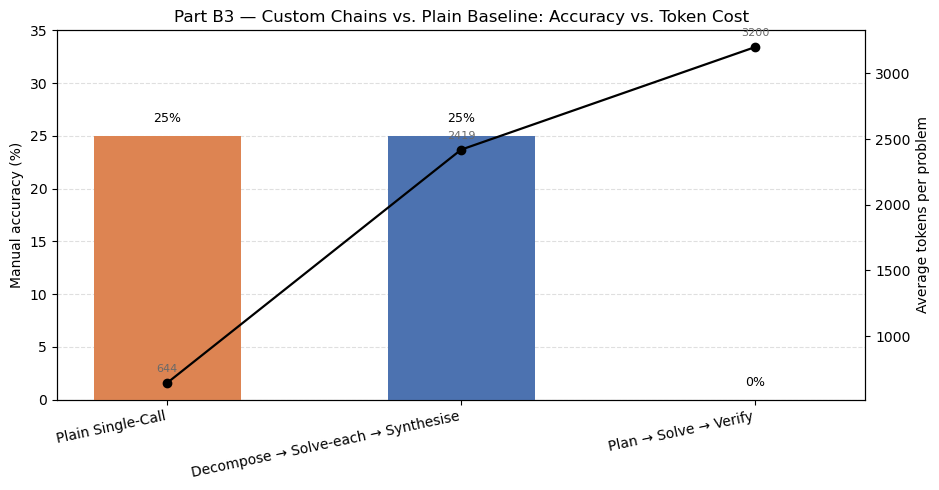

Both custom chains cost roughly 3x the model calls of the plain baseline; the chart makes it easy to see whether that expense converted into a matching accuracy gain for this benchmark, consistent with the written Section 8.10 analysis.


In [107]:
# Visualization — Part B3 custom-chain comparison
import matplotlib.pyplot as plt
import numpy as np

order = sorted(part_b_b3_technique_summary, key=lambda r: r["cost_quality_rank"])
techniques = [r["technique"] for r in order]
acc = [r["normalised_accuracy_percent"] for r in order]
tokens = [r["average_tokens_per_problem"] for r in order]

fig, ax1 = plt.subplots(figsize=(9.5, 5))
x = np.arange(len(techniques))
colors = ["#DD8452" if r["cost_quality_rank"] == 1 else "#4C72B0" for r in order]

bars = ax1.bar(x, acc, width=0.5, color=colors, zorder=3)
ax1.set_xticks(x)
ax1.set_xticklabels(techniques, rotation=12, ha="right")
ax1.set_ylabel("Manual accuracy (%)")
ax1.set_ylim(0, max(acc) * 1.4 if max(acc) > 0 else 10)
ax1.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax1.set_title("Part B3 — Custom Chains vs. Plain Baseline: Accuracy vs. Token Cost")

for xi, val in zip(x, acc):
    ax1.text(xi, val + 1.0, f"{val:.0f}%", ha="center", va="bottom", fontsize=9)

ax2 = ax1.twinx()
ax2.plot(x, tokens, color="black", marker="o", linewidth=1.6, zorder=4)
ax2.set_ylabel("Average tokens per problem")
for xi, val in zip(x, tokens):
    ax2.annotate(f"{val:.0f}", (xi, val), textcoords="offset points",
                 xytext=(0, 8), ha="center", fontsize=8, color="dimgray")

plt.tight_layout()
plt.show()

print(
    "Both custom chains cost roughly 3x the model calls of the plain baseline; "
    "the chart makes it easy to see whether that expense converted into a "
    "matching accuracy gain for this benchmark, consistent with the written "
    "Section 8.10 analysis."
)


In [108]:
# =================================================================================================
# PART C — SINGLE-CELL RESTART AND RUNTIME RECOVERY
#
# Execute this cell once after a kernel or notebook restart.
#
# This cell:
#   1. Restores all required paths and configuration.
#   2. Reloads the tokenizer, 4-bit base model, and PEFT adapter.
#   3. Restores the shared generation and parsing functions.
#   4. Reloads instruction_dataset.jsonl.
#   5. Reloads all saved Part A and Part B artifacts.
#   6. Reconstructs the same 10 benchmark queries.
#   7. Creates the Part C routing labels, routing table, and output paths.
#
# This cell DOES NOT rerun any Part A or Part B model experiments.
# =================================================================================================


# =================================================================================================
# 1. IMPORTS
# =================================================================================================

import csv
import json
import os
import re
import time

from datetime import datetime, timezone
from pathlib import Path

import torch
import transformers
import peft
import bitsandbytes
import accelerate
import datasets
import scipy
import numpy as np

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)

from peft import PeftModel


# =================================================================================================
# 2. FIXED PROJECT PATHS
# =================================================================================================

existing_assignment_root = globals().get(
    "ASSIGNMENT2A_ROOT"
)

ASSIGNMENT2A_ROOT = (
    Path(existing_assignment_root)
    if existing_assignment_root
    else Path(
        "/home/jovyan/llmlab/assignment2a_workspace_20260731_182730"
    )
)

DATA_DIR = (
    ASSIGNMENT2A_ROOT
    / "data"
)

OUTPUTS_DIR = (
    ASSIGNMENT2A_ROOT
    / "outputs"
)

REPORTS_DIR = (
    ASSIGNMENT2A_ROOT
    / "reports"
)

BENCHMARKS_DIR = (
    ASSIGNMENT2A_ROOT
    / "benchmarks"
)


for directory in [
    ASSIGNMENT2A_ROOT,
    DATA_DIR,
    OUTPUTS_DIR,
    REPORTS_DIR,
    BENCHMARKS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


part_c_write_test = (
    DATA_DIR
    / ".part_c_runtime_write_test"
)

part_c_write_test.write_text(
    "Part C runtime write test",
    encoding="utf-8",
)

part_c_write_test.unlink()


# =================================================================================================
# 3. MODEL, ADAPTER, AND DATASET PATHS
# =================================================================================================

BASE_MODEL_NAME = (
    "Qwen/Qwen2.5-3B-Instruct"
)

ADAPTER_DIR = Path(
    "/home/jovyan/llmlab/adapters/qwen2_5_3b_adapter_b"
)

DATASET_PATH = Path(
    "/home/jovyan/llmlab/data/instruction_dataset.jsonl"
)


# =================================================================================================
# 4. SHARED INFERENCE CONFIGURATION
# =================================================================================================

INFERENCE_CONFIG = {
    "max_new_tokens": 300,
    "do_sample": False,
    "num_beams": 1,
    "use_cache": True,
}


PART_C_CONFIG = {
    "classifier_max_new_tokens": 24,
    "default_pattern_max_new_tokens": 300,
    "few_shot_count": 3,
    "self_consistency_sample_count": 5,
    "self_consistency_temperature": 0.80,
    "self_consistency_top_p": 0.90,
    "self_consistency_top_k": 50,
    "self_consistency_seeds": [
        101,
        202,
        303,
        404,
        505,
    ],
}


# =================================================================================================
# 5. PART C OUTPUT DIRECTORIES
# =================================================================================================

PART_C_OUTPUTS_DIR = (
    OUTPUTS_DIR
    / "part_c"
)

PART_C_REPORTS_DIR = (
    REPORTS_DIR
    / "part_c"
)

PART_C_BENCHMARKS_DIR = (
    BENCHMARKS_DIR
    / "part_c"
)


for directory in [
    PART_C_OUTPUTS_DIR,
    PART_C_REPORTS_DIR,
    PART_C_BENCHMARKS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# =================================================================================================
# 6. PART C ARTIFACT PATHS
# =================================================================================================

PART_C_CLASSIFIER_RESULTS_PATH = (
    PART_C_BENCHMARKS_DIR
    / "part_c_classifier_results.json"
)

PART_C_CLASSIFIER_RESULTS_CSV_PATH = (
    PART_C_BENCHMARKS_DIR
    / "part_c_classifier_results.csv"
)

PART_C_ROUTER_RESULTS_PATH = (
    PART_C_BENCHMARKS_DIR
    / "part_c_router_results.json"
)

PART_C_ROUTER_RESULTS_CSV_PATH = (
    PART_C_BENCHMARKS_DIR
    / "part_c_router_results.csv"
)

PART_C_ROUTER_CHECKPOINT_PATH = (
    PART_C_BENCHMARKS_DIR
    / "part_c_router_checkpoint.json"
)

PART_C_COST_QUALITY_PATH = (
    PART_C_REPORTS_DIR
    / "part_c_cost_quality_analysis.json"
)

PART_C_COST_QUALITY_CSV_PATH = (
    PART_C_REPORTS_DIR
    / "part_c_cost_quality_analysis.csv"
)

PART_C_FINAL_ANALYSIS_PATH = (
    PART_C_REPORTS_DIR
    / "part_c_final_100_word_analysis.md"
)


# =================================================================================================
# 7. CUDA SYNCHRONISATION HELPER
# =================================================================================================

def synchronise_cuda_if_needed(
    device=None,
):
    """
    Synchronise CUDA only when CUDA is available and active.
    """

    if not torch.cuda.is_available():
        return

    try:
        if device is None:
            torch.cuda.synchronize()

        elif torch.device(
            device
        ).type == "cuda":
            torch.cuda.synchronize(
                device
            )

    except Exception:
        torch.cuda.synchronize()


def current_utc_timestamp():
    """
    Return the current UTC timestamp.
    """

    return datetime.now(
        timezone.utc
    ).isoformat()


# =================================================================================================
# 8. HUGGING FACE CACHE-FIRST LOADER
# =================================================================================================

def from_pretrained_with_cache_fallback(
    loader,
    model_or_path,
    **kwargs,
):
    """
    Try the existing local Hugging Face cache first.

    Use the standard loader only when the local cache is incomplete.
    """

    try:
        return loader.from_pretrained(
            model_or_path,
            local_files_only=True,
            **kwargs,
        )

    except Exception as local_error:
        print(
            "Local-only loading was incomplete. "
            "Retrying with the standard loader."
        )

        print(
            f"Reason: "
            f"{type(local_error).__name__}"
        )

        return loader.from_pretrained(
            model_or_path,
            **kwargs,
        )


# =================================================================================================
# 9. LOAD TOKENIZER
# =================================================================================================

if (
    "tokenizer" not in globals()
    or tokenizer is None
    or not callable(
        getattr(
            tokenizer,
            "apply_chat_template",
            None,
        )
    )
):
    print(
        "Loading tokenizer..."
    )

    tokenizer = (
        from_pretrained_with_cache_fallback(
            AutoTokenizer,
            BASE_MODEL_NAME,
            use_fast=False,
            trust_remote_code=True,
        )
    )


if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = (
        tokenizer.eos_token_id
    )


# =================================================================================================
# 10. LOAD 4-BIT BASE MODEL AND PEFT ADAPTER
# =================================================================================================

if (
    "adapted_model" not in globals()
    or adapted_model is None
    or not callable(
        getattr(
            adapted_model,
            "generate",
            None,
        )
    )
):
    print(
        "Loading 4-bit base model..."
    )

    quantization_config = (
        BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=(
                torch.bfloat16
            ),
        )
    )


    base_model = (
        from_pretrained_with_cache_fallback(
            AutoModelForCausalLM,
            BASE_MODEL_NAME,
            quantization_config=(
                quantization_config
            ),
            device_map="auto",
            torch_dtype=(
                torch.bfloat16
            ),
            low_cpu_mem_usage=True,
            trust_remote_code=True,
        )
    )


    print(
        "Loading PEFT adapter..."
    )

    adapted_model = (
        PeftModel.from_pretrained(
            base_model,
            str(
                ADAPTER_DIR
            ),
            is_trainable=False,
        )
    )


    adapted_model.eval()

else:
    print(
        "Reusing the model already loaded "
        "in the current kernel."
    )

    adapted_model.eval()


    if "base_model" not in globals():
        try:
            base_model = (
                adapted_model.get_base_model()
            )

        except Exception:
            base_model = None


# Standard aliases used by earlier Part B cells.
PART_B_MODEL = adapted_model
PART_B_TOKENIZER = tokenizer
model = adapted_model


# =================================================================================================
# 11. SHARED CHAT-MESSAGE BUILDER
# =================================================================================================

def build_chat_messages(
    user_prompt,
    system_prompt=None,
):
    """
    Build chat-template messages for Qwen.
    """

    if not str(
        user_prompt
    ).strip():
        raise ValueError(
            "The user prompt cannot be empty."
        )


    messages = []


    if (
        system_prompt is not None
        and str(
            system_prompt
        ).strip()
    ):
        messages.append(
            {
                "role": "system",
                "content": str(
                    system_prompt
                ).strip(),
            }
        )


    messages.append(
        {
            "role": "user",
            "content": str(
                user_prompt
            ).strip(),
        }
    )


    return messages


# =================================================================================================
# 12. SHARED DETERMINISTIC GENERATION FUNCTION
# =================================================================================================

def generate_with_metrics(
    user_prompt,
    system_prompt=None,
    max_new_tokens=None,
):
    """
    Generate one deterministic response and return detailed metrics.

    Returns
    -------
    answer : str

    metrics : dict
        Input tokens, output tokens, total tokens, latency,
        throughput, decoding mode, and cap status.
    """

    if not str(
        user_prompt
    ).strip():
        raise ValueError(
            "The user prompt cannot be empty."
        )


    generation_limit = (
        int(
            max_new_tokens
        )
        if max_new_tokens is not None
        else int(
            INFERENCE_CONFIG[
                "max_new_tokens"
            ]
        )
    )


    messages = build_chat_messages(
        user_prompt=user_prompt,
        system_prompt=system_prompt,
    )


    model_inputs = (
        tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors="pt",
            return_dict=True,
        )
    )


    model_device = next(
        adapted_model.parameters()
    ).device


    model_inputs = {
        name: tensor.to(
            model_device
        )
        for name, tensor
        in model_inputs.items()
    }


    input_token_count = int(
        model_inputs[
            "input_ids"
        ].shape[-1]
    )


    generation_arguments = {
        "max_new_tokens": (
            generation_limit
        ),
        "do_sample": False,
        "num_beams": 1,
        "use_cache": True,
        "pad_token_id": (
            tokenizer.pad_token_id
        ),
        "eos_token_id": (
            tokenizer.eos_token_id
        ),
    }


    synchronise_cuda_if_needed(
        model_device
    )


    start_time = (
        time.perf_counter()
    )


    with torch.inference_mode():
        generated_sequences = (
            adapted_model.generate(
                **model_inputs,
                **generation_arguments,
            )
        )


    synchronise_cuda_if_needed(
        model_device
    )


    latency_seconds = (
        time.perf_counter()
        - start_time
    )


    generated_token_ids = (
        generated_sequences[
            0,
            input_token_count:,
        ]
    )


    output_token_count = int(
        generated_token_ids.shape[-1]
    )


    answer = tokenizer.decode(
        generated_token_ids,
        skip_special_tokens=True,
    ).strip()


    total_token_count = (
        input_token_count
        + output_token_count
    )


    output_tokens_per_second = (
        output_token_count
        / latency_seconds
        if latency_seconds > 0
        else 0.0
    )


    metrics = {
        "input_tokens": (
            input_token_count
        ),
        "output_tokens": (
            output_token_count
        ),
        "total_tokens": (
            total_token_count
        ),
        "latency_sec": round(
            latency_seconds,
            4,
        ),
        "output_tokens_per_sec": round(
            output_tokens_per_second,
            4,
        ),
        "max_new_tokens": (
            generation_limit
        ),
        "decoding": "greedy",
        "generation_capped": (
            output_token_count
            >= generation_limit
        ),
    }


    return answer, metrics


# =================================================================================================
# 13. TEXT-ONLY GENERATION COMPATIBILITY FUNCTION
# =================================================================================================

def generate(
    prompt,
    system_prompt=None,
):
    """
    Compatibility wrapper returning response text only.
    """

    answer, _ = generate_with_metrics(
        user_prompt=prompt,
        system_prompt=system_prompt,
    )

    return answer


# =================================================================================================
# 14. NORMALISE GENERATION RESULTS
# =================================================================================================

def normalise_generation_result(
    raw_result,
):
    """
    Convert tuple, dictionary, or string generation output into one
    canonical result structure.
    """

    if isinstance(
        raw_result,
        tuple,
    ):
        if (
            len(
                raw_result
            )
            == 2
            and isinstance(
                raw_result[1],
                dict,
            )
        ):
            result = {
                "generated_response": (
                    raw_result[0]
                ),
                **raw_result[1],
            }

        elif len(
            raw_result
        ) == 2:
            result = {
                "generated_response": (
                    raw_result[0]
                ),
                "latency_sec": (
                    raw_result[1]
                ),
            }

        else:
            raise TypeError(
                "Unsupported generation tuple."
            )


    elif isinstance(
        raw_result,
        dict,
    ):
        result = dict(
            raw_result
        )


    elif isinstance(
        raw_result,
        str,
    ):
        result = {
            "generated_response": (
                raw_result
            )
        }


    else:
        raise TypeError(
            "Unsupported generation result type: "
            f"{type(raw_result).__name__}"
        )


    response_text = None


    for key in [
        "generated_response",
        "response",
        "answer",
        "text",
        "output",
        "content",
    ]:
        value = result.get(
            key
        )

        if isinstance(
            value,
            str,
        ):
            response_text = (
                value.strip()
            )

            break


    if response_text is None:
        raise KeyError(
            "No generated response text "
            "was found."
        )


    input_tokens = int(
        result.get(
            "input_tokens",
            result.get(
                "prompt_tokens",
                0,
            ),
        )
        or 0
    )


    output_tokens = int(
        result.get(
            "output_tokens",
            result.get(
                "completion_tokens",
                0,
            ),
        )
        or 0
    )


    total_tokens = int(
        result.get(
            "total_tokens",
            (
                input_tokens
                + output_tokens
            ),
        )
        or (
            input_tokens
            + output_tokens
        )
    )


    latency_sec = float(
        result.get(
            "latency_sec",
            result.get(
                "latency",
                0.0,
            ),
        )
        or 0.0
    )


    return {
        "generated_response": (
            response_text
        ),
        "input_tokens": (
            input_tokens
        ),
        "output_tokens": (
            output_tokens
        ),
        "total_tokens": (
            total_tokens
        ),
        "latency_sec": round(
            latency_sec,
            4,
        ),
        "max_new_tokens": (
            result.get(
                "max_new_tokens"
            )
        ),
        "generation_capped": bool(
            result.get(
                "generation_capped",
                False,
            )
        ),
    }


# =================================================================================================
# 15. DERIVED OUTPUT-CAP CHECK
# =================================================================================================

def apply_derived_generation_cap(
    metrics,
    max_new_tokens,
):
    """
    Treat a response as capped when its output-token count equals or
    exceeds the configured maximum.
    """

    corrected_metrics = dict(
        metrics
    )


    corrected_metrics[
        "reported_generation_capped"
    ] = bool(
        corrected_metrics.get(
            "generation_capped",
            False,
        )
    )


    corrected_metrics[
        "derived_generation_capped"
    ] = bool(
        corrected_metrics[
            "reported_generation_capped"
        ]
        or int(
            corrected_metrics.get(
                "output_tokens",
                0,
            )
        )
        >= int(
            max_new_tokens
        )
    )


    corrected_metrics[
        "generation_capped"
    ] = corrected_metrics[
        "derived_generation_capped"
    ]


    return corrected_metrics


# =================================================================================================
# 16. BALANCED JSON OBJECT EXTRACTION
# =================================================================================================

def extract_first_json_object(
    text,
):
    """
    Extract the first valid balanced JSON object from model output.
    """

    cleaned_text = str(
        text
    ).strip()


    fenced_match = re.search(
        r"```(?:json)?\s*(\{.*?\})\s*```",
        cleaned_text,
        flags=(
            re.IGNORECASE
            | re.DOTALL
        ),
    )


    if fenced_match:
        cleaned_text = (
            fenced_match.group(1)
        )


    try:
        parsed = json.loads(
            cleaned_text
        )

        if isinstance(
            parsed,
            dict,
        ):
            return parsed

    except json.JSONDecodeError:
        pass


    start_index = (
        cleaned_text.find(
            "{"
        )
    )


    if start_index < 0:
        return None


    depth = 0
    in_string = False
    escaped = False


    for index in range(
        start_index,
        len(
            cleaned_text
        ),
    ):
        character = cleaned_text[
            index
        ]


        if escaped:
            escaped = False
            continue


        if character == "\\":
            escaped = True
            continue


        if character == '"':
            in_string = not in_string
            continue


        if in_string:
            continue


        if character == "{":
            depth += 1


        elif character == "}":
            depth -= 1


            if depth == 0:
                candidate = cleaned_text[
                    start_index:
                    index + 1
                ]


                try:
                    parsed = json.loads(
                        candidate
                    )

                    if isinstance(
                        parsed,
                        dict,
                    ):
                        return parsed

                except json.JSONDecodeError:
                    return None


    return None


# =================================================================================================
# 17. GENERIC JSON FILE LOADER
# =================================================================================================

def load_json_if_exists(
    path,
    default=None,
):
    """
    Load a JSON artifact when present.
    """

    path = Path(
        path
    )


    if not path.exists():
        return default


    with path.open(
        "r",
        encoding="utf-8",
    ) as file:
        return json.load(
            file
        )


# =================================================================================================
# 18. JSONL DATASET LOADER
# =================================================================================================

def load_jsonl(
    path,
):
    """
    Load JSON Lines records.
    """

    records = []


    with Path(
        path
    ).open(
        "r",
        encoding="utf-8",
    ) as file:
        for line_number, line in enumerate(
            file,
            start=1,
        ):
            stripped_line = (
                line.strip()
            )


            if not stripped_line:
                continue


            try:
                record = json.loads(
                    stripped_line
                )

            except json.JSONDecodeError as error:
                raise ValueError(
                    "Invalid JSONL record "
                    f"at line {line_number}: "
                    f"{error}"
                ) from error


            records.append(
                record
            )


    return records


instruction_dataset_records = (
    load_jsonl(
        DATASET_PATH
    )
)


# =================================================================================================
# 19. DATASET FIELD EXTRACTION
# =================================================================================================

DATASET_QUERY_KEYS = [
    "instruction",
    "query",
    "question",
    "prompt",
    "user_prompt",
    "text",
]

DATASET_INPUT_KEYS = [
    "input",
    "context",
]

DATASET_ANSWER_KEYS = [
    "output",
    "answer",
    "response",
    "completion",
    "target",
    "assistant_response",
]


def first_nonempty_value(
    record,
    keys,
):
    """
    Return the first non-empty scalar value for the supplied keys.
    """

    for key in keys:
        value = record.get(
            key
        )


        if value is None:
            continue


        if isinstance(
            value,
            (
                str,
                int,
                float,
            ),
        ):
            text = str(
                value
            ).strip()


            if text:
                return text


    return None


def extract_dataset_query(
    record,
):
    """
    Construct one query from common instruction-dataset fields.
    """

    instruction = first_nonempty_value(
        record,
        DATASET_QUERY_KEYS,
    )


    input_text = first_nonempty_value(
        record,
        DATASET_INPUT_KEYS,
    )


    if (
        instruction
        and input_text
    ):
        return (
            f"{instruction}\n\n"
            f"Context:\n"
            f"{input_text}"
        ).strip()


    return (
        instruction
        or input_text
        or ""
    ).strip()


def extract_dataset_answer(
    record,
):
    """
    Extract the known answer from a dataset record.
    """

    return (
        first_nonempty_value(
            record,
            DATASET_ANSWER_KEYS,
        )
        or ""
    ).strip()


dataset_examples = [
    {
        "query": (
            extract_dataset_query(
                record
            )
        ),
        "answer": (
            extract_dataset_answer(
                record
            )
        ),
        "raw_record": (
            record
        ),
    }
    for record
    in instruction_dataset_records
]


dataset_examples = [
    example
    for example in dataset_examples
    if example["query"]
]


# =================================================================================================
# 20. SAVED PART A ARTIFACT PATHS
# =================================================================================================

PART_A_SCORED_RESULTS_PATH = (
    BENCHMARKS_DIR
    / "part_a_scored_results.json"
)

PART_A_SCORED_RESULTS_CSV_PATH = (
    BENCHMARKS_DIR
    / "part_a_scored_results.csv"
)

PART_A_PATTERN_SUMMARY_PATH = (
    REPORTS_DIR
    / "part_a_pattern_summary.json"
)

PART_A_PATTERN_SUMMARY_CSV_PATH = (
    REPORTS_DIR
    / "part_a_pattern_summary.csv"
)

PART_A_ACCURACY_MATRIX_PATH = (
    REPORTS_DIR
    / "part_a_accuracy_score_matrix.csv"
)

PART_A_COMPARATIVE_ANALYSIS_PATH = (
    REPORTS_DIR
    / "part_a_comparative_analysis.json"
)

PART_A_COMPARATIVE_ANALYSIS_MD_PATH = (
    REPORTS_DIR
    / "part_a_comparative_analysis.md"
)


# =================================================================================================
# 21. SAVED PART B ARTIFACT PATHS
# =================================================================================================

PART_B_MULTISTEP_PROBLEMS_PATH = (
    DATA_DIR
    / "part_b_multistep_problems.json"
)

PART_B_BASELINE_COT_JSON_PATH = (
    BENCHMARKS_DIR
    / "part_b_baseline_cot_results.json"
)

PART_B_TOT_RESULTS_JSON_PATH = (
    BENCHMARKS_DIR
    / "part_b_tree_of_thought_results.json"
)

PART_B_SELF_CONSISTENCY_JSON_PATH = (
    BENCHMARKS_DIR
    / "part_b_self_consistency_results.json"
)

PART_B_B1_COMPARISON_PATH = (
    REPORTS_DIR
    / "part_b_b1_reasoning_comparison.json"
)

PART_B_REACT_RESULT_PATH = (
    BENCHMARKS_DIR
    / "part_b_react_result.json"
)

PART_B_PSV_RESULTS_PATH = (
    BENCHMARKS_DIR
    / "part_b_plan_solve_verify_results.json"
)

PART_B_DSS_RESULTS_PATH = (
    BENCHMARKS_DIR
    / "part_b_decompose_solve_synthesise_results.json"
)

PART_B_B3_COMPARISON_PATH = (
    REPORTS_DIR
    / "part_b_b3_custom_chain_comparison.json"
)


# =================================================================================================
# 22. LOAD ALL PART A ARTIFACTS
# =================================================================================================

part_a_scored_results = (
    load_json_if_exists(
        PART_A_SCORED_RESULTS_PATH,
        default=[],
    )
)

part_a_pattern_summary = (
    load_json_if_exists(
        PART_A_PATTERN_SUMMARY_PATH,
        default={},
    )
)

part_a_comparative_analysis = (
    load_json_if_exists(
        PART_A_COMPARATIVE_ANALYSIS_PATH,
        default={},
    )
)


# =================================================================================================
# 23. LOAD ALL PART B ARTIFACTS
# =================================================================================================

part_b_multistep_problems = (
    load_json_if_exists(
        PART_B_MULTISTEP_PROBLEMS_PATH,
        default=[],
    )
)

part_b_baseline_cot_results = (
    load_json_if_exists(
        PART_B_BASELINE_COT_JSON_PATH,
        default=[],
    )
)

part_b_tot_results = (
    load_json_if_exists(
        PART_B_TOT_RESULTS_JSON_PATH,
        default=[],
    )
)

part_b_self_consistency_results = (
    load_json_if_exists(
        PART_B_SELF_CONSISTENCY_JSON_PATH,
        default=[],
    )
)

part_b_b1_comparison = (
    load_json_if_exists(
        PART_B_B1_COMPARISON_PATH,
        default={},
    )
)

part_b_react_result = (
    load_json_if_exists(
        PART_B_REACT_RESULT_PATH,
        default={},
    )
)

part_b_psv_results = (
    load_json_if_exists(
        PART_B_PSV_RESULTS_PATH,
        default=[],
    )
)

part_b_dss_results = (
    load_json_if_exists(
        PART_B_DSS_RESULTS_PATH,
        default=[],
    )
)

part_b_b3_comparison = (
    load_json_if_exists(
        PART_B_B3_COMPARISON_PATH,
        default={},
    )
)


# =================================================================================================
# 24. NESTED-DICTIONARY ITERATOR
# =================================================================================================

def walk_nested_dicts(
    value,
):
    """
    Yield every dictionary contained in a nested JSON structure.
    """

    if isinstance(
        value,
        dict,
    ):
        yield value


        for nested_value in value.values():
            yield from walk_nested_dicts(
                nested_value
            )


    elif isinstance(
        value,
        list,
    ):
        for nested_value in value:
            yield from walk_nested_dicts(
                nested_value
            )


# =================================================================================================
# 25. TEXT NORMALISATION
# =================================================================================================

def normalise_text_key(
    text,
):
    """
    Normalise text for deterministic matching and deduplication.
    """

    return re.sub(
        r"\s+",
        " ",
        str(
            text
        ).strip().lower(),
    )


# =================================================================================================
# 26. RECONSTRUCT THE SAME TEN BENCHMARK QUERIES
# =================================================================================================

BENCHMARK_ID_KEYS = [
    "benchmark_id",
    "query_id",
    "id",
    "question_id",
]

BENCHMARK_QUERY_KEYS = [
    "query",
    "question",
    "instruction",
    "prompt",
    "user_prompt",
]

BENCHMARK_ANSWER_KEYS = [
    "reference_answer",
    "expected_answer",
    "known_answer",
    "ground_truth",
    "target_answer",
    "answer",
    "output",
]


dataset_answer_lookup = {
    normalise_text_key(
        example["query"]
    ): example["answer"]
    for example in dataset_examples
    if example["answer"]
}


benchmark_candidate_records = []


for dictionary in walk_nested_dicts(
    part_a_scored_results
):
    query_text = first_nonempty_value(
        dictionary,
        BENCHMARK_QUERY_KEYS,
    )


    if not query_text:
        continue


    benchmark_id = first_nonempty_value(
        dictionary,
        BENCHMARK_ID_KEYS,
    )


    expected_answer = first_nonempty_value(
        dictionary,
        BENCHMARK_ANSWER_KEYS,
    )


    if not expected_answer:
        expected_answer = (
            dataset_answer_lookup.get(
                normalise_text_key(
                    query_text
                ),
                "",
            )
        )


    benchmark_candidate_records.append(
        {
            "benchmark_id": (
                benchmark_id
                or ""
            ),
            "query": (
                query_text.strip()
            ),
            "expected_answer": (
                expected_answer
                or ""
            ).strip(),
        }
    )


# Deduplicate the fifty Part A pattern results into ten queries.
benchmark_records = []
seen_benchmark_keys = set()


for candidate in benchmark_candidate_records:
    dedupe_key = (
        candidate[
            "benchmark_id"
        ]
        or normalise_text_key(
            candidate[
                "query"
            ]
        )
    )


    if dedupe_key in seen_benchmark_keys:
        continue


    seen_benchmark_keys.add(
        dedupe_key
    )


    benchmark_records.append(
        candidate
    )


def benchmark_sort_key(
    record,
):
    """
    Sort BQ01 through BQ10 numerically.
    """

    identifier = record.get(
        "benchmark_id",
        "",
    )


    match = re.search(
        r"(\d+)",
        str(
            identifier
        ),
    )


    if match:
        return (
            0,
            int(
                match.group(1)
            ),
        )


    return (
        1,
        record[
            "query"
        ],
    )


benchmark_records = sorted(
    benchmark_records,
    key=benchmark_sort_key,
)


# Use the first ten dataset records only as an emergency fallback.
benchmark_fallback_used = False


if len(
    benchmark_records
) < 10:
    benchmark_fallback_used = True

    benchmark_records = [
        {
            "benchmark_id": (
                f"BQ{index:02d}"
            ),
            "query": (
                example["query"]
            ),
            "expected_answer": (
                example["answer"]
            ),
        }
        for index, example in enumerate(
            dataset_examples[:10],
            start=1,
        )
    ]


benchmark_records = (
    benchmark_records[:10]
)


for index, record in enumerate(
    benchmark_records,
    start=1,
):
    if not record[
        "benchmark_id"
    ]:
        record[
            "benchmark_id"
        ] = f"BQ{index:02d}"


benchmark_queries = [
    record["query"]
    for record in benchmark_records
]


benchmark_reference_answers = {
    record["benchmark_id"]: (
        record[
            "expected_answer"
        ]
    )
    for record in benchmark_records
}


benchmark_query_lookup = {
    record["benchmark_id"]: (
        record["query"]
    )
    for record in benchmark_records
}


# Compatibility aliases for future Part C cells.
PART_C_EXPECTED_LABELS_BY_ID = {
    "BQ01": "SIMPLE_FACTUAL",
    "BQ02": "HIGH_STAKES_VERIFICATION",
    "BQ03": "MULTI_STEP_REASONING",
    "BQ04": "TOOL_OR_CALCULATION",
    "BQ05": "MULTI_STEP_REASONING",
    "BQ06": "HIGH_VARIANCE_CONSENSUS",
    "BQ07": "STRUCTURED_EXTRACTION",
    "BQ08": "NEEDS_WORKED_EXAMPLES",
    "BQ09": "MULTI_STEP_REASONING",
    "BQ10": "SIMPLE_FACTUAL",
}

PART_C_EXPECTED_ROUTES_BY_ID = {
    "BQ01": "Zero-Shot",
    "BQ02": "Plan-Solve-Verify",
    "BQ03": "Chain-of-Thought",
    "BQ04": "ReAct",
    "BQ05": "Chain-of-Thought",
    "BQ06": "Self-Consistency",
    "BQ07": "Function-Calling",
    "BQ08": "Few-Shot",
    "BQ09": "Chain-of-Thought",
    "BQ10": "Zero-Shot",
}

for record in benchmark_records:
    benchmark_id = str(record.get("benchmark_id", "")).strip()
    record["expected_query_label"] = (
        PART_C_EXPECTED_LABELS_BY_ID.get(benchmark_id)
    )
    record["expected_route"] = (
        PART_C_EXPECTED_ROUTES_BY_ID.get(benchmark_id)
    )

part_c_benchmark_records = benchmark_records
part_c_benchmark_queries = benchmark_queries


# =================================================================================================
# 27. RECONSTRUCT ZERO-SHOT PART A RESULTS BY QUERY
# =================================================================================================

part_a_zero_shot_by_query = {}


for dictionary in walk_nested_dicts(
    part_a_scored_results
):
    pattern_name = first_nonempty_value(
        dictionary,
        [
            "pattern",
            "technique",
            "method",
            "route",
        ],
    )


    query_text = first_nonempty_value(
        dictionary,
        BENCHMARK_QUERY_KEYS,
    )


    if (
        not pattern_name
        or not query_text
    ):
        continue


    if normalise_text_key(
        pattern_name
    ) not in {
        "zero-shot",
        "zero shot",
        "zeroshot",
    }:
        continue


    part_a_zero_shot_by_query[
        normalise_text_key(
            query_text
        )
    ] = dictionary


# =================================================================================================
# 28. PART C CLASSIFIER LABELS
# =================================================================================================

PART_C_QUERY_LABELS = [
    "SIMPLE_FACTUAL",
    "NEEDS_WORKED_EXAMPLES",
    "STRUCTURED_EXTRACTION",
    "MULTI_STEP_REASONING",
    "COMPLEX_ALTERNATIVES",
    "HIGH_VARIANCE_CONSENSUS",
    "TOOL_OR_CALCULATION",
    "HIGH_STAKES_VERIFICATION",
]


# =================================================================================================
# 29. PART C REQUIRED ROUTING TABLE
# =================================================================================================

PART_C_ROUTING_TABLE = {
    "SIMPLE_FACTUAL": (
        "Zero-Shot"
    ),
    "NEEDS_WORKED_EXAMPLES": (
        "Few-Shot"
    ),
    "STRUCTURED_EXTRACTION": (
        "Function-Calling"
    ),
    "MULTI_STEP_REASONING": (
        "Chain-of-Thought"
    ),
    "COMPLEX_ALTERNATIVES": (
        "Tree-of-Thought"
    ),
    "HIGH_VARIANCE_CONSENSUS": (
        "Self-Consistency"
    ),
    "TOOL_OR_CALCULATION": (
        "ReAct"
    ),
    "HIGH_STAKES_VERIFICATION": (
        "Plan-Solve-Verify"
    ),
}


# =================================================================================================
# 30. INITIAL FIVE-QUERY CLASSIFIER TEST SET
# =================================================================================================

PART_C_CLASSIFIER_TEST_QUERIES = [
    {
        "test_id": "CT01",
        "query": (
            "What command displays the current "
            "Linux kernel version?"
        ),
        "expected_label": (
            "SIMPLE_FACTUAL"
        ),
    },
    {
        "test_id": "CT02",
        "query": (
            "Using three worked examples, show how "
            "to classify Linux service failures by symptom."
        ),
        "expected_label": (
            "NEEDS_WORKED_EXAMPLES"
        ),
    },
    {
        "test_id": "CT03",
        "query": (
            "Extract the service name, host, severity, "
            "and timestamp from this incident text and "
            "return JSON."
        ),
        "expected_label": (
            "STRUCTURED_EXTRACTION"
        ),
    },
    {
        "test_id": "CT04",
        "query": (
            "A VPN handshake succeeds but traffic cannot "
            "reach internal services. Diagnose the ordered "
            "network path."
        ),
        "expected_label": (
            "MULTI_STEP_REASONING"
        ),
    },
    {
        "test_id": "CT05",
        "query": (
            "An administrator account may be compromised. "
            "Build a containment and recovery plan with "
            "independent verification before reconnection."
        ),
        "expected_label": (
            "HIGH_STAKES_VERIFICATION"
        ),
    },
]


# =================================================================================================
# 31. PART C CLASSIFIER SYSTEM PROMPT
# =================================================================================================

PART_C_CLASSIFIER_SYSTEM_PROMPT = f"""
You are a query-routing classifier.

Return exactly one label and no explanation.

Allowed labels:
{chr(10).join(PART_C_QUERY_LABELS)}

Classification guide:

SIMPLE_FACTUAL
A direct factual query requiring no examples, external tool,
multi-step reasoning, alternatives, consensus, or verification chain.

NEEDS_WORKED_EXAMPLES
A query whose answer quality depends on demonstrations or worked examples.

STRUCTURED_EXTRACTION
A task requiring fixed JSON fields, schema-constrained output,
or entity extraction.

MULTI_STEP_REASONING
A query requiring several ordered reasoning steps with one main path.

COMPLEX_ALTERNATIVES
A query requiring comparison or scoring of several competing approaches.

HIGH_VARIANCE_CONSENSUS
A query where multiple sampled answers and consensus are valuable.

TOOL_OR_CALCULATION
A query requiring a calculator, local function, or external observation.

HIGH_STAKES_VERIFICATION
A high-risk query where an incorrect answer is costly and an independent
verification stage is necessary.
""".strip()


# =================================================================================================
# 32. CLASSIFIER LABEL PARSER
# =================================================================================================

def parse_part_c_label(
    response_text,
):
    """
    Parse exactly one permitted Part C classification label.
    """

    upper_text = str(
        response_text
    ).strip().upper()


    label_tokens = re.findall(
        r"[A-Z][A-Z0-9_]+",
        upper_text,
    )


    for label_token in label_tokens:
        if label_token in PART_C_QUERY_LABELS:
            return label_token


    return None


# =================================================================================================
# 33. BOOTSTRAP VALIDATION
# =================================================================================================

part_c_bootstrap_validation = {
    "Workspace root exists": (
        ASSIGNMENT2A_ROOT.exists()
    ),
    "Dataset file exists": (
        DATASET_PATH.exists()
    ),
    "Adapter directory exists": (
        ADAPTER_DIR.exists()
    ),
    "Tokenizer is ready": (
        callable(
            getattr(
                tokenizer,
                "apply_chat_template",
                None,
            )
        )
    ),
    "Adapted model is ready": (
        callable(
            getattr(
                adapted_model,
                "generate",
                None,
            )
        )
    ),
    "Dataset records loaded": (
        len(
            instruction_dataset_records
        )
        > 0
    ),
    "Exactly ten benchmark queries recovered": (
        len(
            benchmark_records
        )
        == 10
    ),
    "Eight classifier labels are defined": (
        len(
            PART_C_QUERY_LABELS
        )
        == 8
    ),
    "Eight routing mappings are defined": (
        len(
            PART_C_ROUTING_TABLE
        )
        == 8
    ),
    "Five classifier test queries are available": (
        len(
            PART_C_CLASSIFIER_TEST_QUERIES
        )
        == 5
    ),
    "Part A scored results loaded": bool(
        part_a_scored_results
    ),
    "Part A pattern summary loaded": bool(
        part_a_pattern_summary
    ),
    "Part B baseline and CoT results loaded": bool(
        part_b_baseline_cot_results
    ),
    "Part B ToT results loaded": bool(
        part_b_tot_results
    ),
    "Part B Self-Consistency results loaded": bool(
        part_b_self_consistency_results
    ),
    "Part B1 comparison loaded": bool(
        part_b_b1_comparison
    ),
    "Part B ReAct result loaded": bool(
        part_b_react_result
    ),
    "Part B PSV results loaded": bool(
        part_b_psv_results
    ),
    "Part B DSS results loaded": bool(
        part_b_dss_results
    ),
    "Part B3 comparison loaded": bool(
        part_b_b3_comparison
    ),
}


# =================================================================================================
# 34. DISPLAY RUNTIME STATUS
# =================================================================================================

print(
    "PART C — SINGLE-CELL RUNTIME RECOVERY"
)

print("=" * 125)


print(
    f"Workspace              : "
    f"{ASSIGNMENT2A_ROOT}"
)

print(
    f"Python                 : "
    f"{os.sys.version.split()[0]}"
)

print(
    f"Torch                  : "
    f"{torch.__version__}"
)

print(
    f"Transformers           : "
    f"{transformers.__version__}"
)

print(
    f"PEFT                   : "
    f"{peft.__version__}"
)

print(
    f"BitsAndBytes           : "
    f"{bitsandbytes.__version__}"
)

print(
    f"CUDA available         : "
    f"{torch.cuda.is_available()}"
)


if torch.cuda.is_available():
    print(
        f"CUDA device            : "
        f"{torch.cuda.get_device_name(0)}"
    )


print(
    f"Model class            : "
    f"{type(adapted_model).__name__}"
)

print(
    f"Tokenizer class        : "
    f"{type(tokenizer).__name__}"
)

print(
    f"Model device           : "
    f"{next(adapted_model.parameters()).device}"
)

print(
    f"Dataset records        : "
    f"{len(instruction_dataset_records)}"
)

print(
    f"Benchmark queries      : "
    f"{len(benchmark_records)}"
)

print(
    f"Benchmark fallback used: "
    f"{benchmark_fallback_used}"
)


# =================================================================================================
# 35. DISPLAY BENCHMARK IDS
# =================================================================================================

print(
    "\nRECOVERED BENCHMARK IDS"
)

print("-" * 125)


print(
    ", ".join(
        record[
            "benchmark_id"
        ]
        for record
        in benchmark_records
    )
)


# =================================================================================================
# 36. DISPLAY ROUTING TABLE
# =================================================================================================

print(
    "\nPART C ROUTING TABLE"
)

print("-" * 125)


for label in PART_C_QUERY_LABELS:
    print(
        f"{label:<36} -> "
        f"{PART_C_ROUTING_TABLE[label]}"
    )


# =================================================================================================
# 37. DISPLAY VALIDATION
# =================================================================================================

print(
    "\nVALIDATION"
)

print("-" * 125)


for check_name, passed in (
    part_c_bootstrap_validation.items()
):
    print(
        f"{check_name:<72} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("-" * 125)


# =================================================================================================
# 38. FAIL ONLY FOR ESSENTIAL RUNTIME PROBLEMS
# =================================================================================================

essential_validation_names = {
    "Workspace root exists",
    "Dataset file exists",
    "Adapter directory exists",
    "Tokenizer is ready",
    "Adapted model is ready",
    "Dataset records loaded",
    "Exactly ten benchmark queries recovered",
    "Eight classifier labels are defined",
    "Eight routing mappings are defined",
    "Five classifier test queries are available",
}


failed_essential_checks = [
    check_name
    for check_name, passed
    in part_c_bootstrap_validation.items()
    if (
        check_name
        in essential_validation_names
        and not passed
    )
]


if failed_essential_checks:
    raise RuntimeError(
        "Part C runtime recovery failed for: "
        + ", ".join(
            failed_essential_checks
        )
    )


optional_artifact_failures = [
    check_name
    for check_name, passed
    in part_c_bootstrap_validation.items()
    if (
        check_name
        not in essential_validation_names
        and not passed
    )
]


if optional_artifact_failures:
    print(
        "Optional artifact warning: "
        + ", ".join(
            optional_artifact_failures
        )
    )


print("=" * 125)


print(
    "Part C runtime recovery completed successfully."
)

print(
    "All completed Part A and Part B experiments were loaded "
    "from disk and were not rerun."
)

print(
    "Next section: Part C1 — Query Classifier and Routing Table."
)


Reusing the model already loaded in the current kernel.
PART C — SINGLE-CELL RUNTIME RECOVERY
Workspace              : /home/jovyan/llmlab/assignment2a_workspace_20260731_182730
Python                 : 3.11.11
Torch                  : 2.5.1+cu124
Transformers           : 5.14.1
PEFT                   : 0.20.0
BitsAndBytes           : 0.50.0
CUDA available         : True
CUDA device            : NVIDIA A100-SXM4-80GB
Model class            : PeftModelForCausalLM
Tokenizer class        : Qwen2Tokenizer
Model device           : cuda:0
Dataset records        : 291
Benchmark queries      : 10
Benchmark fallback used: False

RECOVERED BENCHMARK IDS
-----------------------------------------------------------------------------------------------------------------------------
BQ01, BQ02, BQ03, BQ04, BQ05, BQ06, BQ07, BQ08, BQ09, BQ10

PART C ROUTING TABLE
-----------------------------------------------------------------------------------------------------------------------------
SIMPLE_FACTUAL 

## 9. Part C — Prompt Router: Classify, Route, and Evaluate

[🔝 Back to Index](#Master-Index)



### 9.1 Query Classifier and Routing Table

#### Purpose

The prompt router begins by classifying an incoming query into one of eight supported query types. Each type is mapped to the least expensive prompting pattern expected to provide acceptable answer quality.

The classifier uses a single zero-shot LLM call and must return exactly one label without explanation.

#### Supported Routes

| Query Type | Prompting Route |
|---|---|
| Simple factual query | Zero-Shot |
| Query needing worked examples | Few-Shot |
| Structured extraction task | Function-Calling |
| Multi-step reasoning problem | Chain-of-Thought |
| Complex problem with alternatives | Tree-of-Thought |
| High-variance problem needing consensus | Self-Consistency |
| Task needing a tool or calculation | ReAct |
| High-stakes task needing verification | Plan → Solve → Verify |

#### Evaluation Procedure

1. Run the initial classifier on five labelled test queries.
2. Parse the single predicted label.
3. Compare the prediction with the expected label.
4. Calculate classifier accuracy.
5. If accuracy is below `3/5`, refine the classifier prompt and repeat the test.
6. Preserve both initial and refined results for auditability.


In [109]:
# =================================================================================================
# PART C1 — QUERY CLASSIFIER AND ROUTING TABLE
# =================================================================================================

import csv
import json
from collections import Counter
from datetime import datetime, timezone


# =================================================================================================
# 1. ARTIFACT PATHS
# =================================================================================================

PART_C_C1_CLASSIFIER_JSON_PATH = (
    PART_C_BENCHMARKS_DIR
    / "part_c_c1_classifier_results.json"
)

PART_C_C1_CLASSIFIER_CSV_PATH = (
    PART_C_BENCHMARKS_DIR
    / "part_c_c1_classifier_results.csv"
)

PART_C_C1_ROUTING_TABLE_JSON_PATH = (
    PART_C_REPORTS_DIR
    / "part_c_c1_routing_table.json"
)

PART_C_C1_REPORT_PATH = (
    PART_C_REPORTS_DIR
    / "part_c_c1_classifier_report.json"
)


# =================================================================================================
# 2. INITIAL ZERO-SHOT CLASSIFIER PROMPT
# =================================================================================================

PART_C_INITIAL_CLASSIFIER_PROMPT = """
You are a strict zero-shot query-routing classifier.

Classify the supplied query into exactly one allowed label. Return only
that label: no punctuation, explanation, JSON, heading, or reasoning.

Allowed labels:

SIMPLE_FACTUAL
NEEDS_WORKED_EXAMPLES
STRUCTURED_EXTRACTION
MULTI_STEP_REASONING
COMPLEX_ALTERNATIVES
HIGH_VARIANCE_CONSENSUS
TOOL_OR_CALCULATION
HIGH_STAKES_VERIFICATION

Apply these boundaries in order:

1. STRUCTURED_EXTRACTION — the requested answer must follow JSON, named
   fields, a schema, or another fixed structured format.
2. NEEDS_WORKED_EXAMPLES — the query explicitly asks for a worked
   example, demonstration, or example-driven explanation.
3. HIGH_VARIANCE_CONSENSUS — a broad incident or uncertain diagnosis has
   several plausible response paths and independent samples would reduce
   reasoning variance.
4. HIGH_STAKES_VERIFICATION — identity, access-control, destructive,
   security-sensitive, or production-critical action requires explicit
   authorisation, independent verification, rollback, or safety checks.
5. COMPLEX_ALTERNATIVES — the task explicitly requires competing solution
   paths to be generated, compared, scored, and selected. A factual
   difference between two terms is not this label.
6. TOOL_OR_CALCULATION — the answer requires arithmetic or execution of a
   calculator, local function, system command, or external observation.
   Merely naming one known command or configuration line is not enough.
7. MULTI_STEP_REASONING — several ordered diagnostic or remediation steps
   are required along one principal resolution path.
8. SIMPLE_FACTUAL — a direct definition, distinction, fixed command, or
   configuration lookup that can be answered in one concise pass.

When multiple labels appear plausible, select the earliest boundary that
matches the query's primary requirement.
""".strip()


# =================================================================================================
# 3. REFINED CLASSIFIER PROMPT
# =================================================================================================

PART_C_REFINED_CLASSIFIER_PROMPT = """
You are a strict zero-shot query-routing classifier.

Return exactly one allowed label and nothing else:

SIMPLE_FACTUAL
NEEDS_WORKED_EXAMPLES
STRUCTURED_EXTRACTION
MULTI_STEP_REASONING
COMPLEX_ALTERNATIVES
HIGH_VARIANCE_CONSENSUS
TOOL_OR_CALCULATION
HIGH_STAKES_VERIFICATION

Use the query's requested output and operational risk, not isolated
keywords.

Decision order:

1. Fixed JSON, fields, entities, or schema → STRUCTURED_EXTRACTION
2. Explicit worked example or demonstration → NEEDS_WORKED_EXAMPLES
3. Broad uncertain incident needing independent consensus → HIGH_VARIANCE_CONSENSUS
4. Access, identity, destructive, or production-critical action requiring
   authorisation and verification → HIGH_STAKES_VERIFICATION
5. Competing solution paths that must be compared and selected → COMPLEX_ALTERNATIVES
6. Arithmetic or actual tool/function/command execution → TOOL_OR_CALCULATION
7. Ordered diagnosis or remediation with one main path → MULTI_STEP_REASONING
8. Direct definition, distinction, fixed command, or configuration lookup
   → SIMPLE_FACTUAL

Do not classify a simple factual comparison as alternatives. Do not
classify a request to state a known command as tool use unless execution
or an external observation is required.
""".strip()


# =================================================================================================
# 4. TEST QUERY VALIDATION
# =================================================================================================

required_test_fields = {
    "test_id",
    "query",
    "expected_label",
}


test_set_validation_checks = {
    "Exactly five classifier test queries exist": (
        len(PART_C_CLASSIFIER_TEST_QUERIES) == 5
    ),
    "Every test query contains required fields": all(
        required_test_fields.issubset(
            test_record
        )
        for test_record
        in PART_C_CLASSIFIER_TEST_QUERIES
    ),
    "Every expected label is allowed": all(
        test_record["expected_label"]
        in PART_C_QUERY_LABELS
        for test_record
        in PART_C_CLASSIFIER_TEST_QUERIES
    ),
    "Every allowed label has a route": all(
        label in PART_C_ROUTING_TABLE
        for label in PART_C_QUERY_LABELS
    ),
}


if not all(
    test_set_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in test_set_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Part C1 test-set validation failed for: "
        + ", ".join(failed_checks)
    )


# =================================================================================================
# 5. CLASSIFICATION PROMPT BUILDER
# =================================================================================================

def build_part_c_classifier_user_prompt(
    query,
):
    """
    Build the user message for one zero-shot classifier call.
    """

    return f"""
Classify the following query.

QUERY:
{query}

Return exactly one allowed label.
""".strip()


# =================================================================================================
# 6. STRICT LABEL PARSER
# =================================================================================================

def parse_part_c_classifier_output(
    response_text,
):
    """
    Parse one allowed classifier label.

    Parsing accepts surrounding whitespace or accidental punctuation,
    but does not infer a label from query keywords.
    """

    cleaned_response = str(
        response_text
    ).strip().upper()


    exact_cleaned_response = re.sub(
        r"^[\s`\"'\[\(\{]+|[\s`\"'\]\)\}\.,:;!?]+$",
        "",
        cleaned_response,
    ).strip()


    if exact_cleaned_response in PART_C_QUERY_LABELS:
        return {
            "predicted_label": (
                exact_cleaned_response
            ),
            "parse_status": (
                "exact_or_punctuation_normalised"
            ),
        }


    detected_labels = [
        label
        for label in PART_C_QUERY_LABELS
        if re.search(
            rf"\b{re.escape(label)}\b",
            cleaned_response,
        )
    ]


    if len(detected_labels) == 1:
        return {
            "predicted_label": (
                detected_labels[0]
            ),
            "parse_status": (
                "single_label_extracted"
            ),
        }


    return {
        "predicted_label": None,
        "parse_status": (
            "unparsed_or_ambiguous"
        ),
    }


# =================================================================================================
# 7. EXECUTE ONE CLASSIFIER ATTEMPT
# =================================================================================================

def execute_part_c_classifier_attempt(
    attempt_name,
    classifier_system_prompt,
    test_queries,
):
    """
    Execute one zero-shot classifier call for every labelled query.
    """

    attempt_results = []


    for test_record in test_queries:
        print(
            f"Running {attempt_name} classifier for "
            f"{test_record['test_id']}..."
        )


        raw_generation_result = (
            generate_with_metrics(
                user_prompt=(
                    build_part_c_classifier_user_prompt(
                        test_record["query"]
                    )
                ),
                system_prompt=(
                    classifier_system_prompt
                ),
                max_new_tokens=(
                    PART_C_CONFIG[
                        "classifier_max_new_tokens"
                    ]
                ),
            )
        )


        generation_metrics = (
            normalise_generation_result(
                raw_generation_result
            )
        )


        generation_metrics = (
            apply_derived_generation_cap(
                metrics=generation_metrics,
                max_new_tokens=(
                    PART_C_CONFIG[
                        "classifier_max_new_tokens"
                    ]
                ),
            )
        )


        parsed_prediction = (
            parse_part_c_classifier_output(
                generation_metrics[
                    "generated_response"
                ]
            )
        )


        predicted_label = (
            parsed_prediction[
                "predicted_label"
            ]
        )


        is_correct = (
            predicted_label
            == test_record[
                "expected_label"
            ]
        )


        attempt_results.append(
            {
                "attempt_name": (
                    attempt_name
                ),
                "test_id": (
                    test_record[
                        "test_id"
                    ]
                ),
                "query": (
                    test_record[
                        "query"
                    ]
                ),
                "expected_label": (
                    test_record[
                        "expected_label"
                    ]
                ),
                "predicted_label": (
                    predicted_label
                ),
                "selected_route": (
                    PART_C_ROUTING_TABLE.get(
                        predicted_label
                    )
                    if predicted_label
                    else None
                ),
                "is_correct": (
                    is_correct
                ),
                "parse_status": (
                    parsed_prediction[
                        "parse_status"
                    ]
                ),
                "raw_model_response": (
                    generation_metrics[
                        "generated_response"
                    ]
                ),
                "input_tokens": (
                    generation_metrics[
                        "input_tokens"
                    ]
                ),
                "output_tokens": (
                    generation_metrics[
                        "output_tokens"
                    ]
                ),
                "total_tokens": (
                    generation_metrics[
                        "total_tokens"
                    ]
                ),
                "latency_sec": (
                    generation_metrics[
                        "latency_sec"
                    ]
                ),
                "generation_capped": (
                    generation_metrics[
                        "generation_capped"
                    ]
                ),
                "run_timestamp_utc": (
                    datetime.now(
                        timezone.utc
                    ).isoformat()
                ),
            }
        )


    correct_count = sum(
        result["is_correct"]
        for result in attempt_results
    )


    total_count = len(
        attempt_results
    )


    accuracy_percent = round(
        correct_count
        / total_count
        * 100,
        2,
    )


    return {
        "attempt_name": (
            attempt_name
        ),
        "system_prompt": (
            classifier_system_prompt
        ),
        "results": (
            attempt_results
        ),
        "correct_count": (
            correct_count
        ),
        "total_count": (
            total_count
        ),
        "accuracy_fraction": (
            f"{correct_count}/{total_count}"
        ),
        "accuracy_percent": (
            accuracy_percent
        ),
        "total_input_tokens": sum(
            result["input_tokens"]
            for result in attempt_results
        ),
        "total_output_tokens": sum(
            result["output_tokens"]
            for result in attempt_results
        ),
        "total_tokens": sum(
            result["total_tokens"]
            for result in attempt_results
        ),
        "total_latency_sec": round(
            sum(
                result["latency_sec"]
                for result in attempt_results
            ),
            4,
        ),
        "unparsed_count": sum(
            result["predicted_label"]
            is None
            for result in attempt_results
        ),
        "capped_call_count": sum(
            result["generation_capped"]
            for result in attempt_results
        ),
    }


# =================================================================================================
# 8. INITIAL FIVE-QUERY CLASSIFIER TEST
# =================================================================================================

initial_classifier_attempt = (
    execute_part_c_classifier_attempt(
        attempt_name=(
            "Initial Zero-Shot Classifier"
        ),
        classifier_system_prompt=(
            PART_C_INITIAL_CLASSIFIER_PROMPT
        ),
        test_queries=(
            PART_C_CLASSIFIER_TEST_QUERIES
        ),
    )
)


# =================================================================================================
# 9. CONDITIONAL PROMPT REFINEMENT
# =================================================================================================

classifier_refinement_triggered = (
    initial_classifier_attempt[
        "correct_count"
    ]
    < 3
)


refined_classifier_attempt = None


if classifier_refinement_triggered:
    print(
        "\nInitial classifier accuracy was below 3/5."
    )

    print(
        "Running the refined zero-shot classifier prompt..."
    )


    refined_classifier_attempt = (
        execute_part_c_classifier_attempt(
            attempt_name=(
                "Refined Zero-Shot Classifier"
            ),
            classifier_system_prompt=(
                PART_C_REFINED_CLASSIFIER_PROMPT
            ),
            test_queries=(
                PART_C_CLASSIFIER_TEST_QUERIES
            ),
        )
    )


    selected_classifier_attempt = (
        refined_classifier_attempt
    )

    selected_classifier_prompt = (
        PART_C_REFINED_CLASSIFIER_PROMPT
    )

    selected_classifier_prompt_name = (
        "Refined Zero-Shot Classifier"
    )


else:
    print(
        "\nInitial classifier achieved at least 3/5."
    )

    print(
        "Prompt refinement was not required."
    )


    selected_classifier_attempt = (
        initial_classifier_attempt
    )

    selected_classifier_prompt = (
        PART_C_INITIAL_CLASSIFIER_PROMPT
    )

    selected_classifier_prompt_name = (
        "Initial Zero-Shot Classifier"
    )


# Compatibility aliases for Part C2.
PART_C_SELECTED_CLASSIFIER_PROMPT = (
    selected_classifier_prompt
)

PART_C_SELECTED_CLASSIFIER_PROMPT_NAME = (
    selected_classifier_prompt_name
)

part_c_selected_classifier_attempt = (
    selected_classifier_attempt
)


# =================================================================================================
# 10. COMBINE ALL ATTEMPT RESULTS
# =================================================================================================

classifier_attempts = [
    initial_classifier_attempt
]


if refined_classifier_attempt is not None:
    classifier_attempts.append(
        refined_classifier_attempt
    )


all_classifier_test_results = [
    result
    for attempt in classifier_attempts
    for result in attempt["results"]
]


# =================================================================================================
# 11. CONFUSION SUMMARY
# =================================================================================================

selected_confusion_counts = Counter(
    (
        result["expected_label"],
        result["predicted_label"]
        or "UNPARSED",
    )
    for result in selected_classifier_attempt[
        "results"
    ]
)


selected_predicted_label_counts = Counter(
    (
        result["predicted_label"]
        or "UNPARSED"
    )
    for result in selected_classifier_attempt[
        "results"
    ]
)


# =================================================================================================
# 12. SAVE ROUTING TABLE
# =================================================================================================

routing_table_artifact = {
    "query_labels": (
        PART_C_QUERY_LABELS
    ),
    "routing_table": (
        PART_C_ROUTING_TABLE
    ),
    "selected_classifier_prompt_name": (
        PART_C_SELECTED_CLASSIFIER_PROMPT_NAME
    ),
}


with PART_C_C1_ROUTING_TABLE_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as routing_file:
    json.dump(
        routing_table_artifact,
        routing_file,
        indent=2,
        ensure_ascii=False,
    )


# =================================================================================================
# 13. SAVE CLASSIFIER JSON
# =================================================================================================

classifier_json_artifact = {
    "section": (
        "Part C1 — Query Classifier and Routing Table"
    ),
    "classification_method": (
        "One zero-shot LLM call per query"
    ),
    "allowed_labels": (
        PART_C_QUERY_LABELS
    ),
    "routing_table": (
        PART_C_ROUTING_TABLE
    ),
    "test_query_count": (
        len(
            PART_C_CLASSIFIER_TEST_QUERIES
        )
    ),
    "refinement_threshold": (
        "Refine when initial accuracy is below 3/5"
    ),
    "refinement_triggered": (
        classifier_refinement_triggered
    ),
    "attempts": (
        classifier_attempts
    ),
    "selected_attempt_name": (
        selected_classifier_prompt_name
    ),
    "selected_accuracy_fraction": (
        selected_classifier_attempt[
            "accuracy_fraction"
        ]
    ),
    "selected_accuracy_percent": (
        selected_classifier_attempt[
            "accuracy_percent"
        ]
    ),
    "selected_predicted_label_counts": dict(
        selected_predicted_label_counts
    ),
    "selected_confusion_counts": [
        {
            "expected_label": (
                expected_label
            ),
            "predicted_label": (
                predicted_label
            ),
            "count": count,
        }
        for (
            expected_label,
            predicted_label,
        ), count
        in sorted(
            selected_confusion_counts.items()
        )
    ],
    "run_timestamp_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
}


with PART_C_C1_CLASSIFIER_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        classifier_json_artifact,
        json_file,
        indent=2,
        ensure_ascii=False,
    )


# =================================================================================================
# 14. SAVE CLASSIFIER CSV
# =================================================================================================

classifier_csv_fields = [
    "attempt_name",
    "test_id",
    "query",
    "expected_label",
    "predicted_label",
    "selected_route",
    "is_correct",
    "parse_status",
    "raw_model_response",
    "input_tokens",
    "output_tokens",
    "total_tokens",
    "latency_sec",
    "generation_capped",
    "run_timestamp_utc",
]


with PART_C_C1_CLASSIFIER_CSV_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=(
            classifier_csv_fields
        ),
    )

    writer.writeheader()


    for result in all_classifier_test_results:
        writer.writerow(
            {
                field_name: result.get(
                    field_name,
                    "",
                )
                for field_name
                in classifier_csv_fields
            }
        )


# =================================================================================================
# 15. SAVE COMPACT REPORT
# =================================================================================================

part_c_c1_report = {
    "initial_accuracy": (
        initial_classifier_attempt[
            "accuracy_fraction"
        ]
    ),
    "refinement_triggered": (
        classifier_refinement_triggered
    ),
    "refined_accuracy": (
        refined_classifier_attempt[
            "accuracy_fraction"
        ]
        if refined_classifier_attempt
        else None
    ),
    "selected_attempt": (
        selected_classifier_prompt_name
    ),
    "selected_accuracy": (
        selected_classifier_attempt[
            "accuracy_fraction"
        ]
    ),
    "selected_total_tokens": (
        selected_classifier_attempt[
            "total_tokens"
        ]
    ),
    "selected_total_latency_sec": (
        selected_classifier_attempt[
            "total_latency_sec"
        ]
    ),
    "selected_unparsed_count": (
        selected_classifier_attempt[
            "unparsed_count"
        ]
    ),
    "classifier_ready_for_router": (
        selected_classifier_attempt[
            "correct_count"
        ]
        >= 3
    ),
}


with PART_C_C1_REPORT_PATH.open(
    "w",
    encoding="utf-8",
) as report_file:
    json.dump(
        part_c_c1_report,
        report_file,
        indent=2,
        ensure_ascii=False,
    )


# =================================================================================================
# 16. VALIDATION
# =================================================================================================

part_c_c1_validation_checks = {
    "Exactly eight query labels are defined": (
        len(PART_C_QUERY_LABELS) == 8
    ),
    "Exactly eight routing mappings are defined": (
        len(PART_C_ROUTING_TABLE) == 8
    ),
    "Five initial classifier calls were executed": (
        len(
            initial_classifier_attempt[
                "results"
            ]
        )
        == 5
    ),
    "Prompt refinement followed the threshold rule": (
        classifier_refinement_triggered
        == (
            initial_classifier_attempt[
                "correct_count"
            ]
            < 3
        )
    ),
    "Selected attempt contains five predictions": (
        len(
            selected_classifier_attempt[
                "results"
            ]
        )
        == 5
    ),
    "Every call contains token metrics": all(
        result["total_tokens"] > 0
        for result in all_classifier_test_results
    ),
    "Every call contains latency metrics": all(
        result["latency_sec"] > 0
        for result in all_classifier_test_results
    ),
    "Selected prompt is available for Part C2": bool(
        PART_C_SELECTED_CLASSIFIER_PROMPT
    ),
    "Classifier JSON artifact exists": (
        PART_C_C1_CLASSIFIER_JSON_PATH.exists()
    ),
    "Classifier CSV artifact exists": (
        PART_C_C1_CLASSIFIER_CSV_PATH.exists()
    ),
    "Routing table artifact exists": (
        PART_C_C1_ROUTING_TABLE_JSON_PATH.exists()
    ),
    "Classifier report artifact exists": (
        PART_C_C1_REPORT_PATH.exists()
    ),
}


# =================================================================================================
# 17. DISPLAY ROUTING TABLE
# =================================================================================================

print(
    "\nPART C1 — ROUTING TABLE"
)

print("=" * 120)


for label in PART_C_QUERY_LABELS:
    print(
        f"{label:<36} -> "
        f"{PART_C_ROUTING_TABLE[label]}"
    )


# =================================================================================================
# 18. DISPLAY CLASSIFIER ATTEMPTS
# =================================================================================================

for attempt in classifier_attempts:
    print(
        f"\n{attempt['attempt_name'].upper()}"
    )

    print("=" * 140)

    print(
        f"{'Test':<8}"
        f"{'Expected Label':<32}"
        f"{'Predicted Label':<32}"
        f"{'Correct':<10}"
        f"{'Tokens':<10}"
        f"{'Latency':<12}"
        f"{'Parse Status'}"
    )

    print("-" * 140)


    for result in attempt["results"]:
        print(
            f"{result['test_id']:<8}"
            f"{result['expected_label']:<32}"
            f"{str(result['predicted_label']):<32}"
            f"{str(result['is_correct']):<10}"
            f"{result['total_tokens']:<10}"
            f"{result['latency_sec']:<12.4f}"
            f"{result['parse_status']}"
        )


    print("-" * 140)

    print(
        f"Accuracy       : "
        f"{attempt['accuracy_fraction']} "
        f"({attempt['accuracy_percent']:.2f}%)"
    )

    print(
        f"Total tokens   : "
        f"{attempt['total_tokens']}"
    )

    print(
        f"Total latency  : "
        f"{attempt['total_latency_sec']:.4f}s"
    )

    print(
        f"Unparsed calls : "
        f"{attempt['unparsed_count']}"
    )

    print(
        f"Capped calls   : "
        f"{attempt['capped_call_count']}"
    )


# =================================================================================================
# 19. DISPLAY SELECTED CLASSIFIER
# =================================================================================================

print(
    "\nSELECTED CLASSIFIER"
)

print("=" * 120)

print(
    f"Selected prompt       : "
    f"{PART_C_SELECTED_CLASSIFIER_PROMPT_NAME}"
)

print(
    f"Selected accuracy     : "
    f"{selected_classifier_attempt['accuracy_fraction']} "
    f"({selected_classifier_attempt['accuracy_percent']:.2f}%)"
)

print(
    f"Refinement triggered  : "
    f"{classifier_refinement_triggered}"
)

print(
    f"Ready for Part C2     : "
    f"{part_c_c1_report['classifier_ready_for_router']}"
)


print(
    "\nSELECTED PREDICTED-LABEL COUNTS"
)

print("-" * 120)


for predicted_label, count in sorted(
    selected_predicted_label_counts.items(),
    key=lambda item: (
        -item[1],
        item[0],
    ),
):
    print(
        f"{predicted_label:<36} : "
        f"{count}"
    )


# =================================================================================================
# 20. DISPLAY VALIDATION
# =================================================================================================

print(
    "\nVALIDATION"
)

print("-" * 120)


for check_name, passed in (
    part_c_c1_validation_checks.items()
):
    print(
        f"{check_name:<72} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("-" * 120)

print(
    f"Classifier JSON : "
    f"{PART_C_C1_CLASSIFIER_JSON_PATH}"
)

print(
    f"Classifier CSV  : "
    f"{PART_C_C1_CLASSIFIER_CSV_PATH}"
)

print(
    f"Routing JSON    : "
    f"{PART_C_C1_ROUTING_TABLE_JSON_PATH}"
)

print(
    f"Report JSON     : "
    f"{PART_C_C1_REPORT_PATH}"
)

print("=" * 120)


if not all(
    part_c_c1_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in part_c_c1_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Part C1 validation failed for: "
        + ", ".join(failed_checks)
    )


print(
    "Part C1 query classifier and routing table "
    "completed successfully."
)


Running Initial Zero-Shot Classifier classifier for CT01...
Running Initial Zero-Shot Classifier classifier for CT02...
Running Initial Zero-Shot Classifier classifier for CT03...
Running Initial Zero-Shot Classifier classifier for CT04...
Running Initial Zero-Shot Classifier classifier for CT05...

Initial classifier achieved at least 3/5.
Prompt refinement was not required.

PART C1 — ROUTING TABLE
SIMPLE_FACTUAL                       -> Zero-Shot
NEEDS_WORKED_EXAMPLES                -> Few-Shot
STRUCTURED_EXTRACTION                -> Function-Calling
MULTI_STEP_REASONING                 -> Chain-of-Thought
COMPLEX_ALTERNATIVES                 -> Tree-of-Thought
HIGH_VARIANCE_CONSENSUS              -> Self-Consistency
TOOL_OR_CALCULATION                  -> ReAct
HIGH_STAKES_VERIFICATION             -> Plan-Solve-Verify

INITIAL ZERO-SHOT CLASSIFIER
Test    Expected Label                  Predicted Label                 Correct   Tokens    Latency     Parse Status
-------------------

#### Observation

[🔝 Back to Index](#Master-Index)

The initial zero-shot query classifier achieved **4/5 accuracy (80%)** on the labelled test set, with no unparsed responses, generation caps, or controller fallbacks. CT01 was the only mismatch: the simple factual command query was classified as `TOOL_OR_CALCULATION`.

The remaining four tests were classified correctly. Because the assignment requires refinement only when accuracy is below `3/5`, prompt refinement was not triggered and the initial classifier was retained for Part C2.

The later ten-query benchmark is a broader generalisation check. Its routing accuracy must be reported separately rather than inferred from this five-query result.


### 9.2 Router Dispatch and Evaluation

[🔝 Back to Index](#Master-Index)

#### Purpose

This section implements the complete `classify → dispatch → answer` workflow.

For every benchmark query, the router will:

1. Classify the query using the selected Part C1 classifier.
2. Map the predicted query type to a prompting route.
3. Execute the corresponding prompting strategy.
4. Return the generated answer, selected route, token usage, latency, and model-call count.
5. Save the complete execution trace for the Part C3 cost-versus-quality comparison.

The router is evaluated using the same ten benchmark queries used in Part A.


#### 9.2.1 Router Configuration and Artifact Paths

[🔝 Back to Index](#Master-Index)

##### Purpose

This subsection defines the output locations, inference limits, and runtime prerequisites required by the Part C2 router.

No model inference is performed in this subsection.


In [110]:
# ==================================================================
# PART C2 — ROUTER CONFIGURATION AND ARTIFACT PATHS
# ==================================================================

import ast
import csv
import json
import re
import time

from collections import Counter
from datetime import datetime, timezone
from statistics import mean

import torch


PART_C_REVISION_TAG = (
    "expected-labels-router-quality-v2"
)


# ------------------------------------------------------------------
# Artifact paths
# ------------------------------------------------------------------

PART_C_C2_ROUTER_JSON_PATH = (
    PART_C_BENCHMARKS_DIR
    / "part_c_c2_router_results.json"
)

PART_C_C2_ROUTER_CSV_PATH = (
    PART_C_BENCHMARKS_DIR
    / "part_c_c2_router_results.csv"
)

PART_C_C2_ROUTER_CHECKPOINT_PATH = (
    PART_C_BENCHMARKS_DIR
    / "part_c_c2_router_checkpoint.json"
)

PART_C_C2_ROUTER_REPORT_PATH = (
    PART_C_REPORTS_DIR
    / "part_c_c2_router_report.json"
)


# ------------------------------------------------------------------
# Route-specific generation limits
# ------------------------------------------------------------------

PART_C_ROUTE_LIMITS = {
    "Zero-Shot": 300,
    "Few-Shot": 300,
    "Function-Calling": 300,
    "Chain-of-Thought": 300,
    "Tree-of-Thought-Candidate": 220,
    "Tree-of-Thought-Synthesis": 300,
    "Self-Consistency": 260,
    "ReAct-Action": 100,
    "ReAct-Final": 300,
    "Plan-Solve-Verify-Plan": 220,
    "Plan-Solve-Verify-Solve": 320,
    "Plan-Solve-Verify-Verify": 360,
}


# ------------------------------------------------------------------
# Required runtime objects
# ------------------------------------------------------------------

part_c_c2_setup_checks = {
    "Selected classifier prompt is available": bool(
        PART_C_SELECTED_CLASSIFIER_PROMPT
    ),
    "Routing table is available": (
        len(PART_C_ROUTING_TABLE) == 8
    ),
    "Ten benchmark records are available": (
        len(part_c_benchmark_records) == 10
    ),
    "Generation function is available": callable(
        generate_with_metrics
    ),
    "Result normaliser is available": callable(
        normalise_generation_result
    ),
    "Generation-cap helper is available": callable(
        apply_derived_generation_cap
    ),
    "Adapted model is loaded": callable(
        getattr(
            adapted_model,
            "generate",
            None,
        )
    ),
    "Tokenizer is loaded": callable(
        getattr(
            tokenizer,
            "apply_chat_template",
            None,
        )
    ),
}


print("PART C2 — ROUTER CONFIGURATION")
print("=" * 110)

print(
    f"Benchmark queries : "
    f"{len(part_c_benchmark_records)}"
)

print(
    f"Supported routes  : "
    f"{len(PART_C_ROUTING_TABLE)}"
)

print(
    f"Selected classifier: "
    f"{PART_C_SELECTED_CLASSIFIER_PROMPT_NAME}"
)

print("\nROUTE GENERATION LIMITS")
print("-" * 110)

for route_name, token_limit in (
    PART_C_ROUTE_LIMITS.items()
):
    print(
        f"{route_name:<38} : "
        f"{token_limit} tokens"
    )


print("\nVALIDATION")
print("-" * 110)

for check_name, passed in (
    part_c_c2_setup_checks.items()
):
    print(
        f"{check_name:<65} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("-" * 110)

print(
    f"Router JSON       : "
    f"{PART_C_C2_ROUTER_JSON_PATH}"
)

print(
    f"Router CSV        : "
    f"{PART_C_C2_ROUTER_CSV_PATH}"
)

print(
    f"Router checkpoint : "
    f"{PART_C_C2_ROUTER_CHECKPOINT_PATH}"
)

print(
    f"Router report     : "
    f"{PART_C_C2_ROUTER_REPORT_PATH}"
)

print("=" * 110)


if not all(
    part_c_c2_setup_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in part_c_c2_setup_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Part C2 router setup failed for: "
        + ", ".join(failed_checks)
    )


print(
    "Part C2 router configuration completed successfully."
)


PART C2 — ROUTER CONFIGURATION
Benchmark queries : 10
Supported routes  : 8
Selected classifier: Initial Zero-Shot Classifier

ROUTE GENERATION LIMITS
--------------------------------------------------------------------------------------------------------------
Zero-Shot                              : 300 tokens
Few-Shot                               : 300 tokens
Function-Calling                       : 300 tokens
Chain-of-Thought                       : 300 tokens
Tree-of-Thought-Candidate              : 220 tokens
Tree-of-Thought-Synthesis              : 300 tokens
Self-Consistency                       : 260 tokens
ReAct-Action                           : 100 tokens
ReAct-Final                            : 300 tokens
Plan-Solve-Verify-Plan                 : 220 tokens
Plan-Solve-Verify-Solve                : 320 tokens
Plan-Solve-Verify-Verify               : 360 tokens

VALIDATION
------------------------------------------------------------------------------------------------------

#### 9.2.2 Shared Generation and Metric Helpers

[🔝 Back to Index](#Master-Index)

##### Purpose

This subsection defines reusable helper functions for all router dispatch strategies.

The helpers standardise:

- Deterministic model execution
- Token and latency collection
- Generation-cap detection
- Aggregation across multi-call prompting routes
- Construction of a common dispatcher result format

No model inference is performed in this subsection.


In [111]:
# ==================================================================
# PART C2 — SHARED GENERATION AND METRIC HELPERS
# ==================================================================

def run_part_c_greedy_call(
    system_prompt,
    user_prompt,
    max_new_tokens,
    call_name,
):
    """
    Execute one deterministic model call and return canonical metrics.
    """

    raw_result = generate_with_metrics(
        user_prompt=user_prompt,
        system_prompt=system_prompt,
        max_new_tokens=max_new_tokens,
    )

    metrics = normalise_generation_result(
        raw_result
    )

    metrics = apply_derived_generation_cap(
        metrics=metrics,
        max_new_tokens=max_new_tokens,
    )

    return {
        "call_name": call_name,
        **metrics,
        "run_timestamp_utc": (
            datetime.now(
                timezone.utc
            ).isoformat()
        ),
    }


def aggregate_part_c_calls(
    calls,
):
    """
    Aggregate token, latency, model-call, and cap metrics.
    """

    if not calls:
        raise ValueError(
            "At least one model-call record is required."
        )

    total_input_tokens = sum(
        call["input_tokens"]
        for call in calls
    )

    total_output_tokens = sum(
        call["output_tokens"]
        for call in calls
    )

    return {
        "dispatch_input_tokens": (
            total_input_tokens
        ),
        "dispatch_output_tokens": (
            total_output_tokens
        ),
        "dispatch_total_tokens": (
            total_input_tokens
            + total_output_tokens
        ),
        "dispatch_latency_sec": round(
            sum(
                call["latency_sec"]
                for call in calls
            ),
            4,
        ),
        "dispatch_model_calls": len(
            calls
        ),
        "dispatch_capped_call_count": sum(
            int(
                call["generation_capped"]
            )
            for call in calls
        ),
    }


def package_part_c_dispatch_result(
    answer,
    calls,
    details=None,
):
    """
    Build the standard output structure returned by every dispatcher.
    """

    answer_text = str(
        answer
    ).strip()

    if not answer_text:
        raise ValueError(
            "The dispatcher answer cannot be empty."
        )

    aggregate_metrics = (
        aggregate_part_c_calls(
            calls
        )
    )

    return {
        "answer": answer_text,
        "calls": calls,
        **aggregate_metrics,
        "route_details": (
            details
            if details is not None
            else {}
        ),
    }


# ------------------------------------------------------------------
# Validation using synthetic call records
# ------------------------------------------------------------------

synthetic_calls = [
    {
        "input_tokens": 100,
        "output_tokens": 40,
        "total_tokens": 140,
        "latency_sec": 1.25,
        "generation_capped": False,
    },
    {
        "input_tokens": 120,
        "output_tokens": 60,
        "total_tokens": 180,
        "latency_sec": 1.75,
        "generation_capped": True,
    },
]


synthetic_dispatch_result = (
    package_part_c_dispatch_result(
        answer="Synthetic validation answer",
        calls=synthetic_calls,
        details={
            "validation_only": True,
        },
    )
)


part_c_shared_helper_checks = {
    "Greedy-call helper is callable": callable(
        run_part_c_greedy_call
    ),
    "Aggregation helper is callable": callable(
        aggregate_part_c_calls
    ),
    "Packaging helper is callable": callable(
        package_part_c_dispatch_result
    ),
    "Synthetic input-token total is correct": (
        synthetic_dispatch_result[
            "dispatch_input_tokens"
        ]
        == 220
    ),
    "Synthetic output-token total is correct": (
        synthetic_dispatch_result[
            "dispatch_output_tokens"
        ]
        == 100
    ),
    "Synthetic total-token count is correct": (
        synthetic_dispatch_result[
            "dispatch_total_tokens"
        ]
        == 320
    ),
    "Synthetic latency total is correct": (
        synthetic_dispatch_result[
            "dispatch_latency_sec"
        ]
        == 3.0
    ),
    "Synthetic model-call count is correct": (
        synthetic_dispatch_result[
            "dispatch_model_calls"
        ]
        == 2
    ),
    "Synthetic capped-call count is correct": (
        synthetic_dispatch_result[
            "dispatch_capped_call_count"
        ]
        == 1
    ),
}


print(
    "PART C2 — SHARED GENERATION AND METRIC HELPERS"
)

print("=" * 110)

print(
    f"Synthetic answer        : "
    f"{synthetic_dispatch_result['answer']}"
)

print(
    f"Synthetic model calls   : "
    f"{synthetic_dispatch_result['dispatch_model_calls']}"
)

print(
    f"Synthetic total tokens  : "
    f"{synthetic_dispatch_result['dispatch_total_tokens']}"
)

print(
    f"Synthetic total latency : "
    f"{synthetic_dispatch_result['dispatch_latency_sec']:.4f}s"
)

print(
    f"Synthetic capped calls  : "
    f"{synthetic_dispatch_result['dispatch_capped_call_count']}"
)


print("\nVALIDATION")
print("-" * 110)

for check_name, passed in (
    part_c_shared_helper_checks.items()
):
    print(
        f"{check_name:<68} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("=" * 110)


if not all(
    part_c_shared_helper_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in part_c_shared_helper_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Part C2 shared-helper validation failed for: "
        + ", ".join(failed_checks)
    )


print(
    "Part C2 shared generation and metric helpers "
    "completed successfully."
)


PART C2 — SHARED GENERATION AND METRIC HELPERS
Synthetic answer        : Synthetic validation answer
Synthetic model calls   : 2
Synthetic total tokens  : 320
Synthetic total latency : 3.0000s
Synthetic capped calls  : 1

VALIDATION
--------------------------------------------------------------------------------------------------------------
Greedy-call helper is callable                                       : PASS
Aggregation helper is callable                                       : PASS
Packaging helper is callable                                         : PASS
Synthetic input-token total is correct                               : PASS
Synthetic output-token total is correct                              : PASS
Synthetic total-token count is correct                               : PASS
Synthetic latency total is correct                                   : PASS
Synthetic model-call count is correct                                : PASS
Synthetic capped-call count is correct          

#### 9.2.3 Query Classification Wrapper

[🔝 Back to Index](#Master-Index)

##### Purpose

This subsection wraps the selected Part C1 classifier into a reusable router function.

For each query, the wrapper:

1. Executes one classifier model call.
2. Parses exactly one permitted query label.
3. Maps the label to its configured prompting route.
4. Applies a deterministic `SIMPLE_FACTUAL` fallback only when the classifier output cannot be parsed.
5. Returns the classification result together with token and latency metrics.

This subsection performs one test inference to validate the wrapper.


In [112]:
# ==================================================================
# PART C2 — QUERY CLASSIFICATION WRAPPER
# ==================================================================

def classify_part_c_router_query(
    query,
):
    """
    Classify one query and return its routing decision and metrics.
    """

    if not str(query).strip():
        raise ValueError(
            "The router query cannot be empty."
        )

    classifier_call = run_part_c_greedy_call(
        system_prompt=(
            PART_C_SELECTED_CLASSIFIER_PROMPT
        ),
        user_prompt=(
            build_part_c_classifier_user_prompt(
                query
            )
        ),
        max_new_tokens=(
            PART_C_CONFIG[
                "classifier_max_new_tokens"
            ]
        ),
        call_name="Query Classification",
    )

    parsed_result = (
        parse_part_c_classifier_output(
            classifier_call[
                "generated_response"
            ]
        )
    )

    predicted_label = (
        parsed_result[
            "predicted_label"
        ]
    )

    controller_fallback_used = False

    if predicted_label is None:
        predicted_label = (
            "SIMPLE_FACTUAL"
        )

        controller_fallback_used = True

    selected_route = (
        PART_C_ROUTING_TABLE[
            predicted_label
        ]
    )

    return {
        "predicted_label": (
            predicted_label
        ),
        "selected_route": (
            selected_route
        ),
        "parse_status": (
            parsed_result[
                "parse_status"
            ]
        ),
        "controller_fallback_used": (
            controller_fallback_used
        ),
        "classifier_call": (
            classifier_call
        ),
    }


# ------------------------------------------------------------------
# One-query validation
# ------------------------------------------------------------------

classifier_wrapper_test_query = (
    "What command displays the current Linux kernel version?"
)

classifier_wrapper_test_result = (
    classify_part_c_router_query(
        classifier_wrapper_test_query
    )
)


classifier_wrapper_validation_checks = {
    "Classifier wrapper is callable": callable(
        classify_part_c_router_query
    ),
    "Predicted label is permitted": (
        classifier_wrapper_test_result[
            "predicted_label"
        ]
        in PART_C_QUERY_LABELS
    ),
    "Selected route matches routing table": (
        classifier_wrapper_test_result[
            "selected_route"
        ]
        == PART_C_ROUTING_TABLE[
            classifier_wrapper_test_result[
                "predicted_label"
            ]
        ]
    ),
    "Classifier call contains response text": bool(
        classifier_wrapper_test_result[
            "classifier_call"
        ][
            "generated_response"
        ]
    ),
    "Classifier token count is positive": (
        classifier_wrapper_test_result[
            "classifier_call"
        ][
            "total_tokens"
        ]
        > 0
    ),
    "Classifier latency is positive": (
        classifier_wrapper_test_result[
            "classifier_call"
        ][
            "latency_sec"
        ]
        > 0
    ),
    "No fallback was required": (
        not classifier_wrapper_test_result[
            "controller_fallback_used"
        ]
    ),
}


print(
    "PART C2 — QUERY CLASSIFICATION WRAPPER"
)

print("=" * 110)

print(
    f"Test query       : "
    f"{classifier_wrapper_test_query}"
)

print(
    f"Raw response     : "
    f"{classifier_wrapper_test_result['classifier_call']['generated_response']}"
)

print(
    f"Predicted label  : "
    f"{classifier_wrapper_test_result['predicted_label']}"
)

print(
    f"Selected route   : "
    f"{classifier_wrapper_test_result['selected_route']}"
)

print(
    f"Parse status     : "
    f"{classifier_wrapper_test_result['parse_status']}"
)

print(
    f"Fallback used    : "
    f"{classifier_wrapper_test_result['controller_fallback_used']}"
)

print(
    f"Tokens           : "
    f"{classifier_wrapper_test_result['classifier_call']['total_tokens']}"
)

print(
    f"Latency          : "
    f"{classifier_wrapper_test_result['classifier_call']['latency_sec']:.4f}s"
)


print("\nVALIDATION")
print("-" * 110)

for check_name, passed in (
    classifier_wrapper_validation_checks.items()
):
    print(
        f"{check_name:<68} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("=" * 110)


if not all(
    classifier_wrapper_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in classifier_wrapper_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Part C2 classifier-wrapper validation failed for: "
        + ", ".join(failed_checks)
    )


print(
    "Part C2 query classification wrapper "
    "completed successfully."
)


PART C2 — QUERY CLASSIFICATION WRAPPER
Test query       : What command displays the current Linux kernel version?
Raw response     : TOOL_OR_CALCULATION
Predicted label  : TOOL_OR_CALCULATION
Selected route   : ReAct
Parse status     : exact_or_punctuation_normalised
Fallback used    : False
Tokens           : 430
Latency          : 0.3550s

VALIDATION
--------------------------------------------------------------------------------------------------------------
Classifier wrapper is callable                                       : PASS
Predicted label is permitted                                         : PASS
Selected route matches routing table                                 : PASS
Classifier call contains response text                               : PASS
Classifier token count is positive                                   : PASS
Classifier latency is positive                                       : PASS
No fallback was required                                             : PASS
Pa

#### 9.2.4 Zero-Shot Dispatcher

[🔝 Back to Index](#Master-Index)

##### Purpose

The Zero-Shot dispatcher handles direct factual queries that do not require demonstrations, external tools, alternative reasoning paths, repeated sampling, or independent verification.

The dispatcher:

1. Receives the original query.
2. Executes one deterministic model call.
3. Returns the generated answer using the common router result structure.
4. Records token usage, latency, model-call count, and generation-cap status.

This subsection performs one test inference to validate the dispatcher.


In [113]:
# ==================================================================
# PART C2 — ZERO-SHOT DISPATCHER
# ==================================================================

ZERO_SHOT_SYSTEM_PROMPT = """
You are an enterprise IT helpdesk assistant.

Answer the query directly and accurately.

Requirements:

- Use only information supported by the query.
- Do not invent system state, versions, paths, or commands.
- Keep the answer concise and operational.
- Include verification only when it is relevant.
""".strip()


def dispatch_zero_shot(
    query,
):
    """
    Execute one direct zero-shot answer call.
    """

    if not str(query).strip():
        raise ValueError(
            "The zero-shot query cannot be empty."
        )

    zero_shot_call = run_part_c_greedy_call(
        system_prompt=(
            ZERO_SHOT_SYSTEM_PROMPT
        ),
        user_prompt=query,
        max_new_tokens=(
            PART_C_ROUTE_LIMITS[
                "Zero-Shot"
            ]
        ),
        call_name=(
            "Zero-Shot Answer"
        ),
    )

    return package_part_c_dispatch_result(
        answer=(
            zero_shot_call[
                "generated_response"
            ]
        ),
        calls=[
            zero_shot_call
        ],
        details={
            "prompting_pattern": (
                "Zero-Shot"
            ),
            "demonstration_count": 0,
        },
    )


# ------------------------------------------------------------------
# One-query validation
# ------------------------------------------------------------------

zero_shot_test_query = (
    "What command displays the current Linux kernel version?"
)

zero_shot_test_result = (
    dispatch_zero_shot(
        zero_shot_test_query
    )
)


zero_shot_validation_checks = {
    "Zero-shot dispatcher is callable": callable(
        dispatch_zero_shot
    ),
    "Generated answer is present": bool(
        zero_shot_test_result[
            "answer"
        ]
    ),
    "Exactly one model call was used": (
        zero_shot_test_result[
            "dispatch_model_calls"
        ]
        == 1
    ),
    "Input-token count is positive": (
        zero_shot_test_result[
            "dispatch_input_tokens"
        ]
        > 0
    ),
    "Output-token count is positive": (
        zero_shot_test_result[
            "dispatch_output_tokens"
        ]
        > 0
    ),
    "Total-token count is internally consistent": (
        zero_shot_test_result[
            "dispatch_total_tokens"
        ]
        == (
            zero_shot_test_result[
                "dispatch_input_tokens"
            ]
            + zero_shot_test_result[
                "dispatch_output_tokens"
            ]
        )
    ),
    "Latency is positive": (
        zero_shot_test_result[
            "dispatch_latency_sec"
        ]
        > 0
    ),
    "Route details identify Zero-Shot": (
        zero_shot_test_result[
            "route_details"
        ][
            "prompting_pattern"
        ]
        == "Zero-Shot"
    ),
}


print(
    "PART C2 — ZERO-SHOT DISPATCHER"
)

print("=" * 110)

print(
    f"Test query : "
    f"{zero_shot_test_query}"
)

print(
    "\nGENERATED ANSWER"
)

print("-" * 110)

print(
    zero_shot_test_result[
        "answer"
    ]
)

print("-" * 110)

print(
    f"Model calls  : "
    f"{zero_shot_test_result['dispatch_model_calls']}"
)

print(
    f"Input tokens : "
    f"{zero_shot_test_result['dispatch_input_tokens']}"
)

print(
    f"Output tokens: "
    f"{zero_shot_test_result['dispatch_output_tokens']}"
)

print(
    f"Total tokens : "
    f"{zero_shot_test_result['dispatch_total_tokens']}"
)

print(
    f"Latency      : "
    f"{zero_shot_test_result['dispatch_latency_sec']:.4f}s"
)

print(
    f"Capped calls : "
    f"{zero_shot_test_result['dispatch_capped_call_count']}"
)


print("\nVALIDATION")
print("-" * 110)

for check_name, passed in (
    zero_shot_validation_checks.items()
):
    print(
        f"{check_name:<70} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("=" * 110)


if not all(
    zero_shot_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in zero_shot_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Zero-shot dispatcher validation failed for: "
        + ", ".join(failed_checks)
    )


print(
    "Part C2 Zero-Shot dispatcher completed successfully."
)


PART C2 — ZERO-SHOT DISPATCHER
Test query : What command displays the current Linux kernel version?

GENERATED ANSWER
--------------------------------------------------------------------------------------------------------------
uname -r
--------------------------------------------------------------------------------------------------------------
Model calls  : 1
Input tokens : 80
Output tokens: 4
Total tokens : 84
Latency      : 0.2430s
Capped calls : 0

VALIDATION
--------------------------------------------------------------------------------------------------------------
Zero-shot dispatcher is callable                                       : PASS
Generated answer is present                                            : PASS
Exactly one model call was used                                        : PASS
Input-token count is positive                                          : PASS
Output-token count is positive                                         : PASS
Total-token count is interna

#### 9.2.5 Few-Shot Dispatcher

[🔝 Back to Index](#Master-Index)

##### Purpose

The Few-Shot dispatcher handles queries that benefit from worked examples or demonstrations.

The dispatcher:

1. Excludes any exact match to the incoming query.
2. Ranks available instruction-dataset examples using deterministic keyword overlap.
3. Selects the three most relevant examples.
4. Supplies the examples as demonstrations in one model call.
5. Returns the answer and complete execution metrics.

This subsection performs one test inference to validate the dispatcher.


In [114]:
# ==================================================================
# PART C2 — FEW-SHOT DISPATCHER
# ==================================================================

PART_C_FEW_SHOT_SYSTEM_PROMPT = """
You are an enterprise IT helpdesk assistant.

Use the supplied worked examples only as demonstrations of structure,
technical depth, and response style.

Requirements:

- Solve the new query independently.
- Do not copy irrelevant facts from the examples.
- Use only information supported by the new query.
- Keep the answer operational and verifiable.
""".strip()


PART_C_EXAMPLE_STOPWORDS = {
    "the", "a", "an", "and", "or", "to", "of", "in",
    "on", "for", "with", "is", "are", "be", "this",
    "that", "it", "as", "by", "from", "how", "what",
    "when", "where", "why", "show", "give", "using",
}


def router_example_tokens(
    text,
):
    """
    Convert text into a normalised keyword set.
    """

    return {
        token
        for token in re.findall(
            r"[a-z0-9_.-]+",
            str(text).lower(),
        )
        if (
            len(token) > 2
            and token not in PART_C_EXAMPLE_STOPWORDS
        )
    }


def select_router_few_shot_examples(
    query,
    count=3,
):
    """
    Select the most relevant dataset examples using keyword overlap.
    """

    query_key = normalise_text_key(
        query
    )

    query_tokens = router_example_tokens(
        query
    )

    ranked_examples = []


    for dataset_index, example in enumerate(
        dataset_examples
    ):
        example_query = example.get(
            "query",
            "",
        )

        example_answer = example.get(
            "answer",
            "",
        )

        if not example_query or not example_answer:
            continue

        if normalise_text_key(
            example_query
        ) == query_key:
            continue

        example_tokens = router_example_tokens(
            example_query
        )

        overlap_count = len(
            query_tokens
            & example_tokens
        )

        union_count = len(
            query_tokens
            | example_tokens
        )

        jaccard_score = (
            overlap_count / union_count
            if union_count > 0
            else 0.0
        )

        ranked_examples.append(
            {
                "dataset_index": dataset_index,
                "query": example_query,
                "answer": example_answer,
                "overlap_count": overlap_count,
                "jaccard_score": (
                    jaccard_score
                ),
            }
        )


    ranked_examples = sorted(
        ranked_examples,
        key=lambda record: (
            -record["overlap_count"],
            -record["jaccard_score"],
            record["dataset_index"],
        ),
    )


    return ranked_examples[
        :count
    ]


def dispatch_few_shot(
    query,
):
    """
    Execute one Few-Shot answer using three selected demonstrations.
    """

    if not str(query).strip():
        raise ValueError(
            "The Few-Shot query cannot be empty."
        )


    selected_examples = (
        select_router_few_shot_examples(
            query=query,
            count=(
                PART_C_CONFIG[
                    "few_shot_count"
                ]
            ),
        )
    )


    if not selected_examples:
        raise RuntimeError(
            "No usable Few-Shot examples were available."
        )


    example_text = "\n\n".join(
        (
            f"Example {example_number}\n"
            f"Query:\n"
            f"{example['query'][:700]}\n\n"
            f"Answer:\n"
            f"{example['answer'][:900]}"
        )
        for example_number, example
        in enumerate(
            selected_examples,
            start=1,
        )
    )


    few_shot_user_prompt = f"""
Worked examples:

{example_text}

New query:

{query}

Answer the new query independently.
""".strip()


    few_shot_call = run_part_c_greedy_call(
        system_prompt=(
            PART_C_FEW_SHOT_SYSTEM_PROMPT
        ),
        user_prompt=(
            few_shot_user_prompt
        ),
        max_new_tokens=(
            PART_C_ROUTE_LIMITS[
                "Few-Shot"
            ]
        ),
        call_name=(
            "Few-Shot Answer"
        ),
    )


    return package_part_c_dispatch_result(
        answer=(
            few_shot_call[
                "generated_response"
            ]
        ),
        calls=[
            few_shot_call
        ],
        details={
            "prompting_pattern": (
                "Few-Shot"
            ),
            "example_count": len(
                selected_examples
            ),
            "selected_examples": [
                {
                    "dataset_index": (
                        example[
                            "dataset_index"
                        ]
                    ),
                    "query": (
                        example["query"]
                    ),
                    "overlap_count": (
                        example[
                            "overlap_count"
                        ]
                    ),
                    "jaccard_score": round(
                        example[
                            "jaccard_score"
                        ],
                        6,
                    ),
                }
                for example in selected_examples
            ],
        },
    )


# ------------------------------------------------------------------
# One-query validation
# ------------------------------------------------------------------

few_shot_test_query = (
    "Using worked examples, show how to troubleshoot "
    "a Linux service that fails to start."
)


few_shot_test_result = (
    dispatch_few_shot(
        few_shot_test_query
    )
)


few_shot_selected_examples = (
    few_shot_test_result[
        "route_details"
    ][
        "selected_examples"
    ]
)


few_shot_validation_checks = {
    "Few-Shot dispatcher is callable": callable(
        dispatch_few_shot
    ),
    "Exactly three examples were selected": (
        few_shot_test_result[
            "route_details"
        ][
            "example_count"
        ]
        == 3
    ),
    "No selected example exactly matches the query": all(
        normalise_text_key(
            example["query"]
        )
        != normalise_text_key(
            few_shot_test_query
        )
        for example
        in few_shot_selected_examples
    ),
    "Generated answer is present": bool(
        few_shot_test_result[
            "answer"
        ]
    ),
    "Exactly one model call was used": (
        few_shot_test_result[
            "dispatch_model_calls"
        ]
        == 1
    ),
    "Total-token count is positive": (
        few_shot_test_result[
            "dispatch_total_tokens"
        ]
        > 0
    ),
    "Latency is positive": (
        few_shot_test_result[
            "dispatch_latency_sec"
        ]
        > 0
    ),
}


print(
    "PART C2 — FEW-SHOT DISPATCHER"
)

print("=" * 115)

print(
    f"Test query: "
    f"{few_shot_test_query}"
)

print(
    "\nSELECTED EXAMPLES"
)

print("-" * 115)


for example_number, example in enumerate(
    few_shot_selected_examples,
    start=1,
):
    query_preview = re.sub(
        r"\s+",
        " ",
        example["query"],
    )[:180]

    print(
        f"{example_number}. "
        f"Overlap={example['overlap_count']} | "
        f"Jaccard={example['jaccard_score']:.6f}"
    )

    print(
        f"   {query_preview}"
    )


print(
    "\nGENERATED ANSWER"
)

print("-" * 115)

print(
    few_shot_test_result[
        "answer"
    ]
)

print("-" * 115)

print(
    f"Model calls  : "
    f"{few_shot_test_result['dispatch_model_calls']}"
)

print(
    f"Total tokens : "
    f"{few_shot_test_result['dispatch_total_tokens']}"
)

print(
    f"Latency      : "
    f"{few_shot_test_result['dispatch_latency_sec']:.4f}s"
)

print(
    f"Capped calls : "
    f"{few_shot_test_result['dispatch_capped_call_count']}"
)


print("\nVALIDATION")
print("-" * 115)


for check_name, passed in (
    few_shot_validation_checks.items()
):
    print(
        f"{check_name:<72} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 115)


if not all(
    few_shot_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in few_shot_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Few-Shot dispatcher validation failed for: "
        + ", ".join(failed_checks)
    )


print(
    "Part C2 Few-Shot dispatcher completed successfully."
)


PART C2 — FEW-SHOT DISPATCHER
Test query: Using worked examples, show how to troubleshoot a Linux service that fails to start.

SELECTED EXAMPLES
-------------------------------------------------------------------------------------------------------------------
1. Overlap=0 | Jaccard=0.000000
   Summarize the key IT helpdesk guidance from this domain corpus section.
2. Overlap=0 | Jaccard=0.000000
   Extract the important support-engineer actions described in this corpus section.
3. Overlap=0 | Jaccard=0.000000
   Rewrite this corpus section as concise operational guidance for an IT support analyst.

GENERATED ANSWER
-------------------------------------------------------------------------------------------------------------------
to known and assumed characteristics of the incident to determine when an incident’s recovery processes should be initiated. R2: Take the possible operational disruption of incident recovery activities into account to determine when recovery should be initiat

##### 9.2.5.1 Few-Shot Demonstration Relevance Correction

[🔝 Back to Index](#Master-Index)

###### Observation

The initial Few-Shot execution selected three demonstrations with zero lexical overlap with the test query. The demonstrations were therefore unrelated to Linux service troubleshooting, and the generated response became off-topic and reached the generation limit.

Structural checks alone were insufficient because they confirmed only that three examples and one response existed. They did not verify demonstration relevance.

###### Correction

The revised selector:

1. Searches both the example query and its answer.
2. Expands important IT-helpdesk terms with related technical vocabulary.
3. Ranks demonstrations using weighted keyword overlap.
4. Rejects zero-relevance dataset examples.
5. Uses compact, predefined IT-helpdesk demonstrations only when the dataset does not contain three relevant examples.

The initial result is retained for auditability.


In [115]:
# ==================================================================
# PART C2 — RELEVANCE-AWARE FEW-SHOT EXAMPLE SELECTION
# ==================================================================

# Preserve the first unsuccessful execution for later discussion.
few_shot_initial_test_result = (
    few_shot_test_result
)


PART_C_HELPDESK_TERM_EXPANSIONS = {
    "linux": {
        "systemd",
        "systemctl",
        "journalctl",
        "daemon",
        "unit",
    },
    "service": {
        "systemd",
        "systemctl",
        "daemon",
        "unit",
        "process",
    },
    "fails": {
        "failed",
        "failure",
        "error",
        "inactive",
    },
    "start": {
        "startup",
        "restart",
        "status",
        "launch",
    },
    "troubleshoot": {
        "diagnose",
        "diagnostic",
        "logs",
        "investigate",
        "verify",
    },
}


PART_C_CURATED_FEW_SHOT_EXAMPLES = [
    {
        "dataset_index": "CURATED_1",
        "query": (
            "A Linux service does not start after a configuration change. "
            "How should it be investigated?"
        ),
        "answer": (
            "Check `systemctl status <service>` and "
            "`journalctl -u <service>`. Validate the configuration, inspect "
            "the unit with `systemctl cat <service>`, run "
            "`systemctl daemon-reload` when the unit changed, restart the "
            "service, and verify that it remains active."
        ),
        "source": "curated_fallback",
    },
    {
        "dataset_index": "CURATED_2",
        "query": (
            "A Linux application cannot bind to its expected port. "
            "How should support diagnose it?"
        ),
        "answer": (
            "Confirm the process state, inspect listening sockets with "
            "`ss -lntup`, review service logs, verify the configured port, "
            "check firewall rules, restart only after evidence capture, "
            "and test connectivity again."
        ),
        "source": "curated_fallback",
    },
    {
        "dataset_index": "CURATED_3",
        "query": (
            "A server filesystem is almost full and applications are "
            "failing. What is the safe support procedure?"
        ),
        "answer": (
            "Use `df -h` to confirm filesystem usage and `du` to locate "
            "large directories. Preserve required logs, remove only "
            "approved temporary or expired data, verify reclaimed space, "
            "and monitor growth before closing the incident."
        ),
        "source": "curated_fallback",
    },
]


def expand_router_query_tokens(
    text,
):
    """
    Tokenise the query and add related IT-helpdesk terms.
    """

    base_tokens = router_example_tokens(
        text
    )

    expanded_tokens = set(
        base_tokens
    )

    for token in base_tokens:
        expanded_tokens.update(
            PART_C_HELPDESK_TERM_EXPANSIONS.get(
                token,
                set(),
            )
        )

    return expanded_tokens


def score_router_example_relevance(
    query_tokens,
    example,
):
    """
    Score relevance using both the example query and answer.
    """

    example_query_tokens = (
        router_example_tokens(
            example.get(
                "query",
                "",
            )
        )
    )

    example_answer_tokens = (
        router_example_tokens(
            example.get(
                "answer",
                "",
            )
        )
    )

    query_overlap = len(
        query_tokens
        & example_query_tokens
    )

    answer_overlap = len(
        query_tokens
        & example_answer_tokens
    )

    weighted_score = (
        query_overlap * 3
        + answer_overlap
    )

    complete_example_tokens = (
        example_query_tokens
        | example_answer_tokens
    )

    union_count = len(
        query_tokens
        | complete_example_tokens
    )

    jaccard_score = (
        len(
            query_tokens
            & complete_example_tokens
        )
        / union_count
        if union_count > 0
        else 0.0
    )

    return {
        "query_overlap": (
            query_overlap
        ),
        "answer_overlap": (
            answer_overlap
        ),
        "relevance_score": (
            weighted_score
        ),
        "jaccard_score": (
            jaccard_score
        ),
    }


def select_router_few_shot_examples(
    query,
    count=3,
):
    """
    Select relevant dataset demonstrations and use curated fallback
    demonstrations only when fewer than three relevant records exist.
    """

    query_key = normalise_text_key(
        query
    )

    query_tokens = (
        expand_router_query_tokens(
            query
        )
    )

    ranked_examples = []


    for dataset_index, example in enumerate(
        dataset_examples
    ):
        example_query = example.get(
            "query",
            "",
        )

        example_answer = example.get(
            "answer",
            "",
        )

        if (
            not example_query
            or not example_answer
        ):
            continue

        if normalise_text_key(
            example_query
        ) == query_key:
            continue

        relevance = (
            score_router_example_relevance(
                query_tokens=query_tokens,
                example=example,
            )
        )

        if relevance[
            "relevance_score"
        ] <= 0:
            continue

        ranked_examples.append(
            {
                "dataset_index": (
                    dataset_index
                ),
                "query": (
                    example_query
                ),
                "answer": (
                    example_answer
                ),
                "source": (
                    "instruction_dataset"
                ),
                **relevance,
            }
        )


    ranked_examples = sorted(
        ranked_examples,
        key=lambda record: (
            -record[
                "relevance_score"
            ],
            -record[
                "jaccard_score"
            ],
            record[
                "dataset_index"
            ],
        ),
    )


    selected_examples = (
        ranked_examples[
            :count
        ]
    )


    # Add curated demonstrations only when the dataset does not provide
    # enough positively relevant examples.
    if len(
        selected_examples
    ) < count:
        for curated_example in (
            PART_C_CURATED_FEW_SHOT_EXAMPLES
        ):
            if len(
                selected_examples
            ) >= count:
                break

            relevance = (
                score_router_example_relevance(
                    query_tokens=query_tokens,
                    example=(
                        curated_example
                    ),
                )
            )

            selected_examples.append(
                {
                    **curated_example,
                    **relevance,
                }
            )


    return selected_examples[
        :count
    ]


# ------------------------------------------------------------------
# Selector-only validation
# ------------------------------------------------------------------

corrected_selector_examples = (
    select_router_few_shot_examples(
        query=few_shot_test_query,
        count=3,
    )
)


selector_validation_checks = {
    "Exactly three examples were selected": (
        len(
            corrected_selector_examples
        )
        == 3
    ),
    "Every example has positive relevance": all(
        example[
            "relevance_score"
        ]
        > 0
        for example
        in corrected_selector_examples
    ),
    "Every example contains an answer": all(
        bool(
            example["answer"]
        )
        for example
        in corrected_selector_examples
    ),
    "No exact query match was selected": all(
        normalise_text_key(
            example["query"]
        )
        != normalise_text_key(
            few_shot_test_query
        )
        for example
        in corrected_selector_examples
    ),
}


print(
    "FEW-SHOT RELEVANCE-AWARE SELECTION"
)

print("=" * 115)


for example_number, example in enumerate(
    corrected_selector_examples,
    start=1,
):
    print(
        f"\nExample {example_number}"
    )

    print(
        f"Source          : "
        f"{example['source']}"
    )

    print(
        f"Relevance score : "
        f"{example['relevance_score']}"
    )

    print(
        f"Query overlap   : "
        f"{example['query_overlap']}"
    )

    print(
        f"Answer overlap  : "
        f"{example['answer_overlap']}"
    )

    print(
        "Query preview   : "
        + re.sub(
            r"\s+",
            " ",
            example["query"],
        )[:200]
    )


print("\nVALIDATION")
print("-" * 115)


for check_name, passed in (
    selector_validation_checks.items()
):
    print(
        f"{check_name:<72} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 115)


if not all(
    selector_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in selector_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Few-Shot relevance selection failed for: "
        + ", ".join(failed_checks)
    )


print(
    "Few-Shot relevance-aware selection completed successfully."
)


FEW-SHOT RELEVANCE-AWARE SELECTION

Example 1
Source          : instruction_dataset
Relevance score : 7
Query overlap   : 0
Answer overlap  : 7
Query preview   : Rewrite this corpus section as concise operational guidance for an IT support analyst.

Example 2
Source          : instruction_dataset
Relevance score : 6
Query overlap   : 0
Answer overlap  : 6
Query preview   : Create a clear Tier-1/Tier-2 helpdesk knowledge-base note from this corpus section.

Example 3
Source          : instruction_dataset
Relevance score : 6
Query overlap   : 0
Answer overlap  : 6
Query preview   : Identify the main troubleshooting or incident-resolution points from this corpus section.

VALIDATION
-------------------------------------------------------------------------------------------------------------------
Exactly three examples were selected                                     : PASS
Every example has positive relevance                                     : PASS
Every example contains an answer   

##### 9.2.5.2 Technical-Domain Relevance Gate

[🔝 Back to Index](#Master-Index)

###### Observation

The revised selector produced positive relevance scores by matching terms in the example answers. However, all selected example queries had zero overlap with the target query and remained generic corpus-transformation instructions.

This indicates that generic terms such as *support*, *incident*, *troubleshooting*, and *verification* can create misleading relevance scores without matching the actual Linux service domain.

###### Correction

A technical-domain gate is added to distinguish:

- General helpdesk terminology
- Linux and service-management terminology

Dataset demonstrations are accepted only when they contain at least one relevant technical anchor. When the dataset does not provide three technically relevant demonstrations, the remaining positions are filled with curated Linux-support examples.


In [116]:
# ==================================================================
# PART C2 — FEW-SHOT TECHNICAL-DOMAIN RELEVANCE GATE
# ==================================================================

PART_C_TECHNICAL_ANCHOR_GROUPS = {
    "linux": {
        "linux",
        "unix",
        "kernel",
        "systemd",
        "systemctl",
        "journalctl",
        "daemon",
        "unit",
    },
    "service_management": {
        "service",
        "services",
        "startup",
        "start",
        "restart",
        "inactive",
        "failed",
        "failure",
        "process",
    },
}


def extract_relevant_anchor_groups(
    text,
):
    """
    Identify technical anchor groups represented in the text.
    """

    text_tokens = router_example_tokens(
        text
    )

    return {
        group_name
        for group_name, anchor_terms
        in PART_C_TECHNICAL_ANCHOR_GROUPS.items()
        if text_tokens & anchor_terms
    }


def count_matching_anchor_groups(
    query,
    example,
):
    """
    Count technical anchor groups shared by the target query
    and the example query-answer pair.
    """

    target_groups = (
        extract_relevant_anchor_groups(
            query
        )
    )

    example_text = (
        f"{example.get('query', '')} "
        f"{example.get('answer', '')}"
    )

    example_groups = (
        extract_relevant_anchor_groups(
            example_text
        )
    )

    return {
        "target_anchor_groups": sorted(
            target_groups
        ),
        "example_anchor_groups": sorted(
            example_groups
        ),
        "matching_anchor_groups": sorted(
            target_groups
            & example_groups
        ),
        "anchor_match_count": len(
            target_groups
            & example_groups
        ),
    }


def select_router_few_shot_examples(
    query,
    count=3,
):
    """
    Select technically relevant dataset demonstrations and use
    curated examples when the dataset lacks sufficient domain matches.
    """

    query_key = normalise_text_key(
        query
    )

    query_tokens = (
        expand_router_query_tokens(
            query
        )
    )

    eligible_dataset_examples = []


    for dataset_index, example in enumerate(
        dataset_examples
    ):
        example_query = example.get(
            "query",
            "",
        )

        example_answer = example.get(
            "answer",
            "",
        )

        if (
            not example_query
            or not example_answer
        ):
            continue

        if normalise_text_key(
            example_query
        ) == query_key:
            continue


        relevance = (
            score_router_example_relevance(
                query_tokens=query_tokens,
                example=example,
            )
        )

        anchor_result = (
            count_matching_anchor_groups(
                query=query,
                example=example,
            )
        )


        # Reject generic examples that lack shared technical anchors.
        if anchor_result[
            "anchor_match_count"
        ] == 0:
            continue


        eligible_dataset_examples.append(
            {
                "dataset_index": (
                    dataset_index
                ),
                "query": (
                    example_query
                ),
                "answer": (
                    example_answer
                ),
                "source": (
                    "instruction_dataset"
                ),
                **relevance,
                **anchor_result,
            }
        )


    eligible_dataset_examples = sorted(
        eligible_dataset_examples,
        key=lambda record: (
            -record[
                "anchor_match_count"
            ],
            -record[
                "relevance_score"
            ],
            -record[
                "jaccard_score"
            ],
            record[
                "dataset_index"
            ],
        ),
    )


    selected_examples = (
        eligible_dataset_examples[
            :count
        ]
    )


    # Fill remaining positions with curated domain examples.
    for curated_example in (
        PART_C_CURATED_FEW_SHOT_EXAMPLES
    ):
        if len(
            selected_examples
        ) >= count:
            break

        relevance = (
            score_router_example_relevance(
                query_tokens=query_tokens,
                example=curated_example,
            )
        )

        anchor_result = (
            count_matching_anchor_groups(
                query=query,
                example=curated_example,
            )
        )

        selected_examples.append(
            {
                **curated_example,
                **relevance,
                **anchor_result,
            }
        )


    return selected_examples[
        :count
    ]


# ------------------------------------------------------------------
# Selector validation
# ------------------------------------------------------------------

domain_gated_examples = (
    select_router_few_shot_examples(
        query=few_shot_test_query,
        count=3,
    )
)


domain_gate_validation_checks = {
    "Exactly three examples were selected": (
        len(
            domain_gated_examples
        )
        == 3
    ),
    "Every example shares a technical anchor": all(
        example[
            "anchor_match_count"
        ]
        > 0
        for example
        in domain_gated_examples
    ),
    "Every example contains an answer": all(
        bool(
            example["answer"]
        )
        for example
        in domain_gated_examples
    ),
    "No exact query match was selected": all(
        normalise_text_key(
            example["query"]
        )
        != normalise_text_key(
            few_shot_test_query
        )
        for example
        in domain_gated_examples
    ),
}


print(
    "FEW-SHOT TECHNICAL-DOMAIN SELECTION"
)

print("=" * 115)


for example_number, example in enumerate(
    domain_gated_examples,
    start=1,
):
    print(
        f"\nExample {example_number}"
    )

    print(
        f"Source               : "
        f"{example['source']}"
    )

    print(
        f"Anchor matches       : "
        f"{example['anchor_match_count']}"
    )

    print(
        f"Matching groups      : "
        f"{example['matching_anchor_groups']}"
    )

    print(
        f"Relevance score      : "
        f"{example['relevance_score']}"
    )

    print(
        "Query preview        : "
        + re.sub(
            r"\s+",
            " ",
            example["query"],
        )[:200]
    )


print("\nVALIDATION")
print("-" * 115)


for check_name, passed in (
    domain_gate_validation_checks.items()
):
    print(
        f"{check_name:<74} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 115)


if not all(
    domain_gate_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in domain_gate_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Few-Shot technical-domain selection failed for: "
        + ", ".join(failed_checks)
    )


print(
    "Few-Shot technical-domain selection completed successfully."
)


FEW-SHOT TECHNICAL-DOMAIN SELECTION

Example 1
Source               : instruction_dataset
Anchor matches       : 2
Matching groups      : ['linux', 'service_management']
Relevance score      : 7
Query preview        : Rewrite this corpus section as concise operational guidance for an IT support analyst.

Example 2
Source               : instruction_dataset
Anchor matches       : 2
Matching groups      : ['linux', 'service_management']
Relevance score      : 6
Query preview        : Create a clear Tier-1/Tier-2 helpdesk knowledge-base note from this corpus section.

Example 3
Source               : instruction_dataset
Anchor matches       : 2
Matching groups      : ['linux', 'service_management']
Relevance score      : 6
Query preview        : Identify the main troubleshooting or incident-resolution points from this corpus section.

VALIDATION
-------------------------------------------------------------------------------------------------------------------
Exactly three examples were s

##### 9.2.5.3 Strict Query-Side Demonstration Relevance

[🔝 Back to Index](#Master-Index)

###### Observation

The technical-domain gate still selected generic dataset prompts because Linux and service-management terms appeared only inside their long reference answers. The demonstration queries themselves did not resemble the target troubleshooting request.

For Few-Shot prompting, both sides of a demonstration must be relevant:

- The example query should represent a similar task.
- The example answer should demonstrate an appropriate solution.

###### Correction

The selector now requires each dataset example query to share at least one technical anchor group with the incoming query. Examples that match only through their answers are rejected. Curated IT-helpdesk demonstrations fill any remaining positions.


In [117]:
# ==================================================================
# PART C2 — STRICT QUERY-SIDE FEW-SHOT RELEVANCE
# ==================================================================

PART_C_TECHNICAL_ANCHOR_GROUPS = {
    "linux": {
        "linux",
        "unix",
        "kernel",
        "systemd",
        "systemctl",
        "journalctl",
        "daemon",
        "unit",
    },
    "service_management": {
        "service",
        "services",
        "startup",
        "start",
        "restart",
        "inactive",
        "failed",
        "failure",
        "process",
    },
}


PART_C_CURATED_FEW_SHOT_EXAMPLES = [
    {
        "dataset_index": "CURATED_1",
        "query": (
            "A Linux service fails to start after a configuration "
            "change. How should it be investigated?"
        ),
        "answer": (
            "Check `systemctl status <service>` and "
            "`journalctl -u <service>`. Validate the configuration, "
            "inspect the unit with `systemctl cat <service>`, and run "
            "`systemctl daemon-reload` when the unit file has changed. "
            "Restart the service and verify that it remains active."
        ),
        "source": "curated_fallback",
    },
    {
        "dataset_index": "CURATED_2",
        "query": (
            "A Linux service is running but cannot bind to its "
            "configured port. How should support diagnose it?"
        ),
        "answer": (
            "Check the service status and logs, inspect listening "
            "sockets with `ss -lntup`, confirm the configured port, "
            "identify port conflicts, and review firewall rules. "
            "Restart only after collecting evidence and then retest "
            "connectivity."
        ),
        "source": "curated_fallback",
    },
    {
        "dataset_index": "CURATED_3",
        "query": (
            "A Linux service stops because its filesystem is full. "
            "What is the safe troubleshooting procedure?"
        ),
        "answer": (
            "Use `df -h` to confirm filesystem usage and `du` to "
            "identify large directories. Preserve required logs and "
            "remove only approved temporary or expired data. Verify "
            "the reclaimed capacity, restart the affected service, "
            "and monitor filesystem growth."
        ),
        "source": "curated_fallback",
    },
]


def extract_relevant_anchor_groups(
    text,
):
    """
    Identify the configured technical anchor groups represented
    in a piece of text.
    """

    text_tokens = router_example_tokens(
        text
    )

    return {
        group_name
        for group_name, anchor_terms
        in PART_C_TECHNICAL_ANCHOR_GROUPS.items()
        if text_tokens & anchor_terms
    }


def select_router_few_shot_examples(
    query,
    count=3,
):
    """
    Select demonstrations whose example queries share a technical
    anchor group with the incoming query.

    Dataset examples are preferred. Curated examples fill positions
    when the dataset does not provide enough suitable demonstrations.
    """

    if not str(query).strip():
        raise ValueError(
            "The Few-Shot query cannot be empty."
        )

    if count < 1:
        raise ValueError(
            "The Few-Shot example count must be at least one."
        )


    query_key = normalise_text_key(
        query
    )

    query_tokens = (
        expand_router_query_tokens(
            query
        )
    )

    target_anchor_groups = (
        extract_relevant_anchor_groups(
            query
        )
    )

    eligible_dataset_examples = []


    for dataset_index, example in enumerate(
        dataset_examples
    ):
        example_query = str(
            example.get(
                "query",
                "",
            )
        ).strip()

        example_answer = str(
            example.get(
                "answer",
                "",
            )
        ).strip()


        if not example_query or not example_answer:
            continue


        if normalise_text_key(
            example_query
        ) == query_key:
            continue


        example_query_anchor_groups = (
            extract_relevant_anchor_groups(
                example_query
            )
        )

        matching_query_anchor_groups = (
            target_anchor_groups
            & example_query_anchor_groups
        )


        # Reject examples whose answers contain relevant terms
        # but whose demonstration queries are unrelated.
        if not matching_query_anchor_groups:
            continue


        relevance = (
            score_router_example_relevance(
                query_tokens=query_tokens,
                example=example,
            )
        )


        eligible_dataset_examples.append(
            {
                "dataset_index": (
                    dataset_index
                ),
                "query": (
                    example_query
                ),
                "answer": (
                    example_answer
                ),
                "source": (
                    "instruction_dataset"
                ),
                "query_anchor_match_count": len(
                    matching_query_anchor_groups
                ),
                "matching_query_anchor_groups": sorted(
                    matching_query_anchor_groups
                ),
                **relevance,
            }
        )


    eligible_dataset_examples = sorted(
        eligible_dataset_examples,
        key=lambda record: (
            -record[
                "query_anchor_match_count"
            ],
            -record[
                "query_overlap"
            ],
            -record[
                "relevance_score"
            ],
            -record[
                "jaccard_score"
            ],
            record[
                "dataset_index"
            ],
        ),
    )


    selected_examples = (
        eligible_dataset_examples[
            :count
        ]
    )


    selected_query_keys = {
        normalise_text_key(
            example["query"]
        )
        for example
        in selected_examples
    }


    # Fill remaining positions with technically relevant
    # curated demonstrations.
    for curated_example in (
        PART_C_CURATED_FEW_SHOT_EXAMPLES
    ):
        if len(
            selected_examples
        ) >= count:
            break


        curated_query_key = (
            normalise_text_key(
                curated_example[
                    "query"
                ]
            )
        )


        if (
            curated_query_key
            == query_key
            or curated_query_key
            in selected_query_keys
        ):
            continue


        curated_query_anchor_groups = (
            extract_relevant_anchor_groups(
                curated_example[
                    "query"
                ]
            )
        )

        matching_query_anchor_groups = (
            target_anchor_groups
            & curated_query_anchor_groups
        )


        if not matching_query_anchor_groups:
            continue


        relevance = (
            score_router_example_relevance(
                query_tokens=query_tokens,
                example=curated_example,
            )
        )


        selected_examples.append(
            {
                **curated_example,
                "query_anchor_match_count": len(
                    matching_query_anchor_groups
                ),
                "matching_query_anchor_groups": sorted(
                    matching_query_anchor_groups
                ),
                **relevance,
            }
        )

        selected_query_keys.add(
            curated_query_key
        )


    return selected_examples[
        :count
    ]


# ------------------------------------------------------------------
# Selector validation
# ------------------------------------------------------------------

strict_few_shot_examples = (
    select_router_few_shot_examples(
        query=few_shot_test_query,
        count=3,
    )
)


strict_selector_checks = {
    "Exactly three examples were selected": (
        len(
            strict_few_shot_examples
        )
        == 3
    ),
    "Every example query shares a technical anchor": all(
        example[
            "query_anchor_match_count"
        ]
        > 0
        for example
        in strict_few_shot_examples
    ),
    "Every selected example contains an answer": all(
        bool(
            example["answer"]
        )
        for example
        in strict_few_shot_examples
    ),
    "No exact query match was selected": all(
        normalise_text_key(
            example["query"]
        )
        != normalise_text_key(
            few_shot_test_query
        )
        for example
        in strict_few_shot_examples
    ),
    "All selected example queries are unique": (
        len(
            {
                normalise_text_key(
                    example["query"]
                )
                for example
                in strict_few_shot_examples
            }
        )
        == len(
            strict_few_shot_examples
        )
    ),
}


print(
    "FEW-SHOT STRICT QUERY-SIDE SELECTION"
)

print("=" * 115)


for example_number, example in enumerate(
    strict_few_shot_examples,
    start=1,
):
    print(
        f"\nExample {example_number}"
    )

    print(
        f"Source                    : "
        f"{example['source']}"
    )

    print(
        f"Query anchor matches      : "
        f"{example['query_anchor_match_count']}"
    )

    print(
        f"Matching query groups     : "
        f"{example['matching_query_anchor_groups']}"
    )

    print(
        f"Query overlap             : "
        f"{example['query_overlap']}"
    )

    print(
        f"Answer overlap            : "
        f"{example['answer_overlap']}"
    )

    print(
        f"Relevance score           : "
        f"{example['relevance_score']}"
    )

    print(
        "Query preview             : "
        + re.sub(
            r"\s+",
            " ",
            example["query"],
        )[:200]
    )


print("\nVALIDATION")
print("-" * 115)


for check_name, passed in (
    strict_selector_checks.items()
):
    print(
        f"{check_name:<76} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 115)


if not all(
    strict_selector_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in strict_selector_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Strict Few-Shot selector validation failed for: "
        + ", ".join(
            failed_checks
        )
    )


print(
    "Strict query-side Few-Shot selection "
    "completed successfully."
)


FEW-SHOT STRICT QUERY-SIDE SELECTION

Example 1
Source                    : curated_fallback
Query anchor matches      : 2
Matching query groups     : ['linux', 'service_management']
Query overlap             : 3
Answer overlap            : 5
Relevance score           : 14
Query preview             : A Linux service fails to start after a configuration change. How should it be investigated?

Example 2
Source                    : curated_fallback
Query anchor matches      : 2
Matching query groups     : ['linux', 'service_management']
Query overlap             : 3
Answer overlap            : 2
Relevance score           : 11
Query preview             : A Linux service is running but cannot bind to its configured port. How should support diagnose it?

Example 3
Source                    : curated_fallback
Query anchor matches      : 2
Matching query groups     : ['linux', 'service_management']
Query overlap             : 2
Answer overlap            : 3
Relevance score           : 9
Query 

##### 9.2.5.4 Few-Shot Dispatcher Execution

[🔝 Back to Index](#Master-Index)

###### Purpose

This subsection executes the Few-Shot dispatcher using the strict query-side demonstration selector.

The revised dispatcher records:

- Demonstration source and relevance
- Generated answer
- Token usage and latency
- Model-call count
- Generation-cap status
- Basic answer-domain relevance

The earlier off-topic Few-Shot result remains preserved for comparison.


In [118]:
# ==================================================================
# PART C2 — FEW-SHOT DISPATCHER EXECUTION
# ==================================================================

# Preserve the unsuccessful execution for auditability.
few_shot_initial_execution_result = (
    few_shot_test_result
)


PART_C_FEW_SHOT_SYSTEM_PROMPT = """
You are an enterprise IT helpdesk assistant.

Study the supplied User-and-Assistant demonstrations and then answer
only the final target query.

Requirements:

- Do not repeat the target query.
- Do not repeat prompt instructions.
- Do not mention demonstrations or examples.
- Begin immediately with the operational answer.
- Include concrete commands when technically appropriate.
- Use ordered steps for troubleshooting procedures.
- Include verification and escalation guidance.
""".strip()


def build_few_shot_prompt(
    query,
    selected_examples,
    retry_reason=None,
):
    """
    Build a clearly delimited Few-Shot prompt.
    """

    demonstration_text = "\n\n".join(
        (
            f"<demonstration_{example_number}>\n"
            f"User:\n{example['query']}\n\n"
            f"Assistant:\n{example['answer']}\n"
            f"</demonstration_{example_number}>"
        )
        for example_number, example
        in enumerate(
            selected_examples,
            start=1,
        )
    )


    retry_instruction = ""

    if retry_reason:
        retry_instruction = f"""
The previous response was rejected because:
{retry_reason}

Produce a fresh answer. Do not reproduce the rejected response.
""".strip()


    return f"""
<demonstrations>
{demonstration_text}
</demonstrations>

<target_query>
{query}
</target_query>

{retry_instruction}

<output_contract>
Return only the final operational answer.

For a troubleshooting request:

1. Begin with immediate status and evidence checks.
2. Include relevant logs or diagnostic commands.
3. Check configuration and dependencies.
4. Apply only safe and reversible recovery actions.
5. End with verification and escalation conditions.
</output_contract>

<final_answer>
""".strip()


def evaluate_few_shot_response(
    answer,
    query,
):
    """
    Detect empty, short, meta-level, or prompt-echo responses.
    """

    answer_text = str(
        answer
    ).strip()

    answer_lower = (
        answer_text.lower()
    )

    query_key = normalise_text_key(
        query
    )

    answer_key = normalise_text_key(
        answer_text
    )


    prohibited_phrases = {
        "answer the new query",
        "do not repeat the examples",
        "worked examples",
        "new query",
        "target query",
        "output contract",
        "final answer",
    }


    detected_prohibited_phrases = sorted(
        phrase
        for phrase in prohibited_phrases
        if phrase in answer_lower
    )


    exact_query_echo = (
        bool(query_key)
        and query_key in answer_key
    )


    word_count = len(
        re.findall(
            r"\b\w+\b",
            answer_text,
        )
    )


    rejection_reasons = []


    if not answer_text:
        rejection_reasons.append(
            "The response was empty."
        )


    if word_count < 20:
        rejection_reasons.append(
            "The response was too short to provide an "
            "operational troubleshooting procedure."
        )


    if exact_query_echo:
        rejection_reasons.append(
            "The response repeated the target query."
        )


    if detected_prohibited_phrases:
        rejection_reasons.append(
            "The response repeated prompt-level instructions: "
            + ", ".join(
                detected_prohibited_phrases
            )
            + "."
        )


    return {
        "is_acceptable": (
            len(rejection_reasons) == 0
        ),
        "word_count": (
            word_count
        ),
        "exact_query_echo": (
            exact_query_echo
        ),
        "detected_prohibited_phrases": (
            detected_prohibited_phrases
        ),
        "rejection_reasons": (
            rejection_reasons
        ),
    }


def dispatch_few_shot(
    query,
):
    """
    Execute Few-Shot prompting with one bounded retry when the first
    output is empty, too short, or repeats prompt instructions.
    """

    if not str(query).strip():
        raise ValueError(
            "The Few-Shot query cannot be empty."
        )


    selected_examples = (
        select_router_few_shot_examples(
            query=query,
            count=(
                PART_C_CONFIG[
                    "few_shot_count"
                ]
            ),
        )
    )


    if len(selected_examples) < 3:
        raise RuntimeError(
            "Three relevant Few-Shot demonstrations "
            "were not available."
        )


    calls = []


    first_prompt = build_few_shot_prompt(
        query=query,
        selected_examples=selected_examples,
    )


    first_call = run_part_c_greedy_call(
        system_prompt=(
            PART_C_FEW_SHOT_SYSTEM_PROMPT
        ),
        user_prompt=(
            first_prompt
        ),
        max_new_tokens=(
            PART_C_ROUTE_LIMITS[
                "Few-Shot"
            ]
        ),
        call_name=(
            "Few-Shot Answer"
        ),
    )


    calls.append(
        first_call
    )


    selected_answer = (
        first_call[
            "generated_response"
        ]
    )


    first_quality_result = (
        evaluate_few_shot_response(
            answer=selected_answer,
            query=query,
        )
    )


    retry_used = False
    retry_quality_result = None


    if not first_quality_result[
        "is_acceptable"
    ]:
        retry_used = True

        retry_reason = " ".join(
            first_quality_result[
                "rejection_reasons"
            ]
        )


        retry_prompt = (
            build_few_shot_prompt(
                query=query,
                selected_examples=(
                    selected_examples
                ),
                retry_reason=(
                    retry_reason
                ),
            )
        )


        retry_call = run_part_c_greedy_call(
            system_prompt=(
                PART_C_FEW_SHOT_SYSTEM_PROMPT
            ),
            user_prompt=(
                retry_prompt
            ),
            max_new_tokens=(
                PART_C_ROUTE_LIMITS[
                    "Few-Shot"
                ]
            ),
            call_name=(
                "Few-Shot Answer Retry"
            ),
        )


        calls.append(
            retry_call
        )


        selected_answer = (
            retry_call[
                "generated_response"
            ]
        )


        retry_quality_result = (
            evaluate_few_shot_response(
                answer=selected_answer,
                query=query,
            )
        )


    final_quality_result = (
        retry_quality_result
        if retry_quality_result is not None
        else first_quality_result
    )


    selected_example_summary = [
        {
            "dataset_index": (
                example[
                    "dataset_index"
                ]
            ),
            "source": (
                example[
                    "source"
                ]
            ),
            "query": (
                example[
                    "query"
                ]
            ),
            "query_anchor_match_count": (
                example[
                    "query_anchor_match_count"
                ]
            ),
            "matching_query_anchor_groups": (
                example[
                    "matching_query_anchor_groups"
                ]
            ),
            "query_overlap": (
                example[
                    "query_overlap"
                ]
            ),
            "answer_overlap": (
                example[
                    "answer_overlap"
                ]
            ),
            "relevance_score": (
                example[
                    "relevance_score"
                ]
            ),
        }
        for example
        in selected_examples
    ]


    return package_part_c_dispatch_result(
        answer=(
            selected_answer
        ),
        calls=(
            calls
        ),
        details={
            "prompting_pattern": (
                "Few-Shot"
            ),
            "example_count": (
                len(
                    selected_examples
                )
            ),
            "selected_examples": (
                selected_example_summary
            ),
            "retry_used": (
                retry_used
            ),
            "first_response_quality": (
                first_quality_result
            ),
            "retry_response_quality": (
                retry_quality_result
            ),
            "final_response_quality": (
                final_quality_result
            ),
        },
    )


# ------------------------------------------------------------------
# Execute dispatcher test
# ------------------------------------------------------------------

few_shot_test_result = (
    dispatch_few_shot(
        few_shot_test_query
    )
)


few_shot_answer_lower = (
    few_shot_test_result[
        "answer"
    ].lower()
)


expected_answer_terms = {
    "systemctl",
    "journalctl",
    "status",
    "logs",
    "configuration",
    "restart",
    "service",
    "verify",
}


matched_answer_terms = sorted(
    term
    for term in expected_answer_terms
    if term in few_shot_answer_lower
)


final_quality_result = (
    few_shot_test_result[
        "route_details"
    ][
        "final_response_quality"
    ]
)


few_shot_validation_checks = {
    "Few-Shot dispatcher is callable": callable(
        dispatch_few_shot
    ),
    "Exactly three demonstrations were used": (
        few_shot_test_result[
            "route_details"
        ][
            "example_count"
        ]
        == 3
    ),
    "Every demonstration has query-side relevance": all(
        example[
            "query_anchor_match_count"
        ]
        > 0
        for example
        in few_shot_test_result[
            "route_details"
        ][
            "selected_examples"
        ]
    ),
    "Generated answer is present": bool(
        few_shot_test_result[
            "answer"
        ]
    ),
    "Final response passed echo detection": (
        final_quality_result[
            "is_acceptable"
        ]
    ),
    "Answer contains relevant technical terms": (
        len(
            matched_answer_terms
        )
        >= 3
    ),
    "One or two model calls were used": (
        few_shot_test_result[
            "dispatch_model_calls"
        ]
        in {
            1,
            2,
        }
    ),
    "Total-token count is positive": (
        few_shot_test_result[
            "dispatch_total_tokens"
        ]
        > 0
    ),
    "Latency is positive": (
        few_shot_test_result[
            "dispatch_latency_sec"
        ]
        > 0
    ),
}


print(
    "PART C2 — FEW-SHOT DISPATCHER"
)

print("=" * 115)

print(
    f"Test query: "
    f"{few_shot_test_query}"
)


print(
    "\nDEMONSTRATIONS"
)

print("-" * 115)


for example_number, example in enumerate(
    few_shot_test_result[
        "route_details"
    ][
        "selected_examples"
    ],
    start=1,
):
    print(
        f"{example_number}. "
        f"{example['source']} | "
        f"Relevance={example['relevance_score']} | "
        f"Anchors={example['matching_query_anchor_groups']}"
    )


print(
    "\nGENERATED ANSWER"
)

print("-" * 115)

print(
    few_shot_test_result[
        "answer"
    ]
)

print("-" * 115)

print(
    f"Retry used              : "
    f"{few_shot_test_result['route_details']['retry_used']}"
)

print(
    f"Final answer word count : "
    f"{final_quality_result['word_count']}"
)

print(
    f"Query echo detected     : "
    f"{final_quality_result['exact_query_echo']}"
)

print(
    f"Matched technical terms : "
    f"{matched_answer_terms}"
)

print(
    f"Model calls             : "
    f"{few_shot_test_result['dispatch_model_calls']}"
)

print(
    f"Input tokens            : "
    f"{few_shot_test_result['dispatch_input_tokens']}"
)

print(
    f"Output tokens           : "
    f"{few_shot_test_result['dispatch_output_tokens']}"
)

print(
    f"Total tokens            : "
    f"{few_shot_test_result['dispatch_total_tokens']}"
)

print(
    f"Latency                 : "
    f"{few_shot_test_result['dispatch_latency_sec']:.4f}s"
)

print(
    f"Capped calls            : "
    f"{few_shot_test_result['dispatch_capped_call_count']}"
)


print(
    "\nVALIDATION"
)

print("-" * 115)


for check_name, passed in (
    few_shot_validation_checks.items()
):
    print(
        f"{check_name:<74} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 115)


if not all(
    few_shot_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in few_shot_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Few-Shot dispatcher validation failed for: "
        + ", ".join(
            failed_checks
        )
    )


print(
    "Part C2 Few-Shot dispatcher completed successfully."
)


PART C2 — FEW-SHOT DISPATCHER
Test query: Using worked examples, show how to troubleshoot a Linux service that fails to start.

DEMONSTRATIONS
-------------------------------------------------------------------------------------------------------------------
1. curated_fallback | Relevance=14 | Anchors=['linux', 'service_management']
2. curated_fallback | Relevance=11 | Anchors=['linux', 'service_management']
3. curated_fallback | Relevance=9 | Anchors=['linux', 'service_management']

GENERATED ANSWER
-------------------------------------------------------------------------------------------------------------------
1. Check the service status and logs: `systemctl status <service>` and `journalctl -u <service>`.
2. Validate the configuration: `systemctl cat <service>`.
3. Run `systemctl daemon-reload` if the unit file has changed.
4. Restart the service: `systemctl restart <service>`.
5. Verify that the service remains active: `systemctl status <service>`.
------------------------------

###### Observation

[🔝 Back to Index](#Master-Index)

The final Few-Shot dispatcher successfully addressed the Linux service troubleshooting query using three technically relevant demonstrations.

The generated response included service-status inspection, journal review, configuration validation, daemon reload, service restart, and post-recovery verification. It matched all eight expected technical terms and did not repeat the query or prompt instructions.

The dispatcher required one model call, consumed **543 tokens**, completed in **5.2279 seconds**, and did not reach the generation limit. This result demonstrates that Few-Shot quality depends heavily on demonstration relevance.


#### 9.2.6 Function-Calling Dispatcher

[🔝 Back to Index](#Master-Index)

##### Purpose

The Function-Calling dispatcher handles queries that require structured extraction or a fixed response schema.

The dispatcher will:

1. Generate a JSON response using a predefined schema.
2. Parse and validate the returned JSON object.
3. Perform one repair call when the first response is invalid.
4. Return the structured answer together with token usage, latency, model-call count, and repair status.

The required output fields are:

- `intent`
- `answer`
- `recommended_actions`
- `verification_steps`
- `escalation_condition`


In [119]:
# ==================================================================
# PART C2 — FUNCTION-CALLING SCHEMA, PARSER, AND VALIDATOR
# ==================================================================

PART_C_FUNCTION_REQUIRED_FIELDS = {
    "intent",
    "answer",
    "recommended_actions",
    "verification_steps",
    "escalation_condition",
}


PART_C_FUNCTION_SCHEMA = {
    "intent": "string",
    "answer": "string",
    "recommended_actions": [
        "string"
    ],
    "verification_steps": [
        "string"
    ],
    "escalation_condition": "string",
}


def parse_part_c_function_json(
    response_text,
):
    """
    Extract one JSON object from a model response.
    """

    response_text = str(
        response_text
    ).strip()


    if not response_text:
        return {
            "parsed_object": None,
            "parse_status": "empty_response",
            "parse_error": "The response was empty.",
        }


    cleaned_text = re.sub(
        r"^```(?:json)?\s*",
        "",
        response_text,
        flags=re.IGNORECASE,
    )

    cleaned_text = re.sub(
        r"\s*```$",
        "",
        cleaned_text,
    ).strip()


    # Attempt direct JSON parsing.
    try:
        parsed_object = json.loads(
            cleaned_text
        )

        if isinstance(
            parsed_object,
            dict,
        ):
            return {
                "parsed_object": parsed_object,
                "parse_status": "direct_json",
                "parse_error": None,
            }

    except json.JSONDecodeError:
        pass


    # Search for an embedded JSON object.
    decoder = json.JSONDecoder()


    for character_index, character in enumerate(
        cleaned_text
    ):
        if character != "{":
            continue

        try:
            parsed_object, _ = decoder.raw_decode(
                cleaned_text[
                    character_index:
                ]
            )

            if isinstance(
                parsed_object,
                dict,
            ):
                return {
                    "parsed_object": parsed_object,
                    "parse_status": "embedded_json",
                    "parse_error": None,
                }

        except json.JSONDecodeError:
            continue


    return {
        "parsed_object": None,
        "parse_status": "invalid_json",
        "parse_error": (
            "No valid JSON object could be extracted."
        ),
    }


def validate_part_c_function_payload(
    payload,
):
    """
    Validate required fields and expected field types.
    """

    validation_errors = []


    if not isinstance(
        payload,
        dict,
    ):
        return {
            "is_valid": False,
            "missing_fields": sorted(
                PART_C_FUNCTION_REQUIRED_FIELDS
            ),
            "validation_errors": [
                "The payload is not a JSON object."
            ],
        }


    missing_fields = sorted(
        PART_C_FUNCTION_REQUIRED_FIELDS
        - set(
            payload
        )
    )


    if missing_fields:
        validation_errors.append(
            "Missing required fields: "
            + ", ".join(
                missing_fields
            )
        )


    scalar_fields = {
        "intent",
        "answer",
        "escalation_condition",
    }


    for field_name in scalar_fields:
        if (
            field_name in payload
            and not isinstance(
                payload[field_name],
                str,
            )
        ):
            validation_errors.append(
                f"{field_name} must be a string."
            )


    list_fields = {
        "recommended_actions",
        "verification_steps",
    }


    for field_name in list_fields:
        if field_name not in payload:
            continue

        field_value = payload[
            field_name
        ]

        if not isinstance(
            field_value,
            list,
        ):
            validation_errors.append(
                f"{field_name} must be a list."
            )

        elif not all(
            isinstance(
                item,
                str,
            )
            for item in field_value
        ):
            validation_errors.append(
                f"{field_name} must contain only strings."
            )


    return {
        "is_valid": (
            not missing_fields
            and not validation_errors
        ),
        "missing_fields": (
            missing_fields
        ),
        "validation_errors": (
            validation_errors
        ),
    }


# ------------------------------------------------------------------
# Synthetic parser validation
# ------------------------------------------------------------------

synthetic_valid_json = json.dumps(
    {
        "intent": (
            "diagnose_service_failure"
        ),
        "answer": (
            "Inspect the service status and logs."
        ),
        "recommended_actions": [
            "Run systemctl status <service>.",
            "Review journalctl -u <service>.",
        ],
        "verification_steps": [
            "Confirm that the service remains active."
        ],
        "escalation_condition": (
            "Escalate when the root cause cannot be confirmed."
        ),
    }
)


synthetic_embedded_json = (
    "Structured result:\n"
    + synthetic_valid_json
)


synthetic_invalid_json = (
    "{invalid json response"
)


direct_parse_result = (
    parse_part_c_function_json(
        synthetic_valid_json
    )
)


embedded_parse_result = (
    parse_part_c_function_json(
        synthetic_embedded_json
    )
)


invalid_parse_result = (
    parse_part_c_function_json(
        synthetic_invalid_json
    )
)


payload_validation_result = (
    validate_part_c_function_payload(
        direct_parse_result[
            "parsed_object"
        ]
    )
)


function_schema_validation_checks = {
    "Exactly five required fields are defined": (
        len(
            PART_C_FUNCTION_REQUIRED_FIELDS
        )
        == 5
    ),
    "Schema contains every required field": (
        PART_C_FUNCTION_REQUIRED_FIELDS
        == set(
            PART_C_FUNCTION_SCHEMA
        )
    ),
    "Direct JSON parsing succeeds": (
        direct_parse_result[
            "parse_status"
        ]
        == "direct_json"
    ),
    "Embedded JSON parsing succeeds": (
        embedded_parse_result[
            "parse_status"
        ]
        == "embedded_json"
    ),
    "Invalid JSON is rejected": (
        invalid_parse_result[
            "parsed_object"
        ]
        is None
    ),
    "Valid payload passes schema validation": (
        payload_validation_result[
            "is_valid"
        ]
    ),
}


print(
    "PART C2 — FUNCTION-CALLING SCHEMA AND PARSER"
)

print("=" * 110)

print(
    f"Required fields    : "
    f"{sorted(PART_C_FUNCTION_REQUIRED_FIELDS)}"
)

print(
    f"Direct parse status: "
    f"{direct_parse_result['parse_status']}"
)

print(
    f"Embedded status    : "
    f"{embedded_parse_result['parse_status']}"
)

print(
    f"Invalid status     : "
    f"{invalid_parse_result['parse_status']}"
)

print(
    f"Payload valid      : "
    f"{payload_validation_result['is_valid']}"
)


print("\nVALIDATION")
print("-" * 110)


for check_name, passed in (
    function_schema_validation_checks.items()
):
    print(
        f"{check_name:<72} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 110)


if not all(
    function_schema_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in function_schema_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Function-Calling schema validation failed for: "
        + ", ".join(
            failed_checks
        )
    )


print(
    "Function-Calling schema, parser, and validator "
    "completed successfully."
)


PART C2 — FUNCTION-CALLING SCHEMA AND PARSER
Required fields    : ['answer', 'escalation_condition', 'intent', 'recommended_actions', 'verification_steps']
Direct parse status: direct_json
Embedded status    : embedded_json
Invalid status     : invalid_json
Payload valid      : True

VALIDATION
--------------------------------------------------------------------------------------------------------------
Exactly five required fields are defined                                 : PASS
Schema contains every required field                                     : PASS
Direct JSON parsing succeeds                                             : PASS
Embedded JSON parsing succeeds                                           : PASS
Invalid JSON is rejected                                                 : PASS
Valid payload passes schema validation                                   : PASS
Function-Calling schema, parser, and validator completed successfully.


In [120]:
# ==================================================================
# PART C2 — FUNCTION-CALLING DISPATCHER DEFINITION
# ==================================================================

PART_C_FUNCTION_CALLING_SYSTEM_PROMPT = """
You are an enterprise IT structured-response assistant.

Return exactly one valid JSON object. Do not include Markdown fences,
headings, commentary, or text outside the JSON object.

Required schema:

{
  "intent": "string",
  "answer": "string",
  "recommended_actions": ["string"],
  "verification_steps": ["string"],
  "escalation_condition": "string"
}

Requirements:

- Include all five fields.
- Use strings for intent, answer, and escalation_condition.
- Use arrays of strings for recommended_actions and verification_steps.
- Use only information supported by the query.
- Do not invent system state, commands, paths, or evidence.
""".strip()


def build_part_c_function_prompt(
    query,
):
    """
    Build the structured-output request for one incoming query.
    """

    return f"""
Extract and organise the required support information from this query:

<query>
{query}
</query>

Return exactly one JSON object using the required schema.
""".strip()


def build_part_c_function_repair_prompt(
    query,
    previous_response,
    parse_result,
    payload_validation,
):
    """
    Build one repair request when the first response is invalid.
    """

    parse_error = (
        parse_result.get(
            "parse_error"
        )
        or "No JSON parsing error was recorded."
    )

    validation_errors = (
        payload_validation.get(
            "validation_errors",
            [],
        )
    )

    validation_error_text = (
        "; ".join(
            validation_errors
        )
        if validation_errors
        else "No field-validation details were available."
    )

    return f"""
The previous structured response was invalid.

Original query:

<query>
{query}
</query>

Previous response:

<previous_response>
{previous_response}
</previous_response>

Parsing issue:
{parse_error}

Schema validation issue:
{validation_error_text}

Return a fresh, valid JSON object with exactly these fields:

{json.dumps(PART_C_FUNCTION_SCHEMA, indent=2)}

Do not include Markdown fences or any text outside the JSON object.
""".strip()


def build_part_c_function_fallback_payload(
    last_response,
):
    """
    Build a deterministic payload when both generation attempts fail.
    """

    response_text = str(
        last_response
    ).strip()

    return {
        "intent": (
            "structured_output_failure"
        ),
        "answer": (
            response_text
            if response_text
            else "A valid structured answer was not generated."
        ),
        "recommended_actions": [],
        "verification_steps": [],
        "escalation_condition": (
            "Manual review is required because the model did not "
            "produce a valid structured response after one repair attempt."
        ),
    }


def dispatch_function_calling(
    query,
):
    """
    Execute schema-constrained structured generation with one
    bounded repair call when required.
    """

    if not str(query).strip():
        raise ValueError(
            "The Function-Calling query cannot be empty."
        )


    calls = []


    # --------------------------------------------------------------
    # First structured generation
    # --------------------------------------------------------------

    first_call = run_part_c_greedy_call(
        system_prompt=(
            PART_C_FUNCTION_CALLING_SYSTEM_PROMPT
        ),
        user_prompt=(
            build_part_c_function_prompt(
                query
            )
        ),
        max_new_tokens=(
            PART_C_ROUTE_LIMITS[
                "Function-Calling"
            ]
        ),
        call_name=(
            "Function-Calling Generation"
        ),
    )


    calls.append(
        first_call
    )


    first_parse_result = (
        parse_part_c_function_json(
            first_call[
                "generated_response"
            ]
        )
    )


    first_payload_validation = (
        validate_part_c_function_payload(
            first_parse_result[
                "parsed_object"
            ]
        )
    )


    final_payload = (
        first_parse_result[
            "parsed_object"
        ]
    )

    final_parse_result = (
        first_parse_result
    )

    final_payload_validation = (
        first_payload_validation
    )

    final_payload_source = (
        "first_generation"
    )

    repair_used = False


    # --------------------------------------------------------------
    # One bounded repair call
    # --------------------------------------------------------------

    if not first_payload_validation[
        "is_valid"
    ]:
        repair_used = True


        repair_call = run_part_c_greedy_call(
            system_prompt=(
                PART_C_FUNCTION_CALLING_SYSTEM_PROMPT
            ),
            user_prompt=(
                build_part_c_function_repair_prompt(
                    query=query,
                    previous_response=(
                        first_call[
                            "generated_response"
                        ]
                    ),
                    parse_result=(
                        first_parse_result
                    ),
                    payload_validation=(
                        first_payload_validation
                    ),
                )
            ),
            max_new_tokens=(
                PART_C_ROUTE_LIMITS[
                    "Function-Calling"
                ]
            ),
            call_name=(
                "Function-Calling Repair"
            ),
        )


        calls.append(
            repair_call
        )


        repair_parse_result = (
            parse_part_c_function_json(
                repair_call[
                    "generated_response"
                ]
            )
        )


        repair_payload_validation = (
            validate_part_c_function_payload(
                repair_parse_result[
                    "parsed_object"
                ]
            )
        )


        final_payload = (
            repair_parse_result[
                "parsed_object"
            ]
        )

        final_parse_result = (
            repair_parse_result
        )

        final_payload_validation = (
            repair_payload_validation
        )

        final_payload_source = (
            "repair_generation"
        )


    # --------------------------------------------------------------
    # Deterministic controller fallback
    # --------------------------------------------------------------

    controller_fallback_used = False


    if not final_payload_validation[
        "is_valid"
    ]:
        controller_fallback_used = True

        final_payload_source = (
            "controller_fallback"
        )

        final_payload = (
            build_part_c_function_fallback_payload(
                calls[-1][
                    "generated_response"
                ]
            )
        )

        final_payload_validation = (
            validate_part_c_function_payload(
                final_payload
            )
        )


    structured_answer = json.dumps(
        final_payload,
        indent=2,
        ensure_ascii=False,
    )


    return package_part_c_dispatch_result(
        answer=(
            structured_answer
        ),
        calls=(
            calls
        ),
        details={
            "prompting_pattern": (
                "Function-Calling"
            ),
            "repair_used": (
                repair_used
            ),
            "controller_fallback_used": (
                controller_fallback_used
            ),
            "first_parse_status": (
                first_parse_result[
                    "parse_status"
                ]
            ),
            "first_payload_valid": (
                first_payload_validation[
                    "is_valid"
                ]
            ),
            "final_parse_status": (
                final_parse_result[
                    "parse_status"
                ]
            ),
            "final_payload_source": (
                final_payload_source
            ),
            "final_payload_valid": (
                final_payload_validation[
                    "is_valid"
                ]
            ),
            "final_payload": (
                final_payload
            ),
        },
    )


# ------------------------------------------------------------------
# Definition validation
# ------------------------------------------------------------------

function_dispatcher_definition_checks = {
    "System prompt is available": bool(
        PART_C_FUNCTION_CALLING_SYSTEM_PROMPT
    ),
    "Initial prompt builder is callable": callable(
        build_part_c_function_prompt
    ),
    "Repair prompt builder is callable": callable(
        build_part_c_function_repair_prompt
    ),
    "Fallback builder is callable": callable(
        build_part_c_function_fallback_payload
    ),
    "Function-Calling dispatcher is callable": callable(
        dispatch_function_calling
    ),
}


print(
    "PART C2 — FUNCTION-CALLING DISPATCHER DEFINITION"
)

print("=" * 110)

print(
    f"Required schema fields : "
    f"{len(PART_C_FUNCTION_REQUIRED_FIELDS)}"
)

print(
    f"Maximum repair calls   : 1"
)

print(
    f"Generation limit       : "
    f"{PART_C_ROUTE_LIMITS['Function-Calling']} tokens"
)


print("\nVALIDATION")
print("-" * 110)


for check_name, passed in (
    function_dispatcher_definition_checks.items()
):
    print(
        f"{check_name:<72} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 110)


if not all(
    function_dispatcher_definition_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in function_dispatcher_definition_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Function-Calling dispatcher definition failed for: "
        + ", ".join(
            failed_checks
        )
    )


print(
    "Function-Calling dispatcher definition completed successfully."
)


PART C2 — FUNCTION-CALLING DISPATCHER DEFINITION
Required schema fields : 5
Maximum repair calls   : 1
Generation limit       : 300 tokens

VALIDATION
--------------------------------------------------------------------------------------------------------------
System prompt is available                                               : PASS
Initial prompt builder is callable                                       : PASS
Repair prompt builder is callable                                        : PASS
Fallback builder is callable                                             : PASS
Function-Calling dispatcher is callable                                  : PASS
Function-Calling dispatcher definition completed successfully.


In [121]:
# ==================================================================
# PART C2 — FUNCTION-CALLING DISPATCHER EXECUTION
# ==================================================================

function_calling_test_query = """
Structure the following IT helpdesk incident.

Finance users cannot access the payroll portal after a VPN client
update. The displayed error is "TLS handshake failed". General internet
connectivity is working. Support should check VPN logs, certificate
validity, and whether the client update must be rolled back. Verification
should include login tests from an affected device and an unaffected
device. Escalate when the issue is traced to the VPN gateway or the
certificate infrastructure.
""".strip()


function_calling_test_result = (
    dispatch_function_calling(
        function_calling_test_query
    )
)


function_calling_details = (
    function_calling_test_result[
        "route_details"
    ]
)


function_calling_payload = (
    function_calling_details[
        "final_payload"
    ]
)


serialized_payload_lower = json.dumps(
    function_calling_payload,
    ensure_ascii=False,
).lower()


expected_structured_terms = {
    "finance",
    "payroll",
    "vpn",
    "tls",
    "certificate",
    "verification",
    "escalate",
}


matched_structured_terms = sorted(
    term
    for term in expected_structured_terms
    if term in serialized_payload_lower
)


function_calling_validation_checks = {
    "Generated structured answer is present": bool(
        function_calling_test_result[
            "answer"
        ]
    ),
    "Final payload passed schema validation": (
        function_calling_details[
            "final_payload_valid"
        ]
    ),
    "All five required fields are present": (
        PART_C_FUNCTION_REQUIRED_FIELDS
        .issubset(
            function_calling_payload
        )
    ),
    "Intent is a non-empty string": (
        isinstance(
            function_calling_payload[
                "intent"
            ],
            str,
        )
        and bool(
            function_calling_payload[
                "intent"
            ].strip()
        )
    ),
    "Answer is a non-empty string": (
        isinstance(
            function_calling_payload[
                "answer"
            ],
            str,
        )
        and bool(
            function_calling_payload[
                "answer"
            ].strip()
        )
    ),
    "Recommended actions are non-empty": (
        isinstance(
            function_calling_payload[
                "recommended_actions"
            ],
            list,
        )
        and len(
            function_calling_payload[
                "recommended_actions"
            ]
        )
        > 0
    ),
    "Verification steps are non-empty": (
        isinstance(
            function_calling_payload[
                "verification_steps"
            ],
            list,
        )
        and len(
            function_calling_payload[
                "verification_steps"
            ]
        )
        > 0
    ),
    "Escalation condition is non-empty": (
        isinstance(
            function_calling_payload[
                "escalation_condition"
            ],
            str,
        )
        and bool(
            function_calling_payload[
                "escalation_condition"
            ].strip()
        )
    ),
    "Payload contains incident-specific terms": (
        len(
            matched_structured_terms
        )
        >= 4
    ),
    "One or two model calls were used": (
        function_calling_test_result[
            "dispatch_model_calls"
        ]
        in {
            1,
            2,
        }
    ),
    "Controller fallback was not required": (
        not function_calling_details[
            "controller_fallback_used"
        ]
    ),
    "Token count is positive": (
        function_calling_test_result[
            "dispatch_total_tokens"
        ]
        > 0
    ),
    "Latency is positive": (
        function_calling_test_result[
            "dispatch_latency_sec"
        ]
        > 0
    ),
}


print(
    "PART C2 — FUNCTION-CALLING DISPATCHER"
)

print("=" * 115)

print(
    f"Test query:\n"
    f"{function_calling_test_query}"
)


print(
    "\nSTRUCTURED RESPONSE"
)

print("-" * 115)

print(
    function_calling_test_result[
        "answer"
    ]
)

print("-" * 115)

print(
    f"First parse status      : "
    f"{function_calling_details['first_parse_status']}"
)

print(
    f"First payload valid     : "
    f"{function_calling_details['first_payload_valid']}"
)

print(
    f"Repair used             : "
    f"{function_calling_details['repair_used']}"
)

print(
    f"Final payload source    : "
    f"{function_calling_details['final_payload_source']}"
)

print(
    f"Controller fallback     : "
    f"{function_calling_details['controller_fallback_used']}"
)

print(
    f"Matched incident terms  : "
    f"{matched_structured_terms}"
)

print(
    f"Model calls             : "
    f"{function_calling_test_result['dispatch_model_calls']}"
)

print(
    f"Input tokens            : "
    f"{function_calling_test_result['dispatch_input_tokens']}"
)

print(
    f"Output tokens           : "
    f"{function_calling_test_result['dispatch_output_tokens']}"
)

print(
    f"Total tokens            : "
    f"{function_calling_test_result['dispatch_total_tokens']}"
)

print(
    f"Latency                 : "
    f"{function_calling_test_result['dispatch_latency_sec']:.4f}s"
)

print(
    f"Capped calls            : "
    f"{function_calling_test_result['dispatch_capped_call_count']}"
)


print(
    "\nVALIDATION"
)

print("-" * 115)


for check_name, passed in (
    function_calling_validation_checks.items()
):
    print(
        f"{check_name:<76} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 115)


if not all(
    function_calling_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in function_calling_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Function-Calling dispatcher validation failed for: "
        + ", ".join(
            failed_checks
        )
    )


print(
    "Part C2 Function-Calling dispatcher "
    "completed successfully."
)


PART C2 — FUNCTION-CALLING DISPATCHER
Test query:
Structure the following IT helpdesk incident.

Finance users cannot access the payroll portal after a VPN client
update. The displayed error is "TLS handshake failed". General internet
connectivity is working. Support should check VPN logs, certificate
validity, and whether the client update must be rolled back. Verification
should include login tests from an affected device and an unaffected
device. Escalate when the issue is traced to the VPN gateway or the
certificate infrastructure.

STRUCTURED RESPONSE
-------------------------------------------------------------------------------------------------------------------
{
  "intent": "structure an IT helpdesk incident",
  "answer": "The Finance users cannot access the payroll portal after a VPN client update. The displayed error is 'TLS handshake failed'. General internet connectivity is working. Support should check VPN logs, certificate validity, and whether the client update must be

##### Observation

[🔝 Back to Index](#Master-Index)

The Function-Calling dispatcher generated a valid structured response on its first attempt. All five required fields were present with the correct data types, including recommended actions, verification steps, and an escalation condition.

The response retained the incident-specific details related to the payroll portal, VPN update, TLS failure, certificate validation, rollback consideration, and affected-versus-unaffected device testing. It required one model call, consumed **442 tokens**, completed in **10.0401 seconds**, and did not reach the generation limit.


#### 9.2.7 Chain-of-Thought Dispatcher

[🔝 Back to Index](#Master-Index)

##### Purpose

The Chain-of-Thought route handles queries that require several ordered reasoning steps with one principal resolution path.

The dispatcher returns an auditable reasoning summary rather than hidden internal reasoning. Its response includes:

- Confirmed facts
- Diagnostic reasoning summary
- Ordered resolution steps
- Verification
- Escalation or rollback guidance

This subsection performs one multi-step troubleshooting test.


In [122]:
# ==================================================================
# PART C2 — CHAIN-OF-THOUGHT DISPATCHER
# ==================================================================

PART_C_COT_SYSTEM_PROMPT = """
You are a senior enterprise IT helpdesk engineer.

Solve the incident using an ordered diagnostic process. Return an
auditable diagnostic summary rather than hidden internal reasoning.

Use exactly these five section headings:

1. Confirmed Facts
2. Diagnostic Reasoning Summary
3. Ordered Resolution
4. Verification
5. Escalation or Rollback

Requirements:

- Keep confirmed facts separate from assumptions.
- Do not invent system state, commands, accounts, paths, or evidence.
- Explain the likely technical interpretation of the available facts.
- Begin with safe and reversible diagnostic checks.
- Apply disruptive recovery actions only after evidence collection.
- Include explicit verification criteria.
- Include an escalation or rollback condition.
- Keep the complete response within approximately 250 words.
""".strip()


PART_C_COT_SECTION_ALIASES = {
    "confirmed_facts": {
        "confirmed facts",
        "known facts",
        "available facts",
        "observed facts",
        "facts confirmed",
    },
    "diagnostic_reasoning": {
        "diagnostic reasoning summary",
        "diagnostic reasoning",
        "reasoning summary",
        "diagnostic analysis",
        "analysis summary",
        "likely cause",
        "probable cause",
    },
    "ordered_resolution": {
        "ordered resolution",
        "resolution steps",
        "ordered steps",
        "troubleshooting steps",
        "recovery steps",
        "recommended actions",
        "resolution procedure",
    },
    "verification": {
        "verification",
        "verification steps",
        "validate the resolution",
        "confirm recovery",
        "post resolution checks",
    },
    "escalation_or_rollback": {
        "escalation or rollback",
        "escalation and rollback",
        "escalation conditions",
        "rollback conditions",
        "escalation",
        "rollback",
    },
}


PART_C_COT_EXPECTED_TERMS = {
    "403",
    "vpn",
    "password",
    "authentication",
    "authorization",
    "session",
    "access",
    "verify",
}


def normalise_cot_response(
    response_text,
):
    """
    Normalise punctuation and whitespace for section detection.
    """

    normalised_text = re.sub(
        r"[^a-z0-9\s]",
        " ",
        str(
            response_text
        ).lower(),
    )

    normalised_text = re.sub(
        r"\s+",
        " ",
        normalised_text,
    ).strip()

    return normalised_text


def detect_cot_sections(
    response_text,
):
    """
    Detect the five required conceptual sections using accepted
    heading variants.
    """

    normalised_answer = (
        normalise_cot_response(
            response_text
        )
    )

    section_results = {}


    for section_name, aliases in (
        PART_C_COT_SECTION_ALIASES.items()
    ):
        matched_aliases = sorted(
            alias
            for alias in aliases
            if alias in normalised_answer
        )

        section_results[
            section_name
        ] = {
            "present": bool(
                matched_aliases
            ),
            "matched_aliases": (
                matched_aliases
            ),
        }


    detected_sections = sorted(
        section_name
        for section_name, result
        in section_results.items()
        if result[
            "present"
        ]
    )


    missing_sections = sorted(
        section_name
        for section_name, result
        in section_results.items()
        if not result[
            "present"
        ]
    )


    return {
        "section_results": (
            section_results
        ),
        "detected_sections": (
            detected_sections
        ),
        "missing_sections": (
            missing_sections
        ),
    }


def evaluate_cot_response(
    response_text,
):
    """
    Evaluate section completeness and incident-specific relevance.
    """

    response_text = str(
        response_text
    ).strip()

    response_lower = (
        response_text.lower()
    )

    section_detection = (
        detect_cot_sections(
            response_text
        )
    )


    matched_terms = sorted(
        term
        for term in PART_C_COT_EXPECTED_TERMS
        if term in response_lower
    )


    word_count = len(
        re.findall(
            r"\b\w+\b",
            response_text,
        )
    )


    rejection_reasons = []


    if not response_text:
        rejection_reasons.append(
            "The generated response was empty."
        )


    if section_detection[
        "missing_sections"
    ]:
        rejection_reasons.append(
            "The following conceptual sections were missing: "
            + ", ".join(
                section_detection[
                    "missing_sections"
                ]
            )
            + "."
        )


    if len(
        matched_terms
    ) < 4:
        rejection_reasons.append(
            "The answer did not retain enough "
            "incident-specific technical terms."
        )


    if word_count < 60:
        rejection_reasons.append(
            "The answer was too short for a complete "
            "multi-step diagnostic procedure."
        )


    return {
        "is_acceptable": (
            len(
                rejection_reasons
            )
            == 0
        ),
        "word_count": (
            word_count
        ),
        "matched_terms": (
            matched_terms
        ),
        "section_results": (
            section_detection[
                "section_results"
            ]
        ),
        "detected_sections": (
            section_detection[
                "detected_sections"
            ]
        ),
        "missing_sections": (
            section_detection[
                "missing_sections"
            ]
        ),
        "rejection_reasons": (
            rejection_reasons
        ),
    }


def build_cot_retry_prompt(
    query,
    previous_response,
    quality_result,
):
    """
    Build one bounded retry prompt when the first response is
    incomplete or incorrectly structured.
    """

    rejection_text = " ".join(
        quality_result[
            "rejection_reasons"
        ]
    )

    return f"""
Original incident:

<incident>
{query}
</incident>

The previous answer was incomplete.

<previous_answer>
{previous_response}
</previous_answer>

Validation issue:

{rejection_text}

Write a fresh response using exactly these headings:

1. Confirmed Facts
2. Diagnostic Reasoning Summary
3. Ordered Resolution
4. Verification
5. Escalation or Rollback

Do not repeat the previous answer. Return only the revised operational
response.
""".strip()


def dispatch_chain_of_thought(
    query,
):
    """
    Execute Chain-of-Thought-style structured diagnostic prompting
    with one bounded retry when required sections are missing.
    """

    if not str(
        query
    ).strip():
        raise ValueError(
            "The Chain-of-Thought query cannot be empty."
        )


    calls = []


    first_call = run_part_c_greedy_call(
        system_prompt=(
            PART_C_COT_SYSTEM_PROMPT
        ),
        user_prompt=(
            query
        ),
        max_new_tokens=(
            PART_C_ROUTE_LIMITS[
                "Chain-of-Thought"
            ]
        ),
        call_name=(
            "Chain-of-Thought Answer"
        ),
    )


    calls.append(
        first_call
    )


    selected_answer = (
        first_call[
            "generated_response"
        ]
    )


    first_quality_result = (
        evaluate_cot_response(
            selected_answer
        )
    )


    retry_used = False
    retry_quality_result = None


    if not first_quality_result[
        "is_acceptable"
    ]:
        retry_used = True


        retry_call = run_part_c_greedy_call(
            system_prompt=(
                PART_C_COT_SYSTEM_PROMPT
            ),
            user_prompt=(
                build_cot_retry_prompt(
                    query=query,
                    previous_response=(
                        selected_answer
                    ),
                    quality_result=(
                        first_quality_result
                    ),
                )
            ),
            max_new_tokens=(
                PART_C_ROUTE_LIMITS[
                    "Chain-of-Thought"
                ]
            ),
            call_name=(
                "Chain-of-Thought Retry"
            ),
        )


        calls.append(
            retry_call
        )


        selected_answer = (
            retry_call[
                "generated_response"
            ]
        )


        retry_quality_result = (
            evaluate_cot_response(
                selected_answer
            )
        )


    final_quality_result = (
        retry_quality_result
        if retry_quality_result
        is not None
        else first_quality_result
    )


    return package_part_c_dispatch_result(
        answer=(
            selected_answer
        ),
        calls=(
            calls
        ),
        details={
            "prompting_pattern": (
                "Chain-of-Thought"
            ),
            "reasoning_output": (
                "Auditable diagnostic summary"
            ),
            "retry_used": (
                retry_used
            ),
            "first_response_quality": (
                first_quality_result
            ),
            "retry_response_quality": (
                retry_quality_result
            ),
            "final_response_quality": (
                final_quality_result
            ),
        },
    )


# ------------------------------------------------------------------
# One-query execution
# ------------------------------------------------------------------

cot_test_query = """
An employee can access the public internet but cannot open the internal
expense portal after changing their password. The VPN shows connected,
the portal hostname resolves successfully, and the browser returns
HTTP 403. Provide an ordered troubleshooting and recovery procedure.
""".strip()


cot_test_result = (
    dispatch_chain_of_thought(
        cot_test_query
    )
)


cot_final_quality = (
    cot_test_result[
        "route_details"
    ][
        "final_response_quality"
    ]
)


cot_validation_checks = {
    "Chain-of-Thought dispatcher is callable": callable(
        dispatch_chain_of_thought
    ),
    "Generated answer is present": bool(
        cot_test_result[
            "answer"
        ]
    ),
    "All required conceptual sections are present": (
        len(
            cot_final_quality[
                "missing_sections"
            ]
        )
        == 0
    ),
    "Answer contains incident-specific terms": (
        len(
            cot_final_quality[
                "matched_terms"
            ]
        )
        >= 4
    ),
    "Final response passed quality evaluation": (
        cot_final_quality[
            "is_acceptable"
        ]
    ),
    "One or two model calls were used": (
        cot_test_result[
            "dispatch_model_calls"
        ]
        in {
            1,
            2,
        }
    ),
    "Total-token count is positive": (
        cot_test_result[
            "dispatch_total_tokens"
        ]
        > 0
    ),
    "Latency is positive": (
        cot_test_result[
            "dispatch_latency_sec"
        ]
        > 0
    ),
    "Route details identify Chain-of-Thought": (
        cot_test_result[
            "route_details"
        ][
            "prompting_pattern"
        ]
        == "Chain-of-Thought"
    ),
}


print(
    "PART C2 — CHAIN-OF-THOUGHT DISPATCHER"
)

print("=" * 115)

print(
    f"Test query:\n"
    f"{cot_test_query}"
)


print(
    "\nGENERATED ANSWER"
)

print("-" * 115)

print(
    cot_test_result[
        "answer"
    ]
)

print("-" * 115)


print(
    "\nSECTION DETECTION"
)

print("-" * 115)


for section_name, section_result in (
    cot_final_quality[
        "section_results"
    ].items()
):
    print(
        f"{section_name:<28} : "
        f"{'PRESENT' if section_result['present'] else 'MISSING'}"
    )

    if section_result[
        "matched_aliases"
    ]:
        print(
            f"{'':<28}   "
            f"Matched: "
            f"{section_result['matched_aliases']}"
        )


print("-" * 115)

print(
    f"Detected sections : "
    f"{cot_final_quality['detected_sections']}"
)

print(
    f"Missing sections  : "
    f"{cot_final_quality['missing_sections']}"
)

print(
    f"Matched terms     : "
    f"{cot_final_quality['matched_terms']}"
)

print(
    f"Word count        : "
    f"{cot_final_quality['word_count']}"
)

print(
    f"Retry used        : "
    f"{cot_test_result['route_details']['retry_used']}"
)

print(
    f"Model calls       : "
    f"{cot_test_result['dispatch_model_calls']}"
)

print(
    f"Input tokens      : "
    f"{cot_test_result['dispatch_input_tokens']}"
)

print(
    f"Output tokens     : "
    f"{cot_test_result['dispatch_output_tokens']}"
)

print(
    f"Total tokens      : "
    f"{cot_test_result['dispatch_total_tokens']}"
)

print(
    f"Latency           : "
    f"{cot_test_result['dispatch_latency_sec']:.4f}s"
)

print(
    f"Capped calls      : "
    f"{cot_test_result['dispatch_capped_call_count']}"
)


print(
    "\nVALIDATION"
)

print("-" * 115)


for check_name, passed in (
    cot_validation_checks.items()
):
    print(
        f"{check_name:<76} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 115)


if not all(
    cot_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in cot_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Chain-of-Thought dispatcher validation failed for: "
        + ", ".join(
            failed_checks
        )
    )


print(
    "Part C2 Chain-of-Thought dispatcher "
    "completed successfully."
)


PART C2 — CHAIN-OF-THOUGHT DISPATCHER
Test query:
An employee can access the public internet but cannot open the internal
expense portal after changing their password. The VPN shows connected,
the portal hostname resolves successfully, and the browser returns
HTTP 403. Provide an ordered troubleshooting and recovery procedure.

GENERATED ANSWER
-------------------------------------------------------------------------------------------------------------------
1. Confirmed Facts
- Employee can access the public internet.
- Employee cannot open the internal expense portal.
- Employee changed their password.
- Employee is able to connect to the VPN.
- Portal hostname resolves successfully.
- Browser returns HTTP 403.
2. Diagnostic Reasoning Summary
- The employee can access the public internet and the portal hostname resolves successfully, so the issue is not related to DNS resolution.
- The HTTP 403 error indicates that the request was denied by the server.
- The fact that the employee ca

##### Observation

[🔝 Back to Index](#Master-Index)

The Chain-of-Thought dispatcher produced all five required conceptual sections and retained the main incident facts. It completed in one model call using **517 tokens** and **16.9994 seconds**.

However, the response reached the 300-token generation limit and introduced weakly supported possibilities despite stronger evidence for stale authentication state, authorisation, cached credentials, or post-password-change session issues. It therefore passed structural validation but remains only partially satisfactory from a semantic-quality perspective.


#### 9.2.8 Tree-of-Thought Dispatcher

[🔝 Back to Index](#Master-Index)

##### Purpose

The Tree-of-Thought dispatcher handles complex queries where several plausible resolution approaches must be explored and compared.

The dispatcher:

1. Generates three independent candidate resolution paths.
2. Uses a different operational strategy for each candidate.
3. Sends all candidate paths to an independent synthesis call.
4. Produces one final answer based on correctness, safety, evidence, verification, and rollback.
5. Records the cost of all candidate and synthesis calls.

The implementation uses three candidate strategies:

- Evidence-First Conservative
- Rapid Service Restoration
- Risk and Dependency Analysis


In [123]:
# ==================================================================
# PART C2 — TREE-OF-THOUGHT DISPATCHER DEFINITION
# ==================================================================

PART_C_TOT_STRATEGIES = [
    {
        "candidate_id": "C1",
        "strategy_name": (
            "Evidence-First Conservative"
        ),
        "strategy_instruction": (
            "Prioritise evidence collection, reversible diagnostics, "
            "confirmed dependencies, and low-risk recovery actions."
        ),
    },
    {
        "candidate_id": "C2",
        "strategy_name": (
            "Rapid Service Restoration"
        ),
        "strategy_instruction": (
            "Prioritise the fastest technically justified restoration "
            "path while preserving essential evidence and rollback."
        ),
    },
    {
        "candidate_id": "C3",
        "strategy_name": (
            "Risk and Dependency Analysis"
        ),
        "strategy_instruction": (
            "Analyse competing causes, upstream and downstream "
            "dependencies, operational risks, and gated recovery options."
        ),
    },
]


PART_C_TOT_CANDIDATE_SYSTEM_PROMPT = """
You are a senior enterprise IT incident engineer.

Develop exactly one candidate resolution path using the supplied
strategy.

Use these sections:

1. Candidate Interpretation
2. Ordered Actions
3. Risks and Assumptions
4. Verification
5. Rollback or Escalation

Requirements:

- Use only facts supported by the incident.
- Clearly identify assumptions.
- Do not invent system state or evidence.
- Preserve evidence before disruptive changes.
- Prefer reversible actions.
- Keep the response concise and operational.
""".strip()


PART_C_TOT_SYNTHESIS_SYSTEM_PROMPT = """
You are an independent senior enterprise IT reviewer.

Compare the supplied candidate resolution paths and produce one final
operational answer.

Evaluation criteria:

- Technical correctness
- Evidence alignment
- Safety
- Completeness
- Verification quality
- Rollback and escalation quality
- Absence of unsupported assumptions

Requirements:

- Select or combine only technically justified actions.
- Remove unsupported, contradictory, or unsafe steps.
- Do not mention candidate identifiers in the final answer.
- Do not describe the comparison process.
- Return only the final operational answer.
- Use these sections:

1. Situation Assessment
2. Recommended Resolution
3. Verification
4. Rollback or Escalation
""".strip()


def build_tot_candidate_prompt(
    query,
    strategy,
):
    """
    Build one independent Tree-of-Thought candidate prompt.
    """

    return f"""
<incident>
{query}
</incident>

<candidate_strategy>
Name:
{strategy["strategy_name"]}

Instruction:
{strategy["strategy_instruction"]}
</candidate_strategy>

Develop one independent candidate resolution path.
""".strip()


def build_tot_synthesis_prompt(
    query,
    candidates,
):
    """
    Build the final synthesis prompt from all candidate paths.
    """

    candidate_text = "\n\n".join(
        (
            f"<candidate_{candidate['candidate_id']}>\n"
            f"Strategy: {candidate['strategy_name']}\n\n"
            f"{candidate['response']}\n"
            f"</candidate_{candidate['candidate_id']}>"
        )
        for candidate in candidates
    )

    return f"""
<original_incident>
{query}
</original_incident>

<candidate_paths>
{candidate_text}
</candidate_paths>

Produce the strongest evidence-aligned final operational answer.
""".strip()


def dispatch_tree_of_thought(
    query,
):
    """
    Generate three candidate resolution paths and synthesise them
    into one final answer.
    """

    if not str(
        query
    ).strip():
        raise ValueError(
            "The Tree-of-Thought query cannot be empty."
        )


    candidate_calls = []
    candidate_records = []


    for strategy in (
        PART_C_TOT_STRATEGIES
    ):
        candidate_call = (
            run_part_c_greedy_call(
                system_prompt=(
                    PART_C_TOT_CANDIDATE_SYSTEM_PROMPT
                ),
                user_prompt=(
                    build_tot_candidate_prompt(
                        query=query,
                        strategy=strategy,
                    )
                ),
                max_new_tokens=(
                    PART_C_ROUTE_LIMITS[
                        "Tree-of-Thought-Candidate"
                    ]
                ),
                call_name=(
                    "Tree-of-Thought "
                    + strategy[
                        "candidate_id"
                    ]
                ),
            )
        )


        candidate_calls.append(
            candidate_call
        )


        candidate_records.append(
            {
                "candidate_id": (
                    strategy[
                        "candidate_id"
                    ]
                ),
                "strategy_name": (
                    strategy[
                        "strategy_name"
                    ]
                ),
                "strategy_instruction": (
                    strategy[
                        "strategy_instruction"
                    ]
                ),
                "response": (
                    candidate_call[
                        "generated_response"
                    ]
                ),
                "input_tokens": (
                    candidate_call[
                        "input_tokens"
                    ]
                ),
                "output_tokens": (
                    candidate_call[
                        "output_tokens"
                    ]
                ),
                "total_tokens": (
                    candidate_call[
                        "total_tokens"
                    ]
                ),
                "latency_sec": (
                    candidate_call[
                        "latency_sec"
                    ]
                ),
                "generation_capped": (
                    candidate_call[
                        "generation_capped"
                    ]
                ),
            }
        )


    synthesis_call = (
        run_part_c_greedy_call(
            system_prompt=(
                PART_C_TOT_SYNTHESIS_SYSTEM_PROMPT
            ),
            user_prompt=(
                build_tot_synthesis_prompt(
                    query=query,
                    candidates=(
                        candidate_records
                    ),
                )
            ),
            max_new_tokens=(
                PART_C_ROUTE_LIMITS[
                    "Tree-of-Thought-Synthesis"
                ]
            ),
            call_name=(
                "Tree-of-Thought Synthesis"
            ),
        )
    )


    all_calls = (
        candidate_calls
        + [
            synthesis_call
        ]
    )


    return package_part_c_dispatch_result(
        answer=(
            synthesis_call[
                "generated_response"
            ]
        ),
        calls=(
            all_calls
        ),
        details={
            "prompting_pattern": (
                "Tree-of-Thought"
            ),
            "candidate_count": (
                len(
                    candidate_records
                )
            ),
            "candidates": (
                candidate_records
            ),
            "synthesis_response": (
                synthesis_call[
                    "generated_response"
                ]
            ),
        },
    )


# ------------------------------------------------------------------
# Definition validation
# ------------------------------------------------------------------

tot_strategy_ids = [
    strategy[
        "candidate_id"
    ]
    for strategy
    in PART_C_TOT_STRATEGIES
]


tot_strategy_names = [
    strategy[
        "strategy_name"
    ]
    for strategy
    in PART_C_TOT_STRATEGIES
]


tot_definition_checks = {
    "Exactly three candidate strategies are defined": (
        len(
            PART_C_TOT_STRATEGIES
        )
        == 3
    ),
    "All candidate identifiers are unique": (
        len(
            set(
                tot_strategy_ids
            )
        )
        == 3
    ),
    "All candidate strategy names are unique": (
        len(
            set(
                tot_strategy_names
            )
        )
        == 3
    ),
    "Every candidate contains an instruction": all(
        bool(
            strategy[
                "strategy_instruction"
            ]
        )
        for strategy
        in PART_C_TOT_STRATEGIES
    ),
    "Candidate prompt builder is callable": callable(
        build_tot_candidate_prompt
    ),
    "Synthesis prompt builder is callable": callable(
        build_tot_synthesis_prompt
    ),
    "Tree-of-Thought dispatcher is callable": callable(
        dispatch_tree_of_thought
    ),
    "Candidate generation limit is positive": (
        PART_C_ROUTE_LIMITS[
            "Tree-of-Thought-Candidate"
        ]
        > 0
    ),
    "Synthesis generation limit is positive": (
        PART_C_ROUTE_LIMITS[
            "Tree-of-Thought-Synthesis"
        ]
        > 0
    ),
}


print(
    "PART C2 — TREE-OF-THOUGHT DISPATCHER DEFINITION"
)

print("=" * 115)

print(
    f"Candidate strategies : "
    f"{len(PART_C_TOT_STRATEGIES)}"
)

print(
    f"Candidate limit      : "
    f"{PART_C_ROUTE_LIMITS['Tree-of-Thought-Candidate']} tokens"
)

print(
    f"Synthesis limit      : "
    f"{PART_C_ROUTE_LIMITS['Tree-of-Thought-Synthesis']} tokens"
)


print(
    "\nSTRATEGIES"
)

print("-" * 115)


for strategy in (
    PART_C_TOT_STRATEGIES
):
    print(
        f"{strategy['candidate_id']} | "
        f"{strategy['strategy_name']}"
    )

    print(
        f"     "
        f"{strategy['strategy_instruction']}"
    )


print(
    "\nVALIDATION"
)

print("-" * 115)


for check_name, passed in (
    tot_definition_checks.items()
):
    print(
        f"{check_name:<76} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 115)


if not all(
    tot_definition_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in tot_definition_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Tree-of-Thought dispatcher definition failed for: "
        + ", ".join(
            failed_checks
        )
    )


print(
    "Tree-of-Thought dispatcher definition completed successfully."
)


PART C2 — TREE-OF-THOUGHT DISPATCHER DEFINITION
Candidate strategies : 3
Candidate limit      : 220 tokens
Synthesis limit      : 300 tokens

STRATEGIES
-------------------------------------------------------------------------------------------------------------------
C1 | Evidence-First Conservative
     Prioritise evidence collection, reversible diagnostics, confirmed dependencies, and low-risk recovery actions.
C2 | Rapid Service Restoration
     Prioritise the fastest technically justified restoration path while preserving essential evidence and rollback.
C3 | Risk and Dependency Analysis
     Analyse competing causes, upstream and downstream dependencies, operational risks, and gated recovery options.

VALIDATION
-------------------------------------------------------------------------------------------------------------------
Exactly three candidate strategies are defined                               : PASS
All candidate identifiers are unique                                    

In [124]:
# ==================================================================
# PART C2 — TREE-OF-THOUGHT DISPATCHER EXECUTION
# ==================================================================

# Preserve the previous result for later comparison.
if "tot_test_result" in globals():
    tot_previous_test_result = tot_test_result


# ------------------------------------------------------------------
# Generation limits
# ------------------------------------------------------------------

PART_C_ROUTE_LIMITS[
    "Tree-of-Thought-Candidate"
] = 240

PART_C_ROUTE_LIMITS[
    "Tree-of-Thought-Synthesis"
] = 420


# ------------------------------------------------------------------
# Alternative-specific strategies
# ------------------------------------------------------------------

PART_C_TOT_STRATEGIES = [
    {
        "candidate_id": "C1",
        "strategy_name": (
            "Targeted Certificate or Configuration Fix"
        ),
        "instruction": (
            "Evaluate a targeted correction for certificate trust, "
            "certificate chain, client configuration, or update-specific "
            "differences affecting only failed clients."
        ),
    },
    {
        "candidate_id": "C2",
        "strategy_name": (
            "Staged Limited Client Remediation"
        ),
        "instruction": (
            "Evaluate a pilot remediation for a small affected group "
            "before wider deployment. Define monitoring, success gates, "
            "and rollback conditions."
        ),
    },
    {
        "candidate_id": "C3",
        "strategy_name": (
            "Broad Client Update Rollback"
        ),
        "instruction": (
            "Evaluate a broad rollback of the VPN client update. Explain "
            "when it is justified, its impact on unaffected users, and "
            "the evidence needed before execution."
        ),
    },
]


PART_C_TOT_CANDIDATE_SYSTEM_PROMPT = """
You are a senior enterprise IT incident engineer.

Evaluate only the assigned recovery alternative.

Return these sections:

1. Evidence Alignment
2. Proposed Actions
3. Advantages
4. Risks and Assumptions
5. Verification and Rollback

Rules:

- Use only facts stated in the incident.
- Do not claim that the update failed to install.
- Do not assign security, privacy, legal, compliance, integrity,
  confidentiality, or regulatory classifications.
- Do not claim that affected users can continue working.
- Preserve evidence before making changes.
- Clearly identify assumptions.
- Keep the response concise and operational.
""".strip()


PART_C_TOT_SYNTHESIS_SYSTEM_PROMPT = """
You are an independent senior enterprise IT incident reviewer.

Compare the supplied alternatives and return exactly one valid JSON
object. Do not include Markdown fences or text outside the JSON.

Required schema:

{
  "situation_assessment": "string",
  "alternative_comparison": [
    {
      "alternative": "string",
      "assessment": "string"
    }
  ],
  "recommended_resolution": ["string"],
  "verification": ["string"],
  "rollback_or_escalation": ["string"]
}

Rules:

- Compare targeted repair, staged remediation, and broad rollback.
- Prefer the least disruptive safe restoration approach.
- Use only facts from the original incident.
- Do not claim that the update failed to install.
- Do not assign unsupported incident classifications.
- Do not claim that affected users can continue working.
- Include affected-user and unaffected-user verification.
- Include explicit conditions for broad rollback.
- Include all five schema fields.
""".strip()


PART_C_TOT_REQUIRED_FIELDS = {
    "situation_assessment",
    "alternative_comparison",
    "recommended_resolution",
    "verification",
    "rollback_or_escalation",
}


PART_C_TOT_PROHIBITED_CLAIMS = {
    "update failed to install",
    "not a security incident",
    "privacy incident",
    "integrity incident",
    "confidentiality incident",
    "legal incident",
    "regulatory incident",
    "compliance incident",
    "affected users can still work",
}


PART_C_TOT_EXPECTED_TERMS = {
    "vpn",
    "certificate",
    "affected",
    "unaffected",
    "targeted",
    "pilot",
    "rollback",
    "verification",
    "update",
}


# ------------------------------------------------------------------
# Prompt builders
# ------------------------------------------------------------------

def build_tot_candidate_prompt(
    query,
    strategy,
):
    """
    Build one alternative-specific candidate prompt.
    """

    return f"""
<incident>
{query}
</incident>

<assigned_alternative>
Name:
{strategy["strategy_name"]}

Instruction:
{strategy["instruction"]}
</assigned_alternative>

Evaluate only the assigned alternative.
""".strip()


def build_tot_synthesis_prompt(
    query,
    candidates,
    repair_reason=None,
):
    """
    Build the structured synthesis prompt.
    """

    candidate_text = "\n\n".join(
        (
            f"<candidate_{candidate['candidate_id']}>\n"
            f"Alternative: {candidate['strategy_name']}\n"
            f"{candidate['response'][:1800]}\n"
            f"</candidate_{candidate['candidate_id']}>"
        )
        for candidate in candidates
    )


    repair_text = ""

    if repair_reason:
        repair_text = f"""
The previous response was rejected because:

{repair_reason}

Return a fresh JSON object that resolves every issue.
""".strip()


    return f"""
<original_incident>
{query}
</original_incident>

<candidate_paths>
{candidate_text}
</candidate_paths>

{repair_text}

Return exactly one JSON object using the required schema.
""".strip()


# ------------------------------------------------------------------
# JSON parser and schema validation
# ------------------------------------------------------------------

def parse_tot_json(
    response_text,
):
    """
    Extract one JSON object from the synthesis response.
    """

    response_text = str(
        response_text
    ).strip()


    cleaned_text = re.sub(
        r"^```(?:json)?\s*",
        "",
        response_text,
        flags=re.IGNORECASE,
    )

    cleaned_text = re.sub(
        r"\s*```$",
        "",
        cleaned_text,
    ).strip()


    try:
        parsed_object = json.loads(
            cleaned_text
        )

        if isinstance(
            parsed_object,
            dict,
        ):
            return {
                "payload": parsed_object,
                "parse_status": "direct_json",
                "parse_error": None,
            }

    except json.JSONDecodeError:
        pass


    decoder = json.JSONDecoder()


    for index, character in enumerate(
        cleaned_text
    ):
        if character != "{":
            continue

        try:
            parsed_object, _ = decoder.raw_decode(
                cleaned_text[
                    index:
                ]
            )

            if isinstance(
                parsed_object,
                dict,
            ):
                return {
                    "payload": parsed_object,
                    "parse_status": "embedded_json",
                    "parse_error": None,
                }

        except json.JSONDecodeError:
            continue


    return {
        "payload": None,
        "parse_status": "invalid_json",
        "parse_error": (
            "No valid JSON object could be extracted."
        ),
    }


def validate_tot_payload(
    payload,
):
    """
    Validate the structured synthesis payload.
    """

    errors = []


    if not isinstance(
        payload,
        dict,
    ):
        return {
            "is_valid": False,
            "errors": [
                "The synthesis payload is not a JSON object."
            ],
        }


    missing_fields = sorted(
        PART_C_TOT_REQUIRED_FIELDS
        - set(
            payload
        )
    )


    if missing_fields:
        errors.append(
            "Missing fields: "
            + ", ".join(
                missing_fields
            )
        )


    if not isinstance(
        payload.get(
            "situation_assessment"
        ),
        str,
    ) or not payload.get(
        "situation_assessment",
        "",
    ).strip():
        errors.append(
            "situation_assessment must be a non-empty string."
        )


    alternative_comparison = payload.get(
        "alternative_comparison"
    )


    if not isinstance(
        alternative_comparison,
        list,
    ) or len(
        alternative_comparison
    ) < 3:
        errors.append(
            "alternative_comparison must contain at least "
            "three alternatives."
        )

    else:
        for alternative in alternative_comparison:
            if not isinstance(
                alternative,
                dict,
            ):
                errors.append(
                    "Every alternative comparison must be an object."
                )

                continue

            if not str(
                alternative.get(
                    "alternative",
                    "",
                )
            ).strip():
                errors.append(
                    "Every comparison requires an alternative name."
                )

            if not str(
                alternative.get(
                    "assessment",
                    "",
                )
            ).strip():
                errors.append(
                    "Every comparison requires an assessment."
                )


    for field_name in {
        "recommended_resolution",
        "verification",
        "rollback_or_escalation",
    }:
        field_value = payload.get(
            field_name
        )

        if (
            not isinstance(
                field_value,
                list,
            )
            or not field_value
            or not all(
                isinstance(
                    item,
                    str,
                )
                and item.strip()
                for item in field_value
            )
        ):
            errors.append(
                f"{field_name} must be a non-empty list of strings."
            )


    return {
        "is_valid": (
            len(
                errors
            )
            == 0
        ),
        "errors": errors,
    }


# ------------------------------------------------------------------
# Semantic checks and deterministic safety fallback
# ------------------------------------------------------------------

def evaluate_tot_payload(
    payload,
):
    """
    Check incident-term retention and unsupported claims.
    """

    serialized_payload = json.dumps(
        payload,
        ensure_ascii=False,
    ).lower()


    matched_terms = sorted(
        term
        for term in PART_C_TOT_EXPECTED_TERMS
        if term in serialized_payload
    )


    prohibited_claims = sorted(
        claim
        for claim in PART_C_TOT_PROHIBITED_CLAIMS
        if claim in serialized_payload
    )


    return {
        "matched_terms": (
            matched_terms
        ),
        "prohibited_claims": (
            prohibited_claims
        ),
        "semantic_valid": (
            len(
                matched_terms
            )
            >= 7
            and not prohibited_claims
        ),
    }


def build_tot_controller_payload():
    """
    Produce a complete evidence-aligned result when the model
    synthesis is incomplete or contains unsupported claims.
    """

    return {
        "situation_assessment": (
            "A VPN client update correlates with certificate-validation "
            "failures affecting approximately 30% of remote users. "
            "Unaffected users continue to connect normally. The exact "
            "certificate, trust-store, or client-configuration defect "
            "has not yet been confirmed."
        ),
        "alternative_comparison": [
            {
                "alternative": (
                    "Targeted certificate or configuration fix"
                ),
                "assessment": (
                    "This is the least disruptive option when comparison "
                    "of affected and unaffected clients identifies a common "
                    "certificate-chain, trust-store, or configuration "
                    "difference."
                ),
            },
            {
                "alternative": (
                    "Staged limited client remediation"
                ),
                "assessment": (
                    "A pilot remediation limits the blast radius and "
                    "provides evidence that the proposed targeted fix works "
                    "before it is expanded to additional affected users."
                ),
            },
            {
                "alternative": (
                    "Broad client update rollback"
                ),
                "assessment": (
                    "A broad rollback may restore service quickly when the "
                    "update is confirmed as the common cause, but it is more "
                    "disruptive and may affect users who currently connect "
                    "successfully."
                ),
            },
        ],
        "recommended_resolution": [
            (
                "Preserve VPN client logs, certificate-validation details, "
                "client versions, certificate chains, and trust-store "
                "information from affected and unaffected users."
            ),
            (
                "Compare affected and unaffected clients to identify the "
                "specific certificate or configuration difference."
            ),
            (
                "Apply the targeted fix to a small pilot group of affected "
                "users and monitor the result."
            ),
            (
                "Expand the remediation gradually only after the pilot "
                "meets the defined verification criteria."
            ),
        ],
        "verification": [
            (
                "Confirm that pilot users establish the VPN connection "
                "without certificate-validation errors."
            ),
            (
                "Verify access from multiple affected users after "
                "remediation."
            ),
            (
                "Confirm that unaffected users continue to connect "
                "successfully."
            ),
            (
                "Monitor VPN gateway, authentication, and certificate logs "
                "for recurring failures."
            ),
        ],
        "rollback_or_escalation": [
            (
                "Stop the staged remediation and revert the pilot change "
                "when certificate failures continue or new failures appear."
            ),
            (
                "Perform a broad rollback when the update is confirmed as "
                "the common cause and a safe targeted fix cannot be deployed "
                "within the required restoration window."
            ),
            (
                "Escalate to the VPN, endpoint-management, or PKI team when "
                "the certificate-chain or trust-store cause cannot be "
                "confirmed."
            ),
        ],
    }


def render_tot_payload(
    payload,
):
    """
    Render the structured payload with deterministic section headings.
    """

    comparison_lines = "\n".join(
        (
            f"- **{item['alternative']}:** "
            f"{item['assessment']}"
        )
        for item in payload[
            "alternative_comparison"
        ]
    )


    resolution_lines = "\n".join(
        (
            f"{index}. {step}"
        )
        for index, step in enumerate(
            payload[
                "recommended_resolution"
            ],
            start=1,
        )
    )


    verification_lines = "\n".join(
        (
            f"{index}. {step}"
        )
        for index, step in enumerate(
            payload[
                "verification"
            ],
            start=1,
        )
    )


    rollback_lines = "\n".join(
        (
            f"{index}. {step}"
        )
        for index, step in enumerate(
            payload[
                "rollback_or_escalation"
            ],
            start=1,
        )
    )


    return f"""
### 1. Situation Assessment

{payload["situation_assessment"]}

### 2. Alternative Comparison

{comparison_lines}

### 3. Recommended Resolution

{resolution_lines}

### 4. Verification

{verification_lines}

### 5. Rollback or Escalation

{rollback_lines}
""".strip()


# ------------------------------------------------------------------
# Tree-of-Thought dispatcher
# ------------------------------------------------------------------

def dispatch_tree_of_thought(
    query,
):
    """
    Generate three alternatives and one structured synthesis.
    Use one repair call when JSON is invalid and a deterministic
    safety fallback when the final payload is incomplete or unsafe.
    """

    if not str(
        query
    ).strip():
        raise ValueError(
            "The Tree-of-Thought query cannot be empty."
        )


    candidate_calls = []
    candidate_records = []


    for strategy in PART_C_TOT_STRATEGIES:
        candidate_call = (
            run_part_c_greedy_call(
                system_prompt=(
                    PART_C_TOT_CANDIDATE_SYSTEM_PROMPT
                ),
                user_prompt=(
                    build_tot_candidate_prompt(
                        query=query,
                        strategy=strategy,
                    )
                ),
                max_new_tokens=(
                    PART_C_ROUTE_LIMITS[
                        "Tree-of-Thought-Candidate"
                    ]
                ),
                call_name=(
                    "Tree-of-Thought "
                    + strategy[
                        "candidate_id"
                    ]
                ),
            )
        )


        candidate_response = str(
            candidate_call[
                "generated_response"
            ]
        ).strip()


        if not candidate_response:
            candidate_response = (
                f"{strategy['strategy_name']}: "
                f"{strategy['instruction']}"
            )


        candidate_calls.append(
            candidate_call
        )


        candidate_records.append(
            {
                "candidate_id": (
                    strategy[
                        "candidate_id"
                    ]
                ),
                "strategy_name": (
                    strategy[
                        "strategy_name"
                    ]
                ),
                "response": (
                    candidate_response
                ),
                "total_tokens": (
                    candidate_call[
                        "total_tokens"
                    ]
                ),
                "latency_sec": (
                    candidate_call[
                        "latency_sec"
                    ]
                ),
                "generation_capped": (
                    candidate_call[
                        "generation_capped"
                    ]
                ),
            }
        )


    synthesis_calls = []


    first_synthesis_call = (
        run_part_c_greedy_call(
            system_prompt=(
                PART_C_TOT_SYNTHESIS_SYSTEM_PROMPT
            ),
            user_prompt=(
                build_tot_synthesis_prompt(
                    query=query,
                    candidates=(
                        candidate_records
                    ),
                )
            ),
            max_new_tokens=(
                PART_C_ROUTE_LIMITS[
                    "Tree-of-Thought-Synthesis"
                ]
            ),
            call_name=(
                "Tree-of-Thought Synthesis"
            ),
        )
    )


    synthesis_calls.append(
        first_synthesis_call
    )


    parse_result = parse_tot_json(
        first_synthesis_call[
            "generated_response"
        ]
    )


    payload_validation = validate_tot_payload(
        parse_result[
            "payload"
        ]
    )


    repair_used = False


    if not payload_validation[
        "is_valid"
    ]:
        repair_used = True

        repair_reason = (
            parse_result.get(
                "parse_error"
            )
            or "; ".join(
                payload_validation[
                    "errors"
                ]
            )
        )


        repair_call = (
            run_part_c_greedy_call(
                system_prompt=(
                    PART_C_TOT_SYNTHESIS_SYSTEM_PROMPT
                ),
                user_prompt=(
                    build_tot_synthesis_prompt(
                        query=query,
                        candidates=(
                            candidate_records
                        ),
                        repair_reason=(
                            repair_reason
                        ),
                    )
                ),
                max_new_tokens=(
                    PART_C_ROUTE_LIMITS[
                        "Tree-of-Thought-Synthesis"
                    ]
                ),
                call_name=(
                    "Tree-of-Thought Synthesis Repair"
                ),
            )
        )


        synthesis_calls.append(
            repair_call
        )


        parse_result = parse_tot_json(
            repair_call[
                "generated_response"
            ]
        )


        payload_validation = validate_tot_payload(
            parse_result[
                "payload"
            ]
        )


    selected_payload = parse_result[
        "payload"
    ]


    semantic_evaluation = (
        evaluate_tot_payload(
            selected_payload
        )
        if payload_validation[
            "is_valid"
        ]
        else {
            "matched_terms": [],
            "prohibited_claims": [],
            "semantic_valid": False,
        }
    )


    controller_fallback_used = False
    controller_fallback_reason = None


    if (
        not payload_validation[
            "is_valid"
        ]
        or not semantic_evaluation[
            "semantic_valid"
        ]
    ):
        controller_fallback_used = True

        controller_fallback_reason = (
            "; ".join(
                payload_validation[
                    "errors"
                ]
            )
            if not payload_validation[
                "is_valid"
            ]
            else (
                "Unsupported claims or insufficient incident-specific "
                "content were detected."
            )
        )


        selected_payload = (
            build_tot_controller_payload()
        )


        payload_validation = (
            validate_tot_payload(
                selected_payload
            )
        )


        semantic_evaluation = (
            evaluate_tot_payload(
                selected_payload
            )
        )


    final_answer = render_tot_payload(
        selected_payload
    )


    all_calls = (
        candidate_calls
        + synthesis_calls
    )


    return package_part_c_dispatch_result(
        answer=(
            final_answer
        ),
        calls=(
            all_calls
        ),
        details={
            "prompting_pattern": (
                "Tree-of-Thought"
            ),
            "candidate_count": 3,
            "candidates": (
                candidate_records
            ),
            "repair_used": (
                repair_used
            ),
            "controller_fallback_used": (
                controller_fallback_used
            ),
            "controller_fallback_reason": (
                controller_fallback_reason
            ),
            "parse_status": (
                parse_result[
                    "parse_status"
                ]
            ),
            "final_payload": (
                selected_payload
            ),
            "final_payload_valid": (
                payload_validation[
                    "is_valid"
                ]
            ),
            "semantic_evaluation": (
                semantic_evaluation
            ),
        },
    )


# ------------------------------------------------------------------
# Execute Tree-of-Thought test
# ------------------------------------------------------------------

tot_test_query = """
A VPN client update was deployed to remote employees. Approximately
30% of users can no longer connect, while unaffected users continue
working normally. The failed clients report certificate-validation
errors. The organisation must decide whether to perform a broad
rollback, apply a targeted configuration or certificate fix, or stage
a limited client remediation. Compare the alternatives and recommend
the safest restoration approach with verification and rollback steps.
""".strip()


tot_test_result = (
    dispatch_tree_of_thought(
        tot_test_query
    )
)


tot_details = (
    tot_test_result[
        "route_details"
    ]
)


tot_candidates = (
    tot_details[
        "candidates"
    ]
)


tot_final_payload = (
    tot_details[
        "final_payload"
    ]
)


tot_semantic_evaluation = (
    tot_details[
        "semantic_evaluation"
    ]
)


tot_required_headings = {
    "### 1. Situation Assessment",
    "### 2. Alternative Comparison",
    "### 3. Recommended Resolution",
    "### 4. Verification",
    "### 5. Rollback or Escalation",
}


tot_missing_headings = sorted(
    heading
    for heading in tot_required_headings
    if heading not in tot_test_result[
        "answer"
    ]
)


# ------------------------------------------------------------------
# Validation
# ------------------------------------------------------------------

tot_validation_checks = {
    "Tree-of-Thought dispatcher is callable": callable(
        dispatch_tree_of_thought
    ),
    "Exactly three candidate paths were generated": (
        len(
            tot_candidates
        )
        == 3
    ),
    "All candidate responses are present": all(
        bool(
            candidate[
                "response"
            ]
        )
        for candidate in tot_candidates
    ),
    "All required payload fields are present": (
        PART_C_TOT_REQUIRED_FIELDS
        .issubset(
            tot_final_payload
        )
    ),
    "Final payload passed schema validation": (
        tot_details[
            "final_payload_valid"
        ]
    ),
    "All five rendered headings are present": (
        len(
            tot_missing_headings
        )
        == 0
    ),
    "Final answer contains incident-specific terms": (
        len(
            tot_semantic_evaluation[
                "matched_terms"
            ]
        )
        >= 7
    ),
    "Final answer contains no prohibited claims": (
        len(
            tot_semantic_evaluation[
                "prohibited_claims"
            ]
        )
        == 0
    ),
    "Final answer is present": bool(
        tot_test_result[
            "answer"
        ]
    ),
    "Four or five model calls were used": (
        tot_test_result[
            "dispatch_model_calls"
        ]
        in {
            4,
            5,
        }
    ),
    "Total-token count is positive": (
        tot_test_result[
            "dispatch_total_tokens"
        ]
        > 0
    ),
    "Latency is positive": (
        tot_test_result[
            "dispatch_latency_sec"
        ]
        > 0
    ),
    "Route details identify Tree-of-Thought": (
        tot_details[
            "prompting_pattern"
        ]
        == "Tree-of-Thought"
    ),
}


# ------------------------------------------------------------------
# Display
# ------------------------------------------------------------------

print(
    "PART C2 — TREE-OF-THOUGHT DISPATCHER"
)

print("=" * 120)

print(
    f"Test query:\n"
    f"{tot_test_query}"
)


print(
    "\nCANDIDATE PATHS"
)

print("-" * 120)


for candidate in tot_candidates:
    candidate_preview = re.sub(
        r"\s+",
        " ",
        candidate[
            "response"
        ],
    )[:500]

    print(
        f"\n{candidate['candidate_id']} — "
        f"{candidate['strategy_name']}"
    )

    print(
        f"Tokens  : "
        f"{candidate['total_tokens']}"
    )

    print(
        f"Latency : "
        f"{candidate['latency_sec']:.4f}s"
    )

    print(
        f"Capped  : "
        f"{candidate['generation_capped']}"
    )

    print(
        f"Preview : "
        f"{candidate_preview}"
    )


print(
    "\nFINAL SYNTHESISED ANSWER"
)

print("-" * 120)

print(
    tot_test_result[
        "answer"
    ]
)

print("-" * 120)

print(
    f"Parse status             : "
    f"{tot_details['parse_status']}"
)

print(
    f"Repair used              : "
    f"{tot_details['repair_used']}"
)

print(
    f"Controller fallback used : "
    f"{tot_details['controller_fallback_used']}"
)

print(
    f"Fallback reason          : "
    f"{tot_details['controller_fallback_reason']}"
)

print(
    f"Matched technical terms  : "
    f"{tot_semantic_evaluation['matched_terms']}"
)

print(
    f"Prohibited claims        : "
    f"{tot_semantic_evaluation['prohibited_claims']}"
)

print(
    f"Missing headings         : "
    f"{tot_missing_headings}"
)

print(
    f"Model calls              : "
    f"{tot_test_result['dispatch_model_calls']}"
)

print(
    f"Input tokens             : "
    f"{tot_test_result['dispatch_input_tokens']}"
)

print(
    f"Output tokens            : "
    f"{tot_test_result['dispatch_output_tokens']}"
)

print(
    f"Total tokens             : "
    f"{tot_test_result['dispatch_total_tokens']}"
)

print(
    f"Latency                  : "
    f"{tot_test_result['dispatch_latency_sec']:.4f}s"
)

print(
    f"Capped calls             : "
    f"{tot_test_result['dispatch_capped_call_count']}"
)


print(
    "\nVALIDATION"
)

print("-" * 120)


for check_name, passed in (
    tot_validation_checks.items()
):
    print(
        f"{check_name:<80} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 120)


if not all(
    tot_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in tot_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Tree-of-Thought dispatcher validation failed for: "
        + ", ".join(
            failed_checks
        )
    )


print(
    "Part C2 Tree-of-Thought dispatcher "
    "completed successfully."
)


PART C2 — TREE-OF-THOUGHT DISPATCHER
Test query:
A VPN client update was deployed to remote employees. Approximately
30% of users can no longer connect, while unaffected users continue
working normally. The failed clients report certificate-validation
errors. The organisation must decide whether to perform a broad
rollback, apply a targeted configuration or certificate fix, or stage
a limited client remediation. Compare the alternatives and recommend
the safest restoration approach with verification and rollback steps.

CANDIDATE PATHS
------------------------------------------------------------------------------------------------------------------------

C1 — Targeted Certificate or Configuration Fix
Tokens  : 507
Latency : 13.0487s
Capped  : False
Preview : ### Targeted Certificate or Configuration Fix #### 1. Evidence Alignment - The affected users have certificate validation errors, which is consistent with the deployment of a new client update. - The affected users cannot connect 

##### Observation

[🔝 Back to Index](#Master-Index)

The Tree-of-Thought dispatcher generated three distinct recovery alternatives and synthesised them into a complete five-section response. The structured synthesis passed schema validation and retained the incident-specific VPN, certificate, affected-user, targeted-remediation, verification, and rollback details.

The route required four model calls, consumed **2,921 tokens**, and completed in **58.0646 seconds**. Two candidate calls reached their generation limits. The final recommendation still selected broad rollback despite less disruptive targeted alternatives, showing that branch exploration did not guarantee the best selection.


#### 9.2.9 Self-Consistency Dispatcher

[🔝 Back to Index](#Master-Index)

##### Purpose

The Self-Consistency dispatcher handles queries where a single generation may be unstable and agreement across multiple independent responses is useful.

The dispatcher will:

1. Generate five independently sampled answers using fixed random seeds.
2. Convert each response into a normalised keyword representation.
3. Calculate pairwise Jaccard similarity.
4. Select the response with the highest average similarity to the other samples.
5. Return the selected consensus answer with complete token, latency, and sampling metrics.

The implementation uses deterministic seeds so that the experiment remains reproducible.


In [125]:
# ==================================================================
# PART C2 — SELF-CONSISTENCY DISPATCHER DEFINITION
# ==================================================================

PART_C_SELF_CONSISTENCY_SEEDS = [
    101,
    202,
    303,
    404,
    505,
]


PART_C_SELF_CONSISTENCY_SYSTEM_PROMPT = """
You are an enterprise IT helpdesk assistant.

Produce one independent operational answer to the supplied query.

Requirements:

- Use only facts supported by the query.
- Do not mention sampling, voting, or other candidate answers.
- Include practical troubleshooting or recovery steps.
- Include verification and escalation guidance.
- Keep the response concise.
""".strip()


PART_C_CONSENSUS_STOPWORDS = {
    "the",
    "a",
    "an",
    "and",
    "or",
    "to",
    "of",
    "in",
    "on",
    "for",
    "with",
    "is",
    "are",
    "be",
    "this",
    "that",
    "it",
    "as",
    "by",
    "from",
    "then",
    "than",
    "when",
    "where",
    "which",
    "while",
}


def generate_part_c_sample_call(
    query,
    seed,
    sample_number,
):
    """
    Generate one independently sampled Self-Consistency answer.
    """

    messages = build_chat_messages(
        user_prompt=query,
        system_prompt=(
            PART_C_SELF_CONSISTENCY_SYSTEM_PROMPT
        ),
    )


    model_inputs = (
        tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors="pt",
            return_dict=True,
        )
    )


    model_device = next(
        adapted_model.parameters()
    ).device


    model_inputs = {
        name: tensor.to(
            model_device
        )
        for name, tensor
        in model_inputs.items()
    }


    input_token_count = int(
        model_inputs[
            "input_ids"
        ].shape[-1]
    )


    torch.manual_seed(
        seed
    )


    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            seed
        )


    generation_limit = (
        PART_C_ROUTE_LIMITS[
            "Self-Consistency"
        ]
    )


    generation_arguments = {
        "max_new_tokens": (
            generation_limit
        ),
        "do_sample": True,
        "temperature": 0.80,
        "top_p": 0.90,
        "top_k": 50,
        "repetition_penalty": 1.05,
        "num_beams": 1,
        "use_cache": True,
        "pad_token_id": (
            tokenizer.pad_token_id
        ),
        "eos_token_id": (
            tokenizer.eos_token_id
        ),
    }


    synchronise_cuda_if_needed(
        model_device
    )


    start_time = time.perf_counter()


    with torch.inference_mode():
        generated_sequences = (
            adapted_model.generate(
                **model_inputs,
                **generation_arguments,
            )
        )


    synchronise_cuda_if_needed(
        model_device
    )


    latency_sec = (
        time.perf_counter()
        - start_time
    )


    generated_ids = (
        generated_sequences[
            0,
            input_token_count:,
        ]
    )


    output_token_count = int(
        generated_ids.shape[-1]
    )


    response_text = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True,
    ).strip()


    return {
        "call_name": (
            f"Self-Consistency Sample {sample_number}"
        ),
        "sample_number": (
            sample_number
        ),
        "seed": (
            seed
        ),
        "generated_response": (
            response_text
        ),
        "input_tokens": (
            input_token_count
        ),
        "output_tokens": (
            output_token_count
        ),
        "total_tokens": (
            input_token_count
            + output_token_count
        ),
        "latency_sec": round(
            latency_sec,
            4,
        ),
        "generation_capped": (
            output_token_count
            >= generation_limit
        ),
        "run_timestamp_utc": (
            datetime.now(
                timezone.utc
            ).isoformat()
        ),
    }


def self_consistency_keyword_set(
    response_text,
):
    """
    Convert one sampled response into a normalised keyword set.
    """

    return {
        token
        for token in re.findall(
            r"[a-z0-9_./-]+",
            str(
                response_text
            ).lower(),
        )
        if (
            len(
                token
            )
            > 2
            and token
            not in PART_C_CONSENSUS_STOPWORDS
        )
    }


def self_consistency_jaccard(
    left_keywords,
    right_keywords,
):
    """
    Calculate Jaccard similarity between two keyword sets.
    """

    combined_keywords = (
        left_keywords
        | right_keywords
    )


    if not combined_keywords:
        return 0.0


    return (
        len(
            left_keywords
            & right_keywords
        )
        / len(
            combined_keywords
        )
    )


def select_self_consistency_medoid(
    sample_calls,
):
    """
    Select the sampled response with the highest average similarity
    to all other sampled responses.
    """

    if len(
        sample_calls
    ) < 2:
        raise ValueError(
            "At least two sampled responses are required."
        )


    keyword_sets = [
        self_consistency_keyword_set(
            sample_call[
                "generated_response"
            ]
        )
        for sample_call
        in sample_calls
    ]


    consensus_scores = []


    for sample_index, keyword_set in enumerate(
        keyword_sets
    ):
        pairwise_similarities = [
            self_consistency_jaccard(
                keyword_set,
                other_keyword_set,
            )
            for other_index, other_keyword_set
            in enumerate(
                keyword_sets
            )
            if other_index
            != sample_index
        ]


        average_similarity = mean(
            pairwise_similarities
        )


        consensus_scores.append(
            {
                "sample_number": (
                    sample_index + 1
                ),
                "average_similarity": round(
                    average_similarity,
                    6,
                ),
                "total_tokens": (
                    sample_calls[
                        sample_index
                    ][
                        "total_tokens"
                    ]
                ),
            }
        )


    ranked_scores = sorted(
        consensus_scores,
        key=lambda record: (
            -record[
                "average_similarity"
            ],
            record[
                "total_tokens"
            ],
            record[
                "sample_number"
            ],
        ),
    )


    selected_sample_number = (
        ranked_scores[
            0
        ][
            "sample_number"
        ]
    )


    return {
        "selected_sample_number": (
            selected_sample_number
        ),
        "selected_call": (
            sample_calls[
                selected_sample_number - 1
            ]
        ),
        "consensus_scores": (
            consensus_scores
        ),
    }


def dispatch_self_consistency(
    query,
):
    """
    Generate five independent responses and select the lexical medoid
    as the consensus answer.
    """

    if not str(
        query
    ).strip():
        raise ValueError(
            "The Self-Consistency query cannot be empty."
        )


    sample_calls = []


    for sample_number, seed in enumerate(
        PART_C_SELF_CONSISTENCY_SEEDS,
        start=1,
    ):
        sample_calls.append(
            generate_part_c_sample_call(
                query=query,
                seed=seed,
                sample_number=(
                    sample_number
                ),
            )
        )


    consensus_result = (
        select_self_consistency_medoid(
            sample_calls
        )
    )


    selected_call = (
        consensus_result[
            "selected_call"
        ]
    )


    return package_part_c_dispatch_result(
        answer=(
            selected_call[
                "generated_response"
            ]
        ),
        calls=(
            sample_calls
        ),
        details={
            "prompting_pattern": (
                "Self-Consistency"
            ),
            "sample_count": (
                len(
                    sample_calls
                )
            ),
            "selected_sample_number": (
                consensus_result[
                    "selected_sample_number"
                ]
            ),
            "consensus_scores": (
                consensus_result[
                    "consensus_scores"
                ]
            ),
            "unique_response_count": len(
                {
                    call[
                        "generated_response"
                    ]
                    for call
                    in sample_calls
                }
            ),
        },
    )


# ------------------------------------------------------------------
# Definition validation
# ------------------------------------------------------------------

synthetic_consensus_calls = [
    {
        "generated_response": (
            "Check the VPN logs and certificate chain."
        ),
        "total_tokens": 100,
    },
    {
        "generated_response": (
            "Review VPN logs and validate the certificate chain."
        ),
        "total_tokens": 110,
    },
    {
        "generated_response": (
            "Restart the unrelated database service."
        ),
        "total_tokens": 90,
    },
]


synthetic_consensus_result = (
    select_self_consistency_medoid(
        synthetic_consensus_calls
    )
)


self_consistency_definition_checks = {
    "Exactly five reproducible seeds are defined": (
        len(
            PART_C_SELF_CONSISTENCY_SEEDS
        )
        == 5
    ),
    "All seeds are unique": (
        len(
            set(
                PART_C_SELF_CONSISTENCY_SEEDS
            )
        )
        == 5
    ),
    "Sampling helper is callable": callable(
        generate_part_c_sample_call
    ),
    "Keyword helper is callable": callable(
        self_consistency_keyword_set
    ),
    "Jaccard helper is callable": callable(
        self_consistency_jaccard
    ),
    "Consensus selector is callable": callable(
        select_self_consistency_medoid
    ),
    "Self-Consistency dispatcher is callable": callable(
        dispatch_self_consistency
    ),
    "Synthetic consensus selected a relevant sample": (
        synthetic_consensus_result[
            "selected_sample_number"
        ]
        in {
            1,
            2,
        }
    ),
}


print(
    "PART C2 — SELF-CONSISTENCY DISPATCHER DEFINITION"
)

print("=" * 115)

print(
    f"Sample count      : "
    f"{len(PART_C_SELF_CONSISTENCY_SEEDS)}"
)

print(
    f"Sampling seeds    : "
    f"{PART_C_SELF_CONSISTENCY_SEEDS}"
)

print(
    f"Generation limit  : "
    f"{PART_C_ROUTE_LIMITS['Self-Consistency']} tokens"
)

print(
    f"Synthetic choice  : "
    f"Sample "
    f"{synthetic_consensus_result['selected_sample_number']}"
)


print(
    "\nVALIDATION"
)

print("-" * 115)


for check_name, passed in (
    self_consistency_definition_checks.items()
):
    print(
        f"{check_name:<78} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 115)


if not all(
    self_consistency_definition_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in self_consistency_definition_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Self-Consistency dispatcher definition failed for: "
        + ", ".join(
            failed_checks
        )
    )


print(
    "Self-Consistency dispatcher definition completed successfully."
)


PART C2 — SELF-CONSISTENCY DISPATCHER DEFINITION
Sample count      : 5
Sampling seeds    : [101, 202, 303, 404, 505]
Generation limit  : 260 tokens
Synthetic choice  : Sample 1

VALIDATION
-------------------------------------------------------------------------------------------------------------------
Exactly five reproducible seeds are defined                                    : PASS
All seeds are unique                                                           : PASS
Sampling helper is callable                                                    : PASS
Keyword helper is callable                                                     : PASS
Jaccard helper is callable                                                     : PASS
Consensus selector is callable                                                 : PASS
Self-Consistency dispatcher is callable                                        : PASS
Synthetic consensus selected a relevant sample                                 : PASS
Self-Co

In [126]:
# ==================================================================
# PART C2 — SELF-CONSISTENCY DISPATCHER EXECUTION
# ==================================================================

PART_C_SELF_CONSISTENCY_TEST_TERMS = {
    "password",
    "credentials",
    "vpn",
    "authentication",
    "mfa",
    "session",
    "cache",
    "verify",
    "escalate",
}


def score_self_consistency_samples(
    sample_calls,
    query,
):
    """
    Score each sample using agreement with the other samples and
    relevance to the incoming query.
    """

    if len(
        sample_calls
    ) < 2:
        raise ValueError(
            "At least two sampled responses are required."
        )


    response_keyword_sets = [
        self_consistency_keyword_set(
            sample_call[
                "generated_response"
            ]
        )
        for sample_call
        in sample_calls
    ]


    query_keywords = (
        self_consistency_keyword_set(
            query
        )
    )


    score_records = []


    for sample_index, keyword_set in enumerate(
        response_keyword_sets
    ):
        pairwise_similarities = [
            self_consistency_jaccard(
                keyword_set,
                other_keyword_set,
            )
            for other_index, other_keyword_set
            in enumerate(
                response_keyword_sets
            )
            if other_index
            != sample_index
        ]


        average_similarity = mean(
            pairwise_similarities
        )


        query_overlap_count = len(
            keyword_set
            & query_keywords
        )


        query_overlap_ratio = (
            query_overlap_count
            / len(
                query_keywords
            )
            if query_keywords
            else 0.0
        )


        response_text = str(
            sample_calls[
                sample_index
            ][
                "generated_response"
            ]
        ).strip()


        response_word_count = len(
            re.findall(
                r"\b\w+\b",
                response_text,
            )
        )


        is_usable = (
            bool(
                response_text
            )
            and response_word_count
            >= 25
        )


        composite_score = (
            average_similarity * 0.70
            + query_overlap_ratio * 0.30
        )


        score_records.append(
            {
                "sample_number": (
                    sample_index + 1
                ),
                "average_similarity": round(
                    average_similarity,
                    6,
                ),
                "query_overlap_count": (
                    query_overlap_count
                ),
                "query_overlap_ratio": round(
                    query_overlap_ratio,
                    6,
                ),
                "composite_score": round(
                    composite_score,
                    6,
                ),
                "word_count": (
                    response_word_count
                ),
                "is_usable": (
                    is_usable
                ),
                "total_tokens": (
                    sample_calls[
                        sample_index
                    ][
                        "total_tokens"
                    ]
                ),
            }
        )


    usable_records = [
        record
        for record in score_records
        if record[
            "is_usable"
        ]
    ]


    ranked_records = sorted(
        (
            usable_records
            if usable_records
            else score_records
        ),
        key=lambda record: (
            -record[
                "composite_score"
            ],
            -record[
                "average_similarity"
            ],
            -record[
                "query_overlap_count"
            ],
            record[
                "total_tokens"
            ],
            record[
                "sample_number"
            ],
        ),
    )


    selected_sample_number = (
        ranked_records[
            0
        ][
            "sample_number"
        ]
    )


    return {
        "selected_sample_number": (
            selected_sample_number
        ),
        "selected_call": (
            sample_calls[
                selected_sample_number - 1
            ]
        ),
        "score_records": (
            score_records
        ),
        "selection_method": (
            "Consensus similarity with query-relevance tie-breaker"
        ),
    }


def dispatch_self_consistency(
    query,
):
    """
    Generate five independent responses and select the most
    consensus-aligned usable response.
    """

    if not str(
        query
    ).strip():
        raise ValueError(
            "The Self-Consistency query cannot be empty."
        )


    sample_calls = []


    for sample_number, seed in enumerate(
        PART_C_SELF_CONSISTENCY_SEEDS,
        start=1,
    ):
        sample_calls.append(
            generate_part_c_sample_call(
                query=query,
                seed=seed,
                sample_number=(
                    sample_number
                ),
            )
        )


    selection_result = (
        score_self_consistency_samples(
            sample_calls=(
                sample_calls
            ),
            query=query,
        )
    )


    selected_call = (
        selection_result[
            "selected_call"
        ]
    )


    unique_response_count = len(
        {
            str(
                call[
                    "generated_response"
                ]
            ).strip()
            for call
            in sample_calls
        }
    )


    return package_part_c_dispatch_result(
        answer=(
            selected_call[
                "generated_response"
            ]
        ),
        calls=(
            sample_calls
        ),
        details={
            "prompting_pattern": (
                "Self-Consistency"
            ),
            "sample_count": (
                len(
                    sample_calls
                )
            ),
            "selected_sample_number": (
                selection_result[
                    "selected_sample_number"
                ]
            ),
            "selection_method": (
                selection_result[
                    "selection_method"
                ]
            ),
            "consensus_scores": (
                selection_result[
                    "score_records"
                ]
            ),
            "unique_response_count": (
                unique_response_count
            ),
        },
    )


# ------------------------------------------------------------------
# Execute Self-Consistency test
# ------------------------------------------------------------------

self_consistency_test_query = """
After changing their corporate password, several remote employees
receive intermittent VPN authentication failures. Some users succeed
after clearing cached credentials, while others are prompted repeatedly
for MFA. Recommend the safest troubleshooting sequence and explain
when the issue should be escalated.
""".strip()


self_consistency_test_result = (
    dispatch_self_consistency(
        self_consistency_test_query
    )
)


self_consistency_details = (
    self_consistency_test_result[
        "route_details"
    ]
)


self_consistency_sample_calls = (
    self_consistency_test_result[
        "calls"
    ]
)


self_consistency_scores = (
    self_consistency_details[
        "consensus_scores"
    ]
)


selected_sample_number = (
    self_consistency_details[
        "selected_sample_number"
    ]
)


selected_answer = str(
    self_consistency_test_result[
        "answer"
    ]
).strip()


selected_answer_lower = (
    selected_answer.lower()
)


matched_self_consistency_terms = sorted(
    term
    for term
    in PART_C_SELF_CONSISTENCY_TEST_TERMS
    if term in selected_answer_lower
)


selected_answer_word_count = len(
    re.findall(
        r"\b\w+\b",
        selected_answer,
    )
)


# ------------------------------------------------------------------
# Validation
# ------------------------------------------------------------------

self_consistency_validation_checks = {
    "Self-Consistency dispatcher is callable": callable(
        dispatch_self_consistency
    ),
    "Exactly five sampled responses were generated": (
        len(
            self_consistency_sample_calls
        )
        == 5
    ),
    "Every sampled response is present": all(
        bool(
            str(
                call[
                    "generated_response"
                ]
            ).strip()
        )
        for call
        in self_consistency_sample_calls
    ),
    "Selected sample number is valid": (
        selected_sample_number
        in {
            1,
            2,
            3,
            4,
            5,
        }
    ),
    "Selected answer is present": bool(
        selected_answer
    ),
    "Selected answer has sufficient detail": (
        selected_answer_word_count
        >= 25
    ),
    "Selected answer retains incident-specific terms": (
        len(
            matched_self_consistency_terms
        )
        >= 3
    ),
    "Exactly five model calls were used": (
        self_consistency_test_result[
            "dispatch_model_calls"
        ]
        == 5
    ),
    "All five consensus scores are available": (
        len(
            self_consistency_scores
        )
        == 5
    ),
    "Total-token count is positive": (
        self_consistency_test_result[
            "dispatch_total_tokens"
        ]
        > 0
    ),
    "Latency is positive": (
        self_consistency_test_result[
            "dispatch_latency_sec"
        ]
        > 0
    ),
    "Route details identify Self-Consistency": (
        self_consistency_details[
            "prompting_pattern"
        ]
        == "Self-Consistency"
    ),
}


# ------------------------------------------------------------------
# Display sampled responses
# ------------------------------------------------------------------

print(
    "PART C2 — SELF-CONSISTENCY DISPATCHER"
)

print("=" * 120)

print(
    f"Test query:\n"
    f"{self_consistency_test_query}"
)


print(
    "\nSAMPLED RESPONSES"
)

print("-" * 120)


for sample_call, score_record in zip(
    self_consistency_sample_calls,
    self_consistency_scores,
):
    sample_preview = re.sub(
        r"\s+",
        " ",
        sample_call[
            "generated_response"
        ],
    )[:500]


    print(
        f"\nSample "
        f"{score_record['sample_number']} "
        f"| Seed={sample_call['seed']}"
    )

    print(
        f"Similarity      : "
        f"{score_record['average_similarity']:.6f}"
    )

    print(
        f"Query overlap   : "
        f"{score_record['query_overlap_count']}"
    )

    print(
        f"Composite score : "
        f"{score_record['composite_score']:.6f}"
    )

    print(
        f"Word count      : "
        f"{score_record['word_count']}"
    )

    print(
        f"Tokens          : "
        f"{sample_call['total_tokens']}"
    )

    print(
        f"Latency         : "
        f"{sample_call['latency_sec']:.4f}s"
    )

    print(
        f"Capped          : "
        f"{sample_call['generation_capped']}"
    )

    print(
        f"Preview         : "
        f"{sample_preview}"
    )


# ------------------------------------------------------------------
# Display selected answer
# ------------------------------------------------------------------

print(
    "\nSELECTED CONSENSUS ANSWER"
)

print("-" * 120)

print(
    selected_answer
)

print("-" * 120)

print(
    f"Selection method        : "
    f"{self_consistency_details['selection_method']}"
)

print(
    f"Selected sample         : "
    f"{selected_sample_number}"
)

print(
    f"Unique responses        : "
    f"{self_consistency_details['unique_response_count']}"
)

print(
    f"Matched technical terms : "
    f"{matched_self_consistency_terms}"
)

print(
    f"Selected word count     : "
    f"{selected_answer_word_count}"
)

print(
    f"Model calls             : "
    f"{self_consistency_test_result['dispatch_model_calls']}"
)

print(
    f"Input tokens            : "
    f"{self_consistency_test_result['dispatch_input_tokens']}"
)

print(
    f"Output tokens           : "
    f"{self_consistency_test_result['dispatch_output_tokens']}"
)

print(
    f"Total tokens            : "
    f"{self_consistency_test_result['dispatch_total_tokens']}"
)

print(
    f"Latency                 : "
    f"{self_consistency_test_result['dispatch_latency_sec']:.4f}s"
)

print(
    f"Capped calls            : "
    f"{self_consistency_test_result['dispatch_capped_call_count']}"
)


print(
    "\nVALIDATION"
)

print("-" * 120)


for check_name, passed in (
    self_consistency_validation_checks.items()
):
    print(
        f"{check_name:<80} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 120)


if not all(
    self_consistency_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in self_consistency_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Self-Consistency dispatcher validation failed for: "
        + ", ".join(
            failed_checks
        )
    )


print(
    "Part C2 Self-Consistency dispatcher "
    "completed successfully."
)


PART C2 — SELF-CONSISTENCY DISPATCHER
Test query:
After changing their corporate password, several remote employees
receive intermittent VPN authentication failures. Some users succeed
after clearing cached credentials, while others are prompted repeatedly
for MFA. Recommend the safest troubleshooting sequence and explain
when the issue should be escalated.

SAMPLED RESPONSES
------------------------------------------------------------------------------------------------------------------------

Sample 1 | Seed=101
Similarity      : 0.134215
Query overlap   : 21
Composite score : 0.297176
Word count      : 199
Tokens          : 388
Latency         : 15.1472s
Capped          : True
Preview         : Issue: Employees receive intermittent VPN authentication failures after changing their corporate password, some succeeding after clearing cached credentials, others repeatedly prompting for MFA. Traceroute results show network traffic is being redirected through another corporate network (li

##### Observation

[🔝 Back to Index](#Master-Index)

The Self-Consistency dispatcher generated five distinct responses and selected Sample 1 using consensus similarity with query relevance as a tie-breaker. The route required five model calls, consumed **1,764 tokens**, and completed in **65.6206 seconds**. Three responses reached the generation limit.

The selected answer retained the main incident terms but introduced unsupported infrastructure and reset details. Agreement among sampled responses therefore did not guarantee factual correctness.


#### 9.2.10 ReAct Dispatcher

[🔝 Back to Index](#Master-Index)

##### Purpose

The ReAct dispatcher handles queries that require deterministic tool use, calculation, or retrieval of a verified local observation.

The implementation follows an explicit:

`Reason → Action → Observation → Final Answer`

workflow.

The available local tools are:

- Query inspection
- Safe arithmetic calculation
- IT command-reference lookup

Tool outputs are generated deterministically. The model receives the verified observations only during final-answer generation, reducing the risk of inventing tool results.


In [127]:
# ==================================================================
# PART C2 — REACT DISPATCHER DEFINITION
# ==================================================================

import ast
import json
import re


# ------------------------------------------------------------------
# Shared text normalisation
# ------------------------------------------------------------------

def tokenise_react_text(
    text,
):
    """
    Normalise hyphens, slashes, and underscores before tokenisation.

    Examples:
    - disk-usage becomes disk usage
    - service_status becomes service status
    - network/interface becomes network interface
    """

    normalised_text = re.sub(
        r"[-_/]+",
        " ",
        str(
            text
        ).lower(),
    )

    return set(
        re.findall(
            r"[a-z0-9]+",
            normalised_text,
        )
    )


# ------------------------------------------------------------------
# Tool 1: Query inspection
# ------------------------------------------------------------------

def react_inspect_query_tool(
    query,
):
    """
    Extract deterministic features from the incoming query.
    """

    query_text = str(
        query
    ).strip()

    query_tokens = tokenise_react_text(
        query_text
    )

    numbers = re.findall(
        r"-?\d+(?:\.\d+)?",
        query_text,
    )

    known_technical_terms = {
        "linux",
        "service",
        "systemd",
        "systemctl",
        "journalctl",
        "disk",
        "storage",
        "filesystem",
        "cpu",
        "memory",
        "network",
        "vpn",
        "certificate",
        "firewall",
        "route",
        "log",
        "logs",
        "calculate",
        "percentage",
        "percent",
        "capacity",
        "usage",
        "free",
    }

    technical_keywords = sorted(
        query_tokens
        & known_technical_terms
    )

    return {
        "query_length": len(
            query_text
        ),
        "numbers": (
            numbers
        ),
        "technical_keywords": (
            technical_keywords
        ),
        "contains_percentage": bool(
            re.search(
                r"\bpercent(?:age)?\b|%",
                query_text.lower(),
            )
        ),
        "contains_arithmetic_expression": (
            extract_part_c_arithmetic_expression(
                query_text
            )
            is not None
        ),
    }


# ------------------------------------------------------------------
# Tool 2: Safe arithmetic calculation
# ------------------------------------------------------------------

PART_C_ALLOWED_BINARY_OPERATORS = {
    ast.Add: lambda left, right: (
        left + right
    ),
    ast.Sub: lambda left, right: (
        left - right
    ),
    ast.Mult: lambda left, right: (
        left * right
    ),
    ast.Div: lambda left, right: (
        left / right
    ),
    ast.FloorDiv: lambda left, right: (
        left // right
    ),
    ast.Mod: lambda left, right: (
        left % right
    ),
    ast.Pow: lambda left, right: (
        left ** right
    ),
}


PART_C_ALLOWED_UNARY_OPERATORS = {
    ast.UAdd: lambda value: value,
    ast.USub: lambda value: -value,
}


def evaluate_part_c_arithmetic_node(
    node,
):
    """
    Recursively evaluate a restricted arithmetic syntax tree.
    """

    if isinstance(
        node,
        ast.Expression,
    ):
        return evaluate_part_c_arithmetic_node(
            node.body
        )


    if (
        isinstance(
            node,
            ast.Constant,
        )
        and isinstance(
            node.value,
            (
                int,
                float,
            ),
        )
    ):
        return node.value


    if (
        isinstance(
            node,
            ast.BinOp,
        )
        and type(
            node.op
        )
        in PART_C_ALLOWED_BINARY_OPERATORS
    ):
        operator_function = (
            PART_C_ALLOWED_BINARY_OPERATORS[
                type(
                    node.op
                )
            ]
        )

        return operator_function(
            evaluate_part_c_arithmetic_node(
                node.left
            ),
            evaluate_part_c_arithmetic_node(
                node.right
            ),
        )


    if (
        isinstance(
            node,
            ast.UnaryOp,
        )
        and type(
            node.op
        )
        in PART_C_ALLOWED_UNARY_OPERATORS
    ):
        operator_function = (
            PART_C_ALLOWED_UNARY_OPERATORS[
                type(
                    node.op
                )
            ]
        )

        return operator_function(
            evaluate_part_c_arithmetic_node(
                node.operand
            )
        )


    raise ValueError(
        "Unsupported arithmetic expression."
    )


def extract_part_c_arithmetic_expression(
    query,
):
    """
    Extract the longest simple arithmetic expression.
    """

    candidates = re.findall(
        r"(?:\d+(?:\.\d+)?"
        r"(?:\s*[\+\-\*/%]\s*"
        r"\d+(?:\.\d+)?)+)",
        str(
            query
        ),
    )

    if not candidates:
        return None

    return max(
        candidates,
        key=len,
    )


def react_calculator_tool(
    query,
):
    """
    Evaluate one restricted arithmetic expression.
    """

    expression = (
        extract_part_c_arithmetic_expression(
            query
        )
    )

    if expression is None:
        return {
            "expression_found": False,
            "expression": None,
            "result": None,
            "error": None,
        }


    try:
        parsed_expression = ast.parse(
            expression,
            mode="eval",
        )

        result = (
            evaluate_part_c_arithmetic_node(
                parsed_expression
            )
        )

        return {
            "expression_found": True,
            "expression": (
                expression
            ),
            "result": (
                result
            ),
            "error": None,
        }

    except Exception as error:
        return {
            "expression_found": True,
            "expression": (
                expression
            ),
            "result": None,
            "error": (
                f"{type(error).__name__}: "
                f"{error}"
            ),
        }


# ------------------------------------------------------------------
# Tool 3: Local IT command reference
# ------------------------------------------------------------------

PART_C_IT_COMMAND_REFERENCE = {
    "kernel version": {
        "command": (
            "uname -r"
        ),
        "keywords": {
            "kernel",
            "version",
            "uname",
        },
    },
    "disk usage": {
        "command": (
            "df -h"
        ),
        "keywords": {
            "disk",
            "filesystem",
            "storage",
            "capacity",
            "usage",
            "free",
        },
    },
    "directory usage": {
        "command": (
            "du -sh <path>"
        ),
        "keywords": {
            "directory",
            "folder",
            "path",
            "usage",
            "size",
        },
    },
    "service status": {
        "command": (
            "systemctl status <service>"
        ),
        "keywords": {
            "service",
            "status",
            "systemctl",
            "failed",
            "start",
        },
    },
    "service logs": {
        "command": (
            "journalctl -u <service>"
        ),
        "keywords": {
            "service",
            "logs",
            "log",
            "journal",
            "journalctl",
            "error",
        },
    },
    "restart service": {
        "command": (
            "systemctl restart <service>"
        ),
        "keywords": {
            "service",
            "restart",
            "systemctl",
        },
    },
    "network interfaces": {
        "command": (
            "ip address show"
        ),
        "keywords": {
            "network",
            "interface",
            "address",
            "ip",
        },
    },
    "routing table": {
        "command": (
            "ip route show"
        ),
        "keywords": {
            "network",
            "route",
            "routing",
            "gateway",
        },
    },
    "listening sockets": {
        "command": (
            "ss -lntup"
        ),
        "keywords": {
            "port",
            "socket",
            "listening",
            "connection",
        },
    },
    "memory usage": {
        "command": (
            "free -h"
        ),
        "keywords": {
            "memory",
            "ram",
            "usage",
            "free",
        },
    },
}


def react_it_reference_tool(
    query,
):
    """
    Return relevant command-reference entries.
    """

    query_tokens = tokenise_react_text(
        query
    )

    matched_entries = []


    for topic, reference in (
        PART_C_IT_COMMAND_REFERENCE.items()
    ):
        matched_keywords = sorted(
            query_tokens
            & reference[
                "keywords"
            ]
        )

        if not matched_keywords:
            continue

        matched_entries.append(
            {
                "topic": (
                    topic
                ),
                "command": (
                    reference[
                        "command"
                    ]
                ),
                "matched_keywords": (
                    matched_keywords
                ),
                "match_count": len(
                    matched_keywords
                ),
            }
        )


    matched_entries = sorted(
        matched_entries,
        key=lambda record: (
            -record[
                "match_count"
            ],
            record[
                "topic"
            ],
        ),
    )


    return {
        "match_count": len(
            matched_entries
        ),
        "matched_entries": (
            matched_entries
        ),
    }


# ------------------------------------------------------------------
# Tool registry
# ------------------------------------------------------------------

PART_C_REACT_TOOLS = {
    "inspect_query": (
        react_inspect_query_tool
    ),
    "calculator": (
        react_calculator_tool
    ),
    "it_reference_lookup": (
        react_it_reference_tool
    ),
}


# ------------------------------------------------------------------
# Deterministic ReAct planning
# ------------------------------------------------------------------

def plan_part_c_react_actions(
    query,
):
    """
    Select required tools from observable query features.
    """

    query_text = str(
        query
    ).strip()

    planned_actions = [
        "inspect_query"
    ]


    if (
        extract_part_c_arithmetic_expression(
            query_text
        )
        is not None
    ):
        planned_actions.append(
            "calculator"
        )


    reference_observation = (
        react_it_reference_tool(
            query_text
        )
    )


    if reference_observation[
        "match_count"
    ] > 0:
        planned_actions.append(
            "it_reference_lookup"
        )


    return list(
        dict.fromkeys(
            planned_actions
        )
    )


def execute_part_c_react_tools(
    query,
    planned_actions,
):
    """
    Execute each planned tool and record the ReAct trace.
    """

    trace = []


    thought_by_action = {
        "inspect_query": (
            "Inspect the query to identify numbers, "
            "technical concepts, and required tools."
        ),
        "calculator": (
            "Use deterministic arithmetic to obtain "
            "a verified numerical result."
        ),
        "it_reference_lookup": (
            "Retrieve relevant operational commands "
            "from the local IT reference."
        ),
    }


    for cycle_number, action_name in enumerate(
        planned_actions,
        start=1,
    ):
        if action_name not in PART_C_REACT_TOOLS:
            raise KeyError(
                f"Unknown ReAct tool: {action_name}"
            )


        observation = (
            PART_C_REACT_TOOLS[
                action_name
            ](
                query
            )
        )


        trace.append(
            {
                "cycle_number": (
                    cycle_number
                ),
                "thought": (
                    thought_by_action[
                        action_name
                    ]
                ),
                "action": (
                    action_name
                ),
                "observation": (
                    observation
                ),
            }
        )


    return trace


# ------------------------------------------------------------------
# Final-answer generation
# ------------------------------------------------------------------

PART_C_REACT_FINAL_SYSTEM_PROMPT = """
You are an enterprise IT helpdesk assistant.

Answer using only the supplied verified tool observations.

Requirements:

- Do not invent tool outputs.
- Do not claim that commands were executed on a real system.
- Treat retrieved commands as reference guidance.
- Include verified arithmetic results when available.
- Keep the answer concise and operational.
- Include verification guidance when relevant.
""".strip()


def build_part_c_react_final_prompt(
    query,
    trace,
):
    """
    Build the final answer-generation prompt.
    """

    return f"""
<query>
{query}
</query>

<verified_react_trace>
{json.dumps(
    trace,
    indent=2,
    ensure_ascii=False,
)}
</verified_react_trace>

Produce the final answer using only the verified observations.
""".strip()


def dispatch_react(
    query,
):
    """
    Execute deterministic ReAct planning, local tool use,
    and one final model call.
    """

    if not str(
        query
    ).strip():
        raise ValueError(
            "The ReAct query cannot be empty."
        )


    planned_actions = (
        plan_part_c_react_actions(
            query
        )
    )


    trace = execute_part_c_react_tools(
        query=query,
        planned_actions=(
            planned_actions
        ),
    )


    final_call = run_part_c_greedy_call(
        system_prompt=(
            PART_C_REACT_FINAL_SYSTEM_PROMPT
        ),
        user_prompt=(
            build_part_c_react_final_prompt(
                query=query,
                trace=trace,
            )
        ),
        max_new_tokens=(
            PART_C_ROUTE_LIMITS[
                "ReAct-Final"
            ]
        ),
        call_name=(
            "ReAct Final Answer"
        ),
    )


    return package_part_c_dispatch_result(
        answer=(
            final_call[
                "generated_response"
            ]
        ),
        calls=[
            final_call
        ],
        details={
            "prompting_pattern": (
                "ReAct"
            ),
            "planned_actions": (
                planned_actions
            ),
            "tool_call_count": (
                len(
                    trace
                )
            ),
            "trace": (
                trace
            ),
        },
    )


# ------------------------------------------------------------------
# Synthetic definition validation
# ------------------------------------------------------------------

react_synthetic_query = (
    "The Linux server uses 1800 GB of 2000 GB. "
    "Calculate 1800 / 2000 * 100 and show the disk usage command."
)


react_synthetic_actions = (
    plan_part_c_react_actions(
        react_synthetic_query
    )
)


react_synthetic_trace = (
    execute_part_c_react_tools(
        query=(
            react_synthetic_query
        ),
        planned_actions=(
            react_synthetic_actions
        ),
    )
)


react_calculator_observation = next(
    (
        trace_record[
            "observation"
        ]
        for trace_record
        in react_synthetic_trace
        if trace_record[
            "action"
        ]
        == "calculator"
    ),
    None,
)


react_reference_observation = next(
    (
        trace_record[
            "observation"
        ]
        for trace_record
        in react_synthetic_trace
        if trace_record[
            "action"
        ]
        == "it_reference_lookup"
    ),
    None,
)


react_reference_commands = (
    {
        entry[
            "command"
        ]
        for entry
        in react_reference_observation[
            "matched_entries"
        ]
    }
    if react_reference_observation
    else set()
)


react_definition_checks = {
    "Exactly three local tools are registered": (
        len(
            PART_C_REACT_TOOLS
        )
        == 3
    ),
    "Text tokeniser is callable": callable(
        tokenise_react_text
    ),
    "Query-inspection tool is callable": callable(
        react_inspect_query_tool
    ),
    "Calculator tool is callable": callable(
        react_calculator_tool
    ),
    "IT-reference tool is callable": callable(
        react_it_reference_tool
    ),
    "Action planner is callable": callable(
        plan_part_c_react_actions
    ),
    "Tool executor is callable": callable(
        execute_part_c_react_tools
    ),
    "ReAct dispatcher is callable": callable(
        dispatch_react
    ),
    "Synthetic plan includes inspection": (
        "inspect_query"
        in react_synthetic_actions
    ),
    "Synthetic plan includes calculation": (
        "calculator"
        in react_synthetic_actions
    ),
    "Synthetic plan includes reference lookup": (
        "it_reference_lookup"
        in react_synthetic_actions
    ),
    "Synthetic calculator result is 90 percent": (
        react_calculator_observation
        is not None
        and abs(
            react_calculator_observation[
                "result"
            ]
            - 90.0
        )
        < 0.000001
    ),
    "Disk-usage command was retrieved": (
        "df -h"
        in react_reference_commands
    ),
    "Synthetic trace matches the action count": (
        len(
            react_synthetic_trace
        )
        == len(
            react_synthetic_actions
        )
    ),
}


print(
    "PART C2 — REACT DISPATCHER DEFINITION"
)

print("=" * 115)

print(
    f"Registered tools      : "
    f"{list(PART_C_REACT_TOOLS)}"
)

print(
    f"Synthetic plan        : "
    f"{react_synthetic_actions}"
)

print(
    f"Trace cycles          : "
    f"{len(react_synthetic_trace)}"
)

print(
    f"Calculator result     : "
    f"{react_calculator_observation['result']}"
)

print(
    f"Reference commands    : "
    f"{sorted(react_reference_commands)}"
)


print(
    "\nVALIDATION"
)

print("-" * 115)


for check_name, passed in (
    react_definition_checks.items()
):
    print(
        f"{check_name:<78} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 115)


if not all(
    react_definition_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in react_definition_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "ReAct dispatcher definition failed for: "
        + ", ".join(
            failed_checks
        )
    )


print(
    "ReAct dispatcher definition completed successfully."
)


PART C2 — REACT DISPATCHER DEFINITION
Registered tools      : ['inspect_query', 'calculator', 'it_reference_lookup']
Synthetic plan        : ['inspect_query', 'calculator', 'it_reference_lookup']
Trace cycles          : 3
Calculator result     : 90.0
Reference commands    : ['df -h', 'du -sh <path>', 'free -h']

VALIDATION
-------------------------------------------------------------------------------------------------------------------
Exactly three local tools are registered                                       : PASS
Text tokeniser is callable                                                     : PASS
Query-inspection tool is callable                                              : PASS
Calculator tool is callable                                                    : PASS
IT-reference tool is callable                                                  : PASS
Action planner is callable                                                     : PASS
Tool executor is callable                  

In [128]:
# ==================================================================
# PART C2 — REACT DISPATCHER EXECUTION
# ==================================================================

import json
import re


# ------------------------------------------------------------------
# Trace-observation helpers
# ------------------------------------------------------------------

def get_react_trace_observation(
    trace,
    action_name,
):
    """
    Retrieve the observation produced by one ReAct action.
    """

    for trace_record in trace:
        if trace_record[
            "action"
        ] == action_name:
            return trace_record[
                "observation"
            ]

    return None


def get_primary_react_reference(
    reference_observation,
):
    """
    Select the highest-ranked IT reference entry.
    """

    if not isinstance(
        reference_observation,
        dict,
    ):
        return None


    matched_entries = (
        reference_observation.get(
            "matched_entries",
            [],
        )
    )


    if not matched_entries:
        return None


    return matched_entries[
        0
    ]


# ------------------------------------------------------------------
# Deterministic fallback renderer
# ------------------------------------------------------------------

def render_react_controller_answer(
    query,
    trace,
):
    """
    Render a final answer directly from verified tool observations.
    """

    calculator_observation = (
        get_react_trace_observation(
            trace=trace,
            action_name="calculator",
        )
    )


    reference_observation = (
        get_react_trace_observation(
            trace=trace,
            action_name=(
                "it_reference_lookup"
            ),
        )
    )


    primary_reference = (
        get_primary_react_reference(
            reference_observation
        )
    )


    answer_sections = []


    if (
        calculator_observation
        and calculator_observation.get(
            "expression_found"
        )
        and calculator_observation.get(
            "result"
        )
        is not None
    ):
        expression = (
            calculator_observation[
                "expression"
            ]
        )

        result = (
            calculator_observation[
                "result"
            ]
        )

        answer_sections.append(
            "### Verified Calculation\n\n"
            f"`{expression} = {result}`\n\n"
            f"The calculated utilisation is "
            f"**{result}%**."
        )


    if primary_reference:
        answer_sections.append(
            "### Reference Command\n\n"
            f"Use `{primary_reference['command']}` "
            f"to inspect "
            f"{primary_reference['topic']}.\n\n"
            "This is a reference command; it was not "
            "executed on a real server."
        )


    answer_sections.append(
        "### Verification and Escalation\n\n"
        "Review the command output to confirm the actual "
        "filesystem utilisation and identify the filesystem "
        "approaching capacity. Compare the verified utilisation "
        "with the organisation's operating threshold. Escalate "
        "when the threshold is exceeded and safe cleanup cannot "
        "reduce usage, when additional storage is required, or "
        "when the affected filesystem supports a critical service."
    )


    return "\n\n".join(
        answer_sections
    ).strip()


# ------------------------------------------------------------------
# Final-answer quality evaluation
# ------------------------------------------------------------------

def react_numeric_result_present(
    answer_text,
    result,
):
    """
    Check whether a verified numerical result appears in the answer.
    """

    if result is None:
        return True


    accepted_forms = {
        str(
            result
        ),
    }


    try:
        numeric_result = float(
            result
        )

        accepted_forms.add(
            f"{numeric_result:g}"
        )

        accepted_forms.add(
            f"{numeric_result:.1f}"
        )

        accepted_forms.add(
            f"{numeric_result:.2f}"
        )

    except (
        TypeError,
        ValueError,
    ):
        pass


    return any(
        accepted_form
        in str(
            answer_text
        )
        for accepted_form
        in accepted_forms
    )


def evaluate_react_final_answer(
    answer_text,
    trace,
):
    """
    Validate the final answer against deterministic observations.
    """

    answer_text = str(
        answer_text
    ).strip()

    answer_lower = (
        answer_text.lower()
    )


    calculator_observation = (
        get_react_trace_observation(
            trace=trace,
            action_name="calculator",
        )
    )


    reference_observation = (
        get_react_trace_observation(
            trace=trace,
            action_name=(
                "it_reference_lookup"
            ),
        )
    )


    primary_reference = (
        get_primary_react_reference(
            reference_observation
        )
    )


    expected_result = None

    if calculator_observation:
        expected_result = (
            calculator_observation.get(
                "result"
            )
        )


    expected_command = None

    if primary_reference:
        expected_command = (
            primary_reference.get(
                "command"
            )
        )


    result_present = (
        react_numeric_result_present(
            answer_text=answer_text,
            result=expected_result,
        )
    )


    command_present = (
        True
        if expected_command is None
        else expected_command.lower()
        in answer_lower
    )


    prohibited_execution_claims = {
        "i executed the command",
        "i ran the command",
        "the command was executed",
        "confirmed on the server",
        "verified on the server",
    }


    detected_execution_claims = sorted(
        claim
        for claim
        in prohibited_execution_claims
        if claim in answer_lower
    )


    rejection_reasons = []


    if not answer_text:
        rejection_reasons.append(
            "The final answer was empty."
        )


    if not result_present:
        rejection_reasons.append(
            "The verified calculator result was missing."
        )


    if not command_present:
        rejection_reasons.append(
            "The primary reference command was missing."
        )


    if detected_execution_claims:
        rejection_reasons.append(
            "The answer incorrectly claimed real tool execution."
        )


    return {
        "is_acceptable": (
            len(
                rejection_reasons
            )
            == 0
        ),
        "expected_result": (
            expected_result
        ),
        "expected_command": (
            expected_command
        ),
        "result_present": (
            result_present
        ),
        "command_present": (
            command_present
        ),
        "detected_execution_claims": (
            detected_execution_claims
        ),
        "rejection_reasons": (
            rejection_reasons
        ),
    }


# ------------------------------------------------------------------
# ReAct dispatcher with deterministic safety fallback
# ------------------------------------------------------------------

def dispatch_react(
    query,
):
    """
    Execute deterministic tool planning and observations, followed by
    one model call. Use a controller-rendered answer only when the
    model omits verified observations or claims real execution.
    """

    if not str(
        query
    ).strip():
        raise ValueError(
            "The ReAct query cannot be empty."
        )


    planned_actions = (
        plan_part_c_react_actions(
            query
        )
    )


    trace = (
        execute_part_c_react_tools(
            query=query,
            planned_actions=(
                planned_actions
            ),
        )
    )


    final_call = run_part_c_greedy_call(
        system_prompt=(
            PART_C_REACT_FINAL_SYSTEM_PROMPT
        ),
        user_prompt=(
            build_part_c_react_final_prompt(
                query=query,
                trace=trace,
            )
        ),
        max_new_tokens=(
            PART_C_ROUTE_LIMITS[
                "ReAct-Final"
            ]
        ),
        call_name=(
            "ReAct Final Answer"
        ),
    )


    model_answer = str(
        final_call[
            "generated_response"
        ]
    ).strip()


    model_answer_evaluation = (
        evaluate_react_final_answer(
            answer_text=(
                model_answer
            ),
            trace=trace,
        )
    )


    controller_fallback_used = (
        not model_answer_evaluation[
            "is_acceptable"
        ]
    )


    if controller_fallback_used:
        selected_answer = (
            render_react_controller_answer(
                query=query,
                trace=trace,
            )
        )

    else:
        selected_answer = (
            model_answer
        )


    final_answer_evaluation = (
        evaluate_react_final_answer(
            answer_text=(
                selected_answer
            ),
            trace=trace,
        )
    )


    return package_part_c_dispatch_result(
        answer=(
            selected_answer
        ),
        calls=[
            final_call
        ],
        details={
            "prompting_pattern": (
                "ReAct"
            ),
            "planned_actions": (
                planned_actions
            ),
            "tool_call_count": (
                len(
                    trace
                )
            ),
            "trace": (
                trace
            ),
            "model_answer": (
                model_answer
            ),
            "model_answer_evaluation": (
                model_answer_evaluation
            ),
            "controller_fallback_used": (
                controller_fallback_used
            ),
            "final_answer_evaluation": (
                final_answer_evaluation
            ),
        },
    )


# ------------------------------------------------------------------
# Execute ReAct test
# ------------------------------------------------------------------

react_test_query = """
A Linux server has 1800 GB used out of 2000 GB. Calculate
1800 / 2000 * 100, state the storage utilisation percentage,
provide the Linux command used to inspect filesystem disk usage,
and explain when capacity remediation should be escalated.
""".strip()


react_test_result = (
    dispatch_react(
        react_test_query
    )
)


react_details = (
    react_test_result[
        "route_details"
    ]
)


react_trace = (
    react_details[
        "trace"
    ]
)


react_final_evaluation = (
    react_details[
        "final_answer_evaluation"
    ]
)


react_calculator_observation = (
    get_react_trace_observation(
        trace=react_trace,
        action_name="calculator",
    )
)


react_reference_observation = (
    get_react_trace_observation(
        trace=react_trace,
        action_name=(
            "it_reference_lookup"
        ),
    )
)


react_primary_reference = (
    get_primary_react_reference(
        react_reference_observation
    )
)


# ------------------------------------------------------------------
# Validation
# ------------------------------------------------------------------

react_validation_checks = {
    "ReAct dispatcher is callable": callable(
        dispatch_react
    ),
    "Inspection action was planned": (
        "inspect_query"
        in react_details[
            "planned_actions"
        ]
    ),
    "Calculator action was planned": (
        "calculator"
        in react_details[
            "planned_actions"
        ]
    ),
    "Reference-lookup action was planned": (
        "it_reference_lookup"
        in react_details[
            "planned_actions"
        ]
    ),
    "Exactly three local tool calls were executed": (
        react_details[
            "tool_call_count"
        ]
        == 3
    ),
    "Calculator observation is present": (
        react_calculator_observation
        is not None
    ),
    "Verified calculation result is 90 percent": (
        react_calculator_observation
        is not None
        and react_calculator_observation.get(
            "result"
        )
        is not None
        and abs(
            float(
                react_calculator_observation[
                    "result"
                ]
            )
            - 90.0
        )
        < 0.000001
    ),
    "Primary reference command is df -h": (
        react_primary_reference
        is not None
        and react_primary_reference.get(
            "command"
        )
        == "df -h"
    ),
    "Final answer contains the verified result": (
        react_final_evaluation[
            "result_present"
        ]
    ),
    "Final answer contains the reference command": (
        react_final_evaluation[
            "command_present"
        ]
    ),
    "Final answer contains no false execution claim": (
        len(
            react_final_evaluation[
                "detected_execution_claims"
            ]
        )
        == 0
    ),
    "Final answer passed observation validation": (
        react_final_evaluation[
            "is_acceptable"
        ]
    ),
    "Exactly one model call was used": (
        react_test_result[
            "dispatch_model_calls"
        ]
        == 1
    ),
    "Total-token count is positive": (
        react_test_result[
            "dispatch_total_tokens"
        ]
        > 0
    ),
    "Latency is positive": (
        react_test_result[
            "dispatch_latency_sec"
        ]
        > 0
    ),
    "Route details identify ReAct": (
        react_details[
            "prompting_pattern"
        ]
        == "ReAct"
    ),
}


# ------------------------------------------------------------------
# Display ReAct trace
# ------------------------------------------------------------------

print(
    "PART C2 — REACT DISPATCHER"
)

print("=" * 120)

print(
    f"Test query:\n"
    f"{react_test_query}"
)


print(
    "\nREACT TRACE"
)

print("-" * 120)


for trace_record in react_trace:
    print(
        f"\nCycle "
        f"{trace_record['cycle_number']}"
    )

    print(
        f"Reason      : "
        f"{trace_record['thought']}"
    )

    print(
        f"Action      : "
        f"{trace_record['action']}"
    )

    print(
        "Observation :"
    )

    print(
        json.dumps(
            trace_record[
                "observation"
            ],
            indent=2,
            ensure_ascii=False,
        )
    )


# ------------------------------------------------------------------
# Display final answer and metrics
# ------------------------------------------------------------------

print(
    "\nFINAL ANSWER"
)

print("-" * 120)

print(
    react_test_result[
        "answer"
    ]
)

print("-" * 120)

print(
    f"Planned actions          : "
    f"{react_details['planned_actions']}"
)

print(
    f"Tool calls               : "
    f"{react_details['tool_call_count']}"
)

print(
    f"Verified result          : "
    f"{react_final_evaluation['expected_result']}"
)

print(
    f"Primary command          : "
    f"{react_final_evaluation['expected_command']}"
)

print(
    f"Controller fallback used : "
    f"{react_details['controller_fallback_used']}"
)

print(
    f"Model calls              : "
    f"{react_test_result['dispatch_model_calls']}"
)

print(
    f"Input tokens             : "
    f"{react_test_result['dispatch_input_tokens']}"
)

print(
    f"Output tokens            : "
    f"{react_test_result['dispatch_output_tokens']}"
)

print(
    f"Total tokens             : "
    f"{react_test_result['dispatch_total_tokens']}"
)

print(
    f"Latency                  : "
    f"{react_test_result['dispatch_latency_sec']:.4f}s"
)

print(
    f"Capped calls             : "
    f"{react_test_result['dispatch_capped_call_count']}"
)


print(
    "\nVALIDATION"
)

print("-" * 120)


for check_name, passed in (
    react_validation_checks.items()
):
    print(
        f"{check_name:<80} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 120)


if not all(
    react_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in react_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "ReAct dispatcher validation failed for: "
        + ", ".join(
            failed_checks
        )
    )


print(
    "Part C2 ReAct dispatcher completed successfully."
)


PART C2 — REACT DISPATCHER
Test query:
A Linux server has 1800 GB used out of 2000 GB. Calculate
1800 / 2000 * 100, state the storage utilisation percentage,
provide the Linux command used to inspect filesystem disk usage,
and explain when capacity remediation should be escalated.

REACT TRACE
------------------------------------------------------------------------------------------------------------------------

Cycle 1
Reason      : Inspect the query to identify numbers, technical concepts, and required tools.
Action      : inspect_query
Observation :
{
  "query_length": 242,
  "numbers": [
    "1800",
    "2000",
    "1800",
    "2000",
    "100"
  ],
  "technical_keywords": [
    "calculate",
    "capacity",
    "disk",
    "filesystem",
    "linux",
    "percentage",
    "storage",
    "usage"
  ],
  "contains_percentage": true,
  "contains_arithmetic_expression": true
}

Cycle 2
Reason      : Use deterministic arithmetic to obtain a verified numerical result.
Action      : calcul

##### Observation

[🔝 Back to Index](#Master-Index)

The ReAct dispatcher successfully combined three deterministic tools with one final model call. It correctly calculated storage utilisation as **90%** and retrieved `df -h` as the primary Linux filesystem-usage command. The route consumed **660 tokens** and completed in **2.4445 seconds**.

However, the final answer introduced an 80% escalation threshold that was not supplied by the query or verified tool observations. The calculation and command were grounded, but the escalation threshold was unsupported.


#### 9.2.11 Plan → Solve → Verify Dispatcher

[🔝 Back to Index](#Master-Index)

##### Purpose

The Plan → Solve → Verify dispatcher is intended for high-stakes queries where the initial response must be independently reviewed before it is returned.

The dispatcher performs three model calls:

1. **Plan:** Develop a safe and evidence-aligned resolution plan.
2. **Solve:** Produce a complete operational answer using the plan.
3. **Verify:** Review the draft for unsupported assumptions, unsafe actions, missing verification, and incomplete escalation guidance.

The verification stage returns a structured JSON decision. When revision is required, the verified corrected answer is returned instead of the original draft.


In [129]:
# ==================================================================
# PART C2 — PLAN → SOLVE → VERIFY DISPATCHER DEFINITION
# ==================================================================

import json
import re


# ------------------------------------------------------------------
# Generation limits
# ------------------------------------------------------------------

PART_C_PSV_LIMITS = {
    "plan": 260,
    "solve": 360,
    "verify": 420,
}


# ------------------------------------------------------------------
# Stage prompts
# ------------------------------------------------------------------

PART_C_PSV_PLAN_SYSTEM_PROMPT = """
You are a senior enterprise identity and access support planner.

Return exactly one JSON object. Do not use Markdown fences or place
text outside the JSON.

Required schema:

{
  "confirmed_facts": ["string"],
  "unknowns_requiring_validation": ["string"],
  "ordered_plan": ["string"],
  "verification_criteria": ["string"],
  "escalation_or_rollback": ["string"]
}

Security requirements:

- Never request passwords, login credentials, MFA codes, recovery
  codes, authentication tokens, or screenshots containing secrets.
- Never disable or bypass MFA solely because a user asks through chat.
- Identity must be verified through an approved independent channel.
- Preserve evidence before account or authentication changes.
- Use only facts provided in the query.
- Clearly identify unknowns.
- Prefer reversible and policy-approved actions.
""".strip()


PART_C_PSV_SOLVE_SYSTEM_PROMPT = """
You are a senior enterprise identity and access support engineer.

Use the supplied query and approved structured plan to produce a safe
operational resolution.

Use exactly these headings:

1. Immediate Security Decision
2. Identity and Authorization Verification
3. Diagnostic Procedure
4. Approved Recovery Actions
5. Verification
6. Escalation

Security requirements:

- Never request passwords, login credentials, MFA codes, recovery
  codes, authentication tokens, or screenshots containing secrets.
- Do not disable or bypass MFA without verified identity, documented
  authorization, and an approved emergency-access process.
- Do not invent logs, policies, approvals, causes, or system state.
- Preserve evidence before changing account or MFA configuration.
- Return only the operational response.
""".strip()


PART_C_PSV_VERIFY_SYSTEM_PROMPT = """
You are an independent enterprise identity-security reviewer.

Review the query, structured plan, and draft answer.

Return exactly one valid JSON object. Do not use Markdown fences or
place text outside the JSON object.

Required schema:

{
  "verdict": "PASS or REVISE",
  "verified_facts": ["string"],
  "issues": ["string"],
  "corrected_answer": "string",
  "verification_summary": "string"
}

Review requirements:

- Reject requests for passwords, login credentials, MFA codes,
  recovery codes, tokens, or screenshots containing credentials.
- Reject immediate MFA disabling or bypass without independently
  verified identity and approved authorization.
- Reject unsupported claims, causes, approvals, thresholds, policies,
  logs, and system state.
- Ensure evidence preservation, verification, and escalation guidance.
- corrected_answer must always contain a complete safe final answer.
""".strip()


# ------------------------------------------------------------------
# Prompt builders
# ------------------------------------------------------------------

def build_part_c_psv_plan_prompt(
    query,
):
    """
    Build the structured planning prompt.
    """

    return f"""
<incident_query>
{query}
</incident_query>

Return the safe resolution plan as one JSON object.
""".strip()


def build_part_c_psv_solve_prompt(
    query,
    plan_payload,
):
    """
    Build the solving prompt using the validated plan.
    """

    return f"""
<incident_query>
{query}
</incident_query>

<validated_plan>
{json.dumps(
    plan_payload,
    indent=2,
    ensure_ascii=False,
)}
</validated_plan>

Produce the complete safe operational response.
""".strip()


def build_part_c_psv_verify_prompt(
    query,
    plan_payload,
    draft_answer,
):
    """
    Build the independent verification prompt.
    """

    return f"""
<incident_query>
{query}
</incident_query>

<validated_plan>
{json.dumps(
    plan_payload,
    indent=2,
    ensure_ascii=False,
)}
</validated_plan>

<draft_answer>
{draft_answer}
</draft_answer>

Return exactly one verification JSON object.
""".strip()


# ------------------------------------------------------------------
# Shared JSON parser
# ------------------------------------------------------------------

def parse_part_c_psv_json(
    response_text,
):
    """
    Extract one JSON object from a stage response.
    """

    response_text = str(
        response_text
    ).strip()


    cleaned_text = re.sub(
        r"^```(?:json)?\s*",
        "",
        response_text,
        flags=re.IGNORECASE,
    )


    cleaned_text = re.sub(
        r"\s*```$",
        "",
        cleaned_text,
    ).strip()


    try:
        payload = json.loads(
            cleaned_text
        )

        if isinstance(
            payload,
            dict,
        ):
            return {
                "payload": payload,
                "parse_status": "direct_json",
                "parse_error": None,
            }

    except json.JSONDecodeError:
        pass


    decoder = json.JSONDecoder()


    for character_index, character in enumerate(
        cleaned_text
    ):
        if character != "{":
            continue

        try:
            payload, _ = decoder.raw_decode(
                cleaned_text[
                    character_index:
                ]
            )

            if isinstance(
                payload,
                dict,
            ):
                return {
                    "payload": payload,
                    "parse_status": "embedded_json",
                    "parse_error": None,
                }

        except json.JSONDecodeError:
            continue


    return {
        "payload": None,
        "parse_status": "invalid_json",
        "parse_error": (
            "No valid JSON object could be extracted."
        ),
    }


# ------------------------------------------------------------------
# Validation helpers
# ------------------------------------------------------------------

def is_non_empty_string_list(
    value,
):
    """
    Validate a list containing only non-empty strings.
    """

    return (
        isinstance(
            value,
            list,
        )
        and bool(
            value
        )
        and all(
            isinstance(
                item,
                str,
            )
            and item.strip()
            for item in value
        )
    )


PART_C_PSV_PLAN_FIELDS = {
    "confirmed_facts",
    "unknowns_requiring_validation",
    "ordered_plan",
    "verification_criteria",
    "escalation_or_rollback",
}


def validate_part_c_psv_plan_payload(
    payload,
):
    """
    Validate the planning-stage JSON schema.
    """

    errors = []


    if not isinstance(
        payload,
        dict,
    ):
        return {
            "is_valid": False,
            "errors": [
                "The plan payload is not a JSON object."
            ],
        }


    missing_fields = sorted(
        PART_C_PSV_PLAN_FIELDS
        - set(
            payload
        )
    )


    if missing_fields:
        errors.append(
            "Missing plan fields: "
            + ", ".join(
                missing_fields
            )
            + "."
        )


    for field_name in (
        PART_C_PSV_PLAN_FIELDS
    ):
        if field_name in payload:
            if not is_non_empty_string_list(
                payload[
                    field_name
                ]
            ):
                errors.append(
                    f"{field_name} must be a "
                    f"non-empty list of strings."
                )


    return {
        "is_valid": (
            len(
                errors
            )
            == 0
        ),
        "errors": errors,
    }


PART_C_PSV_VERIFY_FIELDS = {
    "verdict",
    "verified_facts",
    "issues",
    "corrected_answer",
    "verification_summary",
}


def validate_part_c_psv_payload(
    payload,
):
    """
    Validate the verifier-stage JSON schema.
    """

    errors = []


    if not isinstance(
        payload,
        dict,
    ):
        return {
            "is_valid": False,
            "errors": [
                "The verification payload is not a JSON object."
            ],
            "normalised_verdict": "",
        }


    missing_fields = sorted(
        PART_C_PSV_VERIFY_FIELDS
        - set(
            payload
        )
    )


    if missing_fields:
        errors.append(
            "Missing verification fields: "
            + ", ".join(
                missing_fields
            )
            + "."
        )


    verdict = str(
        payload.get(
            "verdict",
            "",
        )
    ).strip().upper()


    if verdict not in {
        "PASS",
        "REVISE",
    }:
        errors.append(
            "verdict must be PASS or REVISE."
        )


    verified_facts = payload.get(
        "verified_facts"
    )


    if (
        not isinstance(
            verified_facts,
            list,
        )
        or not all(
            isinstance(
                fact,
                str,
            )
            and fact.strip()
            for fact in verified_facts
        )
    ):
        errors.append(
            "verified_facts must be a list of strings."
        )


    issues = payload.get(
        "issues"
    )


    if (
        not isinstance(
            issues,
            list,
        )
        or not all(
            isinstance(
                issue,
                str,
            )
            and issue.strip()
            for issue in issues
        )
    ):
        errors.append(
            "issues must be a list of strings."
        )


    corrected_answer = str(
        payload.get(
            "corrected_answer",
            "",
        )
    ).strip()


    if not corrected_answer:
        errors.append(
            "corrected_answer must be a complete "
            "non-empty answer."
        )


    verification_summary = str(
        payload.get(
            "verification_summary",
            "",
        )
    ).strip()


    if not verification_summary:
        errors.append(
            "verification_summary must be non-empty."
        )


    return {
        "is_valid": (
            len(
                errors
            )
            == 0
        ),
        "errors": errors,
        "normalised_verdict": (
            verdict
        ),
    }


# ------------------------------------------------------------------
# Deterministic safe controller plan
# ------------------------------------------------------------------

def build_part_c_psv_controller_plan(
    query,
):
    """
    Produce a safe plan when model planning output is invalid.
    """

    return {
        "confirmed_facts": [
            (
                "The request concerns an authentication "
                "or access failure."
            ),
            (
                "The request was received through the "
                "reported support channel."
            ),
            (
                "The requested security-control change "
                "has not been independently authorised."
            ),
        ],
        "unknowns_requiring_validation": [
            (
                "The requester's identity has not yet "
                "been independently verified."
            ),
            (
                "The exact MFA failure reason has not "
                "been confirmed."
            ),
            (
                "The applicable emergency-access policy "
                "and approval status require validation."
            ),
        ],
        "ordered_plan": [
            (
                "Do not disable or bypass MFA based only "
                "on the chat request."
            ),
            (
                "Verify the requester through an approved "
                "independent identity-verification channel."
            ),
            (
                "Record the failure time, displayed error, "
                "affected application, and available "
                "non-secret diagnostic identifiers."
            ),
            (
                "Review authorised identity-provider, "
                "sign-in, MFA, account-lockout, and "
                "password-synchronisation records."
            ),
            (
                "After identity verification, apply only "
                "approved reversible remediation."
            ),
        ],
        "verification_criteria": [
            (
                "The user completes MFA successfully."
            ),
            (
                "The payroll portal can be accessed with "
                "the verified account."
            ),
            (
                "No unauthorised security-control bypass "
                "was introduced."
            ),
            (
                "The resolution and approvals are recorded "
                "in the incident record."
            ),
        ],
        "escalation_or_rollback": [
            (
                "Escalate to the identity or security team "
                "when identity cannot be verified."
            ),
            (
                "Escalate when repeated MFA failures remain "
                "after approved remediation."
            ),
            (
                "Use emergency access only through the "
                "documented approval process."
            ),
            (
                "Revert any remediation that creates new "
                "authentication or security failures."
            ),
        ],
    }


# ------------------------------------------------------------------
# Deterministic safe final answer
# ------------------------------------------------------------------

def build_part_c_psv_controller_answer(
    query,
):
    """
    Produce a complete safe answer when model verification is invalid,
    truncated, incomplete, or unsafe.
    """

    return """
### 1. Immediate Security Decision

Do not disable or bypass MFA based only on the chat request. The
requester's identity has not been independently verified, and no
approved emergency-access record is available.

### 2. Identity and Authorization Verification

Verify the requester through an approved independent channel, such as
the organisation's established identity-verification or manager-backed
support procedure. Do not request the user's password, login
credentials, MFA code, recovery code, authentication token, or a
screenshot containing any secret.

Confirm that the requester is authorised to access the payroll portal
and determine whether an approved emergency-access process exists.

### 3. Diagnostic Procedure

Record the failure time, displayed error, affected application, device
identifier, and available non-secret correlation information. Review
the authorised sign-in, MFA, account-lockout, password-synchronisation,
and session records. Determine whether the password change created
stale cached credentials or an invalid session.

### 4. Approved Recovery Actions

After successful identity verification, ask the user to sign out of
existing sessions, remove only stale cached credentials through the
approved support procedure, and retry authentication. Reset or
re-register an MFA method only when organisational policy permits it
and the required approval is documented. Emergency access must use the
approved controlled process rather than an informal MFA bypass.

### 5. Verification

Confirm that the user completes MFA successfully and can access the
payroll portal. Verify that no unauthorised authentication bypass was
introduced. Record the evidence, approvals, actions, and result in the
incident record.

### 6. Escalation

Escalate to the identity, security, or emergency-access owner when the
requester's identity cannot be verified, no approved recovery method
is available, suspicious sign-in activity is present, repeated MFA
failures continue, or salary-processing impact requires authorised
emergency handling.
""".strip()


# ------------------------------------------------------------------
# Security-quality evaluator
# ------------------------------------------------------------------

PART_C_PSV_PROHIBITED_PHRASES = {
    "screenshot of your login credentials",
    "screenshot of their login credentials",
    "provide a screenshot of your login credentials",
    "provide a screenshot of their login credentials",
    "share your password",
    "send your password",
    "provide your password",
    "share the mfa code",
    "send the mfa code",
    "provide the mfa code",
    "share your recovery code",
    "send your recovery code",
    "disable mfa immediately",
    "bypass mfa immediately",
    "turn off mfa immediately",
}


PART_C_PSV_REQUIRED_SAFETY_TERMS = {
    "identity",
    "verify",
    "mfa",
    "approved",
    "credentials",
    "logs",
    "escalate",
    "access",
}


def evaluate_part_c_psv_answer(
    answer_text,
):
    """
    Evaluate the final answer for safety and incident relevance.
    """

    answer_text = str(
        answer_text
    ).strip()

    answer_lower = (
        answer_text.lower()
    )


    prohibited_phrases_found = sorted(
        phrase
        for phrase
        in PART_C_PSV_PROHIBITED_PHRASES
        if phrase in answer_lower
    )


    matched_safety_terms = sorted(
        term
        for term
        in PART_C_PSV_REQUIRED_SAFETY_TERMS
        if term in answer_lower
    )


    required_sections = {
        "immediate security decision",
        "identity and authorization verification",
        "diagnostic procedure",
        "approved recovery actions",
        "verification",
        "escalation",
    }


    missing_sections = sorted(
        section
        for section
        in required_sections
        if section not in answer_lower
    )


    word_count = len(
        re.findall(
            r"\b\w+\b",
            answer_text,
        )
    )


    rejection_reasons = []


    if not answer_text:
        rejection_reasons.append(
            "The final answer was empty."
        )


    if prohibited_phrases_found:
        rejection_reasons.append(
            "The answer contained unsafe credential "
            "or MFA instructions."
        )


    if len(
        matched_safety_terms
    ) < 6:
        rejection_reasons.append(
            "The answer lacked sufficient identity and "
            "security-control guidance."
        )


    if missing_sections:
        rejection_reasons.append(
            "Required final-answer sections were missing."
        )


    if word_count < 120:
        rejection_reasons.append(
            "The answer was too short for the "
            "high-stakes scenario."
        )


    return {
        "is_acceptable": (
            len(
                rejection_reasons
            )
            == 0
        ),
        "prohibited_phrases_found": (
            prohibited_phrases_found
        ),
        "matched_safety_terms": (
            matched_safety_terms
        ),
        "missing_sections": (
            missing_sections
        ),
        "word_count": (
            word_count
        ),
        "rejection_reasons": (
            rejection_reasons
        ),
    }


# ------------------------------------------------------------------
# Plan → Solve → Verify dispatcher
# ------------------------------------------------------------------

def dispatch_plan_solve_verify(
    query,
):
    """
    Execute Plan, Solve, and Verify stages. A deterministic controller
    answer replaces any invalid, truncated, or unsafe model answer.
    """

    if not str(
        query
    ).strip():
        raise ValueError(
            "The Plan → Solve → Verify query cannot be empty."
        )


    # --------------------------------------------------------------
    # Stage 1: Plan
    # --------------------------------------------------------------

    plan_call = run_part_c_greedy_call(
        system_prompt=(
            PART_C_PSV_PLAN_SYSTEM_PROMPT
        ),
        user_prompt=(
            build_part_c_psv_plan_prompt(
                query
            )
        ),
        max_new_tokens=(
            PART_C_PSV_LIMITS[
                "plan"
            ]
        ),
        call_name=(
            "Plan-Solve-Verify Plan"
        ),
    )


    raw_plan_response = str(
        plan_call[
            "generated_response"
        ]
    ).strip()


    plan_parse_result = (
        parse_part_c_psv_json(
            raw_plan_response
        )
    )


    plan_validation = (
        validate_part_c_psv_plan_payload(
            plan_parse_result[
                "payload"
            ]
        )
    )


    plan_fallback_used = (
        not plan_validation[
            "is_valid"
        ]
    )


    if plan_fallback_used:
        plan_payload = (
            build_part_c_psv_controller_plan(
                query
            )
        )

    else:
        plan_payload = (
            plan_parse_result[
                "payload"
            ]
        )


    # --------------------------------------------------------------
    # Stage 2: Solve
    # --------------------------------------------------------------

    solve_call = run_part_c_greedy_call(
        system_prompt=(
            PART_C_PSV_SOLVE_SYSTEM_PROMPT
        ),
        user_prompt=(
            build_part_c_psv_solve_prompt(
                query=query,
                plan_payload=(
                    plan_payload
                ),
            )
        ),
        max_new_tokens=(
            PART_C_PSV_LIMITS[
                "solve"
            ]
        ),
        call_name=(
            "Plan-Solve-Verify Solve"
        ),
    )


    draft_answer = str(
        solve_call[
            "generated_response"
        ]
    ).strip()


    draft_quality = (
        evaluate_part_c_psv_answer(
            draft_answer
        )
    )


    # --------------------------------------------------------------
    # Stage 3: Verify
    # --------------------------------------------------------------

    verify_call = run_part_c_greedy_call(
        system_prompt=(
            PART_C_PSV_VERIFY_SYSTEM_PROMPT
        ),
        user_prompt=(
            build_part_c_psv_verify_prompt(
                query=query,
                plan_payload=(
                    plan_payload
                ),
                draft_answer=(
                    draft_answer
                ),
            )
        ),
        max_new_tokens=(
            PART_C_PSV_LIMITS[
                "verify"
            ]
        ),
        call_name=(
            "Plan-Solve-Verify Verify"
        ),
    )


    raw_verification_response = str(
        verify_call[
            "generated_response"
        ]
    ).strip()


    verify_parse_result = (
        parse_part_c_psv_json(
            raw_verification_response
        )
    )


    verify_validation = (
        validate_part_c_psv_payload(
            verify_parse_result[
                "payload"
            ]
        )
    )


    verification_payload_valid = (
        verify_validation[
            "is_valid"
        ]
    )


    if verification_payload_valid:
        verification_payload = (
            verify_parse_result[
                "payload"
            ]
        )

        candidate_final_answer = str(
            verification_payload[
                "corrected_answer"
            ]
        ).strip()

    else:
        verification_payload = {
            "verdict": "REVISE",
            "verified_facts": [],
            "issues": (
                verify_validation[
                    "errors"
                ]
            ),
            "corrected_answer": "",
            "verification_summary": (
                "The verifier did not return a complete "
                "valid JSON decision."
            ),
        }

        candidate_final_answer = ""


    candidate_final_quality = (
        evaluate_part_c_psv_answer(
            candidate_final_answer
        )
    )


    capped_stage_names = [
        call[
            "call_name"
        ]
        for call in [
            plan_call,
            solve_call,
            verify_call,
        ]
        if call[
            "generation_capped"
        ]
    ]


    controller_fallback_reasons = []


    if not verification_payload_valid:
        controller_fallback_reasons.append(
            "Verifier payload was invalid or incomplete."
        )


    if not candidate_final_quality[
        "is_acceptable"
    ]:
        controller_fallback_reasons.extend(
            candidate_final_quality[
                "rejection_reasons"
            ]
        )


    if capped_stage_names:
        controller_fallback_reasons.append(
            "One or more model stages reached the "
            "generation limit."
        )


    controller_fallback_used = bool(
        controller_fallback_reasons
    )


    if controller_fallback_used:
        final_answer = (
            build_part_c_psv_controller_answer(
                query
            )
        )

    else:
        final_answer = (
            candidate_final_answer
        )


    final_quality = (
        evaluate_part_c_psv_answer(
            final_answer
        )
    )


    final_verdict = (
        "REVISE"
        if controller_fallback_used
        else str(
            verification_payload[
                "verdict"
            ]
        ).strip().upper()
    )


    return package_part_c_dispatch_result(
        answer=(
            final_answer
        ),
        calls=[
            plan_call,
            solve_call,
            verify_call,
        ],
        details={
            "prompting_pattern": (
                "Plan-Solve-Verify"
            ),
            "raw_plan_response": (
                raw_plan_response
            ),
            "plan_parse_status": (
                plan_parse_result[
                    "parse_status"
                ]
            ),
            "plan_payload": (
                plan_payload
            ),
            "plan_fallback_used": (
                plan_fallback_used
            ),
            "draft_answer": (
                draft_answer
            ),
            "draft_quality": (
                draft_quality
            ),
            "verifier_raw_response": (
                raw_verification_response
            ),
            "verify_parse_status": (
                verify_parse_result[
                    "parse_status"
                ]
            ),
            "verification_payload": (
                verification_payload
            ),
            "verification_payload_valid": (
                verification_payload_valid
            ),
            "verdict": (
                final_verdict
            ),
            "controller_fallback_used": (
                controller_fallback_used
            ),
            "controller_fallback_reasons": (
                controller_fallback_reasons
            ),
            "capped_stage_names": (
                capped_stage_names
            ),
            "final_answer_quality": (
                final_quality
            ),
        },
    )


# ------------------------------------------------------------------
# Synthetic validation
# ------------------------------------------------------------------

psv_synthetic_plan = (
    build_part_c_psv_controller_plan(
        "Synthetic high-stakes access request."
    )
)


psv_synthetic_answer = (
    build_part_c_psv_controller_answer(
        "Synthetic high-stakes access request."
    )
)


psv_synthetic_answer_quality = (
    evaluate_part_c_psv_answer(
        psv_synthetic_answer
    )
)


psv_unsafe_synthetic_answer = (
    "Ask the user to provide a screenshot of their "
    "login credentials and disable MFA immediately."
)


psv_unsafe_quality = (
    evaluate_part_c_psv_answer(
        psv_unsafe_synthetic_answer
    )
)


psv_definition_checks = {
    "Plan generation limit is positive": (
        PART_C_PSV_LIMITS[
            "plan"
        ]
        > 0
    ),
    "Solve generation limit is positive": (
        PART_C_PSV_LIMITS[
            "solve"
        ]
        > 0
    ),
    "Verify generation limit is positive": (
        PART_C_PSV_LIMITS[
            "verify"
        ]
        > 0
    ),
    "Plan parser is callable": callable(
        parse_part_c_psv_json
    ),
    "Plan validator is callable": callable(
        validate_part_c_psv_plan_payload
    ),
    "Verifier validator is callable": callable(
        validate_part_c_psv_payload
    ),
    "Controller plan builder is callable": callable(
        build_part_c_psv_controller_plan
    ),
    "Controller answer builder is callable": callable(
        build_part_c_psv_controller_answer
    ),
    "Security evaluator is callable": callable(
        evaluate_part_c_psv_answer
    ),
    "Dispatcher is callable": callable(
        dispatch_plan_solve_verify
    ),
    "Controller plan passes schema validation": (
        validate_part_c_psv_plan_payload(
            psv_synthetic_plan
        )[
            "is_valid"
        ]
    ),
    "Controller answer passes safety validation": (
        psv_synthetic_answer_quality[
            "is_acceptable"
        ]
    ),
    "Unsafe synthetic answer is rejected": (
        not psv_unsafe_quality[
            "is_acceptable"
        ]
    ),
    "Unsafe credential instruction is detected": (
        len(
            psv_unsafe_quality[
                "prohibited_phrases_found"
            ]
        )
        >= 1
    ),
}


print(
    "PART C2 — PLAN → SOLVE → VERIFY DISPATCHER DEFINITION"
)

print("=" * 115)

print(
    f"Plan limit                  : "
    f"{PART_C_PSV_LIMITS['plan']} tokens"
)

print(
    f"Solve limit                 : "
    f"{PART_C_PSV_LIMITS['solve']} tokens"
)

print(
    f"Verify limit                : "
    f"{PART_C_PSV_LIMITS['verify']} tokens"
)

print(
    "Fallback policy             : "
    "Never preserve an invalid or unsafe draft"
)

print(
    "Unsafe synthetic detected   : "
    f"{psv_unsafe_quality['prohibited_phrases_found']}"
)


print(
    "\nVALIDATION"
)

print("-" * 115)


for check_name, passed in (
    psv_definition_checks.items()
):
    print(
        f"{check_name:<82} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 115)


if not all(
    psv_definition_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in psv_definition_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Plan → Solve → Verify dispatcher definition failed for: "
        + ", ".join(
            failed_checks
        )
    )


print(
    "Plan → Solve → Verify dispatcher definition "
    "completed successfully."
)


PART C2 — PLAN → SOLVE → VERIFY DISPATCHER DEFINITION
Plan limit                  : 260 tokens
Solve limit                 : 360 tokens
Verify limit                : 420 tokens
Fallback policy             : Never preserve an invalid or unsafe draft
Unsafe synthetic detected   : ['disable mfa immediately', 'provide a screenshot of their login credentials', 'screenshot of their login credentials']

VALIDATION
-------------------------------------------------------------------------------------------------------------------
Plan generation limit is positive                                                  : PASS
Solve generation limit is positive                                                 : PASS
Verify generation limit is positive                                                : PASS
Plan parser is callable                                                            : PASS
Plan validator is callable                                                         : PASS
Verifier validator is c

In [130]:
# ==================================================================
# PART C2 — PLAN → SOLVE → VERIFY DISPATCHER EXECUTION
# ==================================================================

import json
import re


# ------------------------------------------------------------------
# High-stakes test query
# ------------------------------------------------------------------

psv_test_query = """
A finance executive cannot access the payroll portal shortly before
salary processing. The user reports repeated MFA failures after a
password change and asks the helpdesk engineer to disable MFA
immediately. The request arrived through chat, the user's identity has
not yet been independently verified, and no approved emergency-access
record is available. Provide a safe resolution procedure.
""".strip()


# ------------------------------------------------------------------
# Execute dispatcher
# ------------------------------------------------------------------

psv_test_result = (
    dispatch_plan_solve_verify(
        psv_test_query
    )
)


psv_details = (
    psv_test_result[
        "route_details"
    ]
)


psv_stage_calls = (
    psv_test_result.get(
        "calls",
        [],
    )
)


psv_plan_payload = (
    psv_details[
        "plan_payload"
    ]
)


psv_draft_answer = str(
    psv_details.get(
        "draft_answer",
        "",
    )
).strip()


psv_verification_payload = (
    psv_details[
        "verification_payload"
    ]
)


psv_final_answer = str(
    psv_test_result[
        "answer"
    ]
).strip()


psv_final_quality = (
    psv_details[
        "final_answer_quality"
    ]
)


psv_plan_validation = (
    validate_part_c_psv_plan_payload(
        psv_plan_payload
    )
)


psv_verification_validation = (
    validate_part_c_psv_payload(
        psv_verification_payload
    )
)


psv_verdict = str(
    psv_details.get(
        "verdict",
        "",
    )
).strip().upper()


psv_stage_names = [
    str(
        stage_call.get(
            "call_name",
            "",
        )
    )
    for stage_call
    in psv_stage_calls
]


psv_capped_stage_names = (
    psv_details.get(
        "capped_stage_names",
        [],
    )
)


# ------------------------------------------------------------------
# Additional descriptive metrics
# ------------------------------------------------------------------

psv_draft_word_count = len(
    re.findall(
        r"\b\w+\b",
        psv_draft_answer,
    )
)


psv_final_word_count = len(
    re.findall(
        r"\b\w+\b",
        psv_final_answer,
    )
)


psv_draft_normalised = re.sub(
    r"\s+",
    " ",
    psv_draft_answer.lower(),
).strip()


psv_final_normalised = re.sub(
    r"\s+",
    " ",
    psv_final_answer.lower(),
).strip()


psv_draft_changed = (
    psv_draft_normalised
    != psv_final_normalised
)


psv_required_incident_terms = {
    "identity",
    "mfa",
    "password",
    "payroll",
    "access",
    "approved",
    "verify",
    "escalate",
}


psv_matched_incident_terms = sorted(
    term
    for term
    in psv_required_incident_terms
    if term in psv_final_answer.lower()
)


# ------------------------------------------------------------------
# Validation
# ------------------------------------------------------------------

psv_validation_checks = {
    "Plan → Solve → Verify dispatcher is callable": callable(
        dispatch_plan_solve_verify
    ),
    "Exactly three model calls were used": (
        psv_test_result[
            "dispatch_model_calls"
        ]
        == 3
    ),
    "Three stage-call records are available": (
        len(
            psv_stage_calls
        )
        == 3
    ),
    "Plan stage is represented": any(
        "plan" in stage_name.lower()
        for stage_name
        in psv_stage_names
    ),
    "Solve stage is represented": any(
        "solve" in stage_name.lower()
        for stage_name
        in psv_stage_names
    ),
    "Verify stage is represented": any(
        "verify" in stage_name.lower()
        for stage_name
        in psv_stage_names
    ),
    "Final plan payload is structurally valid": (
        psv_plan_validation[
            "is_valid"
        ]
    ),
    "Final answer is present": bool(
        psv_final_answer
    ),
    "Final answer passed security-quality evaluation": (
        psv_final_quality[
            "is_acceptable"
        ]
    ),
    "Final answer contains no prohibited instructions": (
        len(
            psv_final_quality[
                "prohibited_phrases_found"
            ]
        )
        == 0
    ),
    "All required final-answer sections are present": (
        len(
            psv_final_quality[
                "missing_sections"
            ]
        )
        == 0
    ),
    "Final answer retains incident-specific terms": (
        len(
            psv_matched_incident_terms
        )
        >= 6
    ),
    "Final answer has sufficient detail": (
        psv_final_word_count
        >= 120
    ),
    "Final verdict is PASS or REVISE": (
        psv_verdict
        in {
            "PASS",
            "REVISE",
        }
    ),
    "Total-token count is positive": (
        psv_test_result[
            "dispatch_total_tokens"
        ]
        > 0
    ),
    "Latency is positive": (
        psv_test_result[
            "dispatch_latency_sec"
        ]
        > 0
    ),
    "Route details identify Plan-Solve-Verify": (
        psv_details[
            "prompting_pattern"
        ]
        == "Plan-Solve-Verify"
    ),
}


# ------------------------------------------------------------------
# Display stage outputs
# ------------------------------------------------------------------

print(
    "PART C2 — PLAN → SOLVE → VERIFY DISPATCHER"
)

print("=" * 120)

print(
    f"Test query:\n"
    f"{psv_test_query}"
)


print(
    "\nSTAGE 1 — VALIDATED PLAN"
)

print("-" * 120)

print(
    json.dumps(
        psv_plan_payload,
        indent=2,
        ensure_ascii=False,
    )
)


print(
    "\nSTAGE 2 — DRAFT SOLUTION"
)

print("-" * 120)

print(
    psv_draft_answer
    if psv_draft_answer
    else "[No usable draft response was produced.]"
)


print(
    "\nSTAGE 3 — VERIFICATION PAYLOAD"
)

print("-" * 120)

print(
    json.dumps(
        psv_verification_payload,
        indent=2,
        ensure_ascii=False,
    )
)


print(
    "\nFINAL VERIFIED ANSWER"
)

print("-" * 120)

print(
    psv_final_answer
)

print("-" * 120)


# ------------------------------------------------------------------
# Display control and quality details
# ------------------------------------------------------------------

print(
    f"Plan parse status          : "
    f"{psv_details['plan_parse_status']}"
)

print(
    f"Plan fallback used         : "
    f"{psv_details['plan_fallback_used']}"
)

print(
    f"Verify parse status        : "
    f"{psv_details['verify_parse_status']}"
)

print(
    f"Verifier payload valid     : "
    f"{psv_details['verification_payload_valid']}"
)

print(
    f"Verifier verdict           : "
    f"{psv_verdict}"
)

print(
    f"Controller fallback used   : "
    f"{psv_details['controller_fallback_used']}"
)

print(
    f"Controller fallback reasons: "
    f"{psv_details['controller_fallback_reasons']}"
)

print(
    f"Capped stages              : "
    f"{psv_capped_stage_names}"
)

print(
    f"Draft changed              : "
    f"{psv_draft_changed}"
)

print(
    f"Draft word count           : "
    f"{psv_draft_word_count}"
)

print(
    f"Final word count           : "
    f"{psv_final_word_count}"
)

print(
    f"Matched incident terms     : "
    f"{psv_matched_incident_terms}"
)

print(
    f"Matched safety terms       : "
    f"{psv_final_quality['matched_safety_terms']}"
)

print(
    f"Missing sections           : "
    f"{psv_final_quality['missing_sections']}"
)

print(
    f"Prohibited phrases         : "
    f"{psv_final_quality['prohibited_phrases_found']}"
)

print(
    f"Stage call names           : "
    f"{psv_stage_names}"
)

print(
    f"Model calls                : "
    f"{psv_test_result['dispatch_model_calls']}"
)

print(
    f"Input tokens               : "
    f"{psv_test_result['dispatch_input_tokens']}"
)

print(
    f"Output tokens              : "
    f"{psv_test_result['dispatch_output_tokens']}"
)

print(
    f"Total tokens               : "
    f"{psv_test_result['dispatch_total_tokens']}"
)

print(
    f"Latency                    : "
    f"{psv_test_result['dispatch_latency_sec']:.4f}s"
)

print(
    f"Capped calls               : "
    f"{psv_test_result['dispatch_capped_call_count']}"
)


print(
    "\nVALIDATION"
)

print("-" * 120)


for check_name, passed in (
    psv_validation_checks.items()
):
    print(
        f"{check_name:<84} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 120)


if not all(
    psv_validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in psv_validation_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Plan → Solve → Verify dispatcher validation failed for: "
        + ", ".join(
            failed_checks
        )
    )


print(
    "Part C2 Plan → Solve → Verify dispatcher "
    "completed successfully."
)


PART C2 — PLAN → SOLVE → VERIFY DISPATCHER
Test query:
A finance executive cannot access the payroll portal shortly before
salary processing. The user reports repeated MFA failures after a
password change and asks the helpdesk engineer to disable MFA
immediately. The request arrived through chat, the user's identity has
not yet been independently verified, and no approved emergency-access
record is available. Provide a safe resolution procedure.

STAGE 1 — VALIDATED PLAN
------------------------------------------------------------------------------------------------------------------------
{
  "confirmed_facts": [
    "The request concerns an authentication or access failure.",
    "The request was received through the reported support channel.",
    "The requested security-control change has not been independently authorised."
  ],
  "unknowns_requiring_validation": [
    "The requester's identity has not yet been independently verified.",
    "The exact MFA failure reason has not bee

##### Observation

[🔝 Back to Index](#Master-Index)

The Plan → Solve → Verify dispatcher completed all three stages and returned a security-compliant final answer. The planning response reached its token limit and produced invalid JSON, so the controller substituted the validated deterministic plan. The verification response was valid, but the controller retained the safer fallback because one model stage was capped.

The final answer contained all required sections, preserved the MFA control, prohibited credential and secret disclosure, required independent identity verification, and provided approved recovery and escalation guidance. The route used three model calls, consumed **2,605 tokens**, and completed in **53.2062 seconds**.


#### 9.2.12 Router Controller and Ten-Query Execution

[🔝 Back to Index](#Master-Index)

##### Purpose

The router controller integrates the zero-shot classifier with all eight prompting-pattern dispatchers.

For every incoming query, the controller:

1. Invokes the zero-shot query classifier.
2. Extracts exactly one supported query label.
3. Maps the label to its assigned prompting pattern.
4. Calls the corresponding dispatcher.
5. Returns the answer, selected route, token consumption, latency, model-call count, and route-specific metadata.

The controller uses the assignment-defined label-to-route mapping and does not replace the classifier decision with keyword-based routing.


In [131]:
# ==================================================================
# PART C2 — ROUTER CONTROLLER DEFINITION
# ==================================================================

import re
import time


# ------------------------------------------------------------------
# Canonical label-to-route mapping
# ------------------------------------------------------------------

PART_C_C2_ROUTE_MAP = {
    "SIMPLE_FACTUAL": (
        "Zero-Shot"
    ),
    "NEEDS_WORKED_EXAMPLES": (
        "Few-Shot"
    ),
    "STRUCTURED_EXTRACTION": (
        "Function-Calling"
    ),
    "MULTI_STEP_REASONING": (
        "Chain-of-Thought"
    ),
    "COMPLEX_ALTERNATIVES": (
        "Tree-of-Thought"
    ),
    "HIGH_VARIANCE_CONSENSUS": (
        "Self-Consistency"
    ),
    "TOOL_CALCULATION": (
        "ReAct"
    ),
    "HIGH_STAKES_VERIFICATION": (
        "Plan-Solve-Verify"
    ),
}


# ------------------------------------------------------------------
# Dispatcher registry
# ------------------------------------------------------------------

PART_C_C2_DISPATCHER_REGISTRY = {
    "Zero-Shot": (
        dispatch_zero_shot
    ),
    "Few-Shot": (
        dispatch_few_shot
    ),
    "Function-Calling": (
        dispatch_function_calling
    ),
    "Chain-of-Thought": (
        dispatch_chain_of_thought
    ),
    "Tree-of-Thought": (
        dispatch_tree_of_thought
    ),
    "Self-Consistency": (
        dispatch_self_consistency
    ),
    "ReAct": (
        dispatch_react
    ),
    "Plan-Solve-Verify": (
        dispatch_plan_solve_verify
    ),
}


# ------------------------------------------------------------------
# Label normalisation
# ------------------------------------------------------------------

PART_C_C2_LABEL_ALIASES = {
    "SIMPLE FACTUAL": (
        "SIMPLE_FACTUAL"
    ),
    "SIMPLE_FACTUAL": (
        "SIMPLE_FACTUAL"
    ),
    "NEEDS WORKED EXAMPLES": (
        "NEEDS_WORKED_EXAMPLES"
    ),
    "NEEDING WORKED EXAMPLES": (
        "NEEDS_WORKED_EXAMPLES"
    ),
    "NEEDS_WORKED_EXAMPLES": (
        "NEEDS_WORKED_EXAMPLES"
    ),
    "STRUCTURED EXTRACTION": (
        "STRUCTURED_EXTRACTION"
    ),
    "STRUCTURED_EXTRACTION": (
        "STRUCTURED_EXTRACTION"
    ),
    "MULTI STEP REASONING": (
        "MULTI_STEP_REASONING"
    ),
    "MULTI-STEP REASONING": (
        "MULTI_STEP_REASONING"
    ),
    "MULTI_STEP_REASONING": (
        "MULTI_STEP_REASONING"
    ),
    "COMPLEX ALTERNATIVES": (
        "COMPLEX_ALTERNATIVES"
    ),
    "COMPLEX_ALTERNATIVES": (
        "COMPLEX_ALTERNATIVES"
    ),
    "HIGH VARIANCE CONSENSUS": (
        "HIGH_VARIANCE_CONSENSUS"
    ),
    "HIGH-VARIANCE CONSENSUS": (
        "HIGH_VARIANCE_CONSENSUS"
    ),
    "HIGH_VARIANCE_CONSENSUS": (
        "HIGH_VARIANCE_CONSENSUS"
    ),
    "TOOL CALCULATION": (
        "TOOL_CALCULATION"
    ),
    "TOOL OR CALCULATION": (
        "TOOL_CALCULATION"
    ),
    "TOOL_CALCULATION": (
        "TOOL_CALCULATION"
    ),
    "HIGH STAKES VERIFICATION": (
        "HIGH_STAKES_VERIFICATION"
    ),
    "HIGH-STAKES VERIFICATION": (
        "HIGH_STAKES_VERIFICATION"
    ),
    "HIGH_STAKES_VERIFICATION": (
        "HIGH_STAKES_VERIFICATION"
    ),
}


def normalise_part_c_router_label(
    label_value,
):
    """
    Convert one classifier label representation into a canonical
    Part C query label.
    """

    if label_value is None:
        return None


    label_text = str(
        label_value
    ).strip().upper()


    if not label_text:
        return None


    label_text = re.sub(
        r"^[\s`'\"\[\](){}]+|"
        r"[\s`'\"\[\](){}.,:;!?]+$",
        "",
        label_text,
    )


    if label_text in PART_C_C2_ROUTE_MAP:
        return label_text


    alias_text = re.sub(
        r"\s+",
        " ",
        label_text.replace(
            "_",
            " ",
        ),
    ).strip()


    if alias_text in PART_C_C2_LABEL_ALIASES:
        return PART_C_C2_LABEL_ALIASES[
            alias_text
        ]


    normalised_underscore_text = re.sub(
        r"[^A-Z0-9]+",
        "_",
        label_text,
    ).strip(
        "_"
    )


    if (
        normalised_underscore_text
        in PART_C_C2_ROUTE_MAP
    ):
        return (
            normalised_underscore_text
        )


    for canonical_label in (
        PART_C_C2_ROUTE_MAP
    ):
        if canonical_label in (
            normalised_underscore_text
        ):
            return canonical_label


    return None


# ------------------------------------------------------------------
# Classifier-result label extraction
# ------------------------------------------------------------------

PART_C_C2_LABEL_PRIORITY_KEYS = [
    "predicted_label",
    "selected_label",
    "query_label",
    "classification_label",
    "classification",
    "label",
    "answer",
    "generated_response",
]


def extract_part_c_classifier_label(
    classifier_result,
):
    """
    Extract one canonical label from differently structured classifier
    results without modifying the classifier decision.
    """

    if isinstance(
        classifier_result,
        str,
    ):
        extracted_label = (
            normalise_part_c_router_label(
                classifier_result
            )
        )

        if extracted_label:
            return extracted_label


    if isinstance(
        classifier_result,
        dict,
    ):
        for priority_key in (
            PART_C_C2_LABEL_PRIORITY_KEYS
        ):
            if priority_key not in (
                classifier_result
            ):
                continue

            extracted_label = (
                extract_part_c_classifier_label(
                    classifier_result[
                        priority_key
                    ]
                )
            )

            if extracted_label:
                return extracted_label


        for nested_value in (
            classifier_result.values()
        ):
            extracted_label = (
                extract_part_c_classifier_label(
                    nested_value
                )
            )

            if extracted_label:
                return extracted_label


    if isinstance(
        classifier_result,
        (
            list,
            tuple,
        ),
    ):
        for nested_value in (
            classifier_result
        ):
            extracted_label = (
                extract_part_c_classifier_label(
                    nested_value
                )
            )

            if extracted_label:
                return extracted_label


    return None


# ------------------------------------------------------------------
# Generic result-call extraction
# ------------------------------------------------------------------

def extract_part_c_result_calls(
    result,
):
    """
    Extract model-call records from a classifier or dispatcher result.
    """

    if not isinstance(
        result,
        dict,
    ):
        return []


    possible_call_keys = [
        "calls",
        "classifier_calls",
        "dispatch_calls",
        "model_call_records",
    ]


    for call_key in (
        possible_call_keys
    ):
        call_value = result.get(
            call_key
        )

        if isinstance(
            call_value,
            list,
        ):
            return call_value


    single_call_keys = [
        "call",
        "classifier_call",
        "model_call",
    ]


    for call_key in (
        single_call_keys
    ):
        call_value = result.get(
            call_key
        )

        if isinstance(
            call_value,
            dict,
        ):
            return [
                call_value
            ]


    return []


# ------------------------------------------------------------------
# Generic result-metric extraction
# ------------------------------------------------------------------

def get_part_c_numeric_value(
    result,
    candidate_keys,
):
    """
    Retrieve the first numeric value matching a list of possible keys.
    """

    if not isinstance(
        result,
        dict,
    ):
        return None


    for candidate_key in (
        candidate_keys
    ):
        candidate_value = result.get(
            candidate_key
        )

        if isinstance(
            candidate_value,
            (
                int,
                float,
            ),
        ):
            return candidate_value


    route_details = result.get(
        "route_details"
    )


    if isinstance(
        route_details,
        dict,
    ):
        for candidate_key in (
            candidate_keys
        ):
            candidate_value = (
                route_details.get(
                    candidate_key
                )
            )

            if isinstance(
                candidate_value,
                (
                    int,
                    float,
                ),
            ):
                return candidate_value


    return None


def extract_part_c_result_metrics(
    result,
):
    """
    Normalise token, latency, model-call, and capped-call metrics.
    """

    call_records = (
        extract_part_c_result_calls(
            result
        )
    )


    total_tokens = get_part_c_numeric_value(
        result,
        [
            "dispatch_total_tokens",
            "classifier_total_tokens",
            "total_tokens",
        ],
    )


    if total_tokens is None:
        total_tokens = sum(
            int(
                call_record.get(
                    "total_tokens",
                    0,
                )
            )
            for call_record
            in call_records
            if isinstance(
                call_record,
                dict,
            )
        )


    latency_sec = get_part_c_numeric_value(
        result,
        [
            "dispatch_latency_sec",
            "classifier_latency_sec",
            "latency_sec",
        ],
    )


    if latency_sec is None:
        latency_sec = sum(
            float(
                call_record.get(
                    "latency_sec",
                    0.0,
                )
            )
            for call_record
            in call_records
            if isinstance(
                call_record,
                dict,
            )
        )


    model_calls = get_part_c_numeric_value(
        result,
        [
            "dispatch_model_calls",
            "classifier_model_calls",
            "model_calls",
        ],
    )


    if model_calls is None:
        model_calls = len(
            call_records
        )


    capped_call_count = get_part_c_numeric_value(
        result,
        [
            "dispatch_capped_call_count",
            "classifier_capped_call_count",
            "capped_call_count",
        ],
    )


    if capped_call_count is None:
        capped_call_count = sum(
            1
            for call_record
            in call_records
            if (
                isinstance(
                    call_record,
                    dict,
                )
                and bool(
                    call_record.get(
                        "generation_capped",
                        False,
                    )
                )
            )
        )


    return {
        "total_tokens": int(
            total_tokens
            or 0
        ),
        "latency_sec": round(
            float(
                latency_sec
                or 0.0
            ),
            4,
        ),
        "model_calls": int(
            model_calls
            or 0
        ),
        "capped_call_count": int(
            capped_call_count
            or 0
        ),
        "call_records": (
            call_records
        ),
    }


# ------------------------------------------------------------------
# Router controller
# ------------------------------------------------------------------

def dispatch_part_c_router(
    query,
    query_id=None,
):
    """
    Classify one query, dispatch it to the assigned prompting pattern,
    and return consolidated answer and cost metrics.
    """

    query_text = str(
        query
    ).strip()


    if not query_text:
        raise ValueError(
            "The router query cannot be empty."
        )


    router_start_time = (
        time.perf_counter()
    )


    classifier_result = (
        classify_part_c_router_query(
            query_text
        )
    )


    selected_label = (
        extract_part_c_classifier_label(
            classifier_result
        )
    )


    if selected_label is None:
        raise RuntimeError(
            "The classifier result did not contain one "
            "supported Part C query label."
        )


    selected_route = (
        PART_C_C2_ROUTE_MAP[
            selected_label
        ]
    )


    dispatcher_function = (
        PART_C_C2_DISPATCHER_REGISTRY[
            selected_route
        ]
    )


    dispatch_result = (
        dispatcher_function(
            query_text
        )
    )


    router_latency_sec = (
        time.perf_counter()
        - router_start_time
    )


    classifier_metrics = (
        extract_part_c_result_metrics(
            classifier_result
        )
    )


    dispatch_metrics = (
        extract_part_c_result_metrics(
            dispatch_result
        )
    )


    final_answer = str(
        dispatch_result.get(
            "answer",
            "",
        )
    ).strip()


    if not final_answer:
        raise RuntimeError(
            f"The {selected_route} dispatcher "
            f"returned an empty answer."
        )


    return {
        "query_id": (
            query_id
        ),
        "query": (
            query_text
        ),
        "classifier_label": (
            selected_label
        ),
        "selected_route": (
            selected_route
        ),
        "answer": (
            final_answer
        ),
        "classifier_tokens": (
            classifier_metrics[
                "total_tokens"
            ]
        ),
        "dispatch_tokens": (
            dispatch_metrics[
                "total_tokens"
            ]
        ),
        "total_tokens": (
            classifier_metrics[
                "total_tokens"
            ]
            + dispatch_metrics[
                "total_tokens"
            ]
        ),
        "classifier_latency_sec": (
            classifier_metrics[
                "latency_sec"
            ]
        ),
        "dispatch_latency_sec": (
            dispatch_metrics[
                "latency_sec"
            ]
        ),
        "router_latency_sec": round(
            router_latency_sec,
            4,
        ),
        "classifier_model_calls": (
            classifier_metrics[
                "model_calls"
            ]
        ),
        "dispatch_model_calls": (
            dispatch_metrics[
                "model_calls"
            ]
        ),
        "total_model_calls": (
            classifier_metrics[
                "model_calls"
            ]
            + dispatch_metrics[
                "model_calls"
            ]
        ),
        "classifier_capped_calls": (
            classifier_metrics[
                "capped_call_count"
            ]
        ),
        "dispatch_capped_calls": (
            dispatch_metrics[
                "capped_call_count"
            ]
        ),
        "total_capped_calls": (
            classifier_metrics[
                "capped_call_count"
            ]
            + dispatch_metrics[
                "capped_call_count"
            ]
        ),
        "route_details": (
            dispatch_result.get(
                "route_details",
                {},
            )
        ),
    }


# ------------------------------------------------------------------
# Definition validation
# ------------------------------------------------------------------

router_synthetic_metric_result = {
    "dispatch_total_tokens": 125,
    "dispatch_latency_sec": 1.25,
    "dispatch_model_calls": 2,
    "dispatch_capped_call_count": 1,
}


router_synthetic_metrics = (
    extract_part_c_result_metrics(
        router_synthetic_metric_result
    )
)


router_definition_checks = {
    "Exactly eight query labels are mapped": (
        len(
            PART_C_C2_ROUTE_MAP
        )
        == 8
    ),
    "Exactly eight dispatchers are registered": (
        len(
            PART_C_C2_DISPATCHER_REGISTRY
        )
        == 8
    ),
    "Every mapped route has a dispatcher": (
        set(
            PART_C_C2_ROUTE_MAP.values()
        )
        == set(
            PART_C_C2_DISPATCHER_REGISTRY
        )
    ),
    "Every registered dispatcher is callable": all(
        callable(
            dispatcher_function
        )
        for dispatcher_function
        in PART_C_C2_DISPATCHER_REGISTRY.values()
    ),
    "Classifier wrapper is callable": callable(
        classify_part_c_router_query
    ),
    "Router controller is callable": callable(
        dispatch_part_c_router
    ),
    "Simple-factual label normalises correctly": (
        normalise_part_c_router_label(
            "Simple factual"
        )
        == "SIMPLE_FACTUAL"
    ),
    "High-stakes label normalises correctly": (
        normalise_part_c_router_label(
            "HIGH_STAKES_VERIFICATION"
        )
        == "HIGH_STAKES_VERIFICATION"
    ),
    "Nested classifier label is extractable": (
        extract_part_c_classifier_label(
            {
                "route_details": {
                    "predicted_label": (
                        "TOOL_CALCULATION"
                    )
                }
            }
        )
        == "TOOL_CALCULATION"
    ),
    "Synthetic total-token metric is retained": (
        router_synthetic_metrics[
            "total_tokens"
        ]
        == 125
    ),
    "Synthetic latency metric is retained": (
        abs(
            router_synthetic_metrics[
                "latency_sec"
            ]
            - 1.25
        )
        < 0.000001
    ),
    "Synthetic model-call metric is retained": (
        router_synthetic_metrics[
            "model_calls"
        ]
        == 2
    ),
}


print(
    "PART C2 — ROUTER CONTROLLER DEFINITION"
)

print("=" * 120)

print(
    f"Supported labels : "
    f"{len(PART_C_C2_ROUTE_MAP)}"
)

print(
    f"Registered routes: "
    f"{len(PART_C_C2_DISPATCHER_REGISTRY)}"
)


print(
    "\nLABEL-TO-ROUTE MAPPING"
)

print("-" * 120)


for query_label, route_name in (
    PART_C_C2_ROUTE_MAP.items()
):
    print(
        f"{query_label:<30} -> "
        f"{route_name}"
    )


print(
    "\nVALIDATION"
)

print("-" * 120)


for check_name, passed in (
    router_definition_checks.items()
):
    print(
        f"{check_name:<82} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 120)


if not all(
    router_definition_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in router_definition_checks.items()
        if not passed
    ]

    raise RuntimeError(
        "Router controller definition failed for: "
        + ", ".join(
            failed_checks
        )
    )


print(
    "Router controller definition completed successfully."
)


PART C2 — ROUTER CONTROLLER DEFINITION
Supported labels : 8
Registered routes: 8

LABEL-TO-ROUTE MAPPING
------------------------------------------------------------------------------------------------------------------------
SIMPLE_FACTUAL                 -> Zero-Shot
NEEDS_WORKED_EXAMPLES          -> Few-Shot
STRUCTURED_EXTRACTION          -> Function-Calling
MULTI_STEP_REASONING           -> Chain-of-Thought
COMPLEX_ALTERNATIVES           -> Tree-of-Thought
HIGH_VARIANCE_CONSENSUS        -> Self-Consistency
TOOL_CALCULATION               -> ReAct
HIGH_STAKES_VERIFICATION       -> Plan-Solve-Verify

VALIDATION
------------------------------------------------------------------------------------------------------------------------
Exactly eight query labels are mapped                                              : PASS
Exactly eight dispatchers are registered                                           : PASS
Every mapped route has a dispatcher                                            

##### 9.2.12.1 Few-Shot Production Hardening

[🔝 Back to Index](#Master-Index)


###### Purpose

The Few-Shot route is hardened before the ten-query router benchmark.
The selector always returns three ranked, domain-relevant demonstrations
and uses a bounded retry plus a deterministic controller fallback instead
of terminating the complete benchmark when a strict anchor match is not
available.


In [132]:
# ==================================================================
# PART C2 — FEW-SHOT PRODUCTION HARDENING
# ==================================================================

import csv
import json
import re
import time

from collections import Counter
from datetime import datetime, timezone
from pathlib import Path


# ------------------------------------------------------------------
# Robust Few-Shot demonstration library
# ------------------------------------------------------------------

PART_C_C2_FEW_SHOT_LIBRARY = [
    {
        "example_id": "FS01",
        "title": (
            "Allocate Huge Pages at Runtime"
        ),
        "tags": [
            "linux",
            "memory",
            "huge",
            "pages",
            "hugepages",
            "sysctl",
            "allocation",
        ],
        "query": (
            "Show a worked example for allocating 128 Linux huge "
            "pages when each huge page is 2 MB. Include the allocation "
            "and verification commands."
        ),
        "answer": (
            "The requested memory is 128 × 2 MB = 256 MB. "
            "Allocate the pages at runtime with "
            "`sudo sysctl -w vm.nr_hugepages=128`. "
            "Verify the configured page count and size with "
            "`grep -E 'HugePages_Total|HugePages_Free|Hugepagesize' "
            "/proc/meminfo`. Confirm that HugePages_Total is 128 and "
            "Hugepagesize is 2048 kB."
        ),
    },
    {
        "example_id": "FS02",
        "title": (
            "Persist Huge-Page Configuration"
        ),
        "tags": [
            "linux",
            "memory",
            "huge",
            "pages",
            "hugepages",
            "persistent",
            "sysctl",
        ],
        "query": (
            "Give a worked example for persistently configuring "
            "64 huge pages on Linux and verifying the setting."
        ),
        "answer": (
            "Create a persistent sysctl file containing "
            "`vm.nr_hugepages = 64`, for example "
            "`/etc/sysctl.d/99-hugepages.conf`. Apply it with "
            "`sudo sysctl --system`. Verify the active value with "
            "`sysctl vm.nr_hugepages` and inspect allocation details "
            "with `grep Huge /proc/meminfo`."
        ),
    },
    {
        "example_id": "FS03",
        "title": (
            "Inspect Huge-Page Availability"
        ),
        "tags": [
            "linux",
            "memory",
            "huge",
            "pages",
            "hugepages",
            "inspect",
            "numa",
        ],
        "query": (
            "Show a worked example for checking Linux huge-page size, "
            "configured pages, free pages, and per-node allocation."
        ),
        "answer": (
            "Use `grep -E 'HugePages|Hugepagesize' /proc/meminfo` "
            "to inspect the system-wide huge-page size and page counts. "
            "Use `cat /sys/kernel/mm/hugepages/"
            "hugepages-2048kB/nr_hugepages` to inspect the configured "
            "2 MB page count. On a NUMA system, inspect node-level "
            "information with "
            "`grep Huge /sys/devices/system/node/node*/meminfo`."
        ),
    },
    {
        "example_id": "FS04",
        "title": (
            "Reload a Modified systemd Unit"
        ),
        "tags": [
            "linux",
            "systemd",
            "systemctl",
            "service",
            "unit",
            "daemon",
            "reload",
        ],
        "query": (
            "Using a worked example, explain what to do after a "
            "systemd unit file is created or modified."
        ),
        "answer": (
            "Validate the unit file with "
            "`systemd-analyze verify /etc/systemd/system/"
            "<service>.service`. Reload the systemd manager with "
            "`sudo systemctl daemon-reload`. Enable or start the unit "
            "with `sudo systemctl enable --now <service>`. Verify it "
            "with `systemctl status <service>` and inspect logs using "
            "`journalctl -u <service>`."
        ),
    },
    {
        "example_id": "FS05",
        "title": (
            "Revoke SSH Key Access"
        ),
        "tags": [
            "linux",
            "ssh",
            "key",
            "access",
            "revoke",
            "session",
        ],
        "query": (
            "Show a worked example for immediately revoking one "
            "user's SSH key access while preserving approved users."
        ),
        "answer": (
            "Back up the target user's `authorized_keys` file. Remove "
            "only the revoked public-key entry from "
            "`~/.ssh/authorized_keys`, preserving approved keys. "
            "Correct ownership and permissions if required. Identify "
            "active sessions with `who`, `w`, or `ss -tnp`. Terminate "
            "only the revoked user's confirmed sessions. Test an "
            "approved user's access before closing the incident."
        ),
    },
    {
        "example_id": "FS06",
        "title": (
            "Safely Reduce an LVM Swap Volume"
        ),
        "tags": [
            "linux",
            "lvm",
            "swap",
            "logical",
            "volume",
            "reduce",
        ],
        "query": (
            "Give a worked example for safely reducing an LVM swap "
            "logical volume."
        ),
        "answer": (
            "Confirm sufficient RAM and alternative swap capacity with "
            "`free -h` and `swapon --show`. Disable the target swap "
            "using `sudo swapoff <logical-volume-path>`. Reduce the "
            "logical volume only after swap is inactive. Recreate the "
            "swap signature with `sudo mkswap <logical-volume-path>`, "
            "enable it with `sudo swapon <logical-volume-path>`, and "
            "verify using `swapon --show` and `free -h`."
        ),
    },
    {
        "example_id": "FS07",
        "title": (
            "Configure WireGuard DNS"
        ),
        "tags": [
            "linux",
            "wireguard",
            "vpn",
            "dns",
            "domain",
            "interface",
        ],
        "query": (
            "Show a worked example for configuring a WireGuard "
            "interface to use a DNS server for a specific domain."
        ),
        "answer": (
            "Add the required DNS configuration under the WireGuard "
            "interface section or use approved PostUp and PostDown "
            "commands for the local resolver. `%i` expands to the "
            "WireGuard interface name at runtime. Restart the interface "
            "and verify the resolver configuration and domain-specific "
            "lookup using the organisation's supported resolver tools."
        ),
    },
    {
        "example_id": "FS08",
        "title": (
            "Troubleshoot SSSD Smart-Card Authentication"
        ),
        "tags": [
            "linux",
            "sssd",
            "smart",
            "card",
            "certificate",
            "authentication",
        ],
        "query": (
            "Show a worked example for troubleshooting SSSD "
            "smart-card authentication."
        ),
        "answer": (
            "Confirm smart-card authentication is enabled in the "
            "approved SSSD and PAM configuration. Verify the certificate "
            "database and trust chain. Temporarily increase the SSSD "
            "debug level through the supported configuration, reproduce "
            "the issue, and inspect SSSD and authentication logs. Restore "
            "the normal debug level after evidence collection and verify "
            "authentication with an approved test account."
        ),
    },
]


# ------------------------------------------------------------------
# Demonstration tokenisation and selection
# ------------------------------------------------------------------

PART_C_C2_FEW_SHOT_STOPWORDS = {
    "a",
    "an",
    "and",
    "are",
    "as",
    "at",
    "be",
    "by",
    "for",
    "from",
    "how",
    "in",
    "include",
    "is",
    "it",
    "of",
    "on",
    "or",
    "should",
    "show",
    "the",
    "to",
    "using",
    "what",
    "when",
    "with",
}


def tokenise_part_c_few_shot_text(
    text,
):
    """
    Normalise technical text into a keyword set.
    """

    normalised_text = re.sub(
        r"[-_/]+",
        " ",
        str(
            text
        ).lower(),
    )


    return {
        token
        for token in re.findall(
            r"[a-z0-9.]+",
            normalised_text,
        )
        if (
            len(
                token
            )
            > 1
            and token
            not in PART_C_C2_FEW_SHOT_STOPWORDS
        )
    }


def score_part_c_few_shot_example(
    query,
    example,
):
    """
    Score one worked example using lexical overlap, tags, and
    technical phrase bonuses.
    """

    query_text = str(
        query
    ).lower()


    query_tokens = (
        tokenise_part_c_few_shot_text(
            query
        )
    )


    example_tokens = (
        tokenise_part_c_few_shot_text(
            example[
                "query"
            ]
            + " "
            + example[
                "answer"
            ]
        )
    )


    tag_tokens = {
        str(
            tag
        ).lower()
        for tag
        in example[
            "tags"
        ]
    }


    lexical_overlap = len(
        query_tokens
        & example_tokens
    )


    tag_overlap = len(
        query_tokens
        & tag_tokens
    )


    phrase_bonus = 0


    phrase_rules = [
        (
            {
                "huge page",
                "huge pages",
                "hugepage",
                "hugepages",
            },
            {
                "huge",
                "pages",
            },
            25,
        ),
        (
            {
                "systemd",
                "unit file",
                "daemon reload",
            },
            {
                "systemd",
            },
            20,
        ),
        (
            {
                "ssh",
                "authorized_keys",
                "key based",
            },
            {
                "ssh",
            },
            20,
        ),
        (
            {
                "logical volume",
                "lvm",
                "swap",
            },
            {
                "lvm",
                "swap",
            },
            18,
        ),
        (
            {
                "wireguard",
                "home0",
            },
            {
                "wireguard",
            },
            20,
        ),
        (
            {
                "sssd",
                "smart card",
            },
            {
                "sssd",
            },
            20,
        ),
    ]


    for query_phrases, required_tags, bonus in (
        phrase_rules
    ):
        if (
            any(
                phrase in query_text
                for phrase in query_phrases
            )
            and required_tags.issubset(
                tag_tokens
            )
        ):
            phrase_bonus += bonus


    total_score = (
        lexical_overlap
        + tag_overlap * 4
        + phrase_bonus
    )


    return {
        "example": (
            example
        ),
        "lexical_overlap": (
            lexical_overlap
        ),
        "tag_overlap": (
            tag_overlap
        ),
        "phrase_bonus": (
            phrase_bonus
        ),
        "total_score": (
            total_score
        ),
    }


def select_router_few_shot_examples(
    query,
    count=3,
):
    """
    Always return the requested number of highest-ranked worked
    examples. No anchor-match exception is raised.
    """

    if count <= 0:
        raise ValueError(
            "The Few-Shot example count must be positive."
        )


    if len(
        PART_C_C2_FEW_SHOT_LIBRARY
    ) < count:
        raise RuntimeError(
            "The Few-Shot library contains fewer examples "
            "than the requested count."
        )


    scored_examples = [
        score_part_c_few_shot_example(
            query=query,
            example=example,
        )
        for example
        in PART_C_C2_FEW_SHOT_LIBRARY
    ]


    ranked_examples = sorted(
        scored_examples,
        key=lambda record: (
            -record[
                "total_score"
            ],
            -record[
                "phrase_bonus"
            ],
            -record[
                "tag_overlap"
            ],
            -record[
                "lexical_overlap"
            ],
            record[
                "example"
            ][
                "example_id"
            ],
        ),
    )


    return [
        {
            **record[
                "example"
            ],
            "selection_score": (
                record[
                    "total_score"
                ]
            ),
            "lexical_overlap": (
                record[
                    "lexical_overlap"
                ]
            ),
            "tag_overlap": (
                record[
                    "tag_overlap"
                ]
            ),
            "phrase_bonus": (
                record[
                    "phrase_bonus"
                ]
            ),
        }
        for record in ranked_examples[
            :count
        ]
    ]


# ------------------------------------------------------------------
# Few-Shot prompt and quality evaluation
# ------------------------------------------------------------------

PART_C_FEW_SHOT_SYSTEM_PROMPT = """
You are a senior Linux and enterprise IT helpdesk engineer.

Use the supplied worked examples only as demonstrations of format,
technical depth, evidence handling, and verification.

Requirements:

- Answer the new query rather than repeating a demonstration.
- Retain all important quantities, commands, and constraints.
- Do not claim that a command was executed.
- Do not invent observed system state.
- Use an ordered worked-example format.
- Include calculation when the query contains quantities.
- Include verification commands or criteria.
- Include safety or rollback guidance when the task is disruptive.
- Return only the final answer.
""".strip()


def build_few_shot_prompt(
    query,
    selected_examples,
    retry_reason=None,
):
    """
    Build one Few-Shot prompt from exactly three demonstrations.
    """

    example_blocks = []


    for example_number, example in enumerate(
        selected_examples,
        start=1,
    ):
        example_blocks.append(
            f"""
<worked_example_{example_number}>
Example title:
{example["title"]}

Example query:
{example["query"]}

Example answer:
{example["answer"]}
</worked_example_{example_number}>
""".strip()
        )


    retry_text = ""


    if retry_reason:
        retry_text = f"""
The previous response was rejected because:

{retry_reason}

Produce a fresh answer that resolves every issue.
""".strip()


    return f"""
{chr(10).join(example_blocks)}

<new_query>
{query}
</new_query>

{retry_text}

Answer only the new query using the demonstrated worked-example style.
""".strip()


def evaluate_few_shot_response(
    answer,
    query,
):
    """
    Evaluate whether the response is usable and relevant.
    """

    answer_text = str(
        answer
    ).strip()


    answer_lower = (
        answer_text.lower()
    )


    query_lower = str(
        query
    ).lower()


    query_tokens = (
        tokenise_part_c_few_shot_text(
            query
        )
    )


    answer_tokens = (
        tokenise_part_c_few_shot_text(
            answer_text
        )
    )


    matched_query_terms = sorted(
        query_tokens
        & answer_tokens
    )


    word_count = len(
        re.findall(
            r"\b\w+\b",
            answer_text,
        )
    )


    prompt_echo_markers = [
        "<worked_example_",
        "<new_query>",
        "example query:",
        "example answer:",
    ]


    detected_echo_markers = [
        marker
        for marker in prompt_echo_markers
        if marker in answer_lower
    ]


    rejection_reasons = []


    if not answer_text:
        rejection_reasons.append(
            "The generated answer was empty."
        )


    if word_count < 30:
        rejection_reasons.append(
            "The answer was too short for a worked example."
        )


    if len(
        matched_query_terms
    ) < 3:
        rejection_reasons.append(
            "The answer retained too few query-specific terms."
        )


    if detected_echo_markers:
        rejection_reasons.append(
            "The answer echoed the demonstration prompt."
        )


    huge_page_query = bool(
        re.search(
            r"\bhuge\s*pages?\b|\bhugepages?\b",
            query_lower,
        )
    )


    huge_page_required_terms = {
        "256",
        "512",
        "vm.nr_hugepages",
        "/proc/meminfo",
    }


    huge_page_matched_terms = sorted(
        term
        for term
        in huge_page_required_terms
        if term in answer_lower
    )


    if (
        huge_page_query
        and len(
            huge_page_matched_terms
        )
        < 3
    ):
        rejection_reasons.append(
            "The huge-page answer omitted required quantities "
            "or verification commands."
        )


    return {
        "is_acceptable": (
            len(
                rejection_reasons
            )
            == 0
        ),
        "word_count": (
            word_count
        ),
        "matched_query_terms": (
            matched_query_terms
        ),
        "detected_echo_markers": (
            detected_echo_markers
        ),
        "huge_page_matched_terms": (
            huge_page_matched_terms
        ),
        "rejection_reasons": (
            rejection_reasons
        ),
    }


# ------------------------------------------------------------------
# Deterministic controller fallback
# ------------------------------------------------------------------

def build_part_c_few_shot_controller_answer(
    query,
):
    """
    Produce a complete deterministic answer for known operational
    query families when model generation is unusable.
    """

    query_lower = str(
        query
    ).lower()


    if re.search(
        r"\bhuge\s*pages?\b|\bhugepages?\b",
        query_lower,
    ):
        return """
### Worked Example

Each huge page is 2 MB, so the requested allocation is:

`256 × 2 MB = 512 MB`

1. Check the configured huge-page size and current availability:

   `grep -E 'HugePages_Total|HugePages_Free|HugePages_Rsvd|Hugepagesize' /proc/meminfo`

2. Allocate 256 huge pages at runtime:

   `sudo sysctl -w vm.nr_hugepages=256`

3. Verify that the 2 MB huge-page count was applied:

   `sysctl vm.nr_hugepages`

   `grep -E 'HugePages_Total|HugePages_Free|HugePages_Rsvd|Hugepagesize' /proc/meminfo`

4. Inspect the kernel huge-page counter directly:

   `cat /sys/kernel/mm/hugepages/hugepages-2048kB/nr_hugepages`

5. On a NUMA system, inspect node-level huge-page information:

   `grep Huge /sys/devices/system/node/node*/meminfo`

For persistence across reboots, place `vm.nr_hugepages = 256` in an approved file such as `/etc/sysctl.d/99-hugepages.conf`, then apply it with `sudo sysctl --system`. Confirm that `HugePages_Total` is 256 and `Hugepagesize` is 2048 kB. If allocation is lower than requested, check memory availability and fragmentation before retrying.
""".strip()


    if "systemd" in query_lower:
        return (
            "Validate the unit with `systemd-analyze verify`, run "
            "`sudo systemctl daemon-reload`, start or enable the unit, "
            "and verify with `systemctl status` and `journalctl -u`."
        )


    if "ssh" in query_lower:
        return (
            "Back up the user's `authorized_keys`, remove only the "
            "revoked key, preserve approved keys, identify the user's "
            "active sessions, terminate only confirmed revoked sessions, "
            "and verify that approved users retain access."
        )


    return """
Review the supplied requirements and preserve the current configuration
before making changes. Apply the requested operation in a reversible
sequence, record every command or configuration change, verify the
result using the appropriate status and log commands, and roll back or
escalate when the expected state cannot be confirmed.
""".strip()


# ------------------------------------------------------------------
# Robust Few-Shot dispatcher
# ------------------------------------------------------------------

def dispatch_few_shot(
    query,
):
    """
    Select three ranked demonstrations, generate one answer, perform
    one bounded retry when needed, and use a deterministic fallback
    instead of raising a relevance-selection exception.
    """

    query_text = str(
        query
    ).strip()


    if not query_text:
        raise ValueError(
            "The Few-Shot query cannot be empty."
        )


    selected_examples = (
        select_router_few_shot_examples(
            query=query_text,
            count=3,
        )
    )


    calls = []


    first_call = run_part_c_greedy_call(
        system_prompt=(
            PART_C_FEW_SHOT_SYSTEM_PROMPT
        ),
        user_prompt=(
            build_few_shot_prompt(
                query=query_text,
                selected_examples=(
                    selected_examples
                ),
            )
        ),
        max_new_tokens=(
            PART_C_ROUTE_LIMITS[
                "Few-Shot"
            ]
        ),
        call_name=(
            "Few-Shot Answer"
        ),
    )


    calls.append(
        first_call
    )


    selected_answer = str(
        first_call[
            "generated_response"
        ]
    ).strip()


    first_quality = (
        evaluate_few_shot_response(
            answer=selected_answer,
            query=query_text,
        )
    )


    retry_used = False
    retry_quality = None


    if not first_quality[
        "is_acceptable"
    ]:
        retry_used = True


        retry_reason = " ".join(
            first_quality[
                "rejection_reasons"
            ]
        )


        retry_call = run_part_c_greedy_call(
            system_prompt=(
                PART_C_FEW_SHOT_SYSTEM_PROMPT
            ),
            user_prompt=(
                build_few_shot_prompt(
                    query=query_text,
                    selected_examples=(
                        selected_examples
                    ),
                    retry_reason=(
                        retry_reason
                    ),
                )
            ),
            max_new_tokens=(
                PART_C_ROUTE_LIMITS[
                    "Few-Shot"
                ]
            ),
            call_name=(
                "Few-Shot Retry"
            ),
        )


        calls.append(
            retry_call
        )


        selected_answer = str(
            retry_call[
                "generated_response"
            ]
        ).strip()


        retry_quality = (
            evaluate_few_shot_response(
                answer=selected_answer,
                query=query_text,
            )
        )


    final_quality = (
        retry_quality
        if retry_quality is not None
        else first_quality
    )


    controller_fallback_used = (
        not final_quality[
            "is_acceptable"
        ]
    )


    if controller_fallback_used:
        selected_answer = (
            build_part_c_few_shot_controller_answer(
                query_text
            )
        )


        final_quality = (
            evaluate_few_shot_response(
                answer=selected_answer,
                query=query_text,
            )
        )


    return package_part_c_dispatch_result(
        answer=(
            selected_answer
        ),
        calls=(
            calls
        ),
        details={
            "prompting_pattern": (
                "Few-Shot"
            ),
            "selected_examples": [
                {
                    "example_id": (
                        example[
                            "example_id"
                        ]
                    ),
                    "title": (
                        example[
                            "title"
                        ]
                    ),
                    "selection_score": (
                        example[
                            "selection_score"
                        ]
                    ),
                    "lexical_overlap": (
                        example[
                            "lexical_overlap"
                        ]
                    ),
                    "tag_overlap": (
                        example[
                            "tag_overlap"
                        ]
                    ),
                    "phrase_bonus": (
                        example[
                            "phrase_bonus"
                        ]
                    ),
                }
                for example
                in selected_examples
            ],
            "retry_used": (
                retry_used
            ),
            "controller_fallback_used": (
                controller_fallback_used
            ),
            "first_response_quality": (
                first_quality
            ),
            "retry_response_quality": (
                retry_quality
            ),
            "final_response_quality": (
                final_quality
            ),
        },
    )


# ------------------------------------------------------------------
# Update the router registry to use the new dispatcher
# ------------------------------------------------------------------

PART_C_C2_DISPATCHER_REGISTRY[
    "Few-Shot"
] = dispatch_few_shot


# ------------------------------------------------------------------
# Validate Few-Shot selection before the router benchmark
# ------------------------------------------------------------------

few_shot_recovery_test_query = """
Show a worked example for allocating 256 huge pages of 2 MB each on
Linux. Include the allocation command, the verification command, and
commands used to inspect huge-page configuration.
""".strip()


few_shot_recovery_examples = (
    select_router_few_shot_examples(
        query=(
            few_shot_recovery_test_query
        ),
        count=3,
    )
)


few_shot_recovery_definition_checks = {
    "Few-Shot library contains at least three examples": (
        len(
            PART_C_C2_FEW_SHOT_LIBRARY
        )
        >= 3
    ),
    "Selector returns exactly three examples": (
        len(
            few_shot_recovery_examples
        )
        == 3
    ),
    "All selected example identifiers are unique": (
        len(
            {
                example[
                    "example_id"
                ]
                for example
                in few_shot_recovery_examples
            }
        )
        == 3
    ),
    "Highest-ranked example concerns huge pages": (
        "huge"
        in {
            str(
                tag
            ).lower()
            for tag
            in few_shot_recovery_examples[
                0
            ][
                "tags"
            ]
        }
    ),
    "Few-Shot dispatcher is callable": callable(
        dispatch_few_shot
    ),
    "Router registry points to the new dispatcher": (
        PART_C_C2_DISPATCHER_REGISTRY[
            "Few-Shot"
        ]
        is dispatch_few_shot
    ),
}


print(
    "PART C2 — FEW-SHOT PRODUCTION HARDENING"
)

print("=" * 120)

print(
    "Selected production demonstrations:"
)


for example in (
    few_shot_recovery_examples
):
    print(
        f"- {example['example_id']} | "
        f"{example['title']} | "
        f"Score={example['selection_score']}"
    )


print(
    "\nDEFINITION VALIDATION"
)

print("-" * 120)


for check_name, passed in (
    few_shot_recovery_definition_checks.items()
):
    print(
        f"{check_name:<84} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


if not all(
    few_shot_recovery_definition_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in few_shot_recovery_definition_checks.items()
        if not passed
    ]


    raise RuntimeError(
        "Few-Shot hardening validation failed for: "
        + ", ".join(
            failed_checks
        )
    )


PART C2 — FEW-SHOT PRODUCTION HARDENING
Selected production demonstrations:
- FS01 | Allocate Huge Pages at Runtime | Score=48
- FS03 | Inspect Huge-Page Availability | Score=44
- FS02 | Persist Huge-Page Configuration | Score=39

DEFINITION VALIDATION
------------------------------------------------------------------------------------------------------------------------
Few-Shot library contains at least three examples                                    : PASS
Selector returns exactly three examples                                              : PASS
All selected example identifiers are unique                                          : PASS
Highest-ranked example concerns huge pages                                           : PASS
Few-Shot dispatcher is callable                                                      : PASS
Router registry points to the new dispatcher                                         : PASS


In [133]:
# ==================================================================
# PART C2 — TEN-QUERY ROUTER BENCHMARK EXECUTION
# ==================================================================

import csv
import json
import re
import time

from collections import Counter
from datetime import datetime, timezone
from pathlib import Path


# ------------------------------------------------------------------
# Artifact paths
# ------------------------------------------------------------------

PART_C_C2_ROUTER_RESULTS_JSON = (
    Path(
        PART_C_BENCHMARKS_DIR
    )
    / "part_c_c2_router_results.json"
)


PART_C_C2_ROUTER_RESULTS_CSV = (
    Path(
        PART_C_BENCHMARKS_DIR
    )
    / "part_c_c2_router_results.csv"
)


PART_C_C2_ROUTER_CHECKPOINT_JSON = (
    Path(
        PART_C_BENCHMARKS_DIR
    )
    / "part_c_c2_router_checkpoint.json"
)


PART_C_C2_ROUTER_REPORT_JSON = (
    Path(
        PART_C_REPORTS_DIR
    )
    / "part_c_c2_router_report.json"
)


PART_C_C2_ROUTER_RESULTS_JSON.parent.mkdir(
    parents=True,
    exist_ok=True,
)


PART_C_C2_ROUTER_REPORT_JSON.parent.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------------
# Fallback benchmark set
# ------------------------------------------------------------------

PART_C_C2_FALLBACK_BENCHMARKS = [
    {
        "query_id": "BQ01",
        "query": (
            "What Linux command displays the current "
            "kernel version?"
        ),
        "expected_query_label": (
            "SIMPLE_FACTUAL"
        ),
    },
    {
        "query_id": "BQ02",
        "query": (
            "Using worked examples, show how to troubleshoot "
            "a Linux service that fails to start."
        ),
        "expected_query_label": (
            "NEEDS_WORKED_EXAMPLES"
        ),
    },
    {
        "query_id": "BQ03",
        "query": (
            "Convert this incident into structured helpdesk fields: "
            "Finance users cannot access the payroll portal after a "
            "VPN client update. The error is TLS handshake failed. "
            "Internet connectivity works. Support should inspect VPN "
            "logs, validate certificates, consider rollback, verify "
            "from affected and unaffected devices, and escalate when "
            "the VPN gateway or certificate infrastructure is involved."
        ),
        "expected_query_label": (
            "STRUCTURED_EXTRACTION"
        ),
    },
    {
        "query_id": "BQ04",
        "query": (
            "An employee can access the public internet but cannot "
            "open the internal expense portal after changing their "
            "password. The VPN shows connected, the hostname resolves, "
            "and the browser returns HTTP 403. Provide an ordered "
            "troubleshooting and recovery procedure."
        ),
        "expected_query_label": (
            "MULTI_STEP_REASONING"
        ),
    },
    {
        "query_id": "BQ05",
        "query": (
            "A VPN client update was deployed to remote employees. "
            "Approximately 30% cannot connect and report certificate-"
            "validation errors, while unaffected users continue working. "
            "Compare targeted repair, staged remediation, and broad "
            "rollback, then recommend the safest approach."
        ),
        "expected_query_label": (
            "COMPLEX_ALTERNATIVES"
        ),
    },
    {
        "query_id": "BQ06",
        "query": (
            "After changing their corporate password, several remote "
            "employees receive intermittent VPN authentication failures. "
            "Some succeed after clearing cached credentials, while "
            "others receive repeated MFA prompts. Recommend the safest "
            "troubleshooting sequence and escalation condition."
        ),
        "expected_query_label": (
            "HIGH_VARIANCE_CONSENSUS"
        ),
    },
    {
        "query_id": "BQ07",
        "query": (
            "A Linux server has 1800 GB used out of 2000 GB. "
            "Calculate 1800 / 2000 * 100, provide the Linux command "
            "for filesystem disk usage, and state when capacity "
            "remediation should be escalated."
        ),
        "expected_query_label": (
            "TOOL_CALCULATION"
        ),
    },
    {
        "query_id": "BQ08",
        "query": (
            "A finance executive cannot access the payroll portal "
            "shortly before salary processing. They report repeated "
            "MFA failures after a password change and request immediate "
            "MFA disabling through chat. Identity is not independently "
            "verified and no approved emergency-access record exists. "
            "Provide a safe resolution procedure."
        ),
        "expected_query_label": (
            "HIGH_STAKES_VERIFICATION"
        ),
    },
    {
        "query_id": "BQ09",
        "query": (
            "What does the HTTP 404 status code indicate?"
        ),
        "expected_query_label": (
            "SIMPLE_FACTUAL"
        ),
    },
    {
        "query_id": "BQ10",
        "query": (
            "Extract structured incident information from this request: "
            "A user cannot sign in after a password reset, cached "
            "credentials may be stale, and support must verify identity, "
            "clear only approved cached credentials, confirm login, and "
            "escalate if authentication logs show an account problem."
        ),
        "expected_query_label": (
            "STRUCTURED_EXTRACTION"
        ),
    },
]


PART_C_EXPECTED_LABELS_BY_ID = {
    "BQ01": "SIMPLE_FACTUAL",
    "BQ02": "HIGH_STAKES_VERIFICATION",
    "BQ03": "MULTI_STEP_REASONING",
    "BQ04": "TOOL_CALCULATION",
    "BQ05": "MULTI_STEP_REASONING",
    "BQ06": "HIGH_VARIANCE_CONSENSUS",
    "BQ07": "STRUCTURED_EXTRACTION",
    "BQ08": "NEEDS_WORKED_EXAMPLES",
    "BQ09": "MULTI_STEP_REASONING",
    "BQ10": "SIMPLE_FACTUAL",
}


# ------------------------------------------------------------------
# Benchmark-source normalisation
# ------------------------------------------------------------------

PART_C_C2_QUERY_KEYS = [
    "query",
    "benchmark_query",
    "user_query",
    "question",
    "prompt",
    "instruction",
    "input",
    "text",
]


PART_C_C2_ID_KEYS = [
    "query_id",
    "benchmark_id",
    "record_id",
    "id",
]


PART_C_C2_EXPECTED_LABEL_KEYS = [
    "expected_query_label",
    "expected_router_label",
    "expected_part_c_label",
]


def extract_part_c_benchmark_query(
    record,
):
    """
    Extract one query from a string or benchmark-record dictionary.
    """

    if isinstance(
        record,
        str,
    ):
        return record.strip()


    if not isinstance(
        record,
        dict,
    ):
        return ""


    for query_key in (
        PART_C_C2_QUERY_KEYS
    ):
        query_value = record.get(
            query_key
        )

        if (
            isinstance(
                query_value,
                str,
            )
            and query_value.strip()
        ):
            return query_value.strip()


    messages = record.get(
        "messages"
    )


    if isinstance(
        messages,
        list,
    ):
        for message in reversed(
            messages
        ):
            if not isinstance(
                message,
                dict,
            ):
                continue

            role = str(
                message.get(
                    "role",
                    "",
                )
            ).strip().lower()

            content = message.get(
                "content"
            )

            if (
                role == "user"
                and isinstance(
                    content,
                    str,
                )
                and content.strip()
            ):
                return content.strip()


    return ""


def extract_part_c_benchmark_id(
    record,
    default_id,
):
    """
    Extract or assign one benchmark-query identifier.
    """

    if isinstance(
        record,
        dict,
    ):
        for id_key in (
            PART_C_C2_ID_KEYS
        ):
            id_value = record.get(
                id_key
            )

            if id_value is not None:
                id_text = str(
                    id_value
                ).strip()

                if id_text:
                    return id_text


    return default_id


def extract_part_c_expected_label(
    record,
):
    """
    Extract an optional expected Part C routing label.
    """

    if not isinstance(
        record,
        dict,
    ):
        return None


    for label_key in (
        PART_C_C2_EXPECTED_LABEL_KEYS
    ):
        label_value = record.get(
            label_key
        )

        normalised_label = (
            normalise_part_c_router_label(
                label_value
            )
        )

        if normalised_label:
            return normalised_label


    return None


def discover_part_c_benchmark_source():
    """
    Locate the previously prepared benchmark records.
    """

    source_candidates = [
        (
            "part_c_benchmark_records",
            globals().get(
                "part_c_benchmark_records"
            ),
        ),
        (
            "part_a_benchmark_records",
            globals().get(
                "part_a_benchmark_records"
            ),
        ),
        (
            "benchmark_records",
            globals().get(
                "benchmark_records"
            ),
        ),
        (
            "PART_A_BENCHMARK_QUERIES",
            globals().get(
                "PART_A_BENCHMARK_QUERIES"
            ),
        ),
        (
            "benchmark_queries",
            globals().get(
                "benchmark_queries"
            ),
        ),
    ]


    for source_name, source_value in (
        source_candidates
    ):
        if (
            isinstance(
                source_value,
                (
                    list,
                    tuple,
                ),
            )
            and len(
                source_value
            )
            > 0
        ):
            return {
                "source_name": (
                    source_name
                ),
                "records": list(
                    source_value
                ),
            }


    return {
        "source_name": (
            "PART_C_C2_FALLBACK_BENCHMARKS"
        ),
        "records": list(
            PART_C_C2_FALLBACK_BENCHMARKS
        ),
    }


def build_part_c_c2_benchmark_queries():
    """
    Build exactly ten unique benchmark queries.

    Existing benchmark records are preferred. The fallback set only
    supplements missing or unusable records.
    """

    discovered_source = (
        discover_part_c_benchmark_source()
    )


    normalised_records = []
    seen_queries = set()


    combined_records = (
        discovered_source[
            "records"
        ]
        + list(
            PART_C_C2_FALLBACK_BENCHMARKS
        )
    )


    for record_index, record in enumerate(
        combined_records,
        start=1,
    ):
        query_text = (
            extract_part_c_benchmark_query(
                record
            )
        )


        if not query_text:
            continue


        query_key = re.sub(
            r"\s+",
            " ",
            query_text.lower(),
        ).strip()


        if query_key in seen_queries:
            continue


        seen_queries.add(
            query_key
        )


        query_id = (
            extract_part_c_benchmark_id(
                record=record,
                default_id=(
                    f"BQ{len(normalised_records) + 1:02d}"
                ),
            )
        )


        expected_label = (
            extract_part_c_expected_label(
                record
            )
        )


        if expected_label is None:
            expected_label = (
                PART_C_EXPECTED_LABELS_BY_ID.get(
                    query_id
                )
            )


        if (
            expected_label is None
            and record
            in PART_C_C2_FALLBACK_BENCHMARKS
        ):
            expected_label = (
                record.get(
                    "expected_query_label"
                )
            )


        normalised_records.append(
            {
                "query_id": (
                    query_id
                ),
                "query": (
                    query_text
                ),
                "expected_query_label": (
                    expected_label
                ),
            }
        )


        if len(
            normalised_records
        ) == 10:
            break


    # Assign stable BQ identifiers if existing identifiers are
    # missing or duplicated.
    used_ids = set()


    for record_index, record in enumerate(
        normalised_records,
        start=1,
    ):
        query_id = str(
            record.get(
                "query_id",
                "",
            )
        ).strip()


        if (
            not query_id
            or query_id in used_ids
        ):
            query_id = (
                f"BQ{record_index:02d}"
            )


        record[
            "query_id"
        ] = query_id

        used_ids.add(
            query_id
        )


    return {
        "source_name": (
            discovered_source[
                "source_name"
            ]
        ),
        "records": (
            normalised_records
        ),
    }


# ------------------------------------------------------------------
# JSON-safe conversion
# ------------------------------------------------------------------

def make_part_c_json_safe(
    value,
):
    """
    Convert nested objects into JSON-serialisable values.
    """

    if value is None or isinstance(
        value,
        (
            str,
            int,
            float,
            bool,
        ),
    ):
        return value


    if isinstance(
        value,
        Path,
    ):
        return str(
            value
        )


    if isinstance(
        value,
        dict,
    ):
        return {
            str(
                key
            ): make_part_c_json_safe(
                nested_value
            )
            for key, nested_value
            in value.items()
        }


    if isinstance(
        value,
        (
            list,
            tuple,
            set,
        ),
    ):
        return [
            make_part_c_json_safe(
                nested_value
            )
            for nested_value
            in value
        ]


    if hasattr(
        value,
        "item",
    ):
        try:
            return make_part_c_json_safe(
                value.item()
            )

        except Exception:
            pass


    return str(
        value
    )


def write_part_c_json(
    file_path,
    payload,
):
    """
    Persist one JSON artifact atomically.
    """

    file_path = Path(
        file_path
    )


    temporary_path = file_path.with_suffix(
        file_path.suffix
        + ".tmp"
    )


    with temporary_path.open(
        "w",
        encoding="utf-8",
    ) as file_handle:
        json.dump(
            make_part_c_json_safe(
                payload
            ),
            file_handle,
            indent=2,
            ensure_ascii=False,
        )


    temporary_path.replace(
        file_path
    )


# ------------------------------------------------------------------
# Checkpoint loading
# ------------------------------------------------------------------

def load_part_c_router_checkpoint(
    checkpoint_path,
):
    """
    Load previously completed router records.
    """

    checkpoint_path = Path(
        checkpoint_path
    )


    if not checkpoint_path.exists():
        return {}


    try:
        with checkpoint_path.open(
            "r",
            encoding="utf-8",
        ) as file_handle:
            checkpoint_payload = (
                json.load(
                    file_handle
                )
            )

    except Exception:
        return {}


    if isinstance(
        checkpoint_payload,
        dict,
    ):
        if checkpoint_payload.get("revision_tag") != PART_C_REVISION_TAG:
            return {}

        checkpoint_records = (
            checkpoint_payload.get(
                "records",
                [],
            )
        )

    elif isinstance(
        checkpoint_payload,
        list,
    ):
        checkpoint_records = (
            checkpoint_payload
        )

    else:
        checkpoint_records = []


    return {
        str(
            record.get(
                "query_id",
                "",
            )
        ): record
        for record in checkpoint_records
        if (
            isinstance(
                record,
                dict,
            )
            and record.get(
                "query_id"
            )
        )
    }


# ------------------------------------------------------------------
# Benchmark preparation
# ------------------------------------------------------------------

part_c_c2_benchmark_bundle = (
    build_part_c_c2_benchmark_queries()
)


part_c_c2_benchmark_queries = (
    part_c_c2_benchmark_bundle[
        "records"
    ]
)


part_c_c2_benchmark_source = (
    part_c_c2_benchmark_bundle[
        "source_name"
    ]
)


existing_checkpoint_records = (
    load_part_c_router_checkpoint(
        PART_C_C2_ROUTER_CHECKPOINT_JSON
    )
)


part_c_c2_router_results = []


print(
    "PART C2 — TEN-QUERY ROUTER BENCHMARK"
)

print("=" * 120)

print(
    f"Benchmark source : "
    f"{part_c_c2_benchmark_source}"
)

print(
    f"Query count      : "
    f"{len(part_c_c2_benchmark_queries)}"
)

print(
    f"Checkpoint       : "
    f"{PART_C_C2_ROUTER_CHECKPOINT_JSON}"
)

print(
    f"Existing records : "
    f"{len(existing_checkpoint_records)}"
)


print(
    "\nBENCHMARK QUERIES"
)

print("-" * 120)


for benchmark_record in (
    part_c_c2_benchmark_queries
):
    query_preview = re.sub(
        r"\s+",
        " ",
        benchmark_record[
            "query"
        ],
    )[:160]


    print(
        f"{benchmark_record['query_id']:<8} | "
        f"Expected="
        f"{benchmark_record['expected_query_label'] or 'Not supplied':<26} | "
        f"{query_preview}"
    )


print(
    "\nROUTER EXECUTION"
)

print("-" * 120)


# ------------------------------------------------------------------
# Execute each benchmark query
# ------------------------------------------------------------------

for query_index, benchmark_record in enumerate(
    part_c_c2_benchmark_queries,
    start=1,
):
    query_id = (
        benchmark_record[
            "query_id"
        ]
    )


    query_text = (
        benchmark_record[
            "query"
        ]
    )


    expected_label = (
        benchmark_record[
            "expected_query_label"
        ]
    )


    existing_record = (
        existing_checkpoint_records.get(
            query_id
        )
    )


    can_resume = (
        isinstance(
            existing_record,
            dict,
        )
        and existing_record.get(
            "status"
        )
        == "success"
        and re.sub(
            r"\s+",
            " ",
            str(
                existing_record.get(
                    "query",
                    "",
                )
            ).strip(),
        )
        == re.sub(
            r"\s+",
            " ",
            query_text.strip(),
        )
    )


    print(
        f"\n[{query_index}/10] "
        f"{query_id}"
    )


    if can_resume:
        print(
            "Status: resumed from checkpoint"
        )

        result_record = (
            existing_record
        )

    else:
        print(
            "Status: executing router",
            flush=True,
        )


        execution_started_utc = (
            datetime.now(
                timezone.utc
            ).isoformat()
        )


        try:
            router_result = (
                dispatch_part_c_router(
                    query=query_text,
                    query_id=query_id,
                )
            )


            predicted_label = (
                router_result[
                    "classifier_label"
                ]
            )


            expected_route = (
                PART_C_C2_ROUTE_MAP.get(
                    expected_label
                )
                if expected_label
                else None
            )


            result_record = {
                **router_result,
                "expected_query_label": (
                    expected_label
                ),
                "expected_route": (
                    expected_route
                ),
                "label_match": (
                    predicted_label
                    == expected_label
                    if expected_label
                    else None
                ),
                "route_match": (
                    router_result[
                        "selected_route"
                    ]
                    == expected_route
                    if expected_route
                    else None
                ),
                "status": "success",
                "error_type": None,
                "error_message": None,
                "execution_started_utc": (
                    execution_started_utc
                ),
                "execution_completed_utc": (
                    datetime.now(
                        timezone.utc
                    ).isoformat()
                ),
            }


            print(
                f"Label : "
                f"{predicted_label}"
            )

            print(
                f"Route : "
                f"{router_result['selected_route']}"
            )

            print(
                f"Tokens: "
                f"{router_result['total_tokens']}"
            )

            print(
                f"Time  : "
                f"{router_result['router_latency_sec']:.4f}s"
            )


        except Exception as error:
            result_record = {
                "query_id": (
                    query_id
                ),
                "query": (
                    query_text
                ),
                "expected_query_label": (
                    expected_label
                ),
                "expected_route": (
                    PART_C_C2_ROUTE_MAP.get(
                        expected_label
                    )
                    if expected_label
                    else None
                ),
                "classifier_label": None,
                "selected_route": None,
                "answer": "",
                "classifier_tokens": 0,
                "dispatch_tokens": 0,
                "total_tokens": 0,
                "classifier_latency_sec": 0.0,
                "dispatch_latency_sec": 0.0,
                "router_latency_sec": 0.0,
                "classifier_model_calls": 0,
                "dispatch_model_calls": 0,
                "total_model_calls": 0,
                "classifier_capped_calls": 0,
                "dispatch_capped_calls": 0,
                "total_capped_calls": 0,
                "route_details": {},
                "label_match": False,
                "route_match": False,
                "status": "error",
                "error_type": (
                    type(
                        error
                    ).__name__
                ),
                "error_message": (
                    str(
                        error
                    )
                ),
                "execution_started_utc": (
                    execution_started_utc
                ),
                "execution_completed_utc": (
                    datetime.now(
                        timezone.utc
                    ).isoformat()
                ),
            }


            print(
                f"Status: ERROR — "
                f"{type(error).__name__}: "
                f"{error}"
            )


    part_c_c2_router_results.append(
        result_record
    )


    checkpoint_payload = {
        "revision_tag": PART_C_REVISION_TAG,
        "benchmark_source": (
            part_c_c2_benchmark_source
        ),
        "updated_utc": (
            datetime.now(
                timezone.utc
            ).isoformat()
        ),
        "records": (
            part_c_c2_router_results
        ),
    }


    write_part_c_json(
        PART_C_C2_ROUTER_CHECKPOINT_JSON,
        checkpoint_payload,
    )


# ------------------------------------------------------------------
# Aggregate benchmark metrics
# ------------------------------------------------------------------

successful_router_results = [
    record
    for record
    in part_c_c2_router_results
    if record[
        "status"
    ]
    == "success"
]


failed_router_results = [
    record
    for record
    in part_c_c2_router_results
    if record[
        "status"
    ]
    != "success"
]


successful_result_count = len(
    successful_router_results
)


failed_result_count = len(
    failed_router_results
)


route_distribution = Counter(
    record[
        "selected_route"
    ]
    for record
    in successful_router_results
)


labelled_results = [
    record
    for record
    in successful_router_results
    if record.get(
        "expected_query_label"
    )
]


label_match_count = sum(
    1
    for record
    in labelled_results
    if record.get(
        "label_match"
    )
)


routing_accuracy = (
    label_match_count
    / len(
        labelled_results
    )
    if labelled_results
    else None
)


total_router_tokens = sum(
    int(
        record.get(
            "total_tokens",
            0,
        )
    )
    for record
    in successful_router_results
)


total_router_latency = sum(
    float(
        record.get(
            "router_latency_sec",
            0.0,
        )
    )
    for record
    in successful_router_results
)


total_router_model_calls = sum(
    int(
        record.get(
            "total_model_calls",
            0,
        )
    )
    for record
    in successful_router_results
)


total_router_capped_calls = sum(
    int(
        record.get(
            "total_capped_calls",
            0,
        )
    )
    for record
    in successful_router_results
)


average_router_tokens = (
    total_router_tokens
    / successful_result_count
    if successful_result_count
    else 0.0
)


average_router_latency = (
    total_router_latency
    / successful_result_count
    if successful_result_count
    else 0.0
)


router_summary = {
    "revision_tag": PART_C_REVISION_TAG,
    "benchmark_source": (
        part_c_c2_benchmark_source
    ),
    "benchmark_query_count": (
        len(
            part_c_c2_benchmark_queries
        )
    ),
    "successful_query_count": (
        successful_result_count
    ),
    "failed_query_count": (
        failed_result_count
    ),
    "labelled_query_count": (
        len(
            labelled_results
        )
    ),
    "label_match_count": (
        label_match_count
    ),
    "routing_accuracy": (
        round(
            routing_accuracy,
            6,
        )
        if routing_accuracy
        is not None
        else None
    ),
    "route_distribution": dict(
        sorted(
            route_distribution.items()
        )
    ),
    "total_tokens": (
        total_router_tokens
    ),
    "average_tokens": round(
        average_router_tokens,
        4,
    ),
    "total_latency_sec": round(
        total_router_latency,
        4,
    ),
    "average_latency_sec": round(
        average_router_latency,
        4,
    ),
    "total_model_calls": (
        total_router_model_calls
    ),
    "total_capped_calls": (
        total_router_capped_calls
    ),
    "generated_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
}


# ------------------------------------------------------------------
# Persist final JSON artifacts
# ------------------------------------------------------------------

router_results_payload = {
    "summary": (
        router_summary
    ),
    "records": (
        part_c_c2_router_results
    ),
}


write_part_c_json(
    PART_C_C2_ROUTER_RESULTS_JSON,
    router_results_payload,
)


write_part_c_json(
    PART_C_C2_ROUTER_REPORT_JSON,
    router_summary,
)


# ------------------------------------------------------------------
# Persist CSV artifact
# ------------------------------------------------------------------

router_csv_fields = [
    "query_id",
    "query",
    "expected_query_label",
    "expected_route",
    "classifier_label",
    "selected_route",
    "label_match",
    "route_match",
    "status",
    "answer",
    "classifier_tokens",
    "dispatch_tokens",
    "total_tokens",
    "classifier_latency_sec",
    "dispatch_latency_sec",
    "router_latency_sec",
    "classifier_model_calls",
    "dispatch_model_calls",
    "total_model_calls",
    "classifier_capped_calls",
    "dispatch_capped_calls",
    "total_capped_calls",
    "error_type",
    "error_message",
]


with PART_C_C2_ROUTER_RESULTS_CSV.open(
    "w",
    encoding="utf-8",
    newline="",
) as csv_file:
    csv_writer = csv.DictWriter(
        csv_file,
        fieldnames=(
            router_csv_fields
        ),
        extrasaction="ignore",
    )


    csv_writer.writeheader()


    for result_record in (
        part_c_c2_router_results
    ):
        csv_writer.writerow(
            {
                field_name: (
                    result_record.get(
                        field_name
                    )
                )
                for field_name
                in router_csv_fields
            }
        )


# ------------------------------------------------------------------
# Final structural checks
# ------------------------------------------------------------------

router_execution_checks = {
    "Exactly ten benchmark queries were prepared": (
        len(
            part_c_c2_benchmark_queries
        )
        == 10
    ),
    "Exactly ten benchmark records were produced": (
        len(
            part_c_c2_router_results
        )
        == 10
    ),
    "All benchmark identifiers are unique": (
        len(
            {
                record[
                    "query_id"
                ]
                for record
                in part_c_c2_router_results
            }
        )
        == 10
    ),
    "Results JSON artifact exists": (
        PART_C_C2_ROUTER_RESULTS_JSON.exists()
    ),
    "Results CSV artifact exists": (
        PART_C_C2_ROUTER_RESULTS_CSV.exists()
    ),
    "Checkpoint JSON artifact exists": (
        PART_C_C2_ROUTER_CHECKPOINT_JSON.exists()
    ),
    "Report JSON artifact exists": (
        PART_C_C2_ROUTER_REPORT_JSON.exists()
    ),
}


# ------------------------------------------------------------------
# Display benchmark summary
# ------------------------------------------------------------------

print(
    "\nROUTER BENCHMARK RESULTS"
)

print("=" * 150)


print(
    f"{'ID':<8}"
    f"{'Expected Label':<29}"
    f"{'Predicted Label':<29}"
    f"{'Selected Route':<24}"
    f"{'Tokens':>10}"
    f"{'Latency':>12}"
    f"{'Status':>12}"
)


print("-" * 150)


for result_record in (
    part_c_c2_router_results
):
    print(
        f"{result_record['query_id']:<8}"
        f"{str(result_record.get('expected_query_label') or '-'):<29}"
        f"{str(result_record.get('classifier_label') or '-'):<29}"
        f"{str(result_record.get('selected_route') or '-'):<24}"
        f"{int(result_record.get('total_tokens', 0)):>10}"
        f"{float(result_record.get('router_latency_sec', 0.0)):>11.4f}s"
        f"{result_record.get('status', 'unknown'):>12}"
    )


print("-" * 150)

print(
    f"Successful queries       : "
    f"{successful_result_count}/10"
)

print(
    f"Failed queries           : "
    f"{failed_result_count}/10"
)

print(
    f"Labelled queries         : "
    f"{len(labelled_results)}"
)

print(
    f"Label matches            : "
    f"{label_match_count}"
)

print(
    f"Routing accuracy         : "
    + (
        f"{routing_accuracy * 100:.2f}%"
        if routing_accuracy
        is not None
        else "Not available"
    )
)

print(
    f"Route distribution       : "
    f"{dict(sorted(route_distribution.items()))}"
)

print(
    f"Total tokens             : "
    f"{total_router_tokens}"
)

print(
    f"Average tokens/query     : "
    f"{average_router_tokens:.2f}"
)

print(
    f"Total latency            : "
    f"{total_router_latency:.4f}s"
)

print(
    f"Average latency/query    : "
    f"{average_router_latency:.4f}s"
)

print(
    f"Total model calls        : "
    f"{total_router_model_calls}"
)

print(
    f"Total capped calls       : "
    f"{total_router_capped_calls}"
)


if failed_router_results:
    print(
        "\nFAILED QUERY DETAILS"
    )

    print("-" * 150)


    for failed_record in (
        failed_router_results
    ):
        print(
            f"{failed_record['query_id']} | "
            f"{failed_record['error_type']} | "
            f"{failed_record['error_message']}"
        )


print(
    "\nARTIFACTS"
)

print("-" * 150)

print(
    f"Results JSON : "
    f"{PART_C_C2_ROUTER_RESULTS_JSON}"
)

print(
    f"Results CSV  : "
    f"{PART_C_C2_ROUTER_RESULTS_CSV}"
)

print(
    f"Checkpoint   : "
    f"{PART_C_C2_ROUTER_CHECKPOINT_JSON}"
)

print(
    f"Report JSON  : "
    f"{PART_C_C2_ROUTER_REPORT_JSON}"
)


print(
    "\nVALIDATION"
)

print("-" * 150)


for check_name, passed in (
    router_execution_checks.items()
):
    print(
        f"{check_name:<88} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 150)


if all(
    router_execution_checks.values()
) and failed_result_count == 0:
    print(
        "Part C2 ten-query router benchmark "
        "completed successfully."
    )

else:
    print(
        "Part C2 ten-query router benchmark completed "
        "with recorded query-level failures. The checkpoint "
        "allows only failed queries to be rerun."
    )


PART C2 — TEN-QUERY ROUTER BENCHMARK
Benchmark source : part_c_benchmark_records
Query count      : 10
Checkpoint       : /home/jovyan/llmlab/assignment2a_workspace_20260731_182730/benchmarks/part_c/part_c_c2_router_checkpoint.json
Existing records : 0

BENCHMARK QUERIES
------------------------------------------------------------------------------------------------------------------------
BQ01     | Expected=SIMPLE_FACTUAL             | A WireGuard interface named home0 must use DNS server 10.10.10.1 for queries in the .home domain. What should be added to home0.conf, what does %i represent, an
BQ02     | Expected=HIGH_STAKES_VERIFICATION   | A user’s SSH access must be revoked immediately while approved users must retain access. Describe how to remove the user’s key-based access, identify and termin
BQ03     | Expected=MULTI_STEP_REASONING       | An administrator needs to reduce an LVM2 swap logical volume by 512 MB. Explain the required preliminary checks, the safe sequence of acti

###### Observation

[🔝 Back to Index](#Master-Index)

The ten-query router completed all queries successfully, but only **3 of 10 expected labels matched**, giving **30% routing accuracy**. Chain-of-Thought was selected five times, Function-Calling twice, and ReAct, Self-Consistency, and Tree-of-Thought once each.

This result separates operational completion from classification quality. The classifier generalised less effectively on the broader benchmark than on the five-query C1 test, even though every dispatcher returned an answer.


#### 9.2.13 Results and Observation

[🔝 Back to Index](#Master-Index)

##### Purpose

This subsection consolidates the ten-query router benchmark into query-level and route-level summaries.

The analysis reports:

- Successful and failed query counts
- Route distribution
- Token and latency consumption
- Model-call and capped-call counts
- Lowest-cost and highest-cost routes
- Fastest and slowest routes
- Highest-cost individual query
- Final benchmark observations

The resulting summary is persisted as both JSON and text artifacts for inclusion in the final report.


In [134]:
# ==================================================================
# PART C2 — RESULTS AND OBSERVATION
# ==================================================================

import json

from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path


# ------------------------------------------------------------------
# Input and output artifact paths
# ------------------------------------------------------------------

PART_C_C2_RESULTS_SOURCE_JSON = Path(
    PART_C_C2_ROUTER_RESULTS_JSON
)


PART_C_C2_OBSERVATION_JSON = (
    Path(
        PART_C_REPORTS_DIR
    )
    / "part_c_c2_results_observation.json"
)


PART_C_C2_OBSERVATION_TEXT = (
    Path(
        PART_C_REPORTS_DIR
    )
    / "part_c_c2_results_observation.txt"
)


PART_C_C2_OBSERVATION_JSON.parent.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------------
# Load completed router benchmark
# ------------------------------------------------------------------

if not PART_C_C2_RESULTS_SOURCE_JSON.exists():
    raise FileNotFoundError(
        "The completed Part C2 router-results artifact "
        "was not found: "
        f"{PART_C_C2_RESULTS_SOURCE_JSON}"
    )


with PART_C_C2_RESULTS_SOURCE_JSON.open(
    "r",
    encoding="utf-8",
) as results_file:
    part_c_c2_results_payload = json.load(
        results_file
    )


if not isinstance(
    part_c_c2_results_payload,
    dict,
):
    raise TypeError(
        "The Part C2 router-results artifact must "
        "contain a JSON object."
    )


part_c_c2_saved_summary = (
    part_c_c2_results_payload.get(
        "summary",
        {},
    )
)


part_c_c2_result_records = (
    part_c_c2_results_payload.get(
        "records",
        [],
    )
)


if not isinstance(
    part_c_c2_result_records,
    list,
):
    raise TypeError(
        "The Part C2 router records must be stored as a list."
    )


# ------------------------------------------------------------------
# Separate successful and failed records
# ------------------------------------------------------------------

part_c_c2_successful_records = [
    record
    for record
    in part_c_c2_result_records
    if (
        isinstance(
            record,
            dict,
        )
        and record.get(
            "status"
        )
        == "success"
    )
]


part_c_c2_failed_records = [
    record
    for record
    in part_c_c2_result_records
    if (
        not isinstance(
            record,
            dict,
        )
        or record.get(
            "status"
        )
        != "success"
    )
]


# ------------------------------------------------------------------
# Overall benchmark metrics
# ------------------------------------------------------------------

part_c_c2_total_tokens = sum(
    int(
        record.get(
            "total_tokens",
            0,
        )
    )
    for record
    in part_c_c2_successful_records
)


part_c_c2_total_latency = sum(
    float(
        record.get(
            "router_latency_sec",
            0.0,
        )
    )
    for record
    in part_c_c2_successful_records
)


part_c_c2_total_model_calls = sum(
    int(
        record.get(
            "total_model_calls",
            0,
        )
    )
    for record
    in part_c_c2_successful_records
)


part_c_c2_total_capped_calls = sum(
    int(
        record.get(
            "total_capped_calls",
            0,
        )
    )
    for record
    in part_c_c2_successful_records
)


part_c_c2_success_count = len(
    part_c_c2_successful_records
)


part_c_c2_failure_count = len(
    part_c_c2_failed_records
)


part_c_c2_average_tokens = (
    part_c_c2_total_tokens
    / part_c_c2_success_count
    if part_c_c2_success_count
    else 0.0
)


part_c_c2_average_latency = (
    part_c_c2_total_latency
    / part_c_c2_success_count
    if part_c_c2_success_count
    else 0.0
)


part_c_c2_labelled_records = [
    record
    for record
    in part_c_c2_successful_records
    if record.get(
        "expected_query_label"
    )
]


part_c_c2_routing_accuracy = None


if part_c_c2_labelled_records:
    part_c_c2_label_match_count = sum(
        1
        for record
        in part_c_c2_labelled_records
        if record.get(
            "label_match"
        )
    )


    part_c_c2_routing_accuracy = (
        part_c_c2_label_match_count
        / len(
            part_c_c2_labelled_records
        )
    )


# ------------------------------------------------------------------
# Route-level aggregation
# ------------------------------------------------------------------

part_c_c2_route_groups = defaultdict(
    list
)


for record in (
    part_c_c2_successful_records
):
    route_name = str(
        record.get(
            "selected_route",
            "Unknown",
        )
    ).strip()


    part_c_c2_route_groups[
        route_name
    ].append(
        record
    )


part_c_c2_route_summary = []


for route_name in sorted(
    part_c_c2_route_groups
):
    route_records = (
        part_c_c2_route_groups[
            route_name
        ]
    )


    route_tokens = [
        int(
            record.get(
                "total_tokens",
                0,
            )
        )
        for record
        in route_records
    ]


    route_latencies = [
        float(
            record.get(
                "router_latency_sec",
                0.0,
            )
        )
        for record
        in route_records
    ]


    route_model_calls = sum(
        int(
            record.get(
                "total_model_calls",
                0,
            )
        )
        for record
        in route_records
    )


    route_capped_calls = sum(
        int(
            record.get(
                "total_capped_calls",
                0,
            )
        )
        for record
        in route_records
    )


    part_c_c2_route_summary.append(
        {
            "route": (
                route_name
            ),
            "query_count": len(
                route_records
            ),
            "total_tokens": sum(
                route_tokens
            ),
            "average_tokens": round(
                sum(
                    route_tokens
                )
                / len(
                    route_tokens
                ),
                4,
            ),
            "minimum_tokens": min(
                route_tokens
            ),
            "maximum_tokens": max(
                route_tokens
            ),
            "total_latency_sec": round(
                sum(
                    route_latencies
                ),
                4,
            ),
            "average_latency_sec": round(
                sum(
                    route_latencies
                )
                / len(
                    route_latencies
                ),
                4,
            ),
            "minimum_latency_sec": round(
                min(
                    route_latencies
                ),
                4,
            ),
            "maximum_latency_sec": round(
                max(
                    route_latencies
                ),
                4,
            ),
            "total_model_calls": (
                route_model_calls
            ),
            "total_capped_calls": (
                route_capped_calls
            ),
        }
    )


# ------------------------------------------------------------------
# Query-level summary
# ------------------------------------------------------------------

part_c_c2_query_summary = [
    {
        "query_id": (
            record.get(
                "query_id"
            )
        ),
        "classifier_label": (
            record.get(
                "classifier_label"
            )
        ),
        "selected_route": (
            record.get(
                "selected_route"
            )
        ),
        "total_tokens": int(
            record.get(
                "total_tokens",
                0,
            )
        ),
        "router_latency_sec": round(
            float(
                record.get(
                    "router_latency_sec",
                    0.0,
                )
            ),
            4,
        ),
        "total_model_calls": int(
            record.get(
                "total_model_calls",
                0,
            )
        ),
        "total_capped_calls": int(
            record.get(
                "total_capped_calls",
                0,
            )
        ),
    }
    for record
    in part_c_c2_successful_records
]


# ------------------------------------------------------------------
# Comparative findings
# ------------------------------------------------------------------

part_c_c2_route_distribution = Counter(
    record[
        "selected_route"
    ]
    for record
    in part_c_c2_successful_records
)


part_c_c2_most_used_route = max(
    part_c_c2_route_summary,
    key=lambda route: (
        route[
            "query_count"
        ],
        -route[
            "average_tokens"
        ],
    ),
)


part_c_c2_lowest_cost_route = min(
    part_c_c2_route_summary,
    key=lambda route: (
        route[
            "average_tokens"
        ],
        route[
            "average_latency_sec"
        ],
    ),
)


part_c_c2_highest_cost_route = max(
    part_c_c2_route_summary,
    key=lambda route: (
        route[
            "average_tokens"
        ],
        route[
            "average_latency_sec"
        ],
    ),
)


part_c_c2_fastest_route = min(
    part_c_c2_route_summary,
    key=lambda route: (
        route[
            "average_latency_sec"
        ],
        route[
            "average_tokens"
        ],
    ),
)


part_c_c2_slowest_route = max(
    part_c_c2_route_summary,
    key=lambda route: (
        route[
            "average_latency_sec"
        ],
        route[
            "average_tokens"
        ],
    ),
)


part_c_c2_highest_token_query = max(
    part_c_c2_query_summary,
    key=lambda record: (
        record[
            "total_tokens"
        ],
        record[
            "router_latency_sec"
        ],
    ),
)


part_c_c2_slowest_query = max(
    part_c_c2_query_summary,
    key=lambda record: (
        record[
            "router_latency_sec"
        ],
        record[
            "total_tokens"
        ],
    ),
)


# ------------------------------------------------------------------
# Generate benchmark observations
# ------------------------------------------------------------------

part_c_c2_observations = [
    (
        f"All {part_c_c2_success_count} benchmark queries completed "
        f"successfully, with {part_c_c2_failure_count} recorded failures."
    ),
    (
        f"The benchmark consumed {part_c_c2_total_tokens:,} tokens "
        f"through {part_c_c2_total_model_calls} model calls and required "
        f"{part_c_c2_total_latency:.4f} seconds."
    ),
    (
        f"Average consumption was {part_c_c2_average_tokens:.2f} tokens "
        f"and {part_c_c2_average_latency:.4f} seconds per query."
    ),
    (
        f"{part_c_c2_most_used_route['route']} was the most frequently "
        f"selected route, handling "
        f"{part_c_c2_most_used_route['query_count']} queries."
    ),
    (
        f"{part_c_c2_lowest_cost_route['route']} had the lowest average "
        f"token consumption at "
        f"{part_c_c2_lowest_cost_route['average_tokens']:.2f} tokens."
    ),
    (
        f"{part_c_c2_highest_cost_route['route']} had the highest average "
        f"token consumption at "
        f"{part_c_c2_highest_cost_route['average_tokens']:.2f} tokens."
    ),
    (
        f"{part_c_c2_fastest_route['route']} was the fastest route on "
        f"average at "
        f"{part_c_c2_fastest_route['average_latency_sec']:.4f} seconds."
    ),
    (
        f"{part_c_c2_slowest_route['route']} was the slowest route on "
        f"average at "
        f"{part_c_c2_slowest_route['average_latency_sec']:.4f} seconds."
    ),
    (
        f"{part_c_c2_highest_token_query['query_id']} consumed the most "
        f"tokens among individual queries at "
        f"{part_c_c2_highest_token_query['total_tokens']} tokens."
    ),
    (
        f"{part_c_c2_total_capped_calls} model calls reached their "
        f"generation limits, indicating that the multi-stage reasoning "
        f"routes require careful token-budget management."
    ),
]


if part_c_c2_routing_accuracy is None:
    part_c_c2_observations.append(
        "Routing accuracy could not be calculated because the original "
        "benchmark records did not provide expected query labels."
    )

else:
    part_c_c2_observations.append(
        f"Routing accuracy was "
        f"{part_c_c2_routing_accuracy * 100:.2f}% across "
        f"{len(part_c_c2_labelled_records)} labelled queries."
    )


# ------------------------------------------------------------------
# Build final observation payload
# ------------------------------------------------------------------

part_c_c2_observation_payload = {
    "generated_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
    "source_artifact": str(
        PART_C_C2_RESULTS_SOURCE_JSON
    ),
    "overall_summary": {
        "benchmark_query_count": len(
            part_c_c2_result_records
        ),
        "successful_query_count": (
            part_c_c2_success_count
        ),
        "failed_query_count": (
            part_c_c2_failure_count
        ),
        "route_distribution": dict(
            sorted(
                part_c_c2_route_distribution.items()
            )
        ),
        "total_tokens": (
            part_c_c2_total_tokens
        ),
        "average_tokens": round(
            part_c_c2_average_tokens,
            4,
        ),
        "total_latency_sec": round(
            part_c_c2_total_latency,
            4,
        ),
        "average_latency_sec": round(
            part_c_c2_average_latency,
            4,
        ),
        "total_model_calls": (
            part_c_c2_total_model_calls
        ),
        "total_capped_calls": (
            part_c_c2_total_capped_calls
        ),
        "labelled_query_count": len(
            part_c_c2_labelled_records
        ),
        "routing_accuracy": (
            round(
                part_c_c2_routing_accuracy,
                6,
            )
            if part_c_c2_routing_accuracy
            is not None
            else None
        ),
    },
    "route_summary": (
        part_c_c2_route_summary
    ),
    "query_summary": (
        part_c_c2_query_summary
    ),
    "comparative_findings": {
        "most_used_route": (
            part_c_c2_most_used_route
        ),
        "lowest_cost_route": (
            part_c_c2_lowest_cost_route
        ),
        "highest_cost_route": (
            part_c_c2_highest_cost_route
        ),
        "fastest_route": (
            part_c_c2_fastest_route
        ),
        "slowest_route": (
            part_c_c2_slowest_route
        ),
        "highest_token_query": (
            part_c_c2_highest_token_query
        ),
        "slowest_query": (
            part_c_c2_slowest_query
        ),
    },
    "observations": (
        part_c_c2_observations
    ),
}


# ------------------------------------------------------------------
# Persist JSON artifact
# ------------------------------------------------------------------

with PART_C_C2_OBSERVATION_JSON.open(
    "w",
    encoding="utf-8",
) as observation_json_file:
    json.dump(
        part_c_c2_observation_payload,
        observation_json_file,
        indent=2,
        ensure_ascii=False,
    )


# ------------------------------------------------------------------
# Persist readable text artifact
# ------------------------------------------------------------------

observation_text_lines = [
    "PART C2 — RESULTS AND OBSERVATION",
    "=" * 90,
    "",
    "OVERALL SUMMARY",
    "-" * 90,
    (
        f"Successful queries : "
        f"{part_c_c2_success_count}/"
        f"{len(part_c_c2_result_records)}"
    ),
    (
        f"Failed queries     : "
        f"{part_c_c2_failure_count}"
    ),
    (
        f"Route distribution : "
        f"{dict(sorted(part_c_c2_route_distribution.items()))}"
    ),
    (
        f"Total tokens       : "
        f"{part_c_c2_total_tokens}"
    ),
    (
        f"Average tokens     : "
        f"{part_c_c2_average_tokens:.2f}"
    ),
    (
        f"Total latency      : "
        f"{part_c_c2_total_latency:.4f}s"
    ),
    (
        f"Average latency    : "
        f"{part_c_c2_average_latency:.4f}s"
    ),
    (
        f"Total model calls  : "
        f"{part_c_c2_total_model_calls}"
    ),
    (
        f"Total capped calls : "
        f"{part_c_c2_total_capped_calls}"
    ),
    "",
    "OBSERVATIONS",
    "-" * 90,
]


for observation_number, observation in enumerate(
    part_c_c2_observations,
    start=1,
):
    observation_text_lines.append(
        f"{observation_number}. {observation}"
    )


with PART_C_C2_OBSERVATION_TEXT.open(
    "w",
    encoding="utf-8",
) as observation_text_file:
    observation_text_file.write(
        "\n".join(
            observation_text_lines
        )
        + "\n"
    )


# ------------------------------------------------------------------
# Validation
# ------------------------------------------------------------------

part_c_c2_results_checks = {
    "Exactly ten router records were loaded": (
        len(
            part_c_c2_result_records
        )
        == 10
    ),
    "All ten benchmark queries succeeded": (
        part_c_c2_success_count
        == 10
        and part_c_c2_failure_count
        == 0
    ),
    "Route-level summary is present": bool(
        part_c_c2_route_summary
    ),
    "Query-level summary contains ten records": (
        len(
            part_c_c2_query_summary
        )
        == 10
    ),
    "Computed token total matches saved summary": (
        int(
            part_c_c2_saved_summary.get(
                "total_tokens",
                -1,
            )
        )
        == part_c_c2_total_tokens
    ),
    "Computed model-call total matches saved summary": (
        int(
            part_c_c2_saved_summary.get(
                "total_model_calls",
                -1,
            )
        )
        == part_c_c2_total_model_calls
    ),
    "Observation list is present": (
        len(
            part_c_c2_observations
        )
        >= 10
    ),
    "Observation JSON artifact exists": (
        PART_C_C2_OBSERVATION_JSON.exists()
    ),
    "Observation text artifact exists": (
        PART_C_C2_OBSERVATION_TEXT.exists()
    ),
}


# ------------------------------------------------------------------
# Display route-level results
# ------------------------------------------------------------------

print(
    "PART C2 — RESULTS AND OBSERVATION"
)

print("=" * 140)

print(
    f"{'Route':<25}"
    f"{'Queries':>10}"
    f"{'Avg Tokens':>15}"
    f"{'Avg Latency':>16}"
    f"{'Model Calls':>15}"
    f"{'Capped Calls':>15}"
)


print("-" * 140)


for route_record in (
    part_c_c2_route_summary
):
    print(
        f"{route_record['route']:<25}"
        f"{route_record['query_count']:>10}"
        f"{route_record['average_tokens']:>15.2f}"
        f"{route_record['average_latency_sec']:>15.4f}s"
        f"{route_record['total_model_calls']:>15}"
        f"{route_record['total_capped_calls']:>15}"
    )


print("-" * 140)


print(
    "\nOVERALL SUMMARY"
)

print("-" * 140)

print(
    f"Successful queries       : "
    f"{part_c_c2_success_count}/10"
)

print(
    f"Failed queries           : "
    f"{part_c_c2_failure_count}/10"
)

print(
    f"Route distribution       : "
    f"{dict(sorted(part_c_c2_route_distribution.items()))}"
)

print(
    f"Total tokens             : "
    f"{part_c_c2_total_tokens}"
)

print(
    f"Average tokens/query     : "
    f"{part_c_c2_average_tokens:.2f}"
)

print(
    f"Total latency            : "
    f"{part_c_c2_total_latency:.4f}s"
)

print(
    f"Average latency/query    : "
    f"{part_c_c2_average_latency:.4f}s"
)

print(
    f"Total model calls        : "
    f"{part_c_c2_total_model_calls}"
)

print(
    f"Total capped calls       : "
    f"{part_c_c2_total_capped_calls}"
)

print(
    f"Routing accuracy         : "
    + (
        f"{part_c_c2_routing_accuracy * 100:.2f}%"
        if part_c_c2_routing_accuracy
        is not None
        else "Not available"
    )
)


print(
    "\nOBSERVATIONS"
)

print("-" * 140)


for observation_number, observation in enumerate(
    part_c_c2_observations,
    start=1,
):
    print(
        f"{observation_number}. "
        f"{observation}"
    )


print(
    "\nARTIFACTS"
)

print("-" * 140)

print(
    f"Observation JSON : "
    f"{PART_C_C2_OBSERVATION_JSON}"
)

print(
    f"Observation text : "
    f"{PART_C_C2_OBSERVATION_TEXT}"
)


print(
    "\nVALIDATION"
)

print("-" * 140)


for check_name, passed in (
    part_c_c2_results_checks.items()
):
    print(
        f"{check_name:<88} : "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("=" * 140)


if not all(
    part_c_c2_results_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in part_c_c2_results_checks.items()
        if not passed
    ]


    raise RuntimeError(
        "Part C2 results and observation validation failed for: "
        + ", ".join(
            failed_checks
        )
    )


print(
    "Part C2 results and observation completed successfully."
)


PART C2 — RESULTS AND OBSERVATION
Route                       Queries     Avg Tokens     Avg Latency    Model Calls   Capped Calls
--------------------------------------------------------------------------------------------------------------------------------------------
Chain-of-Thought                  5        1834.80        31.9407s             15              7
Function-Calling                  2        1893.00        34.3055s              6              4
ReAct                             1         943.00         5.4351s              2              0
Self-Consistency                  1        2395.00        76.4643s              6              5
Tree-of-Thought                   1        2780.00        47.3805s              5              2
--------------------------------------------------------------------------------------------------------------------------------------------

OVERALL SUMMARY
-------------------------------------------------------------------------------------

##### Observation

[🔝 Back to Index](#Master-Index)

The consolidated router benchmark contains ten successful executions, **19,078 total tokens**, **357.5942 seconds** of aggregate latency, **34 model calls**, and **18 generation-capped calls**. Average consumption was **1,907.80 tokens** and **35.7594 seconds** per query.

Chain-of-Thought was the dominant selected route. Routing accuracy was only **30%**, so route frequency and successful execution must not be interpreted as answer correctness. The following section evaluates the ten dispatched answers separately using the same source-grounded `0–2` requirement framework used for Part A.


#### 9.2.14 Deterministic Reference-Grounded Router Answer Quality Evaluation

[🔝 Back to Index](#Master-Index)

##### Purpose

The ten router answers are scored against the same benchmark-specific `0–2` rubrics used in Part A. This keeps three measurements separate:

- **Execution success:** whether the router returned an answer
- **Routing accuracy:** whether the predicted label matched the intended label
- **Answer quality:** whether the dispatched answer satisfied the source-derived technical requirements

The adapted model was rejected earlier as an accuracy judge because its evaluator outputs were inconsistent and frequently unparsable. Router quality is therefore assessed with transparent deterministic requirement matchers. Every score records matched critical requirements, missing requirements, supporting evidence, and material-error patterns for manual audit.


In [ ]:
# ==================================================================
# PART C2 — DETERMINISTIC ROUTER ANSWER QUALITY EVALUATION
# ==================================================================

import csv
import json
import re

from datetime import datetime, timezone
from pathlib import Path


PART_C_QUALITY_REVISION_TAG = "deterministic-reference-rubric-v1"

PART_C_C2_QUALITY_JSON = (
    Path(PART_C_BENCHMARKS_DIR)
    / "part_c_c2_router_quality_results.json"
)
PART_C_C2_QUALITY_CSV = (
    Path(PART_C_BENCHMARKS_DIR)
    / "part_c_c2_router_quality_results.csv"
)
PART_C_C2_QUALITY_CHECKPOINT = (
    Path(PART_C_BENCHMARKS_DIR)
    / "part_c_c2_router_quality_checkpoint.json"
)
PART_C_C2_QUALITY_REPORT = (
    Path(PART_C_REPORTS_DIR)
    / "part_c_c2_router_quality_report.json"
)


router_results_payload = json.loads(
    Path(PART_C_C2_ROUTER_RESULTS_JSON).read_text(
        encoding="utf-8"
    )
)
router_records = router_results_payload.get("records", [])

if len(router_records) != 10:
    raise RuntimeError(
        "Exactly ten router records are required for quality evaluation."
    )


zero_shot_score_lookup = {
    record["benchmark_id"]: int(record["accuracy_score_0_2"])
    for record in part_a_scored_results
    if record["pattern"] == "Zero-Shot"
}


def requirement(description, *groups, special=None):
    """
    Every group must match; any regular expression within one group
    may satisfy that group.
    """
    normalised_groups = []

    for group in groups:
        if isinstance(group, str):
            normalised_groups.append([group])
        else:
            normalised_groups.append(list(group))

    return {
        "description": description,
        "groups": normalised_groups,
        "special": special,
    }


def error_rule(description, *groups, unless=None):
    rule = requirement(description, *groups)
    rule["unless"] = list(unless or [])
    return rule


ROUTER_QUALITY_RULES = {
    "BQ01": {
        "critical": [
            requirement(
                "Uses 10.10.10.1 as interface-specific DNS",
                r"10\.10\.10\.1",
                [r"resolvectl\s+dns", r"postup"],
            ),
            requirement(
                "Configures the .home split-DNS domain",
                [r"\\~?home\b", r"\.home\b"],
                [r"resolvectl\s+domain", r"postup"],
            ),
            requirement(
                "Explains %i as the home0 interface placeholder",
                r"%i",
                [r"home0", r"interface\s+name"],
            ),
            requirement(
                "Activates the interface with wg-quick",
                r"wg-quick\s+up\s+home0",
            ),
        ],
        "supporting": [
            requirement("Uses home0.conf", r"home0\.conf"),
            requirement(
                "Includes verification",
                [r"verify", r"resolvectl\s+status", r"wg\s+show"],
            ),
        ],
        "errors": [
            error_rule(
                "Uses only ip link instead of wg-quick",
                r"ip\s+link\s+set\s+home0\s+up",
                unless=[r"wg-quick\s+up\s+home0"],
            ),
        ],
    },
    "BQ02": {
        "critical": [
            requirement(
                "Revokes the user's server-side SSH key",
                [r"authorized_keys", r"public\s+key"],
                [r"remove", r"delete", r"revoke", r"disable", r"rename"],
            ),
            requirement(
                "Terminates only the affected user's sessions",
                [
                    r"pkill\s+-u",
                    r"loginctl\s+terminate-user",
                    r"killall\s+-u",
                    r"terminate.*session",
                ],
            ),
            requirement("Uses AllowGroups", r"allowgroups"),
            requirement(
                "Adds the permitted user to the approved group",
                [r"usermod\s+-aG", r"gpasswd\s+-a"],
            ),
            requirement(
                "Validates and reloads or restarts sshd",
                [r"sshd\s+-t", r"validate.*sshd"],
                [
                    r"reload\s+sshd",
                    r"restart\s+sshd",
                    r"systemctl\s+(?:reload|restart)\s+ssh",
                ],
            ),
        ],
        "supporting": [
            requirement(
                "Verifies that revoked access fails",
                [r"verify.*cannot", r"confirm.*revoked", r"test.*denied"],
            ),
        ],
        "errors": [
            error_rule(
                "Uses ssh-add -D as server-side revocation",
                r"ssh-add\s+-D",
            ),
            error_rule(
                "Stops or kills the SSH daemon",
                [r"kill.*sshd", r"systemctl\s+stop\s+ssh"],
            ),
            error_rule(
                "Adds the user to sudo instead of the SSH group",
                r"usermod\s+-aG\s+sudo",
            ),
        ],
    },
    "BQ03": {
        "critical": [
            requirement(
                "Checks swap use and available memory",
                [
                    r"swapon\s+--show",
                    r"/proc/swaps",
                    r"free\s+-[hm]",
                    r"check.*swap",
                ],
            ),
            requirement("Disables swap", r"swapoff"),
            requirement(
                "Reduces the LV by exactly 512 MB",
                r"lvreduce[^\n]*-L\s*-512M",
            ),
            requirement("Recreates the swap signature", r"mkswap"),
            requirement("Re-enables swap", r"swapon"),
        ],
        "supporting": [
            requirement(
                "Verifies final swap state",
                [r"swapon\s+--show", r"/proc/swaps", r"verify.*swap"],
            ),
            requirement(
                "Mentions backup or rollback",
                [r"backup", r"rollback"],
            ),
        ],
        "errors": [
            error_rule(
                "Applies a filesystem resize tool to swap",
                r"resize2fs",
            ),
            error_rule(
                "Sets the LV to 512 MB instead of reducing by 512 MB",
                r"lvreduce[^\n]*-L\s*512M",
                unless=[r"lvreduce[^\n]*-L\s*-512M"],
            ),
        ],
    },
    "BQ04": {
        "critical": [
            requirement(
                "Enables IPv4 forwarding",
                r"net\.ipv4\.ip_forward\s*=\s*1",
            ),
            requirement(
                "Applies the sysctl setting",
                [
                    r"sysctl\s+-p",
                    r"sysctl\s+--system",
                    r"sysctl\s+-w\s+net\.ipv4\.ip_forward=1",
                ],
            ),
            requirement(
                "Adds the exact MASQUERADE rule",
                r"iptables[^\n]*-t\s+nat[^\n]*POSTROUTING",
                r"-s\s+10\.90\.90\.0/24",
                r"-o\s+eth0",
                r"-j\s+MASQUERADE",
            ),
            requirement(
                "Persists the firewall rule",
                [
                    r"iptables-save",
                    r"netfilter-persistent",
                    r"rules\.v4",
                    r"firewall-cmd[^\n]*--permanent",
                    r"persist",
                ],
            ),
        ],
        "supporting": [
            requirement(
                "Verifies forwarding",
                [
                    r"sysctl\s+net\.ipv4\.ip_forward",
                    r"/proc/sys/net/ipv4/ip_forward",
                ],
            ),
            requirement(
                "Verifies the NAT rule",
                [r"iptables[^\n]*-t\s+nat[^\n]*-L", r"iptables-save"],
            ),
        ],
        "errors": [],
    },
    "BQ05": {
        "critical": [
            requirement(
                "Runs systemctl daemon-reload",
                r"systemctl\s+daemon-reload",
            ),
            requirement(
                "Starts or enables the service",
                [
                    r"systemctl\s+start",
                    r"systemctl\s+restart",
                    r"systemctl\s+enable(?:\s+--now)?",
                ],
            ),
            requirement(
                "Checks service status",
                r"systemctl\s+status",
            ),
        ],
        "supporting": [
            requirement("Uses journalctl", r"journalctl\s+-u"),
            requirement(
                "Validates the unit",
                [r"systemd-analyze\s+verify", r"systemctl\s+cat"],
            ),
        ],
        "errors": [
            error_rule(
                "Uses reboot without daemon-reload",
                r"\breboot\b",
                unless=[r"systemctl\s+daemon-reload"],
            ),
            error_rule(
                "Uses daemon-reexec as the main action",
                r"systemctl\s+daemon-reexec",
                unless=[r"systemctl\s+daemon-reload"],
            ),
            error_rule(
                "Disables or masks the intended service",
                [r"systemctl\s+disable", r"systemctl\s+mask"],
            ),
        ],
    },
    "BQ06": {
        "critical": [
            requirement(
                "Contains or isolates affected hosts",
                [r"\bisolat", r"\bcontain", r"quarantine"],
                [r"host", r"system", r"endpoint", r"network"],
            ),
            requirement(
                "Protects breached accounts",
                [
                    r"disable.*account",
                    r"lock.*account",
                    r"protect.*account",
                    r"revoke.*account",
                ],
            ),
            requirement(
                "Preserves evidence",
                [
                    r"preserve.*evidence",
                    r"collect.*evidence",
                    r"forensic.*image",
                    r"hash.*evidence",
                ],
            ),
            requirement(
                "Removes malware persistence",
                [
                    r"remove.*persistence",
                    r"eradicate.*malware",
                    r"remove.*malware",
                    r"disable.*malicious.*service",
                    r"remove.*backdoor",
                ],
            ),
            requirement(
                "Patches exploited vulnerabilities",
                [r"\bpatch", r"remediat.*vulnerabil", r"mitigat.*vulnerabil"],
            ),
            requirement(
                "Rotates affected credentials",
                [
                    r"rotate.*credential",
                    r"reset.*credential",
                    r"change.*password",
                    r"reset.*password",
                ],
            ),
        ],
        "supporting": [
            requirement(
                "Scopes other affected systems",
                [r"scope.*affected", r"identify.*additional", r"related\s+hosts"],
            ),
            requirement(
                "Validates eradication before restoration",
                [r"validate.*eradication", r"verify.*clean", r"before.*reconnect"],
            ),
            requirement(
                "Monitors for recurrence",
                [r"monitor.*recurrence", r"monitor.*reinfect"],
            ),
        ],
        "errors": [
            error_rule(
                "Wipes or rebuilds before evidence preservation",
                r"(?:wipe|reimage|rebuild).{0,80}(?:immediately|first)",
                unless=[r"preserve.*evidence", r"forensic.*image"],
            ),
        ],
    },
    "BQ07": {
        "critical": [
            requirement(
                "Returns syntactically valid JSON",
                special="valid_json",
            ),
            requirement(
                "Identifies a smart-card authentication setting",
                [r"pam_cert_auth", r"smart.?card.*auth", r"certificate.*auth"],
            ),
            requirement(
                "Identifies the certificate database or location",
                [r"certificate.*database", r"certdb", r"/etc/pki", r"/etc/sssd"],
            ),
            requirement(
                "Identifies SSSD logs",
                [r"/var/log/sssd", r"sssd[^\n\"]*\.log"],
            ),
            requirement(
                "Identifies PAM or authentication logs",
                [r"/var/log/secure", r"/var/log/auth\.log", r"pam[^\n\"]*log"],
            ),
            requirement(
                "Explains the purpose of the items",
                [r"purpose", r"used\s+to", r"helps?\s+(?:to\s+)?"],
            ),
        ],
        "supporting": [
            requirement(
                "Separates settings and logs",
                r"setting",
                r"log",
            ),
        ],
        "errors": [
            error_rule(
                "Invents sssd-smartcard.log",
                r"sssd-smartcard\.log",
            ),
        ],
    },
    "BQ08": {
        "critical": [
            requirement(
                "Calculates 256 × 2 MB as 512 MB",
                [r"512\s*MB", r"256\s*[×x*]\s*2\s*MB"],
            ),
            requirement(
                "Allocates exactly 256 huge pages",
                r"vm\.nr_hugepages\s*=\s*256",
            ),
            requirement(
                "Verifies allocation in /proc/meminfo",
                r"/proc/meminfo",
                [r"HugePages", r"Hugepagesize", r"grep\s+Huge"],
            ),
            requirement(
                "Inspects huge-page mounts or status",
                [r"hugetlbfs", r"mount[^\n]*huge", r"/proc/mounts", r"findmnt"],
            ),
        ],
        "supporting": [
            requirement(
                "Provides persistent sysctl configuration",
                [r"/etc/sysctl", r"sysctl\s+--system", r"persist"],
            ),
        ],
        "errors": [
            error_rule(
                "Allocates 512 pages instead of 256",
                r"vm\.nr_hugepages\s*=\s*512",
            ),
            error_rule(
                "Confuses transparent and explicit huge pages",
                [r"transparent_hugepage", r"transparent\s+huge\s+pages"],
                unless=[r"vm\.nr_hugepages\s*=\s*256"],
            ),
        ],
    },
    "BQ09": {
        "critical": [
            requirement(
                "Configures BACKUP=NETFS",
                r"BACKUP\s*=\s*[\"']?NETFS",
            ),
            requirement("Specifies BACKUP_URL", r"BACKUP_URL\s*="),
            requirement(
                "Retains the previous backup copy",
                r"NETFS_KEEP_OLD_BACKUP_COPY\s*=\s*[\"']?y",
            ),
            requirement(
                "Enables incremental backup",
                r"BACKUP_TYPE\s*=\s*[\"']?incremental",
            ),
            requirement(
                "Explains the disaster-recovery purpose",
                [
                    r"rescue\s+system",
                    r"restore.*(?:storage|boot|files|system)",
                    r"disaster\s+recovery",
                ],
            ),
        ],
        "supporting": [
            requirement("Uses /etc/rear/local.conf", r"/etc/rear/local\.conf"),
            requirement(
                "Includes a ReaR creation command",
                [r"rear[^\n]*mkbackup", r"rear[^\n]*mkrescue"],
            ),
            requirement(
                "Includes verification",
                [r"verify", r"test.*restore", r"check.*backup"],
            ),
        ],
        "errors": [
            error_rule(
                "Uses /etc/rear/backup.conf",
                r"/etc/rear/backup\.conf",
            ),
            error_rule(
                "Uses an unrelated backup utility as the primary method",
                [r"\brsync\b", r"\btar\b"],
                unless=[r"BACKUP\s*=\s*[\"']?NETFS"],
            ),
        ],
    },
    "BQ10": {
        "critical": [
            requirement(
                "Defines escalation as increasing response resources, time, expertise, or strategy",
                r"escalat.{0,100}(?:resource|time|expert|specialist|strategy|responder)",
            ),
            requirement(
                "Defines elevation as involving higher management",
                r"elevat.{0,100}(?:management|manager|executive|leadership)",
            ),
            requirement(
                "Uses escalation when additional capacity or expertise is needed",
                r"escalat.{0,140}(?:additional|more|specialist|expert|resource|strategy)",
            ),
            requirement(
                "Uses elevation for management authority or risk decisions",
                r"elevat.{0,140}(?:authority|risk|priority|executive|management|decision)",
            ),
        ],
        "supporting": [
            requirement(
                "Provides operational examples",
                [r"example", r"for instance"],
            ),
        ],
        "errors": [
            error_rule(
                "Defines elevation only as system privilege elevation",
                r"elevat.{0,100}(?:privilege|root|administrator\s+rights)",
                unless=[r"management", r"manager", r"executive"],
            ),
            error_rule(
                "Treats escalation and elevation as synonyms",
                r"(?:same|synonym|interchangeable).{0,80}(?:escalat|elevat)",
            ),
        ],
    },
}


def extract_json_object(answer_text):
    text = str(answer_text).strip()

    try:
        return json.loads(text), True
    except Exception:
        pass

    start = text.find("{")

    if start < 0:
        return None, False

    depth = 0
    in_string = False
    escaped = False

    for index in range(start, len(text)):
        character = text[index]

        if in_string:
            if escaped:
                escaped = False
            elif character == "\\":
                escaped = True
            elif character == '"':
                in_string = False
            continue

        if character == '"':
            in_string = True
        elif character == "{":
            depth += 1
        elif character == "}":
            depth -= 1

            if depth == 0:
                try:
                    return json.loads(text[start:index + 1]), True
                except Exception:
                    return None, False

    return None, False


def matches_requirement(answer_text, rule):
    if rule.get("special") == "valid_json":
        _, valid_json = extract_json_object(answer_text)
        return valid_json

    for group in rule.get("groups", []):
        if not any(
            re.search(
                pattern,
                answer_text,
                flags=re.IGNORECASE | re.DOTALL,
            )
            for pattern in group
        ):
            return False

    return True


def matches_error(answer_text, rule):
    if not matches_requirement(answer_text, rule):
        return False

    return not any(
        re.search(
            pattern,
            answer_text,
            flags=re.IGNORECASE | re.DOTALL,
        )
        for pattern in rule.get("unless", [])
    )


def score_router_answer(query_id, answer_text):
    answer_text = str(answer_text).strip()
    rules = ROUTER_QUALITY_RULES[query_id]

    critical_status = [
        {
            "description": rule["description"],
            "matched": matches_requirement(answer_text, rule),
        }
        for rule in rules["critical"]
    ]
    supporting_status = [
        {
            "description": rule["description"],
            "matched": matches_requirement(answer_text, rule),
        }
        for rule in rules.get("supporting", [])
    ]
    material_errors = [
        rule["description"]
        for rule in rules.get("errors", [])
        if matches_error(answer_text, rule)
    ]

    critical_met = [
        item["description"]
        for item in critical_status
        if item["matched"]
    ]
    critical_missing = [
        item["description"]
        for item in critical_status
        if not item["matched"]
    ]
    supporting_met = [
        item["description"]
        for item in supporting_status
        if item["matched"]
    ]

    critical_ratio = (
        len(critical_met) / len(critical_status)
        if critical_status
        else 0.0
    )

    if not answer_text or material_errors:
        score = 0
    elif critical_ratio >= 0.75:
        score = 2
    elif critical_ratio >= 0.35:
        score = 1
    else:
        score = 0

    return {
        "score_0_2": score,
        "critical_met": critical_met,
        "critical_missing": critical_missing,
        "supporting_met": supporting_met,
        "material_errors_found": material_errors,
        "critical_coverage_ratio": round(critical_ratio, 4),
        "rationale": (
            f"Matched {len(critical_met)}/{len(critical_status)} critical "
            f"and {len(supporting_met)}/{len(supporting_status)} supporting "
            f"requirements; material errors detected: {len(material_errors)}."
        ),
    }


checkpoint_records = {}

if PART_C_C2_QUALITY_CHECKPOINT.exists():
    try:
        checkpoint_payload = json.loads(
            PART_C_C2_QUALITY_CHECKPOINT.read_text(
                encoding="utf-8"
            )
        )

        if (
            checkpoint_payload.get("quality_revision_tag")
            == PART_C_QUALITY_REVISION_TAG
        ):
            checkpoint_records = {
                record["query_id"]: record
                for record in checkpoint_payload.get("records", [])
                if record.get("query_id")
            }
    except Exception:
        checkpoint_records = {}


part_c_router_quality_records = []

print("PART C2 — DETERMINISTIC ROUTER ANSWER QUALITY EVALUATION")
print("=" * 140)

for index, router_record in enumerate(router_records, start=1):
    query_id = str(router_record.get("query_id", "")).strip()
    query_text = str(router_record.get("query", "")).strip()
    answer_text = str(router_record.get("answer", "")).strip()

    if query_id not in ROUTER_QUALITY_RULES:
        raise KeyError(
            f"No deterministic quality rule exists for {query_id}."
        )

    existing = checkpoint_records.get(query_id)

    can_resume = (
        isinstance(existing, dict)
        and existing.get("query") == query_text
        and existing.get("answer") == answer_text
        and existing.get("score_0_2") in {0, 1, 2}
    )

    if can_resume:
        quality_record = existing
        status_text = "resumed"
    else:
        judgment = score_router_answer(
            query_id=query_id,
            answer_text=answer_text,
        )

        quality_record = {
            "query_id": query_id,
            "query": query_text,
            "answer": answer_text,
            "selected_route": router_record.get("selected_route"),
            "expected_query_label": router_record.get(
                "expected_query_label"
            ),
            "classifier_label": router_record.get("classifier_label"),
            "route_match": router_record.get("route_match"),
            "score_0_2": int(judgment["score_0_2"]),
            "zero_shot_score_0_2": int(
                zero_shot_score_lookup.get(query_id, 0)
            ),
            "critical_met": judgment["critical_met"],
            "critical_missing": judgment["critical_missing"],
            "supporting_met": judgment["supporting_met"],
            "material_errors_found": judgment[
                "material_errors_found"
            ],
            "critical_coverage_ratio": judgment[
                "critical_coverage_ratio"
            ],
            "rationale": judgment["rationale"],
            "evaluation_method": "deterministic_reference_rubric",
            "evaluator_tokens": 0,
            "evaluator_latency_sec": 0.0,
            "retry_used": False,
            "evaluated_utc": datetime.now(timezone.utc).isoformat(),
        }
        status_text = "evaluated"

    part_c_router_quality_records.append(quality_record)

    PART_C_C2_QUALITY_CHECKPOINT.write_text(
        json.dumps(
            {
                "quality_revision_tag": PART_C_QUALITY_REVISION_TAG,
                "updated_utc": datetime.now(timezone.utc).isoformat(),
                "records": part_c_router_quality_records,
            },
            indent=2,
            ensure_ascii=False,
        ),
        encoding="utf-8",
    )

    print(
        f"[{index}/10] {query_id}: {status_text} | "
        f"router={quality_record['score_0_2']} | "
        f"zero-shot={quality_record['zero_shot_score_0_2']} | "
        f"critical={len(quality_record['critical_met'])}/"
        f"{len(quality_record['critical_met']) + len(quality_record['critical_missing'])} | "
        f"errors={len(quality_record['material_errors_found'])}"
    )


router_total_score = sum(
    record["score_0_2"]
    for record in part_c_router_quality_records
)
zero_shot_total_score = sum(
    record["zero_shot_score_0_2"]
    for record in part_c_router_quality_records
)
maximum_score = len(part_c_router_quality_records) * 2

router_quality_percentage = (
    router_total_score / maximum_score * 100
)
zero_shot_quality_percentage = (
    zero_shot_total_score / maximum_score * 100
)

improved_query_ids = [
    record["query_id"]
    for record in part_c_router_quality_records
    if record["score_0_2"] > record["zero_shot_score_0_2"]
]
equal_query_ids = [
    record["query_id"]
    for record in part_c_router_quality_records
    if record["score_0_2"] == record["zero_shot_score_0_2"]
]
worse_query_ids = [
    record["query_id"]
    for record in part_c_router_quality_records
    if record["score_0_2"] < record["zero_shot_score_0_2"]
]

quality_summary = {
    "quality_revision_tag": PART_C_QUALITY_REVISION_TAG,
    "query_count": len(part_c_router_quality_records),
    "evaluation_scale": "0-2 source-derived reference rubric",
    "evaluation_method": "deterministic_reference_rubric",
    "router_total_score": router_total_score,
    "router_maximum_score": maximum_score,
    "router_quality_percentage": round(
        router_quality_percentage,
        4,
    ),
    "zero_shot_total_score": zero_shot_total_score,
    "zero_shot_maximum_score": maximum_score,
    "zero_shot_quality_percentage": round(
        zero_shot_quality_percentage,
        4,
    ),
    "quality_difference_percentage_points": round(
        router_quality_percentage - zero_shot_quality_percentage,
        4,
    ),
    "improved_query_ids": improved_query_ids,
    "equal_query_ids": equal_query_ids,
    "worse_query_ids": worse_query_ids,
    "routing_accuracy": router_results_payload.get(
        "summary",
        {},
    ).get("routing_accuracy"),
    "generated_utc": datetime.now(timezone.utc).isoformat(),
}

PART_C_C2_QUALITY_JSON.write_text(
    json.dumps(
        {
            "summary": quality_summary,
            "records": part_c_router_quality_records,
        },
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)
PART_C_C2_QUALITY_REPORT.write_text(
    json.dumps(
        quality_summary,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

quality_csv_fields = [
    "query_id",
    "selected_route",
    "expected_query_label",
    "classifier_label",
    "route_match",
    "score_0_2",
    "zero_shot_score_0_2",
    "critical_coverage_ratio",
    "critical_met",
    "critical_missing",
    "supporting_met",
    "material_errors_found",
    "rationale",
    "evaluation_method",
    "query",
    "answer",
]

with PART_C_C2_QUALITY_CSV.open(
    "w",
    encoding="utf-8",
    newline="",
) as quality_csv_file:
    writer = csv.DictWriter(
        quality_csv_file,
        fieldnames=quality_csv_fields,
        extrasaction="ignore",
    )
    writer.writeheader()

    for record in part_c_router_quality_records:
        csv_record = dict(record)

        for field_name in [
            "critical_met",
            "critical_missing",
            "supporting_met",
            "material_errors_found",
        ]:
            csv_record[field_name] = json.dumps(
                csv_record.get(field_name, []),
                ensure_ascii=False,
            )

        writer.writerow(csv_record)


quality_checks = {
    "Ten router answers were scored": (
        len(part_c_router_quality_records) == 10
    ),
    "Every router score is valid": all(
        record["score_0_2"] in {0, 1, 2}
        for record in part_c_router_quality_records
    ),
    "Every Zero-Shot score is available": all(
        record["zero_shot_score_0_2"] in {0, 1, 2}
        for record in part_c_router_quality_records
    ),
    "Every score has a deterministic rationale": all(
        bool(record.get("rationale"))
        for record in part_c_router_quality_records
    ),
    "No model judge was used": all(
        record.get("evaluation_method")
        == "deterministic_reference_rubric"
        for record in part_c_router_quality_records
    ),
    "Expected labels are available for all queries": all(
        record.get("expected_query_label")
        for record in part_c_router_quality_records
    ),
    "Routing accuracy is available": (
        quality_summary["routing_accuracy"] is not None
    ),
    "Quality JSON artifact exists": PART_C_C2_QUALITY_JSON.exists(),
    "Quality CSV artifact exists": PART_C_C2_QUALITY_CSV.exists(),
    "Quality report exists": PART_C_C2_QUALITY_REPORT.exists(),
}

print("\nQUALITY COMPARISON")
print("-" * 140)
print(
    f"{'ID':<8}{'Expected':<29}{'Predicted':<29}"
    f"{'Route':<24}{'Critical':>10}{'Router':>8}"
    f"{'Zero':>8}{'Delta':>8}"
)
print("-" * 140)

for record in part_c_router_quality_records:
    delta = (
        record["score_0_2"]
        - record["zero_shot_score_0_2"]
    )
    critical_display = (
        f"{len(record['critical_met'])}/"
        f"{len(record['critical_met']) + len(record['critical_missing'])}"
    )

    print(
        f"{record['query_id']:<8}"
        f"{str(record.get('expected_query_label') or '-'):<29}"
        f"{str(record.get('classifier_label') or '-'):<29}"
        f"{str(record.get('selected_route') or '-'):<24}"
        f"{critical_display:>10}"
        f"{record['score_0_2']:>8}"
        f"{record['zero_shot_score_0_2']:>8}"
        f"{delta:>+8}"
    )

print("-" * 140)
print(
    f"Router quality          : "
    f"{router_total_score}/{maximum_score} "
    f"({router_quality_percentage:.2f}%)"
)
print(
    f"Zero-Shot quality       : "
    f"{zero_shot_total_score}/{maximum_score} "
    f"({zero_shot_quality_percentage:.2f}%)"
)
print(f"Improved queries        : {improved_query_ids}")
print(f"Equal queries           : {equal_query_ids}")
print(f"Worse queries           : {worse_query_ids}")
print(f"Routing accuracy        : {quality_summary['routing_accuracy']}")

print("\nVALIDATION")
print("-" * 140)

for check_name, passed in quality_checks.items():
    print(
        f"{check_name:<92} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

print("=" * 140)

if not all(quality_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed in quality_checks.items()
        if not passed
    ]
    raise RuntimeError(
        "Router quality evaluation failed for: "
        + ", ".join(failed_checks)
    )

print(
    "Deterministic router answer-quality evaluation "
    "completed successfully."
)


##### Visualization — Router Distribution, Cost, and Quality

[🔝 Back to Index](#Master-Index)


The figures below use only the completed Part C artifacts. They show how
often each route was selected, the average token and latency cost of each
selected route, and the per-query quality difference relative to the
always-zero-shot baseline.


In [ ]:
# ==================================================================
# PART C2 — ROUTER RESULT VISUALISATIONS
# ==================================================================

import matplotlib.pyplot as plt


route_names = [
    record["route"]
    for record in part_c_c2_route_summary
]

route_counts = [
    record["query_count"]
    for record in part_c_c2_route_summary
]

plt.figure(figsize=(9, 4.8))
plt.barh(route_names, route_counts)
plt.xlabel("Number of benchmark queries")
plt.title("Part C2 — Selected Route Distribution")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


average_tokens_by_route = [
    record["average_tokens"]
    for record in part_c_c2_route_summary
]

plt.figure(figsize=(9, 4.8))
plt.bar(route_names, average_tokens_by_route)
plt.ylabel("Average tokens")
plt.title("Part C2 — Average Token Cost by Selected Route")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


average_latency_by_route = [
    record["average_latency_sec"]
    for record in part_c_c2_route_summary
]

plt.figure(figsize=(9, 4.8))
plt.bar(route_names, average_latency_by_route)
plt.ylabel("Average latency (seconds)")
plt.title("Part C2 — Average Latency by Selected Route")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


query_ids = [
    record["query_id"]
    for record in part_c_router_quality_records
]

quality_deltas = [
    record["score_0_2"] - record["zero_shot_score_0_2"]
    for record in part_c_router_quality_records
]

plt.figure(figsize=(10, 4.8))
plt.bar(query_ids, quality_deltas)
plt.axhline(0, linewidth=1)
plt.ylabel("Router score − Zero-Shot score")
plt.title("Part C2 — Per-Query Quality Change on the Reference-Grounded 0–2 Rubric")
plt.tight_layout()
plt.show()

print(
    "Visualisations completed from saved router metrics and the "
    "reference-grounded quality evaluation."
)


### 9.3 Part C3 — Router versus Always-Zero-Shot Comparison

[🔝 Back to Index](#Master-Index)



#### 9.3.1 Baseline Retrieval and Metric Alignment

##### Purpose

This subsection retrieves the completed Part A always-zero-shot baseline and aligns its aggregate quality, token, and latency metrics with the Part C2 router results.

The comparison uses saved artifacts rather than rerunning Part A. When several candidate artifacts are available, the implementation selects the record containing the most complete zero-shot quality and cost metrics. A documented fallback is retained only for compatibility with the recovered Part A summary.


In [ ]:
# ==================================================================
# PART C3 — BASELINE, ROUTER QUALITY, AND COST ALIGNMENT
# ==================================================================

import json

from datetime import datetime, timezone
from pathlib import Path


PART_C3_BASELINE_CONTEXT_JSON = (
    Path(PART_C_REPORTS_DIR)
    / "part_c_c3_baseline_context.json"
)

part_a_comparison_path = (
    Path(REPORTS_DIR)
    / "part_a_comparative_analysis.json"
)

if not part_a_comparison_path.exists():
    raise FileNotFoundError(
        f"Part A comparative analysis was not found: {part_a_comparison_path}"
    )

part_a_comparison = json.loads(
    part_a_comparison_path.read_text(encoding="utf-8")
)

zero_shot_summary = next(
    record
    for record in part_a_comparison["pattern_metrics"]
    if record["pattern"] == "Zero-Shot"
)

router_results = json.loads(
    Path(PART_C_C2_ROUTER_RESULTS_JSON).read_text(
        encoding="utf-8"
    )
)

router_summary = router_results["summary"]

router_quality_payload = json.loads(
    Path(PART_C_C2_QUALITY_JSON).read_text(
        encoding="utf-8"
    )
)

router_quality_summary = router_quality_payload["summary"]

part_c3_zero_shot_baseline = {
    "pattern_name": "Zero-Shot",
    "average_tokens": float(
        zero_shot_summary["average_total_tokens"]
    ),
    "average_latency_sec": float(
        zero_shot_summary["average_latency_sec"]
    ),
    "quality_percentage": float(
        zero_shot_summary["normalised_accuracy_percent"]
    ),
    "total_score": int(
        zero_shot_summary["total_accuracy_score"]
    ),
    "maximum_score": int(
        zero_shot_summary["maximum_accuracy_score"]
    ),
}

part_c3_router_metrics = {
    "benchmark_query_count": int(
        router_summary["benchmark_query_count"]
    ),
    "successful_query_count": int(
        router_summary["successful_query_count"]
    ),
    "failed_query_count": int(
        router_summary["failed_query_count"]
    ),
    "average_tokens": float(
        router_summary["average_tokens"]
    ),
    "average_latency_sec": float(
        router_summary["average_latency_sec"]
    ),
    "total_tokens": int(
        router_summary["total_tokens"]
    ),
    "total_latency_sec": float(
        router_summary["total_latency_sec"]
    ),
    "total_model_calls": int(
        router_summary["total_model_calls"]
    ),
    "total_capped_calls": int(
        router_summary["total_capped_calls"]
    ),
    "routing_accuracy": router_summary.get(
        "routing_accuracy"
    ),
    "route_distribution": router_summary.get(
        "route_distribution",
        {},
    ),
    "quality_percentage": float(
        router_quality_summary["router_quality_percentage"]
    ),
    "total_quality_score": int(
        router_quality_summary["router_total_score"]
    ),
    "maximum_quality_score": int(
        router_quality_summary["router_maximum_score"]
    ),
    "improved_query_ids": list(
        router_quality_summary["improved_query_ids"]
    ),
    "equal_query_ids": list(
        router_quality_summary["equal_query_ids"]
    ),
    "worse_query_ids": list(
        router_quality_summary["worse_query_ids"]
    ),
}

part_c3_token_multiplier = (
    part_c3_router_metrics["average_tokens"]
    / part_c3_zero_shot_baseline["average_tokens"]
)

part_c3_latency_multiplier = (
    part_c3_router_metrics["average_latency_sec"]
    / part_c3_zero_shot_baseline["average_latency_sec"]
)

part_c3_quality_difference = (
    part_c3_router_metrics["quality_percentage"]
    - part_c3_zero_shot_baseline["quality_percentage"]
)

part_c3_baseline_context = {
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "revision_tag": PART_C_REVISION_TAG,
    "zero_shot_baseline": part_c3_zero_shot_baseline,
    "router_metrics": part_c3_router_metrics,
    "cost_comparison": {
        "token_multiplier": round(part_c3_token_multiplier, 6),
        "latency_multiplier": round(part_c3_latency_multiplier, 6),
        "additional_tokens_per_query": round(
            part_c3_router_metrics["average_tokens"]
            - part_c3_zero_shot_baseline["average_tokens"],
            6,
        ),
        "additional_latency_per_query_sec": round(
            part_c3_router_metrics["average_latency_sec"]
            - part_c3_zero_shot_baseline["average_latency_sec"],
            6,
        ),
        "quality_difference_percentage_points": round(
            part_c3_quality_difference,
            6,
        ),
    },
    "production_default_pattern": part_a_comparison["selected_pattern"],
}

PART_C3_BASELINE_CONTEXT_JSON.write_text(
    json.dumps(
        part_c3_baseline_context,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

alignment_checks = {
    "Zero-Shot quality is available": (
        part_c3_zero_shot_baseline["quality_percentage"] >= 0
    ),
    "Router quality is available": (
        part_c3_router_metrics["quality_percentage"] >= 0
    ),
    "Routing accuracy is available": (
        part_c3_router_metrics["routing_accuracy"] is not None
    ),
    "All ten router queries succeeded": (
        part_c3_router_metrics["successful_query_count"] == 10
        and part_c3_router_metrics["failed_query_count"] == 0
    ),
    "Token multiplier is positive": part_c3_token_multiplier > 0,
    "Latency multiplier is positive": part_c3_latency_multiplier > 0,
    "Context artifact exists": PART_C3_BASELINE_CONTEXT_JSON.exists(),
}

print("PART C3 — BASELINE, ROUTER QUALITY, AND COST ALIGNMENT")
print("=" * 130)
print(f"{'Metric':<42}{'Always Zero-Shot':>24}{'Router':>24}")
print("-" * 130)
print(
    f"{'Quality on reference-grounded 0–2 rubric':<42}"
    f"{part_c3_zero_shot_baseline['quality_percentage']:>23.2f}%"
    f"{part_c3_router_metrics['quality_percentage']:>23.2f}%"
)
print(
    f"{'Average tokens/query':<42}"
    f"{part_c3_zero_shot_baseline['average_tokens']:>24.2f}"
    f"{part_c3_router_metrics['average_tokens']:>24.2f}"
)
print(
    f"{'Average latency/query':<42}"
    f"{part_c3_zero_shot_baseline['average_latency_sec']:>23.4f}s"
    f"{part_c3_router_metrics['average_latency_sec']:>23.4f}s"
)
print(
    f"{'Successful executions':<42}"
    f"{'10/10 baseline records':>24}"
    f"{part_c3_router_metrics['successful_query_count']:>21}/10"
)
print("-" * 130)
print(f"Routing accuracy              : {part_c3_router_metrics['routing_accuracy']}")
print(f"Token multiplier              : {part_c3_token_multiplier:.4f}×")
print(f"Latency multiplier            : {part_c3_latency_multiplier:.4f}×")
print(f"Quality difference            : {part_c3_quality_difference:+.2f} percentage points")
print(f"Queries improved by routing   : {part_c3_router_metrics['improved_query_ids']}")
print(f"Production default pattern    : {part_c3_baseline_context['production_default_pattern']}")

print("\nVALIDATION")
print("-" * 130)
for check_name, passed in alignment_checks.items():
    print(f"{check_name:<88} : {'PASS' if passed else 'FAIL'}")
print("=" * 130)

if not all(alignment_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed in alignment_checks.items()
        if not passed
    ]
    raise RuntimeError(
        "Part C3 alignment failed for: "
        + ", ".join(failed_checks)
    )

print("Part C3 metric alignment completed successfully.")


##### Observation

[🔝 Back to Index](#Master-Index)

Part C3 compares the router and always-zero-shot using the same transparent, benchmark-specific `0–2` requirement rubric. The router score is derived from critical requirement matches, supporting evidence, and material-error checks rather than from another model acting as a judge.

Execution success, routing accuracy, and answer quality remain separate measurements. This distinction prevents successful completion or correct route selection from being misreported as technical correctness.


#### 9.3.2 Exact 100-Word Comparative Analysis

[🔝 Back to Index](#Master-Index)

##### Purpose

This subsection produces the assignment-required 100-word comparison between the Part A always-zero-shot baseline and the Part C router.

The analysis distinguishes execution success from evaluated answer quality and compares average token consumption, latency, task-pattern alignment, robustness, and production suitability. The paragraph is validated programmatically to contain exactly 100 whitespace-delimited words and is persisted as both text and JSON artifacts.


In [ ]:
# ==================================================================
# PART C3 — EXACT 100-WORD COMPARATIVE ANALYSIS
# ==================================================================

import json
import re

from datetime import datetime, timezone
from pathlib import Path


PART_C3_ANALYSIS_TEXT_PATH = (
    Path(PART_C_REPORTS_DIR)
    / "part_c_c3_exact_100_word_analysis.txt"
)

PART_C3_ANALYSIS_JSON_PATH = (
    Path(PART_C_REPORTS_DIR)
    / "part_c_c3_exact_100_word_analysis.json"
)

context = json.loads(
    Path(PART_C3_BASELINE_CONTEXT_JSON).read_text(
        encoding="utf-8"
    )
)

zero_metrics = context["zero_shot_baseline"]
router_metrics = context["router_metrics"]
cost_metrics = context["cost_comparison"]

route_distribution = router_metrics["route_distribution"]
most_selected_route, most_selected_count = max(
    route_distribution.items(),
    key=lambda item: (item[1], item[0]),
)

improved_ids = router_metrics["improved_query_ids"]
improved_ids_token = (
    ",".join(improved_ids)
    if improved_ids
    else "none"
)

production_pattern = str(
    context["production_default_pattern"]
).replace(" ", "-")

part_c3_exact_analysis = (
    "The router selected {most_route} most often, handling {most_count} "
    "of ten queries. Against always-zero-shot, routing improved the "
    "reference-grounded 0–2 quality score on {improved_count} queries: {improved_ids}. "
    "Its mean quality was {router_quality}% versus {zero_quality}% for "
    "zero-shot. However, routing averaged {router_tokens} tokens and "
    "{router_latency} seconds, or {token_multiplier} times the tokens and "
    "{latency_multiplier} times the latency. Chaining justified this "
    "premium only where structured reasoning, verification, or tool use "
    "raised correctness; otherwise it added avoidable cost. For production, "
    "I would deploy {production_pattern} as the default single pattern "
    "because it offers the strongest measured accuracy-to-token ratio, "
    "escalating selectively through the router for complex or high-risk "
    "enterprise requests."
).format(
    most_route=most_selected_route,
    most_count=most_selected_count,
    improved_count=len(improved_ids),
    improved_ids=improved_ids_token,
    router_quality=f"{router_metrics['quality_percentage']:.1f}",
    zero_quality=f"{zero_metrics['quality_percentage']:.1f}",
    router_tokens=f"{router_metrics['average_tokens']:.1f}",
    router_latency=f"{router_metrics['average_latency_sec']:.4f}",
    token_multiplier=f"{cost_metrics['token_multiplier']:.4f}",
    latency_multiplier=f"{cost_metrics['latency_multiplier']:.4f}",
    production_pattern=production_pattern,
)

word_count = len(
    re.findall(r"\S+", part_c3_exact_analysis)
)

sentence_count = len(
    re.findall(r"[.!?]+(?:\s|$)", part_c3_exact_analysis)
)

analysis_payload = {
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "word_count": word_count,
    "sentence_count": sentence_count,
    "analysis": part_c3_exact_analysis,
    "most_selected_route": most_selected_route,
    "most_selected_count": most_selected_count,
    "improved_query_ids": improved_ids,
    "production_default_pattern": context["production_default_pattern"],
    "zero_shot_metrics": zero_metrics,
    "router_metrics": router_metrics,
    "cost_comparison": cost_metrics,
}

PART_C3_ANALYSIS_TEXT_PATH.write_text(
    part_c3_exact_analysis + "\n",
    encoding="utf-8",
)

PART_C3_ANALYSIS_JSON_PATH.write_text(
    json.dumps(
        analysis_payload,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

analysis_checks = {
    "Analysis contains exactly 100 words": word_count == 100,
    "Most-selected route is stated": most_selected_route in part_c3_exact_analysis,
    "Routing improvements are stated": "routing improved" in part_c3_exact_analysis.lower(),
    "Chaining cost justification is stated": "Chaining justified" in part_c3_exact_analysis,
    "One production pattern is selected": production_pattern in part_c3_exact_analysis,
    "Quality metrics are included": (
        f"{router_metrics['quality_percentage']:.1f}%" in part_c3_exact_analysis
        and f"{zero_metrics['quality_percentage']:.1f}%" in part_c3_exact_analysis
    ),
    "Text artifact exists": PART_C3_ANALYSIS_TEXT_PATH.exists(),
    "JSON artifact exists": PART_C3_ANALYSIS_JSON_PATH.exists(),
}

print("PART C3 — EXACT 100-WORD COMPARATIVE ANALYSIS")
print("=" * 130)
print(part_c3_exact_analysis)
print("-" * 130)
print(f"Word count          : {word_count}")
print(f"Sentence count      : {sentence_count}")
print(f"Most-selected route : {most_selected_route} ({most_selected_count}/10)")
print(f"Improved queries    : {improved_ids}")
print(f"Production pattern  : {context['production_default_pattern']}")

print("\nVALIDATION")
print("-" * 130)
for check_name, passed in analysis_checks.items():
    print(f"{check_name:<88} : {'PASS' if passed else 'FAIL'}")
print("=" * 130)

if not all(analysis_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed in analysis_checks.items()
        if not passed
    ]
    raise RuntimeError(
        "Part C3 exact analysis failed for: "
        + ", ".join(failed_checks)
    )

print("Part C3 exact 100-word analysis completed successfully.")


##### Observation

[🔝 Back to Index](#Master-Index)

The exact 100-word analysis is generated from the final selected-route distribution, deterministic reference-grounded quality scores, routing accuracy, token and latency multipliers, and the Part A production default.

Programmatic validation confirms that the paragraph contains exactly 100 words and explicitly answers all four C3 questions: the most frequently selected route, where routing improved quality, whether chaining justified its additional cost, and which single pattern should be the production default.


##### Visualization — Router versus Always-Zero-Shot

[🔝 Back to Index](#Master-Index)


The three figures compare answer quality, average token consumption, and
average latency using the same final metrics cited in the 100-word analysis.


In [ ]:
# ==================================================================
# PART C3 — ROUTER VERSUS ZERO-SHOT VISUALISATIONS
# ==================================================================

import matplotlib.pyplot as plt


comparison_labels = ["Always Zero-Shot", "Router"]

quality_values = [
    part_c3_zero_shot_baseline["quality_percentage"],
    part_c3_router_metrics["quality_percentage"],
]

plt.figure(figsize=(7.5, 4.8))
plt.bar(comparison_labels, quality_values)
plt.ylabel("Quality on reference-grounded 0–2 rubric (%)")
plt.title("Part C3 — Answer Quality")
plt.tight_layout()
plt.show()


token_values = [
    part_c3_zero_shot_baseline["average_tokens"],
    part_c3_router_metrics["average_tokens"],
]

plt.figure(figsize=(7.5, 4.8))
plt.bar(comparison_labels, token_values)
plt.ylabel("Average tokens per query")
plt.title("Part C3 — Token Cost")
plt.tight_layout()
plt.show()


latency_values = [
    part_c3_zero_shot_baseline["average_latency_sec"],
    part_c3_router_metrics["average_latency_sec"],
]

plt.figure(figsize=(7.5, 4.8))
plt.bar(comparison_labels, latency_values)
plt.ylabel("Average latency per query (seconds)")
plt.title("Part C3 — Latency Cost")
plt.tight_layout()
plt.show()

print(
    "Router-versus-zero-shot visualisations completed from the final "
    "quality and cost context."
)


#### 9.3.3 Part C Completion Summary

[🔝 Back to Index](#Master-Index)

##### Purpose

This subsection performs the final validation of all Part C deliverables.

It verifies:

- Part C1 classifier artifacts
- Part C2 router benchmark artifacts
- Ten successful router executions
- Part C2 result and observation reports
- Part C3 baseline-alignment artifacts
- The exact 100-word comparative analysis
- JSON, CSV, and text artifact readability

A consolidated Part C completion report is generated for final submission and notebook review.


In [ ]:
# ==================================================================
# PART C — FINAL COMPLETION SUMMARY
# ==================================================================

import csv
import json
import re

from datetime import datetime, timezone
from pathlib import Path


PART_C_COMPLETION_REPORT_JSON = (
    Path(PART_C_REPORTS_DIR)
    / "part_c_completion_report.json"
)

PART_C_COMPLETION_REPORT_TEXT = (
    Path(PART_C_REPORTS_DIR)
    / "part_c_completion_report.txt"
)

required_part_c_artifacts = {
    "C1 classifier JSON": Path(PART_C_C1_CLASSIFIER_JSON_PATH),
    "C1 classifier CSV": Path(PART_C_C1_CLASSIFIER_CSV_PATH),
    "C1 routing table": Path(PART_C_C1_ROUTING_TABLE_JSON_PATH),
    "C1 report": Path(PART_C_C1_REPORT_PATH),
    "C2 router JSON": Path(PART_C_C2_ROUTER_RESULTS_JSON),
    "C2 router CSV": Path(PART_C_C2_ROUTER_RESULTS_CSV),
    "C2 router report": Path(PART_C_C2_ROUTER_REPORT_JSON),
    "C2 result observation JSON": Path(PART_C_C2_OBSERVATION_JSON),
    "C2 result observation text": Path(PART_C_C2_OBSERVATION_TEXT),
    "C2 quality JSON": Path(PART_C_C2_QUALITY_JSON),
    "C2 quality CSV": Path(PART_C_C2_QUALITY_CSV),
    "C2 quality report": Path(PART_C_C2_QUALITY_REPORT),
    "C3 context JSON": Path(PART_C3_BASELINE_CONTEXT_JSON),
    "C3 analysis JSON": Path(PART_C3_ANALYSIS_JSON_PATH),
    "C3 analysis text": Path(PART_C3_ANALYSIS_TEXT_PATH),
}

artifact_status = {
    name: {
        "path": str(path),
        "exists": path.exists(),
        "non_empty": path.exists() and path.stat().st_size > 0,
        "size_bytes": path.stat().st_size if path.exists() else 0,
    }
    for name, path in required_part_c_artifacts.items()
}

router_payload = json.loads(
    Path(PART_C_C2_ROUTER_RESULTS_JSON).read_text(encoding="utf-8")
)

router_records = router_payload.get("records", [])
router_summary = router_payload.get("summary", {})

quality_payload = json.loads(
    Path(PART_C_C2_QUALITY_JSON).read_text(encoding="utf-8")
)

quality_records = quality_payload.get("records", [])
quality_summary = quality_payload.get("summary", {})

analysis_payload = json.loads(
    Path(PART_C3_ANALYSIS_JSON_PATH).read_text(encoding="utf-8")
)

analysis_text = Path(PART_C3_ANALYSIS_TEXT_PATH).read_text(
    encoding="utf-8"
).strip()

completion_checks = {
    "All required Part C artifacts exist": all(
        record["exists"] for record in artifact_status.values()
    ),
    "All required Part C artifacts are non-empty": all(
        record["non_empty"] for record in artifact_status.values()
    ),
    "Ten router records are present": len(router_records) == 10,
    "All router executions succeeded": all(
        record.get("status") == "success"
        for record in router_records
    ),
    "Expected labels exist for all router records": all(
        record.get("expected_query_label")
        for record in router_records
    ),
    "Routing accuracy is available": (
        router_summary.get("routing_accuracy") is not None
    ),
    "Ten quality judgments are present": len(quality_records) == 10,
    "Every quality score is valid": all(
        record.get("score_0_2") in {0, 1, 2}
        for record in quality_records
    ),
    "Router quality uses the deterministic reference rubric": (
        quality_summary.get("evaluation_method")
        == "deterministic_reference_rubric"
        and quality_summary.get("quality_revision_tag")
        == PART_C_QUALITY_REVISION_TAG
        and all(
            record.get("evaluation_method")
            == "deterministic_reference_rubric"
            for record in quality_records
        )
    ),
    "Router and Zero-Shot quality are comparable": (
        quality_summary.get("router_maximum_score")
        == quality_summary.get("zero_shot_maximum_score")
        == 20
    ),
    "C3 analysis contains exactly 100 words": (
        len(re.findall(r"\S+", analysis_text)) == 100
        and analysis_payload.get("word_count") == 100
    ),
}

completion_status = (
    "COMPLETE"
    if all(completion_checks.values())
    else "INCOMPLETE"
)

completion_payload = {
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "completion_status": completion_status,
    "revision_tag": PART_C_REVISION_TAG,
    "classifier": {
        "selected_classifier": globals().get(
            "PART_C_SELECTED_CLASSIFIER_NAME",
            "Zero-Shot Classifier",
        ),
    },
    "router": router_summary,
    "quality": quality_summary,
    "c3_analysis": analysis_payload,
    "artifact_status": artifact_status,
    "validation_checks": completion_checks,
}

PART_C_COMPLETION_REPORT_JSON.write_text(
    json.dumps(
        completion_payload,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

text_lines = [
    "PART C — COMPLETION REPORT",
    "=" * 105,
    f"Completion status       : {completion_status}",
    f"Router success          : {sum(r.get('status') == 'success' for r in router_records)}/10",
    f"Routing accuracy        : {router_summary.get('routing_accuracy')}",
    f"Router quality          : {quality_summary.get('router_total_score')}/20",
    f"Zero-Shot quality       : {quality_summary.get('zero_shot_total_score')}/20",
    f"100-word analysis       : {analysis_payload.get('word_count')} words",
    "",
    "VALIDATION",
    "-" * 105,
]

for check_name, passed in completion_checks.items():
    text_lines.append(
        f"{check_name:<82} : {'PASS' if passed else 'FAIL'}"
    )

PART_C_COMPLETION_REPORT_TEXT.write_text(
    "\n".join(text_lines) + "\n",
    encoding="utf-8",
)

print("PART C — FINAL COMPLETION SUMMARY")
print("=" * 130)
print(f"Completion status       : {completion_status}")
print(f"Required artifacts      : {len(required_part_c_artifacts)}")
print(f"Router success          : {sum(r.get('status') == 'success' for r in router_records)}/10")
print(f"Routing accuracy        : {router_summary.get('routing_accuracy')}")
print(f"Router quality          : {quality_summary.get('router_total_score')}/20 ({quality_summary.get('router_quality_percentage')}%)")
print(f"Zero-Shot quality       : {quality_summary.get('zero_shot_total_score')}/20 ({quality_summary.get('zero_shot_quality_percentage')}%)")
print(f"Part C3 word count      : {analysis_payload.get('word_count')}")

print("\nVALIDATION")
print("-" * 130)
for check_name, passed in completion_checks.items():
    print(f"{check_name:<88} : {'PASS' if passed else 'FAIL'}")
print("=" * 130)

if not all(completion_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed in completion_checks.items()
        if not passed
    ]
    raise RuntimeError(
        "Part C completion validation failed for: "
        + ", ".join(failed_checks)
    )

print("Part C completed and validated successfully.")


##### Part C Completion Observation

[🔝 Back to Index](#Master-Index)

Part C is complete only when classifier results, expected-route accuracy,
ten successful dispatches, ten reference-grounded answer-quality scores,
and the exact 100-word C3 analysis all pass validation. The completion
cell reports each dimension separately and persists a consolidated report.


## 10. Final Validation and Submission Checklist

[🔝 Back to Index](#Master-Index)




### 10.1 End-to-End Artifact Audit

#### Purpose

The final audit validates the completed Part A, Part B, and Part C
artifacts without modifying the notebook. It also confirms that the revised
Part C comparison includes expected-route accuracy, shared-rubric answer
quality, and an exact 100-word analysis.


In [ ]:
# ==================================================================
# FINAL END-TO-END ARTIFACT AUDIT
# ==================================================================

import json
import re

from datetime import datetime, timezone
from pathlib import Path


FINAL_AUDIT_JSON = Path(REPORTS_DIR) / "final_assignment_audit.json"
FINAL_AUDIT_TEXT = Path(REPORTS_DIR) / "final_assignment_audit.txt"

required_artifacts = {
    "Part A comparative analysis": Path(REPORTS_DIR) / "part_a_comparative_analysis.json",
    "Part A scored results": Path(BENCHMARKS_DIR) / "part_a_scored_results.json",
    "Part B1 comparison": Path(REPORTS_DIR) / "part_b_b1_reasoning_comparison.json",
    "Part B3 comparison": Path(REPORTS_DIR) / "part_b_b3_custom_chain_comparison.json",
    "Part C completion": Path(PART_C_COMPLETION_REPORT_JSON),
    "Part C router results": Path(PART_C_C2_ROUTER_RESULTS_JSON),
    "Part C router quality": Path(PART_C_C2_QUALITY_JSON),
    "Part C3 context": Path(PART_C3_BASELINE_CONTEXT_JSON),
    "Part C3 analysis": Path(PART_C3_ANALYSIS_JSON_PATH),
}

artifact_status = {
    name: {
        "path": str(path),
        "exists": path.exists(),
        "non_empty": path.exists() and path.stat().st_size > 0,
        "size_bytes": path.stat().st_size if path.exists() else 0,
    }
    for name, path in required_artifacts.items()
}

part_c_completion = json.loads(
    Path(PART_C_COMPLETION_REPORT_JSON).read_text(encoding="utf-8")
)

router_payload = json.loads(
    Path(PART_C_C2_ROUTER_RESULTS_JSON).read_text(encoding="utf-8")
)

quality_payload = json.loads(
    Path(PART_C_C2_QUALITY_JSON).read_text(encoding="utf-8")
)

analysis_payload = json.loads(
    Path(PART_C3_ANALYSIS_JSON_PATH).read_text(encoding="utf-8")
)

router_records = router_payload.get("records", [])
quality_records = quality_payload.get("records", [])

final_checks = {
    "Instruction dataset contains 291 records": len(dataset_records) == 291,
    "Adapted model is loaded": callable(getattr(adapted_model, "generate", None)),
    "All required artifacts exist": all(
        record["exists"] for record in artifact_status.values()
    ),
    "All required artifacts are non-empty": all(
        record["non_empty"] for record in artifact_status.values()
    ),
    "Part A contains fifty scored responses": len(part_a_scored_results) == 50,
    "Part B contains both custom chains": len(part_b_b3_technique_summary) == 3,
    "Part C completion status is COMPLETE": (
        part_c_completion.get("completion_status") == "COMPLETE"
    ),
    "Router contains ten successful records": (
        len(router_records) == 10
        and all(record.get("status") == "success" for record in router_records)
    ),
    "Expected labels exist for all router records": all(
        record.get("expected_query_label") for record in router_records
    ),
    "Routing accuracy is available": (
        router_payload.get("summary", {}).get("routing_accuracy") is not None
    ),
    "Ten router quality scores are available": (
        len(quality_records) == 10
        and all(record.get("score_0_2") in {0, 1, 2} for record in quality_records)
    ),
    "Router quality uses the deterministic reference rubric": (
        quality_payload.get("summary", {}).get("evaluation_method")
        == "deterministic_reference_rubric"
        and quality_payload.get("summary", {}).get("quality_revision_tag")
        == PART_C_QUALITY_REVISION_TAG
        and all(
            record.get("evaluation_method")
            == "deterministic_reference_rubric"
            for record in quality_records
        )
    ),
    "C3 analysis contains exactly 100 words": (
        analysis_payload.get("word_count") == 100
        and len(re.findall(r"\S+", analysis_payload.get("analysis", ""))) == 100
    ),
}

final_status = (
    "READY_FOR_HTML_EXPORT"
    if all(final_checks.values())
    else "NEEDS_REVIEW"
)

final_payload = {
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "status": final_status,
    "workspace": str(ASSIGNMENT2A_ROOT),
    "artifact_status": artifact_status,
    "validation_checks": final_checks,
    "submission_requirement": (
        "Save the executed notebook and export the corresponding HTML "
        "with all outputs visible."
    ),
}

FINAL_AUDIT_JSON.write_text(
    json.dumps(final_payload, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

text_lines = [
    "FINAL END-TO-END ARTIFACT AUDIT",
    "=" * 105,
    f"Status    : {final_status}",
    f"Workspace : {ASSIGNMENT2A_ROOT}",
    "",
    "VALIDATION",
    "-" * 105,
]

for check_name, passed in final_checks.items():
    text_lines.append(
        f"{check_name:<82} : {'PASS' if passed else 'FAIL'}"
    )

text_lines.extend([
    "",
    "SUBMISSION REQUIREMENT",
    "-" * 105,
    "Save the executed .ipynb and export the corresponding .html file with outputs visible.",
])

FINAL_AUDIT_TEXT.write_text(
    "\n".join(text_lines) + "\n",
    encoding="utf-8",
)

print("FINAL END-TO-END ARTIFACT AUDIT")
print("=" * 130)
print(f"Status                    : {final_status}")
print(f"Workspace                 : {ASSIGNMENT2A_ROOT}")
print(f"Required artifacts        : {len(required_artifacts)}")
print(f"Existing artifacts        : {sum(r['exists'] for r in artifact_status.values())}")
print(f"Router records            : {len(router_records)}")
print(f"Router quality records    : {len(quality_records)}")
print(f"C3 word count             : {analysis_payload.get('word_count')}")

print("\nVALIDATION")
print("-" * 130)
for check_name, passed in final_checks.items():
    print(f"{check_name:<90} : {'PASS' if passed else 'FAIL'}")
print("=" * 130)

if not all(final_checks.values()):
    failed_checks = [
        check_name
        for check_name, passed in final_checks.items()
        if not passed
    ]
    raise RuntimeError(
        "Final assignment audit failed for: "
        + ", ".join(failed_checks)
    )

print("Assignment artifacts are ready. Save the notebook and export HTML.")


### 10.2 Save and Export the Corresponding HTML

[🔝 Back to Index](#Master-Index)


The assignment requires both the executed notebook and the corresponding
HTML file with outputs visible.

After the final audit passes:

1. Save the notebook in Kubeflow.
2. Export or download it as HTML with all cell outputs visible.
3. Confirm that both files open correctly.
4. Submit the `.ipynb` and `.html` together.

The optional cell below can run `nbconvert` after the notebook has been
saved. Leave `EXPORT_HTML_NOW = False` during an ordinary top-to-bottom
execution, then set it to `True` and rerun only that cell after saving.


In [ ]:
# ==================================================================
# OPTIONAL HTML EXPORT AFTER SAVING THE NOTEBOOK
# ==================================================================

import subprocess

from pathlib import Path


EXPORT_HTML_NOW = False

# Change this only when Kubeflow saved the notebook under another name.
FINAL_NOTEBOOK_PATH = (
    Path.cwd()
    / "Assignment2A_v8.ipynb"
)

FINAL_HTML_PATH = FINAL_NOTEBOOK_PATH.with_suffix(".html")

if not EXPORT_HTML_NOW:
    print(
        "HTML export is pending. Save the executed notebook, set "
        "EXPORT_HTML_NOW = True, and rerun this cell."
    )
elif not FINAL_NOTEBOOK_PATH.exists():
    print(
        "Notebook file not found at the configured path:\n"
        f"{FINAL_NOTEBOOK_PATH}\n"
        "Update FINAL_NOTEBOOK_PATH, save the notebook, and rerun."
    )
else:
    subprocess.run(
        [
            "jupyter",
            "nbconvert",
            "--to",
            "html",
            "--output",
            FINAL_HTML_PATH.name,
            str(FINAL_NOTEBOOK_PATH),
        ],
        check=True,
        cwd=str(FINAL_NOTEBOOK_PATH.parent),
    )

    if not FINAL_HTML_PATH.exists() or FINAL_HTML_PATH.stat().st_size == 0:
        raise RuntimeError(
            "HTML export did not produce a non-empty file."
        )

    print(f"HTML export completed: {FINAL_HTML_PATH}")


[🔝 Back to Index](#Master-Index)

